# 5.1.1 Define Counterfactual Design and Prepare Inputs

This notebook builds the forecasting system used to estimate a **no-congestion-pricing mobility path** after January 5, 2025.

The central challenge is that the counterfactual must continue without observing actual post-policy mobility. Once the synthetic timeline begins, the model's own h=1 predictions become part of the history used to build later forecasts.

That changes the modeling question.

Instead of asking only:

> **Which model makes the best next forecast from observed history?**

we also need to ask:

> **Which model can maintain a useful synthetic mobility timeline when it must repeatedly forecast from its own earlier predictions?**

The workflow is staged around that requirement:

* load and verify the authoritative mobility and forecasting inputs;
* define which information becomes synthetic and which information remains externally anchored;
* build Pre-CP historical anchors using only information available before each simulated freeze;
* construct historical closed-loop training and evaluation episodes;
* compare direct-level forecasting with an anchor-plus-residual formulation;
* execute model families in the order **Tree → Neural → Transformer → Classical**;
* select the five **h=1 state engines** first;
* visually inspect their recursive time series for drift, collapse, loss of seasonality, or other unhealthy behavior;
* select h=2 and h=5 models from the frozen h=1 synthetic worlds;
* run an untouched late-Pre-CP closed-loop acceptance test;
* refit the accepted system through January 4, 2025; and
* generate the final no-CP path beginning January 5, 2025.

Only h=1 advances the synthetic mobility state. The h=2 and h=5 forecasts look farther ahead from that state but never replace it.

Actual mobility after a simulated freeze is used only as a hidden evaluation target. It is never fed back into the synthetic timeline.

<img src="image-20260926-184041.png" width="" align="" />

In [1]:
!pip install -q --no-cache-dir \
    lightgbm==4.7.0 \
    statsmodels==0.15.0


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## Notebook Setup

The setup below defines shared imports, paths, project constants, execution controls, and generic validation helpers.

Large forecasting surfaces remain on disk until a later section needs their rows. This keeps the opening handoff inexpensive while still validating that the required external artifacts are available.

In [3]:
# ---------------------------------------------------------------------
# 5.1.1.0A — Imports
# ---------------------------------------------------------------------

from pathlib import Path
from time import perf_counter
import gc
import os
import pickle
import shutil
import tempfile
import warnings

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from joblib import Parallel, delayed, parallel_backend
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.statespace.sarimax import SARIMAX

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

from IPython.display import display
from project_branding import (
    BRAND_COLORS,
    BRAND_COLOR_SEQUENCE,
    BRAND_DIVERGING_SEQUENCE,
    BRAND_SEQUENTIAL_HEATMAP_SCALE,
    BRAND_MAP_COLORS,
    BRAND_MAP_STYLE,
    BRAND_CLUSTER_PALETTE,
    BRAND_PLOTLY_TEMPLATE,
    apply_branding,
)

In [4]:
# ---------------------------------------------------------------------
# 5.1.1.0B — Project paths
# ---------------------------------------------------------------------

PROJECT_ROOT = Path.cwd()
PIPELINE_DIR = PROJECT_ROOT / "pipeline_data"

INPUT_131_DIR = PIPELINE_DIR / "1.3.1.final_tables"
INPUT_471_DIR = PIPELINE_DIR / "4.7.1.final_tables"

INTERMEDIATE_DIR = PIPELINE_DIR / "5.1.1.intermediate_tables"
FINAL_DIR = PIPELINE_DIR / "5.1.1.final_tables"

INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)
FINAL_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------
# Canonical observed mobility source
# ---------------------------------------------------------------------

MOBILITY_PANEL_PATH = (
    INPUT_131_DIR
    / "analysis_ready_mobility_panel.parquet"
)


# ---------------------------------------------------------------------
# Authoritative Chapter 4 → Chapter 5 forecasting package
# ---------------------------------------------------------------------

COUNTERFACTUAL_CANDIDATE_REGISTRY_PATH = (
    INPUT_471_DIR
    / "counterfactual_candidate_registry.parquet"
)

MODEL_CONTRACT_MANIFEST_PATH = (
    INPUT_471_DIR
    / "counterfactual_model_contract_manifest.parquet"
)

PRE_CP_SEQUENCE_SUPPORT_REGISTRY_PATH = (
    INPUT_471_DIR
    / "pre_cp_reference_sequence_support_registry.parquet"
)

PRE_CP_BENCHMARK_REGISTRY_PATH = (
    INPUT_471_DIR
    / "pre_cp_reference_benchmark_registry.parquet"
)

PRE_CP_HANDOFF_MANIFEST_PATH = (
    INPUT_471_DIR
    / "pre_cp_reference_handoff_manifest.parquet"
)

FINAL_471_QA_PATH = (
    INPUT_471_DIR
    / "forecasting_system_handoff_qa.parquet"
)

FINAL_471_MANIFEST_PATH = (
    INPUT_471_DIR
    / "forecasting_system_handoff_manifest.parquet"
)

In [5]:
# ---------------------------------------------------------------------
# 5.1.1.0C — Frozen project scope and counterfactual boundaries
# ---------------------------------------------------------------------

FORECAST_TARGETS = [
    "taxi_trip_count",
    "taxi_avg_trip_speed",
    "fhvhv_trip_count",
    "fhvhv_avg_trip_speed",
    "subway_ridership",
]

TARGET_LABELS = {
    "taxi_trip_count": "Taxi trips",
    "taxi_avg_trip_speed": "Taxi average speed",
    "fhvhv_trip_count": "FHVHV trips",
    "fhvhv_avg_trip_speed": "FHVHV average speed",
    "subway_ridership": "Subway ridership",
}

COUNT_TARGETS = [
    "taxi_trip_count",
    "fhvhv_trip_count",
    "subway_ridership",
]

SPEED_TARGETS = [
    "taxi_avg_trip_speed",
    "fhvhv_avg_trip_speed",
]

FORECAST_HORIZONS = [1, 2, 5]
CHAPTER5_MODELING_TRACK = "pre_cp_reference"

EXPECTED_JOB_COUNT = len(FORECAST_TARGETS) * len(FORECAST_HORIZONS)
EXPECTED_FAMILY_CANDIDATE_ROWS = EXPECTED_JOB_COUNT * 4

EXPECTED_PRE_CP_NATIVE_SEQUENCES = 1_039
EXPECTED_PRIMARY_CROSS_REGIME_SEQUENCES = 1_029


# ---------------------------------------------------------------------
# Execution order
#
# WHY: Tree provides the cheapest end-to-end recursive check. Neural and
# Transformer follow with the shared sequence interface, while Classical uses
# separate per-series state-space machinery and therefore runs last.
# ---------------------------------------------------------------------

FAMILY_EXECUTION_ORDER = [
    "tree",
    "neural",
    "transformer",
    "classical",
]

FAMILY_LABELS = {
    "tree": "Tree · LightGBM",
    "neural": "Neural · Lag-window MLP",
    "transformer": "Transformer · PatchTST-inspired",
    "classical": "Classical · SARIMAX",
}


# ---------------------------------------------------------------------
# Real counterfactual boundary
# ---------------------------------------------------------------------

STUDY_START_DATE = pd.Timestamp("2023-01-01")

FINAL_OBSERVED_DATE = pd.Timestamp("2025-01-04")
COUNTERFACTUAL_START_DATE = pd.Timestamp("2025-01-05")
COUNTERFACTUAL_END_DATE = pd.Timestamp("2026-03-31")

FINAL_OBSERVED_SEQUENCE_ID = 3_675
COUNTERFACTUAL_START_SEQUENCE_ID = 3_676


# ---------------------------------------------------------------------
# Proposed historical experiment split
#
# These dates remain proposals until the Decision Point below.
# Q4 2024 is reserved for a sealed long-run closed-loop acceptance test.
# ---------------------------------------------------------------------

PROPOSED_RECURSIVE_SELECTION_START_DATE = pd.Timestamp("2024-01-01")
PROPOSED_RECURSIVE_SELECTION_END_DATE = pd.Timestamp("2024-09-30")

PROPOSED_BLIND_ACCEPTANCE_START_DATE = pd.Timestamp("2024-10-01")
PROPOSED_BLIND_ACCEPTANCE_END_DATE = pd.Timestamp("2024-12-31")

FINAL_REFIT_ONLY_START_DATE = pd.Timestamp("2025-01-01")
FINAL_REFIT_ONLY_END_DATE = pd.Timestamp("2025-01-04")


In [6]:
# ---------------------------------------------------------------------
# 5.1.1.0D — Long-run execution controls
# ---------------------------------------------------------------------

# These switches control deliberate full recomputation.
#
# False → recover completed current-contract work and compute only what is missing.
# True  → discard that family's current recursive artifacts and recompute it fully.
#
# WHY: long recursive rehearsals can take substantial time. Ordinary notebook
# reruns should therefore preserve durable successful work automatically, while
# an explicit True remains available when we intentionally want a clean rebuild.
RECOMPUTE_TREE_RECURSIVE_TOURNAMENT = False
RECOMPUTE_NEURAL_RECURSIVE_TOURNAMENT = False
RECOMPUTE_TRANSFORMER_RECURSIVE_TOURNAMENT = False
RECOMPUTE_CLASSICAL_RECURSIVE_TOURNAMENT = False

# ---------------------------------------------------------------------
# Mixed-roster Q3 coupling test
#
# Recovery is automatic. RUN controls only missing expensive work; RESET is
# reserved for deliberately discarding the current-contract mixed-roster run.
# ---------------------------------------------------------------------

RUN_H1_Q3_MIXED_ROSTER = True
RESET_H1_Q3_MIXED_ROSTER = False

WRITE_INTERMEDIATE_OUTPUTS = True
WRITE_FINAL_OUTPUTS = True

RANDOM_SEED = 696
np.random.seed(RANDOM_SEED)

In [7]:
# ---------------------------------------------------------------------
# 5.1.1.0E — Generic validation and persistence helpers
# ---------------------------------------------------------------------

def require_file(path: Path, label: str) -> None:
    """Fail early when an authoritative external input is missing."""
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(
            f"{label} not found: {path}"
        )


def require_columns(
    frame: pd.DataFrame,
    required_columns: list[str],
    label: str,
) -> None:
    """Validate an external contract before downstream work depends on it."""
    missing = sorted(
        set(required_columns) - set(frame.columns)
    )

    if missing:
        raise ValueError(
            f"{label} is missing required columns: {missing}"
        )


def parquet_metadata(path: Path) -> dict:
    """Read cheap file-level Parquet metadata without materializing rows."""
    path = Path(path)
    require_file(path, "Parquet artifact")

    metadata = pq.ParquetFile(path).metadata

    return {
        "rows": int(metadata.num_rows),
        "columns": int(metadata.num_columns),
        "row_groups": int(metadata.num_row_groups),
        "size_mb": path.stat().st_size / (1024 ** 2),
    }


def parquet_columns(path: Path) -> list[str]:
    """Return an external Parquet schema without loading its table."""
    path = Path(path)
    require_file(path, "Parquet artifact")

    return pq.ParquetFile(path).schema_arrow.names


def qa_file_passes(path: Path) -> tuple[bool, pd.DataFrame]:
    """Interpret the project's compact producer-QA conventions."""
    frame = pd.read_parquet(path)

    if "passed" in frame.columns:
        passed = frame["passed"].fillna(False).astype(bool).all()
    elif "status" in frame.columns:
        passed = frame["status"].astype(str).eq("PASS").all()
    else:
        raise ValueError(
            f"{path.name} has neither a 'passed' nor 'status' QA column."
        )

    return bool(passed), frame


def project_portable_path(raw_path: str | Path) -> Path:
    """
    Re-anchor a producer path to this project's pipeline_data directory.

    WHY: manifests may preserve an absolute path from the environment that
    created them. The artifact location below pipeline_data is portable.
    """
    path = Path(str(raw_path))

    if path.exists():
        return path

    parts = list(path.parts)

    if "pipeline_data" not in parts:
        return path

    pipeline_index = parts.index("pipeline_data")
    relative_parts = parts[pipeline_index + 1:]

    return PIPELINE_DIR.joinpath(*relative_parts)


def resolve_manifest_artifact(
    manifest_df: pd.DataFrame,
    artifact_id: str,
) -> Path:
    """Resolve exactly one artifact from the authoritative handoff manifest."""
    matches = manifest_df.loc[
        manifest_df["artifact_id"].eq(artifact_id)
    ]

    if len(matches) != 1:
        raise RuntimeError(
            f"Expected exactly one '{artifact_id}' entry in the "
            f"Pre-CP handoff manifest; found {len(matches)}."
        )

    path = project_portable_path(
        matches.iloc[0]["path"]
    )

    require_file(
        path,
        f"4.7.1 handoff artifact '{artifact_id}'",
    )

    return path


def expected_target_horizon_pairs() -> set[tuple[str, int]]:
    """Return the frozen 15 Target × Horizon jobs."""
    return {
        (metric, horizon)
        for metric in FORECAST_TARGETS
        for horizon in FORECAST_HORIZONS
    }


def atomic_write_parquet(
    frame: pd.DataFrame,
    path: Path,
) -> None:
    """
    Publish a Parquet artifact only after its temporary write succeeds.

    WHY: interrupted long runs should not leave a partial file that can be
    mistaken for a valid checkpoint on restart.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with tempfile.NamedTemporaryFile(
        suffix=".parquet",
        dir=path.parent,
        delete=False,
    ) as handle:
        temp_path = Path(handle.name)

    try:
        frame.to_parquet(temp_path, index=False)
        temp_path.replace(path)
    finally:
        if temp_path.exists():
            temp_path.unlink()

# ---------------------------------------------------------------------
# Recursive-aware h=1 modeling contract
# ---------------------------------------------------------------------

RECURSIVE_H1_CONTRACT_ID = "recursive_h1_daypart_v1"

H1_FORMULATIONS = (
    "direct_level",
    "anchor_residual",
)

H1_FORMULATION_LABELS = {
    "direct_level": "Direct level",
    "anchor_residual": "Anchor + residual",
}

# Family execution follows the planned compute path:
# inexpensive Tree first, local-GPU sequence models next, then Classical.
H1_EXECUTION_ORDER = (
    "tree",
    "neural",
    "transformer",
    "classical",
)

H1_CANDIDATE_REGISTRY_PATH = (
    INTERMEDIATE_DIR
    / "recursive_h1_candidate_registry.parquet"
)

H1_FORMULATION_SUPPORT_PATH = (
    INTERMEDIATE_DIR
    / "recursive_h1_formulation_support.parquet"
)

# ---------------------------------------------------------------------
# Recursive h=1 tournament — section-wide contracts
# ---------------------------------------------------------------------

from lightgbm import LGBMRegressor

EXPECTED_H1_FAMILY_CANDIDATES = 10
EXPECTED_H1_CANDIDATES = 40
EXPECTED_TREE_H1_CANDIDATES = 10
EXPECTED_TREE_PREDICTORS_PER_TARGET = 85

## 5.1.1.1 Load and Validate the Counterfactual Inputs

The counterfactual system begins from two authoritative sources.

**1.3.1 supplies observed mobility history.**  
Its Taxi Zone × Date × Temporal Bucket panel provides the factual Pre-CP mobility needed for historical training, evaluation, and anchor construction.

**4.7.1 supplies the forecasting system.**  
Its Chapter 5 handoff identifies the frozen family candidates, support populations, simple benchmarks, executable model contracts, and the larger forecasting assets produced earlier in Chapter 4.

This section validates those external contracts once, near the notebook boundary.

Large row-level forecasting surfaces stay on disk until a later section needs them.

**5.1.1.1A — Validate the compact forecasting handoff**

Start with the small producer-owned contracts. The checks below confirm that the expected 60 Family × Target × Horizon candidates are available, the frozen sequence populations remain intact, every Target × Horizon job has a benchmark, and the forecasting package passes its own final QA.

In [9]:
# ---------------------------------------------------------------------
# 5.1.1.1A — Validate the compact forecasting handoff
# ---------------------------------------------------------------------

direct_input_paths = {
    "Canonical observed mobility panel":
        MOBILITY_PANEL_PATH,
    "Counterfactual candidate registry":
        COUNTERFACTUAL_CANDIDATE_REGISTRY_PATH,
    "Model-contract manifest":
        MODEL_CONTRACT_MANIFEST_PATH,
    "Pre-CP sequence-support registry":
        PRE_CP_SEQUENCE_SUPPORT_REGISTRY_PATH,
    "Pre-CP benchmark registry":
        PRE_CP_BENCHMARK_REGISTRY_PATH,
    "Pre-CP handoff manifest":
        PRE_CP_HANDOFF_MANIFEST_PATH,
    "Final 4.7.1 QA":
        FINAL_471_QA_PATH,
    "Final 4.7.1 manifest":
        FINAL_471_MANIFEST_PATH,
}

for label, path in direct_input_paths.items():
    require_file(path, label)


handoff_471_passed, handoff_471_qa_df = qa_file_passes(
    FINAL_471_QA_PATH
)

if not handoff_471_passed:
    raise RuntimeError(
        "The 4.7.1 forecasting handoff does not pass producer QA."
    )


counterfactual_candidate_registry_df = pd.read_parquet(
    COUNTERFACTUAL_CANDIDATE_REGISTRY_PATH
)

model_contract_manifest_df = pd.read_parquet(
    MODEL_CONTRACT_MANIFEST_PATH
)

pre_cp_sequence_support_registry_df = pd.read_parquet(
    PRE_CP_SEQUENCE_SUPPORT_REGISTRY_PATH
)

pre_cp_benchmark_registry_df = pd.read_parquet(
    PRE_CP_BENCHMARK_REGISTRY_PATH
)

pre_cp_handoff_manifest_df = pd.read_parquet(
    PRE_CP_HANDOFF_MANIFEST_PATH
)


require_columns(
    counterfactual_candidate_registry_df,
    [
        "family",
        "metric",
        "horizon",
        "candidate_id",
        "source_configuration_id",
        "chapter5_modeling_track",
        "chapter5_candidate_frozen",
        "chapter5_pre_cp_selected",
        "post_policy_evidence_allowed_for_chapter5_selection",
        "chapter4_ranking_allowed_for_chapter5_selection",
    ],
    "Counterfactual candidate registry",
)

require_columns(
    model_contract_manifest_df,
    [
        "family",
        "Family",
        "Representative",
        "contract_role",
        "chapter5_use",
        "path",
    ],
    "Model-contract manifest",
)

require_columns(
    pre_cp_sequence_support_registry_df,
    [
        "forecast_sequence_id",
        "metric",
        "primary_cross_regime",
        "genuine_observed_zero_is_valid",
        "holdout_error_used_for_support",
    ],
    "Pre-CP sequence-support registry",
)

require_columns(
    pre_cp_benchmark_registry_df,
    [
        "modeling_track",
        "metric",
        "horizon",
        "baseline_id",
        "baseline_label",
        "selection_metric",
        "selection_stage",
    ],
    "Pre-CP benchmark registry",
)

require_columns(
    pre_cp_handoff_manifest_df,
    [
        "artifact_id",
        "artifact_role",
        "ownership",
        "path",
        "rows",
        "columns",
        "size_mb",
    ],
    "Pre-CP handoff manifest",
)


expected_jobs = expected_target_horizon_pairs()

observed_jobs = set(
    counterfactual_candidate_registry_df[
        ["metric", "horizon"]
    ]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)

family_counts = (
    counterfactual_candidate_registry_df["family"]
    .value_counts()
    .to_dict()
)

if len(counterfactual_candidate_registry_df) != (
    EXPECTED_FAMILY_CANDIDATE_ROWS
):
    raise RuntimeError(
        "Expected 60 frozen Chapter 5 family candidates."
    )

if observed_jobs != expected_jobs:
    raise RuntimeError(
        "The candidate registry does not contain exactly the "
        "15 expected Target × Horizon jobs."
    )

if (
    set(family_counts) != set(FAMILY_EXECUTION_ORDER)
    or any(
        family_counts.get(family) != EXPECTED_JOB_COUNT
        for family in FAMILY_EXECUTION_ORDER
    )
):
    raise RuntimeError(
        f"Unexpected family coverage: {family_counts}"
    )

if not counterfactual_candidate_registry_df[
    "chapter5_candidate_frozen"
].astype(bool).all():
    raise RuntimeError(
        "At least one Chapter 5 candidate is not frozen."
    )

if counterfactual_candidate_registry_df[
    "chapter5_pre_cp_selected"
].astype(bool).any():
    raise RuntimeError(
        "The handoff unexpectedly contains a pre-selected Chapter 5 winner."
    )

if counterfactual_candidate_registry_df[
    "post_policy_evidence_allowed_for_chapter5_selection"
].astype(bool).any():
    raise RuntimeError(
        "Post-policy evidence is unexpectedly permitted for selection."
    )

if counterfactual_candidate_registry_df[
    "chapter4_ranking_allowed_for_chapter5_selection"
].astype(bool).any():
    raise RuntimeError(
        "Chapter 4 ranking is unexpectedly permitted to select "
        "the Chapter 5 family."
    )


if len(pre_cp_sequence_support_registry_df) != (
    EXPECTED_PRE_CP_NATIVE_SEQUENCES
):
    raise RuntimeError(
        "Unexpected native Pre-CP sequence count."
    )

primary_sequence_count = int(
    pre_cp_sequence_support_registry_df[
        "primary_cross_regime"
    ].astype(bool).sum()
)

if primary_sequence_count != (
    EXPECTED_PRIMARY_CROSS_REGIME_SEQUENCES
):
    raise RuntimeError(
        "Unexpected primary cross-regime sequence count."
    )

if not pre_cp_sequence_support_registry_df[
    "genuine_observed_zero_is_valid"
].astype(bool).all():
    raise RuntimeError(
        "Genuine observed zeros are not consistently marked valid."
    )

if pre_cp_sequence_support_registry_df[
    "holdout_error_used_for_support"
].astype(bool).any():
    raise RuntimeError(
        "Forecast error unexpectedly enters the support definition."
    )


benchmark_jobs = set(
    pre_cp_benchmark_registry_df[
        ["metric", "horizon"]
    ].itertuples(index=False, name=None)
)

if (
    len(pre_cp_benchmark_registry_df) != EXPECTED_JOB_COUNT
    or benchmark_jobs != expected_jobs
):
    raise RuntimeError(
        "The benchmark roster does not cover all 15 jobs."
    )


if pre_cp_handoff_manifest_df["artifact_id"].duplicated().any():
    raise RuntimeError(
        "The Pre-CP handoff manifest contains duplicate artifact IDs."
    )


required_handoff_ids = {
    "pre_cp_selected_benchmark_predictions",
    "rolling_origin_registry",
    "forecasting_track_contract",
    "pre_cp_refit_application_contract",
    "pre_cp_native_sequence_registry",
    "cross_regime_sequence_registry",
    "forecast_target_context",
    "pre_cp_counterfactual_calendar",
    "pre_cp_frozen_weekly_state",
    "historical_weekly_stl_selection_registry",
    "historical_weekly_stl_template_interval_registry",
    "pre_cp_recursive_feature_contract",
    "pre_cp_context_runtime_contract",
    "complete_forecast_feature_catalog",
    "pre_cp_historical_forecasting_matrix",
    "pre_cp_final_refit_training_supplement",
    "pre_cp_final_runtime_contract",
    "pre_cp_counterfactual_application_template",
    "final_forecasting_matrix_qa",
    "forecasting_matrix_manifest",
}

observed_handoff_ids = set(
    pre_cp_handoff_manifest_df["artifact_id"].astype(str)
)

missing_handoff_ids = sorted(
    required_handoff_ids - observed_handoff_ids
)

if missing_handoff_ids:
    raise RuntimeError(
        "Missing required Chapter 5 handoff artifacts:\n"
        + "\n".join(missing_handoff_ids)
    )


print(
    "PASS — Chapter 5 forecasting handoff validated: "
    f"{len(counterfactual_candidate_registry_df):,} candidates, "
    f"{len(pre_cp_sequence_support_registry_df):,} native sequences, "
    f"{primary_sequence_count:,} primary sequences, "
    f"{len(pre_cp_benchmark_registry_df):,} benchmark jobs."
)

PASS — Chapter 5 forecasting handoff validated: 60 candidates, 1,039 native sequences, 1,029 primary sequences, 15 benchmark jobs.


**Findings.** The Chapter 5 forecasting handoff is complete and internally consistent. All 60 frozen family candidates are available across the 15 Target × Horizon jobs. The expected Pre-CP sequence populations and benchmark roster are present, and model selection remains open for this notebook.

**5.1.1.1B — Resolve the row-level forecasting assets.**

The handoff manifest provides stable paths to the larger Chapter 4 forecasting artifacts. Resolve those paths once here, then inspect only lightweight metadata for the large files. Their rows remain on disk until recursive training or application actually needs them.

In [11]:
# ---------------------------------------------------------------------
# 5.1.1.1B — Resolve authoritative row-level forecasting assets
# ---------------------------------------------------------------------

upstream_paths = {
    artifact_id: resolve_manifest_artifact(
        pre_cp_handoff_manifest_df,
        artifact_id,
    )
    for artifact_id in sorted(required_handoff_ids)
}


track_contract_df = pd.read_parquet(
    upstream_paths["forecasting_track_contract"]
)

pre_cp_refit_contract_df = pd.read_parquet(
    upstream_paths["pre_cp_refit_application_contract"]
)

rolling_origin_registry_df = pd.read_parquet(
    upstream_paths["rolling_origin_registry"]
)

pre_cp_recursive_feature_contract_df = pd.read_parquet(
    upstream_paths["pre_cp_recursive_feature_contract"]
)

pre_cp_context_runtime_contract_df = pd.read_parquet(
    upstream_paths["pre_cp_context_runtime_contract"]
)

pre_cp_final_runtime_contract_df = pd.read_parquet(
    upstream_paths["pre_cp_final_runtime_contract"]
)


require_columns(
    rolling_origin_registry_df,
    [
        "modeling_track",
        "stage",
        "observation_sequence_id",
        "date",
        "horizon",
        "target_observation_sequence_id",
        "target_date",
    ],
    "Rolling-origin registry",
)

require_columns(
    pre_cp_refit_contract_df,
    [
        "modeling_track",
        "final_refit_end_date",
        "final_refit_end_observation_sequence_id",
        "counterfactual_application_start_date",
        "counterfactual_application_start_observation_sequence_id",
        "counterfactual_application_end_date",
    ],
    "Pre-CP refit/application contract",
)

require_columns(
    pre_cp_final_runtime_contract_df,
    [
        "feature_name",
        "source_notebook",
        "pre_cp_post_freeze_class",
        "post_freeze_action",
    ],
    "Final Pre-CP runtime contract",
)


mobility_metadata = parquet_metadata(
    MOBILITY_PANEL_PATH
)

mobility_columns = parquet_columns(
    MOBILITY_PANEL_PATH
)

required_mobility_columns = [
    "taxi_zone_id",
    "date",
    "temporal_bucket",
    *FORECAST_TARGETS,
]

missing_mobility_columns = sorted(
    set(required_mobility_columns) - set(mobility_columns)
)

if missing_mobility_columns:
    raise RuntimeError(
        "The canonical mobility panel is missing required fields: "
        f"{missing_mobility_columns}"
    )


mobility_dates = pd.to_datetime(
    pd.read_parquet(
        MOBILITY_PANEL_PATH,
        columns=["date"],
    )["date"]
).dt.normalize()

observed_mobility_start = mobility_dates.min()
observed_mobility_end = mobility_dates.max()

del mobility_dates
gc.collect()

if observed_mobility_start > STUDY_START_DATE:
    raise RuntimeError(
        "The canonical mobility panel begins too late."
    )

if observed_mobility_end < COUNTERFACTUAL_END_DATE:
    raise RuntimeError(
        "The canonical mobility panel ends before the study window."
    )


large_artifact_ids = [
    "pre_cp_selected_benchmark_predictions",
    "pre_cp_historical_forecasting_matrix",
    "pre_cp_final_refit_training_supplement",
    "pre_cp_counterfactual_application_template",
]

large_artifact_metadata = {
    artifact_id: parquet_metadata(
        upstream_paths[artifact_id]
    )
    for artifact_id in large_artifact_ids
}

application_columns = set(
    parquet_columns(
        upstream_paths[
            "pre_cp_counterfactual_application_template"
        ]
    )
)

if "target_observed_value" in application_columns:
    raise RuntimeError(
        "The counterfactual application scaffold unexpectedly contains "
        "future observed target values."
    )


pre_cp_refit_row = pre_cp_refit_contract_df.loc[
    pre_cp_refit_contract_df["modeling_track"].eq(
        CHAPTER5_MODELING_TRACK
    )
]

if len(pre_cp_refit_row) != 1:
    raise RuntimeError(
        "Expected exactly one pre_cp_reference refit/application contract."
    )

pre_cp_refit_row = pre_cp_refit_row.iloc[0]

boundary_checks = {
    "final_refit_end_date":
        pd.Timestamp(pre_cp_refit_row["final_refit_end_date"])
        == FINAL_OBSERVED_DATE,
    "final_refit_end_observation_sequence_id":
        int(
            pre_cp_refit_row[
                "final_refit_end_observation_sequence_id"
            ]
        )
        == FINAL_OBSERVED_SEQUENCE_ID,
    "counterfactual_application_start_date":
        pd.Timestamp(
            pre_cp_refit_row[
                "counterfactual_application_start_date"
            ]
        )
        == COUNTERFACTUAL_START_DATE,
    "counterfactual_application_start_observation_sequence_id":
        int(
            pre_cp_refit_row[
                "counterfactual_application_start_observation_sequence_id"
            ]
        )
        == COUNTERFACTUAL_START_SEQUENCE_ID,
    "counterfactual_application_end_date":
        pd.Timestamp(
            pre_cp_refit_row[
                "counterfactual_application_end_date"
            ]
        )
        == COUNTERFACTUAL_END_DATE,
}

failed_boundaries = [
    name
    for name, passed in boundary_checks.items()
    if not passed
]

if failed_boundaries:
    raise RuntimeError(
        "Unexpected counterfactual boundary values: "
        f"{failed_boundaries}"
    )


asset_summary_df = pd.DataFrame([
    {
        "Artifact": "Observed mobility panel",
        "Rows": mobility_metadata["rows"],
        "Size MB": mobility_metadata["size_mb"],
    },
    *[
        {
            "Artifact": artifact_id,
            "Rows": large_artifact_metadata[artifact_id]["rows"],
            "Size MB": large_artifact_metadata[artifact_id]["size_mb"],
        }
        for artifact_id in large_artifact_ids
    ],
])

asset_summary_df["Rows"] = (
    asset_summary_df["Rows"]
    .map(lambda value: f"{int(value):,}")
)

asset_summary_df["Size MB"] = (
    asset_summary_df["Size MB"]
    .map(lambda value: f"{float(value):,.2f}")
)

display(asset_summary_df)

,Artifact,Rows,Size MB
0,Observed mobility panel,"1,559,590",84.22
1,pre_cp_selected_benchmark_predictions,"5,680,584",42.08
2,pre_cp_historical_forecasting_matrix,"11,384,323","1,520.32"
3,pre_cp_final_refit_training_supplement,"62,340",7.21
4,pre_cp_counterfactual_application_template,"7,023,640",173.28


**Findings.** The observed mobility panel and the large forecasting assets required later in the notebook are available at the expected counterfactual boundary.

The large row-level files remain on disk. Subsequent sections can load only the columns and periods needed for each recursive training or application step.

**5.1.1.1C — Confirm that 2024 supports a sealed acceptance period**

The counterfactual system needs one historical period that remains untouched while model formulation and family selection are performed.

The proposed split uses January through September 2024 for recursive development and selection, while October through December is reserved for the final closed-loop acceptance test. The split is applied by **target date** so a forecast originating before October cannot use a Q4 outcome during model selection.

In [15]:
# ---------------------------------------------------------------------
# 5.1.1.1C — Inspect the legal 2024 rolling schedule
# ---------------------------------------------------------------------

pre_cp_rolling_df = (
    rolling_origin_registry_df.loc[
        rolling_origin_registry_df["modeling_track"].eq(
            CHAPTER5_MODELING_TRACK
        )
        & rolling_origin_registry_df["stage"].eq(
            "rolling_validation"
        )
    ]
    .copy()
)

pre_cp_rolling_df["target_date"] = pd.to_datetime(
    pre_cp_rolling_df["target_date"]
).dt.normalize()

pre_cp_rolling_df["date"] = pd.to_datetime(
    pre_cp_rolling_df["date"]
).dt.normalize()

if pre_cp_rolling_df.empty:
    raise RuntimeError(
        "No Pre-CP rolling-validation schedule is available."
    )

if pre_cp_rolling_df["target_date"].min() > pd.Timestamp("2024-01-01"):
    raise RuntimeError(
        "The Pre-CP rolling schedule starts too late."
    )

if pre_cp_rolling_df["target_date"].max() < pd.Timestamp("2024-12-31"):
    raise RuntimeError(
        "The Pre-CP rolling schedule ends before the proposed Q4 holdout."
    )


selection_mask = (
    pre_cp_rolling_df["target_date"]
    .between(
        PROPOSED_RECURSIVE_SELECTION_START_DATE,
        PROPOSED_RECURSIVE_SELECTION_END_DATE,
    )
)

blind_mask = (
    pre_cp_rolling_df["target_date"]
    .between(
        PROPOSED_BLIND_ACCEPTANCE_START_DATE,
        PROPOSED_BLIND_ACCEPTANCE_END_DATE,
    )
)


def summarize_schedule_period(
    frame: pd.DataFrame,
    mask: pd.Series,
    label: str,
) -> pd.DataFrame:
    """Summarize actual forecast support inside one proposed period."""
    return (
        frame.loc[mask]
        .groupby(
            "horizon",
            as_index=False,
            observed=True,
        )
        .agg(
            scheduled_rows=(
                "target_observation_sequence_id",
                "size",
            ),
            unique_target_dates=(
                "target_date",
                "nunique",
            ),
            first_target=(
                "target_date",
                "min",
            ),
            last_target=(
                "target_date",
                "max",
            ),
        )
        .assign(period=label)
    )


rolling_split_summary_df = pd.concat(
    [
        summarize_schedule_period(
            pre_cp_rolling_df,
            selection_mask,
            "Recursive development + selection",
        ),
        summarize_schedule_period(
            pre_cp_rolling_df,
            blind_mask,
            "Blind closed-loop acceptance",
        ),
    ],
    ignore_index=True,
)

rolling_split_summary_df = rolling_split_summary_df[
    [
        "period",
        "horizon",
        "scheduled_rows",
        "unique_target_dates",
        "first_target",
        "last_target",
    ]
].rename(columns={
    "period": "Period",
    "horizon": "Horizon",
    "scheduled_rows": "Scheduled rows",
    "unique_target_dates": "Unique target dates",
    "first_target": "First target",
    "last_target": "Last target",
})

display(rolling_split_summary_df)

,Period,Horizon,Scheduled rows,Unique target dates,First target,Last target
0,Recursive development + selection,1,1370,274,2024-01-01,2024-09-30
1,Recursive development + selection,2,1370,274,2024-01-01,2024-09-30
2,Recursive development + selection,5,1370,274,2024-01-01,2024-09-30
3,Blind closed-loop acceptance,1,460,92,2024-10-01,2024-12-31
4,Blind closed-loop acceptance,2,460,92,2024-10-01,2024-12-31
5,Blind closed-loop acceptance,5,460,92,2024-10-01,2024-12-31


**Findings.** The proposed split is fully supported across all three horizons. January–September contains 274 target dates and 1,370 scheduled rows at each of h=1, h=2, and h=5, while the sealed Q4 period contains 92 target dates and 460 scheduled rows at each horizon. Both periods cover their intended dates without horizon-specific gaps, so Q4 can serve as the blind closed-loop acceptance window.

## 5.1.1.2 Define the Recursive Counterfactual Information Contract

Once a synthetic timeline begins, not every input behaves the same way. Some features must evolve with the model's own predicted mobility. Others remain known independently of those predictions. A third group can provide a fixed historical reference built entirely from information available before the simulated freeze.

The counterfactual therefore carries three complementary kinds of information:

**Synthetic mobility state**  
Recent mobility levels, lags, rolling statistics, multimodal context, and dynamic neighboring-zone context are rebuilt from h=1 predictions as the synthetic timeline advances.

**Known or fixed context**  
Calendar position, annual Fourier terms, permitted weather, geography, and frozen training-fitted quantities remain available according to their existing runtime rules.

**Historical Pre-CP anchors**  
Compact historical reference features describe what mobility typically looked like for the relevant place, mode, and seasonal context before the simulated freeze.

The model may move away from an historical anchor. The anchor simply remains available as a stable reference while the synthetic state evolves.

**5.1.1.2A — Validate the inherited runtime feature classes**

The forecasting handoff already specifies how each existing feature behaves after a Pre-CP freeze. Validate that mapping once here. Later recursive sections will consume this contract directly rather than rediscovering feature behavior.

In [17]:
# ---------------------------------------------------------------------
# 5.1.1.2A — Validate the inherited runtime feature classes
# ---------------------------------------------------------------------

EXPECTED_RUNTIME_ACTIONS = {
    "recursive_required":
        "recompute_from_recursive_no_cp_state",
    "ordinary_only":
        "unavailable_after_freeze",
    "not_used":
        "not_used_in_frozen_counterfactual",
    "deterministic_future_known":
        "materialize_from_future_known_calendar",
    "frozen_training_fitted":
        "materialize_from_frozen_pre_cp_fit",
    "training_fitted":
        "materialize_from_frozen_pre_cp_fit",
    "static_available":
        "materialize_from_static_geography",
    "exogenous_available":
        "materialize_from_exogenous_weather",
}

observed_runtime_classes = set(
    pre_cp_final_runtime_contract_df[
        "pre_cp_post_freeze_class"
    ]
    .dropna()
    .astype(str)
)

unexpected_runtime_classes = sorted(
    observed_runtime_classes
    - set(EXPECTED_RUNTIME_ACTIONS)
)

if unexpected_runtime_classes:
    raise RuntimeError(
        "Unrecognized runtime classes: "
        f"{unexpected_runtime_classes}"
    )

expected_action_series = (
    pre_cp_final_runtime_contract_df[
        "pre_cp_post_freeze_class"
    ]
    .map(EXPECTED_RUNTIME_ACTIONS)
)

action_mismatch = (
    expected_action_series.notna()
    & expected_action_series.ne(
        pre_cp_final_runtime_contract_df[
            "post_freeze_action"
        ]
    )
)

if action_mismatch.any():
    mismatch_rows = pre_cp_final_runtime_contract_df.loc[
        action_mismatch,
        [
            "feature_name",
            "pre_cp_post_freeze_class",
            "post_freeze_action",
        ],
    ]

    raise RuntimeError(
        "Unexpected runtime class/action mapping:\n"
        + mismatch_rows.to_string(index=False)
    )


runtime_class_counts = (
    pre_cp_final_runtime_contract_df[
        "pre_cp_post_freeze_class"
    ]
    .value_counts()
    .sort_index()
)

print(
    "PASS — runtime feature contract validated across "
    f"{len(pre_cp_final_runtime_contract_df):,} feature rows "
    f"and {len(runtime_class_counts):,} runtime classes."
)

PASS — runtime feature contract validated across 86 feature rows and 7 runtime classes.


**Findings.** The inherited feature contract cleanly separates recursive mobility features from deterministic, exogenous, static, frozen, and unavailable inputs. Later sections can therefore build the synthetic state from the existing runtime rules while adding the historical-anchor layer separately.

**5.1.1.2B — Historical anchors**

The historical-anchor layer will provide three stable references.

**Own-mode seasonal anchor**  
What was historically typical for this target in the relevant place and seasonal/calendar context?

**Multimodal historical anchor**  
What did the other transportation modes historically look like under the same context?

**Spatial spillover historical anchor**  
What did connected or neighboring mobility historically look like?

The model will also receive **synthetic-minus-anchor deviations** so it can measure how far its evolving synthetic world has moved from those historical references. The historical side of each anchor is fixed after a simulated freeze. The synthetic side continues to evolve. These anchors will be built in the next section from factual Pre-CP mobility only.

> Plan — Fit historical anchors inside each information boundary 
Historical simulations must obey the same time boundary as the final counterfactual\. For every pseudo\-freeze:

An anchor may use only mobility observed before that pseudo\-freeze\.

That means an early\-2024 recursive episode cannot use later\-2024 mobility to estimate its reference features\. For the proposed blind Q4 acceptance test:

Anchor fitting stops at September 30, 2024\.

For the final production counterfactual:

Anchor fitting may use observed mobility through January 4, 2025, but only after the historical system has passed the sealed acceptance test\.

The same rule applies to preprocessing estimates and any other quantities learned from mobility history\.

> Decision — Proposed historical experiment split
The proposed chronology is:

2023
Historical foundation available before the 2024 recursive experiments\.

January 1–September 30, 2024
Recursive\-aware training, formulation screening, and family selection\.

October 1–December 31, 2024
Sealed closed\-loop acceptance period\. Q4 target outcomes do not participate in training, preprocessing, anchor fitting, formulation selection, or family selection\.

January 1–4, 2025
Final\-refit\-only observations\. These are incorporated only after the frozen historical system passes the Q4 acceptance test\.

January 5, 2025–March 31, 2026
Production no\-CP simulation\.

Selection and acceptance boundaries are defined by target date, not merely forecast\-origin date\.

> Decision — h=1 creates the synthetic world
The five h=1 models have a special role\. For each mobility target, the h=1 prediction is written back into the synthetic state\. The next forecast then rebuilds its lagged, rolling, multimodal, and spatial features from that updated world\. The h=2 and h=5 models do not create separate recursive histories\. They forecast farther ahead from the h=1 synthetic state\.

The selection sequence is therefore:

Select and validate the five h=1 state engines first → freeze their synthetic worlds → select h=2 and h=5 from those worlds\.

Before the h=1 engines are frozen, the notebook will show their recursive time\-series paths directly\. Section 5\.1\.1\.6 will compare hidden actual mobility with each candidate synthetic timeline and inspect:

\* error as the simulation gets older;
\* systematic upward or downward drift;
\* loss of variability;
\* seasonal shape;
\* convergence toward an artificial high or low level;
\* geographic behavior; and
\* multimodal and spatial coherence\.

Numerical accuracy and trajectory health will be reviewed together before an h=1 engine is accepted\.

## 5.1.1.3 Build the Historical Anchor Layer

Once a counterfactual simulation starts, its recent mobility history gradually stops being factual. Each new h=1 prediction is written back into the simulated world, so after enough steps the model is largely looking at values that earlier forecasts created. We therefore need a second point of reference that does **not** move with the simulation.

That reference is the **historical anchor**: a fixed summary of what mobility was typically like before the simulated freeze for the same place, Daypart, and time of year. For example, a Midtown Taxi-trip forecast for a weekday evening in March can carry a historical March-evening reference alongside the changing synthetic history produced by the model.

The local anchor is built at **Taxi Zone × Daypart × calendar month**. We prefer the historical median for that same month when at least four factual observations are available. If that seasonal cell is too sparse, we fall back to the broader historical median for the same Taxi Zone and Daypart using only observations available before the freeze.

We also build a **connected anchor** from transportation-linked parts of the city. This gives the model a stable historical reference for the surrounding transportation environment, not just the focal Taxi Zone. Both the local and connected anchors remain fixed throughout a simulation; later recursive features will change as synthetic mobility changes, but these historical yardsticks will not.

**5.1.1.3A — Load the anchor sources**

The anchor layer needs two ingredients: factual mobility history and the fixed transportation network. The mobility panel tells us what Taxi, FHVHV, and Subway activity actually looked like before each simulated freeze. The connectivity table tells us which parts of the city should contribute to the surrounding-area reference.

The calculation keeps two geographic views on purpose. **Local anchors** stay attached to the physical Taxi Zone being forecast. **Connected anchors** use the project's canonical transportation geography, where aliases and multipart areas have already been reconciled, and then map that result back to the physical forecasting zones.

This block also confirms that the historical mobility source uses the same five ordered Dayparts as the forecasting system. That matters because an anchor for an evening forecast should describe historical evenings—not a broader time bucket that mixes a different forecasting clock.

In [19]:
# ---------------------------------------------------------------------
# 5.1.1.3A — Load the anchor sources
# ---------------------------------------------------------------------

TAXI_ZONE_CONNECTIVITY_PATH = INPUT_131_DIR / "taxi_zone_connectivity.parquet"

RECURSIVE_EPISODE_REGISTRY_PATH = INTERMEDIATE_DIR / "recursive_episode_registry.parquet"
RECURSIVE_EPISODE_POSITION_REGISTRY_PATH = (
    INTERMEDIATE_DIR / "recursive_episode_position_registry.parquet"
)
HISTORICAL_ANCHOR_REGISTRY_PATH = INTERMEDIATE_DIR / "historical_anchor_registry.parquet"
HISTORICAL_ANCHOR_QA_PATH = INTERMEDIATE_DIR / "historical_anchor_qa.parquet"
ANCHOR_EPISODE_DIR = INTERMEDIATE_DIR / "historical_anchor_episodes"

ANCHOR_EPISODE_DIR.mkdir(parents=True, exist_ok=True)

# Version the corrected anchor contract so previously generated
# Temporal-Bucket artifacts can never be recovered by mistake.
ANCHOR_SCHEMA_VERSION = "daypart_v1"

DAYPART_ORDER = [
    "overnight",
    "am_peak",
    "midday",
    "pm_peak",
    "evening",
]

ANCHOR_MIN_SEASONAL_OBS = 4

# Speed is a performance measure, so connected speed references should
# give more influence to neighboring areas carrying more trips.
ANCHOR_SPEED_WEIGHTS = {
    "taxi_avg_trip_speed": "taxi_trip_count",
    "fhvhv_avg_trip_speed": "fhvhv_trip_count",
}

ANCHOR_SOURCE_COLUMNS = [
    "taxi_zone_id",
    "canonical_location_id",
    "date",
    "daypart",
    *FORECAST_TARGETS,
]

CONNECTIVITY_COLUMNS = [
    "canonical_location_id",
    "connected_canonical_location_id",
]


# Reuse the external mobility schema already inspected near the notebook
# boundary rather than repeatedly rediscovering the same upstream contract.
missing_anchor_columns = sorted(set(ANCHOR_SOURCE_COLUMNS) - set(mobility_columns))

if missing_anchor_columns:
    raise RuntimeError(
        f"The observed mobility panel is missing anchor fields: {missing_anchor_columns}"
    )

require_file(TAXI_ZONE_CONNECTIVITY_PATH, "Taxi Zone transportation connectivity")

connectivity_columns = set(parquet_columns(TAXI_ZONE_CONNECTIVITY_PATH))
missing_connectivity_columns = sorted(set(CONNECTIVITY_COLUMNS) - connectivity_columns)

if missing_connectivity_columns:
    raise RuntimeError(
        "The Taxi Zone connectivity table is missing required fields: "
        f"{missing_connectivity_columns}"
    )


historical_anchor_source_df = pd.read_parquet(
    MOBILITY_PANEL_PATH,
    columns=ANCHOR_SOURCE_COLUMNS,
)

historical_anchor_source_df["date"] = pd.to_datetime(
    historical_anchor_source_df["date"]
).dt.normalize()

historical_anchor_source_df = (
    historical_anchor_source_df.loc[
        historical_anchor_source_df["date"].le(FINAL_OBSERVED_DATE)
    ]
    .sort_values(["taxi_zone_id", "date", "daypart"])
    .reset_index(drop=True)
)


# The anchor clock must match the regular forecasting clock exactly.
observed_dayparts = set(
    historical_anchor_source_df["daypart"].dropna().astype(str).unique()
)

if observed_dayparts != set(DAYPART_ORDER):
    raise RuntimeError(
        "The mobility panel dayparts do not match the forecasting clock. "
        f"Observed: {sorted(observed_dayparts)}"
    )


taxi_zone_connectivity_df = pd.read_parquet(
    TAXI_ZONE_CONNECTIVITY_PATH,
    columns=CONNECTIVITY_COLUMNS,
)

# Connectivity type is provenance rather than a second weighting system.
# Keep one canonical source → neighbor relationship so duplicate edge
# descriptions cannot accidentally amplify a neighbor.
spatial_edge_pairs_df = (
    taxi_zone_connectivity_df
    .drop_duplicates()
    .loc[
        lambda frame:
        frame["canonical_location_id"].ne(frame["connected_canonical_location_id"])
    ]
    .sort_values(["canonical_location_id", "connected_canonical_location_id"])
    .reset_index(drop=True)
)

if spatial_edge_pairs_df.empty:
    raise RuntimeError("The transportation network contains no usable canonical edges.")


zone_canonical_bridge_df = (
    historical_anchor_source_df[["taxi_zone_id", "canonical_location_id"]]
    .drop_duplicates()
    .sort_values("taxi_zone_id")
    .reset_index(drop=True)
)

if zone_canonical_bridge_df["taxi_zone_id"].duplicated().any():
    raise RuntimeError(
        "A physical Taxi Zone maps to more than one canonical geography."
    )


print(
    "PASS — anchor sources loaded on the five-daypart forecasting clock: "
    f"{len(historical_anchor_source_df):,} factual mobility rows through "
    f"{FINAL_OBSERVED_DATE.date()}, "
    f"{zone_canonical_bridge_df['taxi_zone_id'].nunique():,} physical zones, "
    f"{zone_canonical_bridge_df['canonical_location_id'].nunique():,} canonical geographies, "
    f"and {len(spatial_edge_pairs_df):,} canonical transportation links."
)

PASS — anchor sources loaded on the five-daypart forecasting clock: 966,525 factual mobility rows through 2025-01-04, 263 physical zones, 262 canonical geographies, and 876 canonical transportation links.


**Findings.** The historical mobility source matches the five-daypart forecasting clock, and every physical forecasting zone resolves to one canonical transportation geography. The local and connected anchor calculations can therefore use the same regular time step as the forecasting system.

**5.1.1.3B — Build local and canonical seasonal anchors**

For each simulated freeze, we summarize only the factual mobility that would have been known by that date. The preferred anchor is the **median for the same geography, Daypart, and calendar month**. Using the median gives us a stable picture of what was typical without letting a few unusually high or low historical days dominate the reference.

A month-specific anchor is used only when at least four factual observations support it. If there is not enough history for that particular month, the calculation falls back to the same geography and Daypart across all legal history available before the freeze. The fallback therefore relaxes the seasonal match, but it never reaches forward beyond the information boundary.

The calculation is performed at two geographic levels. Physical Taxi Zones produce the local anchors used for the place being forecast. The same factual history is also collapsed to canonical transportation geography so it can support the connected anchors in the next block. Trip counts and Subway ridership add across physical members of a canonical area, while Taxi and FHVHV speeds are weighted by their corresponding trip activity so a busy component contributes more than a lightly used one.

In [21]:
# ---------------------------------------------------------------------
# 5.1.1.3B — Local and canonical seasonal-anchor helpers
# ---------------------------------------------------------------------

def collapse_anchor_history_to_canonical(history_df: pd.DataFrame) -> pd.DataFrame:
    """
    Collapse physical Taxi Zones to canonical transportation geography.

    Count metrics add across physical members of one canonical geography.
    Speed metrics use matching trip activity as weights so the collapsed
    value represents the mobility actually occurring there.
    """
    keys = ["canonical_location_id", "date", "daypart"]

    count_state_df = (
        history_df
        .groupby(keys, as_index=False, observed=True)[COUNT_TARGETS]
        .sum(min_count=1)
    )

    canonical_state_df = count_state_df.copy()

    for speed_metric, weight_metric in ANCHOR_SPEED_WEIGHTS.items():
        weighted_df = history_df[keys + [speed_metric, weight_metric]].copy()

        usable = (
            weighted_df[speed_metric].notna()
            & weighted_df[weight_metric].notna()
            & weighted_df[weight_metric].gt(0)
        )

        weighted_df["_weighted_value"] = (
            weighted_df[speed_metric] * weighted_df[weight_metric]
        ).where(usable)

        weighted_df["_weight"] = weighted_df[weight_metric].where(usable)

        weighted_grouped_df = (
            weighted_df
            .groupby(keys, as_index=False, observed=True)[["_weighted_value", "_weight"]]
            .sum(min_count=1)
        )

        weighted_grouped_df[speed_metric] = (
            weighted_grouped_df["_weighted_value"] / weighted_grouped_df["_weight"]
        )

        canonical_state_df = canonical_state_df.merge(
            weighted_grouped_df[keys + [speed_metric]],
            on=keys,
            how="outer",
            validate="one_to_one",
        )

    return canonical_state_df.sort_values(keys).reset_index(drop=True)


def build_seasonal_anchor_template(
    history_df: pd.DataFrame,
    *,
    location_column: str,
    prefix: str,
) -> pd.DataFrame:
    """
    Build a stable monthly reference at the forecasting daypart grain.

    The preferred value is the median for the same calendar month and
    daypart. Sparse seasonal cells fall back to the same geography × daypart
    across all legal history available before the freeze.
    """
    if history_df.empty:
        raise ValueError("Historical anchor input is empty.")

    columns = [location_column, "date", "daypart", *FORECAST_TARGETS]
    work_df = history_df[columns].copy()
    work_df["anchor_month"] = work_df["date"].dt.month.astype("int8")

    seasonal_keys = [location_column, "daypart", "anchor_month"]
    fallback_keys = [location_column, "daypart"]

    seasonal_values_df = (
        work_df
        .groupby(seasonal_keys, as_index=False, observed=True)[FORECAST_TARGETS]
        .median()
        .rename(
            columns={
                metric: f"_seasonal_value__{metric}"
                for metric in FORECAST_TARGETS
            }
        )
    )

    seasonal_counts_df = (
        work_df
        .groupby(seasonal_keys, as_index=False, observed=True)[FORECAST_TARGETS]
        .count()
        .rename(
            columns={
                metric: f"_seasonal_n__{metric}"
                for metric in FORECAST_TARGETS
            }
        )
    )

    fallback_values_df = (
        work_df
        .groupby(fallback_keys, as_index=False, observed=True)[FORECAST_TARGETS]
        .median()
        .rename(
            columns={
                metric: f"_fallback_value__{metric}"
                for metric in FORECAST_TARGETS
            }
        )
    )

    fallback_counts_df = (
        work_df
        .groupby(fallback_keys, as_index=False, observed=True)[FORECAST_TARGETS]
        .count()
        .rename(
            columns={
                metric: f"_fallback_n__{metric}"
                for metric in FORECAST_TARGETS
            }
        )
    )

    # Materialize all 12 months for every geography × daypart pair.
    # A completed earlier year can therefore anchor a future rollout month
    # without using observations that occur after the freeze.
    month_df = pd.DataFrame({"anchor_month": np.arange(1, 13, dtype="int8")})

    anchor_universe_df = (
        work_df[fallback_keys]
        .drop_duplicates()
        .merge(month_df, how="cross")
    )

    anchor_df = (
        anchor_universe_df
        .merge(seasonal_values_df, on=seasonal_keys, how="left", validate="one_to_one")
        .merge(seasonal_counts_df, on=seasonal_keys, how="left", validate="one_to_one")
        .merge(fallback_values_df, on=fallback_keys, how="left", validate="many_to_one")
        .merge(fallback_counts_df, on=fallback_keys, how="left", validate="many_to_one")
    )

    output_columns = seasonal_keys.copy()

    for metric in FORECAST_TARGETS:
        seasonal_value = f"_seasonal_value__{metric}"
        seasonal_n = f"_seasonal_n__{metric}"
        fallback_value = f"_fallback_value__{metric}"
        fallback_n = f"_fallback_n__{metric}"

        value_column = f"{prefix}_{metric}"
        support_column = f"{prefix}_{metric}_n"
        fallback_column = f"{prefix}_{metric}_fallback"

        use_seasonal = (
            anchor_df[seasonal_n].fillna(0).ge(ANCHOR_MIN_SEASONAL_OBS)
            & anchor_df[seasonal_value].notna()
        )

        anchor_df[value_column] = anchor_df[seasonal_value].where(
            use_seasonal,
            anchor_df[fallback_value],
        )

        anchor_df[support_column] = (
            anchor_df[seasonal_n]
            .where(use_seasonal, anchor_df[fallback_n])
            .fillna(0)
            .astype("int32")
        )

        anchor_df[fallback_column] = (
            ~use_seasonal & anchor_df[fallback_value].notna()
        )

        output_columns.extend(
            [value_column, support_column, fallback_column]
        )

    return (
        anchor_df[output_columns]
        .sort_values(seasonal_keys)
        .reset_index(drop=True)
    )

**5.1.1.3C — Add transportation-connected historical anchors**

The local anchor answers, **“What was historically typical in this Taxi Zone?”** The connected anchor asks a different question: **“What was historically typical across the transportation-linked areas around it?”** That second view can be useful when mobility in one part of the city is related to activity across bridges, tunnels, adjacent zones, or other established transportation connections.

For trip counts and Subway ridership, the connected anchor is the mean of the available historical anchors across the connected canonical areas. For Taxi and FHVHV speed, the calculation uses trip activity as a weight so a heavily traveled neighbor contributes more than a lightly used one. Missing modal activity remains missing rather than being invented simply to complete the network.

The final anchor snapshot therefore gives each physical Taxi Zone two stable historical references where support exists: a **local anchor** for the zone itself and a **connected anchor** for its transportation surroundings. Neither one changes after the simulated freeze. Later in the recursive tournament, the live multimodal and spatial features will be rebuilt from synthetic predictions at every Daypart; these anchors remain the fixed historical yardsticks against which that changing synthetic world can be understood.

In [23]:
# ---------------------------------------------------------------------
# 5.1.1.3C — Connected-anchor and snapshot helpers
# ---------------------------------------------------------------------

def activity_weighted_neighbor_mean(
    frame: pd.DataFrame,
    *,
    group_columns: list[str],
    value_column: str,
    weight_column: str,
    output_column: str,
) -> pd.DataFrame:
    """
    Calculate a connected speed reference using activity weights.

    Weighting prevents a very low-volume neighboring area from influencing
    the historical speed reference as strongly as a high-volume neighbor.
    """
    work_df = frame[group_columns + [value_column, weight_column]].copy()

    usable = (
        work_df[value_column].notna()
        & work_df[weight_column].notna()
        & work_df[weight_column].gt(0)
    )

    work_df["_weighted_value"] = (
        work_df[value_column] * work_df[weight_column]
    ).where(usable)

    work_df["_weight"] = work_df[weight_column].where(usable)

    grouped_df = (
        work_df
        .groupby(group_columns, as_index=False, observed=True)[
            ["_weighted_value", "_weight"]
        ]
        .sum(min_count=1)
    )

    grouped_df[output_column] = (
        grouped_df["_weighted_value"] / grouped_df["_weight"]
    )

    return grouped_df[group_columns + [output_column]]


def build_connected_anchor_template(
    canonical_anchor_df: pd.DataFrame,
    spatial_edges_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Summarize historical anchors across connected transportation geography.

    Count/ridership references average connected canonical areas. Speed
    references use the associated historical trip activity as their weight.
    """
    edge_df = spatial_edges_df.rename(
        columns={
            "canonical_location_id": "source_canonical_location_id",
            "connected_canonical_location_id": "neighbor_canonical_location_id",
        }
    )

    neighbor_anchor_df = edge_df.merge(
        canonical_anchor_df,
        left_on="neighbor_canonical_location_id",
        right_on="canonical_location_id",
        how="left",
        validate="many_to_many",
    )

    group_columns = [
        "source_canonical_location_id",
        "daypart",
        "anchor_month",
    ]

    count_anchor_columns = [
        f"canonical_anchor_{metric}"
        for metric in COUNT_TARGETS
    ]

    connected_df = (
        neighbor_anchor_df
        .groupby(group_columns, as_index=False, observed=True)[count_anchor_columns]
        .mean()
        .rename(
            columns={
                f"canonical_anchor_{metric}": f"anchor_connected_{metric}"
                for metric in COUNT_TARGETS
            }
        )
    )

    for speed_metric, weight_metric in ANCHOR_SPEED_WEIGHTS.items():
        weighted_mean_df = activity_weighted_neighbor_mean(
            neighbor_anchor_df,
            group_columns=group_columns,
            value_column=f"canonical_anchor_{speed_metric}",
            weight_column=f"canonical_anchor_{weight_metric}",
            output_column=f"anchor_connected_{speed_metric}",
        )

        connected_df = connected_df.merge(
            weighted_mean_df,
            on=group_columns,
            how="outer",
            validate="one_to_one",
        )

    # Retain neighbor support as QA metadata. Sparse modal service is expected
    # in some parts of the city and should be visible rather than fabricated.
    for metric in FORECAST_TARGETS:
        value_column = f"canonical_anchor_{metric}"
        support_column = f"anchor_connected_{metric}_neighbor_n"

        neighbor_support_df = (
            neighbor_anchor_df.loc[neighbor_anchor_df[value_column].notna()]
            .groupby(group_columns, as_index=False, observed=True)
            .size()
            .rename(columns={"size": support_column})
        )

        connected_df = connected_df.merge(
            neighbor_support_df,
            on=group_columns,
            how="left",
            validate="one_to_one",
        )

        connected_df[support_column] = (
            connected_df[support_column].fillna(0).astype("int32")
        )

    return (
        connected_df
        .rename(
            columns={
                "source_canonical_location_id": "canonical_location_id"
            }
        )
        .sort_values(["canonical_location_id", "daypart", "anchor_month"])
        .reset_index(drop=True)
    )


def build_historical_anchor_snapshot(
    history_df: pd.DataFrame,
    *,
    cutoff_date: pd.Timestamp,
) -> pd.DataFrame:
    """
    Build local and connected anchors for one historical freeze.

    Only factual mobility available through cutoff_date may enter the
    snapshot. Later hidden observations therefore cannot leak into the
    historical reference supplied to that simulation.
    """
    cutoff_date = pd.Timestamp(cutoff_date).normalize()

    if history_df.empty:
        raise ValueError("Cannot build historical anchors from an empty history.")

    if history_df["date"].max() > cutoff_date:
        raise ValueError(
            "Historical anchor input extends beyond its cutoff date."
        )

    local_anchor_df = build_seasonal_anchor_template(
        history_df,
        location_column="taxi_zone_id",
        prefix="anchor_local",
    )

    canonical_history_df = collapse_anchor_history_to_canonical(history_df)

    canonical_anchor_df = build_seasonal_anchor_template(
        canonical_history_df,
        location_column="canonical_location_id",
        prefix="canonical_anchor",
    )

    connected_anchor_df = build_connected_anchor_template(
        canonical_anchor_df,
        spatial_edge_pairs_df,
    )

    anchor_df = (
        local_anchor_df
        .merge(
            zone_canonical_bridge_df,
            on="taxi_zone_id",
            how="left",
            validate="many_to_one",
        )
        .merge(
            connected_anchor_df,
            on=["canonical_location_id", "daypart", "anchor_month"],
            how="left",
            validate="many_to_one",
        )
    )

    anchor_df.insert(0, "anchor_cutoff_date", cutoff_date)

    anchor_key = [
        "anchor_cutoff_date",
        "taxi_zone_id",
        "daypart",
        "anchor_month",
    ]

    if anchor_df.duplicated(anchor_key).any():
        raise RuntimeError(
            "Historical anchor snapshot is not unique at its expected key."
        )

    value_columns = [
        column
        for column in anchor_df.columns
        if (
            column.startswith("anchor_local_")
            or column.startswith("anchor_connected_")
        )
        and not column.endswith("_n")
        and not column.endswith("_fallback")
    ]

    if anchor_df[value_columns].lt(0).any().any():
        raise RuntimeError(
            "Historical anchor snapshot contains negative mobility values."
        )

    return anchor_df.sort_values(anchor_key).reset_index(drop=True)


def summarize_anchor_snapshot(anchor_df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize available local and connected references by mobility target.

    Lower coverage is not automatically a defect: modes such as Subway and
    Taxi are structurally absent or sparse in some zones. The QA is intended
    to reveal unexpected loss relative to the available source signal.
    """
    records = []

    for metric in FORECAST_TARGETS:
        local_column = f"anchor_local_{metric}"
        connected_column = f"anchor_connected_{metric}"
        fallback_column = f"anchor_local_{metric}_fallback"
        local_support_column = f"anchor_local_{metric}_n"
        neighbor_support_column = f"anchor_connected_{metric}_neighbor_n"

        local_available = anchor_df[local_column].notna()
        connected_available = anchor_df[connected_column].notna()

        records.append(
            {
                "Metric": TARGET_LABELS[metric],
                "Local coverage %": 100.0 * local_available.mean(),
                "Connected coverage %": 100.0 * connected_available.mean(),
                "Local fallback %": (
                    100.0
                    * anchor_df.loc[local_available, fallback_column].mean()
                ),
                "Median local observations": anchor_df.loc[
                    local_available,
                    local_support_column,
                ].median(),
                "Median connected neighbors": anchor_df.loc[
                    connected_available,
                    neighbor_support_column,
                ].median(),
            }
        )

    summary_df = pd.DataFrame(records)
    numeric_columns = summary_df.select_dtypes(include="number").columns
    summary_df[numeric_columns] = summary_df[numeric_columns].round(3)

    return summary_df

**5.1.1.3D — Preview the anchor layer at the Q4 boundary**

The September 30, 2024 snapshot is the historical reference that will later accompany the sealed Q4 acceptance run. Building it here checks the complete local-and-connected anchor pipeline before the same calculation is repeated for every historical simulation.

The summary focuses on whether each mode keeps the historical signal that actually exists at the Taxi Zone × Daypart grain. Lower coverage is expected where a mode has little or no local activity—for example, Subway in zones without Subway service or Taxi in low-service areas—and is not treated as a problem by itself.

In [25]:
# 5.1.1.3D — Build the Q4-boundary daypart anchor preview
# ---------------------------------------------------------------------

q4_anchor_history_df = historical_anchor_source_df.loc[
    historical_anchor_source_df["date"].le(PROPOSED_RECURSIVE_SELECTION_END_DATE)
].copy()

q4_anchor_preview_df = build_historical_anchor_snapshot(
    q4_anchor_history_df,
    cutoff_date=PROPOSED_RECURSIVE_SELECTION_END_DATE,
)

q4_anchor_qa_df = summarize_anchor_snapshot(q4_anchor_preview_df)


expected_anchor_months = set(range(1, 13))
observed_anchor_months = set(q4_anchor_preview_df["anchor_month"].unique())

if observed_anchor_months != expected_anchor_months:
    raise RuntimeError(
        "The Q4 anchor snapshot does not cover all 12 calendar months."
    )

observed_anchor_dayparts = set(
    q4_anchor_preview_df["daypart"].dropna().astype(str).unique()
)

if observed_anchor_dayparts != set(DAYPART_ORDER):
    raise RuntimeError(
        "The Q4 anchor snapshot does not cover the full five-daypart "
        "forecasting clock."
    )


# Cache only the corrected daypart snapshot. Section 5.1.1.4B validates
# the schema again before any cached object is reused.
anchor_snapshot_cache = {
    PROPOSED_RECURSIVE_SELECTION_END_DATE: q4_anchor_preview_df
}

del q4_anchor_history_df
gc.collect()

display(q4_anchor_qa_df)

,Metric,Local coverage %,Connected coverage %,Local fallback %,Median local observations,Median connected neighbors
0,Taxi trips,100.000,98.859,0.659,60.0,3.0
1,Taxi average speed,99.392,81.077,10.692,33.0,3.0
2,FHVHV trips,100.000,98.859,0.659,60.0,3.0
3,FHVHV average speed,99.544,98.479,1.057,60.0,3.0
4,Subway ridership,59.316,80.989,0.000,60.0,3.0


**Findings.** The corrected Daypart anchors retain strong historical coverage for the for-hire modes. Taxi and FHVHV trip anchors have complete local coverage, while FHVHV speed reaches 99.544% locally. Taxi speed is also available for 99.392% of the local Daypart grid, although 10.692% of those values use the broader Daypart fallback because some zone × month combinations have limited Taxi activity.

Subway coverage follows the network itself: local anchors are available for 59.316% of the full Taxi Zone grid, while connected geography raises that coverage to 80.989%. Where anchors are available, most targets have a median of 60 historical observations behind the local reference and three connected geographies behind the neighboring reference. The remaining gaps are consistent with where each mode actually operates rather than evidence of an anchor-construction problem.

### Section Summary. ###

Section 5.1.1.3 creates the **fixed historical side** of the recursive counterfactual. For every simulated freeze, each mobility target can carry a local reference for what was historically typical in the same Taxi Zone, Daypart, and calendar month, with a broader same-zone Daypart fallback when seasonal history is sparse. Transportation-connected anchors add a second reference describing historically typical mobility across linked parts of the city.

These anchors are deliberately different from the live mobility features used during recursion. The anchors are calculated only from factual history available before the freeze and then remain fixed. Later, as h=1 predictions build a synthetic mobility world, recent-history, multimodal, and spatial-spillover features will change at every Daypart. The model can therefore see both **where its simulated world is now** and **what was historically normal there before the simulation began**.

Anchor coverage follows the transportation system rather than being forced to 100%. For-hire anchors are broadly available, while Subway and some Taxi contexts remain sparse where those modes have little or no underlying activity. Connected geography can recover useful surrounding context, but the workflow does not fabricate service where the historical data show none.

## 5.1.1.4 Construct the Closed-Loop Historical Episodes

Closed-loop episodes are historical dress rehearsals for the real counterfactual. Each simulation begins with factual history, then stops receiving actual mobility once its freeze date is reached. From that point forward, h=1 advances one **Daypart step at a time**, using the synthetic mobility state created by earlier predictions. The actual mobility that occurred afterward is kept hidden from the model and used only later to measure how well the simulated path held up.

The four training rehearsals deliberately overlap: January–March, February–April, March–May, and April–June. This gives the models several different starting points and lets similar calendar periods appear at different **rollout ages**. For example, March is roughly two months into the January rehearsal, one month into the February rehearsal, but the beginning of the March rehearsal. That helps separate ordinary seasonal behavior from errors that appear only after a model has spent weeks forecasting from its own predictions.

Each rehearsal lasts about three months, or roughly 450–460 consecutive h=1 Daypart updates. That is long enough for recent-history features to become heavily or entirely synthetic, while still leaving two independent tests: July–September for selecting among finished candidates and October–December as an untouched blind acceptance period.

**5.1.1.4A — Define experiment calendar**

The historical experiment uses six separate simulations. Four training episodes begin in January, February, March, and April and each run for about three months. Q3 supplies one continuous selection path, while Q4 remains untouched until the final acceptance test.

The schedule follows the same h=1 clock as Chapter 4: **overnight → AM peak → midday → PM peak → evening**. A 92-day quarter therefore contains 460 h=1 state-update positions—five ordered daypart steps per day. Each position represents one point in the shared synthetic timeline; the five mobility targets are forecast within that state rather than creating five separate clocks.

In [27]:
# 5.1.1.4A — Define experiment calendar
# ---------------------------------------------------------------------

# Each row defines one independent historical simulation. Training episodes
# overlap on purpose: the same calendar period can be seen at different
# rollout ages, which helps expose errors that grow only after a model has
# spent weeks forecasting from its own synthetic history.
episode_specs = [
    {
        "episode_id": "train_2024_01",
        "episode_role": "recursive_training",
        "freeze_date": pd.Timestamp("2024-01-01"),
        "rollout_end_date": pd.Timestamp("2024-03-31"),
    },
    {
        "episode_id": "train_2024_02",
        "episode_role": "recursive_training",
        "freeze_date": pd.Timestamp("2024-02-01"),
        "rollout_end_date": pd.Timestamp("2024-04-30"),
    },
    {
        "episode_id": "train_2024_03",
        "episode_role": "recursive_training",
        "freeze_date": pd.Timestamp("2024-03-01"),
        "rollout_end_date": pd.Timestamp("2024-05-31"),
    },
    {
        "episode_id": "train_2024_04",
        "episode_role": "recursive_training",
        "freeze_date": pd.Timestamp("2024-04-01"),
        "rollout_end_date": pd.Timestamp("2024-06-30"),
    },
    {
        "episode_id": "select_2024_q3",
        "episode_role": "recursive_selection",
        "freeze_date": pd.Timestamp("2024-07-01"),
        "rollout_end_date": pd.Timestamp("2024-09-30"),
    },
    {
        "episode_id": "accept_2024_q4",
        "episode_role": "blind_acceptance",
        "freeze_date": pd.Timestamp("2024-10-01"),
        "rollout_end_date": pd.Timestamp("2024-12-31"),
    },
]

# This is an upstream Chapter 4 artifact, so verify the field that carries the
# actual five-Daypart forecasting clock before building historical episodes.
if "target_daypart" not in pre_cp_rolling_df.columns:
    raise RuntimeError(
        "The rolling-origin registry is missing target_daypart, which is "
        "required to preserve the forecasting clock."
    )

# h=1 is the only horizon that advances synthetic state. Reduce the Chapter 4
# rolling registry to one ordered row per future Daypart position.
h1_schedule_df = (
    pre_cp_rolling_df.loc[
        pre_cp_rolling_df["horizon"].eq(1),
        ["target_observation_sequence_id", "target_date", "target_daypart"],
    ]
    .drop_duplicates()
    .sort_values("target_observation_sequence_id")
    .reset_index(drop=True)
)

if h1_schedule_df["target_observation_sequence_id"].duplicated().any():
    raise RuntimeError(
        "The h=1 historical schedule contains duplicate target positions."
    )

observed_dayparts = set(
    h1_schedule_df["target_daypart"].dropna().astype(str).unique()
)
if observed_dayparts != set(DAYPART_ORDER):
    raise RuntimeError(
        "The h=1 schedule does not contain the expected five forecasting dayparts."
    )


episode_records = []
episode_position_frames = []

for spec in episode_specs:
    freeze_date = spec["freeze_date"].normalize()
    rollout_end_date = spec["rollout_end_date"].normalize()
    anchor_cutoff_date = freeze_date - pd.Timedelta(days=1)

    position_df = (
        h1_schedule_df.loc[
            h1_schedule_df["target_date"].between(freeze_date, rollout_end_date)
        ]
        .copy()
        .sort_values("target_observation_sequence_id")
        .reset_index(drop=True)
    )

    if position_df.empty:
        raise RuntimeError(f"{spec['episode_id']} has no h=1 target positions.")

    episode_dayparts = set(
        position_df["target_daypart"].dropna().astype(str).unique()
    )
    if episode_dayparts != set(DAYPART_ORDER):
        raise RuntimeError(
            f"{spec['episode_id']} does not contain all five forecasting dayparts."
        )

    position_df.insert(0, "episode_id", spec["episode_id"])
    position_df.insert(1, "episode_role", spec["episode_role"])

    # rollout_step measures synthetic age in Dayparts; rollout_day expresses
    # the same age in calendar days for later drift/error diagnostics.
    position_df["rollout_step"] = np.arange(
        1, len(position_df) + 1, dtype=np.int32
    )
    position_df["rollout_day"] = (
        (position_df["target_date"] - freeze_date).dt.days + 1
    ).astype("int16")

    episode_position_frames.append(position_df)
    episode_records.append(
        {
            "episode_id": spec["episode_id"],
            "episode_role": spec["episode_role"],
            "freeze_date": freeze_date,
            "anchor_cutoff_date": anchor_cutoff_date,
            "rollout_end_date": rollout_end_date,
            "rollout_days": int(position_df["target_date"].nunique()),
            "h1_positions": int(len(position_df)),
            "first_target_observation_sequence_id": int(
                position_df["target_observation_sequence_id"].min()
            ),
            "last_target_observation_sequence_id": int(
                position_df["target_observation_sequence_id"].max()
            ),
            "parameter_updates_allowed": (
                spec["episode_role"] == "recursive_training"
            ),
            "family_selection_allowed": (
                spec["episode_role"] == "recursive_selection"
            ),
            "blind_acceptance": spec["episode_role"] == "blind_acceptance",
        }
    )


recursive_episode_registry_df = pd.DataFrame(episode_records)
recursive_episode_position_registry_df = pd.concat(
    episode_position_frames,
    ignore_index=True,
)

episode_position_key = ["episode_id", "target_observation_sequence_id"]
if recursive_episode_position_registry_df.duplicated(episode_position_key).any():
    raise RuntimeError(
        "Episode positions are not unique inside each recursive rollout."
    )

# These structures were created immediately above, so validate the experiment
# logic directly rather than rediscovering their schema.
role_counts = (
    recursive_episode_registry_df["episode_role"].value_counts().to_dict()
)

if role_counts.get("recursive_training", 0) != 4:
    raise RuntimeError("Expected four recursive-training pseudo-freezes.")
if role_counts.get("recursive_selection", 0) != 1:
    raise RuntimeError("Expected one recursive-selection episode.")
if role_counts.get("blind_acceptance", 0) != 1:
    raise RuntimeError("Expected one blind-acceptance episode.")

training_registry_df = recursive_episode_registry_df.loc[
    recursive_episode_registry_df["episode_role"].eq("recursive_training")
]

selection_row = recursive_episode_registry_df.loc[
    recursive_episode_registry_df["episode_role"].eq("recursive_selection")
].iloc[0]

acceptance_row = recursive_episode_registry_df.loc[
    recursive_episode_registry_df["episode_role"].eq("blind_acceptance")
].iloc[0]

# Training may learn only from early-2024 rollouts. Q3 is selection-only and
# Q4 remains sealed until the later acceptance stage.
if training_registry_df["rollout_end_date"].max() > pd.Timestamp("2024-06-30"):
    raise RuntimeError(
        "A recursive-training episode reaches into the selection period."
    )

if (
    selection_row["freeze_date"] != pd.Timestamp("2024-07-01")
    or selection_row["rollout_end_date"] != pd.Timestamp("2024-09-30")
):
    raise RuntimeError(
        "The recursive-selection episode is not the planned Q3 window."
    )

if (
    acceptance_row["freeze_date"] != PROPOSED_BLIND_ACCEPTANCE_START_DATE
    or acceptance_row["rollout_end_date"] != PROPOSED_BLIND_ACCEPTANCE_END_DATE
):
    raise RuntimeError(
        "The blind-acceptance episode is not the sealed Q4 window."
    )


episode_display_df = recursive_episode_registry_df[
    [
        "episode_id",
        "episode_role",
        "freeze_date",
        "rollout_end_date",
        "rollout_days",
        "h1_positions",
    ]
].rename(
    columns={
        "episode_id": "Episode",
        "episode_role": "Role",
        "freeze_date": "Freeze",
        "rollout_end_date": "Rollout end",
        "rollout_days": "Target days",
        "h1_positions": "h=1 daypart positions",
    }
)

display(episode_display_df)

,Episode,Role,Freeze,Rollout end,Target days,h=1 daypart positions
0,train_2024_01,recursive_training,2024-01-01,2024-03-31,91,455
1,train_2024_02,recursive_training,2024-02-01,2024-04-30,90,450
2,train_2024_03,recursive_training,2024-03-01,2024-05-31,92,460
3,train_2024_04,recursive_training,2024-04-01,2024-06-30,91,455
4,select_2024_q3,recursive_selection,2024-07-01,2024-09-30,92,460
5,accept_2024_q4,blind_acceptance,2024-10-01,2024-12-31,92,460


**Findings.** The four recursive-training episodes contain 90–92 target days each and end no later than June 30. Their h=1 schedules contain 450–460 ordered daypart positions, corresponding to five forecasting steps per day.

The Q3 selection and Q4 blind-acceptance episodes each contain 92 target days and 460 h=1 daypart positions. The schedule therefore separates parameter learning through June, model selection in July–September, and untouched acceptance evidence in October–December.

**5.1.1.4B — Materialize one historical anchor file per episode**

Each historical simulation gets its own anchor file built from data available before that simulation starts. This keeps every dress rehearsal honest: later observations cannot enter through the reference features, and one episode cannot accidentally inherit another episode's cutoff.

The files are also restartable. A validated daypart-version artifact can be recovered directly; an older or incompatible artifact is ignored and rebuilt. The family runners will later load only the anchor file for the simulation they are currently processing.

In [29]:
# 5.1.1.4B — Materialize one daypart anchor snapshot per episode
# ---------------------------------------------------------------------

anchor_registry_records = []
anchor_qa_frames = []


def recovered_anchor_is_current(
    frame: pd.DataFrame,
    *,
    episode_id: str,
    cutoff_date: pd.Timestamp,
) -> bool:
    """
    Return True only when a durable anchor file matches the current contract.

    Recovery is a file boundary, so schema/version checks belong here.
    In-memory objects created earlier in this notebook are trusted through
    their explicit construction contract instead of being rediscovered.
    """
    required_columns = {
        "anchor_schema_version",
        "episode_id",
        "episode_role",
        "freeze_date",
        "rollout_end_date",
        "anchor_cutoff_date",
        "taxi_zone_id",
        "daypart",
        "anchor_month",
    }

    if not required_columns.issubset(frame.columns):
        return False
    if "temporal_bucket" in frame.columns:
        return False
    if set(frame["anchor_schema_version"].astype(str).unique()) != {
        ANCHOR_SCHEMA_VERSION
    }:
        return False
    if set(frame["episode_id"].astype(str).unique()) != {str(episode_id)}:
        return False

    observed_cutoffs = set(
        pd.to_datetime(frame["anchor_cutoff_date"]).dt.normalize().unique()
    )

    return observed_cutoffs == {cutoff_date}


for episode in recursive_episode_registry_df.itertuples(index=False):
    cutoff_date = pd.Timestamp(episode.anchor_cutoff_date).normalize()
    episode_path = (
        ANCHOR_EPISODE_DIR
        / f"{episode.episode_id}__{ANCHOR_SCHEMA_VERSION}.parquet"
    )

    anchor_snapshot_df = None

    # Durable files may come from an earlier run, so validate before recovery.
    if episode_path.exists():
        recovered_df = pd.read_parquet(episode_path)

        if recovered_anchor_is_current(
            recovered_df,
            episode_id=episode.episode_id,
            cutoff_date=cutoff_date,
        ):
            anchor_snapshot_df = recovered_df

    if anchor_snapshot_df is None:
        cached_df = anchor_snapshot_cache.get(cutoff_date)

        if cached_df is not None:
            # The cache is populated only by this notebook's anchor builder,
            # so reuse its known contract directly.
            anchor_snapshot_df = cached_df.copy()

        else:
            # Anchors use only factual mobility available before the episode
            # starts. Later observations remain completely excluded.
            episode_history_df = historical_anchor_source_df.loc[
                historical_anchor_source_df["date"].le(cutoff_date)
            ].copy()

            anchor_snapshot_df = build_historical_anchor_snapshot(
                episode_history_df,
                cutoff_date=cutoff_date,
            )

            anchor_snapshot_cache[cutoff_date] = anchor_snapshot_df.copy()

        anchor_snapshot_df.insert(
            0, "anchor_schema_version", ANCHOR_SCHEMA_VERSION
        )
        anchor_snapshot_df.insert(1, "episode_id", episode.episode_id)
        anchor_snapshot_df.insert(2, "episode_role", episode.episode_role)
        anchor_snapshot_df.insert(
            3, "freeze_date", pd.Timestamp(episode.freeze_date)
        )
        anchor_snapshot_df.insert(
            4,
            "rollout_end_date",
            pd.Timestamp(episode.rollout_end_date),
        )

        if WRITE_INTERMEDIATE_OUTPUTS:
            atomic_write_parquet(anchor_snapshot_df, episode_path)

    anchor_registry_records.append(
        {
            "anchor_schema_version": ANCHOR_SCHEMA_VERSION,
            "episode_id": episode.episode_id,
            "episode_role": episode.episode_role,
            "freeze_date": pd.Timestamp(episode.freeze_date),
            "anchor_cutoff_date": cutoff_date,
            "rollout_end_date": pd.Timestamp(episode.rollout_end_date),
            "anchor_path": str(episode_path),
            "anchor_rows": len(anchor_snapshot_df),
            "anchor_columns": len(anchor_snapshot_df.columns),
        }
    )

    snapshot_qa_df = summarize_anchor_snapshot(anchor_snapshot_df)
    snapshot_qa_df.insert(0, "episode_id", episode.episode_id)
    snapshot_qa_df.insert(1, "episode_role", episode.episode_role)
    snapshot_qa_df.insert(2, "anchor_cutoff_date", cutoff_date)

    # Record the newest factual date admitted to the anchor so final QA can
    # prove that every episode respected its pseudo-freeze.
    source_max_date = historical_anchor_source_df.loc[
        historical_anchor_source_df["date"].le(cutoff_date),
        "date",
    ].max()

    snapshot_qa_df.insert(3, "anchor_source_max_date", source_max_date)
    anchor_qa_frames.append(snapshot_qa_df)


historical_anchor_registry_df = pd.DataFrame(anchor_registry_records)
historical_anchor_qa_df = pd.concat(
    anchor_qa_frames,
    ignore_index=True,
)

if WRITE_INTERMEDIATE_OUTPUTS:
    atomic_write_parquet(
        recursive_episode_registry_df,
        RECURSIVE_EPISODE_REGISTRY_PATH,
    )
    atomic_write_parquet(
        recursive_episode_position_registry_df,
        RECURSIVE_EPISODE_POSITION_REGISTRY_PATH,
    )
    atomic_write_parquet(
        historical_anchor_registry_df,
        HISTORICAL_ANCHOR_REGISTRY_PATH,
    )
    atomic_write_parquet(
        historical_anchor_qa_df,
        HISTORICAL_ANCHOR_QA_PATH,
    )

# Show the weakest coverage seen for each role × target. This keeps the output
# compact while still exposing any anchor family that becomes sparse.
anchor_role_qa_df = (
    historical_anchor_qa_df
    .groupby(["episode_role", "Metric"], as_index=False, observed=True)
    .agg(
        Episodes=("episode_id", "nunique"),
        Local_coverage_min_pct=("Local coverage %", "min"),
        Connected_coverage_min_pct=("Connected coverage %", "min"),
        Local_fallback_max_pct=("Local fallback %", "max"),
    )
    .rename(
        columns={
            "episode_role": "Role",
            "Local_coverage_min_pct": "Min local coverage %",
            "Connected_coverage_min_pct": "Min connected coverage %",
            "Local_fallback_max_pct": "Max local fallback %",
        }
    )
)

numeric_columns = anchor_role_qa_df.select_dtypes(include="number").columns
anchor_role_qa_df[numeric_columns] = (
    anchor_role_qa_df[numeric_columns].round(3)
)

display(anchor_role_qa_df)

,Role,Metric,Episodes,Min local coverage %,Min connected coverage %,Max local fallback %
0,blind_acceptance,FHVHV average speed,1,99.544,98.479,1.057
1,blind_acceptance,FHVHV trips,1,100.000,98.859,0.659
2,blind_acceptance,Subway ridership,1,59.316,80.989,0.000
3,blind_acceptance,Taxi average speed,1,99.392,81.077,10.692
4,blind_acceptance,Taxi trips,1,100.000,98.859,0.659
5,recursive_selection,FHVHV average speed,1,99.544,98.479,1.140
6,recursive_selection,FHVHV trips,1,100.000,98.859,0.773
7,recursive_selection,Subway ridership,1,59.316,80.989,0.000
8,recursive_selection,Taxi average speed,1,99.316,80.196,12.430
9,recursive_selection,Taxi trips,1,100.000,98.859,0.773


**Findings.** Anchor coverage remains stable across recursive training, Q3 selection, and Q4 blind acceptance. Taxi and FHVHV trip anchors retain 100% local coverage and 98.859% connected coverage throughout, while FHVHV speed remains above 99.5% locally and 98.4% across connected geography.

Taxi speed improves as additional factual history becomes available. Its weakest training snapshot has 98.935% local coverage, 79.087% connected coverage, and 15.238% fallback use; by Q3 those values improve to 99.316%, 80.196%, and 12.430%, and by Q4 to 99.392%, 81.077%, and 10.692%. Subway coverage remains stable at 59.316% locally and 80.989% across connected geography, reflecting the fixed footprint of the Subway network rather than information being lost between episodes.

**5.1.1.4C — Validate the recursive episode handoff**

The final check makes sure the six historical simulations, their ordered h=1 daypart positions, and their anchor files all describe the same experiment. Episode identities and cutoff dates must agree, every registered file must use the corrected daypart anchor contract, and no anchor may contain factual mobility from after its simulation starts.

The same check protects the Q3/Q4 split: Q4 targets may appear only in the blind-acceptance episode, and all durable registry and QA artifacts must exist before any model family begins training.

In [31]:
# 5.1.1.4C — Validate the recursive episode handoff
# ---------------------------------------------------------------------

expected_episode_ids = set(recursive_episode_registry_df["episode_id"])
position_episode_ids = set(recursive_episode_position_registry_df["episode_id"])
anchor_episode_ids = set(historical_anchor_registry_df["episode_id"])

if position_episode_ids != expected_episode_ids:
    raise RuntimeError(
        "The position registry does not cover every recursive episode."
    )

if anchor_episode_ids != expected_episode_ids:
    raise RuntimeError(
        "The anchor registry does not cover every recursive episode."
    )


if set(
    recursive_episode_position_registry_df["target_daypart"]
    .dropna()
    .astype(str)
    .unique()
) != set(DAYPART_ORDER):
    raise RuntimeError(
        "The recursive position registry does not preserve the five-daypart clock."
    )


anchor_registry_check_df = (
    historical_anchor_registry_df[
        [
            "episode_id",
            "anchor_schema_version",
            "anchor_cutoff_date",
            "anchor_path",
            "anchor_rows",
        ]
    ]
    .merge(
        recursive_episode_registry_df[
            ["episode_id", "anchor_cutoff_date"]
        ],
        on="episode_id",
        how="left",
        suffixes=("_anchor", "_episode"),
        validate="one_to_one",
    )
)

if not anchor_registry_check_df["anchor_cutoff_date_anchor"].eq(
    anchor_registry_check_df["anchor_cutoff_date_episode"]
).all():
    raise RuntimeError(
        "An anchor artifact is attached to the wrong episode cutoff."
    )

if not historical_anchor_registry_df["anchor_schema_version"].eq(
    ANCHOR_SCHEMA_VERSION
).all():
    raise RuntimeError(
        "The anchor registry contains an obsolete anchor contract."
    )


# Check each durable artifact cheaply by schema. The corrected handoff must
# contain Daypart and must not carry Temporal Bucket as an anchor key.
for anchor_path in historical_anchor_registry_df["anchor_path"].map(Path):
    if not anchor_path.exists():
        raise RuntimeError(
            f"The anchor registry references a missing file: {anchor_path}"
        )

    columns = set(parquet_columns(anchor_path))

    if "daypart" not in columns or "temporal_bucket" in columns:
        raise RuntimeError(
            f"Anchor artifact does not use the corrected daypart contract: "
            f"{anchor_path}"
        )


if (
    historical_anchor_qa_df["anchor_source_max_date"]
    > historical_anchor_qa_df["anchor_cutoff_date"]
).any():
    raise RuntimeError(
        "At least one anchor snapshot uses observations after its cutoff."
    )


non_acceptance_positions_df = recursive_episode_position_registry_df.loc[
    recursive_episode_position_registry_df["episode_role"].ne("blind_acceptance")
]

if (
    non_acceptance_positions_df["target_date"].max()
    > PROPOSED_RECURSIVE_SELECTION_END_DATE
):
    raise RuntimeError(
        "Q4 target outcomes appear outside the blind-acceptance episode."
    )


blind_positions_df = recursive_episode_position_registry_df.loc[
    recursive_episode_position_registry_df["episode_role"].eq("blind_acceptance")
]

blind_start = blind_positions_df["target_date"].min()
blind_end = blind_positions_df["target_date"].max()

if not (
    blind_start == PROPOSED_BLIND_ACCEPTANCE_START_DATE
    and blind_end == PROPOSED_BLIND_ACCEPTANCE_END_DATE
):
    raise RuntimeError(
        "The blind episode does not cover exactly the sealed Q4 window."
    )


if WRITE_INTERMEDIATE_OUTPUTS:
    required_outputs = [
        RECURSIVE_EPISODE_REGISTRY_PATH,
        RECURSIVE_EPISODE_POSITION_REGISTRY_PATH,
        HISTORICAL_ANCHOR_REGISTRY_PATH,
        HISTORICAL_ANCHOR_QA_PATH,
    ]

    missing_outputs = [path for path in required_outputs if not path.exists()]

    if missing_outputs:
        raise RuntimeError(
            "Recursive episode handoff is missing durable artifacts: "
            f"{missing_outputs}"
        )


print(
    "PASS — recursive episode handoff validated on the five-daypart clock: "
    f"{len(recursive_episode_registry_df):,} episodes, "
    f"{len(recursive_episode_position_registry_df):,} h=1 daypart positions, "
    f"{historical_anchor_registry_df['anchor_rows'].sum():,} daypart-anchor rows. "
    "Q4 remains isolated to blind acceptance."
)

PASS — recursive episode handoff validated on the five-daypart clock: 6 episodes, 2,740 h=1 daypart positions, 94,680 daypart-anchor rows. Q4 remains isolated to blind acceptance.


**Findings.** The recursive handoff passes all final checks. The six historical simulations contain 2,740 ordered h=1 Daypart positions, and their six anchor files contain 94,680 rows in total. That row count matches the expected 263 Taxi Zones × 5 Dayparts × 12 calendar months × 6 episodes exactly.

Every anchor artifact uses the corrected Daypart contract, each episode is tied to its own pre-freeze information boundary, and Q4 appears only in the blind-acceptance simulation. The historical experiment is therefore internally consistent and ready for the model-family runners.

### Section Summary. ### 
The historical training environment is now fully defined. Four early-2024 simulations provide recursive training experience, Q3 provides a separate closed-loop selection path, and Q4 remains untouched for the later acceptance test. All six simulations advance on the same five-Daypart clock used by the forecasting system.

Each episode also carries its own historical anchor file built only from information available before that simulation begins. Tree, Neural, Transformer, and Classical models can therefore be trained and evaluated against the same timelines, the same legal historical references, and the same synthetic-state rules.

## 5.1.1.5 Build the Recursive-Aware h=1 Tournament

The h=1 models are the engines that build the synthetic counterfactual world. Every h=1 prediction becomes part of the mobility history used at the next Daypart, so a model that looks accurate for one or two forecasts can still become unstable after repeatedly consuming its own output.

The tournament varies three things:

* **4 model families:** Tree, Neural, Transformer, and SARIMAX.
* **5 mobility targets:** Taxi trips, Taxi average speed, FHVHV trips, FHVHV average speed, and Subway ridership.
* **2 forecasting formulations:** Direct level and Anchor + residual.

That produces **4 × 5 × 2 = 40 h=1 candidates**. The four historical training rehearsals from Section 5.1.1.4 are separate from this count: they are the closed-loop environments in which these 40 candidates will later be trained. Each candidate therefore represents one **Family × Mobility Target × Formulation** combination, while the rehearsals provide several different opportunities to experience long synthetic histories.

Direct level predicts the mobility value itself. Anchor + residual predicts how far mobility is expected to sit above or below a fixed historical reference and then adds that predicted difference back to the anchor. The opening blocks define the 40 candidates and reconstruct their frozen model contracts; later blocks in this section will fit them inside the historical rehearsals and generate the Q3 trajectories used for selection.


### Define the Tournament Before Fitting Anything (5A - 5D) ###

The first job is to make the experiment fair before any model gets a chance to compete. We freeze the 40 candidate identities, define the two forecasting formulations, build the historical episode surfaces they will use, and verify that Direct level and Anchor + residual have essentially the same opportunity to learn.

Nothing in this subsection asks which model is best. It establishes what is being compared, what stays fixed from Chapter 4, and whether the two new Chapter 5 formulations can be evaluated on the same historical forecasting population.

**5.1.1.5A — Define candidate roster**

The tournament starts by defining exactly who is competing.

Each of the four forecasting families contributes one frozen Chapter 4 model configuration for each of the five mobility targets. We then create two Chapter 5 versions of each Family × Target combination: one that predicts the mobility level directly and one that predicts the deviation from its historical anchor.

That gives:

**4 model families × 5 mobility targets × 2 formulations = 40 h=1 candidates.**

The four recursive-training episodes defined earlier are not part of this multiplication. They are the historical simulation environments that these 40 candidates will later train within.

This block freezes candidate identity and provenance before any closed-loop fitting begins. It does not train a model.


In [33]:
# ---------------------------------------------------------------------
# 5.1.1.5A — Define candidate roster
# ---------------------------------------------------------------------

# Chapter 5 reuses one frozen Chapter 4 h=1 configuration per family × target.
# The new tournament adds only the forecast formulation; it does not reopen
# architecture or hyperparameter search.
h1_family_candidates_df = (
    counterfactual_candidate_registry_df.loc[
        counterfactual_candidate_registry_df["horizon"].astype(int).eq(1),
        [
            "family",
            "metric",
            "horizon",
            "candidate_id",
            "source_configuration_id",
            "chapter5_modeling_track",
        ],
    ]
    .copy()
    .sort_values(["family", "metric"])
    .reset_index(drop=True)
)

expected_h1_family_rows = len(H1_EXECUTION_ORDER) * len(FORECAST_TARGETS)

if len(h1_family_candidates_df) != expected_h1_family_rows:
    raise RuntimeError(
        "The h=1 family roster does not contain the expected "
        f"{expected_h1_family_rows:,} Family × Target rows."
    )
if h1_family_candidates_df.duplicated(["family", "metric"]).any():
    raise RuntimeError(
        "The h=1 family roster is not unique by Family × Target."
    )
if set(h1_family_candidates_df["family"]) != set(H1_EXECUTION_ORDER):
    raise RuntimeError(
        "The h=1 roster does not contain the expected four families."
    )
if set(h1_family_candidates_df["metric"]) != set(FORECAST_TARGETS):
    raise RuntimeError(
        "The h=1 roster does not contain the expected five targets."
    )


formulation_df = pd.DataFrame(
    {
        "formulation": H1_FORMULATIONS,
        "formulation_label": [
            H1_FORMULATION_LABELS[formulation]
            for formulation in H1_FORMULATIONS
        ],
    }
)

h1_candidate_registry_df = h1_family_candidates_df.merge(
    formulation_df,
    how="cross",
)

execution_rank = {
    family: rank
    for rank, family in enumerate(H1_EXECUTION_ORDER, start=1)
}
h1_candidate_registry_df["execution_order"] = (
    h1_candidate_registry_df["family"].map(execution_rank)
)

# Keep Chapter 4 provenance separate from the new Chapter 5 candidate identity.
# This ID will later anchor checkpoints, local GPU transport, and reconciliation.
h1_candidate_registry_df["h1_candidate_id"] = (
    h1_candidate_registry_df["family"].astype(str)
    + "__"
    + h1_candidate_registry_df["metric"].astype(str)
    + "__"
    + h1_candidate_registry_df["formulation"].astype(str)
)

h1_candidate_registry_df["recursive_contract_id"] = RECURSIVE_H1_CONTRACT_ID
h1_candidate_registry_df["training_episode_count"] = int(
    recursive_episode_registry_df["episode_role"]
    .eq("recursive_training")
    .sum()
)

h1_candidate_registry_df["selection_episode_id"] = (
    recursive_episode_registry_df.loc[
        recursive_episode_registry_df["episode_role"].eq(
            "recursive_selection"
        ),
        "episode_id",
    ].iloc[0]
)

expected_h1_candidates = (
    len(H1_EXECUTION_ORDER)
    * len(FORECAST_TARGETS)
    * len(H1_FORMULATIONS)
)

if len(h1_candidate_registry_df) != expected_h1_candidates:
    raise RuntimeError(
        "The recursive h=1 roster does not contain the expected "
        f"{expected_h1_candidates:,} candidates."
    )
if h1_candidate_registry_df.duplicated(
    ["family", "metric", "formulation"]
).any():
    raise RuntimeError(
        "The recursive h=1 roster contains duplicate candidates."
    )
if h1_candidate_registry_df["h1_candidate_id"].duplicated().any():
    raise RuntimeError(
        "The recursive h=1 candidate IDs are not unique."
    )

if WRITE_INTERMEDIATE_OUTPUTS:
    atomic_write_parquet(
        h1_candidate_registry_df,
        H1_CANDIDATE_REGISTRY_PATH,
    )

# The visible output answers only the setup question: did every family receive
# the same targets, formulations, and recursive-training opportunities?
h1_candidate_summary_df = (
    h1_candidate_registry_df
    .groupby(
        ["family", "formulation_label"],
        as_index=False,
        observed=True,
    )
    .agg(
        Targets=("metric", "nunique"),
        Candidates=("h1_candidate_id", "nunique"),
        Training_episodes=("training_episode_count", "max"),
    )
    .rename(
        columns={
            "family": "Family",
            "formulation_label": "Formulation",
            "Training_episodes": "Training episodes",
        }
    )
    .sort_values(["Family", "Formulation"])
    .reset_index(drop=True)
)

display(h1_candidate_summary_df)

,Family,Formulation,Targets,Candidates,Training episodes
0,classical,Anchor + residual,5,5,4
1,classical,Direct level,5,5,4
2,neural,Anchor + residual,5,5,4
3,neural,Direct level,5,5,4
4,transformer,Anchor + residual,5,5,4
5,transformer,Direct level,5,5,4
6,tree,Anchor + residual,5,5,4
7,tree,Direct level,5,5,4


**Findings.** The h=1 tournament now contains the full planned set of 40 candidates: four model families × five mobility targets × two forecast formulations. Every family contributes both a Direct level and an Anchor + residual candidate for all five targets, and every candidate will learn from the same four historical recursive-training episodes.

This gives the tournament a balanced starting point. Differences later in the experiment will come from how the models and formulations behave in closed-loop forecasting, not from one family receiving more targets or more training episodes than another.

**5.1.1.5B — Define Direct level and Anchor + residual forecasting**

The two formulations use the same model architecture and the same information. They differ only in **what the model is asked to learn**.

A Direct-level candidate predicts the future mobility value itself. For example, if a Taxi Zone records 340 Taxi trips, the supervised target is 340.

An Anchor + residual candidate starts with the fixed historical reference created before the episode began. If that zone's historical anchor is 300 trips and the hidden actual value is 340, the model learns a residual of **+40** instead. At prediction time, the residual is added back to the anchor to recover the mobility level.

This gives recursive models a stable pre-freeze reference without forcing their forecasts toward it. A model remains free to predict large positive or negative departures when its inputs support them. The existing nonnegative mobility rule is applied only after a residual forecast has been converted back to a mobility level.

In [35]:
# 5.1.1.5B — Anchor attachment and formulation helpers
# ---------------------------------------------------------------------

def episode_anchor_path(episode_id: str) -> Path:
    """Return the durable Daypart-anchor file registered for one episode."""
    match_df = historical_anchor_registry_df.loc[
        historical_anchor_registry_df["episode_id"].eq(episode_id)
    ]

    if len(match_df) != 1:
        raise RuntimeError(
            f"{episode_id}: expected one registered anchor artifact; "
            f"found {len(match_df)}."
        )

    path = Path(str(match_df.iloc[0]["anchor_path"]))

    if not path.exists():
        raise FileNotFoundError(
            f"{episode_id}: registered anchor artifact is missing: {path}"
        )

    return path


def load_episode_metric_anchor(
    episode_id: str,
    metric: str,
) -> pd.DataFrame:
    """
    Load only the anchor fields needed by one mobility target.

    Anchor files are durable artifacts, so uniqueness is checked when they are
    read. Returned names are normalized so later formulation code does not need
    to know the metric-specific storage column names.
    """
    local_value = f"anchor_local_{metric}"
    local_support = f"anchor_local_{metric}_n"
    local_fallback = f"anchor_local_{metric}_fallback"
    connected_value = f"anchor_connected_{metric}"
    connected_support = f"anchor_connected_{metric}_neighbor_n"

    columns = [
        "taxi_zone_id",
        "daypart",
        "anchor_month",
        local_value,
        local_support,
        local_fallback,
        connected_value,
        connected_support,
    ]

    anchor_df = pd.read_parquet(
        episode_anchor_path(episode_id),
        columns=columns,
    )

    anchor_key = ["taxi_zone_id", "daypart", "anchor_month"]
    if anchor_df.duplicated(anchor_key).any():
        raise RuntimeError(
            f"{episode_id} · {metric}: anchor rows are not unique by "
            "Taxi Zone × Daypart × month."
        )

    return anchor_df.rename(
        columns={
            local_value: "anchor_local_value",
            local_support: "anchor_local_support",
            local_fallback: "anchor_local_fallback",
            connected_value: "anchor_connected_value",
            connected_support: "anchor_connected_neighbor_support",
        }
    )


def attach_h1_anchor_context(
    frame: pd.DataFrame,
    *,
    episode_id: str,
    metric: str,
) -> pd.DataFrame:
    """
    Add the fixed historical references for one episode × target frame.

    `frame` is created by this notebook's h=1 episode constructor, so its Taxi
    Zone, target date, and target Daypart fields are already part of the known
    internal contract. Month and Daypart select the anchor frozen before the
    episode began.
    """
    result = frame.copy()
    result["anchor_month"] = (
        pd.to_datetime(result["target_date"]).dt.month.astype("int8")
    )

    anchor_df = load_episode_metric_anchor(
        episode_id,
        metric,
    ).rename(
        columns={"daypart": "target_daypart"}
    )

    row_count_before = len(result)

    result = result.merge(
        anchor_df,
        on=["taxi_zone_id", "target_daypart", "anchor_month"],
        how="left",
        validate="many_to_one",
    )

    if len(result) != row_count_before:
        raise RuntimeError(
            f"{episode_id} · {metric}: attaching anchors changed row count."
        )

    return result


def apply_h1_formulation(
    frame: pd.DataFrame,
    *,
    formulation: str,
) -> pd.DataFrame:
    """
    Create the supervised target for Direct level or Anchor + residual.

    The input is the known episode frame produced immediately upstream.
    Direct level learns observed mobility itself. Anchor + residual learns the
    observed departure from the fixed local historical reference.
    """
    if formulation not in H1_FORMULATIONS:
        raise ValueError(
            f"Unsupported h=1 formulation: {formulation}"
        )

    result = frame.copy()
    observed = pd.to_numeric(
        result["target_observed_value"],
        errors="coerce",
    )

    if formulation == "direct_level":
        result["training_target"] = observed
        result["training_target_available"] = observed.notna()
        return result

    anchor = pd.to_numeric(
        result["anchor_local_value"],
        errors="coerce",
    )

    result["training_target"] = observed - anchor
    result["training_target_available"] = (
        observed.notna() & anchor.notna()
    )

    return result


def restore_h1_level_prediction(
    model_output: np.ndarray,
    frame: pd.DataFrame,
    *,
    formulation: str,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Convert a candidate's model output back to the mobility level.

    A Direct-level output already represents mobility. A residual output is
    added to the fixed local anchor first. The established nonnegative rule is
    applied only to the reconstructed mobility level; the residual itself may
    legitimately be positive or negative.
    """
    raw_output = np.asarray(
        model_output,
        dtype=np.float32,
    )

    if formulation == "direct_level":
        raw_level = raw_output

    elif formulation == "anchor_residual":
        anchor = pd.to_numeric(
            frame["anchor_local_value"],
            errors="coerce",
        ).to_numpy(dtype=np.float32)

        raw_level = raw_output + anchor

    else:
        raise ValueError(
            f"Unsupported h=1 formulation: {formulation}"
        )

    final_level = np.where(
        np.isfinite(raw_level),
        np.maximum(raw_level, 0.0),
        np.nan,
    ).astype(np.float32)

    return raw_level.astype(np.float32), final_level

**5.1.1.5C — Build one historical h=1 episode on demand**

Each training or selection simulation needs the same basic row structure: the native forecasting zones for one target, the ordered Daypart positions in that episode, the hidden factual outcome used for training or scoring, and the historical anchors available at the episode's starting boundary.

The helper below builds that surface only for the requested episode and target. This keeps the full historical experiment out of memory while preserving the exact h=1 timeline used by the recursive state.

In [37]:
# 5.1.1.5C — Historical h=1 episode constructor
# ---------------------------------------------------------------------

require_columns(
    pre_cp_sequence_support_registry_df,
    [
        "forecast_sequence_id",
        "taxi_zone_id",
        "metric",
    ],
    "Pre-CP sequence-support registry",
)


def build_h1_episode_outcomes(
    episode_id: str,
    metric: str,
) -> pd.DataFrame:
    """
    Build the hidden-outcome surface for one episode × target.

    Actual mobility is retained here only as the supervised outcome. Later
    recursive runners must build their model inputs from the synthetic state
    once the episode begins.
    """
    if metric not in FORECAST_TARGETS:
        raise ValueError(
            f"Unsupported forecast target: {metric}"
        )

    episode_match = recursive_episode_registry_df.loc[
        recursive_episode_registry_df["episode_id"].eq(episode_id)
    ]

    if len(episode_match) != 1:
        raise RuntimeError(
            f"{episode_id}: expected one recursive episode definition."
        )

    episode_role = str(
        episode_match.iloc[0]["episode_role"]
    )

    positions_df = (
        recursive_episode_position_registry_df.loc[
            recursive_episode_position_registry_df["episode_id"].eq(
                episode_id
            ),
            [
                "target_observation_sequence_id",
                "target_date",
                "target_daypart",
                "rollout_step",
                "rollout_day",
            ],
        ]
        .drop_duplicates()
        .sort_values("target_observation_sequence_id")
        .reset_index(drop=True)
    )

    sequence_df = (
        pre_cp_sequence_support_registry_df.loc[
            pre_cp_sequence_support_registry_df["metric"].eq(metric),
            [
                "forecast_sequence_id",
                "taxi_zone_id",
                "metric",
            ],
        ]
        .drop_duplicates()
        .sort_values("forecast_sequence_id")
        .reset_index(drop=True)
    )

    if sequence_df["taxi_zone_id"].duplicated().any():
        raise RuntimeError(
            f"{metric}: native forecasting population contains "
            "multiple sequences for one Taxi Zone."
        )

    outcome_source_df = (
        historical_anchor_source_df[
            [
                "taxi_zone_id",
                "date",
                "daypart",
                metric,
            ]
        ]
        .rename(
            columns={
                "date": "target_date",
                "daypart": "target_daypart",
                metric: "target_observed_value",
            }
        )
    )

    # Every supported forecasting sequence follows the same ordered episode
    # clock. Missing observed values remain missing rather than removing the
    # corresponding temporal position.
    episode_df = sequence_df.merge(
        positions_df,
        how="cross",
    )

    episode_df = episode_df.merge(
        outcome_source_df,
        on=[
            "taxi_zone_id",
            "target_date",
            "target_daypart",
        ],
        how="left",
        validate="many_to_one",
    )

    episode_df.insert(0, "episode_id", episode_id)
    episode_df.insert(1, "episode_role", episode_role)

    episode_df = attach_h1_anchor_context(
        episode_df,
        episode_id=episode_id,
        metric=metric,
    )

    expected_rows = len(sequence_df) * len(positions_df)

    if len(episode_df) != expected_rows:
        raise RuntimeError(
            f"{episode_id} · {metric}: expected {expected_rows:,} rows; "
            f"found {len(episode_df):,}."
        )

    episode_key = [
        "forecast_sequence_id",
        "target_observation_sequence_id",
    ]

    if episode_df.duplicated(episode_key).any():
        raise RuntimeError(
            f"{episode_id} · {metric}: duplicate h=1 episode rows."
        )

    return (
        episode_df
        .sort_values(
            [
                "target_observation_sequence_id",
                "forecast_sequence_id",
            ]
        )
        .reset_index(drop=True)
    )

**5.1.1.5D — Confirm that both formulations can use the same forecasting population**

At this point we have 40 planned candidates, but none has been fitted yet.

Before spending time training them, we need to make sure the two formulations are being given a fair comparison.

Direct level needs a factual outcome to learn from. Anchor + residual needs that same factual outcome plus a valid historical anchor. If anchors were missing for many observations, the residual candidates could end up training on a smaller or systematically different population.

This block therefore asks a narrow setup question:

> **Can Direct level and Anchor + residual learn from essentially the same historical observations?**

It checks the four recursive-training rehearsals and the Q3 selection episode only. Q4 remains sealed.

This is not an accuracy test and does not tell us which formulation is better. It simply confirms that later performance differences will not be caused by one formulation having substantially more usable training data than the other.


In [39]:
# 5.1.1.5D — Audit formulation support before fitting
# ---------------------------------------------------------------------

# Q4 is intentionally absent: this audit is allowed to see only the four
# recursive-training episodes and the Q3 selection episode.
eligible_roles = {
    "recursive_training",
    "recursive_selection",
}

audit_episode_df = (
    recursive_episode_registry_df.loc[
        recursive_episode_registry_df["episode_role"].isin(
            eligible_roles
        ),
        ["episode_id", "episode_role"],
    ]
    .sort_values(["episode_role", "episode_id"])
    .reset_index(drop=True)
)

if audit_episode_df["episode_role"].eq("blind_acceptance").any():
    raise RuntimeError(
        "Blind-acceptance rows entered the h=1 formulation audit."
    )


formulation_support_records = []

for episode in audit_episode_df.itertuples(index=False):
    for metric in FORECAST_TARGETS:
        # Build the shared factual-outcome + anchor surface once, then ask each
        # formulation whether it can form a legal supervised target.
        episode_df = build_h1_episode_outcomes(
            episode.episode_id,
            metric,
        )

        for formulation in H1_FORMULATIONS:
            formulated_df = apply_h1_formulation(
                episode_df,
                formulation=formulation,
            )

            available = (
                formulated_df["training_target_available"]
                .fillna(False)
            )

            formulation_support_records.append(
                {
                    "episode_id": episode.episode_id,
                    "episode_role": episode.episode_role,
                    "metric": metric,
                    "formulation": formulation,
                    "rows": int(len(formulated_df)),
                    "supervised_rows": int(available.sum()),
                }
            )


h1_formulation_support_episode_df = pd.DataFrame(
    formulation_support_records
)

h1_formulation_support_df = (
    h1_formulation_support_episode_df
    .groupby(
        ["episode_role", "metric", "formulation"],
        as_index=False,
        observed=True,
    )
    .agg(
        Episodes=("episode_id", "nunique"),
        Rows=("rows", "sum"),
        Supervised_rows=("supervised_rows", "sum"),
    )
)

h1_formulation_support_df["Supervised coverage %"] = (
    100.0
    * h1_formulation_support_df["Supervised_rows"]
    / h1_formulation_support_df["Rows"]
)

# Translate internal identifiers only for the compact notebook output.
support_display_df = (
    h1_formulation_support_df
    .assign(
        Role=lambda df: df["episode_role"].map(
            {
                "recursive_training": "Training",
                "recursive_selection": "Q3 selection",
            }
        ),
        Metric=lambda df: df["metric"].map(TARGET_LABELS),
        Formulation=lambda df: df["formulation"].map(
            H1_FORMULATION_LABELS
        ),
    )
    [
        [
            "Role",
            "Metric",
            "Formulation",
            "Episodes",
            "Rows",
            "Supervised_rows",
            "Supervised coverage %",
        ]
    ]
    .rename(
        columns={"Supervised_rows": "Supervised rows"}
    )
    .sort_values(["Role", "Metric", "Formulation"])
    .reset_index(drop=True)
)

support_display_df["Supervised coverage %"] = (
    support_display_df["Supervised coverage %"].round(3)
)

if WRITE_INTERMEDIATE_OUTPUTS:
    atomic_write_parquet(
        h1_formulation_support_df,
        H1_FORMULATION_SUPPORT_PATH,
    )

display(support_display_df)

,Role,Metric,Formulation,Episodes,Rows,Supervised rows,Supervised coverage %
0,Q3 selection,FHVHV average speed,Anchor + residual,1,118220,118024,99.834
1,Q3 selection,FHVHV average speed,Direct level,1,118220,118024,99.834
2,Q3 selection,FHVHV trips,Anchor + residual,1,118680,118506,99.853
3,Q3 selection,FHVHV trips,Direct level,1,118680,118506,99.853
4,Q3 selection,Subway ridership,Anchor + residual,1,71760,71363,99.447
5,Q3 selection,Subway ridership,Direct level,1,71760,71363,99.447
6,Q3 selection,Taxi average speed,Anchor + residual,1,50600,49755,98.330
7,Q3 selection,Taxi average speed,Direct level,1,50600,49755,98.330
8,Q3 selection,Taxi trips,Anchor + residual,1,118680,118506,99.853
9,Q3 selection,Taxi trips,Direct level,1,118680,118506,99.853


**Findings.** Direct level and Anchor + residual have exactly the same usable-row coverage for every mobility target in both the four training episodes and the Q3 selection episode. The historical anchor therefore does not remove any observations that the Direct level formulation could otherwise use.

Coverage is high overall. During recursive training it ranges from 97.950% for Taxi average speed to 99.781% for Taxi trips and FHVHV trips. In Q3 it ranges from 98.330% for Taxi average speed to 99.853% for Taxi trips and FHVHV trips. The Anchor + residual formulation can therefore be compared with Direct level on the same effective forecasting population rather than benefiting from, or being penalized by, a different set of usable observations.

### Rebuild the Four Frozen Model-Family Designs (5E - 5P)

Chapter 5 changes the environment in which the models learn and forecast; it does not reopen model development. Tree, Neural, Transformer, and SARIMAX therefore enter this tournament with the architectures, feature interfaces, representations, and target-specific capacities already frozen upstream.

The next blocks reconstruct those four family contracts in executable form. Each family gets two versions per mobility target—Direct level and Anchor + residual—but the underlying model design remains the same across those formulations. This isolates the question we actually care about: how the frozen forecasting approaches behave when they must live with their own predictions for months at a time.

**5.1.1.5E — Load the Tree model and predictor contracts**

The Tree candidate is a global LightGBM panel model trained across the eligible Taxi Zones for a mobility target. Taxi Zone identity remains a categorical input alongside the ordered forecasting features used for that target.

The model registry supplies the LightGBM settings, while the predictor registry supplies the exact input order and categorical treatment. These compact contracts define the Tree architecture that the recursive training episodes will use.

In [41]:
# 5.1.1.5E — Load the Tree model and predictor contracts
# ---------------------------------------------------------------------

TREE_PARAM_COLUMNS = [
    "param_objective",
    "param_n_estimators",
    "param_learning_rate",
    "param_num_leaves",
    "param_min_child_samples",
    "param_subsample",
    "param_subsample_freq",
    "param_colsample_bytree",
    "param_reg_lambda",
    "param_random_state",
    "param_n_jobs",
    "param_verbosity",
]


def resolve_family_contract_path(family, contract_role):
    """
    Locate one reusable family artifact through the model-contract manifest.

    Keeping path resolution in one helper gives the family runners a single
    place to obtain the model and predictor contracts they need.
    """
    require_columns(
        model_contract_manifest_df,
        [
            "family",
            "contract_role",
            "chapter5_use",
            "path",
        ],
        "Chapter 5 model-contract manifest",
    )

    match_df = model_contract_manifest_df.loc[
        model_contract_manifest_df["family"].eq(family)
        & model_contract_manifest_df["contract_role"].eq(contract_role)
        & model_contract_manifest_df["chapter5_use"].eq("reuse")
    ]

    if len(match_df) != 1:
        raise RuntimeError(
            f"Expected one reusable {family} contract for "
            f"'{contract_role}'; found {len(match_df)}."
        )

    path = Path(match_df.iloc[0]["path"])

    require_file(
        path,
        f"{family} · {contract_role}",
    )

    return path


TREE_MODEL_REGISTRY_PATH = resolve_family_contract_path(
    "tree",
    "Selected LightGBM model registry",
)

TREE_PREDICTOR_REGISTRY_PATH = resolve_family_contract_path(
    "tree",
    "Ordered LightGBM predictor registry",
)


tree_model_registry_df = pd.read_parquet(
    TREE_MODEL_REGISTRY_PATH
)

tree_predictor_registry_df = pd.read_parquet(
    TREE_PREDICTOR_REGISTRY_PATH
)


require_columns(
    tree_model_registry_df,
    [
        "metric",
        "horizon",
        *TREE_PARAM_COLUMNS,
    ],
    "Selected LightGBM model registry",
)

require_columns(
    tree_predictor_registry_df,
    [
        "metric",
        "predictor_order",
        "predictor_name",
        "is_categorical",
        "is_taxi_zone_identity",
    ],
    "Ordered LightGBM predictor registry",
)


# ---------------------------------------------------------------------
# Validate the compact model contracts before creating estimators.
#
# Each h=1 target should have one Tree recipe and one ordered 85-feature
# predictor contract, including Taxi Zone identity as a categorical field.
# ---------------------------------------------------------------------
if len(tree_model_registry_df) != 15:
    raise RuntimeError(
        "The selected LightGBM registry should contain "
        f"15 Target × Horizon rows; found {len(tree_model_registry_df)}."
    )

tree_h1_registry_df = tree_model_registry_df.loc[
    tree_model_registry_df["horizon"].astype(int).eq(1)
].copy()

if (
    len(tree_h1_registry_df) != len(FORECAST_TARGETS)
    or set(tree_h1_registry_df["metric"]) != set(FORECAST_TARGETS)
):
    raise RuntimeError(
        "The selected LightGBM registry does not contain "
        "one h=1 recipe for each forecast target."
    )

if len(tree_predictor_registry_df) != (
    len(FORECAST_TARGETS)
    * EXPECTED_TREE_PREDICTORS_PER_TARGET
):
    raise RuntimeError(
        "The ordered LightGBM predictor registry changed size."
    )

predictor_counts = (
    tree_predictor_registry_df.groupby("metric")["predictor_name"]
    .nunique()
    .to_dict()
)

if any(
    predictor_counts.get(metric) != EXPECTED_TREE_PREDICTORS_PER_TARGET
    for metric in FORECAST_TARGETS
):
    raise RuntimeError(
        f"LightGBM predictor counts changed: {predictor_counts}"
    )

taxi_zone_identity_counts = (
    tree_predictor_registry_df.loc[
        tree_predictor_registry_df[
            "is_taxi_zone_identity"
        ].astype(bool)
    ]
    .groupby("metric")
    .size()
    .to_dict()
)

if any(
    taxi_zone_identity_counts.get(metric) != 1
    for metric in FORECAST_TARGETS
):
    raise RuntimeError(
        "Taxi Zone identity must appear exactly once "
        "in every LightGBM target contract."
    )

**5.1.1.5F — Recreate the h=1 LightGBM model definition**

Direct level and Anchor + residual use the same LightGBM capacity, predictor order, categorical treatment, and random seed. Their difference will come from the target being learned and from the recursive training states supplied to the estimator.

The helpers below translate the persisted model settings into a fresh LightGBM estimator and return each target's 85 predictors in their required order. The resulting models are still unfitted; training begins only after the recursive feature states are constructed.

In [43]:
# 5.1.1.5F — Recreate the h=1 LightGBM model definition
# ---------------------------------------------------------------------

TREE_INTEGER_PARAMS = {
    "n_estimators",
    "num_leaves",
    "min_child_samples",
    "subsample_freq",
    "random_state",
    "n_jobs",
    "verbosity",
}

TREE_FLOAT_PARAMS = {
    "learning_rate",
    "subsample",
    "colsample_bytree",
    "reg_lambda",
}


def normalize_model_parameter(value):
    """
    Convert values read from Parquet into ordinary Python scalar types.

    LightGBM expects integer and floating-point settings in their native
    Python forms, so persisted NumPy or Pandas scalar wrappers are removed
    before the estimator is constructed.
    """
    if pd.isna(value):
        return None

    if isinstance(value, np.generic):
        return value.item()

    return value


def tree_predictor_contract(metric):
    """
    Return the ordered Tree predictors and categorical subset for one target.

    Predictor order is part of the model contract, while the categorical list
    tells LightGBM which inputs should be treated as categories rather than
    continuous numbers.
    """
    if metric not in FORECAST_TARGETS:
        raise KeyError(f"Unknown forecast target: {metric}")

    metric_df = (
        tree_predictor_registry_df.loc[
            tree_predictor_registry_df["metric"].eq(metric)
        ]
        .sort_values("predictor_order")
        .reset_index(drop=True)
    )

    if len(metric_df) != EXPECTED_TREE_PREDICTORS_PER_TARGET:
        raise RuntimeError(
            f"{metric} has {len(metric_df)} LightGBM predictors; "
            f"expected {EXPECTED_TREE_PREDICTORS_PER_TARGET}."
        )

    predictor_names = (
        metric_df["predictor_name"]
        .astype(str)
        .tolist()
    )

    categorical_names = (
        metric_df.loc[
            metric_df["is_categorical"].astype(bool),
            "predictor_name",
        ]
        .astype(str)
        .tolist()
    )

    if len(set(predictor_names)) != len(predictor_names):
        raise RuntimeError(
            f"{metric} contains duplicate LightGBM predictor names."
        )

    if "taxi_zone_id" not in predictor_names:
        raise RuntimeError(
            f"{metric} is missing Taxi Zone identity from its Tree predictors."
        )

    if "taxi_zone_id" not in categorical_names:
        raise RuntimeError(
            f"{metric} must treat Taxi Zone identity as categorical."
        )

    return predictor_names, categorical_names


def lightgbm_params_for_job(metric, horizon=1):
    """
    Build the LightGBM parameter dictionary for one Target × Horizon job.

    The registry stores settings with a `param_` prefix. This helper removes
    that prefix and restores integer or floating-point types before model
    creation.
    """
    match_df = tree_model_registry_df.loc[
        tree_model_registry_df["metric"].eq(metric)
        & tree_model_registry_df["horizon"].astype(int).eq(horizon)
    ]

    if len(match_df) != 1:
        raise RuntimeError(
            f"Expected one LightGBM registry row for "
            f"{metric} · h={horizon}; found {len(match_df)}."
        )

    row = match_df.iloc[0]
    params = {}

    for column in TREE_PARAM_COLUMNS:
        parameter_name = column.removeprefix("param_")
        value = normalize_model_parameter(row[column])

        if parameter_name in TREE_INTEGER_PARAMS and value is not None:
            value = int(value)

        elif parameter_name in TREE_FLOAT_PARAMS and value is not None:
            value = float(value)

        params[parameter_name] = value

    return params


def build_recursive_h1_tree(metric, formulation):
    """
    Create one fresh, unfitted LightGBM h=1 candidate.

    The estimator architecture is shared by Direct level and Anchor + residual.
    The formulation is kept in the candidate identity so later training and
    scoring always know which supervised target the estimator represents.
    """
    if formulation not in H1_FORMULATIONS:
        raise KeyError(f"Unknown h=1 formulation: {formulation}")

    params = lightgbm_params_for_job(
        metric,
        horizon=1,
    )

    return LGBMRegressor(**params)

**5.1.1.5G — Create the ten Tree h=1 candidates**

Tree is the first forecasting family prepared for the recursive-aware tournament. Five mobility targets crossed with the two formulations produce ten fresh LightGBM models. Each model carries its target-specific predictor contract and the configuration needed for later fitting.

At this point the models have not been trained on the historical episodes. The next stage will construct recursive Tree training states, fit these ten candidates, and run their closed-loop Q3 trajectories.

In [45]:
# 5.1.1.5G — Create the ten Tree h=1 candidates
# ---------------------------------------------------------------------

tree_h1_candidates = {}
tree_creation_rows = []

for metric in FORECAST_TARGETS:
    predictor_names, categorical_names = tree_predictor_contract(
        metric
    )

    for formulation in H1_FORMULATIONS:
        candidate_match_df = h1_candidate_registry_df.loc[
            h1_candidate_registry_df["family"].eq("tree")
            & h1_candidate_registry_df["metric"].eq(metric)
            & h1_candidate_registry_df["formulation"].eq(formulation)
        ]

        if len(candidate_match_df) != 1:
            raise RuntimeError(
                "Expected one Tree h=1 candidate for "
                f"{metric} · {formulation}; "
                f"found {len(candidate_match_df)}."
            )

        candidate_row = candidate_match_df.iloc[0]
        model = build_recursive_h1_tree(
            metric,
            formulation,
        )

        candidate_key = (metric, formulation)

        # Keep the unfitted estimator together with everything the recursive
        # runner needs to reproduce its exact input contract later.
        tree_h1_candidates[candidate_key] = {
            "h1_candidate_id": str(
                candidate_row["h1_candidate_id"]
            ),
            "source_candidate_id": str(
                candidate_row["candidate_id"]
            ),
            "source_configuration_id": str(
                candidate_row["source_configuration_id"]
            ),
            "metric": metric,
            "formulation": formulation,
            "predictor_names": predictor_names,
            "categorical_names": categorical_names,
            "model": model,
        }

        model_params = model.get_params()

        tree_creation_rows.append(
            {
                "metric": metric,
                "formulation": formulation,
                "predictors": len(predictor_names),
                "categorical_predictors": len(categorical_names),
                "taxi_zone_categorical": (
                    "taxi_zone_id" in categorical_names
                ),
                "n_estimators": int(model_params["n_estimators"]),
                "learning_rate": float(model_params["learning_rate"]),
                "num_leaves": int(model_params["num_leaves"]),
            }
        )


if len(tree_h1_candidates) != EXPECTED_TREE_H1_CANDIDATES:
    raise RuntimeError(
        "Tree creation should produce "
        f"{EXPECTED_TREE_H1_CANDIDATES} h=1 candidates; "
        f"found {len(tree_h1_candidates)}."
    )

# Direct and residual candidates deliberately share model capacity, so one row
# per target is enough to show that both formulations were instantiated.
tree_creation_df = pd.DataFrame(tree_creation_rows)

tree_creation_summary_df = (
    tree_creation_df
    .groupby("metric", as_index=False)
    .agg(
        formulations=("formulation", "nunique"),
        created_models=("formulation", "size"),
        predictors=("predictors", "first"),
        categorical_predictors=("categorical_predictors", "first"),
        taxi_zone_categorical=("taxi_zone_categorical", "all"),
        n_estimators=("n_estimators", "first"),
        learning_rate=("learning_rate", "first"),
        num_leaves=("num_leaves", "first"),
    )
)

tree_creation_summary_df["learning_rate"] = (
    tree_creation_summary_df["learning_rate"].round(3)
)

display(
    tree_creation_summary_df.rename(
        columns={
            "metric": "Metric",
            "formulations": "Formulations",
            "created_models": "Models created",
            "predictors": "Predictors",
            "categorical_predictors": "Categorical predictors",
            "taxi_zone_categorical": "Taxi Zone categorical",
            "n_estimators": "Trees",
            "learning_rate": "Learning rate",
            "num_leaves": "Leaves",
        }
    )
)

,Metric,Formulations,Models created,Predictors,Categorical predictors,Taxi Zone categorical,Trees,Learning rate,Leaves
0,fhvhv_avg_trip_speed,2,2,85,9,True,400,0.04,63
1,fhvhv_trip_count,2,2,85,9,True,400,0.04,63
2,subway_ridership,2,2,85,9,True,400,0.04,63
3,taxi_avg_trip_speed,2,2,85,9,True,400,0.04,63
4,taxi_trip_count,2,2,85,9,True,400,0.04,63


**Findings.** Tree preparation successfully creates all ten planned h=1 LightGBM candidates: two formulations for each of the five mobility targets. Every candidate preserves the frozen Tree design with 85 predictors, including nine categorical predictors and categorical Taxi Zone identity.

The model capacity is also consistent across the five targets: 400 trees, a 0.040 learning rate, and 63 leaves per tree. Direct level and Anchor + residual therefore use the same LightGBM model design for a given target; only the quantity being learned changes.

**5.1.1.5H — Load the Neural model and input contracts**

The Neural candidate is a global lag-window MLP: one model learns recurring mobility patterns across the supported Taxi Zones for a target. Each forecast combines the latest **35 Dayparts** of mobility history with the forecast context and a learned representation of Taxi Zone identity.

The model and input registries define that interface precisely. They provide the target-specific network dimensions, the order of the five mobility-history channels and their observation masks, the 52 context inputs, and the Taxi Zone embedding used by the model. This block validates those pieces before any Neural candidate is created.

In [47]:
# 5.1.1.5H — Load the Neural model and input contracts
# ---------------------------------------------------------------------


EXPECTED_NEURAL_H1_CANDIDATES = 10

NEURAL_LOOKBACK_STEPS = 35
NEURAL_SEQUENCE_INPUT_DIM = 10
NEURAL_CONTEXT_INPUT_DIM = 52
NEURAL_ZONE_EMBEDDING_DIM = 8


# ---------------------------------------------------------------------
# Resolve the compact artifacts that define the Neural model interface.
#
# The model-definition file supplies network dimensions and capacity.
# The input registry supplies the ordered sequence and context channels.
# The history-state file supplies the Taxi Zone vocabulary used by the
# embedding layer.
# ---------------------------------------------------------------------

NEURAL_MODEL_DEFINITION_PATH = resolve_family_contract_path(
    "neural",
    "Neural model-definition contract",
)

NEURAL_INPUT_REGISTRY_PATH = resolve_family_contract_path(
    "neural",
    "Neural input registry",
)

NEURAL_SEQUENCE_CONTRACT_PATH = resolve_family_contract_path(
    "neural",
    "Neural sequence/preprocessing contract",
)

NEURAL_TRAINING_POLICY_PATH = resolve_family_contract_path(
    "neural",
    "Neural training-policy evidence",
)

NEURAL_HISTORY_STATE_PATH = resolve_family_contract_path(
    "neural",
    "Shared Neural/Transformer mobility-history state",
)


neural_model_definition_df = pd.read_parquet(
    NEURAL_MODEL_DEFINITION_PATH
)

neural_input_registry_df = pd.read_parquet(
    NEURAL_INPUT_REGISTRY_PATH
)

neural_sequence_contract_df = pd.read_parquet(
    NEURAL_SEQUENCE_CONTRACT_PATH
)

neural_training_policy_df = pd.read_parquet(
    NEURAL_TRAINING_POLICY_PATH
)


require_columns(
    counterfactual_candidate_registry_df,
    [
        "family",
        "metric",
        "horizon",
        "candidate_id",
        "source_configuration_id",
        "model_definition_id",
        "profile_id",
    ],
    "Chapter 5 Neural candidate source",
)

require_columns(
    neural_model_definition_df,
    [
        "model_definition_id",
        "profile_id",
        "architecture",
        "history_window_steps",
        "sequence_input_dim",
        "context_input_dim",
        "zone_embedding_dim",
        "sequence_width_1",
        "sequence_width_2",
        "dropout",
        "learning_rate",
        "weight_decay",
        "trainable_parameters",
    ],
    "Neural model-definition contract",
)

require_columns(
    neural_input_registry_df,
    [
        "metric",
        "representation",
        "input_name",
        "input_index",
        "window_steps",
        "preprocessing",
    ],
    "Neural input registry",
)

require_columns(
    neural_sequence_contract_df,
    [
        "metric",
        "history_window_steps",
        "sequence_input_dim",
        "context_input_dim",
        "zone_embedding_dim",
    ],
    "Neural sequence/preprocessing contract",
)

require_columns(
    neural_training_policy_df,
    [
        "training_policy",
        "inner_validation_days",
        "max_selection_epochs",
        "patience",
        "min_delta",
    ],
    "Neural training-policy evidence",
)


# ---------------------------------------------------------------------
# The h=1 tournament needs one Neural architecture recipe per target.
# ---------------------------------------------------------------------

neural_h1_source_registry_df = (
    counterfactual_candidate_registry_df.loc[
        counterfactual_candidate_registry_df["family"].eq("neural")
        & counterfactual_candidate_registry_df["horizon"].astype(int).eq(1),
        [
            "metric",
            "horizon",
            "candidate_id",
            "source_configuration_id",
            "model_definition_id",
            "profile_id",
        ],
    ]
    .drop_duplicates()
    .sort_values("metric")
    .reset_index(drop=True)
)

if len(neural_h1_source_registry_df) != len(FORECAST_TARGETS):
    raise RuntimeError(
        "The Neural h=1 source registry should contain one row "
        "for each of the five mobility targets."
    )

if set(neural_h1_source_registry_df["metric"]) != set(FORECAST_TARGETS):
    raise RuntimeError(
        "The Neural h=1 source registry does not cover all five targets."
    )

if neural_h1_source_registry_df["metric"].duplicated().any():
    raise RuntimeError(
        "The Neural h=1 source registry contains duplicate target recipes."
    )


# ---------------------------------------------------------------------
# Validate the shared sequence interface.
#
# Every target uses 35 ordered Dayparts. Five mobility-value channels are
# paired with five observation-mask channels, giving the MLP 10 sequence
# inputs at every historical position.
# ---------------------------------------------------------------------

if not neural_model_definition_df["architecture"].eq(
    "Lag-window MLP"
).all():
    raise RuntimeError(
        "The Neural contract does not describe the expected Lag-window MLP."
    )

expected_neural_dimensions = {
    "history_window_steps": NEURAL_LOOKBACK_STEPS,
    "sequence_input_dim": NEURAL_SEQUENCE_INPUT_DIM,
    "context_input_dim": NEURAL_CONTEXT_INPUT_DIM,
    "zone_embedding_dim": NEURAL_ZONE_EMBEDDING_DIM,
}

for column, expected_value in expected_neural_dimensions.items():
    if not neural_model_definition_df[column].astype(int).eq(
        expected_value
    ).all():
        raise RuntimeError(
            f"Neural {column} does not match the expected "
            f"value {expected_value}."
        )

if len(neural_sequence_contract_df) != len(FORECAST_TARGETS):
    raise RuntimeError(
        "The Neural sequence contract should contain one row per target."
    )

for column, expected_value in expected_neural_dimensions.items():
    if not neural_sequence_contract_df[column].astype(int).eq(
        expected_value
    ).all():
        raise RuntimeError(
            f"Neural sequence contract {column} does not match "
            f"{expected_value}."
        )


# ---------------------------------------------------------------------
# Recover the target-first mobility-channel order for each target.
#
# The target being forecast appears first, followed by the other mobility
# measures. Every value channel has a matching observed/not-observed mask.
# ---------------------------------------------------------------------

NEURAL_VALUE_CHANNELS_BY_TARGET = {}
NEURAL_MASK_CHANNELS_BY_TARGET = {}

for metric in FORECAST_TARGETS:
    metric_inputs_df = neural_input_registry_df.loc[
        neural_input_registry_df["metric"].eq(metric)
    ]

    value_channels = (
        metric_inputs_df.loc[
            metric_inputs_df["representation"].eq("sequence_value")
        ]
        .sort_values("input_index")["input_name"]
        .astype(str)
        .tolist()
    )

    mask_channels = (
        metric_inputs_df.loc[
            metric_inputs_df["representation"].eq("sequence_mask")
        ]
        .sort_values("input_index")["input_name"]
        .astype(str)
        .tolist()
    )

    if (
        len(value_channels) != len(FORECAST_TARGETS)
        or set(value_channels) != set(FORECAST_TARGETS)
    ):
        raise RuntimeError(
            f"{metric}: Neural mobility-history channels are incomplete."
        )

    if value_channels[0] != metric:
        raise RuntimeError(
            f"{metric}: Neural history must place the forecast target first."
        )

    expected_masks = [
        f"observed_mask__{channel}"
        for channel in value_channels
    ]

    if mask_channels != expected_masks:
        raise RuntimeError(
            f"{metric}: Neural observation masks do not align with "
            "the mobility-value channels."
        )

    NEURAL_VALUE_CHANNELS_BY_TARGET[metric] = value_channels
    NEURAL_MASK_CHANNELS_BY_TARGET[metric] = mask_channels


# ---------------------------------------------------------------------
# Validate the common 52-value forecast context.
#
# All five targets use the same ordered context interface, so one reference
# contract can be carried into the later Neural training runner.
# ---------------------------------------------------------------------

context_contracts = []

for metric in FORECAST_TARGETS:
    metric_context_df = (
        neural_input_registry_df.loc[
            neural_input_registry_df["metric"].eq(metric)
            & neural_input_registry_df["representation"].eq("context"),
            [
                "input_name",
                "input_index",
                "preprocessing",
            ],
        ]
        .sort_values("input_index")
        .reset_index(drop=True)
    )

    if len(metric_context_df) != NEURAL_CONTEXT_INPUT_DIM:
        raise RuntimeError(
            f"{metric}: expected {NEURAL_CONTEXT_INPUT_DIM} "
            f"Neural context inputs; found {len(metric_context_df)}."
        )

    context_contracts.append(metric_context_df)

reference_context_df = context_contracts[0]

for metric, metric_context_df in zip(
    FORECAST_TARGETS[1:],
    context_contracts[1:],
):
    if not metric_context_df.equals(reference_context_df):
        raise RuntimeError(
            f"{metric}: Neural context order or preprocessing differs "
            "from the shared context contract."
        )

NEURAL_CONTEXT_FEATURE_ORDER = (
    reference_context_df["input_name"]
    .astype(str)
    .tolist()
)


# ---------------------------------------------------------------------
# Read only the Taxi Zone vocabulary needed to size the embedding layer.
# The large historical mobility arrays stay on disk until recursive sequence
# construction actually begins.
# ---------------------------------------------------------------------

with np.load(
    NEURAL_HISTORY_STATE_PATH,
    allow_pickle=False,
) as neural_history_contract:
    NEURAL_HISTORY_ZONE_IDS = np.asarray(
        neural_history_contract["zone_ids"],
        dtype=np.int64,
    )

if len(NEURAL_HISTORY_ZONE_IDS) == 0:
    raise RuntimeError(
        "The Neural history-state contract contains no Taxi Zones."
    )

if len(np.unique(NEURAL_HISTORY_ZONE_IDS)) != len(
    NEURAL_HISTORY_ZONE_IDS
):
    raise RuntimeError(
        "The Neural history-state Taxi Zone vocabulary contains duplicates."
    )


# ---------------------------------------------------------------------
# Retain the published adaptive training-duration rule for the later runner.
# This tranche does not fit models yet, but the candidate objects carry the
# same training-policy contract into that stage.
# ---------------------------------------------------------------------

training_policy_signature_df = (
    neural_training_policy_df[
        [
            "training_policy",
            "inner_validation_days",
            "max_selection_epochs",
            "patience",
            "min_delta",
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

if len(training_policy_signature_df) != 1:
    raise RuntimeError(
        "Neural training-policy evidence should describe "
        "one common training-duration rule."
    )

training_policy_row = training_policy_signature_df.iloc[0]

if str(training_policy_row["training_policy"]) != (
    "adaptive_inner_validation"
):
    raise RuntimeError(
        "The Neural training contract does not use "
        "adaptive inner validation."
    )

NEURAL_INNER_VALIDATION_DAYS = int(
    training_policy_row["inner_validation_days"]
)

NEURAL_MAX_SELECTION_EPOCHS = int(
    training_policy_row["max_selection_epochs"]
)

NEURAL_SELECTOR_PATIENCE = int(
    training_policy_row["patience"]
)

NEURAL_SELECTOR_MIN_DELTA = float(
    training_policy_row["min_delta"]
)


neural_contract_summary_df = pd.DataFrame(
    [
        {
            "Contract": "h=1 target recipes",
            "Value": len(neural_h1_source_registry_df),
        },
        {
            "Contract": "History window",
            "Value": f"{NEURAL_LOOKBACK_STEPS} Dayparts",
        },
        {
            "Contract": "Sequence channels",
            "Value": NEURAL_SEQUENCE_INPUT_DIM,
        },
        {
            "Contract": "Context inputs",
            "Value": NEURAL_CONTEXT_INPUT_DIM,
        },
        {
            "Contract": "Taxi Zone embedding",
            "Value": f"{NEURAL_ZONE_EMBEDDING_DIM} dimensions",
        },
        {
            "Contract": "Taxi Zone vocabulary",
            "Value": len(NEURAL_HISTORY_ZONE_IDS),
        },
    ]
)

display(neural_contract_summary_df)

,Contract,Value
0,h=1 target recipes,5
1,History window,35 Dayparts
2,Sequence channels,10
3,Context inputs,52
4,Taxi Zone embedding,8 dimensions
5,Taxi Zone vocabulary,258


**Findings.** The Neural h=1 handoff is complete for all five mobility targets. Each target uses a 35-Daypart history, represented through 10 sequence channels, together with 52 current-context inputs and an 8-dimensional learned Taxi Zone representation.

The contract also preserves the Neural model's 258-zone vocabulary. These inputs are now fixed before recursive training begins, so the new closed-loop experiment changes how the model is trained and what it predicts rather than quietly changing the Neural architecture or its input definition.

**5.1.1.5I — Define the lag-window MLP**

The MLP turns the 35-Daypart history into a compact representation, combines it with the 52-value forecast context and the Taxi Zone embedding, and produces one h=1 forecast. The size of the two history layers, dropout rate, and optimization settings are target-specific fields supplied by the model-definition registry.

The helper below builds a fresh model for one target and checks its trainable parameter count against that target's published model definition. This gives each recursive candidate the expected network capacity before training begins.

In [49]:
# 5.1.1.5I — Define the lag-window MLP
# ---------------------------------------------------------------------

def neural_h1_model_spec(metric):
    """
    Return the frozen h=1 Neural recipe for one mobility target.

    The Chapter 5 source registry identifies the model definition selected in
    Chapter 4. The external model-definition table then supplies the exact
    layer sizes, dropout, optimizer settings, and expected parameter count.
    """
    if metric not in FORECAST_TARGETS:
        raise KeyError(
            f"Unknown forecast target: {metric}"
        )

    candidate_df = neural_h1_source_registry_df.loc[
        neural_h1_source_registry_df["metric"].eq(metric)
    ]

    if len(candidate_df) != 1:
        raise RuntimeError(
            f"{metric}: expected one Neural h=1 source recipe; "
            f"found {len(candidate_df)}."
        )

    candidate_row = candidate_df.iloc[0]

    definition_df = neural_model_definition_df.loc[
        neural_model_definition_df["model_definition_id"]
        .astype(str)
        .eq(str(candidate_row["model_definition_id"]))
    ]

    if len(definition_df) != 1:
        raise RuntimeError(
            f"{metric}: Neural model definition does not resolve uniquely."
        )

    definition_row = definition_df.iloc[0]

    if str(definition_row["profile_id"]) != str(
        candidate_row["profile_id"]
    ):
        raise RuntimeError(
            f"{metric}: Neural candidate and model profile do not match."
        )

    return candidate_row, definition_row.to_dict()


class RecursiveH1LagWindowMLP(nn.Module):
    """
    Global h=1 MLP using recent mobility, forecast context, and Taxi Zone.

    The last 35 Dayparts of five mobility values plus five observation masks
    are flattened into a history representation. That representation is joined
    to the 52 forecast-context values and a learned Taxi Zone embedding before
    the model produces one scalar h=1 output.
    """

    def __init__(self, zone_count, spec):
        super().__init__()

        flattened_history_dim = (
            NEURAL_LOOKBACK_STEPS * NEURAL_SEQUENCE_INPUT_DIM
        )

        history_width_1 = int(spec["sequence_width_1"])
        history_width_2 = int(spec["sequence_width_2"])
        dropout = float(spec["dropout"])
        zone_embedding_dim = int(spec["zone_embedding_dim"])

        self.sequence_encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                flattened_history_dim,
                history_width_1,
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(
                history_width_1,
                history_width_2,
            ),
            nn.ReLU(),
        )

        self.zone_embedding = nn.Embedding(
            int(zone_count),
            zone_embedding_dim,
        )

        fused_dim = (
            history_width_2
            + NEURAL_CONTEXT_INPUT_DIM
            + zone_embedding_dim
        )

        self.forecast_head = nn.Sequential(
            nn.Linear(fused_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, sequence, context, zone_index):
        """Return one standardized h=1 model output per input row."""
        history_state = self.sequence_encoder(sequence)
        zone_state = self.zone_embedding(zone_index)

        fused_state = torch.cat(
            [history_state, context, zone_state],
            dim=1,
        )

        return self.forecast_head(
            fused_state
        ).squeeze(-1)


def build_recursive_h1_neural(metric, formulation):
    """
    Create one fresh, unfitted Neural h=1 candidate.

    Direct level and Anchor + residual deliberately use the same network for a
    target. The formulation changes the supervised quantity presented during
    training, not the MLP architecture itself.
    """
    if formulation not in H1_FORMULATIONS:
        raise KeyError(
            f"Unknown h=1 formulation: {formulation}"
        )

    _, spec = neural_h1_model_spec(metric)

    model = RecursiveH1LagWindowMLP(
        zone_count=len(NEURAL_HISTORY_ZONE_IDS),
        spec=spec,
    )

    parameter_count = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    expected_parameter_count = int(
        spec["trainable_parameters"]
    )

    if parameter_count != expected_parameter_count:
        raise RuntimeError(
            f"{metric}: Neural model has {parameter_count:,} trainable "
            f"parameters; expected {expected_parameter_count:,}."
        )

    return model, spec, parameter_count

**5.1.1.5J — Create the ten Neural h=1 candidates**

Five mobility targets crossed with the two formulations produce ten Neural candidates. Each candidate contains a fresh MLP, its target-specific model definition, the ordered mobility-history channels, the 52 context inputs, and the source identifiers needed to trace the model through the tournament.

The models are still unfitted. Their next stage will build recursive training sequences from the historical episodes, fit the two formulations for each target, and generate closed-loop Q3 trajectories.

In [51]:
# 5.1.1.5J — Create the ten Neural h=1 candidates
# ---------------------------------------------------------------------

neural_h1_candidates = {}
neural_creation_rows = []

for metric in FORECAST_TARGETS:
    source_match_df = neural_h1_source_registry_df.loc[
        neural_h1_source_registry_df["metric"].eq(metric)
    ]

    if len(source_match_df) != 1:
        raise RuntimeError(
            f"{metric}: expected one Neural h=1 source row."
        )

    source_row = source_match_df.iloc[0]

    for formulation in H1_FORMULATIONS:
        candidate_match_df = h1_candidate_registry_df.loc[
            h1_candidate_registry_df["family"].eq("neural")
            & h1_candidate_registry_df["metric"].eq(metric)
            & h1_candidate_registry_df["formulation"].eq(formulation)
        ]

        if len(candidate_match_df) != 1:
            raise RuntimeError(
                "Expected one Neural h=1 tournament candidate for "
                f"{metric} · {formulation}; "
                f"found {len(candidate_match_df)}."
            )

        candidate_row = candidate_match_df.iloc[0]

        model, model_spec, parameter_count = build_recursive_h1_neural(
            metric,
            formulation,
        )

        candidate_key = (metric, formulation)

        # Keep architecture, ordered inputs, and source provenance beside the
        # unfitted model so the recursive runner never reconstructs those
        # contracts from memory.
        neural_h1_candidates[candidate_key] = {
            "h1_candidate_id": str(
                candidate_row["h1_candidate_id"]
            ),
            "source_candidate_id": str(
                source_row["candidate_id"]
            ),
            "source_configuration_id": str(
                source_row["source_configuration_id"]
            ),
            "model_definition_id": str(
                source_row["model_definition_id"]
            ),
            "profile_id": str(
                source_row["profile_id"]
            ),
            "metric": metric,
            "formulation": formulation,
            "lookback_steps": NEURAL_LOOKBACK_STEPS,
            "value_channels": list(
                NEURAL_VALUE_CHANNELS_BY_TARGET[metric]
            ),
            "mask_channels": list(
                NEURAL_MASK_CHANNELS_BY_TARGET[metric]
            ),
            "context_features": list(
                NEURAL_CONTEXT_FEATURE_ORDER
            ),
            "model_spec": model_spec,
            "parameter_count": int(parameter_count),
            "model": model,
        }

        neural_creation_rows.append(
            {
                "metric": metric,
                "formulation": formulation,
                "history_steps": NEURAL_LOOKBACK_STEPS,
                "sequence_channels": NEURAL_SEQUENCE_INPUT_DIM,
                "context_inputs": NEURAL_CONTEXT_INPUT_DIM,
                "zone_embedding_dim": NEURAL_ZONE_EMBEDDING_DIM,
                "history_width_1": int(
                    model_spec["sequence_width_1"]
                ),
                "history_width_2": int(
                    model_spec["sequence_width_2"]
                ),
                "dropout": float(model_spec["dropout"]),
                "parameter_count": int(parameter_count),
            }
        )


if len(neural_h1_candidates) != EXPECTED_NEURAL_H1_CANDIDATES:
    raise RuntimeError(
        "Neural creation should produce "
        f"{EXPECTED_NEURAL_H1_CANDIDATES} h=1 candidates; "
        f"found {len(neural_h1_candidates)}."
    )

# Both formulations intentionally share one architecture per target, so the
# summary collapses the ten objects to one readable row per mobility target.
neural_creation_df = pd.DataFrame(
    neural_creation_rows
)

neural_creation_summary_df = (
    neural_creation_df
    .groupby("metric", as_index=False)
    .agg(
        formulations=("formulation", "nunique"),
        created_models=("formulation", "size"),
        history_steps=("history_steps", "first"),
        sequence_channels=("sequence_channels", "first"),
        context_inputs=("context_inputs", "first"),
        zone_embedding_dim=("zone_embedding_dim", "first"),
        history_width_1=("history_width_1", "first"),
        history_width_2=("history_width_2", "first"),
        dropout=("dropout", "first"),
        parameter_count=("parameter_count", "first"),
    )
)

neural_creation_summary_df["dropout"] = (
    neural_creation_summary_df["dropout"].round(3)
)

display(
    neural_creation_summary_df.rename(
        columns={
            "metric": "Metric",
            "formulations": "Formulations",
            "created_models": "Models created",
            "history_steps": "History steps",
            "sequence_channels": "Sequence channels",
            "context_inputs": "Context inputs",
            "zone_embedding_dim": "Zone embedding",
            "history_width_1": "History width 1",
            "history_width_2": "History width 2",
            "dropout": "Dropout",
            "parameter_count": "Trainable parameters",
        }
    )
)

,Metric,Formulations,Models created,History steps,Sequence channels,Context inputs,Zone embedding,History width 1,History width 2,Dropout,Trainable parameters
0,fhvhv_avg_trip_speed,2,2,35,10,52,8,96,48,0.1,47457
1,fhvhv_trip_count,2,2,35,10,52,8,96,48,0.1,47457
2,subway_ridership,2,2,35,10,52,8,128,64,0.1,63313
3,taxi_avg_trip_speed,2,2,35,10,52,8,96,48,0.2,47457
4,taxi_trip_count,2,2,35,10,52,8,96,48,0.1,47457


**Findings.** Neural preparation successfully creates all ten planned h=1 Lag-window MLP candidates: two formulations for each of the five mobility targets. Every candidate retains the same 35-Daypart history, 10 sequence channels, 52 context inputs, and 8-dimensional Taxi Zone embedding established by the frozen Neural contract.

The target-specific model sizes are also preserved. Four targets use the 96 → 48 history network with 47,457 trainable parameters, while Subway ridership uses the larger 128 → 64 network with 63,313 parameters. Taxi average speed retains its higher 0.200 dropout rate, while the other targets use 0.100. As with Tree, the two formulations change the prediction target without changing the underlying model architecture.

**5.1.1.5K — Load the Transformer model and input contracts**

The Transformer sees the same basic mobility information as the Neural model, but organizes recent history differently. Instead of flattening 35 Dayparts into an MLP, it looks back **70 Dayparts—two full weeks—and divides that history into 13 overlapping patches**. Each patch contains all five mobility measures plus their five observed/not-observed masks, allowing attention to compare patterns across different parts of the two-week history.

Chapter 5 does not redesign that Transformer. The two-week patch structure, the ordered 10-channel history, the 52-value context, Taxi Zone embedding, and target-specific capacity profiles were already frozen in Chapter 4. This block reloads those external contracts and verifies that they still match the shared Neural/Transformer input interface before the h=1 candidates are created.

In [53]:
# ---------------------------------------------------------------------
# 5.1.1.5K — Load the Transformer model and input contracts
# ---------------------------------------------------------------------

EXPECTED_TRANSFORMER_H1_CANDIDATES = 10

TRANSFORMER_REPRESENTATION_ID = "two_week_overlapping_two_day"
TRANSFORMER_LOOKBACK_STEPS = 70
TRANSFORMER_PATCH_LENGTH = 10
TRANSFORMER_PATCH_STRIDE = 5
TRANSFORMER_PATCH_COUNT = 13
TRANSFORMER_SEQUENCE_INPUT_DIM = 10
TRANSFORMER_CONTEXT_INPUT_DIM = 52

EXPECTED_TRANSFORMER_PROFILE_BY_TARGET = {
    "taxi_trip_count": "higher_capacity_regularized",
    "taxi_avg_trip_speed": "compact",
    "fhvhv_trip_count": "compact",
    "fhvhv_avg_trip_speed": "higher_capacity_regularized",
    "subway_ridership": "compact",
}


# ---------------------------------------------------------------------
# Load the producer-owned Transformer contracts.
#
# These are external Chapter 4 artifacts entering 5.1.1 here, so validate
# their schemas once at this boundary. Downstream cells can then rely on
# the normalized structures created below.
# ---------------------------------------------------------------------

TRANSFORMER_MODEL_DEFINITION_PATH = resolve_family_contract_path(
    "transformer",
    "Transformer model-definition contract",
)

TRANSFORMER_CONTEXT_CONTRACT_PATH = resolve_family_contract_path(
    "transformer",
    "Transformer context contract",
)

TRANSFORMER_INPUT_REGISTRY_PATH = resolve_family_contract_path(
    "transformer",
    "Transformer input registry",
)

TRANSFORMER_TRAINING_POLICY_PATH = resolve_family_contract_path(
    "transformer",
    "Transformer training-policy evidence",
)


transformer_model_definition_df = pd.read_parquet(
    TRANSFORMER_MODEL_DEFINITION_PATH
)

transformer_context_contract_df = (
    pd.read_parquet(TRANSFORMER_CONTEXT_CONTRACT_PATH)
    .sort_values("input_index")
    .reset_index(drop=True)
)

transformer_input_registry_df = pd.read_parquet(
    TRANSFORMER_INPUT_REGISTRY_PATH
)


require_columns(
    transformer_model_definition_df,
    [
        "model_definition_id",
        "model_class",
        "architecture",
        "representation_id",
        "profile_id",
        "lookback_steps",
        "patch_length",
        "patch_stride",
        "patch_count",
        "sequence_input_dim",
        "context_input_dim",
        "d_model",
        "n_heads",
        "n_layers",
        "d_ff",
        "dropout",
        "zone_embedding_dim",
        "learning_rate",
        "weight_decay",
        "pooling",
        "positional_representation",
        "causal_attention_mask",
        "loss",
        "optimizer",
    ],
    "Transformer model-definition contract",
)

require_columns(
    transformer_context_contract_df,
    [
        "feature",
        "role",
        "input_index",
        "preprocessing",
    ],
    "Transformer context contract",
)

require_columns(
    transformer_input_registry_df,
    [
        "target_metric",
        "component",
        "input_index",
        "input_name",
        "semantic_role",
        "preprocessing",
    ],
    "Transformer input registry",
)


# ---------------------------------------------------------------------
# Recover one frozen h=1 Transformer recipe per target.
#
# `counterfactual_candidate_registry_df` was already loaded and validated
# earlier in this notebook, so use its known contract directly. Model size
# is not part of this normalized Chapter 5 registry and is therefore not
# requested here.
# ---------------------------------------------------------------------

transformer_h1_source_registry_df = (
    counterfactual_candidate_registry_df.loc[
        counterfactual_candidate_registry_df["family"].eq("transformer")
        & counterfactual_candidate_registry_df["horizon"].astype(int).eq(1),
        [
            "metric",
            "horizon",
            "candidate_id",
            "source_configuration_id",
            "model_definition_id",
            "representation_id",
            "profile_id",
        ],
    ]
    .drop_duplicates()
    .sort_values("metric")
    .reset_index(drop=True)
)

if len(transformer_h1_source_registry_df) != len(FORECAST_TARGETS):
    raise RuntimeError(
        "The Transformer h=1 source registry should contain one recipe "
        "for each of the five mobility targets."
    )

if set(transformer_h1_source_registry_df["metric"]) != set(FORECAST_TARGETS):
    raise RuntimeError(
        "The Transformer h=1 source registry does not cover all five targets."
    )

if transformer_h1_source_registry_df["metric"].duplicated().any():
    raise RuntimeError(
        "The Transformer h=1 source registry contains duplicate target recipes."
    )


# ---------------------------------------------------------------------
# Validate the frozen two-week patch representation.
#
# All targets share the same temporal geometry. Capacity can differ by target,
# but the representation itself is no longer a Chapter 5 modeling choice.
# ---------------------------------------------------------------------

if len(transformer_model_definition_df) != 2:
    raise RuntimeError(
        "Expected exactly two frozen Transformer model definitions."
    )

expected_geometry = (
    TRANSFORMER_REPRESENTATION_ID,
    TRANSFORMER_LOOKBACK_STEPS,
    TRANSFORMER_PATCH_LENGTH,
    TRANSFORMER_PATCH_STRIDE,
    TRANSFORMER_PATCH_COUNT,
    TRANSFORMER_SEQUENCE_INPUT_DIM,
    TRANSFORMER_CONTEXT_INPUT_DIM,
)

for row in transformer_model_definition_df.itertuples(index=False):
    observed_geometry = (
        str(row.representation_id),
        int(row.lookback_steps),
        int(row.patch_length),
        int(row.patch_stride),
        int(row.patch_count),
        int(row.sequence_input_dim),
        int(row.context_input_dim),
    )

    if observed_geometry != expected_geometry:
        raise RuntimeError(
            "Transformer history geometry has drifted from the frozen "
            f"Chapter 4 contract: {observed_geometry}"
        )

    if str(row.architecture) != "PatchTST-inspired encoder-only Transformer":
        raise RuntimeError(
            "The Transformer architecture no longer matches the frozen design."
        )

    if str(row.pooling).lower() != "mean":
        raise RuntimeError(
            "Transformer history pooling must remain mean pooling."
        )

    if str(row.positional_representation).lower() != "learned":
        raise RuntimeError(
            "Transformer positional information must remain learned."
        )

    if bool(row.causal_attention_mask):
        raise RuntimeError(
            "Historical Transformer patches must not use a causal mask."
        )

    if (
        str(row.loss).lower() != "huber"
        or str(row.optimizer).lower() != "adamw"
    ):
        raise RuntimeError(
            "Transformer loss or optimizer has drifted from the frozen contract."
        )


# ---------------------------------------------------------------------
# Verify the target-specific capacity choices frozen in Chapter 4.
#
# Taxi trips and FHVHV speed use the larger regularized profile. The other
# three targets use the compact profile. Chapter 5 preserves those choices
# rather than reopening Transformer tuning.
# ---------------------------------------------------------------------

for metric, expected_profile in EXPECTED_TRANSFORMER_PROFILE_BY_TARGET.items():
    source_row = transformer_h1_source_registry_df.loc[
        transformer_h1_source_registry_df["metric"].eq(metric)
    ].iloc[0]

    if str(source_row["representation_id"]) != TRANSFORMER_REPRESENTATION_ID:
        raise RuntimeError(
            f"{metric}: Transformer representation changed upstream."
        )

    if str(source_row["profile_id"]) != expected_profile:
        raise RuntimeError(
            f"{metric}: Transformer profile changed upstream."
        )


# ---------------------------------------------------------------------
# Recover the exact target-first history ordering.
#
# Transformer and Neural intentionally share the same five mobility values,
# five matching observation masks, and 52-value context. Transformer simply
# sees twice as much history and reorganizes those observations into patches.
# ---------------------------------------------------------------------

TRANSFORMER_VALUE_CHANNELS_BY_TARGET = {}
TRANSFORMER_MASK_CHANNELS_BY_TARGET = {}

for metric in FORECAST_TARGETS:
    sequence_rows = (
        transformer_input_registry_df.loc[
            transformer_input_registry_df["target_metric"].eq(metric)
            & transformer_input_registry_df["component"].eq("sequence")
        ]
        .sort_values("input_index")
        .reset_index(drop=True)
    )

    if len(sequence_rows) != TRANSFORMER_SEQUENCE_INPUT_DIM:
        raise RuntimeError(
            f"{metric}: expected {TRANSFORMER_SEQUENCE_INPUT_DIM} "
            f"Transformer history channels; found {len(sequence_rows)}."
        )

    value_channels = (
        sequence_rows.iloc[:5]["input_name"]
        .astype(str)
        .tolist()
    )

    mask_channels = (
        sequence_rows.iloc[5:]["input_name"]
        .astype(str)
        .tolist()
    )

    if value_channels != list(NEURAL_VALUE_CHANNELS_BY_TARGET[metric]):
        raise RuntimeError(
            f"{metric}: Transformer mobility-history order no longer matches "
            "the shared Neural/Transformer sequence contract."
        )

    if mask_channels != list(NEURAL_MASK_CHANNELS_BY_TARGET[metric]):
        raise RuntimeError(
            f"{metric}: Transformer observation masks no longer match "
            "the shared Neural/Transformer sequence contract."
        )

    TRANSFORMER_VALUE_CHANNELS_BY_TARGET[metric] = value_channels
    TRANSFORMER_MASK_CHANNELS_BY_TARGET[metric] = mask_channels


TRANSFORMER_CONTEXT_FEATURE_ORDER = (
    transformer_context_contract_df["feature"]
    .astype(str)
    .tolist()
)

if len(TRANSFORMER_CONTEXT_FEATURE_ORDER) != TRANSFORMER_CONTEXT_INPUT_DIM:
    raise RuntimeError(
        "The Transformer context contract no longer contains 52 inputs."
    )

if TRANSFORMER_CONTEXT_FEATURE_ORDER != NEURAL_CONTEXT_FEATURE_ORDER:
    raise RuntimeError(
        "Transformer and Neural no longer share the same ordered "
        "52-value context interface."
    )


zone_rows_df = transformer_input_registry_df.loc[
    transformer_input_registry_df["component"].eq("zone_identity")
]

if (
    len(zone_rows_df) != 1
    or str(zone_rows_df.iloc[0]["input_name"]) != "taxi_zone_id"
):
    raise RuntimeError(
        "The Transformer Taxi Zone identity contract has changed."
    )


# ---------------------------------------------------------------------
# Compactly show the target-level contract entering the h=1 tournament.
# ---------------------------------------------------------------------

transformer_contract_summary_df = (
    transformer_h1_source_registry_df[
        ["metric", "profile_id", "model_definition_id"]
    ]
    .merge(
        transformer_model_definition_df[
            [
                "model_definition_id",
                "d_model",
                "n_heads",
                "n_layers",
                "d_ff",
                "dropout",
                "zone_embedding_dim",
            ]
        ],
        on="model_definition_id",
        how="left",
        validate="many_to_one",
    )
    .assign(
        Metric=lambda df: df["metric"].map(TARGET_LABELS),
        **{
            "History steps": TRANSFORMER_LOOKBACK_STEPS,
            "Patches": TRANSFORMER_PATCH_COUNT,
            "Sequence channels": TRANSFORMER_SEQUENCE_INPUT_DIM,
            "Context inputs": TRANSFORMER_CONTEXT_INPUT_DIM,
        },
    )
    [
        [
            "Metric",
            "profile_id",
            "History steps",
            "Patches",
            "Sequence channels",
            "Context inputs",
            "d_model",
            "n_heads",
            "n_layers",
            "d_ff",
            "dropout",
            "zone_embedding_dim",
        ]
    ]
    .rename(
        columns={
            "profile_id": "Frozen profile",
            "d_model": "Model width",
            "n_heads": "Attention heads",
            "n_layers": "Encoder layers",
            "d_ff": "Feed-forward width",
            "dropout": "Dropout",
            "zone_embedding_dim": "Zone embedding",
        }
    )
    .sort_values("Metric")
    .reset_index(drop=True)
)

transformer_contract_summary_df["Dropout"] = (
    transformer_contract_summary_df["Dropout"].round(3)
)

display(transformer_contract_summary_df)

,Metric,Frozen profile,History steps,Patches,Sequence channels,Context inputs,Model width,Attention heads,Encoder layers,Feed-forward width,Dropout,Zone embedding
0,FHVHV average speed,higher_capacity_regularized,70,13,10,52,96,6,3,192,0.15,16
1,FHVHV trips,compact,70,13,10,52,48,4,2,96,0.10,8
2,Subway ridership,compact,70,13,10,52,48,4,2,96,0.10,8
3,Taxi average speed,compact,70,13,10,52,48,4,2,96,0.10,8
4,Taxi trips,higher_capacity_regularized,70,13,10,52,96,6,3,192,0.15,16


**Findings.** The Transformer handoff resolves to one frozen h=1 recipe for each of the five mobility targets. All five use the same 70-Daypart history, 13 overlapping patches, 10 mobility-and-mask sequence channels, and 52-value forecast context, so the temporal representation is fixed before Chapter 5 training begins.

Capacity remains target-specific. Taxi trips and FHVHV average speed use the higher-capacity regularized profile with model width 96, six attention heads, three encoder layers, feed-forward width 192, 0.150 dropout, and a 16-dimensional Taxi Zone embedding. Taxi average speed, FHVHV trips, and Subway ridership use the compact 48-width, four-head, two-layer profile with feed-forward width 96, 0.100 dropout, and an 8-dimensional zone embedding. Neural and Transformer therefore share the same five-mobility-channel plus 52-context interface while Transformer extends the history from 35 to 70 Dayparts.

**5.1.1.5L — Define the patch-based h=1 Transformer**

The Transformer first cuts the 70-Daypart history into overlapping windows of **10 Dayparts**, moving forward **5 Dayparts at a time**. Because the stride is half the patch width, neighboring patches overlap by one day. Each patch contains all 10 mobility-value and observation-mask channels, is projected into a learned Transformer representation, and receives learned positional information so the model can distinguish earlier from later parts of the history.

The encoder then lets those historical patches exchange information through attention and averages the resulting patch representations into one history summary. That summary is combined with the same 52-value forecast context and learned Taxi Zone identity used elsewhere in the sequence models. Direct level and Anchor + residual use this identical architecture; only the supervised quantity presented during training changes.

In [55]:
# ---------------------------------------------------------------------
# 5.1.1.5L — Define the patch-based h=1 Transformer
# ---------------------------------------------------------------------

def transformer_h1_model_spec(metric):
    """
    Return the frozen Transformer recipe for one h=1 mobility target.

    The Chapter 5 source registry identifies the exact Chapter 4 model
    definition. The external definition table supplies patch geometry,
    Transformer capacity, regularization, and optimizer settings.
    """
    if metric not in FORECAST_TARGETS:
        raise KeyError(f"Unknown forecast target: {metric}")

    source_df = transformer_h1_source_registry_df.loc[
        transformer_h1_source_registry_df["metric"].eq(metric)
    ]

    if len(source_df) != 1:
        raise RuntimeError(
            f"{metric}: expected one Transformer h=1 source recipe; "
            f"found {len(source_df)}."
        )

    source_row = source_df.iloc[0]

    definition_df = transformer_model_definition_df.loc[
        transformer_model_definition_df["model_definition_id"]
        .astype(str)
        .eq(str(source_row["model_definition_id"]))
    ]

    if len(definition_df) != 1:
        raise RuntimeError(
            f"{metric}: Transformer model definition does not resolve uniquely."
        )

    definition_row = definition_df.iloc[0]

    if str(source_row["profile_id"]) != str(definition_row["profile_id"]):
        raise RuntimeError(
            f"{metric}: Transformer source and model profile do not match."
        )

    if str(source_row["representation_id"]) != str(
        definition_row["representation_id"]
    ):
        raise RuntimeError(
            f"{metric}: Transformer source and history representation "
            "do not match."
        )

    return source_row, definition_row.to_dict()


class RecursiveH1PatchTransformer(nn.Module):
    """
    Forecast one h=1 output from patched mobility history and current context.

    Shape flow:
        [batch, 70 Dayparts, 10 channels]
        → [batch, 13 patches, 10 Dayparts, 10 channels]
        → [batch, 13 patches, patch_width]
        → [batch, 13 patches, d_model]
        → mean-pooled history representation
        → history + context + Taxi Zone embedding
        → one scalar model output

    All 13 patches contain only history available at or before the current
    forecast origin, so the encoder does not need a causal attention mask.
    """

    def __init__(self, zone_count, spec):
        super().__init__()

        self.lookback_steps = int(spec["lookback_steps"])
        self.patch_length = int(spec["patch_length"])
        self.patch_stride = int(spec["patch_stride"])
        self.sequence_input_dim = int(spec["sequence_input_dim"])
        self.context_dim = int(spec["context_input_dim"])

        d_model = int(spec["d_model"])
        n_heads = int(spec["n_heads"])
        n_layers = int(spec["n_layers"])
        d_ff = int(spec["d_ff"])
        dropout = float(spec["dropout"])
        zone_embedding_dim = int(spec["zone_embedding_dim"])

        if self.sequence_input_dim != TRANSFORMER_SEQUENCE_INPUT_DIM:
            raise ValueError(
                "Transformer must receive exactly 10 history channels."
            )

        if self.context_dim != TRANSFORMER_CONTEXT_INPUT_DIM:
            raise ValueError(
                "Transformer must receive exactly 52 context values."
            )

        if self.lookback_steps < self.patch_length:
            raise ValueError(
                "Transformer patch length cannot exceed its history window."
            )

        if (
            self.lookback_steps - self.patch_length
        ) % self.patch_stride != 0:
            raise ValueError(
                "Transformer patches must cover the history window exactly "
                "without padding or truncation."
            )

        if d_model % n_heads != 0:
            raise ValueError(
                "Transformer model width must divide evenly by attention heads."
            )

        self.n_patches = (
            1
            + (self.lookback_steps - self.patch_length)
            // self.patch_stride
        )

        if self.n_patches != int(spec["patch_count"]):
            raise ValueError(
                "Transformer patch count does not match the frozen contract."
            )

        patch_width = self.patch_length * self.sequence_input_dim

        # Each patch is a continuous numerical vector rather than a categorical
        # token, so project it into the Transformer's learned representation.
        self.patch_projection = nn.Linear(
            patch_width,
            d_model,
        )

        # Learned positions preserve where each overlapping patch sits within
        # the two-week history.
        self.position = nn.Parameter(
            torch.zeros(
                1,
                self.n_patches,
                d_model,
            )
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )

        self.history_norm = nn.LayerNorm(d_model)

        self.zone_embedding = nn.Embedding(
            int(zone_count),
            zone_embedding_dim,
        )

        fused_dim = (
            d_model
            + self.context_dim
            + zone_embedding_dim
        )

        self.forecast_head = nn.Sequential(
            nn.LayerNorm(fused_dim),
            nn.Linear(fused_dim, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

    def forward(self, sequence, context, zone_index):
        """
        Encode the legal two-week history and return one h=1 model output.
        """
        expected_sequence_shape = (
            self.lookback_steps,
            self.sequence_input_dim,
        )

        if (
            sequence.ndim != 3
            or sequence.shape[1:] != expected_sequence_shape
        ):
            raise ValueError(
                "Sequence shape does not match the frozen "
                "Transformer representation."
            )

        if context.ndim != 2 or context.shape[1] != self.context_dim:
            raise ValueError(
                "Context shape does not match the frozen Transformer contract."
            )

        # `unfold` produces:
        # [batch, patches, channels, patch_length]
        #
        # Reorder once into the conceptual:
        # [batch, patches, patch_length, channels]
        patches = sequence.unfold(
            1,
            self.patch_length,
            self.patch_stride,
        )

        patches = (
            patches
            .permute(0, 1, 3, 2)
            .contiguous()
        )

        patches = patches.reshape(
            sequence.shape[0],
            self.n_patches,
            -1,
        )

        tokens = (
            self.patch_projection(patches)
            + self.position
        )

        encoded = self.encoder(tokens)

        # Mean pooling summarizes the complete legal history before current
        # forecast context and Taxi Zone identity are added.
        history_state = self.history_norm(
            encoded.mean(dim=1)
        )

        zone_state = self.zone_embedding(
            zone_index
        )

        fused_state = torch.cat(
            [
                history_state,
                context,
                zone_state,
            ],
            dim=1,
        )

        return self.forecast_head(
            fused_state
        ).squeeze(-1)


def build_recursive_h1_transformer(
    metric,
    formulation,
):
    """
    Create one fresh, unfitted Transformer h=1 candidate.

    Direct level and Anchor + residual deliberately use the same frozen
    target-specific architecture. The formulation changes the supervised
    quantity presented during training, not the Transformer itself.

    Parameter count is calculated from the reconstructed model for audit and
    reader-facing summaries. It is not expected to exist in the normalized
    Chapter 5 candidate registry.
    """
    if formulation not in H1_FORMULATIONS:
        raise KeyError(
            f"Unknown h=1 formulation: {formulation}"
        )

    _, spec = transformer_h1_model_spec(metric)

    model = RecursiveH1PatchTransformer(
        zone_count=len(NEURAL_HISTORY_ZONE_IDS),
        spec=spec,
    )

    parameter_count = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    return model, spec, parameter_count

**5.1.1.5M — Create the ten Transformer h=1 candidates**

Five mobility targets crossed with the two forecast formulations produce ten Transformer candidates. Each candidate carries its fresh unfitted network together with the exact two-week history geometry, ordered sequence channels, context inputs, capacity profile, and Chapter 4 provenance needed by the later recursive-training runner.

As with Tree and Neural, Direct level and Anchor + residual receive the same target-specific architecture. This keeps the tournament focused on whether the alternative target formulation improves closed-loop behavior rather than confounding that comparison with a different Transformer design.

In [59]:
# 5.1.1.5M — Create the ten Transformer h=1 candidates
# ---------------------------------------------------------------------

transformer_h1_candidates = {}
transformer_creation_rows = []

for metric in FORECAST_TARGETS:
    source_row = transformer_h1_source_registry_df.loc[
        transformer_h1_source_registry_df["metric"].eq(metric)
    ].iloc[0]

    for formulation in H1_FORMULATIONS:
        candidate_match_df = h1_candidate_registry_df.loc[
            h1_candidate_registry_df["family"].eq("transformer")
            & h1_candidate_registry_df["metric"].eq(metric)
            & h1_candidate_registry_df["formulation"].eq(formulation)
        ]

        if len(candidate_match_df) != 1:
            raise RuntimeError(
                "Expected one Transformer h=1 tournament candidate for "
                f"{metric} · {formulation}; "
                f"found {len(candidate_match_df)}."
            )

        candidate_row = candidate_match_df.iloc[0]

        model, model_spec, parameter_count = (
            build_recursive_h1_transformer(
                metric,
                formulation,
            )
        )

        candidate_key = (metric, formulation)

        # Keep the exact model-facing contract with the unfitted network so the
        # recursive runner never has to reconstruct sequence order or capacity
        # from memory.
        transformer_h1_candidates[candidate_key] = {
            "h1_candidate_id": str(
                candidate_row["h1_candidate_id"]
            ),
            "source_candidate_id": str(
                source_row["candidate_id"]
            ),
            "source_configuration_id": str(
                source_row["source_configuration_id"]
            ),
            "model_definition_id": str(
                source_row["model_definition_id"]
            ),
            "representation_id": str(
                source_row["representation_id"]
            ),
            "profile_id": str(
                source_row["profile_id"]
            ),
            "metric": metric,
            "formulation": formulation,
            "lookback_steps": TRANSFORMER_LOOKBACK_STEPS,
            "patch_length": TRANSFORMER_PATCH_LENGTH,
            "patch_stride": TRANSFORMER_PATCH_STRIDE,
            "patch_count": TRANSFORMER_PATCH_COUNT,
            "value_channels": list(
                TRANSFORMER_VALUE_CHANNELS_BY_TARGET[metric]
            ),
            "mask_channels": list(
                TRANSFORMER_MASK_CHANNELS_BY_TARGET[metric]
            ),
            "context_features": list(
                TRANSFORMER_CONTEXT_FEATURE_ORDER
            ),
            "model_spec": model_spec,
            "parameter_count": int(parameter_count),
            "model": model,
        }

        transformer_creation_rows.append(
            {
                "metric": metric,
                "formulation": formulation,
                "profile_id": str(source_row["profile_id"]),
                "history_steps": TRANSFORMER_LOOKBACK_STEPS,
                "patches": TRANSFORMER_PATCH_COUNT,
                "d_model": int(model_spec["d_model"]),
                "attention_heads": int(model_spec["n_heads"]),
                "encoder_layers": int(model_spec["n_layers"]),
                "feedforward_width": int(model_spec["d_ff"]),
                "dropout": float(model_spec["dropout"]),
                "zone_embedding_dim": int(
                    model_spec["zone_embedding_dim"]
                ),
                "parameter_count": int(parameter_count),
            }
        )


if len(transformer_h1_candidates) != EXPECTED_TRANSFORMER_H1_CANDIDATES:
    raise RuntimeError(
        "Transformer creation should produce "
        f"{EXPECTED_TRANSFORMER_H1_CANDIDATES} h=1 candidates; "
        f"found {len(transformer_h1_candidates)}."
    )


# Both formulations deliberately share one architecture per mobility target,
# so summarize the ten objects as five readable target-level rows.
transformer_creation_df = pd.DataFrame(
    transformer_creation_rows
)

transformer_creation_summary_df = (
    transformer_creation_df
    .groupby("metric", as_index=False)
    .agg(
        formulations=("formulation", "nunique"),
        created_models=("formulation", "size"),
        profile=("profile_id", "first"),
        history_steps=("history_steps", "first"),
        patches=("patches", "first"),
        d_model=("d_model", "first"),
        attention_heads=("attention_heads", "first"),
        encoder_layers=("encoder_layers", "first"),
        feedforward_width=("feedforward_width", "first"),
        dropout=("dropout", "first"),
        zone_embedding_dim=("zone_embedding_dim", "first"),
        parameter_count=("parameter_count", "first"),
    )
)

transformer_creation_summary_df["dropout"] = (
    transformer_creation_summary_df["dropout"].round(3)
)

display(
    transformer_creation_summary_df.rename(
        columns={
            "metric": "Metric",
            "formulations": "Formulations",
            "created_models": "Models created",
            "profile": "Profile",
            "history_steps": "History steps",
            "patches": "Patches",
            "d_model": "Model width",
            "attention_heads": "Attention heads",
            "encoder_layers": "Encoder layers",
            "feedforward_width": "Feed-forward width",
            "dropout": "Dropout",
            "zone_embedding_dim": "Zone embedding",
            "parameter_count": "Trainable parameters",
        }
    )
)

/root/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/root/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/root/venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/root/venv/lib/python3.11/site-packag

,Metric,Formulations,Models created,Profile,History steps,Patches,Model width,Attention heads,Encoder layers,Feed-forward width,Dropout,Zone embedding,Trainable parameters
0,fhvhv_avg_trip_speed,2,2,higher_capacity_regularized,70,13,96,6,3,192,0.15,16,255881
1,fhvhv_trip_count,2,2,compact,70,13,48,4,2,96,0.10,8,51049
2,subway_ridership,2,2,compact,70,13,48,4,2,96,0.10,8,51049
3,taxi_avg_trip_speed,2,2,compact,70,13,48,4,2,96,0.10,8,51049
4,taxi_trip_count,2,2,higher_capacity_regularized,70,13,96,6,3,192,0.15,16,255881


**Findings.** Transformer preparation successfully creates all ten planned h=1 candidates: Direct level and Anchor + residual versions for each of the five mobility targets. Every candidate preserves the frozen 70-Daypart, 13-patch history geometry and its target-specific Chapter 4 capacity profile.

The rebuilt parameter counts also match those profiles. Taxi trips and FHVHV average speed each use the larger 255,881-parameter network, while Taxi average speed, FHVHV trips, and Subway ridership each use the 51,049-parameter compact network. The two formulations therefore change only the quantity being learned; they do not change Transformer capacity or temporal representation.

<img src="image-20260927-035017.png" width="" align="" />

**5.1.1.5N — Load the SARIMAX model, exogenous-input, and seasonal-state contracts**

SARIMAX works differently from the three global machine-learning families. Tree, Neural, and Transformer learn one model for a mobility target across many Taxi Zones; SARIMAX maintains a separate chronological time-series chain for each eligible Forecast Sequence. The five h=1 target recipes still participate in the same tournament, but the actual statsmodels objects cannot be created until a particular sequence's legal mobility history and external inputs are available.

The frozen SARIMAX design combines its own target history with **16 external predictors** whose values follow the established counterfactual availability contract:

* **9 temporal-bucket indicators** describe weekday/weekend × Daypart context after omitting one reference category;
* **2 annual Fourier terms** describe the smooth time of year;
* **1 weekly STL offset** carries the sequence-specific weekly pattern available before the simulation freezes; and
* **4 weather measures** provide the allowed target-period weather context.

The ordinary Full-History model also contained a congestion-pricing indicator. That predictor is deliberately removed here because every Chapter 5 simulation represents the **no-congestion-pricing world**. The temporal buckets remain predictors rather than becoming the forecasting clock—the simulation itself still advances through the same five ordered Dayparts.

Several operating rules also remain frozen from Chapter 4. SARIMAX refreshes its parameters monthly rather than refitting at every Daypart, warm-starts from the last trusted parameter vector, keeps one set of continuous-input scaling statistics within a chain, and preserves both the raw prediction and the final nonnegative mobility forecast. Later, the closed-loop runner will adapt those rules to the historical pseudo-freezes: post-freeze mobility must come from the synthetic state, and no newer weekly seasonal template fitted from hidden factual outcomes may enter the simulation.

In [61]:
# 5.1.1.5N — Load the SARIMAX model, exogenous-input, and seasonal contracts
# ---------------------------------------------------------------------

EXPECTED_SARIMAX_H1_CANDIDATES = 10
EXPECTED_SARIMAX_UNTREATED_EXOG_COLUMNS = 16

SARIMAX_MODEL_CONTRACT_PATH = resolve_family_contract_path(
    "classical",
    "Final SARIMAX model contract",
)

SARIMAX_EXOG_CONTRACT_PATH = resolve_family_contract_path(
    "classical",
    "SARIMAX exogenous-feature contract",
)

SARIMAX_WEEKLY_SELECTION_PATH = upstream_paths[
    "historical_weekly_stl_selection_registry"
]

SARIMAX_WEEKLY_INTERVAL_PATH = upstream_paths[
    "historical_weekly_stl_template_interval_registry"
]


sarimax_model_contract_df = pd.read_parquet(
    SARIMAX_MODEL_CONTRACT_PATH
)

sarimax_exog_contract_df = pd.read_parquet(
    SARIMAX_EXOG_CONTRACT_PATH
)

historical_weekly_stl_selection_df = pd.read_parquet(
    SARIMAX_WEEKLY_SELECTION_PATH,
    columns=[
        "modeling_track",
        "forecast_sequence_id",
        "daypart",
        "weekly_stl_enabled",
    ],
    filters=[
        ("modeling_track", "==", CHAPTER5_MODELING_TRACK),
    ],
)

historical_weekly_stl_interval_df = pd.read_parquet(
    SARIMAX_WEEKLY_INTERVAL_PATH,
    columns=[
        "modeling_track",
        "forecast_sequence_id",
        "daypart",
        "weekly_stl_valid_from_observation_sequence_id",
        "weekly_stl_valid_through_observation_sequence_id",
        "weekly_stl_offset_mon",
        "weekly_stl_offset_tue",
        "weekly_stl_offset_wed",
        "weekly_stl_offset_thu",
        "weekly_stl_offset_fri",
        "weekly_stl_offset_sat",
        "weekly_stl_offset_sun",
    ],
    filters=[
        ("modeling_track", "==", CHAPTER5_MODELING_TRACK),
    ],
)


# ---------------------------------------------------------------------
# These are external Chapter 4 contracts entering this notebook here, so
# validate their schemas before Chapter 5 depends on them.
# ---------------------------------------------------------------------

require_columns(
    sarimax_model_contract_df,
    [
        "metric",
        "horizon",
        "model_family",
        "modeling_track",
        "candidate_id",
        "candidate_label",
        "representation",
        "p",
        "d",
        "q",
        "trend",
        "seasonal_order",
        "optimizer_maxiter",
        "statsmodels_model_class",
        "enforce_stationarity",
        "enforce_invertibility",
        "fit_disp",
        "exog_package_id",
        "exog_column_count",
        "refit_cadence",
        "refit_policy",
        "initial_fit_rule",
        "warm_start_rule",
        "refresh_failure_rule",
        "state_update_rule",
        "exog_scaling_rule",
        "prediction_output_rule",
        "raw_prediction_preserved",
    ],
    "Final SARIMAX model contract",
)

require_columns(
    sarimax_exog_contract_df,
    [
        "modeling_track",
        "exog_package_id",
        "predictor_order",
        "predictor_name",
        "feature_block",
        "source_field",
        "information_timing",
        "is_standardized",
        "scaling_rule",
        "ordinary_application_rule",
        "temporal_bucket_reference",
    ],
    "SARIMAX exogenous-feature contract",
)

require_columns(
    historical_weekly_stl_selection_df,
    [
        "modeling_track",
        "forecast_sequence_id",
        "daypart",
        "weekly_stl_enabled",
    ],
    "Historical weekly-STL selection registry",
)

require_columns(
    historical_weekly_stl_interval_df,
    [
        "modeling_track",
        "forecast_sequence_id",
        "daypart",
        "weekly_stl_valid_from_observation_sequence_id",
        "weekly_stl_valid_through_observation_sequence_id",
        "weekly_stl_offset_mon",
        "weekly_stl_offset_tue",
        "weekly_stl_offset_wed",
        "weekly_stl_offset_thu",
        "weekly_stl_offset_fri",
        "weekly_stl_offset_sat",
        "weekly_stl_offset_sun",
    ],
    "Historical weekly-STL interval registry",
)

# These family-specific fields also originate in the external 4.7.1 candidate
# registry. They were not part of the common handoff checks in Section 5.1.1.1.
require_columns(
    counterfactual_candidate_registry_df,
    [
        "source_modeling_track",
        "model_family",
        "candidate_label",
        "representation",
        "refit_cadence",
    ],
    "Chapter 5 Classical candidate source",
)


# ---------------------------------------------------------------------
# Recover one frozen h=1 SARIMAX recipe per mobility target.
# ---------------------------------------------------------------------

classical_h1_source_df = (
    counterfactual_candidate_registry_df.loc[
        counterfactual_candidate_registry_df["family"].eq("classical")
        & counterfactual_candidate_registry_df["horizon"].astype(int).eq(1),
        [
            "metric",
            "horizon",
            "candidate_id",
            "source_configuration_id",
            "source_modeling_track",
            "model_family",
            "candidate_label",
            "representation",
            "refit_cadence",
        ],
    ]
    .copy()
    .sort_values("metric")
    .reset_index(drop=True)
)

sarimax_h1_contract_df = (
    sarimax_model_contract_df.loc[
        sarimax_model_contract_df["horizon"].astype(int).eq(1)
    ]
    .copy()
    .sort_values("metric")
    .reset_index(drop=True)
)

if len(classical_h1_source_df) != len(FORECAST_TARGETS):
    raise RuntimeError(
        "The Classical h=1 source registry should contain one row "
        "for each of the five mobility targets."
    )

if len(sarimax_h1_contract_df) != len(FORECAST_TARGETS):
    raise RuntimeError(
        "The final SARIMAX contract should contain one h=1 recipe "
        "for each of the five mobility targets."
    )

if set(classical_h1_source_df["metric"]) != set(FORECAST_TARGETS):
    raise RuntimeError(
        "The Classical h=1 source registry does not cover all five targets."
    )

if set(sarimax_h1_contract_df["metric"]) != set(FORECAST_TARGETS):
    raise RuntimeError(
        "The SARIMAX h=1 contract does not cover all five targets."
    )


sarimax_h1_joined_df = classical_h1_source_df.merge(
    sarimax_h1_contract_df,
    on=["metric", "horizon"],
    how="left",
    validate="one_to_one",
    suffixes=("_chapter5", "_sarimax"),
)


# ---------------------------------------------------------------------
# 4.7.1 and 4.3.1 should describe the same frozen Classical finalist.
# Comparing their family-specific fields catches a mismatched handoff without
# pretending that Chapter 5 is free to choose a different SARIMAX structure.
# ---------------------------------------------------------------------

matching_contract_fields = [
    "model_family",
    "candidate_label",
    "representation",
    "refit_cadence",
]

for field in matching_contract_fields:
    chapter5_values = (
        sarimax_h1_joined_df[f"{field}_chapter5"]
        .astype(str)
        .to_numpy()
    )

    sarimax_values = (
        sarimax_h1_joined_df[f"{field}_sarimax"]
        .astype(str)
        .to_numpy()
    )

    if not np.array_equal(chapter5_values, sarimax_values):
        raise RuntimeError(
            f"Chapter 5 and the final SARIMAX contract disagree on {field}."
        )

if not (
    sarimax_h1_joined_df["source_modeling_track"].astype(str).to_numpy()
    == sarimax_h1_joined_df["modeling_track"].astype(str).to_numpy()
).all():
    raise RuntimeError(
        "Chapter 5 and the final SARIMAX contract disagree on source track."
    )


# Keep one compact, Chapter-5-facing source registry for later candidate
# construction. The original Chapter 4 representation remains provenance.
sarimax_h1_source_registry_df = pd.DataFrame(
    {
        "metric": sarimax_h1_joined_df["metric"],
        "horizon": sarimax_h1_joined_df["horizon"].astype(int),
        "chapter5_source_candidate_id":
            sarimax_h1_joined_df["candidate_id_chapter5"].astype(str),
        "source_configuration_id":
            sarimax_h1_joined_df["source_configuration_id"].astype(str),
        "source_modeling_track":
            sarimax_h1_joined_df["source_modeling_track"].astype(str),
        "sarimax_candidate_id":
            sarimax_h1_joined_df["candidate_id_sarimax"].astype(str),
        "candidate_label":
            sarimax_h1_joined_df["candidate_label_sarimax"].astype(str),
        "source_representation":
            sarimax_h1_joined_df["representation_sarimax"].astype(str),
        "p": sarimax_h1_joined_df["p"].astype(int),
        "d": sarimax_h1_joined_df["d"].astype(int),
        "q": sarimax_h1_joined_df["q"].astype(int),
        "trend": sarimax_h1_joined_df["trend"].astype(str),
        "optimizer_maxiter":
            sarimax_h1_joined_df["optimizer_maxiter"].astype(int),
        "enforce_stationarity":
            sarimax_h1_joined_df["enforce_stationarity"].astype(bool),
        "enforce_invertibility":
            sarimax_h1_joined_df["enforce_invertibility"].astype(bool),
        "refit_policy":
            sarimax_h1_joined_df["refit_policy"].astype(str),
        "initial_fit_rule":
            sarimax_h1_joined_df["initial_fit_rule"].astype(str),
        "warm_start_rule":
            sarimax_h1_joined_df["warm_start_rule"].astype(str),
        "refresh_failure_rule":
            sarimax_h1_joined_df["refresh_failure_rule"].astype(str),
        "state_update_rule":
            sarimax_h1_joined_df["state_update_rule"].astype(str),
        "exog_scaling_rule":
            sarimax_h1_joined_df["exog_scaling_rule"].astype(str),
        "prediction_output_rule":
            sarimax_h1_joined_df["prediction_output_rule"].astype(str),
        "raw_prediction_preserved":
            sarimax_h1_joined_df["raw_prediction_preserved"].astype(bool),
    }
)


# ---------------------------------------------------------------------
# Validate the frozen SARIMAX operating rules.
# ---------------------------------------------------------------------

if not sarimax_model_contract_df["model_family"].eq("sarimax").all():
    raise RuntimeError(
        "The final Classical model contract is no longer entirely SARIMAX."
    )

if not sarimax_model_contract_df["statsmodels_model_class"].eq(
    "statsmodels.tsa.statespace.SARIMAX"
).all():
    raise RuntimeError(
        "The frozen Classical model class has changed."
    )

if not sarimax_model_contract_df["seasonal_order"].astype(str).eq(
    "(0,0,0,0)"
).all():
    raise RuntimeError(
        "Explicit SARIMA seasonality entered the frozen SARIMAX contract."
    )

if not sarimax_model_contract_df["enforce_stationarity"].astype(bool).all():
    raise RuntimeError(
        "SARIMAX stationarity enforcement changed."
    )

if not sarimax_model_contract_df["enforce_invertibility"].astype(bool).all():
    raise RuntimeError(
        "SARIMAX invertibility enforcement changed."
    )

if sarimax_model_contract_df["fit_disp"].astype(bool).any():
    raise RuntimeError(
        "SARIMAX fit display should remain disabled."
    )

expected_operating_rules = {
    "refit_policy": "monthly_parameter_refresh",
    "initial_fit_rule": "require_converged_finite_initial_fit",
    "warm_start_rule": "use_last_trusted_parameters_when_available",
    "refresh_failure_rule": (
        "retain_last_trusted_parameters_after_one_failed_refresh; "
        "retire_after_two_consecutive_failed_refreshes"
    ),
    "state_update_rule": (
        "filter_trusted_parameters_through_current_legal_history_before_forecast"
    ),
    "exog_scaling_rule": (
        "standardize_continuous_X_on_legal_training_history; "
        "reuse_training_mean_std_for_future_path"
    ),
    "prediction_output_rule": "max(0, raw_prediction)",
}

for field, expected_value in expected_operating_rules.items():
    if not sarimax_model_contract_df[field].astype(str).eq(
        expected_value
    ).all():
        raise RuntimeError(
            f"SARIMAX {field} has drifted from the frozen contract."
        )

if not sarimax_model_contract_df["raw_prediction_preserved"].astype(bool).all():
    raise RuntimeError(
        "SARIMAX raw-prediction preservation changed."
    )


# ---------------------------------------------------------------------
# Derive the untreated Chapter 5 exogenous design from the producer contract.
#
# Full-History has one extra CP-regime indicator. Once that treatment field is
# removed, both ordinary Chapter 4 tracks must agree on the same 16-column
# non-treatment design and predictor order.
# ---------------------------------------------------------------------

sarimax_full_history_exog_df = (
    sarimax_exog_contract_df.loc[
        sarimax_exog_contract_df["modeling_track"].eq(
            "full_history_regime_aware"
        )
        & sarimax_exog_contract_df["predictor_name"].ne("cp_post_regime")
    ]
    .sort_values("predictor_order")
    .reset_index(drop=True)
)

sarimax_post_cp_exog_df = (
    sarimax_exog_contract_df.loc[
        sarimax_exog_contract_df["modeling_track"].eq("post_cp_primary")
    ]
    .sort_values("predictor_order")
    .reset_index(drop=True)
)

exog_comparison_columns = [
    "predictor_order",
    "predictor_name",
    "feature_block",
    "source_field",
    "information_timing",
    "is_standardized",
    "scaling_rule",
    "temporal_bucket_reference",
]

if not sarimax_full_history_exog_df[
    exog_comparison_columns
].equals(
    sarimax_post_cp_exog_df[exog_comparison_columns]
):
    raise RuntimeError(
        "The two ordinary SARIMAX tracks disagree on their "
        "non-treatment exogenous design."
    )

SARIMAX_UNTREATED_EXOG_COLUMNS = (
    sarimax_full_history_exog_df["predictor_name"]
    .astype(str)
    .tolist()
)

if len(SARIMAX_UNTREATED_EXOG_COLUMNS) != (
    EXPECTED_SARIMAX_UNTREATED_EXOG_COLUMNS
):
    raise RuntimeError(
        "The untreated SARIMAX design should contain "
        f"{EXPECTED_SARIMAX_UNTREATED_EXOG_COLUMNS} predictors; "
        f"found {len(SARIMAX_UNTREATED_EXOG_COLUMNS)}."
    )

if "cp_post_regime" in SARIMAX_UNTREATED_EXOG_COLUMNS:
    raise RuntimeError(
        "The congestion-pricing intervention entered the no-CP design."
    )

SARIMAX_TEMPORAL_DUMMY_COLUMNS = (
    sarimax_full_history_exog_df.loc[
        ~sarimax_full_history_exog_df["is_standardized"].astype(bool),
        "predictor_name",
    ]
    .astype(str)
    .tolist()
)

SARIMAX_CONTINUOUS_EXOG_COLUMNS = (
    sarimax_full_history_exog_df.loc[
        sarimax_full_history_exog_df["is_standardized"].astype(bool),
        "predictor_name",
    ]
    .astype(str)
    .tolist()
)

temporal_reference_values = (
    sarimax_full_history_exog_df["temporal_bucket_reference"]
    .dropna()
    .astype(str)
    .unique()
)

if len(temporal_reference_values) != 1:
    raise RuntimeError(
        "SARIMAX temporal-bucket reference is not uniquely defined."
    )

SARIMAX_TEMPORAL_BUCKET_REFERENCE = temporal_reference_values[0]

SARIMAX_TEMPORAL_BUCKET_LEVELS = [
    SARIMAX_TEMPORAL_BUCKET_REFERENCE,
    *[
        predictor.removeprefix("target_bucket__")
        for predictor in SARIMAX_TEMPORAL_DUMMY_COLUMNS
    ],
]

SARIMAX_WEATHER_COLUMNS = [
    "weather_target_proxy__temperature",
    "weather_target_proxy__precipitation",
    "weather_target_proxy__visibility",
    "weather_target_proxy__wind_speed",
]

if not set(SARIMAX_WEATHER_COLUMNS).issubset(
    SARIMAX_CONTINUOUS_EXOG_COLUMNS
):
    raise RuntimeError(
        "The frozen SARIMAX weather inputs changed."
    )

if "weekly_stl_seasonal_offset" not in SARIMAX_CONTINUOUS_EXOG_COLUMNS:
    raise RuntimeError(
        "The frozen SARIMAX design is missing its weekly STL offset."
    )


# Zone 57 is the legacy Corona component geography. Only weather is inherited
# from canonical Corona Zone 56; mobility and weekly STL remain native to 57.
SARIMAX_CANONICAL_WEATHER_ZONE_MAP = {
    57: 56,
}

SARIMAX_WEEKLY_OFFSET_COLUMNS = [
    "weekly_stl_offset_mon",
    "weekly_stl_offset_tue",
    "weekly_stl_offset_wed",
    "weekly_stl_offset_thu",
    "weekly_stl_offset_fri",
    "weekly_stl_offset_sat",
    "weekly_stl_offset_sun",
]

SARIMAX_WEEKLY_OFFSET_BY_WEEKDAY = {
    weekday: column
    for weekday, column in enumerate(SARIMAX_WEEKLY_OFFSET_COLUMNS)
}


# ---------------------------------------------------------------------
# Compact reader-facing summary of the five frozen h=1 SARIMAX recipes.
# ---------------------------------------------------------------------

sarimax_contract_summary_df = (
    sarimax_h1_source_registry_df
    .assign(
        Metric=lambda df: df["metric"].map(TARGET_LABELS),
        Order=lambda df: (
            "SARIMAX("
            + df["p"].astype(str)
            + ","
            + df["d"].astype(str)
            + ","
            + df["q"].astype(str)
            + ")"
        ),
        **{
            "Source track": lambda df: df["source_modeling_track"].map(
                {
                    "full_history_regime_aware":
                        "Full-History Regime-Aware",
                    "post_cp_primary":
                        "Post-CP Primary",
                }
            ),
            "Source representation":
                lambda df: df["source_representation"],
            "External predictors":
                EXPECTED_SARIMAX_UNTREATED_EXOG_COLUMNS,
            "Parameter refresh":
                "Monthly",
        },
    )
    [
        [
            "Metric",
            "Order",
            "Source track",
            "Source representation",
            "trend",
            "optimizer_maxiter",
            "External predictors",
            "Parameter refresh",
        ]
    ]
    .rename(
        columns={
            "trend": "Trend",
            "optimizer_maxiter": "Max optimizer iterations",
        }
    )
    .sort_values("Metric")
    .reset_index(drop=True)
)

display(sarimax_contract_summary_df)

,Metric,Order,Source track,Source representation,Trend,Max optimizer iterations,External predictors,Parameter refresh
0,FHVHV average speed,"SARIMAX(1,0,0)",Full-History Regime-Aware,raw,c,400,16,Monthly
1,FHVHV trips,"SARIMAX(1,0,0)",Full-History Regime-Aware,raw,c,400,16,Monthly
2,Subway ridership,"SARIMAX(1,1,0)",Post-CP Primary,log1p,n,200,16,Monthly
3,Taxi average speed,"SARIMAX(1,0,0)",Full-History Regime-Aware,raw,c,400,16,Monthly
4,Taxi trips,"SARIMAX(0,1,1)",Post-CP Primary,raw,n,200,16,Monthly


**Findings.** The Classical handoff resolves to one frozen h=1 SARIMAX recipe for each mobility target, with the target-specific state-space structure preserved rather than forcing all five measures into one common specification. Taxi trips uses SARIMAX(0,1,1), Subway ridership uses SARIMAX(1,1,0), and Taxi average speed, FHVHV trips, and FHVHV average speed use SARIMAX(1,0,0).

All five recipes share the same 16-variable no-CP exogenous design and monthly parameter-refresh cadence. That external design contains nine temporal-bucket indicators, two annual Fourier terms, one frozen weekly-STL offset, and four weather measures. The congestion-pricing intervention used by the ordinary regime-aware model is absent from the no-CP design, while the target-specific trend, optimizer limits, scaling behavior, and warm-start operating rules remain frozen.

**5.1.1.5O — Define the h=1 SARIMAX preprocessing and model specification**

SARIMAX needs two pieces of preparation before a sequence can be fitted. First, its 16 external predictors must be assembled in the exact positional order expected by statsmodels. The nine calendar indicators remain 0/1 values, while the seven continuous inputs are standardized using means and standard deviations learned from the legal training history. Those scaling statistics then stay fixed when the same fitted chain moves forward or refreshes its parameters.

Second, the Chapter 5 formulation determines the target supplied to SARIMAX. Direct level preserves the frozen Chapter 4 target representation, including `log1p` where that was part of the selected model. Anchor + residual is different because residuals can legitimately be negative, so they remain on their signed native scale rather than applying `log1p`. This changes only the quantity being modeled; the selected AR/MA order, trend, exogenous design, and operating rules remain frozen.

In [63]:
# 5.1.1.5O — Define SARIMAX preprocessing and model-specification helpers
# ---------------------------------------------------------------------

def sarimax_h1_model_spec(metric):
    """Return the frozen executable h=1 SARIMAX recipe for one target."""
    if metric not in FORECAST_TARGETS:
        raise KeyError(f"Unknown forecast target: {metric}")

    match_df = sarimax_h1_source_registry_df.loc[
        sarimax_h1_source_registry_df["metric"].eq(metric)
    ]

    if len(match_df) != 1:
        raise RuntimeError(
            f"{metric}: expected one h=1 SARIMAX recipe; "
            f"found {len(match_df)}."
        )

    return match_df.iloc[0].to_dict()


def sarimax_h1_endog_representation(
    source_representation,
    formulation,
):
    """
    Choose the mathematically valid target scale for one Chapter 5 formulation.

    Direct level retains the selected Chapter 4 representation. Residuals are
    signed by construction, so Anchor + residual must remain on the raw scale;
    applying log1p to a negative residual would be undefined.
    """
    if formulation not in H1_FORMULATIONS:
        raise KeyError(
            f"Unknown h=1 formulation: {formulation}"
        )

    source_representation = str(source_representation)

    if source_representation not in {"raw", "log1p"}:
        raise ValueError(
            "Unexpected frozen SARIMAX target representation: "
            f"{source_representation}"
        )

    if formulation == "anchor_residual":
        return "raw"

    return source_representation


def transform_h1_sarimax_endog(
    raw_target,
    representation,
):
    """
    Convert the Chapter 5 supervised target to the model-facing SARIMAX scale.

    Missing targets remain missing. Direct-level log1p is allowed only for
    nonnegative mobility levels; signed residual candidates use raw values.
    """
    model_target = np.asarray(
        raw_target,
        dtype=float,
    ).copy()

    observed = np.isfinite(model_target)

    if representation == "raw":
        return model_target

    if representation == "log1p":
        if np.any(model_target[observed] < 0):
            raise ValueError(
                "log1p SARIMAX received a negative supervised target."
            )

        model_target[observed] = np.log1p(
            model_target[observed]
        )

        return model_target

    raise ValueError(
        f"Unknown SARIMAX target representation: {representation}"
    )


def restore_h1_sarimax_prediction(
    model_output,
    frame,
    *,
    formulation,
    representation,
):
    """
    Return raw and nonnegative mobility levels from a SARIMAX model output.

    First undo any internal direct-level log1p representation. The common
    Chapter 5 formulation helper then reconstructs Anchor + residual forecasts
    when needed and applies the final nonnegative mobility rule.
    """
    model_output = np.asarray(
        model_output,
        dtype=float,
    )

    if representation == "raw":
        formulation_output = model_output

    elif representation == "log1p":
        formulation_output = np.expm1(model_output)

    else:
        raise ValueError(
            f"Unknown SARIMAX target representation: {representation}"
        )

    return restore_h1_level_prediction(
        formulation_output,
        frame,
        formulation=formulation,
    )


def build_h1_sarimax_exog(
    frame,
    *,
    scale_stats=None,
):
    """
    Build the frozen 16-column untreated SARIMAX exogenous matrix.

    `frame` is produced later by the shared recursive runtime, so its structure
    is part of this notebook's own contract. This helper validates values and
    categorical levels rather than rediscovering columns we created ourselves.
    """
    temporal_bucket = frame["target_temporal_bucket"].astype(str)

    unknown_buckets = sorted(
        set(temporal_bucket.unique())
        - set(SARIMAX_TEMPORAL_BUCKET_LEVELS)
    )

    if unknown_buckets:
        raise ValueError(
            "SARIMAX received unknown temporal buckets: "
            f"{unknown_buckets}"
        )

    categorical_bucket = pd.Categorical(
        temporal_bucket,
        categories=SARIMAX_TEMPORAL_BUCKET_LEVELS,
        ordered=False,
    )

    temporal_design = pd.get_dummies(
        categorical_bucket,
        prefix="target_bucket",
        prefix_sep="__",
        dtype=float,
    )

    temporal_design.index = frame.index

    reference_column = (
        f"target_bucket__{SARIMAX_TEMPORAL_BUCKET_REFERENCE}"
    )

    temporal_design = (
        temporal_design
        .drop(columns=reference_column)
        [SARIMAX_TEMPORAL_DUMMY_COLUMNS]
    )

    continuous = (
        frame[SARIMAX_CONTINUOUS_EXOG_COLUMNS]
        .apply(pd.to_numeric, errors="raise")
        .astype(float)
    )

    if not np.isfinite(continuous.to_numpy()).all():
        raise ValueError(
            "SARIMAX continuous exogenous inputs contain "
            "non-finite values."
        )

    if scale_stats is None:
        # Learn the scale once from the legal history available to the chain.
        # Constant columns use a denominator of one so they remain finite.
        scale_stats = pd.DataFrame(
            {
                "mean": continuous.mean(),
                "std": continuous.std(ddof=0),
            }
        )

        scale_stats["std"] = scale_stats["std"].mask(
            scale_stats["std"].eq(0),
            1.0,
        )

    else:
        scale_stats = scale_stats.copy()

        if list(scale_stats.index) != SARIMAX_CONTINUOUS_EXOG_COLUMNS:
            raise ValueError(
                "SARIMAX scaling state no longer matches the "
                "frozen continuous-predictor order."
            )

    continuous_scaled = (
        continuous
        .sub(scale_stats["mean"], axis="columns")
        .div(scale_stats["std"], axis="columns")
    )

    design = pd.concat(
        [
            temporal_design.reset_index(drop=True),
            continuous_scaled.reset_index(drop=True),
        ],
        axis=1,
    )

    design = design[
        SARIMAX_UNTREATED_EXOG_COLUMNS
    ].astype(float)

    if not np.isfinite(design.to_numpy()).all():
        raise ValueError(
            "Final SARIMAX exogenous matrix contains non-finite values."
        )

    return design, scale_stats


def build_recursive_h1_sarimax_spec(
    metric,
    formulation,
):
    """
    Create the executable specification for one SARIMAX h=1 candidate.

    Unlike the global ML families, statsmodels cannot create a useful SARIMAX
    object before a particular Forecast Sequence supplies y and X. This helper
    therefore freezes the model recipe now; the later runner instantiates one
    chronological model chain per eligible Forecast Sequence.
    """
    if formulation not in H1_FORMULATIONS:
        raise KeyError(
            f"Unknown h=1 formulation: {formulation}"
        )

    source = sarimax_h1_model_spec(metric)

    endog_representation = sarimax_h1_endog_representation(
        source["source_representation"],
        formulation,
    )

    return {
        "metric": metric,
        "formulation": formulation,
        "source_modeling_track": source["source_modeling_track"],
        "sarimax_candidate_id": source["sarimax_candidate_id"],
        "candidate_label": source["candidate_label"],
        "source_representation": source["source_representation"],
        "endog_representation": endog_representation,
        "order": (
            int(source["p"]),
            int(source["d"]),
            int(source["q"]),
        ),
        "seasonal_order": (0, 0, 0, 0),
        "trend": str(source["trend"]),
        "optimizer_maxiter": int(source["optimizer_maxiter"]),
        "enforce_stationarity": bool(
            source["enforce_stationarity"]
        ),
        "enforce_invertibility": bool(
            source["enforce_invertibility"]
        ),
        "exog_columns": list(
            SARIMAX_UNTREATED_EXOG_COLUMNS
        ),
        "refit_policy": source["refit_policy"],
        "initial_fit_rule": source["initial_fit_rule"],
        "warm_start_rule": source["warm_start_rule"],
        "refresh_failure_rule": source["refresh_failure_rule"],
        "state_update_rule": source["state_update_rule"],
        "exog_scaling_rule": source["exog_scaling_rule"],
        "prediction_output_rule": source["prediction_output_rule"],
        "raw_prediction_preserved": bool(
            source["raw_prediction_preserved"]
        ),
    }


def instantiate_recursive_h1_sarimax(
    endog,
    exog,
    spec,
):
    """
    Instantiate—but do not fit—one sequence-specific statsmodels model.

    Parameter estimation, warm starts, convergence handling, and monthly
    refreshes belong to the later closed-loop runner.
    """
    return SARIMAX(
        endog=endog,
        exog=exog,
        order=spec["order"],
        seasonal_order=spec["seasonal_order"],
        trend=spec["trend"],
        enforce_stationarity=spec["enforce_stationarity"],
        enforce_invertibility=spec["enforce_invertibility"],
    )

**5.1.1.5P — Create the ten SARIMAX h=1 candidates**

Five mobility targets crossed with the two forecast formulations produce ten Classical candidates. Unlike Tree, Neural, and Transformer, these candidate objects contain **executable SARIMAX specifications rather than already-instantiated models** because each eventual statsmodels chain needs the legal history of one particular Forecast Sequence before it can be constructed.

Both formulations retain the same target-specific AR/MA order, trend, 16-input external design, monthly parameter-refresh policy, and failure-handling rules. Direct level also retains the frozen Chapter 4 raw or `log1p` representation. Anchor + residual uses signed native residuals, since deviations below the historical anchor are valid and therefore cannot be represented safely with `log1p`.

In [65]:
# 5.1.1.5P — Create the ten SARIMAX h=1 candidates
# ---------------------------------------------------------------------

sarimax_h1_candidates = {}
sarimax_creation_rows = []

for metric in FORECAST_TARGETS:
    source_row = sarimax_h1_source_registry_df.loc[
        sarimax_h1_source_registry_df["metric"].eq(metric)
    ].iloc[0]

    for formulation in H1_FORMULATIONS:
        candidate_match_df = h1_candidate_registry_df.loc[
            h1_candidate_registry_df["family"].eq("classical")
            & h1_candidate_registry_df["metric"].eq(metric)
            & h1_candidate_registry_df["formulation"].eq(formulation)
        ]

        if len(candidate_match_df) != 1:
            raise RuntimeError(
                "Expected one SARIMAX h=1 tournament candidate for "
                f"{metric} · {formulation}; "
                f"found {len(candidate_match_df)}."
            )

        candidate_row = candidate_match_df.iloc[0]

        model_spec = build_recursive_h1_sarimax_spec(
            metric,
            formulation,
        )

        candidate_key = (metric, formulation)

        # SARIMAX is sequence-specific, so retain the complete executable
        # recipe rather than creating a model before y and X exist.
        sarimax_h1_candidates[candidate_key] = {
            "h1_candidate_id": str(
                candidate_row["h1_candidate_id"]
            ),
            "source_candidate_id": str(
                candidate_row["candidate_id"]
            ),
            "source_configuration_id": str(
                candidate_row["source_configuration_id"]
            ),
            "source_sarimax_candidate_id": str(
                source_row["sarimax_candidate_id"]
            ),
            "metric": metric,
            "formulation": formulation,
            "source_modeling_track": str(
                source_row["source_modeling_track"]
            ),
            "source_representation": str(
                source_row["source_representation"]
            ),
            "endog_representation": str(
                model_spec["endog_representation"]
            ),
            "exog_columns": list(
                SARIMAX_UNTREATED_EXOG_COLUMNS
            ),
            "model_spec": model_spec,
        }

        p, d, q = model_spec["order"]

        sarimax_creation_rows.append(
            {
                "metric": metric,
                "formulation": formulation,
                "order": f"SARIMAX({p},{d},{q})",
                "source_representation":
                    model_spec["source_representation"],
                "endog_representation":
                    model_spec["endog_representation"],
                "exog_predictors": len(
                    model_spec["exog_columns"]
                ),
                "parameter_refresh":
                    model_spec["refit_policy"],
                "optimizer_maxiter":
                    model_spec["optimizer_maxiter"],
            }
        )


if len(sarimax_h1_candidates) != EXPECTED_SARIMAX_H1_CANDIDATES:
    raise RuntimeError(
        "SARIMAX creation should produce "
        f"{EXPECTED_SARIMAX_H1_CANDIDATES} h=1 candidates; "
        f"found {len(sarimax_h1_candidates)}."
    )


# ---------------------------------------------------------------------
# Show one row per mobility target. The Direct and residual columns make the
# target-space distinction visible without printing ten nearly duplicate rows.
# ---------------------------------------------------------------------

sarimax_creation_df = pd.DataFrame(
    sarimax_creation_rows
)

sarimax_creation_summary_rows = []

for metric in FORECAST_TARGETS:
    metric_df = sarimax_creation_df.loc[
        sarimax_creation_df["metric"].eq(metric)
    ]

    direct_row = metric_df.loc[
        metric_df["formulation"].eq("direct_level")
    ].iloc[0]

    residual_row = metric_df.loc[
        metric_df["formulation"].eq("anchor_residual")
    ].iloc[0]

    sarimax_creation_summary_rows.append(
        {
            "Metric": TARGET_LABELS[metric],
            "Models created": len(metric_df),
            "SARIMAX order": direct_row["order"],
            "Source representation":
                direct_row["source_representation"],
            "Direct target space":
                direct_row["endog_representation"],
            "Residual target space":
                residual_row["endog_representation"],
            "External predictors":
                int(direct_row["exog_predictors"]),
            "Parameter refresh": "Monthly",
            "Max optimizer iterations":
                int(direct_row["optimizer_maxiter"]),
        }
    )

sarimax_creation_summary_df = pd.DataFrame(
    sarimax_creation_summary_rows
)

display(sarimax_creation_summary_df)

,Metric,Models created,SARIMAX order,Source representation,Direct target space,Residual target space,External predictors,Parameter refresh,Max optimizer iterations
0,Taxi trips,2,"SARIMAX(0,1,1)",raw,raw,raw,16,Monthly,200
1,Taxi average speed,2,"SARIMAX(1,0,0)",raw,raw,raw,16,Monthly,400
2,FHVHV trips,2,"SARIMAX(1,0,0)",raw,raw,raw,16,Monthly,400
3,FHVHV average speed,2,"SARIMAX(1,0,0)",raw,raw,raw,16,Monthly,400
4,Subway ridership,2,"SARIMAX(1,1,0)",log1p,log1p,raw,16,Monthly,200


**Findings.** SARIMAX preparation creates all ten planned h=1 candidate specifications: two formulations for each of the five mobility targets. Both formulations retain the target's frozen AR/MA structure, 16 external predictors, and monthly parameter-refresh policy.

Direct level also preserves the selected Chapter 4 target representation: Subway ridership remains `log1p`, while the other four targets remain on their raw scale. Every Anchor + residual candidate instead uses raw signed residuals so values below the historical anchor remain representable. Taxi trips and Subway retain 200 optimizer iterations, while the three AR(1) raw-scale recipes retain 400.

### Build and Prove the Shared Recursive World (5Q - 5T)

Defining candidates is only half of this experiment. We also need a common set of rules for the synthetic world those candidates will inhabit.

This subsection builds the five-channel mobility state, reconstructs every mobility-dependent input from that evolving state, freezes historical seasonal information at the legal episode boundary, and proves the factual-to-synthetic transition before any expensive model fitting begins. Different candidates will create different mobility trajectories, but they must all operat


**5.1.1.5Q — Define the recursive execution and recovery contract**

The tournament contains 40 individual h=1 candidates, but a recursive mobility world cannot be advanced one target at a time. Taxi, FHVHV, and Subway predictions can appear in the multimodal and spatial inputs used by the other targets. Leaving those companion channels factual while testing one candidate would quietly leak the hidden answer into the simulation.

The execution layer therefore groups the candidates into **eight coherent rollout systems: four model families × two formulations**. Each system contains one candidate for each of the five mobility targets and advances all five synthetic channels together. The four training rehearsals create 32 training rollout units, and the Q3 selection episode adds eight more. Q4 is deliberately absent from this execution roster.

Each long-running rollout will later write deterministic prediction blocks, recursive-training examples where applicable, compact success records, and a current synthetic-state checkpoint. Fitted model and preprocessing states are versioned separately. Ordinary reruns preserve successful current-contract work and fill only what is missing; the family recompute switches remain the deliberate mechanism for requesting a clean rebuild.


In [67]:
# ---------------------------------------------------------------------
# 5.1.1.5Q — Define the recursive execution and recovery contract
# ---------------------------------------------------------------------

EXPECTED_H1_ROLLOUT_SYSTEMS = len(H1_EXECUTION_ORDER) * len(H1_FORMULATIONS)
EXPECTED_H1_TRAINING_ROLLOUTS = EXPECTED_H1_ROLLOUT_SYSTEMS * 4
EXPECTED_H1_Q3_ROLLOUTS = EXPECTED_H1_ROLLOUT_SYSTEMS
EXPECTED_H1_EXECUTION_UNITS = EXPECTED_H1_TRAINING_ROLLOUTS + EXPECTED_H1_Q3_ROLLOUTS


# ---------------------------------------------------------------------
# Give this methodology its own durable working area.
#
# WHY: recursive training is expensive. A versioned checkpoint namespace lets
# us safely resume interrupted work while preventing results from an older
# methodology from being mistaken for results from this one.
# ---------------------------------------------------------------------

H1_TOURNAMENT_CHECKPOINT_ROOT = INTERMEDIATE_DIR / "checkpoints" / RECURSIVE_H1_CONTRACT_ID
H1_MODEL_STATE_DIR = H1_TOURNAMENT_CHECKPOINT_ROOT / "model_states"
H1_ROLLOUT_DIR = H1_TOURNAMENT_CHECKPOINT_ROOT / "rollouts"
H1_SUCCESS_MARKER_DIR = H1_TOURNAMENT_CHECKPOINT_ROOT / "success_markers"

H1_RUNTIME_PREFLIGHT_PATH = INTERMEDIATE_DIR / "recursive_h1_runtime_preflight.parquet"
H1_Q3_TRAJECTORY_PATH = INTERMEDIATE_DIR / "recursive_h1_q3_candidate_trajectories.parquet"
H1_TOURNAMENT_AUDIT_PATH = INTERMEDIATE_DIR / "recursive_h1_tournament_audit.parquet"

for directory in (H1_MODEL_STATE_DIR, H1_ROLLOUT_DIR, H1_SUCCESS_MARKER_DIR):
    directory.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------
# Turn the 40 individual candidates into eight coherent synthetic worlds.
#
# Each Family × Formulation system contains all five target engines. That is
# necessary because one target's prediction can become another target's
# multimodal or spatial input at the next Daypart. Rolling only one target
# while leaving the other four factual would leak hidden mobility.
# ---------------------------------------------------------------------

system_records = []

for family in H1_EXECUTION_ORDER:
    for formulation in H1_FORMULATIONS:
        member_df = (
            h1_candidate_registry_df.loc[
                h1_candidate_registry_df["family"].eq(family)
                & h1_candidate_registry_df["formulation"].eq(formulation)
            ]
            .sort_values("metric")
            .reset_index(drop=True)
        )

        if len(member_df) != len(FORECAST_TARGETS):
            raise RuntimeError(
                f"{family} · {formulation}: expected five target candidates; "
                f"found {len(member_df)}."
            )

        if set(member_df["metric"]) != set(FORECAST_TARGETS):
            raise RuntimeError(
                f"{family} · {formulation}: rollout system does not cover "
                "all five mobility targets."
            )

        system_id = f"{family}__{formulation}"

        system_records.append(
            {
                "recursive_contract_id": RECURSIVE_H1_CONTRACT_ID,
                "system_id": system_id,
                "family": family,
                "formulation": formulation,
                "formulation_label": H1_FORMULATION_LABELS[formulation],
                "member_candidate_count": len(member_df),
                "member_candidate_ids": " | ".join(member_df["h1_candidate_id"].astype(str)),
            }
        )


h1_rollout_system_registry_df = (
    pd.DataFrame(system_records)
    .sort_values(["family", "formulation"])
    .reset_index(drop=True)
)

if len(h1_rollout_system_registry_df) != EXPECTED_H1_ROLLOUT_SYSTEMS:
    raise RuntimeError(
        f"Expected {EXPECTED_H1_ROLLOUT_SYSTEMS} recursive rollout systems; "
        f"found {len(h1_rollout_system_registry_df)}."
    )

if h1_rollout_system_registry_df["system_id"].duplicated().any():
    raise RuntimeError("Recursive rollout-system IDs are not unique.")

if not h1_rollout_system_registry_df["member_candidate_count"].eq(
    len(FORECAST_TARGETS)
).all():
    raise RuntimeError("At least one rollout system does not contain five target engines.")


# ---------------------------------------------------------------------
# Build the actual execution roster.
#
# Four historical episodes may teach the models. Q3 may only score them.
# Q4 must remain completely outside this section's executable workload.
# ---------------------------------------------------------------------

tournament_episode_df = (
    recursive_episode_registry_df.loc[
        recursive_episode_registry_df["episode_role"].isin(
            {"recursive_training", "recursive_selection"}
        ),
        [
            "episode_id",
            "episode_role",
            "freeze_date",
            "rollout_end_date",
            "h1_positions",
            "parameter_updates_allowed",
        ],
    ]
    .copy()
    .sort_values(["episode_role", "freeze_date"])
    .reset_index(drop=True)
)

if tournament_episode_df["episode_role"].eq("blind_acceptance").any():
    raise RuntimeError("Q4 blind acceptance entered the h=1 tournament execution roster.")

h1_execution_registry_df = (
    h1_rollout_system_registry_df
    .merge(tournament_episode_df, how="cross")
    .sort_values(["family", "formulation", "freeze_date"])
    .reset_index(drop=True)
)

h1_execution_registry_df["execution_unit_id"] = (
    h1_execution_registry_df["system_id"].astype(str)
    + "__"
    + h1_execution_registry_df["episode_id"].astype(str)
)

training_unit_count = h1_execution_registry_df["episode_role"].eq(
    "recursive_training"
).sum()

q3_unit_count = h1_execution_registry_df["episode_role"].eq(
    "recursive_selection"
).sum()

if int(training_unit_count) != EXPECTED_H1_TRAINING_ROLLOUTS:
    raise RuntimeError("Unexpected number of recursive-training rollout units.")

if int(q3_unit_count) != EXPECTED_H1_Q3_ROLLOUTS:
    raise RuntimeError("Unexpected number of Q3 rollout units.")

if len(h1_execution_registry_df) != EXPECTED_H1_EXECUTION_UNITS:
    raise RuntimeError("Unexpected total h=1 tournament execution workload.")

if h1_execution_registry_df["execution_unit_id"].duplicated().any():
    raise RuntimeError("Recursive execution-unit IDs are not unique.")


# ---------------------------------------------------------------------
# Durable path helpers
#
# A large rollout file proves what happened. A tiny success marker proves that
# the rollout finished under the current contract. Normal recovery checks the
# small marker instead of rereading millions of prediction rows.
# ---------------------------------------------------------------------

def h1_rollout_checkpoint_path(system_id: str, episode_id: str) -> Path:
    """Return the row-level rollout artifact for one logical execution unit."""
    return H1_ROLLOUT_DIR / f"{system_id}__{episode_id}.parquet"


def h1_success_marker_path(system_id: str, episode_id: str) -> Path:
    """Return the compact completion marker for one logical execution unit."""
    return H1_SUCCESS_MARKER_DIR / f"{system_id}__{episode_id}__success.parquet"


def h1_success_marker_is_current(system_id: str, episode_id: str) -> bool:
    """
    Cheaply decide whether a previously completed rollout can be recovered.

    This intentionally validates the small recovered marker rather than
    rescanning the full rollout. Full row-level QA happens when the artifact
    is created and again when all candidate trajectories are reconciled.
    """
    marker_path = h1_success_marker_path(system_id, episode_id)
    rollout_path = h1_rollout_checkpoint_path(system_id, episode_id)

    if not marker_path.exists() or not rollout_path.exists():
        return False

    try:
        marker_df = pd.read_parquet(marker_path)
    except Exception:
        return False

    required_columns = {
        "recursive_contract_id",
        "execution_unit_id",
        "system_id",
        "episode_id",
        "status",
    }

    if len(marker_df) != 1 or not required_columns.issubset(marker_df.columns):
        return False

    marker = marker_df.iloc[0]
    expected_unit_id = f"{system_id}__{episode_id}"

    return bool(
        str(marker["recursive_contract_id"]) == RECURSIVE_H1_CONTRACT_ID
        and str(marker["execution_unit_id"]) == expected_unit_id
        and str(marker["system_id"]) == system_id
        and str(marker["episode_id"]) == episode_id
        and str(marker["status"]) == "success"
    )


# ---------------------------------------------------------------------
# Show the reader the experiment we are about to run.
# ---------------------------------------------------------------------

h1_execution_plan_df = pd.DataFrame(
    [
        {
            "Individual h=1 candidates": len(h1_candidate_registry_df),
            "Coupled rollout systems": len(h1_rollout_system_registry_df),
            "Targets per rollout system": len(FORECAST_TARGETS),
            "Training episodes": tournament_episode_df["episode_role"]
                .eq("recursive_training")
                .sum(),
            "Training rollout units": int(training_unit_count),
            "Q3 rollout units": int(q3_unit_count),
            "Total rollout units": len(h1_execution_registry_df),
            "Q4 included": False,
        }
    ]
)

display(h1_execution_plan_df)

,Individual h=1 candidates,Coupled rollout systems,Targets per rollout system,Training episodes,Training rollout units,Q3 rollout units,Total rollout units,Q4 included
0,40,8,5,4,32,8,40,False


**Findings.** The 40 individual Family × Target × Formulation candidates resolve into **eight coupled rollout systems**: four families × two formulations. Each rollout system contains all five target engines, ensuring that Taxi, FHVHV, and Subway state advance together rather than allowing one candidate to borrow hidden factual companion channels.

The executable roster contains 32 historical training rollouts and eight Q3 selection rollouts, for 40 coupled rollout units in total. Q4 is not present in the execution registry, so the blind-acceptance period remains sealed.

**5.1.1.5R — Build the shared historical synthetic-mobility state**

Every family must evolve its simulated mobility world under the **same state rules**, even though different model predictions will naturally create different trajectories. The runtime therefore represents each world using the same dense **Taxi Zone × Daypart position × mobility measure** state. Observed zeros remain real zeros, while unavailable observations remain unavailable through a separate mask.

For each historical rehearsal, factual mobility is copied only through the Daypart immediately before that episode begins. Every later position starts blank. As h=1 forecasts are generated, they are written into those blank positions and become the legal history for the next Daypart. Hidden factual outcomes remain available elsewhere as labels, but they are never written back into this state after the pseudo-freeze.

The state uses only the Taxi Zones represented in the frozen Pre-CP forecasting population. A full five-target rollout must produce one deployable h=1 value for every supported Forecast Sequence before the clock can advance. If an advanced model is unavailable later, the already-frozen synthetic-history benchmark can supply the same fallback role used by the production design.

In [69]:
# ---------------------------------------------------------------------
# 5.1.1.5R — Build the shared historical synthetic-mobility state
# ---------------------------------------------------------------------

H1_STATE_METRIC_ORDER = list(FORECAST_TARGETS)

H1_SUPPORTED_SERIES_DF = (
    pre_cp_sequence_support_registry_df[
        ["forecast_sequence_id", "taxi_zone_id", "metric"]
    ]
    .drop_duplicates()
    .sort_values(["metric", "taxi_zone_id"])
    .reset_index(drop=True)
)

if len(H1_SUPPORTED_SERIES_DF) != EXPECTED_PRE_CP_NATIVE_SEQUENCES:
    raise RuntimeError(
        "The h=1 runtime population no longer matches the frozen "
        "Pre-CP forecasting population."
    )

if H1_SUPPORTED_SERIES_DF["forecast_sequence_id"].duplicated().any():
    raise RuntimeError("Forecast Sequence identity is not unique in the h=1 state population.")

if H1_SUPPORTED_SERIES_DF.duplicated(["taxi_zone_id", "metric"]).any():
    raise RuntimeError(
        "The h=1 state population contains duplicate Taxi Zone × metric series."
    )

H1_SUPPORTED_FORECAST_SEQUENCE_IDS = set(
    H1_SUPPORTED_SERIES_DF["forecast_sequence_id"].astype(str)
)

H1_STATE_ZONE_IDS = np.sort(H1_SUPPORTED_SERIES_DF["taxi_zone_id"].astype(int).unique())

H1_STATE_ZONE_TO_POSITION = {
    int(zone_id): position
    for position, zone_id in enumerate(H1_STATE_ZONE_IDS)
}

H1_STATE_METRIC_TO_POSITION = {
    metric: position
    for position, metric in enumerate(H1_STATE_METRIC_ORDER)
}


# ---------------------------------------------------------------------
# Reconstruct the five-Daypart forecasting clock.
#
# WHY: the counterfactual advances one Daypart at a time. Rebuilding the clock
# independently gives us a strong check that the state array agrees with the
# frozen forecasting sequence rather than silently inventing a second timeline.
# ---------------------------------------------------------------------

daypart_dtype = pd.CategoricalDtype(categories=DAYPART_ORDER, ordered=True)

h1_state_calendar_df = (
    historical_anchor_source_df[["date", "daypart"]]
    .drop_duplicates()
    .copy()
)

h1_state_calendar_df["daypart"] = h1_state_calendar_df["daypart"].astype(daypart_dtype)

h1_state_calendar_df = (
    h1_state_calendar_df
    .sort_values(["date", "daypart"])
    .reset_index(drop=True)
)

if h1_state_calendar_df["daypart"].isna().any():
    raise RuntimeError("The synthetic-state calendar contains an unknown Daypart.")

daypart_counts = h1_state_calendar_df.groupby("date", observed=True).size()

if not daypart_counts.eq(len(DAYPART_ORDER)).all():
    raise RuntimeError("The synthetic-state calendar does not contain five Dayparts per date.")

h1_state_calendar_df["observation_sequence_id"] = np.arange(
    1,
    len(h1_state_calendar_df) + 1,
    dtype=np.int64,
)

h1_state_calendar_df["daypart"] = h1_state_calendar_df["daypart"].astype(str)


# January 4, 2025 evening is the known final factual Daypart. If this
# independently rebuilt clock does not land on sequence 3,675, stop now.
final_boundary_match = h1_state_calendar_df.loc[
    h1_state_calendar_df["date"].eq(FINAL_OBSERVED_DATE)
    & h1_state_calendar_df["daypart"].eq("evening")
]

if len(final_boundary_match) != 1:
    raise RuntimeError("Could not resolve the final factual Daypart on January 4, 2025.")

final_boundary_sequence = int(
    final_boundary_match.iloc[0]["observation_sequence_id"]
)

if final_boundary_sequence != FINAL_OBSERVED_SEQUENCE_ID:
    raise RuntimeError(
        "The reconstructed Daypart clock no longer matches the frozen forecasting sequence."
    )

H1_STATE_SEQUENCE_IDS = (
    h1_state_calendar_df["observation_sequence_id"].astype(int).to_numpy()
)

H1_STATE_SEQUENCE_TO_POSITION = {
    int(sequence_id): position
    for position, sequence_id in enumerate(H1_STATE_SEQUENCE_IDS)
}


# ---------------------------------------------------------------------
# Materialize factual mobility once into a compact three-dimensional state:
#
# Taxi Zone × Daypart position × mobility target
#
# Values and availability are kept separately. This distinction matters:
# a real observed zero is valid mobility, while a missing value means that
# source mode was not observed for that Taxi Zone and Daypart.
# ---------------------------------------------------------------------

h1_state_source_df = (
    historical_anchor_source_df.loc[
        historical_anchor_source_df["taxi_zone_id"].isin(H1_STATE_ZONE_IDS),
        ["taxi_zone_id", "date", "daypart", *H1_STATE_METRIC_ORDER],
    ]
    .merge(h1_state_calendar_df, on=["date", "daypart"], how="left", validate="many_to_one")
    .sort_values(["taxi_zone_id", "observation_sequence_id"])
    .reset_index(drop=True)
)

if h1_state_source_df.duplicated(["taxi_zone_id", "observation_sequence_id"]).any():
    raise RuntimeError("Factual mobility is not unique by Taxi Zone × Daypart position.")

state_shape = (
    len(H1_STATE_ZONE_IDS),
    len(H1_STATE_SEQUENCE_IDS),
    len(H1_STATE_METRIC_ORDER),
)

H1_FACTUAL_VALUES = np.full(state_shape, np.nan, dtype=np.float32)
H1_FACTUAL_MASKS = np.zeros(state_shape, dtype=bool)

source_zone_positions = (
    h1_state_source_df["taxi_zone_id"]
    .astype(int)
    .map(H1_STATE_ZONE_TO_POSITION)
    .to_numpy(dtype=np.int64)
)

source_sequence_positions = (
    h1_state_source_df["observation_sequence_id"]
    .astype(int)
    .map(H1_STATE_SEQUENCE_TO_POSITION)
    .to_numpy(dtype=np.int64)
)

for metric in H1_STATE_METRIC_ORDER:
    metric_position = H1_STATE_METRIC_TO_POSITION[metric]
    values = pd.to_numeric(h1_state_source_df[metric], errors="coerce").to_numpy(
        dtype=np.float32
    )
    available = np.isfinite(values)

    H1_FACTUAL_VALUES[
        source_zone_positions[available],
        source_sequence_positions[available],
        metric_position,
    ] = values[available]

    H1_FACTUAL_MASKS[
        source_zone_positions[available],
        source_sequence_positions[available],
        metric_position,
    ] = True


def h1_episode_definition(episode_id: str) -> pd.Series:
    """Return one already-frozen historical rehearsal definition."""
    match_df = recursive_episode_registry_df.loc[
        recursive_episode_registry_df["episode_id"].eq(episode_id)
    ]

    if len(match_df) != 1:
        raise RuntimeError(
            f"{episode_id}: expected one historical episode definition."
        )

    return match_df.iloc[0]


def initialize_h1_episode_state(episode_id: str) -> dict:
    """
    Create a fresh synthetic world at one historical pseudo-freeze.

    Everything before the freeze remains factual because the model would have
    known it at that time. Everything from the first simulated target forward
    is deliberately erased so hidden historical outcomes cannot leak into the
    recursive state.
    """
    episode = h1_episode_definition(episode_id)

    first_target_id = int(episode["first_target_observation_sequence_id"])
    last_target_id = int(episode["last_target_observation_sequence_id"])

    if first_target_id not in H1_STATE_SEQUENCE_TO_POSITION:
        raise RuntimeError(
            f"{episode_id}: first target is outside the synthetic-state clock."
        )

    if last_target_id not in H1_STATE_SEQUENCE_TO_POSITION:
        raise RuntimeError(
            f"{episode_id}: final target is outside the synthetic-state clock."
        )

    first_synthetic_position = H1_STATE_SEQUENCE_TO_POSITION[first_target_id]

    values = H1_FACTUAL_VALUES.copy()
    masks = H1_FACTUAL_MASKS.copy()

    # The entire future disappears at the pseudo-freeze. Predictions will
    # repopulate these cells one Daypart at a time.
    values[:, first_synthetic_position:, :] = np.nan
    masks[:, first_synthetic_position:, :] = False

    return {
        "episode_id": episode_id,
        "values": values,
        "masks": masks,
        "zone_ids": H1_STATE_ZONE_IDS,
        "sequence_ids": H1_STATE_SEQUENCE_IDS,
        "metric_order": H1_STATE_METRIC_ORDER,
        "zone_to_position": H1_STATE_ZONE_TO_POSITION,
        "sequence_to_position": H1_STATE_SEQUENCE_TO_POSITION,
        "metric_to_position": H1_STATE_METRIC_TO_POSITION,
        "first_synthetic_sequence_id": first_target_id,
        "last_rollout_sequence_id": last_target_id,
        "last_factual_sequence_id": first_target_id - 1,
        "next_target_sequence_id": first_target_id,
    }


def clone_h1_episode_state(state: dict) -> dict:
    """Copy a runtime state without sharing its mutable mobility arrays."""
    return {
        **state,
        "values": state["values"].copy(),
        "masks": state["masks"].copy(),
    }


def apply_h1_state_update(
    state: dict,
    prediction_frame: pd.DataFrame,
    *,
    prediction_column: str = "system_prediction",
) -> int:
    """
    Advance the synthetic world by exactly one Daypart.

    Every supported Forecast Sequence must have a deployable prediction before
    the clock moves. If an advanced model is unavailable, the caller must first
    resolve that row with the frozen synthetic-history benchmark fallback.
    """
    target_ids = pd.to_numeric(
        prediction_frame["target_observation_sequence_id"],
        errors="raise",
    ).astype(int).unique()

    if len(target_ids) != 1:
        raise ValueError("An h=1 state update must represent exactly one target Daypart.")

    target_id = int(target_ids[0])

    if target_id != int(state["next_target_sequence_id"]):
        raise RuntimeError(
            "Synthetic state update is out of chronological order: "
            f"expected {state['next_target_sequence_id']:,}, received {target_id:,}."
        )

    observed_sequence_ids = set(prediction_frame["forecast_sequence_id"].astype(str))

    if observed_sequence_ids != H1_SUPPORTED_FORECAST_SEQUENCE_IDS:
        missing = len(H1_SUPPORTED_FORECAST_SEQUENCE_IDS - observed_sequence_ids)
        extra = len(observed_sequence_ids - H1_SUPPORTED_FORECAST_SEQUENCE_IDS)

        raise RuntimeError(
            "The coupled h=1 update does not cover the exact frozen Forecast "
            f"Sequence population: missing={missing}, extra={extra}."
        )

    if prediction_frame.duplicated(["taxi_zone_id", "metric"]).any():
        raise RuntimeError(
            "The h=1 state update contains duplicate Taxi Zone × metric rows."
        )

    predictions = pd.to_numeric(
        prediction_frame[prediction_column],
        errors="coerce",
    ).to_numpy(dtype=np.float32)

    if not np.isfinite(predictions).all():
        raise RuntimeError("A coupled h=1 state update contains an unavailable prediction.")

    sequence_position = state["sequence_to_position"][target_id]

    for row_position, row in enumerate(prediction_frame.itertuples(index=False)):
        zone_position = state["zone_to_position"][int(row.taxi_zone_id)]
        metric_position = state["metric_to_position"][str(row.metric)]

        state["values"][zone_position, sequence_position, metric_position] = (
            predictions[row_position]
        )
        state["masks"][zone_position, sequence_position, metric_position] = True

    state["next_target_sequence_id"] = target_id + 1

    return len(prediction_frame)


# ---------------------------------------------------------------------
# Recreate the frozen h=1 benchmark from the synthetic world.
#
# WHY: the benchmark is a deployment fallback, not a fifth competing family.
# Once factual mobility disappears, its donor values must disappear too.
# Every fallback therefore comes from the same evolving synthetic state.
# ---------------------------------------------------------------------

h1_benchmark_registry_df = (
    pre_cp_benchmark_registry_df.loc[
        pre_cp_benchmark_registry_df["horizon"].astype(int).eq(1),
        ["metric", "baseline_id", "baseline_label"],
    ]
    .copy()
    .sort_values("metric")
    .reset_index(drop=True)
)

if len(h1_benchmark_registry_df) != len(FORECAST_TARGETS):
    raise RuntimeError("Expected one frozen h=1 benchmark for each mobility target.")

if h1_benchmark_registry_df["metric"].duplicated().any():
    raise RuntimeError("The h=1 benchmark roster contains duplicate target definitions.")

H1_BENCHMARK_BY_METRIC = (
    h1_benchmark_registry_df
    .set_index("metric")["baseline_id"]
    .astype(str)
    .to_dict()
)


def synthetic_h1_benchmark(
    frame: pd.DataFrame,
    state: dict,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Recalculate the frozen h=1 benchmark using only legal synthetic history.

    The ordinary previous-week benchmark looks back exactly 35 Dayparts.
    Taxi speed's trailing benchmark uses the seven prior same-Daypart values
    and requires at least six of those donors, matching the upstream contract.
    """
    predictions = np.full(len(frame), np.nan, dtype=np.float32)
    available = np.zeros(len(frame), dtype=bool)

    for metric in FORECAST_TARGETS:
        row_positions = np.flatnonzero(frame["metric"].astype(str).eq(metric).to_numpy())

        if len(row_positions) == 0:
            continue

        metric_frame = frame.iloc[row_positions]
        baseline_id = H1_BENCHMARK_BY_METRIC[metric]

        zone_positions = (
            metric_frame["taxi_zone_id"]
            .astype(int)
            .map(state["zone_to_position"])
        )

        if zone_positions.isna().any():
            raise RuntimeError(
                f"{metric}: benchmark row falls outside synthetic geography."
            )

        zone_positions = zone_positions.to_numpy(dtype=np.int64)
        metric_position = state["metric_to_position"][metric]

        target_ids = pd.to_numeric(
            metric_frame["target_observation_sequence_id"],
            errors="raise",
        ).to_numpy(dtype=np.int64)

        if baseline_id == "previous_week_same_daypart":
            donor_ids = target_ids - 35
            donor_positions = pd.Series(donor_ids).map(state["sequence_to_position"])

            if donor_positions.isna().any():
                raise RuntimeError(
                    f"{metric}: weekly benchmark donor falls outside synthetic history."
                )

            donor_positions = donor_positions.to_numpy(dtype=np.int64)
            donor_available = state["masks"][
                zone_positions,
                donor_positions,
                metric_position,
            ]
            donor_values = state["values"][
                zone_positions,
                donor_positions,
                metric_position,
            ]

            predictions[row_positions] = np.where(
                donor_available,
                donor_values,
                np.nan,
            )
            available[row_positions] = donor_available

        elif baseline_id == "trailing_7d_same_daypart_mean":
            donor_ids = target_ids[:, None] - (
                5 * np.arange(1, 8, dtype=np.int64)[None, :]
            )

            donor_positions = np.array(
                [
                    [state["sequence_to_position"].get(int(sequence_id), -1) for sequence_id in row]
                    for row in donor_ids
                ],
                dtype=np.int64,
            )

            if np.any(donor_positions < 0):
                raise RuntimeError(
                    f"{metric}: trailing benchmark donor falls outside synthetic history."
                )

            donor_values = state["values"][
                zone_positions[:, None],
                donor_positions,
                metric_position,
            ]
            donor_masks = state["masks"][
                zone_positions[:, None],
                donor_positions,
                metric_position,
            ]

            donor_count = donor_masks.sum(axis=1)
            donor_sum = np.where(donor_masks, donor_values, 0.0).sum(axis=1)

            metric_available = donor_count >= 6
            metric_prediction = np.divide(
                donor_sum,
                donor_count,
                out=np.full(len(metric_frame), np.nan, dtype=np.float32),
                where=donor_count > 0,
            )
            metric_prediction[~metric_available] = np.nan

            predictions[row_positions] = metric_prediction
            available[row_positions] = metric_available

        else:
            raise ValueError(f"Unsupported frozen h=1 benchmark: {baseline_id}")

    return predictions, available


# ---------------------------------------------------------------------
# Load one historical h=1 origin.
#
# Hidden target outcomes remain in this frame because the training/evaluation
# stages need an answer key. They are labels only. The recursive feature
# builders will replace any mobility-derived predictor that becomes illegal
# after the pseudo-freeze.
# ---------------------------------------------------------------------

PRE_CP_HISTORICAL_FORECASTING_MATRIX_PATH = upstream_paths[
    "pre_cp_historical_forecasting_matrix"
]


def attach_h1_runtime_anchors(
    frame: pd.DataFrame,
    *,
    episode_id: str,
) -> pd.DataFrame:
    """Attach the fixed historical anchor appropriate to each target row."""
    parts = []

    for metric in FORECAST_TARGETS:
        metric_frame = frame.loc[frame["metric"].eq(metric)].copy()

        if metric_frame.empty:
            continue

        metric_frame["anchor_month"] = (
            pd.to_datetime(metric_frame["target_date"]).dt.month.astype("int8")
        )

        anchor_df = (
            load_episode_metric_anchor(episode_id, metric)
            .rename(columns={"daypart": "target_daypart"})
        )

        row_count_before = len(metric_frame)

        metric_frame = metric_frame.merge(
            anchor_df,
            on=["taxi_zone_id", "target_daypart", "anchor_month"],
            how="left",
            validate="many_to_one",
        )

        if len(metric_frame) != row_count_before:
            raise RuntimeError(
                f"{episode_id} · {metric}: anchor attachment changed runtime row count."
            )

        parts.append(metric_frame)

    return (
        pd.concat(parts, ignore_index=True)
        .sort_values("forecast_sequence_id")
        .reset_index(drop=True)
    )


def load_h1_episode_origin_frame(
    episode_id: str,
    target_sequence_id: int,
) -> pd.DataFrame:
    """
    Load one h=1 scoring origin from the frozen historical forecasting matrix.

    The key check here is temporal: h=1 must always mean target = origin + 1.
    """
    frame = pd.read_parquet(
        PRE_CP_HISTORICAL_FORECASTING_MATRIX_PATH,
        filters=[
            ("modeling_track", "==", CHAPTER5_MODELING_TRACK),
            ("horizon", "==", 1),
            ("target_observation_sequence_id", "==", int(target_sequence_id)),
        ],
    )

    if frame.empty:
        raise RuntimeError(
            f"{episode_id}: h=1 target sequence {target_sequence_id:,} "
            "has no forecasting rows."
        )

    if len(frame) != EXPECTED_PRE_CP_NATIVE_SEQUENCES:
        raise RuntimeError(
            f"{episode_id} · target {target_sequence_id:,}: expected "
            f"{EXPECTED_PRE_CP_NATIVE_SEQUENCES:,} rows; found {len(frame):,}."
        )

    if frame["forecast_sequence_id"].duplicated().any():
        raise RuntimeError("Historical h=1 origin contains duplicate Forecast Sequences.")

    origin_ids = pd.to_numeric(
        frame["origin_observation_sequence_id"],
        errors="raise",
    ).astype(int).unique()

    if len(origin_ids) != 1 or int(origin_ids[0]) != int(target_sequence_id) - 1:
        raise RuntimeError("Historical h=1 origin no longer obeys target = origin + 1.")

    if set(frame["forecast_sequence_id"].astype(str)) != H1_SUPPORTED_FORECAST_SEQUENCE_IDS:
        raise RuntimeError(
            "Historical h=1 origin does not preserve the frozen Forecast Sequence population."
        )

    return attach_h1_runtime_anchors(frame, episode_id=episode_id)


# ---------------------------------------------------------------------
# Give the reader a compact picture of the in-memory state.
# ---------------------------------------------------------------------

h1_state_summary_df = pd.DataFrame(
    [
        {
            "Supported Forecast Sequences": len(H1_SUPPORTED_SERIES_DF),
            "Synthetic-state Taxi Zones": len(H1_STATE_ZONE_IDS),
            "Daypart positions": len(H1_STATE_SEQUENCE_IDS),
            "Mobility channels": len(H1_STATE_METRIC_ORDER),
            "First date": h1_state_calendar_df["date"].min(),
            "Last factual date": h1_state_calendar_df["date"].max(),
            "Final factual sequence": int(H1_STATE_SEQUENCE_IDS.max()),
        }
    ]
)

display(h1_state_summary_df)

,Supported Forecast Sequences,Synthetic-state Taxi Zones,Daypart positions,Mobility channels,First date,Last factual date,Final factual sequence
0,1039,258,3675,5,2023-01-01,2025-01-04,3675


**Findings.** The shared state contract covers the frozen 1,039 Forecast Sequences across 258 Taxi Zones, five mobility channels, and 3,675 ordered Daypart positions from January 1, 2023 through the final factual date of January 4, 2025. Separate value and availability arrays preserve the important distinction between a genuine observed zero and an unavailable mobility observation.

Historical episode initialization uses this factual foundation only through the episode's legal boundary; later positions are reserved for synthetic h=1 updates. Hidden post-freeze outcomes remain outside this state and therefore cannot become recursive mobility history.

**5.1.1.5S — Rebuild model inputs from the evolving synthetic state**

Once a rehearsal has crossed its pseudo-freeze, the original forecasting matrix can no longer be used as-is. Calendar, geography, annual seasonality, and the allowed weather context remain valid, but any feature derived from recent mobility must follow the simulated world rather than the hidden historical outcome.

The runtime therefore replaces three groups of mobility-dependent inputs: the target's 17 lag and rolling-history features, the ten local cross-mode level/change features, and the five transportation-connected mobility features. Count-like connected state is reconstructed as activity; connected speed retains the activity-weighted aggregation used upstream. If a required synthetic source is unavailable, the connected feature stays unavailable rather than quietly averaging a smaller network.

Weekly STL receives separate treatment. Its pattern was learned from historical mobility, so a rehearsal freezes the template that was legally available at its starting boundary and reuses that template throughout the rollout. It does **not** adopt newer templates that would have been learned from the hidden factual outcomes occurring after the pseudo-freeze.

In [71]:
# ---------------------------------------------------------------------
# 5.1.1.5S — Rebuild model inputs from the evolving synthetic state
# ---------------------------------------------------------------------

H1_STEPS_PER_DAY = 5
H1_RECENT_LAGS = (1, 2, 3, 4)
H1_SAME_DAYPART_DAY_LAGS = (1, 2, 7)
H1_SAME_DAYPART_WINDOWS = (7, 28)
H1_ROLLING_MIN_OBS_SHARE = 0.80
H1_EWM_SPAN = 7

H1_COUNT_TARGETS = {
    "taxi_trip_count",
    "fhvhv_trip_count",
    "subway_ridership",
}

H1_RECURSIVE_HISTORY_FEATURES = [
    "origin_value",
    "seq_lag_1",
    "seq_lag_2",
    "seq_lag_3",
    "seq_lag_4",
    "seq_delta_1",
    "same_daypart_lag_1d",
    "same_daypart_lag_2d",
    "same_daypart_lag_7d",
    "same_daypart_delta_1d",
    "same_daypart_roll_mean_7d",
    "same_daypart_roll_std_7d",
    "same_daypart_roll_obs_share_7d",
    "same_daypart_ewm_mean_7d",
    "same_daypart_roll_mean_28d",
    "same_daypart_roll_std_28d",
    "same_daypart_roll_obs_share_28d",
]

H1_RECURSIVE_LOCAL_FEATURES = [
    feature_name
    for metric in FORECAST_TARGETS
    for feature_name in (
        f"mm_{metric}_origin_value",
        f"mm_{metric}_seq_delta_1",
    )
]

H1_RECURSIVE_CONNECTED_FEATURES = [
    f"spatial_connected__{metric}"
    for metric in FORECAST_TARGETS
]

H1_CONNECTED_WEIGHT_MAP = {
    "taxi_avg_trip_speed": "taxi_trip_count",
    "fhvhv_avg_trip_speed": "fhvhv_trip_count",
}


# ---------------------------------------------------------------------
# Confirm that the runtime we are about to implement still represents the
# frozen upstream feature rules.
#
# These are substantive contract checks: they compare WHAT must be rebuilt,
# not whether notebook-owned DataFrames happen to have expected columns.
# ---------------------------------------------------------------------

upstream_history_features = set(
    pre_cp_recursive_feature_contract_df["feature_name"].astype(str)
)

if upstream_history_features != set(H1_RECURSIVE_HISTORY_FEATURES):
    raise RuntimeError(
        "The 4.2.1 recursive-history contract no longer matches "
        "the h=1 runtime formulas."
    )

upstream_local_features = set(
    pre_cp_context_runtime_contract_df.loc[
        pre_cp_context_runtime_contract_df["pre_cp_post_freeze_class"].eq(
            "recursive_required"
        )
        & pre_cp_context_runtime_contract_df["feature_name"].str.startswith("mm_"),
        "feature_name",
    ].astype(str)
)

if upstream_local_features != set(H1_RECURSIVE_LOCAL_FEATURES):
    raise RuntimeError(
        "The 4.2.2 local-context contract no longer matches "
        "the h=1 runtime formulas."
    )

upstream_connected_features = set(
    pre_cp_context_runtime_contract_df.loc[
        pre_cp_context_runtime_contract_df["pre_cp_post_freeze_class"].eq(
            "recursive_required"
        )
        & pre_cp_context_runtime_contract_df[
            "requires_cross_zone_recursive_state"
        ].fillna(False).astype(bool),
        "feature_name",
    ].astype(str)
)

if upstream_connected_features != set(H1_RECURSIVE_CONNECTED_FEATURES):
    raise RuntimeError(
        "The 4.2.2 connected-context contract no longer matches "
        "the h=1 runtime formulas."
    )

H1_ORDINARY_ONLY_FEATURES = (
    pre_cp_final_runtime_contract_df.loc[
        pre_cp_final_runtime_contract_df["pre_cp_post_freeze_class"].eq(
            "ordinary_only"
        ),
        "feature_name",
    ]
    .drop_duplicates()
    .astype(str)
    .tolist()
)


# ---------------------------------------------------------------------
# Small state-reading helpers
#
# These helpers deliberately read an exact Daypart position. If a value is
# missing there, the answer stays missing; we never search farther backward
# for a convenient substitute because that would redefine the predictor.
# ---------------------------------------------------------------------

def _single_h1_origin(frame: pd.DataFrame) -> int:
    """Return the single forecast origin represented by one runtime frame."""
    origin_ids = pd.to_numeric(
        frame["origin_observation_sequence_id"],
        errors="raise",
    ).astype(int).unique()

    if len(origin_ids) != 1:
        raise ValueError(
            "Recursive h=1 preparation expects one forecast origin at a time."
        )

    return int(origin_ids[0])


def _h1_state_values_for_offsets(
    state: dict,
    zone_ids: np.ndarray,
    metric: str,
    origin_id: int,
    offsets,
) -> tuple[np.ndarray, np.ndarray]:
    """Read one mobility measure at exact Daypart offsets from an origin."""
    zone_positions = pd.Series(zone_ids).map(state["zone_to_position"])

    if zone_positions.isna().any():
        raise RuntimeError("A recursive history row falls outside synthetic geography.")

    origin_position = state["sequence_to_position"].get(int(origin_id))

    if origin_position is None:
        raise RuntimeError(f"Synthetic state does not contain origin {origin_id:,}.")

    offsets = np.asarray(offsets, dtype=np.int64)
    positions = int(origin_position) - offsets

    if np.any(positions < 0):
        raise RuntimeError("Recursive history lookup crossed the legal state boundary.")

    zone_positions = zone_positions.to_numpy(dtype=np.int64)
    metric_position = state["metric_to_position"][metric]

    values = state["values"][
        zone_positions[:, None],
        positions[None, :],
        metric_position,
    ]
    masks = state["masks"][
        zone_positions[:, None],
        positions[None, :],
        metric_position,
    ]

    return np.where(masks, values, np.nan).astype(np.float64), masks


def _h1_same_daypart_ewm(
    state: dict,
    zone_ids: np.ndarray,
    metric: str,
    origin_id: int,
) -> np.ndarray:
    """
    Rebuild the prior-only same-Daypart exponentially weighted history.

    We walk backward in five-step increments because five Dayparts make one
    forecasting day. Only positions before the current origin are eligible.
    """
    origin_position = state["sequence_to_position"][int(origin_id)]
    donor_positions = list(
        range(
            int(origin_position) - H1_STEPS_PER_DAY,
            -1,
            -H1_STEPS_PER_DAY,
        )
    )

    if not donor_positions:
        return np.full(len(zone_ids), np.nan, dtype=np.float64)

    donor_positions = np.asarray(donor_positions[::-1], dtype=np.int64)
    zone_positions = pd.Series(zone_ids).map(state["zone_to_position"])

    if zone_positions.isna().any():
        raise RuntimeError("An EWM row falls outside synthetic geography.")

    zone_positions = zone_positions.to_numpy(dtype=np.int64)
    metric_position = state["metric_to_position"][metric]

    values = state["values"][
        zone_positions[:, None],
        donor_positions[None, :],
        metric_position,
    ]
    masks = state["masks"][
        zone_positions[:, None],
        donor_positions[None, :],
        metric_position,
    ]

    values = np.where(masks, values, np.nan).astype(np.float64)
    min_periods = int(np.ceil(H1_EWM_SPAN * H1_ROLLING_MIN_OBS_SHARE))

    return (
        pd.DataFrame(values.T)
        .ewm(span=H1_EWM_SPAN, adjust=False, min_periods=min_periods)
        .mean()
        .iloc[-1]
        .to_numpy(dtype=np.float64)
    )


# ---------------------------------------------------------------------
# Rebuild the active target's own lag and rolling history.
#
# These 17 fields are especially important in a long rollout because they
# gradually stop describing observed history and start describing the model's
# own earlier predictions.
# ---------------------------------------------------------------------

def build_h1_recursive_history_features(
    frame: pd.DataFrame,
    state: dict,
) -> pd.DataFrame:
    """Rebuild the 17 target-history predictors from synthetic mobility."""
    origin_id = _single_h1_origin(frame)

    identity_columns = [
        "forecast_sequence_id",
        "taxi_zone_id",
        "metric",
        "origin_observation_sequence_id",
    ]

    identities = frame[identity_columns].drop_duplicates().copy()

    if identities["forecast_sequence_id"].duplicated().any():
        raise RuntimeError(
            "Recursive history identities are not unique by Forecast Sequence."
        )

    parts = []

    for metric, metric_rows in identities.groupby("metric", observed=True, sort=False):
        metric = str(metric)
        metric_rows = metric_rows.reset_index(drop=True)
        zone_ids = metric_rows["taxi_zone_id"].astype(int).to_numpy()

        # These exact offsets supply the short lags plus 1-, 2-, and 7-day
        # same-Daypart comparisons used in the frozen 4.2.1 contract.
        recent_offsets = [0, *H1_RECENT_LAGS, 5, 10, 35]

        recent_values, _ = _h1_state_values_for_offsets(
            state,
            zone_ids,
            metric,
            origin_id,
            recent_offsets,
        )

        offset_position = {
            offset: position
            for position, offset in enumerate(recent_offsets)
        }

        result = metric_rows.copy()
        result["origin_value"] = recent_values[:, offset_position[0]]

        for lag in H1_RECENT_LAGS:
            result[f"seq_lag_{lag}"] = recent_values[:, offset_position[lag]]

        result["seq_delta_1"] = result["origin_value"] - result["seq_lag_1"]

        for day_lag in H1_SAME_DAYPART_DAY_LAGS:
            offset = day_lag * H1_STEPS_PER_DAY
            result[f"same_daypart_lag_{day_lag}d"] = recent_values[
                :,
                offset_position[offset],
            ]

        result["same_daypart_delta_1d"] = (
            result["origin_value"] - result["same_daypart_lag_1d"]
        )

        # The rolling features use only prior same-Daypart values. A window
        # must meet the upstream 80% observation rule before mean/std is legal.
        for window in H1_SAME_DAYPART_WINDOWS:
            donor_offsets = H1_STEPS_PER_DAY * np.arange(
                window,
                0,
                -1,
                dtype=np.int64,
            )

            donor_values, donor_masks = _h1_state_values_for_offsets(
                state,
                zone_ids,
                metric,
                origin_id,
                donor_offsets,
            )

            donor_frame = pd.DataFrame(donor_values)
            donor_count = donor_frame.notna().sum(axis=1)
            min_periods = int(np.ceil(window * H1_ROLLING_MIN_OBS_SHARE))

            result[f"same_daypart_roll_mean_{window}d"] = (
                donor_frame.mean(axis=1)
                .where(donor_count.ge(min_periods))
                .to_numpy()
            )

            result[f"same_daypart_roll_std_{window}d"] = (
                donor_frame.std(axis=1, ddof=1)
                .where(donor_count.ge(min_periods))
                .to_numpy()
            )

            result[f"same_daypart_roll_obs_share_{window}d"] = donor_masks.mean(
                axis=1
            )

        result["same_daypart_ewm_mean_7d"] = _h1_same_daypart_ewm(
            state,
            zone_ids,
            metric,
            origin_id,
        )

        parts.append(result)

    return (
        pd.concat(parts, ignore_index=True)[
            [*identity_columns, *H1_RECURSIVE_HISTORY_FEATURES]
        ]
        .sort_values(identity_columns)
        .reset_index(drop=True)
    )


def attach_h1_recursive_history_features(
    frame: pd.DataFrame,
    state: dict,
) -> pd.DataFrame:
    """Replace materialized target-history fields with synthetic-state values."""
    rebuilt_df = build_h1_recursive_history_features(frame, state)

    join_columns = [
        "forecast_sequence_id",
        "taxi_zone_id",
        "metric",
        "origin_observation_sequence_id",
    ]

    result = (
        frame.drop(
            columns=[
                column
                for column in H1_RECURSIVE_HISTORY_FEATURES
                if column in frame.columns
            ]
        )
        .merge(
            rebuilt_df,
            on=join_columns,
            how="left",
            validate="many_to_one",
        )
    )

    if len(result) != len(frame):
        raise RuntimeError("Recursive history attachment changed runtime row count.")

    return result


# ---------------------------------------------------------------------
# Rebuild local multimodal context.
#
# Each target can see the other mobility measures that were available at the
# same Taxi Zone. After the freeze, those values must come from the five-target
# synthetic world rather than from historical outcomes we are pretending not
# to know.
# ---------------------------------------------------------------------

def _h1_state_metric_at_sequence(
    state: dict,
    zone_ids: np.ndarray,
    metric: str,
    sequence_id: int,
) -> np.ndarray:
    """Read one mobility channel at one exact Daypart position."""
    zone_positions = pd.Series(zone_ids).map(state["zone_to_position"])

    if zone_positions.isna().any():
        raise RuntimeError(
            "Local context references a Taxi Zone outside synthetic state."
        )

    sequence_position = state["sequence_to_position"].get(int(sequence_id))

    if sequence_position is None:
        raise RuntimeError(
            f"Synthetic state does not contain sequence {sequence_id:,}."
        )

    zone_positions = zone_positions.to_numpy(dtype=np.int64)
    metric_position = state["metric_to_position"][metric]

    values = state["values"][
        zone_positions,
        sequence_position,
        metric_position,
    ]
    masks = state["masks"][
        zone_positions,
        sequence_position,
        metric_position,
    ]

    return np.where(masks, values, np.nan).astype(np.float64)


def build_h1_recursive_local_context(
    frame: pd.DataFrame,
    state: dict,
) -> pd.DataFrame:
    """Rebuild the five local mobility levels and one-step changes."""
    origin_id = _single_h1_origin(frame)

    if origin_id - 1 not in state["sequence_to_position"]:
        raise RuntimeError("Local context cannot resolve the prior Daypart.")

    zone_ids = (
        frame["taxi_zone_id"]
        .astype(int)
        .drop_duplicates()
        .sort_values()
        .to_numpy()
    )

    result = pd.DataFrame({"taxi_zone_id": zone_ids})

    for source_metric in FORECAST_TARGETS:
        current = _h1_state_metric_at_sequence(
            state,
            zone_ids,
            source_metric,
            origin_id,
        )
        previous = _h1_state_metric_at_sequence(
            state,
            zone_ids,
            source_metric,
            origin_id - 1,
        )

        level_column = f"mm_{source_metric}_origin_value"
        delta_column = f"mm_{source_metric}_seq_delta_1"

        # Count/ridership absence represents zero activity in these local
        # cross-mode summaries. Speed remains missing when speed is unavailable.
        if source_metric in H1_COUNT_TARGETS:
            current = np.nan_to_num(current, nan=0.0)
            previous = np.nan_to_num(previous, nan=0.0)

        result[level_column] = current
        result[delta_column] = current - previous

    return result


def attach_h1_recursive_local_context(
    frame: pd.DataFrame,
    state: dict,
) -> pd.DataFrame:
    """Replace local multimodal fields with values from synthetic history."""
    local_df = build_h1_recursive_local_context(frame, state)

    result = (
        frame.drop(
            columns=[
                column
                for column in H1_RECURSIVE_LOCAL_FEATURES
                if column in frame.columns
            ]
        )
        .merge(local_df, on="taxi_zone_id", how="left", validate="many_to_one")
    )

    # A target's own series is already represented by its richer 4.2.1 history
    # block, so the corresponding local multimodal duplicate remains blank.
    for target_metric in FORECAST_TARGETS:
        target_rows = result["metric"].eq(target_metric)
        own_columns = [
            f"mm_{target_metric}_origin_value",
            f"mm_{target_metric}_seq_delta_1",
        ]
        result.loc[target_rows, own_columns] = np.nan

    if len(result) != len(frame):
        raise RuntimeError("Local-context attachment changed runtime row count.")

    return result


# ---------------------------------------------------------------------
# Prepare transportation-connected geography once.
#
# Several physical Taxi Zones map into a shared canonical transportation
# geography. Connected features therefore rebuild in two stages:
# physical Taxi Zones → canonical state → connected canonical neighbors.
# ---------------------------------------------------------------------

runtime_edge_pairs_df = spatial_edge_pairs_df.drop_duplicates().copy()

runtime_zone_bridge_df = (
    zone_canonical_bridge_df.loc[
        zone_canonical_bridge_df["taxi_zone_id"].isin(H1_STATE_ZONE_IDS)
    ]
    .drop_duplicates()
    .copy()
)

if runtime_zone_bridge_df["taxi_zone_id"].duplicated().any():
    raise RuntimeError(
        "A synthetic-state Taxi Zone maps to multiple canonical geographies."
    )

runtime_zone_to_canonical = (
    runtime_zone_bridge_df
    .set_index("taxi_zone_id")["canonical_location_id"]
    .astype(int)
    .to_dict()
)

unmapped_zones = set(H1_STATE_ZONE_IDS) - set(runtime_zone_to_canonical)

if unmapped_zones:
    raise RuntimeError(
        "At least one synthetic-state Taxi Zone lacks canonical geography."
    )


def _h1_physical_metric_frame(
    state: dict,
    origin_id: int,
    metric: str,
) -> pd.DataFrame:
    """Read one mobility measure for every physical Taxi Zone."""
    sequence_position = state["sequence_to_position"].get(int(origin_id))

    if sequence_position is None:
        raise RuntimeError(f"Synthetic state does not contain origin {origin_id:,}.")

    metric_position = state["metric_to_position"][metric]
    zone_ids = state["zone_ids"].astype(int)
    canonical_ids = pd.Series(zone_ids).map(runtime_zone_to_canonical)

    if canonical_ids.isna().any():
        raise RuntimeError(
            "Synthetic-state geography cannot be mapped to canonical zones."
        )

    return pd.DataFrame(
        {
            "taxi_zone_id": zone_ids,
            "canonical_location_id": canonical_ids.astype(int).to_numpy(),
            "value": state["values"][:, sequence_position, metric_position].astype(
                np.float64
            ),
            "available": state["masks"][:, sequence_position, metric_position].astype(
                bool
            ),
        }
    )


def _h1_canonical_count_state(
    state: dict,
    origin_id: int,
    metric: str,
) -> pd.DataFrame:
    """
    Collapse physical count/ridership activity to canonical geography.

    Once an origin is synthetic, every physical component required by that
    canonical geography must be available. Otherwise the connected feature is
    left unavailable rather than silently using an easier partial network.
    """
    physical_df = _h1_physical_metric_frame(state, origin_id, metric)
    synthetic_origin = origin_id >= int(state["first_synthetic_sequence_id"])

    physical_df["effective_value"] = np.where(
        physical_df["available"],
        physical_df["value"],
        0.0,
    )

    physical_df["source_complete"] = (
        physical_df["available"] if synthetic_origin else True
    )

    canonical_df = (
        physical_df
        .groupby("canonical_location_id", observed=True, sort=False)
        .agg(
            value=("effective_value", "sum"),
            source_rows=("taxi_zone_id", "size"),
            complete_rows=("source_complete", "sum"),
        )
        .reset_index()
    )

    canonical_df["activity_complete"] = canonical_df["complete_rows"].eq(
        canonical_df["source_rows"]
    )
    canonical_df.loc[~canonical_df["activity_complete"], "value"] = np.nan

    return canonical_df[
        ["canonical_location_id", "value", "activity_complete"]
    ]


def _h1_canonical_speed_state(
    state: dict,
    origin_id: int,
    metric: str,
    weight_metric: str,
) -> pd.DataFrame:
    """
    Collapse speed using the corresponding trip activity as its weight.

    A simple average would give a nearly inactive Taxi Zone the same influence
    as a busy one, so we preserve the upstream activity-weighted definition.
    """
    performance_df = (
        _h1_physical_metric_frame(state, origin_id, metric)
        .rename(
            columns={
                "value": "performance_value",
                "available": "performance_available",
            }
        )
    )

    activity_df = (
        _h1_physical_metric_frame(state, origin_id, weight_metric)
        .rename(
            columns={
                "value": "activity_value",
                "available": "activity_available",
            }
        )
    )

    physical_df = performance_df.merge(
        activity_df[
            [
                "taxi_zone_id",
                "canonical_location_id",
                "activity_value",
                "activity_available",
            ]
        ],
        on=["taxi_zone_id", "canonical_location_id"],
        how="inner",
        validate="one_to_one",
    )

    synthetic_origin = origin_id >= int(state["first_synthetic_sequence_id"])

    physical_df["effective_activity"] = np.where(
        physical_df["activity_available"],
        physical_df["activity_value"],
        0.0,
    )

    physical_df["activity_source_complete"] = (
        physical_df["activity_available"] if synthetic_origin else True
    )

    usable = (
        physical_df["performance_available"]
        & physical_df["effective_activity"].gt(0)
    )

    physical_df["weighted_num"] = (
        physical_df["performance_value"] * physical_df["effective_activity"]
    ).where(usable)

    physical_df["weighted_den"] = physical_df["effective_activity"].where(usable)

    canonical_df = (
        physical_df
        .groupby("canonical_location_id", observed=True, sort=False)
        .agg(
            activity_weight=("effective_activity", "sum"),
            source_rows=("taxi_zone_id", "size"),
            complete_activity_rows=("activity_source_complete", "sum"),
            weighted_num=("weighted_num", "sum"),
            weighted_den=("weighted_den", "sum"),
        )
        .reset_index()
    )

    canonical_df["activity_complete"] = canonical_df["complete_activity_rows"].eq(
        canonical_df["source_rows"]
    )

    canonical_df["performance_value"] = (
        canonical_df["weighted_num"]
        / canonical_df["weighted_den"].where(canonical_df["weighted_den"].gt(0))
    )

    canonical_df.loc[
        ~canonical_df["activity_complete"],
        ["activity_weight", "performance_value"],
    ] = np.nan

    return canonical_df[
        [
            "canonical_location_id",
            "performance_value",
            "activity_weight",
            "activity_complete",
        ]
    ]


def build_h1_recursive_connected_context(
    frame: pd.DataFrame,
    state: dict,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Rebuild the five transportation-connected mobility predictors.

    The returned audit preserves whether every required neighbor was available.
    This lets later diagnostics distinguish genuine support limitations from
    model behavior without filling missing connected state with invented data.
    """
    origin_id = _single_h1_origin(frame)

    focal_zones = frame[["taxi_zone_id"]].drop_duplicates().copy()
    focal_zones["canonical_location_id"] = (
        focal_zones["taxi_zone_id"]
        .astype(int)
        .map(runtime_zone_to_canonical)
    )

    if focal_zones["canonical_location_id"].isna().any():
        raise RuntimeError("A focal Taxi Zone cannot be mapped to canonical geography.")

    focal_zones["canonical_location_id"] = (
        focal_zones["canonical_location_id"].astype(int)
    )

    context_df = focal_zones[["taxi_zone_id"]].copy()
    audit_parts = []

    for metric in FORECAST_TARGETS:
        feature_name = f"spatial_connected__{metric}"

        if metric in H1_COUNT_TARGETS:
            canonical_state_df = (
                _h1_canonical_count_state(state, origin_id, metric)
                .rename(
                    columns={
                        "canonical_location_id": "connected_canonical_location_id",
                        "value": "neighbor_value",
                        "activity_complete": "neighbor_complete",
                    }
                )
            )

            edge_state_df = runtime_edge_pairs_df.merge(
                canonical_state_df,
                on="connected_canonical_location_id",
                how="left",
                validate="many_to_one",
            )

            edge_state_df["neighbor_complete"] = (
                edge_state_df["neighbor_complete"].fillna(False).astype(bool)
            )

            connected_df = (
                edge_state_df
                .groupby("canonical_location_id", observed=True, sort=False)
                .agg(
                    connected_value=("neighbor_value", "mean"),
                    neighbors=("connected_canonical_location_id", "size"),
                    complete_neighbors=("neighbor_complete", "sum"),
                )
                .reset_index()
            )

        else:
            weight_metric = H1_CONNECTED_WEIGHT_MAP[metric]

            canonical_state_df = (
                _h1_canonical_speed_state(
                    state,
                    origin_id,
                    metric,
                    weight_metric,
                )
                .rename(
                    columns={
                        "canonical_location_id": "connected_canonical_location_id"
                    }
                )
            )

            edge_state_df = runtime_edge_pairs_df.merge(
                canonical_state_df,
                on="connected_canonical_location_id",
                how="left",
                validate="many_to_one",
            )

            edge_state_df["activity_complete"] = (
                edge_state_df["activity_complete"].fillna(False).astype(bool)
            )

            usable = (
                edge_state_df["performance_value"].notna()
                & edge_state_df["activity_weight"].gt(0)
            )

            edge_state_df["connected_num"] = (
                edge_state_df["performance_value"]
                * edge_state_df["activity_weight"]
            ).where(usable)

            edge_state_df["connected_den"] = edge_state_df[
                "activity_weight"
            ].where(usable)

            connected_df = (
                edge_state_df
                .groupby("canonical_location_id", observed=True, sort=False)
                .agg(
                    connected_num=("connected_num", "sum"),
                    connected_den=("connected_den", "sum"),
                    neighbors=("connected_canonical_location_id", "size"),
                    complete_neighbors=("activity_complete", "sum"),
                )
                .reset_index()
            )

            connected_df["connected_value"] = (
                connected_df["connected_num"]
                / connected_df["connected_den"].where(
                    connected_df["connected_den"].gt(0)
                )
            )

        connected_df["reconstructable"] = connected_df["complete_neighbors"].eq(
            connected_df["neighbors"]
        )
        connected_df.loc[
            ~connected_df["reconstructable"],
            "connected_value",
        ] = np.nan

        physical_connected_df = focal_zones.merge(
            connected_df[
                [
                    "canonical_location_id",
                    "connected_value",
                    "reconstructable",
                ]
            ],
            on="canonical_location_id",
            how="left",
            validate="many_to_one",
        )

        context_df = context_df.merge(
            physical_connected_df[
                ["taxi_zone_id", "connected_value"]
            ].rename(columns={"connected_value": feature_name}),
            on="taxi_zone_id",
            how="left",
            validate="one_to_one",
        )

        audit_parts.append(
            physical_connected_df[
                ["taxi_zone_id", "canonical_location_id", "reconstructable"]
            ].assign(
                feature_name=feature_name,
                source_metric=metric,
            )
        )

    return context_df, pd.concat(audit_parts, ignore_index=True)


def attach_h1_recursive_connected_context(
    frame: pd.DataFrame,
    state: dict,
) -> pd.DataFrame:
    """Replace connected mobility predictors with synthetic-state values."""
    connected_df, _ = build_h1_recursive_connected_context(frame, state)

    result = (
        frame.drop(
            columns=[
                column
                for column in H1_RECURSIVE_CONNECTED_FEATURES
                if column in frame.columns
            ]
        )
        .merge(
            connected_df,
            on="taxi_zone_id",
            how="left",
            validate="many_to_one",
        )
    )

    if len(result) != len(frame):
        raise RuntimeError("Connected-context attachment changed runtime row count.")

    return result


# ---------------------------------------------------------------------
# Freeze weekly STL at each rehearsal boundary.
#
# Weekly STL was learned from mobility history. Allowing its template to update
# during a historical rehearsal would indirectly reveal mobility observed after
# the pseudo-freeze. Each episode therefore keeps the last legally available
# template for its entire rollout.
# ---------------------------------------------------------------------

episode_weekly_stl_cache = {}


def build_episode_weekly_stl_template(episode_id: str) -> pd.DataFrame:
    """Return the weekly seasonal template legal at one pseudo-freeze."""
    if episode_id in episode_weekly_stl_cache:
        return episode_weekly_stl_cache[episode_id].copy()

    episode = h1_episode_definition(episode_id)
    freeze_origin_id = int(episode["first_target_observation_sequence_id"]) - 1

    selection_df = (
        historical_weekly_stl_selection_df[
            ["forecast_sequence_id", "daypart", "weekly_stl_enabled"]
        ]
        .drop_duplicates()
        .copy()
    )

    valid_from = pd.to_numeric(
        historical_weekly_stl_interval_df[
            "weekly_stl_valid_from_observation_sequence_id"
        ],
        errors="raise",
    )

    valid_through = pd.to_numeric(
        historical_weekly_stl_interval_df[
            "weekly_stl_valid_through_observation_sequence_id"
        ],
        errors="raise",
    )

    interval_df = historical_weekly_stl_interval_df.loc[
        valid_from.le(freeze_origin_id) & valid_through.ge(freeze_origin_id)
    ].copy()

    interval_key = ["forecast_sequence_id", "daypart"]

    if interval_df.duplicated(interval_key).any():
        raise RuntimeError(
            f"{episode_id}: more than one weekly STL interval is legal "
            "at the pseudo-freeze."
        )

    template_df = selection_df.merge(
        interval_df[
            [*interval_key, *SARIMAX_WEEKLY_OFFSET_COLUMNS]
        ],
        on=interval_key,
        how="left",
        validate="one_to_one",
    )

    enabled = template_df["weekly_stl_enabled"].fillna(False).astype(bool)
    enabled_missing = (
        enabled
        & template_df[SARIMAX_WEEKLY_OFFSET_COLUMNS].isna().any(axis=1)
    )

    if enabled_missing.any():
        raise RuntimeError(
            f"{episode_id}: an enabled weekly STL series has no legal "
            "template at the pseudo-freeze."
        )

    # Series that did not use weekly STL carry a neutral zero contribution.
    template_df.loc[~enabled, SARIMAX_WEEKLY_OFFSET_COLUMNS] = 0.0

    episode_weekly_stl_cache[episode_id] = (
        template_df
        .sort_values(interval_key)
        .reset_index(drop=True)
    )

    return episode_weekly_stl_cache[episode_id].copy()


def attach_episode_weekly_stl(
    frame: pd.DataFrame,
    *,
    episode_id: str,
) -> pd.DataFrame:
    """Attach the episode's frozen weekday-specific STL offset."""
    template_df = (
        build_episode_weekly_stl_template(episode_id)
        .rename(columns={"daypart": "target_daypart"})
    )

    result = (
        frame.drop(columns=["weekly_stl_seasonal_offset"], errors="ignore")
        .merge(
            template_df[
                [
                    "forecast_sequence_id",
                    "target_daypart",
                    *SARIMAX_WEEKLY_OFFSET_COLUMNS,
                ]
            ],
            on=["forecast_sequence_id", "target_daypart"],
            how="left",
            validate="many_to_one",
        )
    )

    target_weekdays = (
        pd.to_datetime(result["target_date"])
        .dt.weekday
        .to_numpy(dtype=np.int64)
    )

    offset_matrix = result[SARIMAX_WEEKLY_OFFSET_COLUMNS].to_numpy(dtype=float)

    result["weekly_stl_seasonal_offset"] = offset_matrix[
        np.arange(len(result)),
        target_weekdays,
    ]

    result = result.drop(columns=SARIMAX_WEEKLY_OFFSET_COLUMNS)

    if result["weekly_stl_seasonal_offset"].isna().any():
        raise RuntimeError(
            f"{episode_id}: weekly STL reconstruction produced missing values."
        )

    return result


# ---------------------------------------------------------------------
# Assemble one legal post-freeze model frame.
#
# The first forecast in an episode still originates from factual history, so
# its already-materialized forecasting row is legal. Beginning with the second
# forecast, every mobility-derived field must come from the synthetic world.
# ---------------------------------------------------------------------

def prepare_h1_recursive_frame(
    frame: pd.DataFrame,
    state: dict,
    *,
    episode_id: str,
) -> pd.DataFrame:
    """Replace every predictor that becomes illegal after the pseudo-freeze."""
    origin_id = _single_h1_origin(frame)
    first_synthetic_id = int(state["first_synthetic_sequence_id"])

    if origin_id < first_synthetic_id:
        return frame.copy()

    prepared = attach_h1_recursive_history_features(frame, state)
    prepared = attach_h1_recursive_local_context(prepared, state)
    prepared = attach_h1_recursive_connected_context(prepared, state)
    prepared = attach_episode_weekly_stl(prepared, episode_id=episode_id)

    # Some mobility-derived predictors cannot be rebuilt from our five-target
    # synthetic state. They become genuinely unavailable after the freeze;
    # keeping their historical values would leak the hidden outcome.
    ordinary_columns = [
        column
        for column in H1_ORDINARY_ONLY_FEATURES
        if column in prepared.columns
    ]

    if ordinary_columns:
        prepared.loc[:, ordinary_columns] = np.nan

    return prepared


# ---------------------------------------------------------------------
# Reader-facing summary of what changes once factual mobility disappears.
# ---------------------------------------------------------------------

h1_recursive_feature_recipe_df = pd.DataFrame(
    [
        {
            "Feature block": "Target history",
            "Features": len(H1_RECURSIVE_HISTORY_FEATURES),
            "Post-freeze source": "Synthetic own-target state",
        },
        {
            "Feature block": "Local multimodal",
            "Features": len(H1_RECURSIVE_LOCAL_FEATURES),
            "Post-freeze source": "Synthetic five-target state",
        },
        {
            "Feature block": "Transportation-connected",
            "Features": len(H1_RECURSIVE_CONNECTED_FEATURES),
            "Post-freeze source": "Synthetic canonical/neighbor state",
        },
        {
            "Feature block": "Weekly STL",
            "Features": 1,
            "Post-freeze source": "Template frozen at episode start",
        },
        {
            "Feature block": "Ordinary-only mobility",
            "Features": len(H1_ORDINARY_ONLY_FEATURES),
            "Post-freeze source": "Unavailable",
        },
    ]
)

display(h1_recursive_feature_recipe_df)

,Feature block,Features,Post-freeze source
0,Target history,17,Synthetic own-target state
1,Local multimodal,10,Synthetic five-target state
2,Transportation-connected,5,Synthetic canonical/neighbor state
3,Weekly STL,1,Template frozen at episode start
4,Ordinary-only mobility,15,Unavailable


**Findings.** The recursive input contract now separates mobility-dependent features by how they can legally be rebuilt after a pseudo-freeze. Seventeen target-history features come from the target's own synthetic state, ten local multimodal features come from the five synthetic mobility channels, and five transportation-connected features are reconstructed from synthetic canonical or neighboring state.

Weekly STL is handled separately because its pattern was estimated from historical mobility: the episode-start template is frozen and reused throughout the rehearsal. Fifteen mobility features that belong only to the ordinary factual forecasting environment are explicitly unavailable after the freeze rather than being populated from hidden outcomes.

**5.1.1.5T — Prove the factual-to-synthetic transition before fitting models**

Before launching any expensive training, the shared runtime gets a two-part preflight using the January rehearsal. First, the notebook rebuilds the safe history and local-context features at the final factual origin and compares them with the already-materialized forecasting matrix. This checks that the new runtime reproduces the feature definitions the Chapter 4 models were actually trained to consume.

Second, the preflight writes deliberately recognizable synthetic values into the first simulated Daypart and prepares the next origin. The test values are not model forecasts and are never saved as tournament results; they exist only to prove that the next `origin_value` comes from the synthetic update rather than from the hidden historical outcome. The connected-context builder is also exercised on this first synthetic state so cross-zone reconstruction fails here—not hours into a training run—if its geography or state assumptions are wrong.

Passing this block does not demonstrate forecast quality. It demonstrates something more basic and necessary: after a pseudo-freeze, the forecasting machinery is actually living in the simulated world we intend to train and evaluate.

In [73]:
# ---------------------------------------------------------------------
# 5.1.1.5T — Prove the factual-to-synthetic transition before fitting
# ---------------------------------------------------------------------

H1_PREFLIGHT_EPISODE_ID = "train_2024_01"
H1_PREFLIGHT_RTOL = 1e-5
H1_PREFLIGHT_ATOL = 1e-4

preflight_episode = h1_episode_definition(H1_PREFLIGHT_EPISODE_ID)
preflight_first_target_id = int(preflight_episode["first_target_observation_sequence_id"])
preflight_first_origin_id = preflight_first_target_id - 1
preflight_second_target_id = preflight_first_target_id + 1


# ---------------------------------------------------------------------
# Part 1 — reproduce the final factual origin.
#
# Before we trust synthetic recursion, rebuilding the mobility-dependent
# predictors from untouched factual state should reproduce the already-frozen
# forecasting matrix. Otherwise we would be changing the feature definition,
# not merely changing where its mobility history comes from.
# ---------------------------------------------------------------------

preflight_state = initialize_h1_episode_state(H1_PREFLIGHT_EPISODE_ID)

preflight_first_frame = load_h1_episode_origin_frame(
    H1_PREFLIGHT_EPISODE_ID,
    preflight_first_target_id,
)

if _single_h1_origin(preflight_first_frame) != preflight_first_origin_id:
    raise RuntimeError("Preflight did not resolve the expected final factual origin.")

preflight_rebuilt_df = attach_h1_recursive_history_features(
    preflight_first_frame.copy(),
    preflight_state,
)

preflight_rebuilt_df = attach_h1_recursive_local_context(
    preflight_rebuilt_df,
    preflight_state,
)

preflight_rebuilt_df = attach_episode_weekly_stl(
    preflight_rebuilt_df,
    episode_id=H1_PREFLIGHT_EPISODE_ID,
)

parity_features = [
    *H1_RECURSIVE_HISTORY_FEATURES,
    *H1_RECURSIVE_LOCAL_FEATURES,
    "weekly_stl_seasonal_offset",
]

expected_df = (
    preflight_first_frame
    .sort_values("forecast_sequence_id")
    .reset_index(drop=True)
)

rebuilt_df = (
    preflight_rebuilt_df
    .sort_values("forecast_sequence_id")
    .reset_index(drop=True)
)

if not expected_df["forecast_sequence_id"].astype(str).equals(
    rebuilt_df["forecast_sequence_id"].astype(str)
):
    raise RuntimeError("Preflight parity rows are not aligned by Forecast Sequence.")


# Compare missingness as well as numeric values. A feature becoming newly
# available or unavailable is itself a contract change, even when all remaining
# non-missing values still match.
parity_records = []

for feature_name in parity_features:
    expected_values = pd.to_numeric(
        expected_df[feature_name],
        errors="coerce",
    ).to_numpy(dtype=float)

    rebuilt_values = pd.to_numeric(
        rebuilt_df[feature_name],
        errors="coerce",
    ).to_numpy(dtype=float)

    expected_missing = ~np.isfinite(expected_values)
    rebuilt_missing = ~np.isfinite(rebuilt_values)

    missingness_mismatches = int((expected_missing != rebuilt_missing).sum())
    both_available = ~(expected_missing | rebuilt_missing)

    numeric_mismatches = 0
    max_abs_diff = np.nan

    if both_available.any():
        numeric_matches = np.isclose(
            expected_values[both_available],
            rebuilt_values[both_available],
            rtol=H1_PREFLIGHT_RTOL,
            atol=H1_PREFLIGHT_ATOL,
        )

        numeric_mismatches = int((~numeric_matches).sum())

        max_abs_diff = float(
            np.abs(
                expected_values[both_available]
                - rebuilt_values[both_available]
            ).max()
        )

    if feature_name in H1_RECURSIVE_HISTORY_FEATURES:
        feature_group = "Target history"
    elif feature_name in H1_RECURSIVE_LOCAL_FEATURES:
        feature_group = "Local multimodal"
    else:
        feature_group = "Frozen weekly STL"

    parity_records.append(
        {
            "check_type": "factual_origin_parity",
            "feature_group": feature_group,
            "feature_name": feature_name,
            "passed": missingness_mismatches == 0 and numeric_mismatches == 0,
            "missingness_mismatches": missingness_mismatches,
            "numeric_mismatches": numeric_mismatches,
            "max_abs_diff": max_abs_diff,
        }
    )

h1_preflight_parity_df = pd.DataFrame(parity_records)

parity_failures_df = h1_preflight_parity_df.loc[
    ~h1_preflight_parity_df["passed"]
]

if not parity_failures_df.empty:
    display(parity_failures_df)

    raise AssertionError(
        "The recursive runtime does not reproduce the materialized "
        "final-factual-origin features."
    )


# ---------------------------------------------------------------------
# Part 2 — prove that the next origin consumes synthetic mobility.
#
# We write obviously artificial values into the first simulated Daypart. They
# are integers and therefore exactly representable in the float32 state arrays.
# This lets the next-origin test use strict equality instead of a loose numeric
# tolerance that could hide a genuine state-transition problem.
# ---------------------------------------------------------------------

metric_sentinel_base = {
    metric: 10_000 + 1_000 * position
    for position, metric in enumerate(FORECAST_TARGETS, start=1)
}

sentinel_prediction_df = preflight_first_frame[
    [
        "forecast_sequence_id",
        "taxi_zone_id",
        "metric",
        "target_observation_sequence_id",
    ]
].copy()

sentinel_prediction_df["system_prediction"] = np.asarray(
    [
        metric_sentinel_base[str(metric)] + int(taxi_zone_id)
        for taxi_zone_id, metric in sentinel_prediction_df[
            ["taxi_zone_id", "metric"]
        ].itertuples(index=False, name=None)
    ],
    dtype=np.float32,
)

preflight_synthetic_state = clone_h1_episode_state(preflight_state)

updated_rows = apply_h1_state_update(
    preflight_synthetic_state,
    sentinel_prediction_df,
)

if updated_rows != EXPECTED_PRE_CP_NATIVE_SEQUENCES:
    raise RuntimeError(
        "Preflight did not advance the complete h=1 Forecast Sequence state."
    )


# Load the next historical row only as a shell for calendar, weather, geography,
# and other still-legal context. Its mobility-derived predictors must now come
# from the synthetic state rather than from the hidden historical outcome.
preflight_second_frame = load_h1_episode_origin_frame(
    H1_PREFLIGHT_EPISODE_ID,
    preflight_second_target_id,
)

preflight_second_prepared_df = prepare_h1_recursive_frame(
    preflight_second_frame,
    preflight_synthetic_state,
    episode_id=H1_PREFLIGHT_EPISODE_ID,
)

sentinel_check_df = preflight_second_prepared_df[
    ["forecast_sequence_id", "origin_value"]
].merge(
    sentinel_prediction_df[["forecast_sequence_id", "system_prediction"]],
    on="forecast_sequence_id",
    how="left",
    validate="one_to_one",
)

observed_synthetic_origin = pd.to_numeric(
    sentinel_check_df["origin_value"],
    errors="coerce",
).to_numpy(dtype=np.float32)

expected_synthetic_origin = pd.to_numeric(
    sentinel_check_df["system_prediction"],
    errors="coerce",
).to_numpy(dtype=np.float32)

sentinel_matches = observed_synthetic_origin == expected_synthetic_origin

if not sentinel_matches.all():
    mismatch_df = sentinel_check_df.loc[
        ~sentinel_matches,
        ["forecast_sequence_id", "origin_value", "system_prediction"],
    ].copy()

    mismatch_df["absolute_difference"] = np.abs(
        observed_synthetic_origin[~sentinel_matches]
        - expected_synthetic_origin[~sentinel_matches]
    )

    display(mismatch_df.head(10))

    raise AssertionError(
        "The first recursive origin did not consume the synthetic h=1 "
        f"state update for {len(mismatch_df):,} Forecast Sequences."
    )


# ---------------------------------------------------------------------
# Part 3 — exercise transportation-connected reconstruction.
#
# Sparse connected coverage can be legitimate. The important rule is that an
# incomplete synthetic neighborhood stays incomplete rather than being filled
# with hidden factual mobility or averaged over a smaller convenient network.
# ---------------------------------------------------------------------

connected_preflight_df, connected_preflight_audit_df = (
    build_h1_recursive_connected_context(
        preflight_second_frame,
        preflight_synthetic_state,
    )
)

expected_connected_columns = {
    "taxi_zone_id",
    *H1_RECURSIVE_CONNECTED_FEATURES,
}

if set(connected_preflight_df.columns) != expected_connected_columns:
    raise RuntimeError(
        "Connected-context preflight did not return the five expected features."
    )

connected_reconstructability_df = (
    connected_preflight_audit_df
    .groupby(["feature_name", "source_metric"], as_index=False, observed=True)
    .agg(
        Taxi_Zones=("taxi_zone_id", "nunique"),
        Reconstructable=("reconstructable", "sum"),
    )
)


# Grouped Boolean counts can retain an object-backed dtype depending on how the
# audit frame was assembled. Move both columns into ordinary NumPy numeric
# arrays before division and rounding so the percentage calculation cannot
# fall into Pandas/NumPy's object-array `rint` path.
taxi_zone_count = pd.to_numeric(
    connected_reconstructability_df["Taxi_Zones"],
    errors="raise",
).to_numpy(dtype=np.float64)

reconstructable_count = pd.to_numeric(
    connected_reconstructability_df["Reconstructable"],
    errors="raise",
).to_numpy(dtype=np.float64)

if np.any(taxi_zone_count <= 0):
    raise RuntimeError(
        "Connected-context preflight produced a feature group with zero Taxi Zones."
    )

# Put the display counts back as true integer columns, then calculate the
# percentage entirely in NumPy. This keeps the result stable regardless of
# the intermediate Pandas dtype produced by groupby().
connected_reconstructability_df["Taxi_Zones"] = taxi_zone_count.astype(np.int64)
connected_reconstructability_df["Reconstructable"] = (
    reconstructable_count.astype(np.int64)
)

connected_reconstructability_df["Reconstructable %"] = np.round(
    100.0 * reconstructable_count / taxi_zone_count,
    decimals=3,
)


# ---------------------------------------------------------------------
# Save the compact preflight evidence.
#
# This artifact records exactly what was proven before any expensive recursive
# fitting is allowed to begin: factual-boundary parity plus the first synthetic
# state transition.
# ---------------------------------------------------------------------

h1_runtime_preflight_df = h1_preflight_parity_df[
    [
        "check_type",
        "feature_group",
        "feature_name",
        "passed",
        "missingness_mismatches",
        "numeric_mismatches",
        "max_abs_diff",
    ]
].copy()

transition_max_diff = float(
    np.max(
        np.abs(
            observed_synthetic_origin
            - expected_synthetic_origin
        )
    )
)

transition_row_df = pd.DataFrame(
    [
        {
            "check_type": "first_recursive_transition",
            "feature_group": "Synthetic state",
            "feature_name": "origin_value",
            "passed": bool(sentinel_matches.all()),
            "missingness_mismatches": 0,
            "numeric_mismatches": int((~sentinel_matches).sum()),
            "max_abs_diff": transition_max_diff,
        }
    ]
)

h1_runtime_preflight_df = pd.concat(
    [h1_runtime_preflight_df, transition_row_df],
    ignore_index=True,
)

if WRITE_INTERMEDIATE_OUTPUTS:
    atomic_write_parquet(
        h1_runtime_preflight_df,
        H1_RUNTIME_PREFLIGHT_PATH,
    )


# ---------------------------------------------------------------------
# Reader-facing preflight summary
# ---------------------------------------------------------------------

preflight_summary_df = (
    h1_runtime_preflight_df
    .groupby(["check_type", "feature_group"], as_index=False, observed=True)
    .agg(
        Checks=("feature_name", "size"),
        Passed=("passed", "sum"),
        Missingness_mismatches=("missingness_mismatches", "sum"),
        Numeric_mismatches=("numeric_mismatches", "sum"),
        Largest_absolute_difference=("max_abs_diff", "max"),
    )
    .rename(
        columns={
            "check_type": "Check",
            "feature_group": "Feature group",
            "Missingness_mismatches": "Missingness mismatches",
            "Numeric_mismatches": "Numeric mismatches",
            "Largest_absolute_difference": "Largest absolute difference",
        }
    )
)

display(preflight_summary_df)

display(
    connected_reconstructability_df.rename(
        columns={
            "feature_name": "Connected feature",
            "source_metric": "Source metric",
            "Taxi_Zones": "Taxi Zones",
        }
    )
)

if not h1_runtime_preflight_df["passed"].all():
    raise AssertionError("The shared recursive h=1 runtime failed preflight.")

print(
    "PASS — shared recursive runtime reproduces the factual boundary "
    "and consumes synthetic mobility at the first recursive origin.\n"
    f"  Episode:                {H1_PREFLIGHT_EPISODE_ID}\n"
    f"  Last factual origin:    {preflight_first_origin_id:,}\n"
    f"  First synthetic target: {preflight_first_target_id:,}\n"
    f"  First recursive origin: {preflight_first_target_id:,}\n"
    f"  State rows advanced:    {updated_rows:,}",
    flush=True,
)

,Check,Feature group,Checks,Passed,Missingness mismatches,Numeric mismatches,Largest absolute difference
0,factual_origin_parity,Frozen weekly STL,1,1,0,0,0.000000
1,factual_origin_parity,Local multimodal,10,10,0,0,0.000002
2,factual_origin_parity,Target history,17,17,0,0,0.000002
3,first_recursive_transition,Synthetic state,1,1,0,0,0.000000


,Connected feature,Source metric,Taxi Zones,Reconstructable,Reconstructable %
0,spatial_connected__fhvhv_avg_trip_speed,fhvhv_avg_trip_speed,258,241,93.411
1,spatial_connected__fhvhv_trip_count,fhvhv_trip_count,258,241,93.411
2,spatial_connected__subway_ridership,subway_ridership,258,89,34.496
3,spatial_connected__taxi_avg_trip_speed,taxi_avg_trip_speed,258,241,93.411
4,spatial_connected__taxi_trip_count,taxi_trip_count,258,241,93.411


PASS — shared recursive runtime reproduces the factual boundary and consumes synthetic mobility at the first recursive origin.
  Episode:                train_2024_01
  Last factual origin:    1,825
  First synthetic target: 1,826
  First recursive origin: 1,826
  State rows advanced:    1,039


**Findings.** The recursive preflight passes every factual-boundary and first-transition check. All 17 target-history features, all ten local multimodal features, and the frozen weekly-STL offset reproduce the materialized final factual origin with **zero missingness mismatches and zero numeric mismatches**. The largest floating-point difference is only about **0.000002**, comfortably inside the declared tolerance.

The first synthetic transition also passes exactly: all **1,039 supported Forecast Sequences** advance from factual origin 1,825 into synthetic target 1,826, and the following origin consumes the deliberately injected synthetic values rather than the hidden historical outcomes.

Connected reconstruction is intentionally more selective. FHVHV trips, FHVHV speed, Taxi trips, and Taxi speed are reconstructable for **241 of 258 Taxi Zones (93.411%)**, while Subway ridership is reconstructable for **89 zones (34.496%)** at this first synthetic state. That lower Subway coverage reflects the underlying transportation-network support; the runtime preserves the missing connected state rather than fabricating a smaller or factual substitute network.

### Turn the Proven Runtime into Restartable Training Inputs (5U - 5X)

The preflight establishes that recursion is methodologically correct. The next job is to make months of closed-loop training practical.

These blocks divide long rehearsals into durable restart units and adapt the shared synthetic state to the longer history windows used by Neural and Transformer. They also freeze the sequence preprocessing and mini-batch interfaces needed to train those models without storing millions of duplicated history tensors.

**5.1.1.5U — Define the restartable rollout contract**

A three-month rehearsal contains roughly 450 h=1 forecast steps. Repeating an entire quarter after every interruption would make the tournament unnecessarily fragile, so each historical episode is divided into **25-Daypart blocks—five forecasting days at a time**. That is long enough to avoid a flood of tiny files but short enough to preserve most completed work if an execution stops unexpectedly.

Every Family × Formulation × Episode × Block has deterministic paths for its prediction artifact, recursive-training examples where applicable, and completion record. Each Family × Formulation × Episode also maintains one latest synthetic-state checkpoint that advances only after a complete block is durable. Recovery therefore never needs to search the project filesystem: it can address every expected artifact directly and resume from the last committed state.

The synthetic state is also versioned with the recursive contract and its Taxi Zone, Daypart, and mobility-channel coordinates. A saved state can therefore be reused only when it still describes the exact forecasting world expected by this notebook.

In [75]:
# ---------------------------------------------------------------------
# 5.1.1.5U — Define the restartable rollout contract
# ---------------------------------------------------------------------

H1_ROLLOUT_BLOCK_SIZE = 25

H1_FORCE_RECOMPUTE_BY_FAMILY = {
    "tree": RECOMPUTE_TREE_RECURSIVE_TOURNAMENT,
    "neural": RECOMPUTE_NEURAL_RECURSIVE_TOURNAMENT,
    "transformer": RECOMPUTE_TRANSFORMER_RECURSIVE_TOURNAMENT,
    "classical": RECOMPUTE_CLASSICAL_RECURSIVE_TOURNAMENT,
}


# ---------------------------------------------------------------------
# Freeze the episodes that are allowed to enter the h=1 tournament.
#
# Q4 is intentionally absent. The restart registry covers only the four
# recursive-training rehearsals and the Q3 selection episode, preserving Q4
# as the untouched blind-acceptance period defined earlier in the notebook.
# ---------------------------------------------------------------------

h1_runnable_episode_df = (
    recursive_episode_registry_df.loc[
        recursive_episode_registry_df["episode_role"].isin(
            {"recursive_training", "recursive_selection"}
        ),
        [
            "episode_id",
            "episode_role",
            "first_target_observation_sequence_id",
            "last_target_observation_sequence_id",
            "parameter_updates_allowed",
        ],
    ]
    .copy()
    .sort_values("first_target_observation_sequence_id")
    .reset_index(drop=True)
)

training_episode_count = h1_runnable_episode_df["episode_role"].eq(
    "recursive_training"
).sum()

selection_episode_count = h1_runnable_episode_df["episode_role"].eq(
    "recursive_selection"
).sum()

if training_episode_count != 4 or selection_episode_count != 1:
    raise RuntimeError(
        "The h=1 execution contract should contain four training rehearsals "
        "and one Q3 selection episode."
    )

if h1_runnable_episode_df["episode_id"].eq("accept_2024_q4").any():
    raise RuntimeError("The sealed Q4 episode entered the h=1 execution contract.")


# ---------------------------------------------------------------------
# Divide each episode into deterministic five-day restart blocks.
#
# WHY 25 Dayparts: the forecasting clock has five Dayparts per day, so each
# block represents five full forecasting days. That gives us useful recovery
# points without creating hundreds of tiny checkpoint files.
#
# Block identity comes from the frozen episode-position registry—not from files
# that happen to exist on disk. Later recovery can therefore address every
# expected artifact directly instead of searching a large project filesystem.
# ---------------------------------------------------------------------

block_records = []

for episode in h1_runnable_episode_df.itertuples(index=False):
    target_ids = (
        recursive_episode_position_registry_df.loc[
            recursive_episode_position_registry_df["episode_id"].eq(
                episode.episode_id
            ),
            "target_observation_sequence_id",
        ]
        .drop_duplicates()
        .astype(int)
        .sort_values()
        .tolist()
    )

    if not target_ids:
        raise RuntimeError(f"{episode.episode_id}: no h=1 rollout positions were found.")

    for block_id, start in enumerate(range(0, len(target_ids), H1_ROLLOUT_BLOCK_SIZE)):
        block_target_ids = target_ids[start : start + H1_ROLLOUT_BLOCK_SIZE]

        block_records.append(
            {
                "episode_id": episode.episode_id,
                "episode_role": episode.episode_role,
                "block_id": block_id,
                "start_target_sequence_id": block_target_ids[0],
                "end_target_sequence_id": block_target_ids[-1],
                "positions": len(block_target_ids),
                "expected_prediction_rows": (
                    len(block_target_ids) * EXPECTED_PRE_CP_NATIVE_SEQUENCES
                ),
                "parameter_updates_allowed": bool(
                    episode.parameter_updates_allowed
                ),
            }
        )

h1_rollout_block_registry_df = (
    pd.DataFrame(block_records)
    .sort_values(["episode_id", "block_id"])
    .reset_index(drop=True)
)

if h1_rollout_block_registry_df.duplicated(["episode_id", "block_id"]).any():
    raise RuntimeError("Historical rollout block identities are not unique.")

registered_positions = (
    h1_rollout_block_registry_df.groupby("episode_id", observed=True)["positions"]
    .sum()
    .to_dict()
)

expected_positions = (
    recursive_episode_position_registry_df.loc[
        recursive_episode_position_registry_df["episode_id"].isin(
            h1_runnable_episode_df["episode_id"]
        )
    ]
    .groupby("episode_id", observed=True)
    .size()
    .to_dict()
)

if registered_positions != expected_positions:
    raise RuntimeError("The restart blocks do not cover every registered h=1 position.")


# ---------------------------------------------------------------------
# Deterministic artifact paths
#
# Predictions and training examples are immutable block artifacts. The runtime
# state is the latest compact snapshot for that rollout. A small success marker
# will later be written only after the block's required artifacts are durable.
#
# WHY exact paths matter: Deepnote contains a large project filesystem. We know
# the complete logical identity of every expected artifact, so directory scans
# and glob-based discovery would add unnecessary latency and ambiguity.
# ---------------------------------------------------------------------

def h1_rollout_episode_dir(
    family: str,
    formulation: str,
    episode_id: str,
) -> Path:
    """Return the exact checkpoint directory for one coupled rollout."""
    return H1_ROLLOUT_DIR / family / formulation / episode_id


def h1_prediction_block_path(
    family: str,
    formulation: str,
    episode_id: str,
    block_id: int,
) -> Path:
    """Return one durable rollout-prediction block."""
    return (
        h1_rollout_episode_dir(family, formulation, episode_id)
        / "predictions"
        / f"block_{block_id:03d}.parquet"
    )


def h1_training_example_block_path(
    family: str,
    formulation: str,
    episode_id: str,
    block_id: int,
) -> Path:
    """Return one durable recursive-training example block."""
    return (
        h1_rollout_episode_dir(family, formulation, episode_id)
        / "training_examples"
        / f"block_{block_id:03d}.parquet"
    )


def h1_runtime_state_path(
    family: str,
    formulation: str,
    episode_id: str,
) -> Path:
    """Return the latest synthetic-state checkpoint for one rollout."""
    return (
        h1_rollout_episode_dir(family, formulation, episode_id)
        / "runtime_state.npz"
    )


def h1_block_success_path(
    family: str,
    formulation: str,
    episode_id: str,
    block_id: int,
) -> Path:
    """Return the compact completion record for one rollout block."""
    return (
        H1_SUCCESS_MARKER_DIR
        / family
        / formulation
        / episode_id
        / f"block_{block_id:03d}.parquet"
    )


# ---------------------------------------------------------------------
# Atomic synthetic-state persistence
#
# The state is small enough to checkpoint at block boundaries. Its identity
# travels with the arrays so recovery cannot quietly pair current code with an
# older Taxi Zone vocabulary, Daypart clock, or metric order.
#
# WHY atomic writes: an interrupted serialization must never leave a partial
# file at the canonical path that a later run could mistake for valid state.
# ---------------------------------------------------------------------

def atomic_write_npz(path: Path, **payload) -> None:
    """Publish a compressed NumPy artifact only after serialization succeeds."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with tempfile.NamedTemporaryFile(
        suffix=".npz",
        dir=path.parent,
        delete=False,
    ) as handle:
        temp_path = Path(handle.name)
        np.savez_compressed(handle, **payload)

    try:
        temp_path.replace(path)
    finally:
        if temp_path.exists():
            temp_path.unlink()


def write_h1_runtime_state(
    path: Path,
    state: dict,
    *,
    family: str,
    formulation: str,
    episode_id: str,
    last_completed_block_id: int,
) -> None:
    """
    Persist one block-boundary synthetic state with its exact identity.

    The coordinate arrays are saved alongside the mobility arrays so recovery
    can prove that row position still means the same Taxi Zone, Daypart, and
    mobility measure before accepting an older checkpoint.
    """
    atomic_write_npz(
        path,
        recursive_contract_id=np.asarray(RECURSIVE_H1_CONTRACT_ID),
        family=np.asarray(family),
        formulation=np.asarray(formulation),
        episode_id=np.asarray(episode_id),
        last_completed_block_id=np.asarray(last_completed_block_id, dtype=np.int64),
        next_target_sequence_id=np.asarray(
            state["next_target_sequence_id"],
            dtype=np.int64,
        ),
        values=state["values"],
        masks=state["masks"],
        zone_ids=state["zone_ids"],
        sequence_ids=state["sequence_ids"],
        metric_order=np.asarray(state["metric_order"], dtype="U64"),
    )


def load_h1_runtime_state(
    path: Path,
    *,
    family: str,
    formulation: str,
    episode_id: str,
) -> tuple[dict, int]:
    """Restore one synthetic state only when its saved contract still matches."""
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(path)

    with np.load(path, allow_pickle=False) as payload:
        contract_id = str(payload["recursive_contract_id"].item())
        saved_family = str(payload["family"].item())
        saved_formulation = str(payload["formulation"].item())
        saved_episode = str(payload["episode_id"].item())

        last_block_id = int(payload["last_completed_block_id"].item())
        next_target_id = int(payload["next_target_sequence_id"].item())

        values = np.asarray(payload["values"], dtype=np.float32)
        masks = np.asarray(payload["masks"], dtype=bool)
        zone_ids = np.asarray(payload["zone_ids"], dtype=np.int64)
        sequence_ids = np.asarray(payload["sequence_ids"], dtype=np.int64)
        metric_order = payload["metric_order"].astype(str).tolist()

    if contract_id != RECURSIVE_H1_CONTRACT_ID:
        raise RuntimeError(f"{path}: recursive contract is stale.")

    if (
        saved_family != family
        or saved_formulation != formulation
        or saved_episode != episode_id
    ):
        raise RuntimeError(f"{path}: saved rollout identity does not match its path.")

    if not np.array_equal(zone_ids, H1_STATE_ZONE_IDS):
        raise RuntimeError(f"{path}: Taxi Zone coordinates have changed.")

    if not np.array_equal(sequence_ids, H1_STATE_SEQUENCE_IDS):
        raise RuntimeError(f"{path}: Daypart sequence coordinates have changed.")

    if metric_order != H1_STATE_METRIC_ORDER:
        raise RuntimeError(f"{path}: mobility-channel order has changed.")

    if values.shape != H1_FACTUAL_VALUES.shape or masks.shape != H1_FACTUAL_MASKS.shape:
        raise RuntimeError(f"{path}: synthetic-state array shape has changed.")

    episode = h1_episode_definition(episode_id)
    first_target_id = int(episode["first_target_observation_sequence_id"])

    state = {
        "episode_id": episode_id,
        "values": values,
        "masks": masks,
        "zone_ids": zone_ids,
        "sequence_ids": sequence_ids,
        "metric_order": metric_order,
        "zone_to_position": H1_STATE_ZONE_TO_POSITION,
        "sequence_to_position": H1_STATE_SEQUENCE_TO_POSITION,
        "metric_to_position": H1_STATE_METRIC_TO_POSITION,
        "first_synthetic_sequence_id": first_target_id,
        "last_rollout_sequence_id": int(
            episode["last_target_observation_sequence_id"]
        ),
        "last_factual_sequence_id": first_target_id - 1,
        "next_target_sequence_id": next_target_id,
    }

    return state, last_block_id


# ---------------------------------------------------------------------
# Show the restart workload before any expensive model fitting exists.
# ---------------------------------------------------------------------

rollout_block_summary_df = (
    h1_rollout_block_registry_df
    .groupby(["episode_role", "episode_id"], as_index=False, observed=True)
    .agg(
        Blocks=("block_id", "nunique"),
        Dayparts=("positions", "sum"),
        Prediction_rows=("expected_prediction_rows", "sum"),
    )
    .rename(
        columns={
            "episode_role": "Episode role",
            "episode_id": "Episode",
            "Prediction_rows": "Prediction rows",
        }
    )
)

display(rollout_block_summary_df)

print(
    "PASS — restart contract covers every training/Q3 h=1 Daypart | "
    f"block size={H1_ROLLOUT_BLOCK_SIZE} Dayparts",
    flush=True,
)

,Episode role,Episode,Blocks,Dayparts,Prediction rows
0,recursive_selection,select_2024_q3,19,460,477940
1,recursive_training,train_2024_01,19,455,472745
2,recursive_training,train_2024_02,18,450,467550
3,recursive_training,train_2024_03,19,460,477940
4,recursive_training,train_2024_04,19,455,472745


PASS — restart contract covers every training/Q3 h=1 Daypart | block size=25 Dayparts


**Findings.** The restart registry covers all four recursive-training episodes and the Q3 selection episode using deterministic 25-Daypart blocks, with no Q4 positions included. The five registered episodes contain **2,280 recursive Dayparts across 94 restart blocks**.

The expected prediction counts reconcile exactly to the frozen 1,039-series population: 472,745 rows for `train_2024_01`, 467,550 for `train_2024_02`, 477,940 for `train_2024_03`, 472,745 for `train_2024_04`, and 477,940 for Q3. In total, the restart contract accounts for **2,368,920 Family × Formulation rollout rows per coupled system across these five episodes** before any expensive fitting begins.

**5.1.1.5V — Rebuild the sequence-model view of synthetic history**

Neural and Transformer do not consume the tabular forecasting row in the same way as Tree. They see a short movie of recent mobility: the five forecast targets over the preceding Dayparts, five matching observed/not-observed masks, a 52-value current context vector, and Taxi Zone identity. Neural looks back 35 Dayparts; Transformer uses the same channels over 70 Dayparts.

During a recursive rehearsal, those history windows must come from the synthetic state rather than from the original factual matrix. The target being forecast remains the first mobility channel, preserving the frozen Chapter 4 input contract. The observation masks come directly from the synthetic-state availability arrays, so a genuine zero remains different from an unavailable observation.

The 52-value context is also reconstructed according to the frozen model interface rather than assumed to exist as 52 literal source columns. Continuous and static sources come from the legally prepared forecasting row, cyclical Daypart and weekday fields are rebuilt into their model-facing sine/cosine form, the policy regime is encoded explicitly, and missingness indicators are recalculated from the current synthetic context. This preserves the Chapter 4 input meaning while allowing availability to evolve with the simulated world.

In [77]:
# ---------------------------------------------------------------------
# 5.1.1.5V — Rebuild the sequence-model view of synthetic history
# ---------------------------------------------------------------------

H1_SEQUENCE_CONTEXT_FEATURE_ORDER = list(NEURAL_CONTEXT_FEATURE_ORDER)

if H1_SEQUENCE_CONTEXT_FEATURE_ORDER != list(TRANSFORMER_CONTEXT_FEATURE_ORDER):
    raise RuntimeError(
        "Neural and Transformer no longer share the same ordered context interface."
    )

H1_SEQUENCE_ZONE_TO_EMBEDDING = {
    int(zone_id): position
    for position, zone_id in enumerate(NEURAL_HISTORY_ZONE_IDS)
}

missing_embedding_zones = set(H1_STATE_ZONE_IDS) - set(H1_SEQUENCE_ZONE_TO_EMBEDDING)

if missing_embedding_zones:
    raise RuntimeError(
        "At least one recursive Taxi Zone is absent from the frozen "
        "Neural/Transformer embedding vocabulary."
    )


# ---------------------------------------------------------------------
# Confirm that both sequence families still share one target-first history
# contract. Their architectures differ; their five mobility channels do not.
#
# WHY target-first matters: the first value channel is the series currently
# being forecast. The remaining four channels provide contemporaneous mobility
# context in the exact ordering already learned by the Chapter 4 models.
# ---------------------------------------------------------------------

H1_SEQUENCE_VALUE_CHANNELS_BY_TARGET = {}

for metric in FORECAST_TARGETS:
    neural_channels = list(NEURAL_VALUE_CHANNELS_BY_TARGET[metric])
    transformer_channels = list(TRANSFORMER_VALUE_CHANNELS_BY_TARGET[metric])

    if neural_channels != transformer_channels:
        raise RuntimeError(
            f"{metric}: Neural and Transformer mobility-history order differs."
        )

    if neural_channels[0] != metric:
        raise RuntimeError(
            f"{metric}: the forecast target must remain the first history channel."
        )

    H1_SEQUENCE_VALUE_CHANNELS_BY_TARGET[metric] = neural_channels


def build_h1_sequence_context(frame: pd.DataFrame) -> pd.DataFrame:
    """
    Rebuild the frozen 52-value Neural/Transformer context.

    The forecasting matrix stores the underlying sources, not every model-facing
    field. Calendar cycles, policy regime, and missingness masks are therefore
    reconstructed here exactly as they were in the Chapter 4 sequence models.

    This step learns no statistics. Continuous values stay in native units and
    meaningful missingness remains visible for the training-only preprocessor
    defined in the next block.
    """
    result = pd.DataFrame(index=frame.index)

    derived_features = {
        "target_daypart_sin",
        "target_daypart_cos",
        "target_weekday_sin",
        "target_weekday_cos",
        "target_cp_regime",
    }


    # -----------------------------------------------------------------
    # Start with model-facing fields that already exist as source columns.
    #
    # Continuous values deliberately remain NaN when unavailable. The fitted
    # preprocessor later learns how to complete those fields from training data
    # only, while paired missingness masks preserve the source-state meaning.
    # -----------------------------------------------------------------

    for feature in H1_SEQUENCE_CONTEXT_FEATURE_ORDER:
        if feature in derived_features or feature.startswith("missing_mask__"):
            continue

        if feature not in frame.columns:
            raise KeyError(
                f"Sequence-context source is absent: {feature}"
            )

        result[feature] = (
            pd.to_numeric(frame[feature], errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
        )


    # -----------------------------------------------------------------
    # Recalculate every explicit missingness indicator.
    #
    # WHY: after the pseudo-freeze, multimodal and connected mobility can become
    # unavailable in the synthetic world even when the historical source row
    # had a value. The mask must describe the current legal runtime value.
    # -----------------------------------------------------------------

    for feature in H1_SEQUENCE_CONTEXT_FEATURE_ORDER:
        if not feature.startswith("missing_mask__"):
            continue

        source = feature.removeprefix("missing_mask__")

        if source not in frame.columns:
            raise KeyError(
                f"Sequence-context missingness source is absent: {source}"
            )

        source_values = (
            pd.to_numeric(frame[source], errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
        )

        result[feature] = source_values.isna().astype(np.float32)


    # -----------------------------------------------------------------
    # Encode Daypart cyclically.
    #
    # Overnight and Evening are neighbors in the forecasting clock. A simple
    # integer encoding would incorrectly place them at opposite ends of a line,
    # so sine/cosine coordinates preserve the circular relationship.
    # -----------------------------------------------------------------

    daypart_lookup = {
        daypart: index
        for index, daypart in enumerate(DAYPART_ORDER)
    }

    daypart_index = frame["target_daypart"].map(daypart_lookup)

    if daypart_index.isna().any():
        unknown = sorted(
            frame.loc[daypart_index.isna(), "target_daypart"]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

        raise ValueError(
            f"Sequence context contains unknown target Dayparts: {unknown}"
        )

    daypart_angle = (
        2.0
        * np.pi
        * daypart_index.astype(float)
        / len(DAYPART_ORDER)
    )

    result["target_daypart_sin"] = np.sin(daypart_angle)
    result["target_daypart_cos"] = np.cos(daypart_angle)


    # -----------------------------------------------------------------
    # Encode weekday cyclically for the same reason.
    #
    # The upstream calendar contract uses Monday=0 through Sunday=6.
    # -----------------------------------------------------------------

    weekday = pd.to_numeric(
        frame["target_weekday_index"],
        errors="raise",
    ).astype(int)

    if not weekday.between(0, 6).all():
        raise ValueError(
            "target_weekday_index must use Monday=0 through Sunday=6."
        )

    weekday_angle = 2.0 * np.pi * weekday / 7.0

    result["target_weekday_sin"] = np.sin(weekday_angle)
    result["target_weekday_cos"] = np.cos(weekday_angle)


    # -----------------------------------------------------------------
    # Convert the policy label to the model's numeric regime channel.
    #
    # All historical rehearsals should resolve to pre_cp, but deriving the
    # value from the row preserves the frozen interface and catches bad inputs
    # instead of silently hard-coding the expected answer.
    # -----------------------------------------------------------------

    regime = frame["target_pre_post_cp"].astype("string")
    valid_regime = regime.isin(["pre_cp", "post_cp"])

    if not valid_regime.all():
        unknown = sorted(
            regime.loc[~valid_regime]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )

        raise ValueError(
            f"Sequence context contains unknown policy regimes: {unknown}"
        )

    result["target_cp_regime"] = (
        regime.map(
            {
                "pre_cp": 0.0,
                "post_cp": 1.0,
            }
        )
        .astype(np.float32)
    )


    # -----------------------------------------------------------------
    # Preserve binary semantic fields.
    #
    # Weekly-STL enablement and weekend status must remain true 0/1 indicators.
    # The three static geography flags can legitimately be missing upstream;
    # zero is only their finite tensor placeholder, while their paired masks
    # retain the distinction from a genuinely observed zero.
    # -----------------------------------------------------------------

    for feature in ["target_is_weekend", "weekly_stl_enabled"]:
        if feature not in result.columns:
            continue

        values = pd.to_numeric(
            result[feature],
            errors="raise",
        )

        if not values.isin([0.0, 1.0]).all():
            raise ValueError(
                f"{feature} must remain binary."
            )

        result[feature] = values.astype(np.float32)

    static_binary_features = [
        "is_cbd_zone",
        "is_cbd_gateway_zone",
        "is_cbd_adjacent_zone",
    ]

    for feature in static_binary_features:
        if feature not in result.columns:
            continue

        values = pd.to_numeric(
            result[feature],
            errors="coerce",
        ).replace([np.inf, -np.inf], np.nan)

        observed = values.dropna()

        if not observed.isin([0.0, 1.0]).all():
            invalid_values = sorted(
                observed.loc[
                    ~observed.isin([0.0, 1.0])
                ]
                .unique()
                .tolist()
            )

            raise ValueError(
                f"{feature} contains non-binary observed values: "
                f"{invalid_values}"
            )

        # The paired missingness mask already records whether zero here means
        # "not tagged" or merely a placeholder for unavailable static context.
        result[feature] = values.fillna(0.0).astype(np.float32)


    # -----------------------------------------------------------------
    # Final contract check.
    #
    # Return columns in the exact order learned by both sequence families.
    # -----------------------------------------------------------------

    missing_final = [
        feature
        for feature in H1_SEQUENCE_CONTEXT_FEATURE_ORDER
        if feature not in result.columns
    ]

    if missing_final:
        raise RuntimeError(
            "Sequence-context reconstruction missed finalized fields: "
            f"{missing_final}"
        )

    return result[H1_SEQUENCE_CONTEXT_FEATURE_ORDER].copy()


def raw_h1_sequence_batch(
    state: dict,
    frame: pd.DataFrame,
    *,
    value_channels: list[str],
    lookback_steps: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Extract legal target-first mobility histories ending at each forecast origin.

    Exact sequence positions are used throughout. Missing state remains missing;
    the helper never skips backward to find a more convenient observation.
    """
    zone_ids = frame["taxi_zone_id"].astype(int).to_numpy()

    state_zone_positions = pd.Series(zone_ids).map(state["zone_to_position"])
    embedding_positions = pd.Series(zone_ids).map(H1_SEQUENCE_ZONE_TO_EMBEDDING)

    if state_zone_positions.isna().any():
        raise RuntimeError("A sequence row falls outside the synthetic-state geography.")

    if embedding_positions.isna().any():
        raise RuntimeError("A sequence row falls outside the Taxi Zone embedding vocabulary.")

    origin_ids = pd.to_numeric(
        frame["origin_observation_sequence_id"],
        errors="raise",
    ).to_numpy(dtype=np.int64)

    origin_positions = pd.Series(origin_ids).map(state["sequence_to_position"])

    if origin_positions.isna().any():
        raise RuntimeError("A sequence-model origin falls outside synthetic state.")

    state_zone_positions = state_zone_positions.to_numpy(dtype=np.int64)
    embedding_positions = embedding_positions.to_numpy(dtype=np.int64)
    origin_positions = origin_positions.to_numpy(dtype=np.int64)

    # History is ordered oldest → newest and ends at the current forecast origin.
    # Neural requests 35 positions; Transformer requests 70 from this same helper.
    history_offsets = np.arange(lookback_steps - 1, -1, -1, dtype=np.int64)
    history_positions = origin_positions[:, None] - history_offsets[None, :]

    if np.any(history_positions < 0):
        raise RuntimeError(
            f"A {lookback_steps}-Daypart history extends before available state."
        )

    values = np.empty(
        (len(frame), lookback_steps, len(value_channels)),
        dtype=np.float32,
    )
    masks = np.empty_like(values, dtype=bool)

    for channel_index, metric in enumerate(value_channels):
        metric_position = state["metric_to_position"][metric]

        values[:, :, channel_index] = state["values"][
            state_zone_positions[:, None],
            history_positions,
            metric_position,
        ]

        # Availability is carried separately so a real observed zero remains
        # distinguishable from a missing mobility observation.
        masks[:, :, channel_index] = state["masks"][
            state_zone_positions[:, None],
            history_positions,
            metric_position,
        ]

    return values, masks, embedding_positions


def factual_h1_state() -> dict:
    """
    Return the complete factual history used by pre-rehearsal seed fits.

    Future observations exist in the source arrays, but sequence extraction
    always ends at each row's own forecast origin, preserving chronology.
    """
    return {
        "values": H1_FACTUAL_VALUES,
        "masks": H1_FACTUAL_MASKS,
        "zone_ids": H1_STATE_ZONE_IDS,
        "sequence_ids": H1_STATE_SEQUENCE_IDS,
        "metric_order": H1_STATE_METRIC_ORDER,
        "zone_to_position": H1_STATE_ZONE_TO_POSITION,
        "sequence_to_position": H1_STATE_SEQUENCE_TO_POSITION,
        "metric_to_position": H1_STATE_METRIC_TO_POSITION,
    }


# ---------------------------------------------------------------------
# Exercise both sequence lengths on the first genuinely synthetic origin.
#
# The target's most recent history value must equal the synthetic origin_value
# proven in 5T. This connects the shared recursion test directly to the
# Neural/Transformer input representation before any model fitting begins.
# ---------------------------------------------------------------------

sequence_contract_rows = []

for metric in FORECAST_TARGETS:
    metric_frame = (
        preflight_second_prepared_df.loc[
            preflight_second_prepared_df["metric"].eq(metric)
        ]
        .head(3)
        .copy()
    )

    value_channels = H1_SEQUENCE_VALUE_CHANNELS_BY_TARGET[metric]

    for family, lookback_steps in [
        ("Neural", NEURAL_LOOKBACK_STEPS),
        ("Transformer", TRANSFORMER_LOOKBACK_STEPS),
    ]:
        values, masks, zone_positions = raw_h1_sequence_batch(
            preflight_synthetic_state,
            metric_frame,
            value_channels=value_channels,
            lookback_steps=lookback_steps,
        )

        expected_origin = pd.to_numeric(
            metric_frame["origin_value"],
            errors="raise",
        ).to_numpy(dtype=np.float32)

        if not np.array_equal(values[:, -1, 0], expected_origin):
            raise AssertionError(
                f"{family} · {metric}: final history position does not "
                "contain the synthetic forecast origin."
            )

        if not masks[:, -1, 0].all():
            raise AssertionError(
                f"{family} · {metric}: synthetic target origin is marked unavailable."
            )

        sequence_contract_rows.append(
            {
                "Family": family,
                "Metric": TARGET_LABELS[metric],
                "History steps": lookback_steps,
                "Mobility channels": values.shape[-1],
                "Rows checked": len(metric_frame),
                "Synthetic origin matched": True,
            }
        )


synthetic_context_check_df = build_h1_sequence_context(
    preflight_second_prepared_df
)

if synthetic_context_check_df.shape != (
    len(preflight_second_prepared_df),
    NEURAL_CONTEXT_INPUT_DIM,
):
    raise RuntimeError(
        "The recursive sequence context no longer resolves to 52 model inputs."
    )

display(pd.DataFrame(sequence_contract_rows))

print(
    "PASS — Neural and Transformer histories consume the synthetic state "
    f"and resolve the shared {NEURAL_CONTEXT_INPUT_DIM}-value context.",
    flush=True,
)

,Family,Metric,History steps,Mobility channels,Rows checked,Synthetic origin matched
0,Neural,Taxi trips,35,5,3,True
1,Transformer,Taxi trips,70,5,3,True
2,Neural,Taxi average speed,35,5,3,True
3,Transformer,Taxi average speed,70,5,3,True
4,Neural,FHVHV trips,35,5,3,True
5,Transformer,FHVHV trips,70,5,3,True
6,Neural,FHVHV average speed,35,5,3,True
7,Transformer,FHVHV average speed,70,5,3,True
8,Neural,Subway ridership,35,5,3,True
9,Transformer,Subway ridership,70,5,3,True


PASS — Neural and Transformer histories consume the synthetic state and resolve the shared 52-value context.


**Findings.** The sequence-model preflight confirms the recursive history interface for all five targets. Neural receives five mobility channels over **35 Dayparts**, while Transformer receives the same target-first five-channel history over **70 Dayparts**.

For each target and both sequence families, three first-recursive-origin rows were checked and every most-recent target value matched the synthetic state exactly. Across the ten Family × Target checks, all **30 inspected histories** therefore consume the synthetic first-step forecast rather than the hidden factual outcome. The same prepared origin also resolves the complete shared **52-value context**.

**5.1.1.5W — Preserve the sequence models' training-only preprocessing**

Neural and Transformer share the same numerical preparation rules even though their architectures are different. The five mobility histories are standardized using only observed cells in the legal training sample, while the five observation masks remain separate model inputs. This means an unavailable observation can safely receive a numerical placeholder without becoming indistinguishable from a genuine observed zero.

The 52 context values have three established roles. Twenty-four ordinary continuous inputs use training-only median completion and scaling. The weekly STL offset has its own rule so disabled or unavailable seasonal estimates do not distort the learned seasonal scale. The remaining 27 calendar, binary, regime, and missingness indicators already have model-ready meanings and pass through unchanged.

The supervised target is standardized separately from the predictors. Every fitted preprocessor can also export and restore its exact numerical state, allowing a saved model to be replayed later without learning anything from Q3, Q4, or the eventual post-policy period.

In [79]:
# ---------------------------------------------------------------------
# 5.1.1.5W — Preserve the sequence models' training-only preprocessing
# ---------------------------------------------------------------------

H1_WEEKLY_STL_OFFSET_FEATURE = "weekly_stl_seasonal_offset"
H1_WEEKLY_STL_ENABLED_FEATURE = "weekly_stl_enabled"
H1_WEEKLY_STL_MISSING_MASK_FEATURE = "missing_mask__weekly_stl_seasonal_offset"
H1_WEEKLY_STL_SCALE_EPS = 1e-8


class H1SequencePreprocessor:
    """
    Learn the frozen Neural/Transformer numerical transforms from training only.

    The class preserves the producer-owned semantics:
      • five observed mobility histories are standardized independently;
      • five availability masks remain explicit;
      • ordinary continuous context uses median completion and scaling;
      • weekly STL uses its own state-aware scale;
      • deterministic/binary context passes through unchanged;
      • the supervised target receives its own training-only standardization.
    """

    def __init__(self, context_contract):
        contract = (
            context_contract
            .sort_values("input_index")
            .reset_index(drop=True)
            .copy()
        )

        self.context_contract = contract
        self.feature_order = contract["feature"].astype(str).tolist()

        self.feature_to_index = {
            feature: index
            for index, feature in enumerate(self.feature_order)
        }

        role = contract["role"].astype(str).str.lower()

        self.continuous_features = (
            contract.loc[role.eq("ordinary_continuous"), "feature"]
            .astype(str)
            .tolist()
        )

        self.stl_features = (
            contract.loc[role.eq("weekly_stl_offset"), "feature"]
            .astype(str)
            .tolist()
        )

        self.passthrough_features = (
            contract.loc[role.eq("passthrough"), "feature"]
            .astype(str)
            .tolist()
        )

        role_counts = (
            len(self.continuous_features),
            len(self.stl_features),
            len(self.passthrough_features),
        )

        if role_counts != (24, 1, 27):
            raise RuntimeError(
                "The sequence context must contain 24 ordinary continuous "
                "inputs, one weekly-STL offset, and 27 passthrough inputs."
            )

        if self.stl_features != [H1_WEEKLY_STL_OFFSET_FEATURE]:
            raise RuntimeError(
                "weekly_stl_seasonal_offset must remain the only "
                "state-aware continuous context field."
            )

        required_stl_bundle = {
            H1_WEEKLY_STL_OFFSET_FEATURE,
            H1_WEEKLY_STL_ENABLED_FEATURE,
            H1_WEEKLY_STL_MISSING_MASK_FEATURE,
        }

        if not required_stl_bundle.issubset(self.feature_order):
            raise RuntimeError("The weekly-STL semantic context bundle is incomplete.")

        self.is_fitted_ = False

    def _ordered_context(self, context_frame: pd.DataFrame) -> pd.DataFrame:
        """
        Return context in the frozen model-facing order.

        WHY: column names alone are not enough for a neural input tensor. The
        original model learned a fixed position for every context feature, so
        inference must reproduce that exact ordering.
        """
        missing = [
            feature
            for feature in self.feature_order
            if feature not in context_frame.columns
        ]

        if missing:
            raise ValueError(f"Sequence context is missing required fields: {missing}")

        return context_frame[self.feature_order].copy()

    @staticmethod
    def _require_binary(values: np.ndarray, name: str) -> None:
        """Protect semantic indicators from silently drifting away from 0/1."""
        if not np.isin(values, [0.0, 1.0]).all():
            raise ValueError(f"{name} must remain binary.")

    def _require_fitted(self) -> None:
        """Prevent inference before legal training-only state has been learned."""
        if not self.is_fitted_:
            raise RuntimeError("H1SequencePreprocessor must be fitted first.")

    def fit(
        self,
        sequence_values: np.ndarray,
        sequence_masks: np.ndarray,
        context_frame: pd.DataFrame,
        target_values: np.ndarray,
    ):
        """
        Learn every numerical statistic from legal training examples only.

        Disabled or missing weekly-STL rows are excluded from the seasonal
        magnitude distribution rather than being treated as real zero offsets.
        """
        sequence_values = np.asarray(sequence_values, dtype=np.float64)
        sequence_masks = np.asarray(sequence_masks, dtype=bool)

        if sequence_values.shape != sequence_masks.shape:
            raise ValueError(
                "Sequence values and observation masks must have identical shapes."
            )

        if sequence_values.ndim != 3 or sequence_values.shape[-1] != 5:
            raise ValueError(
                "Raw sequence history must have shape [rows, lookback, 5]."
            )

        # -------------------------------------------------------------
        # Mobility-history scaling
        #
        # Only genuinely available cells contribute to mean/std. Missing values
        # are represented later by a numerical placeholder plus an explicit
        # mask, so they must not distort the fitted history distribution.
        # -------------------------------------------------------------

        channel_count = sequence_values.shape[-1]

        self.sequence_means_ = np.zeros(channel_count, dtype=np.float64)
        self.sequence_stds_ = np.ones(channel_count, dtype=np.float64)

        for channel_index in range(channel_count):
            observed = sequence_values[..., channel_index][
                sequence_masks[..., channel_index]
            ]
            observed = observed[np.isfinite(observed)]

            if observed.size == 0:
                raise ValueError(
                    f"Mobility-history channel {channel_index} has no "
                    "observed training values."
                )

            channel_mean = float(observed.mean())
            channel_std = float(observed.std(ddof=0))

            self.sequence_means_[channel_index] = channel_mean
            self.sequence_stds_[channel_index] = (
                channel_std if channel_std > 1e-8 else 1.0
            )

        # -------------------------------------------------------------
        # Ordinary continuous context
        #
        # Median completion is learned from training data only. We then scale
        # the completed training distribution so later inference can reproduce
        # the exact same transformation without relearning from future rows.
        # -------------------------------------------------------------

        context_frame = self._ordered_context(context_frame)

        continuous_values = (
            context_frame[self.continuous_features]
            .apply(pd.to_numeric, errors="coerce")
            .to_numpy(dtype=np.float64)
        )

        continuous_values[~np.isfinite(continuous_values)] = np.nan

        continuous_width = len(self.continuous_features)

        self.context_medians_ = np.zeros(continuous_width, dtype=np.float64)
        self.context_means_ = np.zeros(continuous_width, dtype=np.float64)
        self.context_stds_ = np.ones(continuous_width, dtype=np.float64)

        for feature_index, feature_name in enumerate(self.continuous_features):
            values = continuous_values[:, feature_index]
            finite = values[np.isfinite(values)]

            if finite.size == 0:
                raise ValueError(
                    f"Continuous context has no legal training value for "
                    f"{feature_name}."
                )

            median = float(np.median(finite))
            completed = np.where(np.isfinite(values), values, median)

            self.context_medians_[feature_index] = median
            self.context_means_[feature_index] = float(completed.mean())

            std = float(completed.std(ddof=0))
            self.context_stds_[feature_index] = std if std > 1e-8 else 1.0

        # -------------------------------------------------------------
        # Weekly STL scaling
        #
        # A zero STL value can mean "no seasonal component was fitted," not a
        # genuine observed seasonal offset. Only enabled, non-missing fitted
        # offsets therefore define the seasonal magnitude distribution.
        # -------------------------------------------------------------

        stl_values = pd.to_numeric(
            context_frame[H1_WEEKLY_STL_OFFSET_FEATURE],
            errors="coerce",
        ).to_numpy(dtype=np.float64)

        stl_enabled = pd.to_numeric(
            context_frame[H1_WEEKLY_STL_ENABLED_FEATURE],
            errors="raise",
        ).to_numpy(dtype=np.float64)

        stl_missing = pd.to_numeric(
            context_frame[H1_WEEKLY_STL_MISSING_MASK_FEATURE],
            errors="raise",
        ).to_numpy(dtype=np.float64)

        self._require_binary(stl_enabled, H1_WEEKLY_STL_ENABLED_FEATURE)
        self._require_binary(stl_missing, H1_WEEKLY_STL_MISSING_MASK_FEATURE)

        stl_available = (
            (stl_enabled == 1.0)
            & (stl_missing == 0.0)
            & np.isfinite(stl_values)
        )

        stl_training_values = stl_values[stl_available]

        self.stl_training_support_ = int(stl_training_values.size)

        self.stl_mean_ = (
            float(stl_training_values.mean())
            if self.stl_training_support_ > 0
            else 0.0
        )

        self.stl_std_ = (
            float(stl_training_values.std(ddof=0))
            if self.stl_training_support_ >= 2
            else 0.0
        )

        self.weekly_stl_scaler_active_ = bool(
            self.stl_training_support_ >= 2
            and np.isfinite(self.stl_std_)
            and self.stl_std_ > H1_WEEKLY_STL_SCALE_EPS
        )

        # -------------------------------------------------------------
        # Passthrough context
        #
        # Calendar encodings, binary flags, regime indicators, and explicit
        # missingness masks already have model-ready meanings. They are checked
        # for finiteness but deliberately not rescaled.
        # -------------------------------------------------------------

        passthrough = context_frame[self.passthrough_features].to_numpy(
            dtype=np.float64
        )

        if not np.isfinite(passthrough).all():
            raise ValueError(
                "Deterministic, binary, and missingness context must be finite."
            )

        # -------------------------------------------------------------
        # Supervised target scaling
        #
        # Target scaling is independent of predictor scaling because the model
        # optimizes in target space and later predictions must be invertible
        # back to native units or signed anchor residuals.
        # -------------------------------------------------------------

        target = np.asarray(target_values, dtype=np.float64)
        target = target[np.isfinite(target)]

        if target.size == 0:
            raise ValueError("Training target contains no finite observations.")

        self.target_mean_ = float(target.mean())
        self.target_std_ = float(target.std(ddof=0))

        if not np.isfinite(self.target_std_) or self.target_std_ <= 1e-8:
            raise ValueError("Training target has zero or non-finite variance.")

        self.is_fitted_ = True
        return self

    def transform_sequence(
        self,
        sequence_values: np.ndarray,
        sequence_masks: np.ndarray,
    ) -> np.ndarray:
        """
        Standardize five histories and append their five explicit masks.

        Missing numeric values become zero only after standardization, while
        the appended masks tell the model that those zeros are placeholders.
        """
        self._require_fitted()

        values = np.asarray(sequence_values, dtype=np.float32)
        masks = np.asarray(sequence_masks, dtype=bool)

        if values.shape != masks.shape:
            raise ValueError("Sequence values and masks must have identical shapes.")

        if values.shape[-1] != 5:
            raise ValueError("Sequence history must contain five mobility channels.")

        standardized = (
            values - self.sequence_means_.astype(np.float32)
        ) / self.sequence_stds_.astype(np.float32)

        standardized = np.where(
            masks & np.isfinite(standardized),
            standardized,
            0.0,
        ).astype(np.float32)

        return np.concatenate(
            [standardized, masks.astype(np.float32)],
            axis=-1,
        )

    def transform_context(self, context_frame: pd.DataFrame) -> np.ndarray:
        """Apply frozen training-only state to the 52-value context vector."""
        self._require_fitted()
        context_frame = self._ordered_context(context_frame)

        output = np.zeros(
            (len(context_frame), len(self.feature_order)),
            dtype=np.float32,
        )

        for feature_index, feature_name in enumerate(self.continuous_features):
            values = pd.to_numeric(
                context_frame[feature_name],
                errors="coerce",
            ).to_numpy(dtype=np.float32)

            median = np.float32(self.context_medians_[feature_index])
            mean = np.float32(self.context_means_[feature_index])
            std = np.float32(self.context_stds_[feature_index])

            values = np.where(np.isfinite(values), values, median)

            output[:, self.feature_to_index[feature_name]] = (
                values - mean
            ) / std

        stl_values = pd.to_numeric(
            context_frame[H1_WEEKLY_STL_OFFSET_FEATURE],
            errors="coerce",
        ).to_numpy(dtype=np.float32)

        stl_enabled = pd.to_numeric(
            context_frame[H1_WEEKLY_STL_ENABLED_FEATURE],
            errors="raise",
        ).to_numpy(dtype=np.float32)

        stl_missing = pd.to_numeric(
            context_frame[H1_WEEKLY_STL_MISSING_MASK_FEATURE],
            errors="raise",
        ).to_numpy(dtype=np.float32)

        self._require_binary(stl_enabled, H1_WEEKLY_STL_ENABLED_FEATURE)
        self._require_binary(stl_missing, H1_WEEKLY_STL_MISSING_MASK_FEATURE)

        stl_available = (
            (stl_enabled == 1.0)
            & (stl_missing == 0.0)
            & np.isfinite(stl_values)
        )

        stl_index = self.feature_to_index[H1_WEEKLY_STL_OFFSET_FEATURE]

        if self.weekly_stl_scaler_active_:
            output[stl_available, stl_index] = (
                stl_values[stl_available] - np.float32(self.stl_mean_)
            ) / np.float32(self.stl_std_)

        passthrough = context_frame[self.passthrough_features].to_numpy(
            dtype=np.float32
        )

        if not np.isfinite(passthrough).all():
            raise ValueError(
                "Sequence-model passthrough context contains non-finite values."
            )

        passthrough_indices = [
            self.feature_to_index[feature]
            for feature in self.passthrough_features
        ]

        output[:, passthrough_indices] = passthrough

        if not np.isfinite(output).all():
            raise ValueError("Model-facing sequence context contains non-finite values.")

        return output

    def transform_target(self, target_values: np.ndarray) -> np.ndarray:
        """Standardize supervised targets using fitted training-only moments."""
        self._require_fitted()
        target = np.asarray(target_values, dtype=np.float32)

        return (
            (target - self.target_mean_) / self.target_std_
        ).astype(np.float32)

    def inverse_target(self, standardized_values: np.ndarray) -> np.ndarray:
        """Return standardized predictions to the candidate's target scale."""
        self._require_fitted()
        values = np.asarray(standardized_values, dtype=np.float32)

        return (
            values * self.target_std_ + self.target_mean_
        ).astype(np.float32)

    def export_state(self) -> dict:
        """
        Return every fitted numerical statistic needed for later inference.

        Saving these values separately from model weights ensures restoration
        never needs to relearn preprocessing from Q3, Q4, or post-policy data.
        """
        self._require_fitted()

        return {
            "sequence_means": self.sequence_means_.copy(),
            "sequence_stds": self.sequence_stds_.copy(),
            "context_medians": self.context_medians_.copy(),
            "context_means": self.context_means_.copy(),
            "context_stds": self.context_stds_.copy(),
            "stl_training_support": int(self.stl_training_support_),
            "stl_mean": float(self.stl_mean_),
            "stl_std": float(self.stl_std_),
            "weekly_stl_scaler_active": bool(self.weekly_stl_scaler_active_),
            "target_mean": float(self.target_mean_),
            "target_std": float(self.target_std_),
        }

    @classmethod
    def from_state(cls, context_contract, state: dict):
        """Restore preprocessing without relearning anything from later data."""
        obj = cls(context_contract)

        obj.sequence_means_ = np.asarray(state["sequence_means"], dtype=np.float64)
        obj.sequence_stds_ = np.asarray(state["sequence_stds"], dtype=np.float64)

        obj.context_medians_ = np.asarray(
            state["context_medians"],
            dtype=np.float64,
        )
        obj.context_means_ = np.asarray(
            state["context_means"],
            dtype=np.float64,
        )
        obj.context_stds_ = np.asarray(
            state["context_stds"],
            dtype=np.float64,
        )

        obj.stl_training_support_ = int(state["stl_training_support"])
        obj.stl_mean_ = float(state["stl_mean"])
        obj.stl_std_ = float(state["stl_std"])

        obj.weekly_stl_scaler_active_ = bool(
            state["weekly_stl_scaler_active"]
        )

        obj.target_mean_ = float(state["target_mean"])
        obj.target_std_ = float(state["target_std"])

        obj.is_fitted_ = True
        return obj


# Instantiate the contract now; numerical state is learned only when a legal
# training sample is supplied in the later candidate-fitting stage.
h1_sequence_preprocessor_contract = H1SequencePreprocessor(
    transformer_context_contract_df
)

print(
    "PASS — shared sequence preprocessing contract | "
    f"continuous={len(h1_sequence_preprocessor_contract.continuous_features)} | "
    f"weekly STL={len(h1_sequence_preprocessor_contract.stl_features)} | "
    f"passthrough={len(h1_sequence_preprocessor_contract.passthrough_features)}",
    flush=True,
)

PASS — shared sequence preprocessing contract | continuous=24 | weekly STL=1 | passthrough=27


**Findings.** The shared Neural/Transformer preprocessing contract resolves to the expected 52 context inputs: **24 ordinary continuous values, one state-aware weekly-STL offset, and 27 passthrough fields**.

This block freezes how those inputs will be transformed but deliberately learns no numerical statistics yet. Means, standard deviations, medians, STL scaling, and target scaling remain training-only quantities that will be estimated later from the legal fitting sample rather than from Q3 or any later period.

**5.1.1.5X — Stream sequence histories into model training**

A recursive training example identifies a Taxi Zone, forecast origin, target, and historical rehearsal, but it does not need to store a separate 35- or 70-Daypart tensor on disk. Those windows would duplicate the same synthetic mobility state many thousands of times and make the restart artifacts unnecessarily large.

Instead, the training dataset stores only the compact row-level examples. When a mini-batch is requested, it reconstructs the exact history window from that rehearsal's saved synthetic state, applies the already-fitted preprocessing, and returns the model-ready sequence, context, Taxi Zone index, and standardized target. This keeps the durable artifacts compact while preserving the precise synthetic history that produced each training row.

The shared training helpers also keep optimization behavior consistent across Neural and Transformer: Huber loss, gradient clipping, deterministic shuffled batches, and a separate evaluation pass that never updates model weights. The architecture, history length, batch size, and training duration remain family-specific and are supplied later by the candidate-fitting block.

In [81]:
# ---------------------------------------------------------------------
# 5.1.1.5X — Stream sequence histories into model training
# ---------------------------------------------------------------------

H1_SEQUENCE_HUBER_DELTA = 1.0
H1_SEQUENCE_GRAD_CLIP_NORM = 1.0


class H1SequenceDataset(Dataset):
    """
    Stream model-ready histories from one factual or synthetic episode state.

    The dataset keeps the durable row table compact. Histories are reconstructed
    only for the mini-batch being consumed rather than materialized for every
    training row in advance.
    """

    def __init__(
        self,
        frame: pd.DataFrame,
        state: dict,
        *,
        value_channels: list[str],
        lookback_steps: int,
        preprocessor: H1SequencePreprocessor,
    ):
        self.frame = frame.reset_index(drop=True)
        self.state = state
        self.value_channels = list(value_channels)
        self.lookback_steps = int(lookback_steps)
        self.preprocessor = preprocessor

        # Context is one vector per training row, so it is inexpensive to
        # transform once here. The much larger history windows stay lazy.
        self.context = preprocessor.transform_context(
            build_h1_sequence_context(self.frame)
        )

        target = pd.to_numeric(
            self.frame["training_target"],
            errors="raise",
        ).to_numpy(dtype=np.float32)

        if not np.isfinite(target).all():
            raise ValueError("Sequence training target contains non-finite values.")

        self.target = preprocessor.transform_target(target)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        # Return only row identity. Tensor construction happens in collate_batch
        # so one vectorized state lookup can build an entire mini-batch at once.
        return int(index)

    def collate_batch(self, indices):
        """Build one model-ready mini-batch from exact synthetic histories."""
        indices = np.asarray(indices, dtype=np.int64)
        batch = self.frame.iloc[indices]

        values, masks, zone_positions = raw_h1_sequence_batch(
            self.state,
            batch,
            value_channels=self.value_channels,
            lookback_steps=self.lookback_steps,
        )

        sequence = self.preprocessor.transform_sequence(values, masks)

        return (
            torch.from_numpy(sequence),
            torch.from_numpy(self.context[indices]),
            torch.from_numpy(zone_positions),
            torch.from_numpy(self.target[indices]),
        )


def make_h1_sequence_loader(
    frame: pd.DataFrame,
    state: dict,
    *,
    value_channels: list[str],
    lookback_steps: int,
    preprocessor: H1SequencePreprocessor,
    batch_size: int,
    shuffle: bool,
    seed: int | None = None,
) -> DataLoader:
    """
    Build one deterministic loader for a factual or recursive training sample.

    WHY deterministic shuffling: training order may affect a neural fit, so a
    recovered or repeated candidate should receive the same batch ordering when
    the same seed and training data are used.
    """
    dataset = H1SequenceDataset(
        frame,
        state,
        value_channels=value_channels,
        lookback_steps=lookback_steps,
        preprocessor=preprocessor,
    )

    generator = None

    if shuffle:
        if seed is None:
            raise ValueError("A deterministic seed is required for shuffled training.")

        generator = torch.Generator()
        generator.manual_seed(int(seed))

    return DataLoader(
        dataset,
        batch_size=int(batch_size),
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        generator=generator,
        collate_fn=dataset.collate_batch,
    )


def clear_h1_torch_memory() -> None:
    """
    Release disposable sequence-model objects between independent fits.

    The tournament fits many logically separate candidates. Releasing tensors
    between them keeps one finished candidate from consuming memory needed by
    the next without affecting any durable model/checkpoint state.
    """
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def train_h1_sequence_epoch(
    model,
    loaders: list[DataLoader],
    optimizer,
    *,
    device: torch.device,
) -> float:
    """
    Train one epoch across one or more historical rehearsal payloads.

    Earlier forecasts are already embedded in each rehearsal's synthetic state.
    Gradients therefore learn from the consequences of recursive errors without
    retaining one enormous differentiable graph through the whole quarter.
    """
    criterion = nn.HuberLoss(delta=H1_SEQUENCE_HUBER_DELTA)
    model.train()

    weighted_loss = 0.0
    row_count = 0

    for loader in loaders:
        for sequence, context, zones, target in loader:
            sequence = sequence.to(device)
            context = context.to(device)
            zones = zones.to(device)
            target = target.to(device)

            optimizer.zero_grad(set_to_none=True)

            prediction = model(sequence, context, zones)
            loss = criterion(prediction, target)
            loss.backward()

            # Recursive histories can occasionally create unusual inputs.
            # Gradient clipping limits a single difficult batch from producing
            # an unstable parameter jump without altering the forecast values.
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                H1_SEQUENCE_GRAD_CLIP_NORM,
            )

            optimizer.step()

            batch_rows = len(target)
            weighted_loss += float(loss.item()) * batch_rows
            row_count += batch_rows

    if row_count == 0:
        raise RuntimeError("Sequence-model training produced zero rows.")

    return weighted_loss / row_count


def evaluate_h1_sequence_mae(
    model,
    loader: DataLoader,
    *,
    device: torch.device,
) -> float:
    """
    Measure standardized MAE without changing model or preprocessing state.

    This helper will later support historical training-duration selection. It
    deliberately performs no optimizer step and learns nothing from evaluation.
    """
    model.eval()

    absolute_error_sum = 0.0
    row_count = 0

    with torch.no_grad():
        for sequence, context, zones, target in loader:
            prediction = model(
                sequence.to(device),
                context.to(device),
                zones.to(device),
            )

            target = target.to(device)

            absolute_error_sum += float(
                torch.abs(prediction - target).sum().item()
            )
            row_count += len(target)

    if row_count == 0:
        raise RuntimeError("Sequence-model evaluation produced zero rows.")

    return absolute_error_sum / row_count


print(
    "PASS — sequence batch/training primitives are ready; "
    "no candidate fitting has started.",
    flush=True,
)

PASS — sequence batch/training primitives are ready; no candidate fitting has started.


**Findings.** The sequence training layer is now defined so Neural and Transformer histories can be reconstructed in mini-batches directly from the factual or synthetic episode state. Durable training tables therefore need to store only compact row-level examples rather than duplicate 35- or 70-Daypart tensors for every row.

The shared optimization helpers also preserve Huber loss, gradient clipping, deterministic shuffled batches, and evaluation without weight updates. No Neural or Transformer candidate has been fitted in this block; it establishes the training interface only.

### Define Fitting, Scoring, and Recovery Before Starting Long Runs (5Y - 5AE)

With the recursive data layer established, we can define how models are fitted, saved, restored, scored, and advanced through a rehearsal.

This subsection separates temporary seed models from the final recursive-aware candidates, preserves historical-only training-duration selection for the sequence models, standardizes how all three global families resolve a five-target Daypart, and turns each historical rollout into a restartable process. The subsection ends with one family-level orchestrator, but still performs no expensive tournament execution itself.

**5.1.1.5Y — Define how fitted h=1 candidates are saved and recovered**

The recursive tournament will fit many models: temporary seed models that create historical synthetic worlds, followed by the final recursive-aware candidates that enter Q3. Those fitted states need the same restart discipline as the rollout predictions themselves.

Each model therefore receives a deterministic path based on its family, formulation, target, training stage, and—when relevant—historical rehearsal. A normal rerun restores an existing current-contract model directly from that path. If a family's recompute switch is `True`, its current model and rollout artifacts will be cleared before that family's execution begins.

Tree models can be saved as complete fitted estimator bundles. Neural and Transformer instead save their model weights, fitted preprocessing state, architecture metadata, and selected training duration. Restoring them reconstructs the approved architecture first and then loads the saved state strictly, so inference uses exactly the numerical preparation and model definition learned during training.

In [83]:
# ---------------------------------------------------------------------
# 5.1.1.5Y — Define fitted-candidate persistence and training policies
# ---------------------------------------------------------------------

H1_SEQUENCE_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

H1_NEURAL_BATCH_SIZE = 1024
H1_TRANSFORMER_BATCH_SIZE = 256

# Preserve the adaptive-duration rules already used by the two sequence families.
# These choose training duration from historical inner validation; Q3 never
# participates in deciding how long a candidate trains.
H1_SEQUENCE_TRAINING_POLICY = {
    "neural": {
        "batch_size": H1_NEURAL_BATCH_SIZE,
        "inner_validation_days": 28,
        "max_epochs": 24,
        "patience": 4,
        "min_delta": 1e-4,
    },
    "transformer": {
        "batch_size": H1_TRANSFORMER_BATCH_SIZE,
        "inner_validation_days": 28,
        "max_epochs": 30,
        "patience": 5,
        "min_delta": 1e-4,
    },
}

H1_FAMILY_OUTPUT_DIR = H1_TOURNAMENT_CHECKPOINT_ROOT / "family_outputs"
H1_FAMILY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def h1_sequence_training_policy(family: str) -> dict:
    """Return the frozen adaptive-duration policy for one sequence family."""
    if family not in H1_SEQUENCE_TRAINING_POLICY:
        raise ValueError(f"No sequence training policy exists for family '{family}'.")

    return dict(H1_SEQUENCE_TRAINING_POLICY[family])


def h1_candidate_id(family: str, metric: str, formulation: str) -> str:
    """Resolve the already-frozen Chapter 5 candidate identity."""
    match = h1_candidate_registry_df.loc[
        h1_candidate_registry_df["family"].eq(family)
        & h1_candidate_registry_df["metric"].eq(metric)
        & h1_candidate_registry_df["formulation"].eq(formulation),
        "h1_candidate_id",
    ]

    if len(match) != 1:
        raise RuntimeError(
            f"{family} · {metric} · {formulation}: expected one candidate ID; "
            f"found {len(match)}."
        )

    return str(match.iloc[0])


# Stable arithmetic offsets keep stochastic fitting reproducible across notebook
# restarts without relying on Python's session-dependent hash() implementation.
H1_FAMILY_SEED_OFFSET = {"tree": 100_000, "neural": 200_000, "transformer": 300_000}
H1_STAGE_SEED_OFFSET = {"seed": 100, "final": 200}


def h1_candidate_fit_seed(
    family: str,
    metric: str,
    formulation: str,
    *,
    stage: str,
    episode_id: str | None = None,
) -> int:
    """Create a stable seed from one logical candidate identity."""
    metric_offset = FORECAST_TARGETS.index(metric) * 1_000
    formulation_offset = H1_FORMULATIONS.index(formulation) * 100
    episode_offset = 0

    if episode_id is not None:
        episode_order = h1_runnable_episode_df["episode_id"].astype(str).tolist()
        episode_offset = episode_order.index(episode_id) * 10

    return int(
        RANDOM_SEED
        + H1_FAMILY_SEED_OFFSET[family]
        + metric_offset
        + formulation_offset
        + episode_offset
        + H1_STAGE_SEED_OFFSET[stage]
    )


def seed_h1_torch_fit(seed: int) -> None:
    """Seed NumPy and PyTorch before one logically independent sequence fit."""
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


# ---------------------------------------------------------------------
# Deterministic fitted-model paths
#
# WHY: recovery already knows the exact logical candidate being requested.
# Direct paths are faster and safer than searching a large project filesystem.
# ---------------------------------------------------------------------

def h1_candidate_model_path(
    family: str,
    formulation: str,
    metric: str,
    *,
    stage: str,
    episode_id: str | None = None,
) -> Path:
    """Return the exact persisted state path for one fitted candidate."""
    if stage not in {"seed", "final"}:
        raise ValueError(f"Unsupported candidate stage: {stage}")

    suffix = ".pt" if family in {"neural", "transformer"} else ".pkl"

    if stage == "seed":
        if episode_id is None:
            raise ValueError("Seed-model paths require an episode_id.")

        return (
            H1_MODEL_STATE_DIR / family / "seed" / formulation
            / episode_id / f"{metric}{suffix}"
        )

    return H1_MODEL_STATE_DIR / family / "final" / formulation / f"{metric}{suffix}"


def h1_family_q3_path(family: str) -> Path:
    """Return the consolidated Q3 trajectory artifact for one family."""
    return H1_FAMILY_OUTPUT_DIR / f"{family}_q3_candidate_trajectories.parquet"


def h1_family_audit_path(family: str) -> Path:
    """Return the compact execution audit for one family."""
    return H1_FAMILY_OUTPUT_DIR / f"{family}_recursive_execution_audit.parquet"


# ---------------------------------------------------------------------
# Atomic model writers
#
# A candidate may take substantial time to reproduce. Write beside the final
# destination first, then publish the canonical path only after serialization
# has completed successfully.
# ---------------------------------------------------------------------

def atomic_write_pickle(payload, path: Path) -> None:
    """Atomically publish one fitted Python estimator bundle."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with tempfile.NamedTemporaryFile(
        suffix=".tmp", dir=path.parent, delete=False
    ) as handle:
        temp_path = Path(handle.name)

    try:
        with temp_path.open("wb") as handle:
            pickle.dump(payload, handle, protocol=pickle.HIGHEST_PROTOCOL)

        temp_path.replace(path)

    finally:
        if temp_path.exists():
            temp_path.unlink()


def atomic_torch_save(payload, path: Path) -> None:
    """Atomically publish one PyTorch candidate-state bundle."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with tempfile.NamedTemporaryFile(
        suffix=".tmp", dir=path.parent, delete=False
    ) as handle:
        temp_path = Path(handle.name)

    try:
        torch.save(payload, temp_path)
        temp_path.replace(path)

    finally:
        if temp_path.exists():
            temp_path.unlink()


def save_h1_candidate_bundle(bundle: dict, path: Path) -> None:
    """
    Save one fitted candidate without depending on live notebook objects.

    Tree estimators can be pickled directly. Sequence candidates persist model
    weights plus the numerical preprocessing state required to reproduce input
    scaling later without learning anything from Q3 or later periods.
    """
    family = str(bundle["family"])

    if family == "tree":
        atomic_write_pickle(bundle, path)
        return

    payload = {
        key: value
        for key, value in bundle.items()
        if key not in {"model", "preprocessor"}
    }

    payload["model_state_dict"] = {
        name: tensor.detach().cpu()
        for name, tensor in bundle["model"].state_dict().items()
    }
    payload["preprocessor_state"] = bundle["preprocessor"].export_state()

    atomic_torch_save(payload, path)


def load_h1_candidate_bundle(
    family: str,
    metric: str,
    formulation: str,
    path: Path,
) -> dict:
    """
    Restore one fitted candidate and its exact preprocessing state.

    Sequence architectures are rebuilt from the frozen notebook contract before
    weights are loaded strictly. That makes architecture drift fail immediately
    instead of producing subtly different forecasts.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(path)

    if family == "tree":
        with path.open("rb") as handle:
            bundle = pickle.load(handle)

        if str(bundle["metric"]) != metric or str(bundle["formulation"]) != formulation:
            raise RuntimeError(f"{path}: fitted Tree identity does not match its path.")

        return bundle

    payload = torch.load(path, map_location="cpu", weights_only=False)

    if (
        str(payload["family"]) != family
        or str(payload["metric"]) != metric
        or str(payload["formulation"]) != formulation
    ):
        raise RuntimeError(f"{path}: fitted sequence-model identity does not match its path.")

    if family == "neural":
        model = build_recursive_h1_neural(metric, formulation)[0]
    elif family == "transformer":
        model = build_recursive_h1_transformer(metric, formulation)[0]
    else:
        raise ValueError(f"Unsupported sequence family: {family}")

    model.load_state_dict(payload["model_state_dict"], strict=True)
    model.eval()

    preprocessor = H1SequencePreprocessor.from_state(
        transformer_context_contract_df,
        payload["preprocessor_state"],
    )

    return {**payload, "model": model.cpu(), "preprocessor": preprocessor}


print(
    "PASS — fitted-candidate persistence and sequence training policies are frozen.",
    flush=True,
)

PASS — fitted-candidate persistence and sequence training policies are frozen.


**Findings.** Fitted-candidate persistence is now frozen before any long run begins. Seed and final candidates receive deterministic paths, stochastic sequence fits receive stable identity-based seeds, and Tree versus PyTorch candidates use family-appropriate atomic serialization.

Neural and Transformer restoration also carries the fitted preprocessing state alongside model weights and reloads the architecture strictly before scoring. Their historical adaptive-duration policies are therefore part of the recoverable candidate state rather than something that can be relearned from Q3. No candidate fitting occurs in this block.

**5.1.1.5Z — Fit Tree candidates on legal factual or recursive examples**

Tree uses the forecasting matrix directly, so its training path is comparatively simple. For a historical seed fit, the notebook loads only h=1 rows that occur strictly before that rehearsal's pseudo-freeze, attaches the fixed episode anchor, and creates either the direct mobility target or the signed Anchor + residual target.

LightGBM receives the same ordered 85 predictors and categorical fields defined by the Chapter 4 model contract. Categorical vocabularies are frozen when the candidate is fitted and reused during recursive scoring, which keeps Taxi Zone identity and the other categorical inputs consistent as the model moves from factual history into synthetic history.

The same fitting helper will later be reused for the final Tree candidates. At that point the input rows will be recursive-aware examples created by the four historical rehearsals rather than ordinary all-factual histories.

In [85]:
# ---------------------------------------------------------------------
# 5.1.1.5Z — Fit Tree candidates on legal training examples
# ---------------------------------------------------------------------

def load_h1_factual_training_frame(
    episode_id: str,
    metric: str,
    formulation: str,
) -> pd.DataFrame:
    """
    Load factual h=1 examples available strictly before one pseudo-freeze.

    These examples fit temporary seed models only. Their purpose is to create
    realistic self-conditioned historical worlds for the later recursive refit.
    """
    episode = h1_episode_definition(episode_id)
    first_target_id = int(episode["first_target_observation_sequence_id"])

    frame = pd.read_parquet(
        PRE_CP_HISTORICAL_FORECASTING_MATRIX_PATH,
        filters=[
            ("modeling_track", "==", CHAPTER5_MODELING_TRACK),
            ("metric", "==", metric),
            ("horizon", "==", 1),
            ("target_observation_sequence_id", "<", first_target_id),
        ],
    )

    if frame.empty:
        raise RuntimeError(f"{episode_id} · {metric}: factual seed sample is empty.")

    frame = attach_h1_runtime_anchors(frame, episode_id=episode_id)
    frame = apply_h1_formulation(frame, formulation=formulation)

    frame = frame.loc[
        frame["training_target_available"].fillna(False).astype(bool)
    ].copy()

    if frame.empty:
        raise RuntimeError(
            f"{episode_id} · {metric} · {formulation}: no legal training targets remain."
        )

    return (
        frame
        .sort_values(["target_observation_sequence_id", "forecast_sequence_id"])
        .reset_index(drop=True)
    )


def prepare_h1_tree_matrix(
    frame: pd.DataFrame,
    *,
    predictor_names: list[str],
    categorical_names: list[str],
    category_levels: dict | None = None,
) -> tuple[pd.DataFrame, dict]:
    """
    Build one LightGBM matrix with stable categorical vocabularies.

    LightGBM stores categorical codes internally. Reusing the fit-time category
    lists ensures that a Taxi Zone or calendar label keeps the same categorical
    meaning later when the input rows are generated from synthetic history.
    """
    matrix = frame[predictor_names].copy()

    if category_levels is None:
        category_levels = {
            column: pd.unique(matrix[column].dropna()).tolist()
            for column in categorical_names
        }

    for column in categorical_names:
        matrix[column] = pd.Categorical(
            matrix[column],
            categories=category_levels[column],
        )

    return matrix, category_levels


def fit_h1_tree_candidate(
    metric: str,
    formulation: str,
    training_frame: pd.DataFrame,
) -> dict:
    """Fit one fresh LightGBM candidate on the supplied legal examples."""
    candidate = tree_h1_candidates[(metric, formulation)]

    supported = training_frame.loc[
        training_frame["training_target_available"].fillna(False).astype(bool)
    ].copy()

    if supported.empty:
        raise RuntimeError(f"{metric} · {formulation}: Tree training has zero rows.")

    matrix, category_levels = prepare_h1_tree_matrix(
        supported,
        predictor_names=candidate["predictor_names"],
        categorical_names=candidate["categorical_names"],
    )

    target = pd.to_numeric(
        supported["training_target"], errors="raise"
    ).to_numpy(dtype=float)

    model = build_recursive_h1_tree(metric, formulation)
    model.fit(
        matrix,
        target,
        categorical_feature=candidate["categorical_names"],
    )

    return {
        "family": "tree",
        "metric": metric,
        "formulation": formulation,
        "h1_candidate_id": h1_candidate_id("tree", metric, formulation),
        "predictor_names": list(candidate["predictor_names"]),
        "categorical_names": list(candidate["categorical_names"]),
        "category_levels": category_levels,
        "training_rows": int(len(supported)),
        "model": model,
    }


print(
    "PASS — Tree fitting path is ready for factual seeds and recursive-aware examples.",
    flush=True,
)

PASS — Tree fitting path is ready for factual seeds and recursive-aware examples.


**Findings.** The Tree fitting path preserves the frozen LightGBM interface: each target uses its ordered **85 predictors**, while fit-time categorical vocabularies are captured and reused during later recursive scoring so categorical identities cannot shift between training and simulation.

The same helper can fit either a factual seed model or a final recursive-aware model; the difference comes from the training examples supplied to it rather than a change in Tree architecture. No Tree candidate has been fitted yet.

**5.1.1.5AA — Fit Neural and Transformer with historical adaptive training duration**

Neural and Transformer use the same recursive training principle but different architectures and history lengths. For each fit, the notebook first learns its sequence/context preprocessing from the legal training rows. The mobility-history statistics are calculated from the factual or synthetic state associated with those rows, so preprocessing sees the same kind of self-created histories that the model will learn from.

Training duration is chosen using a recent historical tail rather than Q3. The latest legal training sample contributes its final 28 days as an inner validation period. A temporary selector model trains until validation improvement stops or the family's epoch ceiling is reached. Those selector weights are then discarded.

A fresh model is finally trained from scratch on **all** legal fitting examples for exactly the selected number of epochs. This separates the question *“How long should this candidate train?”* from the final fit itself, while keeping Q3 completely outside model selection and parameter learning.

In [87]:
# ---------------------------------------------------------------------
# 5.1.1.5AA — Fit Neural and Transformer candidates
# ---------------------------------------------------------------------

H1_PREPROCESSOR_HISTORY_BATCH_ROWS = 8192


def h1_sequence_candidate_contract(
    family: str,
    metric: str,
    formulation: str,
) -> dict:
    """
    Resolve one sequence candidate into its frozen model and input contract.

    The architecture builders remain authoritative for model capacity. History
    length and channel order come from the already-validated family contracts.
    """
    if family == "neural":
        probe_model, model_spec, _ = build_recursive_h1_neural(metric, formulation)
        value_channels = list(NEURAL_VALUE_CHANNELS_BY_TARGET[metric])
        lookback_steps = int(NEURAL_LOOKBACK_STEPS)

        def build_model():
            return build_recursive_h1_neural(metric, formulation)[0]

    elif family == "transformer":
        probe_model, model_spec, _ = build_recursive_h1_transformer(metric, formulation)
        value_channels = list(TRANSFORMER_VALUE_CHANNELS_BY_TARGET[metric])
        lookback_steps = int(TRANSFORMER_LOOKBACK_STEPS)

        def build_model():
            return build_recursive_h1_transformer(metric, formulation)[0]

    else:
        raise ValueError(f"Unsupported sequence family: {family}")

    del probe_model
    clear_h1_torch_memory()

    return {
        "h1_candidate_id": h1_candidate_id(family, metric, formulation),
        "build_model": build_model,
        "model_spec": dict(model_spec),
        "lookback_steps": lookback_steps,
        "value_channels": value_channels,
    }


def split_h1_sequence_payloads(
    payloads: list[dict],
    *,
    validation_days: int,
) -> tuple[list[dict], dict]:
    """
    Reserve the latest payload's final historical tail for epoch selection.

    Earlier rehearsals remain entirely in selector training. Q3 never enters
    this function, so training duration remains a historical decision.
    """
    if not payloads:
        raise ValueError("Sequence fitting requires at least one training payload.")

    latest_index = max(
        range(len(payloads)),
        key=lambda i: pd.to_datetime(payloads[i]["frame"]["target_date"]).max(),
    )

    latest_payload = payloads[latest_index]
    latest_frame = latest_payload["frame"].copy()

    validation_end = pd.to_datetime(latest_frame["target_date"]).max()
    validation_start = validation_end - pd.Timedelta(days=int(validation_days) - 1)
    validation_mask = pd.to_datetime(latest_frame["target_date"]).ge(validation_start)

    validation_frame = latest_frame.loc[validation_mask].copy()
    latest_train_frame = latest_frame.loc[~validation_mask].copy()

    if validation_frame.empty or latest_train_frame.empty:
        raise RuntimeError(
            "Adaptive sequence fitting could not form historical training "
            "and inner-validation samples."
        )

    training_payloads = []

    for index, payload in enumerate(payloads):
        training_payloads.append(
            {**payload, "frame": latest_train_frame}
            if index == latest_index
            else payload
        )

    return training_payloads, {**latest_payload, "frame": validation_frame}


def fit_h1_sequence_preprocessor(
    payloads: list[dict],
    *,
    value_channels: list[str],
    lookback_steps: int,
    progress_label: str,
) -> H1SequencePreprocessor:
    """
    Fit preprocessing from the exact factual or synthetic histories in a sample.

    Histories are materialized only for this candidate's preprocessing fit, then
    released. Durable checkpoint tables remain compact row-level evidence.
    """
    total_rows = sum(len(payload["frame"]) for payload in payloads)

    if total_rows == 0:
        raise RuntimeError("Sequence preprocessing received zero training rows.")

    sequence_values = np.empty(
        (total_rows, lookback_steps, len(value_channels)),
        dtype=np.float32,
    )
    sequence_masks = np.empty(sequence_values.shape, dtype=bool)
    target_values = np.empty(total_rows, dtype=np.float32)

    context_parts = []
    cursor = 0

    progress = tqdm(total=total_rows, desc=progress_label, leave=False)

    for payload in payloads:
        frame = payload["frame"].reset_index(drop=True)
        state = payload["state"]

        context_parts.append(build_h1_sequence_context(frame))
        target = pd.to_numeric(
            frame["training_target"], errors="raise"
        ).to_numpy(dtype=np.float32)

        for start in range(0, len(frame), H1_PREPROCESSOR_HISTORY_BATCH_ROWS):
            stop = min(start + H1_PREPROCESSOR_HISTORY_BATCH_ROWS, len(frame))
            batch = frame.iloc[start:stop]

            values, masks, _ = raw_h1_sequence_batch(
                state,
                batch,
                value_channels=value_channels,
                lookback_steps=lookback_steps,
            )

            sequence_values[cursor + start : cursor + stop] = values
            sequence_masks[cursor + start : cursor + stop] = masks
            progress.update(stop - start)

        target_values[cursor : cursor + len(frame)] = target
        cursor += len(frame)

    progress.close()

    preprocessor = H1SequencePreprocessor(transformer_context_contract_df)
    preprocessor.fit(
        sequence_values,
        sequence_masks,
        pd.concat(context_parts, ignore_index=True),
        target_values,
    )

    del sequence_values, sequence_masks, target_values, context_parts
    gc.collect()

    return preprocessor


def make_h1_payload_loaders(
    payloads: list[dict],
    *,
    value_channels: list[str],
    lookback_steps: int,
    preprocessor: H1SequencePreprocessor,
    batch_size: int,
    shuffle: bool,
    seed: int,
) -> list[DataLoader]:
    """Build one loader per rehearsal while preserving deterministic shuffling."""
    loaders = []

    for payload_index, payload in enumerate(payloads):
        if payload["frame"].empty:
            continue

        loaders.append(
            make_h1_sequence_loader(
                payload["frame"],
                payload["state"],
                value_channels=value_channels,
                lookback_steps=lookback_steps,
                preprocessor=preprocessor,
                batch_size=batch_size,
                shuffle=shuffle,
                seed=seed + payload_index if shuffle else None,
            )
        )

    if not loaders:
        raise RuntimeError("Sequence fitting produced no non-empty training loaders.")

    return loaders


def fit_h1_sequence_candidate(
    family: str,
    metric: str,
    formulation: str,
    payloads: list[dict],
    *,
    seed: int,
) -> dict:
    """
    Choose training duration historically, then fit one fresh final candidate.

    Selector weights are disposable. Only the selected epoch count survives into
    a new preprocessing fit and fresh final model trained on all legal examples.
    """
    contract = h1_sequence_candidate_contract(family, metric, formulation)
    policy = h1_sequence_training_policy(family)

    selector_payloads, validation_payload = split_h1_sequence_payloads(
        payloads,
        validation_days=policy["inner_validation_days"],
    )

    selector_preprocessor = fit_h1_sequence_preprocessor(
        selector_payloads,
        value_channels=contract["value_channels"],
        lookback_steps=contract["lookback_steps"],
        progress_label=f"{family} · {metric} · selector preprocessing",
    )

    selector_loaders = make_h1_payload_loaders(
        selector_payloads,
        value_channels=contract["value_channels"],
        lookback_steps=contract["lookback_steps"],
        preprocessor=selector_preprocessor,
        batch_size=policy["batch_size"],
        shuffle=True,
        seed=seed,
    )

    validation_loader = make_h1_sequence_loader(
        validation_payload["frame"],
        validation_payload["state"],
        value_channels=contract["value_channels"],
        lookback_steps=contract["lookback_steps"],
        preprocessor=selector_preprocessor,
        batch_size=policy["batch_size"],
        shuffle=False,
    )

    seed_h1_torch_fit(seed)

    selector_model = contract["build_model"]().to(H1_SEQUENCE_DEVICE)
    optimizer = torch.optim.AdamW(
        selector_model.parameters(),
        lr=float(contract["model_spec"]["learning_rate"]),
        weight_decay=float(contract["model_spec"]["weight_decay"]),
    )

    best_epoch = 1
    best_mae = np.inf
    stale_epochs = 0
    curve_records = []

    progress = tqdm(
        range(1, int(policy["max_epochs"]) + 1),
        desc=f"{family} · {metric} · {formulation} · epoch selection",
        leave=False,
    )

    for epoch in progress:
        training_loss = train_h1_sequence_epoch(
            selector_model,
            selector_loaders,
            optimizer,
            device=H1_SEQUENCE_DEVICE,
        )
        validation_mae = evaluate_h1_sequence_mae(
            selector_model,
            validation_loader,
            device=H1_SEQUENCE_DEVICE,
        )

        improved = (
            np.isfinite(validation_mae)
            and validation_mae < best_mae - float(policy["min_delta"])
        )

        if improved:
            best_epoch = int(epoch)
            best_mae = float(validation_mae)
            stale_epochs = 0
        else:
            stale_epochs += 1

        curve_records.append(
            {
                "epoch": int(epoch),
                "training_huber_loss": float(training_loss),
                "inner_validation_standardized_mae": float(validation_mae),
                "selected_epoch": False,
            }
        )

        progress.set_postfix(best_epoch=best_epoch, val_mae=f"{validation_mae:.4f}")

        if stale_epochs >= int(policy["patience"]):
            break

    progress.close()

    for row in curve_records:
        row["selected_epoch"] = row["epoch"] == best_epoch

    del selector_model, selector_loaders, validation_loader, selector_preprocessor
    clear_h1_torch_memory()

    # The selector has answered only "how long?". Relearn preprocessing on all
    # legal examples and train a brand-new model for that frozen duration.
    final_preprocessor = fit_h1_sequence_preprocessor(
        payloads,
        value_channels=contract["value_channels"],
        lookback_steps=contract["lookback_steps"],
        progress_label=f"{family} · {metric} · final preprocessing",
    )

    final_loaders = make_h1_payload_loaders(
        payloads,
        value_channels=contract["value_channels"],
        lookback_steps=contract["lookback_steps"],
        preprocessor=final_preprocessor,
        batch_size=policy["batch_size"],
        shuffle=True,
        seed=seed + 10_000,
    )

    seed_h1_torch_fit(seed)

    final_model = contract["build_model"]().to(H1_SEQUENCE_DEVICE)
    optimizer = torch.optim.AdamW(
        final_model.parameters(),
        lr=float(contract["model_spec"]["learning_rate"]),
        weight_decay=float(contract["model_spec"]["weight_decay"]),
    )

    progress = tqdm(
        range(1, best_epoch + 1),
        desc=f"{family} · {metric} · {formulation} · final fit",
        leave=False,
    )

    for _ in progress:
        train_h1_sequence_epoch(
            final_model,
            final_loaders,
            optimizer,
            device=H1_SEQUENCE_DEVICE,
        )

    progress.close()
    final_model = final_model.cpu()

    return {
        "family": family,
        "metric": metric,
        "formulation": formulation,
        "h1_candidate_id": contract["h1_candidate_id"],
        "lookback_steps": contract["lookback_steps"],
        "value_channels": contract["value_channels"],
        "model_spec": contract["model_spec"],
        "training_rows": int(sum(len(payload["frame"]) for payload in payloads)),
        "selected_epoch": int(best_epoch),
        "best_inner_validation_standardized_mae": float(best_mae),
        "selector_curve": curve_records,
        "preprocessor": final_preprocessor,
        "model": final_model,
    }


print(
    "PASS — Neural/Transformer adaptive fitting path is ready; no fit has started.",
    flush=True,
)

PASS — Neural/Transformer adaptive fitting path is ready; no fit has started.


**Findings.** Neural and Transformer now share one historical-only adaptive training procedure. Training duration is selected from the final **28 days** of the latest legal historical payload, with the Neural selector capped at 24 epochs with patience 4 and the Transformer selector capped at 30 epochs with patience 5.

The selector weights are disposable. After an epoch count is chosen, preprocessing is relearned from all legal fitting examples and a fresh model is trained from scratch for exactly that duration. Q3 does not participate in preprocessing, epoch selection, or parameter learning. No sequence candidate has been fitted by this definition block.

**5.1.1.5AB — Resolve one complete five-target synthetic Daypart**

The recursive clock can advance only after all five mobility targets have been resolved for the same next Daypart. Tree, Neural, and Transformer use different prediction interfaces, but their outputs are converted to the same mobility-level contract before entering synthetic state.

For Direct level, the model output is already the predicted mobility value. For Anchor + residual, the signed model output is added back to the fixed local historical anchor first. Only the reconstructed mobility level receives the nonnegative output rule; the residual itself is allowed to be negative.

An advanced candidate is used whenever it produces a valid row. If it cannot, the frozen simple benchmark is recalculated from the same synthetic history and acts as the production fallback. The clock does not move unless every supported Forecast Sequence has one resolved h=1 value, preventing missing model output from silently reintroducing factual mobility.

In [89]:
# ---------------------------------------------------------------------
# 5.1.1.5AB — Resolve one complete five-target synthetic Daypart
# ---------------------------------------------------------------------

def score_h1_fitted_candidate(
    bundle: dict,
    frame: pd.DataFrame,
    state: dict,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Score one fitted Tree, Neural, or Transformer h=1 candidate."""
    family = str(bundle["family"])
    formulation = str(bundle["formulation"])

    if family == "tree":
        matrix, _ = prepare_h1_tree_matrix(
            frame,
            predictor_names=bundle["predictor_names"],
            categorical_names=bundle["categorical_names"],
            category_levels=bundle["category_levels"],
        )
        model_output = np.asarray(bundle["model"].predict(matrix), dtype=np.float32)

    elif family in {"neural", "transformer"}:
        values, masks, zone_positions = raw_h1_sequence_batch(
            state,
            frame,
            value_channels=bundle["value_channels"],
            lookback_steps=int(bundle["lookback_steps"]),
        )

        sequence = bundle["preprocessor"].transform_sequence(values, masks)
        context = bundle["preprocessor"].transform_context(
            build_h1_sequence_context(frame)
        )

        # Keep accelerator memory bounded: only the candidate being scored is
        # moved onto the active device, then returned to CPU immediately.
        model = bundle["model"].to(H1_SEQUENCE_DEVICE)
        model.eval()

        with torch.no_grad():
            standardized_output = model(
                torch.from_numpy(sequence).to(H1_SEQUENCE_DEVICE),
                torch.from_numpy(context).to(H1_SEQUENCE_DEVICE),
                torch.from_numpy(zone_positions).to(H1_SEQUENCE_DEVICE),
            ).cpu().numpy()

        bundle["model"] = model.cpu()
        model_output = bundle["preprocessor"].inverse_target(standardized_output)

    else:
        raise ValueError(f"Unsupported global family: {family}")

    prediction_raw, prediction_final = restore_h1_level_prediction(
        model_output,
        frame,
        formulation=formulation,
    )

    return prediction_raw, prediction_final, np.isfinite(prediction_final)


def resolve_h1_system_predictions(
    prepared_frame: pd.DataFrame,
    state: dict,
    *,
    fitted_bundles: dict,
    episode_id: str,
) -> pd.DataFrame:
    """
    Resolve all five target channels before the synthetic clock advances.

    Advanced output is preferred. The frozen benchmark fills only unavailable
    candidate rows, and that benchmark itself comes from current synthetic state.
    """
    if set(fitted_bundles) != set(FORECAST_TARGETS):
        raise RuntimeError(
            "A rollout system must contain one fitted bundle for each target."
        )

    families = {str(bundle["family"]) for bundle in fitted_bundles.values()}
    formulations = {str(bundle["formulation"]) for bundle in fitted_bundles.values()}

    if len(families) != 1 or len(formulations) != 1:
        raise RuntimeError(
            "One rollout system must contain exactly one family and formulation."
        )

    family = next(iter(families))
    formulation = next(iter(formulations))

    benchmark_prediction, benchmark_available = synthetic_h1_benchmark(
        prepared_frame,
        state,
    )

    output_parts = []

    for metric in FORECAST_TARGETS:
        metric_positions = np.flatnonzero(
            prepared_frame["metric"].astype(str).eq(metric).to_numpy()
        )
        metric_frame = prepared_frame.iloc[metric_positions].copy()

        prediction_raw, prediction_final, advanced_available = (
            score_h1_fitted_candidate(
                fitted_bundles[metric],
                metric_frame,
                state,
            )
        )

        metric_benchmark = benchmark_prediction[metric_positions]
        metric_benchmark_available = benchmark_available[metric_positions]

        fallback_used = ~advanced_available & metric_benchmark_available
        system_available = advanced_available | metric_benchmark_available

        system_prediction = np.where(
            advanced_available,
            prediction_final,
            np.where(metric_benchmark_available, metric_benchmark, np.nan),
        ).astype(np.float32)

        if not system_available.all():
            unresolved = int((~system_available).sum())
            raise RuntimeError(
                f"{family} · {formulation} · {metric} · {episode_id}: "
                f"{unresolved:,} state rows remain unresolved."
            )

        output = metric_frame[
            [
                "forecast_sequence_id",
                "taxi_zone_id",
                "metric",
                "origin_observation_sequence_id",
                "target_observation_sequence_id",
                "target_date",
                "target_daypart",
                "target_observed_value",
                "anchor_local_value",
            ]
        ].copy()

        output.insert(0, "recursive_contract_id", RECURSIVE_H1_CONTRACT_ID)
        output.insert(1, "episode_id", episode_id)

        output["family"] = family
        output["formulation"] = formulation
        output["h1_candidate_id"] = fitted_bundles[metric]["h1_candidate_id"]

        output["prediction_raw"] = prediction_raw
        output["prediction_final"] = prediction_final
        output["advanced_prediction_available"] = advanced_available

        output["benchmark_prediction"] = metric_benchmark
        output["benchmark_prediction_available"] = metric_benchmark_available
        output["benchmark_fallback_used"] = fallback_used

        output["system_prediction"] = system_prediction
        output["system_prediction_available"] = system_available

        output_parts.append(output)

    result = pd.concat(output_parts, ignore_index=True)

    if len(result) != EXPECTED_PRE_CP_NATIVE_SEQUENCES:
        raise RuntimeError(
            f"{family} · {formulation} · {episode_id}: one Daypart produced "
            f"{len(result):,} rows; expected {EXPECTED_PRE_CP_NATIVE_SEQUENCES:,}."
        )

    if result.duplicated(["taxi_zone_id", "metric"]).any():
        raise RuntimeError(
            "A five-target h=1 update contains duplicate Taxi Zone × metric rows."
        )

    return result


print(
    "PASS — fitted candidates share one five-target synthetic-state output contract.",
    flush=True,
)

PASS — fitted candidates share one five-target synthetic-state output contract.


**Findings.** Tree, Neural, and Transformer now resolve into one common five-target output contract. Direct-level output is already on the mobility scale, while Anchor + residual is first converted back to a mobility level by adding the fixed historical anchor; the nonnegative rule is applied only after that reconstruction.

For every Daypart, advanced model output has first priority and the frozen synthetic-history benchmark is used only when the advanced candidate is unavailable. The contract requires exactly **1,039 resolved Taxi Zone × metric series** with no duplicate state rows before the synthetic clock can advance.

**5.1.1.5AC — Run or resume one historical closed-loop rehearsal**

The reusable rollout engine now combines the pieces built above. It starts from the factual state immediately before a rehearsal, prepares one legal h=1 origin, obtains all five predictions, writes those predictions into synthetic state, and then rebuilds the next origin from that newly simulated world.

Training episodes additionally save compact recursive-aware examples. Their hidden historical outcomes are retained only as supervised labels; those outcomes are never written into synthetic state. Q3 uses exactly the same recursive engine but does not create training examples and does not permit parameter updates.

Every five-day block is committed in stages: training examples where applicable, complete prediction rows, a compact success record, and finally the synthetic-state checkpoint. The state is written last so it acts as the durable commit point. After interruption, the engine resumes from the last state whose earlier block artifacts and success records are still present at their exact expected paths.

In [91]:
# ---------------------------------------------------------------------
# 5.1.1.5AC — Run or resume one historical closed-loop rehearsal
# ---------------------------------------------------------------------

H1_COMMON_EXAMPLE_COLUMNS = [
    "forecast_sequence_id",
    "taxi_zone_id",
    "metric",
    "origin_observation_sequence_id",
    "target_observation_sequence_id",
    "target_date",
    "target_daypart",
    "target_observed_value",
    "anchor_local_value",
    "training_target",
    "training_target_available",
]

# Derived model-facing context is rebuilt later from these raw source columns.
# Keeping raw sources avoids storing duplicate sine/cosine and mask fields.
H1_SEQUENCE_DERIVED_SOURCE_MAP = {
    "target_daypart_sin": "target_daypart",
    "target_daypart_cos": "target_daypart",
    "target_weekday_sin": "target_weekday_index",
    "target_weekday_cos": "target_weekday_index",
    "target_cp_regime": "target_pre_post_cp",
}

sequence_source_columns = []

for feature in H1_SEQUENCE_CONTEXT_FEATURE_ORDER:
    if feature.startswith("missing_mask__"):
        sequence_source_columns.append(feature.removeprefix("missing_mask__"))
    elif feature in H1_SEQUENCE_DERIVED_SOURCE_MAP:
        sequence_source_columns.append(H1_SEQUENCE_DERIVED_SOURCE_MAP[feature])
    else:
        sequence_source_columns.append(feature)

H1_SEQUENCE_CONTEXT_SOURCE_COLUMNS = list(dict.fromkeys(sequence_source_columns))


def h1_recursive_example_columns(
    family: str,
    metric: str,
    formulation: str,
) -> list[str]:
    """Return the compact row fields needed to refit one candidate later."""
    if family == "tree":
        family_columns = tree_h1_candidates[(metric, formulation)]["predictor_names"]
    elif family in {"neural", "transformer"}:
        family_columns = H1_SEQUENCE_CONTEXT_SOURCE_COLUMNS
    else:
        raise ValueError(f"Unsupported global family: {family}")

    return list(dict.fromkeys([*H1_COMMON_EXAMPLE_COLUMNS, *family_columns]))


# Cache rollout coordinates once so hundreds of Daypart iterations do not keep
# filtering the episode registries.
H1_POSITION_LOOKUP = {
    (str(row.episode_id), int(row.target_observation_sequence_id)): {
        "rollout_step": int(row.rollout_step),
        "rollout_day": int(row.rollout_day),
    }
    for row in recursive_episode_position_registry_df.itertuples(index=False)
}

H1_BLOCK_TARGET_IDS = {}

for block in h1_rollout_block_registry_df.itertuples(index=False):
    target_ids = (
        recursive_episode_position_registry_df.loc[
            recursive_episode_position_registry_df["episode_id"].eq(block.episode_id)
            & recursive_episode_position_registry_df[
                "target_observation_sequence_id"
            ].between(
                int(block.start_target_sequence_id),
                int(block.end_target_sequence_id),
            ),
            "target_observation_sequence_id",
        ]
        .astype(int)
        .sort_values()
        .tolist()
    )

    if len(target_ids) != int(block.positions):
        raise RuntimeError(
            f"{block.episode_id} · block {block.block_id}: positions do not reconcile."
        )

    H1_BLOCK_TARGET_IDS[(str(block.episode_id), int(block.block_id))] = target_ids


def h1_parquet_row_count(path: Path) -> int:
    """Return cheap Parquet row metadata, or -1 when the artifact is unusable."""
    path = Path(path)

    if not path.exists():
        return -1

    try:
        return int(pq.ParquetFile(path).metadata.num_rows)
    except Exception:
        return -1


def write_h1_block_success(
    *,
    family: str,
    formulation: str,
    episode_id: str,
    block_id: int,
    prediction_rows: int,
    example_rows: int | None,
    next_target_sequence_id: int,
) -> None:
    """Publish the compact completion record for one fully written block."""
    marker_df = pd.DataFrame(
        [
            {
                "recursive_contract_id": RECURSIVE_H1_CONTRACT_ID,
                "family": family,
                "formulation": formulation,
                "episode_id": episode_id,
                "block_id": int(block_id),
                "status": "success",
                "prediction_rows": int(prediction_rows),
                "example_rows": int(example_rows) if example_rows is not None else pd.NA,
                "next_target_sequence_id": int(next_target_sequence_id),
            }
        ]
    )

    atomic_write_parquet(
        marker_df,
        h1_block_success_path(
            family,
            formulation,
            episode_id,
            block_id,
        ),
    )


def h1_block_success_is_current(
    family: str,
    formulation: str,
    episode_id: str,
    block_id: int,
    *,
    training_episode: bool,
) -> bool:
    """Validate one committed block without rescanning its prediction values."""
    block_match = h1_rollout_block_registry_df.loc[
        h1_rollout_block_registry_df["episode_id"].eq(episode_id)
        & h1_rollout_block_registry_df["block_id"].eq(block_id)
    ]

    if len(block_match) != 1:
        return False

    expected_rows = int(block_match.iloc[0]["expected_prediction_rows"])
    prediction_path = h1_prediction_block_path(
        family, formulation, episode_id, block_id
    )
    marker_path = h1_block_success_path(
        family, formulation, episode_id, block_id
    )

    if h1_parquet_row_count(prediction_path) != expected_rows or not marker_path.exists():
        return False

    try:
        marker_df = pd.read_parquet(marker_path)
    except Exception:
        return False

    if len(marker_df) != 1:
        return False

    marker = marker_df.iloc[0]

    if training_episode:
        example_path = h1_training_example_block_path(
            family, formulation, episode_id, block_id
        )
        actual_example_rows = h1_parquet_row_count(example_path)

        if actual_example_rows < 0:
            return False

        marker_example_rows = pd.to_numeric(
            pd.Series([marker["example_rows"]]),
            errors="coerce",
        ).iloc[0]

        if pd.isna(marker_example_rows) or int(marker_example_rows) != actual_example_rows:
            return False

    return bool(
        str(marker["recursive_contract_id"]) == RECURSIVE_H1_CONTRACT_ID
        and str(marker["family"]) == family
        and str(marker["formulation"]) == formulation
        and str(marker["episode_id"]) == episode_id
        and int(marker["block_id"]) == int(block_id)
        and str(marker["status"]) == "success"
        and int(marker["prediction_rows"]) == expected_rows
    )


def recover_h1_rollout_state(
    family: str,
    formulation: str,
    episode_id: str,
    *,
    training_episode: bool,
) -> tuple[dict, int]:
    """
    Recover the last committed block boundary, or start at the pseudo-freeze.

    State is trusted only when every block it claims as complete still has its
    prediction file, optional training examples, and matching success record.
    """
    state_path = h1_runtime_state_path(family, formulation, episode_id)

    if not state_path.exists():
        return initialize_h1_episode_state(episode_id), -1

    state, last_block_id = load_h1_runtime_state(
        state_path,
        family=family,
        formulation=formulation,
        episode_id=episode_id,
    )

    episode_blocks = h1_rollout_block_registry_df.loc[
        h1_rollout_block_registry_df["episode_id"].eq(episode_id)
    ]
    max_block_id = int(episode_blocks["block_id"].max())

    if last_block_id > max_block_id:
        raise RuntimeError(f"{state_path}: saved block lies beyond the episode.")

    for block_id in range(last_block_id + 1):
        if not h1_block_success_is_current(
            family,
            formulation,
            episode_id,
            block_id,
            training_episode=training_episode,
        ):
            raise RuntimeError(
                f"{family} · {formulation} · {episode_id}: "
                f"saved state is ahead of durable block {block_id}."
            )

    return state, last_block_id


def h1_rollout_complete(
    family: str,
    formulation: str,
    episode_id: str,
    *,
    training_episode: bool,
) -> bool:
    """Return True only when every registered block and final state are durable."""
    state_path = h1_runtime_state_path(family, formulation, episode_id)

    if not state_path.exists():
        return False

    try:
        _, last_block_id = recover_h1_rollout_state(
            family,
            formulation,
            episode_id,
            training_episode=training_episode,
        )
    except Exception:
        return False

    expected_last_block = int(
        h1_rollout_block_registry_df.loc[
            h1_rollout_block_registry_df["episode_id"].eq(episode_id),
            "block_id",
        ].max()
    )

    return last_block_id == expected_last_block


def run_h1_rollout(
    family: str,
    formulation: str,
    episode_id: str,
    fitted_bundles: dict,
    *,
    training_episode: bool,
) -> None:
    """Run or resume one five-target historical closed-loop episode."""
    episode = h1_episode_definition(episode_id)
    episode_role = str(episode["episode_role"])

    if training_episode and episode_role != "recursive_training":
        raise RuntimeError(
            f"{episode_id}: requested training output for a non-training episode."
        )

    if not training_episode and episode_role != "recursive_selection":
        raise RuntimeError(
            f"{episode_id}: non-training rollout must be the Q3 selection episode."
        )

    state, last_block_id = recover_h1_rollout_state(
        family,
        formulation,
        episode_id,
        training_episode=training_episode,
    )

    blocks = (
        h1_rollout_block_registry_df.loc[
            h1_rollout_block_registry_df["episode_id"].eq(episode_id)
            & h1_rollout_block_registry_df["block_id"].gt(last_block_id)
        ]
        .sort_values("block_id")
    )

    if blocks.empty:
        return

    stage_label = "training" if training_episode else "Q3"
    progress = tqdm(
        total=int(blocks["positions"].sum()),
        desc=f"{family} · {formulation} · {episode_id} · {stage_label}",
    )

    for block in blocks.itertuples(index=False):
        prediction_parts = []
        example_parts = []

        target_ids = H1_BLOCK_TARGET_IDS[(episode_id, int(block.block_id))]

        for target_id in target_ids:
            origin_frame = load_h1_episode_origin_frame(episode_id, target_id)
            prepared_frame = prepare_h1_recursive_frame(
                origin_frame,
                state,
                episode_id=episode_id,
            )

            origin_predictions = resolve_h1_system_predictions(
                prepared_frame,
                state,
                fitted_bundles=fitted_bundles,
                episode_id=episode_id,
            )

            position = H1_POSITION_LOOKUP[(episode_id, int(target_id))]
            origin_predictions["rollout_step"] = position["rollout_step"]
            origin_predictions["rollout_day"] = position["rollout_day"]

            prediction_parts.append(origin_predictions)

            # Hidden actuals become labels only in the four training rehearsals.
            # They never enter the mobility state that creates the next origin.
            if training_episode:
                for metric in FORECAST_TARGETS:
                    metric_frame = prepared_frame.loc[
                        prepared_frame["metric"].eq(metric)
                    ].copy()

                    formulated = apply_h1_formulation(
                        metric_frame,
                        formulation=formulation,
                    )

                    supported = formulated.loc[
                        formulated["training_target_available"]
                        .fillna(False)
                        .astype(bool)
                    ].copy()

                    keep_columns = h1_recursive_example_columns(
                        family,
                        metric,
                        formulation,
                    )

                    missing_columns = [
                        column for column in keep_columns
                        if column not in supported.columns
                    ]

                    if missing_columns:
                        raise RuntimeError(
                            f"{family} · {metric}: recursive example is missing "
                            f"inputs {missing_columns}."
                        )

                    supported.insert(0, "episode_id", episode_id)
                    example_parts.append(
                        supported[["episode_id", *keep_columns]]
                    )

            # Only the resolved prediction/fallback becomes future model history.
            apply_h1_state_update(
                state,
                origin_predictions,
                prediction_column="system_prediction",
            )

            progress.update(1)

        block_predictions = pd.concat(prediction_parts, ignore_index=True)
        expected_rows = int(block.expected_prediction_rows)

        if len(block_predictions) != expected_rows:
            raise RuntimeError(
                f"{family} · {formulation} · {episode_id} · block {block.block_id}: "
                f"produced {len(block_predictions):,} rows; expected {expected_rows:,}."
            )

        example_rows = None

        if training_episode:
            block_examples = pd.concat(example_parts, ignore_index=True)
            example_rows = len(block_examples)

            atomic_write_parquet(
                block_examples,
                h1_training_example_block_path(
                    family,
                    formulation,
                    episode_id,
                    int(block.block_id),
                ),
            )

        atomic_write_parquet(
            block_predictions,
            h1_prediction_block_path(
                family,
                formulation,
                episode_id,
                int(block.block_id),
            ),
        )

        write_h1_block_success(
            family=family,
            formulation=formulation,
            episode_id=episode_id,
            block_id=int(block.block_id),
            prediction_rows=len(block_predictions),
            example_rows=example_rows,
            next_target_sequence_id=int(state["next_target_sequence_id"]),
        )

        # State is published last. If execution stops earlier, recovery safely
        # resumes from the preceding committed block instead of trusting a state
        # that advanced farther than its saved row-level evidence.
        write_h1_runtime_state(
            h1_runtime_state_path(family, formulation, episode_id),
            state,
            family=family,
            formulation=formulation,
            episode_id=episode_id,
            last_completed_block_id=int(block.block_id),
        )

        progress.set_postfix(block=int(block.block_id))

        del block_predictions, prediction_parts, example_parts
        gc.collect()

    progress.close()


print(
    "PASS — restartable historical rollout engine is ready; no rollout has started.",
    flush=True,
)

PASS — restartable historical rollout engine is ready; no rollout has started.


**Findings.** The historical rollout engine is now restartable at the five-day block level and uses the same state-transition rules for recursive training and Q3. Training rehearsals preserve hidden outcomes only as labels for later fitting, while the resolved h=1 system prediction is the only post-freeze mobility value written into recursive state.

Block evidence is committed before the synthetic-state checkpoint, with state written last. A rerun can therefore resume from the last fully durable block rather than trusting a state that advanced farther than its saved predictions and training examples. This block defines the engine; no rollout has started yet.

**5.1.1.5AD — Fit or recover the seed and final recursive-aware candidates**

The tournament has two distinct kinds of fitted model state. **Seed candidates** are temporary models trained from factual history available before each rehearsal begins. Their purpose is to create the historical synthetic worlds—not to compete in Q3.

Once those rehearsals have been generated, the **final recursive-aware candidates** are trained fresh from the resulting examples. Tree receives the saved recursive predictor rows directly. Neural and Transformer pair each saved row table with the completed synthetic state from the same rehearsal, allowing every training history window to be reconstructed exactly as it existed inside that simulated world.

The four rehearsal datasets remain separate inputs during sequence training and are deliberately not deduplicated. Their overlap exposes the same historical calendar period at different rollout ages, teaching the final candidates how their own prediction errors can accumulate as synthetic history gets older.

In [93]:
# ---------------------------------------------------------------------
# 5.1.1.5AD — Fit or recover seed and final recursive-aware candidates
# ---------------------------------------------------------------------

def fit_h1_candidate(
    family: str,
    metric: str,
    formulation: str,
    *,
    training_frame: pd.DataFrame | None = None,
    payloads: list[dict] | None = None,
    seed: int | None = None,
) -> dict:
    """Dispatch one candidate fit to its family-specific training path."""
    if family == "tree":
        if training_frame is None:
            raise ValueError("Tree fitting requires training_frame.")

        return fit_h1_tree_candidate(metric, formulation, training_frame)

    if family in {"neural", "transformer"}:
        if payloads is None or seed is None:
            raise ValueError("Sequence fitting requires payloads and a seed.")

        return fit_h1_sequence_candidate(
            family,
            metric,
            formulation,
            payloads,
            seed=seed,
        )

    raise ValueError(f"Unsupported global family: {family}")


def fit_or_load_h1_seed_candidate(
    family: str,
    episode_id: str,
    metric: str,
    formulation: str,
) -> dict:
    """Recover or fit one factual seed candidate for a rehearsal."""
    path = h1_candidate_model_path(
        family,
        formulation,
        metric,
        stage="seed",
        episode_id=episode_id,
    )

    if path.exists():
        return load_h1_candidate_bundle(family, metric, formulation, path)

    frame = load_h1_factual_training_frame(
        episode_id,
        metric,
        formulation,
    )

    seed = h1_candidate_fit_seed(
        family,
        metric,
        formulation,
        stage="seed",
        episode_id=episode_id,
    )

    if family == "tree":
        bundle = fit_h1_candidate(
            family,
            metric,
            formulation,
            training_frame=frame,
        )
    else:
        bundle = fit_h1_candidate(
            family,
            metric,
            formulation,
            payloads=[
                {
                    "episode_id": f"{episode_id}__factual_seed",
                    "frame": frame,
                    "state": factual_h1_state(),
                }
            ],
            seed=seed,
        )

    save_h1_candidate_bundle(bundle, path)
    return load_h1_candidate_bundle(family, metric, formulation, path)


def load_completed_h1_training_state(
    family: str,
    formulation: str,
    episode_id: str,
) -> dict:
    """Load one rehearsal only after its final block has been committed."""
    if not h1_rollout_complete(
        family,
        formulation,
        episode_id,
        training_episode=True,
    ):
        raise RuntimeError(
            f"{family} · {formulation} · {episode_id}: training rollout is incomplete."
        )

    state, _ = load_h1_runtime_state(
        h1_runtime_state_path(family, formulation, episode_id),
        family=family,
        formulation=formulation,
        episode_id=episode_id,
    )

    return state


def load_h1_recursive_training_frame(
    family: str,
    formulation: str,
    episode_id: str,
    metric: str,
) -> pd.DataFrame:
    """Combine the known saved example blocks for one Episode × Target."""
    block_ids = (
        h1_rollout_block_registry_df.loc[
            h1_rollout_block_registry_df["episode_id"].eq(episode_id),
            "block_id",
        ]
        .astype(int)
        .sort_values()
        .tolist()
    )

    parts = []

    for block_id in block_ids:
        path = h1_training_example_block_path(
            family,
            formulation,
            episode_id,
            block_id,
        )

        if not path.exists():
            raise FileNotFoundError(path)

        metric_frame = pd.read_parquet(
            path,
            filters=[("metric", "==", metric)],
        )

        if not metric_frame.empty:
            parts.append(metric_frame)

    if not parts:
        raise RuntimeError(
            f"{family} · {formulation} · {episode_id} · {metric}: "
            "no recursive-aware examples were recovered."
        )

    result = pd.concat(parts, ignore_index=True)

    if result.duplicated(
        ["forecast_sequence_id", "target_observation_sequence_id"]
    ).any():
        raise RuntimeError(
            "Recursive-aware examples contain duplicate sequence/target positions."
        )

    return result


def fit_or_load_h1_final_candidate(
    family: str,
    metric: str,
    formulation: str,
) -> dict:
    """Recover or fit one final candidate from all four training rehearsals."""
    path = h1_candidate_model_path(
        family,
        formulation,
        metric,
        stage="final",
    )

    if path.exists():
        return load_h1_candidate_bundle(family, metric, formulation, path)

    frames = []
    payloads = []

    for episode_id in H1_TRAINING_EPISODE_IDS:
        frame = load_h1_recursive_training_frame(
            family,
            formulation,
            episode_id,
            metric,
        )

        if family == "tree":
            frames.append(frame)
        else:
            payloads.append(
                {
                    "episode_id": episode_id,
                    "frame": frame,
                    "state": load_completed_h1_training_state(
                        family,
                        formulation,
                        episode_id,
                    ),
                }
            )

    seed = h1_candidate_fit_seed(
        family,
        metric,
        formulation,
        stage="final",
    )

    if family == "tree":
        bundle = fit_h1_candidate(
            family,
            metric,
            formulation,
            training_frame=pd.concat(frames, ignore_index=True),
        )
    else:
        bundle = fit_h1_candidate(
            family,
            metric,
            formulation,
            payloads=payloads,
            seed=seed,
        )

    save_h1_candidate_bundle(bundle, path)
    return load_h1_candidate_bundle(family, metric, formulation, path)


print(
    "PASS — seed and final candidate recovery/refit paths are ready; "
    "no candidate has been fitted.",
    flush=True,
)

PASS — seed and final candidate recovery/refit paths are ready; no candidate has been fitted.


**Findings.** The candidate lifecycle is now separated cleanly into temporary factual **seed candidates** and final **recursive-aware candidates**. Seed models use only factual history available before the applicable pseudo-freeze; their role is to create the four historical synthetic training worlds.

Final candidates instead recover the recursive-aware evidence from all four completed rehearsals. Tree consumes the saved predictor rows directly, while Neural and Transformer pair the saved row examples with each rehearsal's synthetic state so the exact history windows can be reconstructed. Existing fitted states are recovered from deterministic paths on ordinary reruns. No candidate has been fitted by this block itself.

**5.1.1.5AE — Orchestrate one global model family from rehearsals through Q3**

The family runner connects the restartable pieces without changing their methodology. A family counts as complete only when three pieces of durable evidence agree: the full Q3 trajectory artifact has the expected row count, all ten final candidate states exist, and the small current-contract family audit has been written successfully.

Otherwise, missing historical rehearsals are filled one at a time. Each incomplete Family × Formulation × Episode world receives five factual seed candidates and resumes its closed-loop rollout from the latest committed five-day block. Already completed worlds are recovered rather than rerun, and that recovery is recorded in the new family audit.

Once all four training rehearsals exist, the ten final recursive-aware candidates are fitted or recovered. Those final candidates then enter Q3 with their parameters frozen. The two formulation-specific Q3 worlds use the same recursive engine as training but create no training examples.

The consolidated Q3 artifact is validated before the small family audit is written last. This makes the audit the family-level completion proof: an interruption before that final write leaves the family safely incomplete on the next run, while completed current-contract work is still recovered rather than recomputed.

In [95]:
# ---------------------------------------------------------------------
# 5.1.1.5AE — Orchestrate one global family from rehearsals through Q3
# ---------------------------------------------------------------------

H1_GLOBAL_FAMILIES = ("tree", "neural", "transformer")

H1_TRAINING_EPISODE_IDS = (
    h1_runnable_episode_df.loc[
        h1_runnable_episode_df["episode_role"].eq("recursive_training"),
        "episode_id",
    ]
    .astype(str)
    .tolist()
)

H1_SELECTION_EPISODE_ID = str(
    h1_runnable_episode_df.loc[
        h1_runnable_episode_df["episode_role"].eq("recursive_selection"),
        "episode_id",
    ].iloc[0]
)


def prepare_h1_family_execution(family: str) -> None:
    """
    Apply the explicit family-level full-recompute switch.

    False preserves successful current-contract work. True deliberately clears
    this family's recursive artifacts so the next execution starts cleanly.
    """
    if family not in H1_GLOBAL_FAMILIES:
        raise ValueError(f"Unsupported global family: {family}")

    if not H1_FORCE_RECOMPUTE_BY_FAMILY[family]:
        return

    family_dirs = [
        H1_MODEL_STATE_DIR / family,
        H1_ROLLOUT_DIR / family,
        H1_SUCCESS_MARKER_DIR / family,
    ]

    for path in family_dirs:
        if path.exists():
            shutil.rmtree(path)

    for path in [h1_family_q3_path(family), h1_family_audit_path(family)]:
        if path.exists():
            path.unlink()


def expected_h1_family_q3_rows() -> int:
    """Return the exact native-grain Q3 row count for one global family."""
    q3_mask = h1_rollout_block_registry_df["episode_id"].eq(H1_SELECTION_EPISODE_ID)
    q3_positions = int(h1_rollout_block_registry_df.loc[q3_mask, "positions"].sum())

    return len(H1_FORMULATIONS) * q3_positions * EXPECTED_PRE_CP_NATIVE_SEQUENCES


def h1_family_audit_is_current(family: str) -> bool:
    """
    Validate the small family-level completion audit without reopening Q3 rows.

    Because the audit is written last, it acts as the durable completion proof
    that Q3 and the final candidate states were already safely materialized.
    """
    audit_path = h1_family_audit_path(family)

    if h1_parquet_row_count(audit_path) <= 0:
        return False

    try:
        audit_df = pd.read_parquet(
            audit_path,
            columns=["recursive_contract_id", "family"],
        )
    except Exception:
        return False

    contract_ok = (
        not audit_df.empty
        and audit_df["recursive_contract_id"].astype(str).eq(RECURSIVE_H1_CONTRACT_ID).all()
    )
    family_ok = not audit_df.empty and audit_df["family"].astype(str).eq(family).all()

    return bool(contract_ok and family_ok)


def h1_family_complete(family: str) -> bool:
    """
    Cheaply identify a completed family tournament.

    Recovery checks Q3 row metadata, the ten deterministic final-model paths,
    and the small audit written only after those larger artifacts are durable.
    """
    if h1_parquet_row_count(h1_family_q3_path(family)) != expected_h1_family_q3_rows():
        return False

    final_states_complete = all(
        h1_candidate_model_path(family, formulation, metric, stage="final").exists()
        for formulation in H1_FORMULATIONS
        for metric in FORECAST_TARGETS
    )

    return bool(final_states_complete and h1_family_audit_is_current(family))


def consolidate_h1_family_q3(family: str) -> pd.DataFrame:
    """Reconcile both complete Q3 formulation worlds into one family artifact."""
    q3_blocks = (
        h1_rollout_block_registry_df.loc[
            h1_rollout_block_registry_df["episode_id"].eq(H1_SELECTION_EPISODE_ID)
        ]
        .sort_values("block_id")
        .reset_index(drop=True)
    )

    parts = []

    for formulation in H1_FORMULATIONS:
        if not h1_rollout_complete(
            family,
            formulation,
            H1_SELECTION_EPISODE_ID,
            training_episode=False,
        ):
            raise RuntimeError(f"{family} · {formulation}: Q3 rollout is incomplete.")

        for block_id in q3_blocks["block_id"].astype(int):
            block_path = h1_prediction_block_path(
                family,
                formulation,
                H1_SELECTION_EPISODE_ID,
                block_id,
            )
            parts.append(pd.read_parquet(block_path))

    q3_df = pd.concat(parts, ignore_index=True)
    expected_rows = expected_h1_family_q3_rows()

    if len(q3_df) != expected_rows:
        raise RuntimeError(
            f"{family}: Q3 consolidation produced {len(q3_df):,} rows; "
            f"expected {expected_rows:,}."
        )

    q3_key = ["h1_candidate_id", "target_observation_sequence_id", "forecast_sequence_id"]

    if q3_df.duplicated(q3_key).any():
        raise RuntimeError(f"{family}: Q3 trajectories contain duplicate rows.")

    if not q3_df["system_prediction_available"].astype(bool).all():
        raise RuntimeError(f"{family}: Q3 contains unresolved state rows.")

    system_prediction = pd.to_numeric(
        q3_df["system_prediction"], errors="coerce"
    ).to_numpy(dtype=float)

    if not np.isfinite(system_prediction).all() or np.any(system_prediction < 0):
        raise RuntimeError(
            f"{family}: Q3 predictions are not complete nonnegative mobility values."
        )

    q3_df = (
        q3_df.sort_values(
            [
                "formulation",
                "target_observation_sequence_id",
                "metric",
                "taxi_zone_id",
            ]
        )
        .reset_index(drop=True)
    )

    atomic_write_parquet(q3_df, h1_family_q3_path(family))
    return q3_df


def append_h1_family_audit(
    audit_rows: list[dict],
    *,
    family: str,
    stage: str,
    formulation: str | None,
    episode_id: str | None,
    metric: str | None,
    action: str,
    seconds: float,
) -> None:
    """Record one compact family-execution event for durable provenance."""
    audit_rows.append(
        {
            "family": family,
            "stage": stage,
            "formulation": formulation,
            "episode_id": episode_id,
            "metric": metric,
            "action": action,
            "seconds": float(seconds),
        }
    )


def run_h1_global_family(family: str) -> pd.DataFrame:
    """Recover or execute one complete global-family recursive tournament."""
    prepare_h1_family_execution(family)

    if h1_family_complete(family):
        print(f"{family.title()}: complete current-contract Q3 artifact recovered.", flush=True)
        return pd.read_parquet(h1_family_q3_path(family))

    family_started = perf_counter()
    audit_rows = []

    # -----------------------------------------------------------------
    # Stage 1 — generate or recover the eight historical training worlds.
    #
    # WHY: a complete world already has durable rollout evidence. Recording
    # that recovery lets us rebuild a missing family audit without rerunning
    # an otherwise finished historical rehearsal.
    # -----------------------------------------------------------------

    training_worlds = [
        (formulation, episode_id)
        for formulation in H1_FORMULATIONS
        for episode_id in H1_TRAINING_EPISODE_IDS
    ]

    progress = tqdm(training_worlds, desc=f"{family} · recursive training worlds")

    for formulation, episode_id in progress:
        progress.set_postfix(formulation=formulation, episode=episode_id)
        world_started = perf_counter()

        if h1_rollout_complete(
            family,
            formulation,
            episode_id,
            training_episode=True,
        ):
            append_h1_family_audit(
                audit_rows,
                family=family,
                stage="training_world",
                formulation=formulation,
                episode_id=episode_id,
                metric=None,
                action="recovered",
                seconds=perf_counter() - world_started,
            )
            continue

        seed_bundles = {}

        for metric in FORECAST_TARGETS:
            model_path = h1_candidate_model_path(
                family,
                formulation,
                metric,
                stage="seed",
                episode_id=episode_id,
            )
            recovered = model_path.exists()
            fit_started = perf_counter()

            seed_bundles[metric] = fit_or_load_h1_seed_candidate(
                family,
                episode_id,
                metric,
                formulation,
            )

            append_h1_family_audit(
                audit_rows,
                family=family,
                stage="seed_candidate",
                formulation=formulation,
                episode_id=episode_id,
                metric=metric,
                action="recovered" if recovered else "fitted",
                seconds=perf_counter() - fit_started,
            )

        run_h1_rollout(
            family,
            formulation,
            episode_id,
            seed_bundles,
            training_episode=True,
        )

        append_h1_family_audit(
            audit_rows,
            family=family,
            stage="training_world",
            formulation=formulation,
            episode_id=episode_id,
            metric=None,
            action="completed",
            seconds=perf_counter() - world_started,
        )

        del seed_bundles
        clear_h1_torch_memory()
        gc.collect()

    progress.close()

    # -----------------------------------------------------------------
    # Stage 2 — fit or recover the ten final recursive-aware candidates.
    #
    # WHY: even a recovered candidate passes through the normal adapter so
    # Q3 consumes exactly the persisted production-compatible state.
    # -----------------------------------------------------------------

    final_bundles_by_formulation = {}

    final_jobs = [
        (formulation, metric)
        for formulation in H1_FORMULATIONS
        for metric in FORECAST_TARGETS
    ]

    progress = tqdm(final_jobs, desc=f"{family} · final recursive-aware candidates")

    for formulation, metric in progress:
        progress.set_postfix(formulation=formulation, metric=metric)

        model_path = h1_candidate_model_path(
            family,
            formulation,
            metric,
            stage="final",
        )
        recovered = model_path.exists()
        fit_started = perf_counter()

        bundle = fit_or_load_h1_final_candidate(family, metric, formulation)
        final_bundles_by_formulation.setdefault(formulation, {})[metric] = bundle

        append_h1_family_audit(
            audit_rows,
            family=family,
            stage="final_candidate",
            formulation=formulation,
            episode_id=None,
            metric=metric,
            action="recovered" if recovered else "fitted",
            seconds=perf_counter() - fit_started,
        )

    progress.close()

    # -----------------------------------------------------------------
    # Stage 3 — produce or recover the two parameter-frozen Q3 worlds.
    #
    # Q3 supplies scoring labels only. It creates no training examples and
    # cannot alter the candidate parameters selected from earlier episodes.
    # -----------------------------------------------------------------

    for formulation in H1_FORMULATIONS:
        q3_started = perf_counter()

        recovered = h1_rollout_complete(
            family,
            formulation,
            H1_SELECTION_EPISODE_ID,
            training_episode=False,
        )

        if not recovered:
            run_h1_rollout(
                family,
                formulation,
                H1_SELECTION_EPISODE_ID,
                final_bundles_by_formulation[formulation],
                training_episode=False,
            )

        append_h1_family_audit(
            audit_rows,
            family=family,
            stage="q3_world",
            formulation=formulation,
            episode_id=H1_SELECTION_EPISODE_ID,
            metric=None,
            action="recovered" if recovered else "completed",
            seconds=perf_counter() - q3_started,
        )

    # Reuse a complete consolidated Q3 artifact when only the final audit is
    # missing. This avoids rereading every block solely to repair completion
    # metadata after an interruption.
    q3_path = h1_family_q3_path(family)

    if h1_parquet_row_count(q3_path) == expected_h1_family_q3_rows():
        q3_df = pd.read_parquet(q3_path)
    else:
        q3_df = consolidate_h1_family_q3(family)

    # Write the small audit LAST. Its existence therefore proves that the
    # larger Q3 artifact and all ten final candidate states were already durable.
    append_h1_family_audit(
        audit_rows,
        family=family,
        stage="family_completion",
        formulation=None,
        episode_id=H1_SELECTION_EPISODE_ID,
        metric=None,
        action="validated",
        seconds=0.0,
    )

    audit_df = pd.DataFrame(audit_rows)
    audit_df["recursive_contract_id"] = RECURSIVE_H1_CONTRACT_ID
    audit_df["family_elapsed_minutes"] = (perf_counter() - family_started) / 60.0

    atomic_write_parquet(audit_df, h1_family_audit_path(family))

    # Validate the same cheap recovery path that a fresh kernel will use.
    if not h1_family_complete(family):
        raise RuntimeError(
            f"{family}: family outputs were written but the final "
            "completion contract did not validate."
        )

    elapsed_minutes = (perf_counter() - family_started) / 60.0

    print(
        f"PASS — {family.title()} recursive tournament complete | "
        f"Q3 rows={len(q3_df):,} | elapsed={elapsed_minutes:,.1f} min",
        flush=True,
    )

    return q3_df


print(
    "PASS — global-family orchestration is ready; no family execution has started.",
    flush=True,
)

PASS — global-family orchestration is ready; no family execution has started.


**Findings.** The three global families now share one complete execution state machine. For each family, the orchestrator can recover or create eight historical training worlds, recover or fit the ten final recursive-aware candidates, and then generate the two parameter-frozen Q3 formulation worlds.

Completed current-contract model states and rollout blocks are reused automatically, while an explicit family recompute switch remains the mechanism for requesting a clean rebuild. Q3 creates no recursive-training examples and performs no parameter learning. This block defines the family-level orchestration only; Tree, Neural, and Transformer execution has not yet begun.

### Execute the Three Global Model Families (5AF - 5AH)

Tree, Neural, and Transformer now share the same closed-loop execution machinery even though their model architectures differ. Each family must create eight historical training worlds, fit ten final recursive-aware candidates, and then generate two parameter-frozen Q3 worlds.

These execution blocks report completion and fallback behavior only. They do not compare forecast accuracy or choose winners; that evidence remains reserved for the later Q3 evaluation.

**5.1.1.5AF — Execute the Tree recursive tournament**

Tree is the first end-to-end family because its fitted models and predictions are comparatively inexpensive. This run creates or recovers the eight historical training worlds, fits the ten final recursive-aware LightGBM candidates, and produces the two closed-loop Q3 formulation worlds.

The result shown here is execution evidence only. Candidate accuracy and winner selection remain untouched until all four families have produced comparable Q3 trajectories.

In [97]:
# ---------------------------------------------------------------------
# 5.1.1.5AF — Execute the Tree recursive tournament
# ---------------------------------------------------------------------

tree_q3_trajectories_df = run_h1_global_family("tree")

tree_execution_summary_df = pd.DataFrame(
    [
        {
            "Family": "Tree",
            "Q3 rows": len(tree_q3_trajectories_df),
            "Candidates": tree_q3_trajectories_df["h1_candidate_id"].nunique(),
            "Formulations": tree_q3_trajectories_df["formulation"].nunique(),
            "Fallback rows": int(
                tree_q3_trajectories_df["benchmark_fallback_used"].sum()
            ),
            "All state rows resolved": bool(
                tree_q3_trajectories_df["system_prediction_available"]
                .astype(bool)
                .all()
            ),
        }
    ]
)

display(tree_execution_summary_df)

Tree: complete current-contract Q3 artifact recovered.


,Family,Q3 rows,Candidates,Formulations,Fallback rows,All state rows resolved
0,Tree,955880,10,2,0,True


**Findings.** The Tree tournament is complete and recoverable from its current-contract artifacts. Q3 contains all ten planned Tree candidates across both formulations, with 955,880 trajectory rows.

Every Tree state row is resolved by the advanced model itself: no benchmark fallback was required anywhere in Q3. This gives us a complete closed-loop Tree comparison surface without having to rerun the expensive historical rehearsals.

**5.1.1.5AG — Execute the Neural recursive tournament**

Neural now runs through the same historical experiment using its 35-Daypart target-first mobility history and shared 52-value context. Each seed and final fit chooses training duration from legal historical data, while every recursive rollout rebuilds those inputs from the evolving synthetic state.

As with Tree, this block only establishes that the ten Neural candidates completed their required training and Q3 trajectories. Comparative forecast quality remains deferred until the complete candidate field is available.

In [99]:
# ---------------------------------------------------------------------
# 5.1.1.5AG — Execute the Neural recursive tournament
# ---------------------------------------------------------------------

neural_q3_trajectories_df = run_h1_global_family("neural")

neural_execution_summary_df = pd.DataFrame(
    [
        {
            "Family": "Neural",
            "Q3 rows": len(neural_q3_trajectories_df),
            "Candidates": neural_q3_trajectories_df["h1_candidate_id"].nunique(),
            "Formulations": neural_q3_trajectories_df["formulation"].nunique(),
            "Fallback rows": int(
                neural_q3_trajectories_df["benchmark_fallback_used"].sum()
            ),
            "All state rows resolved": bool(
                neural_q3_trajectories_df["system_prediction_available"]
                .astype(bool)
                .all()
            ),
        }
    ]
)

display(neural_execution_summary_df)

Neural: complete current-contract Q3 artifact recovered.


,Family,Q3 rows,Candidates,Formulations,Fallback rows,All state rows resolved
0,Neural,955880,10,2,0,True


**Findings.** The Neural tournament is complete and has been restored into the same canonical checkpoint structure used by the rest of the notebook. Q3 contains all ten planned Neural candidates across both formulations, with 955,880 trajectory rows.

All Neural state rows are resolved directly by the model, with no benchmark fallback. The permanent notebook therefore recovers the completed Neural experiment normally rather than depending on a separate execution path.

**5.1.1.5AH — Execute the Transformer recursive tournament**

Transformer completes the global-model portion of the h=1 tournament using its longer 70-Daypart history and patch-based representation. Its preprocessing, adaptive training-duration selection, recursive state updates, fallback behavior, and Q3 freeze follow the same contracts already exercised by the other global families.

After this block, Tree, Neural, and Transformer should each have ten fitted recursive-aware candidates and complete Q3 trajectories. The remaining family is Classical SARIMAX, whose per-series state-space estimation and warm-start behavior require a separate execution path rather than the shared global-model runner.

In [101]:
# ---------------------------------------------------------------------
# 5.1.1.5AH — Execute the Transformer recursive tournament
# ---------------------------------------------------------------------

transformer_q3_trajectories_df = run_h1_global_family("transformer")

transformer_execution_summary_df = pd.DataFrame(
    [
        {
            "Family": "Transformer",
            "Q3 rows": len(transformer_q3_trajectories_df),
            "Candidates": transformer_q3_trajectories_df["h1_candidate_id"].nunique(),
            "Formulations": transformer_q3_trajectories_df["formulation"].nunique(),
            "Fallback rows": int(
                transformer_q3_trajectories_df["benchmark_fallback_used"].sum()
            ),
            "All state rows resolved": bool(
                transformer_q3_trajectories_df["system_prediction_available"]
                .astype(bool)
                .all()
            ),
        }
    ]
)

display(transformer_execution_summary_df)

Transformer: complete current-contract Q3 artifact recovered.


,Family,Q3 rows,Candidates,Formulations,Fallback rows,All state rows resolved
0,Transformer,955880,10,2,0,True


**Findings.** The Transformer tournament is also complete and recoverable from the canonical current-contract artifacts. Its Q3 surface contains all ten planned candidates across both formulations and 955,880 trajectory rows.

Every Transformer state row is resolved directly by the model, with no benchmark fallback. Neural and Transformer therefore enter the final tournament reconciliation on the same footing as Tree despite their more expensive sequence-model execution.

### Run SARIMAX in Its Native State-Space Form (5AI - 5AN)

SARIMAX participates in the same historical experiment, but forcing it through the global-model training loop would misrepresent how the model works. Each eligible Forecast Sequence has its own chronological state-space chain, with monthly parameter refreshes during historical rehearsals and a fixed parameter state during Q3.

This subsection therefore preserves the same pseudo-freezes, synthetic-history rules, benchmark fallback, and Q3 boundary while adapting execution and recovery to SARIMAX's per-sequence structure.

**5.1.1.5AI — Define the SARIMAX recursive execution contract**

SARIMAX needs a different execution strategy from the three global model families. Tree, Neural, and Transformer learn one model for many Taxi Zones at once; SARIMAX instead maintains an independent state-space model for each eligible Forecast Sequence.

The four historical training rehearsals still serve the same purpose: test what happens when a model repeatedly consumes its own predictions. At each pseudo-freeze, SARIMAX begins from factual history only. After that boundary, its endogenous history contains the synthetic mobility values produced by the rehearsal. During training rehearsals, parameters may refresh at completed month boundaries using that factual-plus-synthetic history. Hidden post-freeze actual mobility remains available only for later scoring.

Q3 is different. Each sequence receives one fresh legal boundary fit using factual history available through June 30, 2024, then its parameters remain fixed throughout the Q3 rollout. That keeps Q3 a genuine selection period rather than another opportunity to learn from its outcomes.

Because Forecast Sequences are statistically independent inside SARIMAX, they can be processed in parallel and checkpointed in moderate-sized batches. The synthetic coupling across mobility modes does not enter SARIMAX's frozen 16-variable exogenous design, so this parallelization changes computation—not the statistical experiment.

In [103]:
# ---------------------------------------------------------------------
# 5.1.1.5AI — Define the SARIMAX recursive execution contract
# ---------------------------------------------------------------------

SARIMAX_H1_WORKERS = max(1, min(12, os.cpu_count() or 1))
SARIMAX_H1_BATCH_SIZE = max(SARIMAX_H1_WORKERS, 2 * SARIMAX_H1_WORKERS)

# Chapter 4 requires at least one complete canonical week for a state-space
# model to initialize. Five Dayparts per day gives 35 executable positions.
SARIMAX_H1_MIN_INITIAL_POSITIONS = len(DAYPART_ORDER) * 7

# The executable-history rule changed after the first interrupted run. Isolate
# those old SARIMAX batches rather than letting their success markers certify
# work created under the earlier contract.
SARIMAX_H1_BATCH_ROOT = (
    H1_TOURNAMENT_CHECKPOINT_ROOT / "classical_sequence_batches_v2"
)
SARIMAX_H1_BATCH_ROOT.mkdir(parents=True, exist_ok=True)

SARIMAX_H1_SURFACE_COLUMNS = [
    "forecast_sequence_id",
    "taxi_zone_id",
    "metric",
    "target_observation_sequence_id",
    "target_date",
    "target_daypart",
    "target_temporal_bucket",
    "target_weekday_index",
    "target_observed_value",
    "annual_fourier_sin",
    "annual_fourier_cos",
    *SARIMAX_WEATHER_COLUMNS,
]


# ---------------------------------------------------------------------
# Freeze the native SARIMAX sequence roster.
#
# Every Forecast Sequence is one independently fitted state-space chain.
# Upstream already decided which sequences belong to the Pre-CP forecasting
# population, so this block consumes that contract rather than redefining it.
# ---------------------------------------------------------------------

sarimax_h1_sequence_roster_df = (
    pre_cp_sequence_support_registry_df[
        [
            "forecast_sequence_id",
            "taxi_zone_id",
            "metric",
            "eligibility_history_start_observation_sequence_id",
        ]
    ]
    .copy()
    .sort_values(["metric", "taxi_zone_id", "forecast_sequence_id"])
    .reset_index(drop=True)
)

if len(sarimax_h1_sequence_roster_df) != EXPECTED_PRE_CP_NATIVE_SEQUENCES:
    raise RuntimeError(
        "SARIMAX sequence roster no longer matches the frozen "
        f"{EXPECTED_PRE_CP_NATIVE_SEQUENCES:,}-sequence population."
    )

if sarimax_h1_sequence_roster_df["forecast_sequence_id"].duplicated().any():
    raise RuntimeError("SARIMAX sequence roster contains duplicate Forecast Sequences.")


# A batch is the restart unit. Its size is tied to worker count so each batch
# supplies useful parallel work without creating oversized recovery units.
sarimax_h1_sequence_roster_df["batch_id"] = (
    np.arange(len(sarimax_h1_sequence_roster_df)) // SARIMAX_H1_BATCH_SIZE
)

sarimax_h1_batch_registry_df = (
    sarimax_h1_sequence_roster_df
    .groupby("batch_id", as_index=False, observed=True)
    .agg(
        sequence_count=("forecast_sequence_id", "size"),
        first_sequence_id=("forecast_sequence_id", "first"),
        last_sequence_id=("forecast_sequence_id", "last"),
    )
)


# ---------------------------------------------------------------------
# Freeze monthly refresh points inside each training rehearsal.
#
# A refresh happens after a completed calendar month. In the five-Daypart
# clock, the overnight target on the first day of a new month has the previous
# month's Evening as its origin, which gives us an exact month-end boundary.
#
# The episode's final month-end has no refresh because there is no later
# in-episode forecast that could use those newly estimated parameters.
# ---------------------------------------------------------------------

refresh_records = []

for episode_id in H1_TRAINING_EPISODE_IDS:
    episode_positions = (
        recursive_episode_position_registry_df.loc[
            recursive_episode_position_registry_df["episode_id"].eq(episode_id)
        ]
        .copy()
        .sort_values("target_observation_sequence_id")
        .reset_index(drop=True)
    )

    episode_positions["target_date"] = pd.to_datetime(
        episode_positions["target_date"]
    ).dt.normalize()

    first_target_id = int(
        episode_positions["target_observation_sequence_id"].min()
    )

    refresh_targets = episode_positions.loc[
        episode_positions["target_observation_sequence_id"].gt(first_target_id)
        & episode_positions["target_date"].dt.day.eq(1)
        & episode_positions["target_daypart"].eq("overnight")
    ].copy()

    if len(refresh_targets) != 2:
        raise RuntimeError(
            f"{episode_id}: expected two in-episode monthly SARIMAX refreshes; "
            f"found {len(refresh_targets)}."
        )

    for refresh_step, row in enumerate(
        refresh_targets.itertuples(index=False),
        start=1,
    ):
        refresh_records.append({
            "episode_id": episode_id,
            "refresh_step": refresh_step,
            "refresh_origin_observation_sequence_id": (
                int(row.target_observation_sequence_id) - 1
            ),
            "refresh_date": pd.Timestamp(row.target_date) - pd.Timedelta(days=1),
            "refresh_daypart": "evening",
        })


sarimax_h1_refresh_registry_df = pd.DataFrame(refresh_records)

SARIMAX_H1_REFRESH_ORIGINS = {
    episode_id: set(
        sarimax_h1_refresh_registry_df.loc[
            sarimax_h1_refresh_registry_df["episode_id"].eq(episode_id),
            "refresh_origin_observation_sequence_id",
        ].astype(int)
    )
    for episode_id in H1_TRAINING_EPISODE_IDS
}


# ---------------------------------------------------------------------
# Exact batch paths
#
# Recovery knows the complete logical identity of every expected artifact.
# Direct paths avoid expensive filesystem searches and make stale/missing work
# explicit rather than depending on whichever files happen to be discoverable.
# ---------------------------------------------------------------------

def h1_sarimax_batch_dir(formulation: str, episode_id: str) -> Path:
    """Return one formulation × episode SARIMAX checkpoint directory."""
    return SARIMAX_H1_BATCH_ROOT / formulation / episode_id


def h1_sarimax_batch_prediction_path(
    formulation: str,
    episode_id: str,
    batch_id: int,
) -> Path:
    """Return one batch-level SARIMAX prediction artifact."""
    return (
        h1_sarimax_batch_dir(formulation, episode_id)
        / "predictions"
        / f"batch_{batch_id:03d}.parquet"
    )


def h1_sarimax_batch_audit_path(
    formulation: str,
    episode_id: str,
    batch_id: int,
) -> Path:
    """Return one batch-level fitting/state audit artifact."""
    return (
        h1_sarimax_batch_dir(formulation, episode_id)
        / "audit"
        / f"batch_{batch_id:03d}.parquet"
    )


def h1_sarimax_batch_success_path(
    formulation: str,
    episode_id: str,
    batch_id: int,
) -> Path:
    """Return the compact success record written last for one batch."""
    return (
        h1_sarimax_batch_dir(formulation, episode_id)
        / "success"
        / f"batch_{batch_id:03d}.parquet"
    )


training_world_count = len(H1_FORMULATIONS) * len(H1_TRAINING_EPISODE_IDS)
selection_world_count = len(H1_FORMULATIONS)

# Each training world has one initial boundary fit plus two month-end refresh
# opportunities. Q3 has one boundary fit and deliberately no later refresh.
planned_training_fits = (
    training_world_count * EXPECTED_PRE_CP_NATIVE_SEQUENCES * 3
)

planned_q3_boundary_fits = (
    selection_world_count * EXPECTED_PRE_CP_NATIVE_SEQUENCES
)

sarimax_h1_execution_summary_df = pd.DataFrame([
    {
        "Forecast Sequences": EXPECTED_PRE_CP_NATIVE_SEQUENCES,
        "Formulations": len(H1_FORMULATIONS),
        "Training worlds": training_world_count,
        "Q3 worlds": selection_world_count,
        "Sequence batch size": SARIMAX_H1_BATCH_SIZE,
        "Parallel workers": SARIMAX_H1_WORKERS,
        "Planned training fit opportunities": planned_training_fits,
        "Planned Q3 boundary fits": planned_q3_boundary_fits,
    }
])

display(sarimax_h1_execution_summary_df)

print(
    "PASS — SARIMAX recursive workload and restart contract are frozen.",
    flush=True,
)

,Forecast Sequences,Formulations,Training worlds,Q3 worlds,Sequence batch size,Parallel workers,Planned training fit opportunities,Planned Q3 boundary fits
0,1039,2,8,2,24,12,24936,2078


PASS — SARIMAX recursive workload and restart contract are frozen.


**Findings.** The SARIMAX workload covers the full 1,039-sequence native forecasting population under both formulations. The historical tournament contains eight training worlds, followed by two frozen Q3 worlds.

Execution is split into 24-sequence batches with 12 parallel workers so the state-space workload can be resumed in durable pieces. The contract allows 24,936 historical fit opportunities and 2,078 Q3 boundary fits; Q3 itself does not permit monthly parameter learning.

**5.1.1.5AJ — Prepare each SARIMAX sequence without exposing hidden mobility**

Each SARIMAX chain needs a chronological target surface containing three different kinds of information. First is mobility history, which becomes synthetic after the rehearsal freeze. Second is deterministic or externally allowed target-period context such as calendar position, annual Fourier phase, and retrospective weather. Third is the frozen weekly seasonal template available at the pseudo-freeze.

The target surface is therefore loaded only for the exact sequence batch being processed. Episode-specific historical anchors and weekly-STL offsets are then attached once before the sequences are handed to parallel workers.

One legacy geography requires special handling already established by the forecasting contract: Taxi Zone 57 uses weather from its canonical Zone 56 counterpart. Only weather is inherited. Mobility, anchors, and weekly seasonal state remain native to the Forecast Sequence being modeled.

For benchmark fallback, each sequence also receives a tiny synthetic-state view containing only its own mobility channel. This lets us reuse the same frozen weekly/trailing benchmark logic as the other families without copying the full five-mode citywide state into every parallel worker.

In [105]:
# ---------------------------------------------------------------------
# 5.1.1.5AJ — Prepare legal SARIMAX sequence surfaces
# ---------------------------------------------------------------------

def h1_sarimax_batch_read_ids(batch_sequence_ids: list[str]) -> list[str]:
    """
    Add only canonical weather-donor sequences needed by this batch.

    Zone 57 remains its own mobility series. Zone 56 is read solely so missing
    weather can be aligned by Metric × target Daypart when the frozen contract
    requires that canonical weather inheritance.
    """
    requested_ids = set(map(str, batch_sequence_ids))

    batch_roster = sarimax_h1_sequence_roster_df.loc[
        sarimax_h1_sequence_roster_df["forecast_sequence_id"]
        .astype(str)
        .isin(requested_ids)
    ]

    donor_ids = set()

    for recipient_zone, donor_zone in SARIMAX_CANONICAL_WEATHER_ZONE_MAP.items():
        recipient_metrics = batch_roster.loc[
            batch_roster["taxi_zone_id"].eq(recipient_zone),
            "metric",
        ].astype(str)

        for metric in recipient_metrics:
            donor_match = sarimax_h1_sequence_roster_df.loc[
                sarimax_h1_sequence_roster_df["taxi_zone_id"].eq(donor_zone)
                & sarimax_h1_sequence_roster_df["metric"].eq(metric),
                "forecast_sequence_id",
            ]

            if len(donor_match) != 1:
                raise RuntimeError(
                    f"Expected one SARIMAX weather donor for Zone {recipient_zone} "
                    f"← Zone {donor_zone} · {metric}; found {len(donor_match)}."
                )

            donor_ids.add(str(donor_match.iloc[0]))

    return sorted(requested_ids | donor_ids)


def reconcile_h1_sarimax_weather(
    frame: pd.DataFrame,
    requested_sequence_ids: set[str],
) -> pd.DataFrame:
    """
    Fill only the contract-approved legacy component-zone weather.

    This operation never substitutes donor mobility. It touches the approved
    weather columns only and leaves the recipient's mobility series independent.
    """
    result = frame.copy()

    for recipient_zone, donor_zone in SARIMAX_CANONICAL_WEATHER_ZONE_MAP.items():
        recipient_mask = (
            result["taxi_zone_id"].eq(recipient_zone)
            & result["forecast_sequence_id"].astype(str).isin(requested_sequence_ids)
        )

        if not recipient_mask.any():
            continue

        recipient_index = result.index[recipient_mask]
        alignment_key = ["metric", "target_observation_sequence_id"]

        donor = result.loc[
            result["taxi_zone_id"].eq(donor_zone),
            [*alignment_key, *SARIMAX_WEATHER_COLUMNS],
        ].copy()

        if donor.empty or donor.duplicated(alignment_key).any():
            raise RuntimeError(
                f"Canonical SARIMAX weather donor Zone {donor_zone} "
                "is unavailable or not unique."
            )

        recipient_keys = result.loc[recipient_index, alignment_key].copy()
        recipient_keys["_row_order"] = np.arange(len(recipient_keys))

        aligned = (
            recipient_keys
            .merge(donor, on=alignment_key, how="left", validate="many_to_one")
            .sort_values("_row_order")
            .reset_index(drop=True)
        )

        for column in SARIMAX_WEATHER_COLUMNS:
            current = pd.to_numeric(
                result.loc[recipient_index, column],
                errors="coerce",
            ).to_numpy(dtype=float)

            donor_values = pd.to_numeric(
                aligned[column],
                errors="coerce",
            ).to_numpy(dtype=float)

            needs_fill = ~np.isfinite(current)

            if not needs_fill.any():
                continue

            if not np.isfinite(donor_values[needs_fill]).all():
                raise RuntimeError(
                    f"Zone {donor_zone} cannot supply all required {column} "
                    f"values for Zone {recipient_zone}."
                )

            result.loc[recipient_index[needs_fill], column] = (
                donor_values[needs_fill]
            )

    return result


def load_h1_sarimax_batch_surface(
    batch_sequence_ids: list[str],
    episode_id: str,
) -> pd.DataFrame:
    """
    Load only the chronology required by one SARIMAX sequence batch.

    Anchors and weekly STL are attached once before worker execution. This keeps
    repeated episode-level file I/O out of the thousands of individual chains.
    """
    requested_ids = set(map(str, batch_sequence_ids))
    read_ids = h1_sarimax_batch_read_ids(batch_sequence_ids)

    batch_roster = sarimax_h1_sequence_roster_df.loc[
        sarimax_h1_sequence_roster_df["forecast_sequence_id"]
        .astype(str)
        .isin(requested_ids)
    ]

    history_start_id = int(
        batch_roster["eligibility_history_start_observation_sequence_id"].min()
    )

    episode = h1_episode_definition(episode_id)
    last_target_id = int(episode["last_target_observation_sequence_id"])

    surface = pd.read_parquet(
        PRE_CP_HISTORICAL_FORECASTING_MATRIX_PATH,
        columns=SARIMAX_H1_SURFACE_COLUMNS,
        filters=[
            ("modeling_track", "==", CHAPTER5_MODELING_TRACK),
            ("horizon", "==", 1),
            ("forecast_sequence_id", "in", read_ids),
            ("target_observation_sequence_id", ">=", history_start_id),
            ("target_observation_sequence_id", "<=", last_target_id),
        ],
    )

    surface = (
        surface
        .drop_duplicates()
        .sort_values(["forecast_sequence_id", "target_observation_sequence_id"])
        .reset_index(drop=True)
    )

    if surface.duplicated(
        ["forecast_sequence_id", "target_observation_sequence_id"]
    ).any():
        raise RuntimeError(
            "SARIMAX target surface is not unique by "
            "Forecast Sequence × target position."
        )

    surface["target_date"] = pd.to_datetime(surface["target_date"]).dt.normalize()
    surface = reconcile_h1_sarimax_weather(surface, requested_ids)

    # Donor rows were read only to repair approved weather. From this point
    # onward, the batch contains exactly the Forecast Sequences it owns.
    surface = surface.loc[
        surface["forecast_sequence_id"].astype(str).isin(requested_ids)
    ].copy()

    surface = attach_h1_runtime_anchors(surface, episode_id=episode_id)
    surface = attach_episode_weekly_stl(surface, episode_id=episode_id)

    return (
        surface
        .sort_values(["forecast_sequence_id", "target_observation_sequence_id"])
        .reset_index(drop=True)
    )


def h1_sarimax_formulated_target(
    mobility_level,
    anchor_level,
    formulation: str,
) -> np.ndarray:
    """
    Convert mobility state into the quantity SARIMAX models.

    Direct level models mobility itself. Anchor + residual subtracts the frozen
    episode anchor and therefore allows signed endogenous values.
    """
    mobility = np.asarray(mobility_level, dtype=float)

    if formulation == "direct_level":
        return mobility

    if formulation == "anchor_residual":
        anchor = np.asarray(anchor_level, dtype=float)
        return mobility - anchor

    raise ValueError(f"Unsupported h=1 formulation: {formulation}")


def initialize_h1_sarimax_benchmark_state(
    sequence_row: dict,
    surface: pd.DataFrame,
    freeze_origin_id: int,
) -> dict:
    """
    Build the smallest synthetic state required by the frozen benchmark.

    The benchmark uses the target sequence's own recent same-Daypart history,
    so copying all five citywide mobility surfaces into every worker would add
    memory without changing the benchmark calculation.
    """
    taxi_zone_id = int(sequence_row["taxi_zone_id"])
    metric = str(sequence_row["metric"])

    values = np.full(
        (1, len(H1_STATE_SEQUENCE_IDS), len(H1_STATE_METRIC_ORDER)),
        np.nan,
        dtype=np.float32,
    )
    masks = np.zeros(values.shape, dtype=bool)

    metric_position = H1_STATE_METRIC_TO_POSITION[metric]

    factual = surface.loc[
        surface["target_observation_sequence_id"].le(freeze_origin_id)
    ]

    for row in factual.itertuples(index=False):
        value = pd.to_numeric(
            pd.Series([row.target_observed_value]),
            errors="coerce",
        ).iloc[0]

        if pd.isna(value):
            continue

        sequence_position = H1_STATE_SEQUENCE_TO_POSITION[
            int(row.target_observation_sequence_id)
        ]

        values[0, sequence_position, metric_position] = np.float32(value)
        masks[0, sequence_position, metric_position] = True

    return {
        "values": values,
        "masks": masks,
        "zone_to_position": {taxi_zone_id: 0},
        "sequence_to_position": H1_STATE_SEQUENCE_TO_POSITION,
        "metric_to_position": H1_STATE_METRIC_TO_POSITION,
    }


def update_h1_sarimax_benchmark_state(
    state: dict,
    *,
    metric: str,
    target_sequence_id: int,
    value: float,
) -> None:
    """Write one resolved synthetic mobility value into the compact state."""
    sequence_position = state["sequence_to_position"][int(target_sequence_id)]
    metric_position = state["metric_to_position"][metric]

    state["values"][0, sequence_position, metric_position] = np.float32(value)
    state["masks"][0, sequence_position, metric_position] = True


print(
    "PASS — SARIMAX batch loading, episode anchors, frozen STL, "
    "weather repair, and compact benchmark state are ready.",
    flush=True,
)

PASS — SARIMAX batch loading, episode anchors, frozen STL, weather repair, and compact benchmark state are ready.


**Findings.** The SARIMAX sequence-preparation path is ready to reproduce each local time series without exposing hidden post-freeze mobility. It combines the legal episode boundary, frozen seasonal state, weather repair, historical anchors, and compact synthetic-history benchmark state before any recursive scoring begins.

This keeps the Classical family on the same leakage-safe footing as the global models even though SARIMAX operates one Forecast Sequence at a time.

**5.1.1.5AK — Preserve SARIMAX fitting, scaling, and state updates**

A SARIMAX parameter refresh has two separate jobs. It estimates the AR/MA coefficients and exogenous effects from the current legal history, and it reconstructs the filtered latent state at the most recent origin. Those operations must use the same target representation and the same frozen exogenous scaling throughout one rehearsal.

The first fit learns continuous-input means and standard deviations from the history available at the pseudo-freeze. Later monthly refreshes reuse those exact scaling statistics rather than allowing synthetic future periods to redefine the input scale. Warm starts reuse the most recent trusted parameter vector.

A successful refresh must both converge and produce finite parameters. One failed monthly refresh is tolerated by retaining the previous trusted parameters. A second consecutive failed refresh retires the advanced chain for the rest of that rehearsal. Retirement does not destroy the synthetic trajectory: the frozen benchmark can continue advancing mobility state when the advanced model is unavailable.

In [107]:
# ---------------------------------------------------------------------
# 5.1.1.5AK — Preserve SARIMAX fitting and filtered-state mechanics
# ---------------------------------------------------------------------

SARIMAX_H1_MAX_CONSECUTIVE_REFRESH_FAILURES = 1


def h1_sarimax_weather_ready_mask(frame: pd.DataFrame) -> np.ndarray:
    """
    Identify rows where all four frozen SARIMAX weather inputs are available.

    Missing realized weather is a legitimate coverage limitation of this
    weather-inclusive model. It is not imputed or replaced.
    """
    weather = (
        frame[SARIMAX_WEATHER_COLUMNS]
        .apply(pd.to_numeric, errors="coerce")
        .to_numpy(dtype=float)
    )

    return np.isfinite(weather).all(axis=1)


def resolve_h1_sarimax_initial_history_start(
    surface: pd.DataFrame,
    *,
    requested_history_start_id: int,
    freeze_origin_id: int,
    formulation: str,
) -> tuple[int | None, int]:
    """
    Find the uninterrupted SARIMAX-ready history ending at the pseudo-freeze.

    The generic forecasting support boundary is only the earliest legal row.
    SARIMAX starts later when necessary so its initial state-space history has
    both a usable endogenous value and complete required weather on every step.
    """
    initial_history = surface.loc[
        surface["target_observation_sequence_id"].between(
            int(requested_history_start_id),
            int(freeze_origin_id),
        )
    ].copy()

    if initial_history.empty:
        return None, 0

    # Fourier terms are deterministic contract-owned inputs. Missing values here
    # would indicate a pipeline error rather than legitimate model unavailability.
    fourier = (
        initial_history[["annual_fourier_sin", "annual_fourier_cos"]]
        .apply(pd.to_numeric, errors="raise")
        .to_numpy(dtype=float)
    )

    if not np.isfinite(fourier).all():
        raise RuntimeError(
            "A deterministic SARIMAX Fourier input became non-finite."
        )

    formulated_target = h1_sarimax_formulated_target(
        initial_history["_state_level"],
        initial_history["anchor_local_value"],
        formulation,
    )

    target_ready = np.isfinite(
        np.asarray(formulated_target, dtype=float)
    )

    weather_ready = h1_sarimax_weather_ready_mask(initial_history)
    row_ready = target_ready & weather_ready

    # The state-space chain cannot initialize if the actual episode boundary
    # itself lacks the inputs needed to define its current state.
    if not row_ready[-1]:
        return None, 0

    missing_positions = np.flatnonzero(~row_ready)
    start_position = int(missing_positions[-1] + 1) if len(missing_positions) else 0

    executable_tail = initial_history.iloc[start_position:].copy()
    executable_positions = len(executable_tail)

    if executable_positions < SARIMAX_H1_MIN_INITIAL_POSITIONS:
        return None, executable_positions

    history_start_id = int(
        executable_tail.iloc[0]["target_observation_sequence_id"]
    )

    return history_start_id, executable_positions


def fit_h1_sarimax_refresh(
    surface: pd.DataFrame,
    *,
    history_start_id: int,
    origin_id: int,
    formulation: str,
    spec: dict,
    scale_stats=None,
    trusted_params=None,
) -> dict:
    """
    Fit one initial or monthly SARIMAX parameter state.

    `_state_level` is the legal endogenous history: factual before the freeze,
    synthetic afterward. Hidden outcomes remain separate and never replace that
    synthetic state after the pseudo-freeze.
    """
    fit_frame = surface.loc[
        surface["target_observation_sequence_id"].between(
            int(history_start_id),
            int(origin_id),
        )
    ].copy()

    formulated_target = h1_sarimax_formulated_target(
        fit_frame["_state_level"],
        fit_frame["anchor_local_value"],
        formulation,
    )

    model_endog = transform_h1_sarimax_endog(
        formulated_target,
        spec["endog_representation"],
    )

    observed_rows = int(np.isfinite(model_endog).sum())
    used_warm_start = trusted_params is not None
    started = perf_counter()

    # A later weather gap makes a monthly parameter refresh unavailable, but it
    # should not crash the whole tournament. The caller can keep the last trusted
    # parameter state according to the already-frozen refresh-failure policy.
    if not h1_sarimax_weather_ready_mask(fit_frame).all():
        return {
            "accepted": False,
            "results": None,
            "params": None,
            "scale_stats": scale_stats,
            "used_warm_start": used_warm_start,
            "converged": False,
            "finite_parameters": False,
            "train_positions": len(fit_frame),
            "observed_train_rows": observed_rows,
            "fit_seconds": float(perf_counter() - started),
            "convergence_warning_count": 0,
            "error_message": "Required historical SARIMAX weather is incomplete.",
        }

    # Once weather readiness is established, any remaining exogenous failure
    # is unexpected and should remain visible rather than being silently hidden.
    fit_exog, fitted_scale_stats = build_h1_sarimax_exog(
        fit_frame,
        scale_stats=scale_stats,
    )

    fitted = None
    fitted_params = None
    converged = False
    finite_parameters = False
    error_message = None

    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")

        try:
            model = instantiate_recursive_h1_sarimax(
                model_endog,
                fit_exog,
                spec,
            )

            fit_kwargs = {
                "disp": False,
                "maxiter": int(spec["optimizer_maxiter"]),
            }

            if used_warm_start:
                fit_kwargs["start_params"] = trusted_params

            fitted = model.fit(**fit_kwargs)

            fitted_params = np.asarray(fitted.params, dtype=float)
            finite_parameters = bool(np.isfinite(fitted_params).all())

            mle_retvals = getattr(fitted, "mle_retvals", {}) or {}
            converged = bool(mle_retvals.get("converged", False))

        except Exception as exc:
            error_message = f"{type(exc).__name__}: {str(exc)[:300]}"

    accepted = bool(converged and finite_parameters)

    return {
        "accepted": accepted,
        "results": fitted if accepted else None,
        "params": fitted_params if accepted else None,
        "scale_stats": fitted_scale_stats,
        "used_warm_start": used_warm_start,
        "converged": converged,
        "finite_parameters": finite_parameters,
        "train_positions": len(fit_frame),
        "observed_train_rows": observed_rows,
        "fit_seconds": float(perf_counter() - started),
        "convergence_warning_count": int(
            sum(
                issubclass(item.category, ConvergenceWarning)
                for item in caught
            )
        ),
        "error_message": error_message,
    }


def refilter_h1_sarimax_state(
    surface: pd.DataFrame,
    *,
    history_start_id: int,
    through_target_id: int,
    formulation: str,
    spec: dict,
    scale_stats,
    trusted_params,
):
    """
    Rebuild the latent state using trusted parameters and current synthetic y.

    This handles a state-append problem without turning it into a parameter
    refit. The trusted coefficient vector remains unchanged.
    """
    filter_frame = surface.loc[
        surface["target_observation_sequence_id"].between(
            int(history_start_id),
            int(through_target_id),
        )
    ].copy()

    formulated_target = h1_sarimax_formulated_target(
        filter_frame["_state_level"],
        filter_frame["anchor_local_value"],
        formulation,
    )

    model_endog = transform_h1_sarimax_endog(
        formulated_target,
        spec["endog_representation"],
    )

    filter_exog, _ = build_h1_sarimax_exog(
        filter_frame,
        scale_stats=scale_stats,
    )

    model = instantiate_recursive_h1_sarimax(
        model_endog,
        filter_exog,
        spec,
    )

    return model.filter(np.asarray(trusted_params, dtype=float))


def h1_sarimax_model_observation(
    system_prediction: float,
    anchor_value: float,
    *,
    formulation: str,
    representation: str,
) -> float:
    """
    Convert resolved mobility back to the model's endogenous scale.

    This is the value SARIMAX may assimilate into its filtered state for the
    next Daypart.
    """
    formulated = h1_sarimax_formulated_target(
        np.asarray([system_prediction], dtype=float),
        np.asarray([anchor_value], dtype=float),
        formulation,
    )

    model_scale = transform_h1_sarimax_endog(
        formulated,
        representation,
    )

    return float(model_scale[0])


print(
    "PASS — SARIMAX executable-history, refresh, fixed-scale, "
    "and refilter mechanics are ready.",
    flush=True,
)

PASS — SARIMAX executable-history, refresh, fixed-scale, and refilter mechanics are ready.


**Findings.** The SARIMAX fitting and state-update mechanics are fully defined before the long run begins. Exogenous scaling is learned from legal history, accepted parameters can be reused after a failed refresh, and each new synthetic observation is filtered back into the state-space chain without revealing the hidden factual target.

These rules let SARIMAX behave like a genuine closed-loop forecaster rather than repeatedly restarting from future observed mobility.

**5.1.1.5AL — Run each SARIMAX sequence through its closed-loop episode**

SARIMAX now enters each historical rehearsal only when it has enough uninterrupted target and weather history to initialize legally. Once the pseudo-freeze is crossed, hidden factual mobility is never allowed back into the recursive state.

Most rows follow the normal two-step hierarchy: use the SARIMAX prediction when the state-space chain is available, otherwise use the target's frozen synthetic-history benchmark.

Sparse sequences expose one additional edge case. A sequence may have too little uninterrupted history to initialize SARIMAX while its selected benchmark also lacks the historical donor needed for the first synthetic Daypart. The recursive clock still needs a leakage-safe value before it can advance.

For that narrow continuity case, SARIMAX uses the already-frozen historical anchor as a final fallback:

**SARIMAX prediction → frozen benchmark → frozen historical anchor**

The anchor is built only from information available before the pseudo-freeze. Its use is recorded separately from ordinary benchmark fallback so later selection can distinguish genuine SARIMAX coverage from rows carried only to preserve recursive state continuity.

In [109]:
# ---------------------------------------------------------------------
# 5.1.1.5AL — Run one SARIMAX sequence through one closed-loop episode
# ---------------------------------------------------------------------

def run_h1_sarimax_sequence_chain(task: dict) -> dict:
    """Run one Forecast Sequence × Formulation × Episode SARIMAX chain."""
    sequence_row = task["sequence_row"]
    surface = task["surface"].copy()

    episode_id = str(task["episode_id"])
    formulation = str(task["formulation"])
    allow_monthly_refresh = bool(task["allow_monthly_refresh"])

    sequence_id = str(sequence_row["forecast_sequence_id"])
    taxi_zone_id = int(sequence_row["taxi_zone_id"])
    metric = str(sequence_row["metric"])

    requested_history_start_id = int(
        sequence_row["eligibility_history_start_observation_sequence_id"]
    )

    episode = h1_episode_definition(episode_id)
    first_target_id = int(episode["first_target_observation_sequence_id"])
    freeze_origin_id = first_target_id - 1

    candidate = sarimax_h1_candidates[(metric, formulation)]
    spec = candidate["model_spec"]

    surface = (
        surface
        .sort_values("target_observation_sequence_id")
        .reset_index(drop=True)
    )

    target_ids = pd.to_numeric(
        surface["target_observation_sequence_id"],
        errors="raise",
    ).to_numpy(dtype=np.int64)

    if len(target_ids) > 1 and not np.all(np.diff(target_ids) == 1):
        raise RuntimeError(
            f"{sequence_id}: SARIMAX target timeline is not consecutive."
        )


    # Hidden outcomes remain available only for later scoring. The recursive
    # state itself is erased after the pseudo-freeze and rebuilt synthetically.
    surface["_state_level"] = pd.to_numeric(
        surface["target_observed_value"],
        errors="coerce",
    ).astype(float)

    surface.loc[
        surface["target_observation_sequence_id"].gt(freeze_origin_id),
        "_state_level",
    ] = np.nan


    # The generic forecasting start is only the earliest legal history row.
    # SARIMAX needs an uninterrupted target + weather suffix at its own boundary.
    history_start_id, initial_ready_positions = (
        resolve_h1_sarimax_initial_history_start(
            surface,
            requested_history_start_id=requested_history_start_id,
            freeze_origin_id=freeze_origin_id,
            formulation=formulation,
        )
    )

    benchmark_state = initialize_h1_sarimax_benchmark_state(
        sequence_row,
        surface,
        freeze_origin_id,
    )

    refresh_origins = (
        SARIMAX_H1_REFRESH_ORIGINS.get(episode_id, set())
        if allow_monthly_refresh
        else set()
    )

    audit_rows = []
    prediction_rows = []

    trusted_params = None
    scale_stats = None
    filtered_results = None

    consecutive_refresh_failures = 0
    chain_retired = False


    # -----------------------------------------------------------------
    # Initial boundary fit
    # -----------------------------------------------------------------

    if history_start_id is None:
        initial_fit = {
            "accepted": False,
            "results": None,
            "params": None,
            "scale_stats": None,
            "used_warm_start": False,
            "converged": False,
            "finite_parameters": False,
            "train_positions": initial_ready_positions,
            "observed_train_rows": initial_ready_positions,
            "fit_seconds": 0.0,
            "convergence_warning_count": 0,
            "error_message": (
                "No contiguous target + weather history of at least "
                f"{SARIMAX_H1_MIN_INITIAL_POSITIONS} Dayparts reaches "
                "the episode boundary."
            ),
        }

    else:
        initial_fit = fit_h1_sarimax_refresh(
            surface,
            history_start_id=history_start_id,
            origin_id=freeze_origin_id,
            formulation=formulation,
            spec=spec,
        )

    scale_stats = initial_fit["scale_stats"]

    if initial_fit["accepted"]:
        trusted_params = initial_fit["params"].copy()
        filtered_results = initial_fit["results"]
        initial_status = "fit_ok"

    else:
        chain_retired = True
        initial_status = (
            "initial_history_not_executable"
            if history_start_id is None
            else "initial_fit_failed"
        )

    audit_rows.append({
        "recursive_contract_id": RECURSIVE_H1_CONTRACT_ID,
        "family": "classical",
        "episode_id": episode_id,
        "formulation": formulation,
        "metric": metric,
        "forecast_sequence_id": sequence_id,
        "taxi_zone_id": taxi_zone_id,
        "event_type": "parameter_fit",
        "refit_role": "initial_fit",
        "refit_origin_observation_sequence_id": freeze_origin_id,
        "used_warm_start": False,
        "refresh_accepted": bool(initial_fit["accepted"]),
        "fallback_parameters_used": False,
        "chain_retired_after_event": bool(chain_retired),
        "consecutive_refresh_failures": 0,
        "train_positions": int(initial_fit["train_positions"]),
        "observed_train_rows": int(initial_fit["observed_train_rows"]),
        "fit_seconds": float(initial_fit["fit_seconds"]),
        "fit_status": initial_status,
        "convergence_warning_count": int(
            initial_fit["convergence_warning_count"]
        ),
        "error_message": initial_fit["error_message"],
    })


    episode_target_ids = (
        recursive_episode_position_registry_df.loc[
            recursive_episode_position_registry_df["episode_id"].eq(episode_id),
            "target_observation_sequence_id",
        ]
        .astype(int)
        .sort_values()
        .tolist()
    )

    surface_by_id = surface.set_index(
        "target_observation_sequence_id",
        drop=False,
    )


    for target_id in episode_target_ids:
        origin_id = int(target_id) - 1


        # -------------------------------------------------------------
        # Monthly parameter refresh — training rehearsals only
        # -------------------------------------------------------------

        if (
            allow_monthly_refresh
            and origin_id in refresh_origins
            and not chain_retired
        ):
            refresh = fit_h1_sarimax_refresh(
                surface,
                history_start_id=history_start_id,
                origin_id=origin_id,
                formulation=formulation,
                spec=spec,
                scale_stats=scale_stats,
                trusted_params=trusted_params,
            )

            if refresh["accepted"]:
                trusted_params = refresh["params"].copy()
                filtered_results = refresh["results"]
                consecutive_refresh_failures = 0

                fallback_parameters_used = False
                fit_status = "fit_ok"

            else:
                consecutive_refresh_failures += 1

                fallback_parameters_used = (
                    consecutive_refresh_failures
                    <= SARIMAX_H1_MAX_CONSECUTIVE_REFRESH_FAILURES
                )

                if fallback_parameters_used:
                    fit_status = "refresh_failed_fallback"

                else:
                    chain_retired = True
                    fit_status = "refresh_failed_chain_retired"

            audit_rows.append({
                "recursive_contract_id": RECURSIVE_H1_CONTRACT_ID,
                "family": "classical",
                "episode_id": episode_id,
                "formulation": formulation,
                "metric": metric,
                "forecast_sequence_id": sequence_id,
                "taxi_zone_id": taxi_zone_id,
                "event_type": "parameter_fit",
                "refit_role": "monthly_refit",
                "refit_origin_observation_sequence_id": origin_id,
                "used_warm_start": bool(refresh["used_warm_start"]),
                "refresh_accepted": bool(refresh["accepted"]),
                "fallback_parameters_used": bool(fallback_parameters_used),
                "chain_retired_after_event": bool(chain_retired),
                "consecutive_refresh_failures": int(
                    consecutive_refresh_failures
                ),
                "train_positions": int(refresh["train_positions"]),
                "observed_train_rows": int(refresh["observed_train_rows"]),
                "fit_seconds": float(refresh["fit_seconds"]),
                "fit_status": fit_status,
                "convergence_warning_count": int(
                    refresh["convergence_warning_count"]
                ),
                "error_message": refresh["error_message"],
            })


        # -------------------------------------------------------------
        # Score the next Daypart from the current state-space state
        # -------------------------------------------------------------

        target_frame = surface_by_id.loc[[target_id]].copy()
        target_frame["origin_observation_sequence_id"] = origin_id

        row = target_frame.iloc[0]

        anchor_value = pd.to_numeric(
            pd.Series([row["anchor_local_value"]]),
            errors="coerce",
        ).iloc[0]

        anchor_ready = bool(
            pd.notna(anchor_value)
            and np.isfinite(float(anchor_value))
        )

        prediction_raw = np.nan
        prediction_final = np.nan
        advanced_available = False
        target_exog = None


        if not chain_retired and filtered_results is not None:
            target_weather_ready = bool(
                h1_sarimax_weather_ready_mask(target_frame)[0]
            )

            if not target_weather_ready:
                # State-space time cannot skip an exogenous row. Retire the
                # advanced chain rather than fabricate weather.
                chain_retired = True
                filtered_results = None

                audit_rows.append({
                    "recursive_contract_id": RECURSIVE_H1_CONTRACT_ID,
                    "family": "classical",
                    "episode_id": episode_id,
                    "formulation": formulation,
                    "metric": metric,
                    "forecast_sequence_id": sequence_id,
                    "taxi_zone_id": taxi_zone_id,
                    "event_type": "exog_availability",
                    "refit_role": "target_exog",
                    "refit_origin_observation_sequence_id": origin_id,
                    "used_warm_start": False,
                    "refresh_accepted": False,
                    "fallback_parameters_used": False,
                    "chain_retired_after_event": True,
                    "consecutive_refresh_failures": int(
                        consecutive_refresh_failures
                    ),
                    "train_positions": pd.NA,
                    "observed_train_rows": pd.NA,
                    "fit_seconds": 0.0,
                    "fit_status": "target_weather_unavailable_chain_retired",
                    "convergence_warning_count": 0,
                    "error_message": (
                        "Required target-period SARIMAX weather is unavailable "
                        f"at observation sequence {target_id}."
                    ),
                })

            else:
                target_exog, _ = build_h1_sarimax_exog(
                    target_frame,
                    scale_stats=scale_stats,
                )

                try:
                    model_output = np.asarray(
                        filtered_results.get_forecast(
                            steps=1,
                            exog=target_exog,
                        ).predicted_mean,
                        dtype=float,
                    )

                    raw_values, final_values = restore_h1_sarimax_prediction(
                        model_output,
                        target_frame,
                        formulation=formulation,
                        representation=spec["endog_representation"],
                    )

                    prediction_raw = float(raw_values[0])
                    prediction_final = float(final_values[0])
                    advanced_available = bool(np.isfinite(prediction_final))

                except Exception:
                    advanced_available = False


        # -------------------------------------------------------------
        # Resolve the state value
        #
        # Advanced model first; frozen synthetic benchmark second; fixed
        # historical anchor only when neither of those can supply the row.
        # -------------------------------------------------------------

        benchmark_prediction, benchmark_available = synthetic_h1_benchmark(
            target_frame,
            benchmark_state,
        )

        benchmark_value = float(benchmark_prediction[0])
        benchmark_ready = bool(benchmark_available[0])

        benchmark_fallback_used = (
            not advanced_available
            and benchmark_ready
        )

        anchor_continuity_fallback_used = (
            not advanced_available
            and not benchmark_ready
            and anchor_ready
        )

        system_available = (
            advanced_available
            or benchmark_ready
            or anchor_ready
        )

        if not system_available:
            raise RuntimeError(
                f"{sequence_id} · {episode_id} · {formulation} · "
                f"target {target_id}: advanced model, frozen benchmark, "
                "and historical anchor are all unavailable."
            )

        if advanced_available:
            system_prediction = prediction_final

        elif benchmark_ready:
            system_prediction = benchmark_value

        else:
            system_prediction = float(anchor_value)


        rollout_position = H1_POSITION_LOOKUP[(episode_id, int(target_id))]

        prediction_rows.append({
            "recursive_contract_id": RECURSIVE_H1_CONTRACT_ID,
            "episode_id": episode_id,
            "family": "classical",
            "formulation": formulation,
            "h1_candidate_id": h1_candidate_id(
                "classical",
                metric,
                formulation,
            ),
            "forecast_sequence_id": sequence_id,
            "taxi_zone_id": taxi_zone_id,
            "metric": metric,
            "origin_observation_sequence_id": origin_id,
            "target_observation_sequence_id": int(target_id),
            "target_date": row["target_date"],
            "target_daypart": row["target_daypart"],
            "target_observed_value": row["target_observed_value"],
            "anchor_local_value": row["anchor_local_value"],
            "prediction_raw": prediction_raw,
            "prediction_final": prediction_final,
            "advanced_prediction_available": advanced_available,
            "benchmark_prediction": benchmark_value,
            "benchmark_prediction_available": benchmark_ready,
            "benchmark_fallback_used": benchmark_fallback_used,
            "anchor_continuity_fallback_used": (
                anchor_continuity_fallback_used
            ),
            "system_prediction": float(system_prediction),
            "system_prediction_available": True,
            "rollout_step": rollout_position["rollout_step"],
            "rollout_day": rollout_position["rollout_day"],
        })


        # -------------------------------------------------------------
        # Advance synthetic mobility state
        # -------------------------------------------------------------

        surface.loc[
            surface["target_observation_sequence_id"].eq(target_id),
            "_state_level",
        ] = float(system_prediction)

        update_h1_sarimax_benchmark_state(
            benchmark_state,
            metric=metric,
            target_sequence_id=int(target_id),
            value=float(system_prediction),
        )


        # A retired state-space chain no longer receives observations, but the
        # synthetic benchmark/anchor trajectory continues through the episode.
        if chain_retired or filtered_results is None:
            continue

        if target_exog is None:
            raise RuntimeError(
                "Active SARIMAX chain reached state assimilation without target exog."
            )

        model_observation = h1_sarimax_model_observation(
            float(system_prediction),
            float(anchor_value) if anchor_ready else np.nan,
            formulation=formulation,
            representation=spec["endog_representation"],
        )


        # -------------------------------------------------------------
        # Assimilate the resolved synthetic observation without refitting
        # -------------------------------------------------------------

        try:
            filtered_results = filtered_results.append(
                endog=np.asarray([model_observation], dtype=float),
                exog=target_exog,
                refit=False,
            )

        except Exception as exc:
            try:
                filtered_results = refilter_h1_sarimax_state(
                    surface,
                    history_start_id=history_start_id,
                    through_target_id=int(target_id),
                    formulation=formulation,
                    spec=spec,
                    scale_stats=scale_stats,
                    trusted_params=trusted_params,
                )

            except Exception as refilter_exc:
                chain_retired = True
                filtered_results = None

                audit_rows.append({
                    "recursive_contract_id": RECURSIVE_H1_CONTRACT_ID,
                    "family": "classical",
                    "episode_id": episode_id,
                    "formulation": formulation,
                    "metric": metric,
                    "forecast_sequence_id": sequence_id,
                    "taxi_zone_id": taxi_zone_id,
                    "event_type": "state_filter",
                    "refit_role": "state_refilter",
                    "refit_origin_observation_sequence_id": int(target_id),
                    "used_warm_start": False,
                    "refresh_accepted": False,
                    "fallback_parameters_used": False,
                    "chain_retired_after_event": True,
                    "consecutive_refresh_failures": int(
                        consecutive_refresh_failures
                    ),
                    "train_positions": pd.NA,
                    "observed_train_rows": pd.NA,
                    "fit_seconds": 0.0,
                    "fit_status": "state_refilter_failed_chain_retired",
                    "convergence_warning_count": 0,
                    "error_message": (
                        f"append={type(exc).__name__}: {str(exc)[:120]} | "
                        f"refilter={type(refilter_exc).__name__}: "
                        f"{str(refilter_exc)[:120]}"
                    ),
                })


    predictions_df = pd.DataFrame(prediction_rows)
    audit_df = pd.DataFrame(audit_rows)

    if len(predictions_df) != len(episode_target_ids):
        raise RuntimeError(
            f"{sequence_id}: SARIMAX episode returned "
            f"{len(predictions_df):,} predictions; "
            f"expected {len(episode_target_ids):,}."
        )

    return {
        "forecast_sequence_id": sequence_id,
        "predictions": predictions_df,
        "audit": audit_df,
    }


print(
    "PASS — one-sequence SARIMAX closed-loop runner is ready.",
    flush=True,
)

PASS — one-sequence SARIMAX closed-loop runner is ready.


**Findings.** One SARIMAX Forecast Sequence can now run through an entire historical or Q3 episode using only information available at its simulated boundary. As the episode advances, the sequence consumes its own resolved synthetic mobility while hidden actuals remain available only for later scoring.

The runner also preserves the explicit continuity hierarchy when a state-space prediction is unavailable: advanced SARIMAX first, then the frozen synthetic-history benchmark, and finally the historical anchor when neither earlier route can resolve the state.

**5.1.1.5AM — Make the full SARIMAX tournament restartable**

The single-sequence runner is now wrapped in batch-level recovery. Each batch contains a moderate group of Forecast Sequences that can run independently across CPU workers. Predictions and fitting audits are written atomically, followed by a small success record that acts as the commit marker.

A batch is considered complete only when its prediction row count matches the exact number of registered sequences multiplied by the episode's Daypart count, its audit artifact is readable, and its success record belongs to the current recursive contract. Recovery checks these known files directly; it does not scan the project filesystem.

This means an interrupted SARIMAX run restarts from the first unfinished batch rather than repeating thousands of completed state-space chains. The family-level recompute switch remains the deliberate way to discard all current SARIMAX rehearsal and Q3 work.

In [111]:
# ---------------------------------------------------------------------
# 5.1.1.5AM — Batch checkpointing and SARIMAX family orchestration
# ---------------------------------------------------------------------

def h1_sarimax_family_success_path():
    """
    Return the compact family-level completion marker.

    Batch markers remain authoritative while work is incomplete. Once the
    complete SARIMAX family has been consolidated and validated, this one-row
    marker becomes the cheap restart path so ordinary notebook reruns do not
    reopen hundreds of batch artifacts.
    """
    return h1_family_q3_path("classical").with_name(
        "classical_recursive_family_success.parquet"
    )


def expected_h1_sarimax_q3_rows():
    """Return the exact row count for the complete two-formulation Q3 surface."""
    q3_positions = int(
        recursive_episode_position_registry_df["episode_id"]
        .eq(H1_SELECTION_EPISODE_ID)
        .sum()
    )

    return (
        len(H1_FORMULATIONS)
        * EXPECTED_PRE_CP_NATIVE_SEQUENCES
        * q3_positions
    )


def write_h1_sarimax_batch_success(
    *,
    formulation: str,
    episode_id: str,
    batch_id: int,
    sequence_count: int,
    prediction_rows: int,
    audit_rows: int,
) -> None:
    """Write the batch marker only after predictions and audit are durable."""
    marker_df = pd.DataFrame([{
        "recursive_contract_id": RECURSIVE_H1_CONTRACT_ID,
        "family": "classical",
        "formulation": formulation,
        "episode_id": episode_id,
        "batch_id": int(batch_id),
        "status": "success",
        "sequence_count": int(sequence_count),
        "prediction_rows": int(prediction_rows),
        "audit_rows": int(audit_rows),
    }])

    atomic_write_parquet(
        marker_df,
        h1_sarimax_batch_success_path(formulation, episode_id, batch_id),
    )


def write_h1_sarimax_family_success(
    *,
    q3_rows: int,
    audit_rows: int,
    candidate_count: int,
    formulation_count: int,
) -> None:
    """
    Publish the family-level completion marker last.

    This marker says that the consolidated Q3 trajectory and execution audit
    already passed family-level reconciliation. Future restarts can therefore
    validate two consolidated artifacts plus this tiny marker instead of
    rechecking every historical batch.
    """
    marker_df = pd.DataFrame([{
        "recursive_contract_id": RECURSIVE_H1_CONTRACT_ID,
        "family": "classical",
        "status": "success",
        "q3_rows": int(q3_rows),
        "audit_rows": int(audit_rows),
        "candidate_count": int(candidate_count),
        "formulation_count": int(formulation_count),
    }])

    atomic_write_parquet(marker_df, h1_sarimax_family_success_path())


def h1_sarimax_batch_complete(
    formulation: str,
    episode_id: str,
    batch_id: int,
) -> bool:
    """
    Validate one batch from its durable files and compact success record.

    This detailed check is appropriate while a world is incomplete or being
    consolidated. It is intentionally not the ordinary family-level restart
    path once the full SARIMAX experiment has already been published.
    """
    batch_match = sarimax_h1_batch_registry_df.loc[
        sarimax_h1_batch_registry_df["batch_id"].eq(batch_id)
    ]

    if len(batch_match) != 1:
        return False

    sequence_count = int(batch_match.iloc[0]["sequence_count"])

    episode_positions = int(
        recursive_episode_position_registry_df["episode_id"].eq(episode_id).sum()
    )

    expected_prediction_rows = sequence_count * episode_positions

    prediction_path = h1_sarimax_batch_prediction_path(
        formulation, episode_id, batch_id
    )
    audit_path = h1_sarimax_batch_audit_path(
        formulation, episode_id, batch_id
    )
    marker_path = h1_sarimax_batch_success_path(
        formulation, episode_id, batch_id
    )

    if h1_parquet_row_count(prediction_path) != expected_prediction_rows:
        return False

    audit_rows = h1_parquet_row_count(audit_path)

    # Every sequence creates at least its initial boundary-fit audit event.
    if audit_rows < sequence_count or not marker_path.exists():
        return False

    try:
        marker_df = pd.read_parquet(marker_path)
    except Exception:
        return False

    if len(marker_df) != 1:
        return False

    marker = marker_df.iloc[0]

    return bool(
        str(marker["recursive_contract_id"]) == RECURSIVE_H1_CONTRACT_ID
        and str(marker["family"]) == "classical"
        and str(marker["formulation"]) == formulation
        and str(marker["episode_id"]) == episode_id
        and int(marker["batch_id"]) == int(batch_id)
        and str(marker["status"]) == "success"
        and int(marker["sequence_count"]) == sequence_count
        and int(marker["prediction_rows"]) == expected_prediction_rows
        and int(marker["audit_rows"]) == audit_rows
    )


def h1_sarimax_world_complete(
    formulation: str,
    episode_id: str,
) -> bool:
    """
    Return True when every registered batch in one SARIMAX world is complete.

    This deliberately remains a batch-level check because it is used while
    unfinished work is being resumed and during final consolidation.
    """
    return all(
        h1_sarimax_batch_complete(formulation, episode_id, int(batch_id))
        for batch_id in sarimax_h1_batch_registry_df["batch_id"]
    )


def run_h1_sarimax_batch(
    formulation: str,
    episode_id: str,
    batch_id: int,
) -> None:
    """
    Execute one restartable batch of independent SARIMAX chains.

    Worker processes receive only their sequence surface rather than the full
    citywide table. This keeps parallelism useful without multiplying the
    notebook's complete forecasting matrix in memory.
    """
    if h1_sarimax_batch_complete(formulation, episode_id, batch_id):
        return

    batch_roster = sarimax_h1_sequence_roster_df.loc[
        sarimax_h1_sequence_roster_df["batch_id"].eq(batch_id)
    ].copy()

    sequence_ids = batch_roster["forecast_sequence_id"].astype(str).tolist()

    batch_surface = load_h1_sarimax_batch_surface(
        sequence_ids,
        episode_id,
    )

    surface_by_sequence = {
        str(sequence_id): group.reset_index(drop=True)
        for sequence_id, group in batch_surface.groupby(
            "forecast_sequence_id",
            sort=False,
        )
    }

    missing_sequences = set(sequence_ids) - set(surface_by_sequence)

    if missing_sequences:
        raise RuntimeError(
            f"SARIMAX batch {batch_id} is missing sequence surfaces: "
            f"{sorted(missing_sequences)[:5]}"
        )

    episode_role = str(h1_episode_definition(episode_id)["episode_role"])
    allow_monthly_refresh = episode_role == "recursive_training"

    tasks = [
        {
            "sequence_row": row,
            "surface": surface_by_sequence[str(row["forecast_sequence_id"])],
            "episode_id": episode_id,
            "formulation": formulation,
            "allow_monthly_refresh": allow_monthly_refresh,
        }
        for row in batch_roster.to_dict("records")
    ]

    # Statsmodels may create inner numerical-library threads. Restrict each
    # worker to one thread so process-level parallelism does not oversubscribe
    # the available CPU.
    with parallel_backend("loky", inner_max_num_threads=1):
        results = Parallel(
            n_jobs=SARIMAX_H1_WORKERS,
            backend="loky",
            verbose=0,
        )(
            delayed(run_h1_sarimax_sequence_chain)(task)
            for task in tasks
        )

    predictions_df = pd.concat(
        [result["predictions"] for result in results],
        ignore_index=True,
    )

    audit_df = pd.concat(
        [result["audit"] for result in results],
        ignore_index=True,
    )

    expected_rows = (
        len(batch_roster)
        * recursive_episode_position_registry_df["episode_id"].eq(episode_id).sum()
    )

    if len(predictions_df) != expected_rows:
        raise RuntimeError(
            f"SARIMAX {episode_id} · {formulation} · batch {batch_id}: "
            f"produced {len(predictions_df):,} rows; "
            f"expected {expected_rows:,}."
        )

    trajectory_key = [
        "h1_candidate_id",
        "target_observation_sequence_id",
        "forecast_sequence_id",
    ]

    if predictions_df.duplicated(trajectory_key).any():
        raise RuntimeError(
            "SARIMAX batch contains duplicate trajectory rows."
        )

    atomic_write_parquet(
        predictions_df,
        h1_sarimax_batch_prediction_path(
            formulation, episode_id, batch_id
        ),
    )

    atomic_write_parquet(
        audit_df,
        h1_sarimax_batch_audit_path(
            formulation, episode_id, batch_id
        ),
    )

    # Success is written last. An interrupted batch without this marker is
    # unfinished by definition on the next recovery attempt.
    write_h1_sarimax_batch_success(
        formulation=formulation,
        episode_id=episode_id,
        batch_id=batch_id,
        sequence_count=len(batch_roster),
        prediction_rows=len(predictions_df),
        audit_rows=len(audit_df),
    )


def run_h1_sarimax_world(
    formulation: str,
    episode_id: str,
) -> None:
    """Run or recover only unfinished batches in one formulation × episode."""
    pending_batches = [
        int(batch_id)
        for batch_id in sarimax_h1_batch_registry_df["batch_id"]
        if not h1_sarimax_batch_complete(
            formulation,
            episode_id,
            int(batch_id),
        )
    ]

    if not pending_batches:
        return

    progress = tqdm(
        pending_batches,
        desc=f"SARIMAX · {formulation} · {episode_id}",
    )

    for batch_id in progress:
        started = perf_counter()

        run_h1_sarimax_batch(
            formulation,
            episode_id,
            batch_id,
        )

        progress.set_postfix(
            batch=batch_id,
            minutes=f"{(perf_counter() - started) / 60.0:.1f}",
        )

    progress.close()


def consolidate_h1_sarimax_q3() -> pd.DataFrame:
    """
    Combine both complete Q3 SARIMAX formulation worlds.

    This is a full creation-time reconciliation step, so it is appropriate to
    validate every underlying Q3 batch before publishing the family artifact.
    """
    parts = []

    for formulation in H1_FORMULATIONS:
        if not h1_sarimax_world_complete(
            formulation,
            H1_SELECTION_EPISODE_ID,
        ):
            raise RuntimeError(
                f"SARIMAX · {formulation}: Q3 world is incomplete."
            )

        for batch_id in sarimax_h1_batch_registry_df["batch_id"].astype(int):
            parts.append(
                pd.read_parquet(
                    h1_sarimax_batch_prediction_path(
                        formulation,
                        H1_SELECTION_EPISODE_ID,
                        batch_id,
                    )
                )
            )

    q3_df = pd.concat(parts, ignore_index=True)
    expected_rows = expected_h1_sarimax_q3_rows()

    if len(q3_df) != expected_rows:
        raise RuntimeError(
            f"SARIMAX Q3 produced {len(q3_df):,} rows; "
            f"expected {expected_rows:,}."
        )

    if q3_df["h1_candidate_id"].nunique() != EXPECTED_H1_FAMILY_CANDIDATES:
        raise RuntimeError(
            "SARIMAX Q3 does not contain all ten h=1 candidates."
        )

    if q3_df["formulation"].nunique() != len(H1_FORMULATIONS):
        raise RuntimeError(
            "SARIMAX Q3 does not contain both h=1 formulations."
        )

    atomic_write_parquet(
        q3_df,
        h1_family_q3_path("classical"),
    )

    return q3_df


def consolidate_h1_sarimax_audit() -> pd.DataFrame:
    """
    Combine exact batch audits across every training and Q3 world.

    Detailed batch checking belongs here, when the consolidated family audit
    is being created, rather than on every later notebook restart.
    """
    parts = []
    episode_ids = [
        *H1_TRAINING_EPISODE_IDS,
        H1_SELECTION_EPISODE_ID,
    ]

    for formulation in H1_FORMULATIONS:
        for episode_id in episode_ids:
            if not h1_sarimax_world_complete(formulation, episode_id):
                raise RuntimeError(
                    f"SARIMAX · {formulation} · {episode_id}: "
                    "world is incomplete."
                )

            for batch_id in sarimax_h1_batch_registry_df[
                "batch_id"
            ].astype(int):
                parts.append(
                    pd.read_parquet(
                        h1_sarimax_batch_audit_path(
                            formulation,
                            episode_id,
                            batch_id,
                        )
                    )
                )

    audit_df = pd.concat(parts, ignore_index=True)

    atomic_write_parquet(
        audit_df,
        h1_family_audit_path("classical"),
    )

    return audit_df


def prepare_h1_classical_execution() -> None:
    """
    Apply the explicit SARIMAX full-recompute switch.

    False preserves durable successful work. True deliberately removes the
    current SARIMAX family outputs, batch checkpoints, and family-level marker.
    """
    if not H1_FORCE_RECOMPUTE_BY_FAMILY["classical"]:
        return

    if SARIMAX_H1_BATCH_ROOT.exists():
        shutil.rmtree(SARIMAX_H1_BATCH_ROOT)

    SARIMAX_H1_BATCH_ROOT.mkdir(parents=True, exist_ok=True)

    reset_paths = [
        h1_family_q3_path("classical"),
        h1_family_audit_path("classical"),
        h1_sarimax_family_success_path(),
    ]

    for path in reset_paths:
        if path.exists():
            path.unlink()


def promote_existing_h1_sarimax_family_success() -> None:
    """
    Create the family marker once for an already-consolidated SARIMAX run.

    The original completed tournament predates the family-level marker. Rather
    than rechecking hundreds of successful batches once per notebook restart,
    validate the already-published consolidated artifacts once and promote
    them to the current cheap recovery contract.
    """
    marker_path = h1_sarimax_family_success_path()

    if marker_path.exists():
        return

    q3_path = h1_family_q3_path("classical")
    audit_path = h1_family_audit_path("classical")

    q3_rows = h1_parquet_row_count(q3_path)
    audit_rows = h1_parquet_row_count(audit_path)

    if q3_rows != expected_h1_sarimax_q3_rows() or audit_rows <= 0:
        return

    # This one-time promotion reads only identity columns from the consolidated
    # Q3 artifact. It does not reopen the hundreds of batch-level files.
    identity_df = pd.read_parquet(
        q3_path,
        columns=[
            "recursive_contract_id",
            "family",
            "h1_candidate_id",
            "formulation",
        ],
    )

    current_contract = (
        identity_df["recursive_contract_id"]
        .astype(str)
        .eq(RECURSIVE_H1_CONTRACT_ID)
        .all()
    )

    classical_only = (
        identity_df["family"]
        .astype(str)
        .eq("classical")
        .all()
    )

    candidate_count = identity_df["h1_candidate_id"].nunique()
    formulation_count = identity_df["formulation"].nunique()

    if not current_contract or not classical_only:
        return

    if candidate_count != EXPECTED_H1_FAMILY_CANDIDATES:
        return

    if formulation_count != len(H1_FORMULATIONS):
        return

    write_h1_sarimax_family_success(
        q3_rows=q3_rows,
        audit_rows=audit_rows,
        candidate_count=candidate_count,
        formulation_count=formulation_count,
    )

    print(
        "Classical · SARIMAX: existing consolidated result promoted to "
        "the family-level fast recovery contract.",
        flush=True,
    )


def h1_sarimax_family_complete() -> bool:
    """
    Cheaply validate the completed SARIMAX family.

    Once a family-level success marker exists, ordinary notebook recovery uses
    only the two consolidated Parquets plus the one-row marker. Batch-by-batch
    validation remains available for interrupted work and creation-time QA.
    """
    q3_path = h1_family_q3_path("classical")
    audit_path = h1_family_audit_path("classical")
    marker_path = h1_sarimax_family_success_path()

    if not marker_path.exists():
        return False

    q3_rows = h1_parquet_row_count(q3_path)
    audit_rows = h1_parquet_row_count(audit_path)

    if q3_rows != expected_h1_sarimax_q3_rows() or audit_rows <= 0:
        return False

    try:
        marker_df = pd.read_parquet(marker_path)
    except Exception:
        return False

    if len(marker_df) != 1:
        return False

    marker = marker_df.iloc[0]

    return bool(
        str(marker["recursive_contract_id"]) == RECURSIVE_H1_CONTRACT_ID
        and str(marker["family"]) == "classical"
        and str(marker["status"]) == "success"
        and int(marker["q3_rows"]) == q3_rows
        and int(marker["audit_rows"]) == audit_rows
        and int(marker["candidate_count"]) == EXPECTED_H1_FAMILY_CANDIDATES
        and int(marker["formulation_count"]) == len(H1_FORMULATIONS)
    )


def run_h1_sarimax_family(return_columns=None) -> pd.DataFrame:
    """
    Run or recover the complete recursive SARIMAX h=1 tournament.

    Parameters
    ----------
    return_columns
        Optional list of Q3 columns to load on the fast recovery path. This
        lets small downstream summaries avoid reading the complete 25-column,
        955,880-row trajectory into memory when the durable full artifact
        already exists.
    """
    prepare_h1_classical_execution()

    # A previously completed run may predate the new one-row family marker.
    # Promote it once from the consolidated outputs; future restarts are then
    # a genuinely cheap family-level recovery.
    promote_existing_h1_sarimax_family_success()

    if h1_sarimax_family_complete():
        print(
            "Classical · SARIMAX: complete current-contract Q3 artifact "
            "recovered from family-level success evidence.",
            flush=True,
        )

        return pd.read_parquet(
            h1_family_q3_path("classical"),
            columns=return_columns,
        )

    started = perf_counter()

    training_worlds = [
        (formulation, episode_id)
        for formulation in H1_FORMULATIONS
        for episode_id in H1_TRAINING_EPISODE_IDS
    ]

    progress = tqdm(
        training_worlds,
        desc="SARIMAX · recursive training worlds",
    )

    for formulation, episode_id in progress:
        progress.set_postfix(
            formulation=formulation,
            episode=episode_id,
        )

        run_h1_sarimax_world(
            formulation,
            episode_id,
        )

    progress.close()

    # Q3 starts from one legal June 30 boundary fit per sequence. Parameters
    # then remain fixed through the entire selection quarter.
    for formulation in H1_FORMULATIONS:
        run_h1_sarimax_world(
            formulation,
            H1_SELECTION_EPISODE_ID,
        )

    q3_df = consolidate_h1_sarimax_q3()
    audit_df = consolidate_h1_sarimax_audit()

    # Publish the family marker LAST. Its presence therefore means both large
    # consolidated artifacts survived the complete creation-time validation.
    write_h1_sarimax_family_success(
        q3_rows=len(q3_df),
        audit_rows=len(audit_df),
        candidate_count=q3_df["h1_candidate_id"].nunique(),
        formulation_count=q3_df["formulation"].nunique(),
    )

    print(
        "PASS — Classical SARIMAX recursive tournament complete | "
        f"Q3 rows={len(q3_df):,} | "
        f"elapsed={(perf_counter() - started) / 60.0:,.1f} min",
        flush=True,
    )

    if return_columns is None:
        return q3_df

    return q3_df[return_columns].copy()


print(
    "PASS — restartable SARIMAX family orchestration is ready; "
    "completed families now use a family-level fast recovery path.",
    flush=True,
)

PASS — restartable SARIMAX family orchestration is ready; completed families now use a family-level fast recovery path.


**Findings.** The full SARIMAX tournament is restartable at the sequence-batch level. Completed prediction, audit, and success-marker artifacts are validated and recovered before any missing work is launched, so an interrupted run does not restart thousands of finished sequence fits.

At this point the orchestration is fully prepared, but this block itself performs no SARIMAX fitting.

**5.1.1.5AN — Execute the Classical SARIMAX recursive tournament**

The Classical family now runs through all four historical closed-loop rehearsals in both formulations, followed by the two frozen Q3 formulation worlds.

The historical runs test whether monthly state-space refreshes remain operational when their recent endogenous history increasingly consists of the model's own predictions. Q3 then removes those refreshes and evaluates each candidate from one legal boundary fit through an uninterrupted three-month closed loop.

The output here establishes execution completeness and fallback behavior only. Forecast accuracy, rollout stability, and candidate selection remain deferred until the four model families are reconciled onto one Q3 surface.

In [113]:
# ---------------------------------------------------------------------
# 5.1.1.5AN — Execute the Classical SARIMAX recursive tournament
# ---------------------------------------------------------------------

# 5AN only needs these fields for its compact execution summary. The complete
# 955,880-row trajectory remains durable on disk for AO and later analysis.
sarimax_summary_columns = [
    "h1_candidate_id",
    "formulation",
    "benchmark_fallback_used",
    "anchor_continuity_fallback_used",
    "system_prediction_available",
]

classical_q3_trajectories_df = run_h1_sarimax_family(
    return_columns=sarimax_summary_columns
)


classical_execution_summary_df = pd.DataFrame([{
    "Family": "Classical · SARIMAX",
    "Q3 rows": len(classical_q3_trajectories_df),
    "Candidates": classical_q3_trajectories_df["h1_candidate_id"].nunique(),
    "Formulations": classical_q3_trajectories_df["formulation"].nunique(),
    "Benchmark fallback rows": int(
        classical_q3_trajectories_df["benchmark_fallback_used"]
        .fillna(False)
        .astype(bool)
        .sum()
    ),
    "Anchor continuity rows": int(
        classical_q3_trajectories_df["anchor_continuity_fallback_used"]
        .fillna(False)
        .astype(bool)
        .sum()
    ),
    "All state rows resolved": bool(
        classical_q3_trajectories_df["system_prediction_available"]
        .fillna(False)
        .astype(bool)
        .all()
    ),
}])

display(classical_execution_summary_df)

Classical · SARIMAX: complete current-contract Q3 artifact recovered from family-level success evidence.


,Family,Q3 rows,Candidates,Formulations,Benchmark fallback rows,Anchor continuity rows,All state rows resolved
0,Classical · SARIMAX,955880,10,2,115260,200,True


**Findings.** The Classical SARIMAX tournament completed all eight historical training worlds and both Q3 formulations. Its final Q3 surface contains all ten candidates and 955,880 trajectory rows, with every state row resolved.

Unlike the three global families, SARIMAX sometimes needs the continuity machinery built above: 115,260 Q3 rows use the frozen synthetic-history benchmark rather than an advanced state-space prediction. The important result here is that those gaps remain explicit and auditable rather than breaking the recursive world.

### Reconcile the Tournament Before Comparing Candidates (5AO - 5AP)

Only after all four model families have completed their closed-loop Q3 trajectories can the experiment become one comparable candidate surface.

The final blocks in this section reconcile the 40 candidate trajectories and verify that every planned experiment finished under the same execution contract. This is still not model selection. Accuracy, rollout stability, coupling behavior, and the eventual five h=1 engine choices belong to Section 5.1.1.6.


**5.1.1.5AO — Reconcile the complete 40-candidate Q3 trajectory surface**

Tree, Neural, Transformer, and Classical now speak the same h=1 output language. Each family contributes two closed-loop Q3 worlds—Direct level and Anchor + residual—and each world contains one candidate for each of the five mobility targets.

This block combines those four family artifacts without scoring them. The reconciliation checks candidate identity, row uniqueness, Q3 boundaries, formulation coverage, and the complete 1,039-series state surface before writing the single trajectory table that Section 5.1.1.6 will evaluate.

Keeping reconciliation separate from evaluation is important: this section answers *“Did every planned experiment finish and produce comparable evidence?”* The next section asks *“Which h=1 engines should we actually choose?”*

In [115]:
# ---------------------------------------------------------------------
# 5.1.1.5AO — Reconcile all 40 Q3 h=1 candidate trajectories
# ---------------------------------------------------------------------

h1_family_q3_paths = {
    family: h1_family_q3_path(family)
    for family in H1_EXECUTION_ORDER
}

missing_family_outputs = [
    family
    for family, path in h1_family_q3_paths.items()
    if h1_parquet_row_count(path) <= 0
]

if missing_family_outputs:
    raise RuntimeError(
        "Cannot reconcile Q3 until every family is complete: "
        f"{missing_family_outputs}"
    )


# ---------------------------------------------------------------------
# Freeze one cross-family trajectory schema.
#
# SARIMAX gained one additional provenance flag when we added the legal
# historical-anchor continuity fallback. The other three families never use
# that route, so False is the meaningful value rather than missing data.
# ---------------------------------------------------------------------

H1_Q3_TRAJECTORY_COLUMNS = [
    "recursive_contract_id",
    "episode_id",
    "family",
    "formulation",
    "h1_candidate_id",
    "forecast_sequence_id",
    "taxi_zone_id",
    "metric",
    "origin_observation_sequence_id",
    "target_observation_sequence_id",
    "target_date",
    "target_daypart",
    "target_observed_value",
    "anchor_local_value",
    "prediction_raw",
    "prediction_final",
    "advanced_prediction_available",
    "benchmark_prediction",
    "benchmark_prediction_available",
    "benchmark_fallback_used",
    "anchor_continuity_fallback_used",
    "system_prediction",
    "system_prediction_available",
    "rollout_step",
    "rollout_day",
]

required_family_columns = [
    column
    for column in H1_Q3_TRAJECTORY_COLUMNS
    if column != "anchor_continuity_fallback_used"
]


# Q3 contains 460 Daypart positions. Each family contributes both formulations
# across the complete native Forecast Sequence × Metric population.
q3_positions = int(
    recursive_episode_position_registry_df["episode_id"]
    .eq(H1_SELECTION_EPISODE_ID)
    .sum()
)

expected_family_q3_rows = (
    len(H1_FORMULATIONS)
    * EXPECTED_PRE_CP_NATIVE_SEQUENCES
    * q3_positions
)

expected_family_candidates = len(FORECAST_TARGETS) * len(H1_FORMULATIONS)
expected_q3_rows = len(H1_EXECUTION_ORDER) * expected_family_q3_rows


# ---------------------------------------------------------------------
# Load and normalize each family at the artifact boundary.
#
# These Parquets came from three execution paths: ordinary Deepnote global
# models, restored local PyTorch models, and SARIMAX. We validate the logical
# contract here before combining their physical Pandas/Parquet representations.
# ---------------------------------------------------------------------

family_frames = []

for family, path in h1_family_q3_paths.items():
    frame = pd.read_parquet(path)

    duplicate_columns = frame.columns[frame.columns.duplicated()].tolist()

    if duplicate_columns:
        raise RuntimeError(
            f"{family}: Q3 artifact contains duplicate columns "
            f"{duplicate_columns}."
        )

    missing_columns = [
        column
        for column in required_family_columns
        if column not in frame.columns
    ]

    if missing_columns:
        raise RuntimeError(
            f"{family}: Q3 artifact is missing required columns "
            f"{missing_columns}."
        )

    if len(frame) != expected_family_q3_rows:
        raise RuntimeError(
            f"{family}: Q3 artifact has {len(frame):,} rows; "
            f"expected {expected_family_q3_rows:,}."
        )

    if not frame["family"].eq(family).all():
        raise RuntimeError(
            f"{family}: family label does not match its Q3 artifact."
        )

    if frame["h1_candidate_id"].nunique() != expected_family_candidates:
        raise RuntimeError(
            f"{family}: Q3 artifact does not contain exactly "
            f"{expected_family_candidates} candidates."
        )

    if not frame["episode_id"].eq(H1_SELECTION_EPISODE_ID).all():
        raise RuntimeError(
            f"{family}: a non-Q3 episode entered its selection artifact."
        )

    # Only SARIMAX needed this route. Explicit False values let downstream QA
    # use one common fallback contract across all four families.
    if "anchor_continuity_fallback_used" not in frame.columns:
        frame["anchor_continuity_fallback_used"] = False

    frame["anchor_continuity_fallback_used"] = (
        frame["anchor_continuity_fallback_used"].fillna(False).astype(bool)
    )

    frame = frame[H1_Q3_TRAJECTORY_COLUMNS].reset_index(drop=True)

    print(
        f"{family.title():<12} ready | rows={len(frame):,} | "
        f"columns={len(frame.columns)} | "
        f"candidates={frame['h1_candidate_id'].nunique()}",
        flush=True,
    )

    family_frames.append(frame)


# ---------------------------------------------------------------------
# Combine columns rather than whole DataFrame blocks.
#
# The previous frame-level concat hit a Pandas block-manager mismatch:
# 3,823,520 logical rows were being paired with one 955,880-row value block.
# Concatenating the already-validated columns removes that physical-storage
# difference without changing any values or analytical semantics.
# ---------------------------------------------------------------------

combined_columns = {}

for column in H1_Q3_TRAJECTORY_COLUMNS:
    parts = [frame[column].to_numpy(copy=False) for frame in family_frames]
    combined_values = np.concatenate(parts)

    if len(combined_values) != expected_q3_rows:
        raise RuntimeError(
            f"{column}: reconciliation produced {len(combined_values):,} "
            f"values; expected {expected_q3_rows:,}."
        )

    combined_columns[column] = combined_values

h1_q3_trajectory_df = pd.DataFrame(combined_columns, copy=False)

del combined_columns
del family_frames


# Reassert boolean semantics after crossing the heterogeneous artifact boundary.
boolean_columns = [
    "advanced_prediction_available",
    "benchmark_prediction_available",
    "benchmark_fallback_used",
    "anchor_continuity_fallback_used",
    "system_prediction_available",
]

for column in boolean_columns:
    h1_q3_trajectory_df[column] = (
        h1_q3_trajectory_df[column].fillna(False).astype(bool)
    )

expected_shape = (expected_q3_rows, len(H1_Q3_TRAJECTORY_COLUMNS))

if h1_q3_trajectory_df.shape != expected_shape:
    raise RuntimeError(
        f"Combined Q3 surface has shape {h1_q3_trajectory_df.shape}; "
        f"expected {expected_shape}."
    )


# ---------------------------------------------------------------------
# Validate the complete tournament roster before publishing it.
# ---------------------------------------------------------------------

trajectory_key = [
    "h1_candidate_id",
    "target_observation_sequence_id",
    "forecast_sequence_id",
]

duplicate_count = int(h1_q3_trajectory_df.duplicated(trajectory_key).sum())

if duplicate_count:
    raise RuntimeError(
        f"Combined Q3 surface contains {duplicate_count:,} duplicate "
        "candidate trajectories."
    )

expected_candidate_ids = set(
    h1_candidate_registry_df["h1_candidate_id"].astype(str)
)

observed_candidate_ids = set(
    h1_q3_trajectory_df["h1_candidate_id"].astype(str)
)

if observed_candidate_ids != expected_candidate_ids:
    missing = sorted(expected_candidate_ids - observed_candidate_ids)
    unexpected = sorted(observed_candidate_ids - expected_candidate_ids)

    raise RuntimeError(
        "Q3 candidate roster does not match the frozen 40-candidate contract | "
        f"missing={missing} | unexpected={unexpected}"
    )

observed_contracts = set(
    h1_q3_trajectory_df["recursive_contract_id"].astype(str)
)

if observed_contracts != {RECURSIVE_H1_CONTRACT_ID}:
    raise RuntimeError(
        "Combined Q3 surface contains a stale recursive contract."
    )

expected_systems = {
    (family, formulation)
    for family in H1_EXECUTION_ORDER
    for formulation in H1_FORMULATIONS
}

observed_systems = set(
    h1_q3_trajectory_df[
        ["family", "formulation"]
    ].itertuples(index=False, name=None)
)

if observed_systems != expected_systems:
    raise RuntimeError(
        "Q3 does not contain the exact eight planned "
        "Family × Formulation systems."
    )


# Give the durable tournament artifact one deterministic ordering so later
# selection work does not depend on family execution or import order.
h1_q3_trajectory_df = (
    h1_q3_trajectory_df
    .sort_values(
        [
            "family",
            "formulation",
            "metric",
            "target_observation_sequence_id",
            "taxi_zone_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

atomic_write_parquet(h1_q3_trajectory_df, H1_Q3_TRAJECTORY_PATH)


# Keep the visible reconciliation compact: one row per coherent Q3 system.
q3_reconciliation_summary_df = (
    h1_q3_trajectory_df
    .groupby(["family", "formulation"], as_index=False, observed=True)
    .agg(
        Candidates=("h1_candidate_id", "nunique"),
        Targets=("metric", "nunique"),
        Forecast_Sequences=("forecast_sequence_id", "nunique"),
        Rows=("h1_candidate_id", "size"),
        Benchmark_fallback_rows=("benchmark_fallback_used", "sum"),
        Anchor_continuity_rows=("anchor_continuity_fallback_used", "sum"),
    )
    .rename(
        columns={
            "family": "Family",
            "formulation": "Formulation",
            "Forecast_Sequences": "Forecast Sequences",
            "Benchmark_fallback_rows": "Benchmark fallback rows",
            "Anchor_continuity_rows": "Anchor continuity rows",
        }
    )
)

display(q3_reconciliation_summary_df)

print(
    "PASS — all 40 recursive h=1 candidates reconciled onto one Q3 surface | "
    f"rows={len(h1_q3_trajectory_df):,} | systems={len(observed_systems)}",
    flush=True,
)

Tree         ready | rows=955,880 | columns=25 | candidates=10
Neural       ready | rows=955,880 | columns=25 | candidates=10
Transformer  ready | rows=955,880 | columns=25 | candidates=10
Classical    ready | rows=955,880 | columns=25 | candidates=10


,Family,Formulation,Candidates,Targets,Forecast Sequences,Rows,Benchmark fallback rows,Anchor continuity rows
0,classical,anchor_residual,5,5,1039,477940,39460,100
1,classical,direct_level,5,5,1039,477940,75800,100
2,neural,anchor_residual,5,5,1039,477940,0,0
3,neural,direct_level,5,5,1039,477940,0,0
4,transformer,anchor_residual,5,5,1039,477940,0,0
5,transformer,direct_level,5,5,1039,477940,0,0
6,tree,anchor_residual,5,5,1039,477940,0,0
7,tree,direct_level,5,5,1039,477940,0,0


PASS — all 40 recursive h=1 candidates reconciled onto one Q3 surface | rows=3,823,520 | systems=8


**Findings.** The four completed families reconcile cleanly into one common Q3 tournament surface: **40 candidates, eight coupled Family × Formulation systems, five targets, 1,039 native Forecast Sequences, and 3,823,520 trajectory rows**.

Tree, Neural, and Transformer resolve every Q3 row with their advanced models. SARIMAX uses the benchmark on 39,460 Anchor + residual rows and 75,800 Direct-level rows, plus 100 historical-anchor continuity rows in each formulation. Those fallback routes are preserved explicitly rather than being mixed into the advanced-model predictions.

**5.1.1.5AP — Close the h=1 tournament only after execution QA passes**

Before Q3 forecast errors are examined, the tournament needs one final engineering audit. This prevents a model from appearing stronger or weaker merely because its trajectory surface is incomplete, its fallback logic differs, or an unintended period entered the experiment.

The checks below verify the complete row count and candidate roster, unique trajectory keys, resolved and nonnegative mobility state, consistent advanced-versus-benchmark fallback behavior, the exact Q3 calendar, and continued isolation of the sealed Q4 episode.

The SARIMAX audit receives one additional family-specific check: its Q3 chains may perform their initial June 30 boundary fit, but there must be no monthly parameter refresh inside the selection quarter.

Passing this block does not select a model. It only establishes that the 40 candidates are ready for a fair Q3 comparison.

In [117]:
# ---------------------------------------------------------------------
# 5.1.1.5AP — Final execution QA for the recursive h=1 tournament
# ---------------------------------------------------------------------

# AP is deliberately restart-safe. It validates AO's durable artifact rather
# than trusting a DataFrame left in memory by a previous cell execution.
if h1_parquet_row_count(H1_Q3_TRAJECTORY_PATH) <= 0:
    raise RuntimeError(
        "The reconciled Q3 trajectory artifact does not exist. "
        "Run 5AO successfully before 5AP."
    )

h1_q3_trajectory_df = pd.read_parquet(H1_Q3_TRAJECTORY_PATH)

q3_positions = int(
    recursive_episode_position_registry_df["episode_id"]
    .eq(H1_SELECTION_EPISODE_ID)
    .sum()
)

expected_q3_rows = (
    len(H1_EXECUTION_ORDER)
    * len(H1_FORMULATIONS)
    * EXPECTED_PRE_CP_NATIVE_SEQUENCES
    * q3_positions
)

trajectory_key = [
    "h1_candidate_id",
    "target_observation_sequence_id",
    "forecast_sequence_id",
]

required_q3_columns = [
    "recursive_contract_id",
    "episode_id",
    "family",
    "formulation",
    "h1_candidate_id",
    "forecast_sequence_id",
    "taxi_zone_id",
    "metric",
    "origin_observation_sequence_id",
    "target_observation_sequence_id",
    "target_date",
    "target_daypart",
    "target_observed_value",
    "anchor_local_value",
    "prediction_raw",
    "prediction_final",
    "advanced_prediction_available",
    "benchmark_prediction",
    "benchmark_prediction_available",
    "benchmark_fallback_used",
    "anchor_continuity_fallback_used",
    "system_prediction",
    "system_prediction_available",
    "rollout_step",
    "rollout_day",
]

missing_q3_columns = [
    column
    for column in required_q3_columns
    if column not in h1_q3_trajectory_df.columns
]

if missing_q3_columns:
    raise RuntimeError(
        "The reconciled Q3 artifact does not satisfy the current trajectory "
        f"contract: {missing_q3_columns}"
    )


tournament_checks = []


def record_h1_tournament_check(check_name, passed, observed, expected):
    """Store one compact final execution-contract check."""
    tournament_checks.append(
        {
            "Check": check_name,
            "Passed": bool(passed),
            "Observed": str(observed),
            "Expected": str(expected),
        }
    )


# ---------------------------------------------------------------------
# Surface completeness
#
# These checks prove that AO preserved the entire frozen tournament rather
# than silently dropping a family, formulation, target, or trajectory.
# ---------------------------------------------------------------------

observed_contracts = set(
    h1_q3_trajectory_df["recursive_contract_id"].astype(str)
)

record_h1_tournament_check(
    "Current recursive contract only",
    observed_contracts == {RECURSIVE_H1_CONTRACT_ID},
    sorted(observed_contracts),
    RECURSIVE_H1_CONTRACT_ID,
)

record_h1_tournament_check(
    "Complete Q3 row count",
    len(h1_q3_trajectory_df) == expected_q3_rows,
    f"{len(h1_q3_trajectory_df):,}",
    f"{expected_q3_rows:,}",
)

candidate_count = h1_q3_trajectory_df["h1_candidate_id"].nunique()

record_h1_tournament_check(
    "All 40 candidate identities present",
    candidate_count == EXPECTED_H1_CANDIDATES,
    candidate_count,
    EXPECTED_H1_CANDIDATES,
)

observed_families = set(h1_q3_trajectory_df["family"])

record_h1_tournament_check(
    "Four forecasting families present",
    observed_families == set(H1_EXECUTION_ORDER),
    sorted(observed_families),
    list(H1_EXECUTION_ORDER),
)

observed_formulations = set(h1_q3_trajectory_df["formulation"])

record_h1_tournament_check(
    "Both h=1 formulations present",
    observed_formulations == set(H1_FORMULATIONS),
    sorted(observed_formulations),
    list(H1_FORMULATIONS),
)

observed_targets = set(h1_q3_trajectory_df["metric"])

record_h1_tournament_check(
    "All five mobility targets present",
    observed_targets == set(FORECAST_TARGETS),
    sorted(observed_targets),
    list(FORECAST_TARGETS),
)

expected_systems = {
    (family, formulation)
    for family in H1_EXECUTION_ORDER
    for formulation in H1_FORMULATIONS
}

observed_systems = set(
    h1_q3_trajectory_df[
        ["family", "formulation"]
    ].itertuples(index=False, name=None)
)

record_h1_tournament_check(
    "All eight coupled systems present",
    observed_systems == expected_systems,
    len(observed_systems),
    len(expected_systems),
)

duplicate_count = int(h1_q3_trajectory_df.duplicated(trajectory_key).sum())

record_h1_tournament_check(
    "Trajectory keys are unique",
    duplicate_count == 0,
    duplicate_count,
    0,
)


# ---------------------------------------------------------------------
# State resolution and nonnegative output semantics
#
# A closed-loop state cannot advance through an unresolved row, so every Q3
# trajectory must end with one finite, nonnegative mobility value.
# ---------------------------------------------------------------------

system_prediction = pd.to_numeric(
    h1_q3_trajectory_df["system_prediction"], errors="coerce"
).to_numpy(dtype=float)

system_available = (
    h1_q3_trajectory_df["system_prediction_available"]
    .fillna(False)
    .astype(bool)
    .to_numpy()
)

finite_system_rows = int(np.isfinite(system_prediction).sum())

record_h1_tournament_check(
    "Every Q3 state row is resolved",
    bool(system_available.all() and np.isfinite(system_prediction).all()),
    finite_system_rows,
    len(h1_q3_trajectory_df),
)

record_h1_tournament_check(
    "Resolved mobility is nonnegative",
    bool(np.all(system_prediction >= 0)),
    float(np.nanmin(system_prediction)),
    "minimum >= 0",
)


# Keep raw model output and the explicit nonnegative final-output rule separate.
advanced_available = (
    h1_q3_trajectory_df["advanced_prediction_available"]
    .fillna(False)
    .astype(bool)
    .to_numpy()
)

advanced_raw = pd.to_numeric(
    h1_q3_trajectory_df["prediction_raw"], errors="coerce"
).to_numpy(dtype=float)

advanced_final = pd.to_numeric(
    h1_q3_trajectory_df["prediction_final"], errors="coerce"
).to_numpy(dtype=float)

available_raw_rows = int(np.isfinite(advanced_raw[advanced_available]).sum())
advanced_available_rows = int(advanced_available.sum())

record_h1_tournament_check(
    "Raw advanced prediction preserved when available",
    available_raw_rows == advanced_available_rows,
    available_raw_rows,
    advanced_available_rows,
)

record_h1_tournament_check(
    "Advanced final output obeys nonnegative rule",
    bool(np.all(advanced_final[advanced_available] >= 0)),
    float(np.nanmin(advanced_final[advanced_available])),
    "minimum >= 0",
)


# ---------------------------------------------------------------------
# Fallback semantics
#
# The resolved state hierarchy is:
# advanced model → frozen synthetic-history benchmark → historical anchor.
#
# The historical anchor is a narrow SARIMAX-only continuity route. It does not
# replace the ordinary benchmark and must never appear for another family.
# ---------------------------------------------------------------------

benchmark_available = (
    h1_q3_trajectory_df["benchmark_prediction_available"]
    .fillna(False)
    .astype(bool)
    .to_numpy()
)

benchmark_fallback_used = (
    h1_q3_trajectory_df["benchmark_fallback_used"]
    .fillna(False)
    .astype(bool)
    .to_numpy()
)

anchor_fallback_used = (
    h1_q3_trajectory_df["anchor_continuity_fallback_used"]
    .fillna(False)
    .astype(bool)
    .to_numpy()
)

classical_rows = (
    h1_q3_trajectory_df["family"].astype(str).eq("classical").to_numpy()
)

benchmark_prediction = pd.to_numeric(
    h1_q3_trajectory_df["benchmark_prediction"], errors="coerce"
).to_numpy(dtype=float)

anchor_value = pd.to_numeric(
    h1_q3_trajectory_df["anchor_local_value"], errors="coerce"
).to_numpy(dtype=float)

anchor_available = np.isfinite(anchor_value)

expected_benchmark_fallback = ~advanced_available & benchmark_available
expected_anchor_fallback = (
    classical_rows
    & ~advanced_available
    & ~benchmark_available
    & anchor_available
)

record_h1_tournament_check(
    "Benchmark fallback semantics are consistent",
    np.array_equal(benchmark_fallback_used, expected_benchmark_fallback),
    int(benchmark_fallback_used.sum()),
    int(expected_benchmark_fallback.sum()),
)

record_h1_tournament_check(
    "SARIMAX anchor-continuity semantics are consistent",
    np.array_equal(anchor_fallback_used, expected_anchor_fallback),
    int(anchor_fallback_used.sum()),
    int(expected_anchor_fallback.sum()),
)


# Exactly one route must supply each synthetic state value. This catches both
# unresolved rows and accidental double-fallback bookkeeping.
resolution_route_count = (
    advanced_available.astype(np.int8)
    + benchmark_fallback_used.astype(np.int8)
    + anchor_fallback_used.astype(np.int8)
)

resolved_once = resolution_route_count == 1

record_h1_tournament_check(
    "Every Q3 row resolves through exactly one state route",
    bool(resolved_once.all()),
    int(resolved_once.sum()),
    len(resolved_once),
)


# Reconstruct the expected resolved value independently from the recorded
# system prediction so the fallback provenance is checked against its payload.
expected_system = np.full(len(h1_q3_trajectory_df), np.nan, dtype=float)

expected_system[anchor_fallback_used] = anchor_value[anchor_fallback_used]
expected_system[benchmark_fallback_used] = (
    benchmark_prediction[benchmark_fallback_used]
)
expected_system[advanced_available] = advanced_final[advanced_available]

system_matches = np.isclose(
    system_prediction,
    expected_system,
    rtol=1e-6,
    atol=1e-5,
    equal_nan=False,
)

record_h1_tournament_check(
    "System prediction follows advanced-then-benchmark-then-anchor rule",
    bool(system_matches.all()),
    int(system_matches.sum()),
    len(system_matches),
)


# ---------------------------------------------------------------------
# Q3 calendar and leakage boundary
# ---------------------------------------------------------------------

q3_dates = pd.to_datetime(h1_q3_trajectory_df["target_date"]).dt.normalize()

q3_calendar_exact = (
    q3_dates.min() == pd.Timestamp("2024-07-01")
    and q3_dates.max() == pd.Timestamp("2024-09-30")
)

record_h1_tournament_check(
    "Q3 calendar is exact",
    bool(q3_calendar_exact),
    f"{q3_dates.min().date()} to {q3_dates.max().date()}",
    "2024-07-01 to 2024-09-30",
)


# SARIMAX may initialize at the June 30 boundary, but hidden Q3 outcomes must
# never trigger a monthly parameter refresh inside the selection quarter.
classical_audit_df = pd.read_parquet(h1_family_audit_path("classical"))

q3_classical_audit_df = classical_audit_df.loc[
    classical_audit_df["episode_id"].eq(H1_SELECTION_EPISODE_ID)
]

q3_monthly_refits = int(
    q3_classical_audit_df["refit_role"].eq("monthly_refit").sum()
)

record_h1_tournament_check(
    "SARIMAX performs no monthly Q3 parameter refresh",
    q3_monthly_refits == 0,
    q3_monthly_refits,
    0,
)


# Q4 is the blind acceptance quarter. No family should have created runtime
# state there while Q3 selection evidence is still being prepared.
global_q4_state_exists = any(
    h1_runtime_state_path(family, formulation, "accept_2024_q4").exists()
    for family in ("tree", "neural", "transformer")
    for formulation in H1_FORMULATIONS
)

sarimax_q4_state_exists = any(
    (SARIMAX_H1_BATCH_ROOT / formulation / "accept_2024_q4").exists()
    for formulation in H1_FORMULATIONS
)

record_h1_tournament_check(
    "Blind Q4 remains unopened",
    not global_q4_state_exists and not sarimax_q4_state_exists,
    global_q4_state_exists or sarimax_q4_state_exists,
    False,
)


# ---------------------------------------------------------------------
# Freeze compact engineering evidence for the Q3 selection section.
# ---------------------------------------------------------------------

h1_tournament_audit_df = pd.DataFrame(tournament_checks)

if not h1_tournament_audit_df["Passed"].all():
    display(h1_tournament_audit_df)

    failed_checks = h1_tournament_audit_df.loc[
        ~h1_tournament_audit_df["Passed"], "Check"
    ].tolist()

    raise AssertionError(
        "Recursive h=1 tournament failed final execution QA: "
        f"{failed_checks}"
    )

atomic_write_parquet(h1_tournament_audit_df, H1_TOURNAMENT_AUDIT_PATH)

display(h1_tournament_audit_df)

print(
    "PASS — recursive h=1 tournament is complete and ready for Q3 evaluation | "
    f"candidates={candidate_count} | rows={len(h1_q3_trajectory_df):,}",
    flush=True,
)

,Check,Passed,Observed,Expected
0,Current recursive contract only,True,['recursive_h1_daypart_v1'],recursive_h1_daypart_v1
1,Complete Q3 row count,True,"3,823,520","3,823,520"
2,All 40 candidate identities present,True,40,40
3,Four forecasting families present,True,"['classical', 'neural', 'transformer', 'tree']","['tree', 'neural', 'transformer', 'classical']"
4,Both h=1 formulations present,True,"['anchor_residual', 'direct_level']","['direct_level', 'anchor_residual']"
5,All five mobility targets present,True,"['fhvhv_avg_trip_speed', 'fhvhv_trip_count', '...","['taxi_trip_count', 'taxi_avg_trip_speed', 'fh..."
6,All eight coupled systems present,True,8,8
7,Trajectory keys are unique,True,0,0
8,Every Q3 state row is resolved,True,3823520,3823520
9,Resolved mobility is nonnegative,True,0.0,minimum >= 0


PASS — recursive h=1 tournament is complete and ready for Q3 evaluation | candidates=40 | rows=3,823,520


**Findings.** The full h=1 tournament passed every final execution check. All 40 candidate engines are present across the four model families, both formulations, and five mobility targets, producing 3,823,520 reconciled Q3 trajectory rows with no duplicate trajectory keys.

Every Q3 state row resolves to a finite, nonnegative mobility value through exactly one legal route: the advanced model, the synthetic-history benchmark, or—only where needed for sparse SARIMAX sequences—the historical-anchor continuity fallback. SARIMAX performs no monthly parameter refresh inside Q3, the evaluation window is exactly July 1 through September 30, 2024, and the blind Q4 acceptance period remains untouched.

The tournament is therefore ready for fair Q3 comparison. No h=1 model is selected here; accuracy, recursive stability, coupling behavior, and the final five-engine roster are evaluated in the next section.

### Section Summary ###

Section 5 built and executed the complete recursive h=1 tournament under historical closed-loop conditions. Forty target-level candidates—four model families × two formulations × five mobility targets—were exercised inside eight coherent five-target systems, so every model had to forecast from synthetic mobility histories rather than benefiting from factual companion channels.

All four families completed their Q3 trajectories, the results reconciled to one 3.82-million-row comparison surface, and the final execution audit confirmed complete coverage, valid state resolution, correct fallback behavior, exact Q3 boundaries, and continued isolation of the blind Q4 period.

With the engineering contract now proven, Section 5.1.1.6 can move from **“Did every experiment run correctly?”** to **“Which five h=1 engines should actually drive the counterfactual mobility state?”**

## 5.1.1.6 — Select the Five h=1 State Engines

The tournament produced eight complete Q3 synthetic worlds: four model families, each tested as Direct level and Anchor + residual. Q3 is where those candidates are compared. The models do not learn from Q3 outcomes; the hidden factual values are used only as an answer key after each recursive trajectory has already been produced.

Average forecast accuracy is only the starting point. An h=1 engine will eventually keep feeding its own predictions back into the mobility system, so it also needs to remain healthy as synthetic history accumulates. The next blocks therefore compare every candidate on the same Q3 observations, measure whether errors worsen with rollout age, and inspect the actual recursive trajectories before any target-level winner is proposed.

======================================================================

**5.1.1.6A — Put every candidate on the same Q3 scoring surface**

A model should not look better simply because it happened to be scored on easier observations. Before comparing errors, this block reduces the eight copies of each hidden Q3 outcome to one common answer key and verifies that every Family × Formulation candidate reaches the same state rows.

Real missing mobility remains missing. A Q3 row becomes scorable only when the hidden factual value genuinely exists for all eight candidate worlds. This gives each target one fixed evaluation denominator that every later accuracy and stability comparison must respect.

======================================================================

In [119]:
# ---------------------------------------------------------------------
# 5.1.1.6A — Freeze the common Q3 evaluation surface
# ---------------------------------------------------------------------

H1_Q3_SELECTION_CONTRACT_ID = "recursive_h1_q3_selection_v1"

H1_Q3_COMMON_SUPPORT_PATH = INTERMEDIATE_DIR / "recursive_h1_q3_common_support.parquet"
H1_Q3_SCORECARD_PATH = INTERMEDIATE_DIR / "recursive_h1_q3_scorecard.parquet"
H1_Q3_ROLLOUT_HEALTH_PATH = INTERMEDIATE_DIR / "recursive_h1_q3_rollout_health.parquet"
H1_Q3_ROLLOUT_CURVE_PATH = INTERMEDIATE_DIR / "recursive_h1_q3_rollout_curve.parquet"
H1_Q3_TRAJECTORY_HEALTH_PATH = INTERMEDIATE_DIR / "recursive_h1_q3_trajectory_health.parquet"

H1_Q3_CANDIDATES_PER_TARGET = len(H1_EXECUTION_ORDER) * len(H1_FORMULATIONS)

H1_FAMILY_SHORT_LABELS = {
    "tree": "Tree",
    "neural": "Neural",
    "transformer": "Transformer",
    "classical": "SARIMAX",
}

H1_FORMULATION_SHORT_LABELS = {
    "direct_level": "Direct",
    "anchor_residual": "Anchor",
}


# 5AP is the durable handoff into selection.
h1_tournament_audit_df = pd.read_parquet(H1_TOURNAMENT_AUDIT_PATH)

if h1_tournament_audit_df.empty or not h1_tournament_audit_df["Passed"].astype(bool).all():
    raise RuntimeError("Q3 selection cannot begin until the h=1 tournament passes 5AP.")


q3_support_source_df = pd.read_parquet(
    H1_Q3_TRAJECTORY_PATH,
    columns=[
        "h1_candidate_id", "forecast_sequence_id", "taxi_zone_id", "metric",
        "target_observation_sequence_id", "target_date", "target_daypart",
        "rollout_step", "rollout_day", "target_observed_value",
        "system_prediction_available",
    ],
)

q3_support_source_df["target_date"] = pd.to_datetime(
    q3_support_source_df["target_date"]
).dt.normalize()


# Reduce the eight candidate copies of each hidden Q3 outcome to one common
# scoring row. Structural factual missingness must also be shared by all eight.
support_key = [
    "forecast_sequence_id", "taxi_zone_id", "metric",
    "target_observation_sequence_id", "target_date", "target_daypart",
    "rollout_step", "rollout_day",
]

q3_common_support_df = (
    q3_support_source_df
    .groupby(support_key, as_index=False, observed=True, dropna=False)
    .agg(
        candidate_count=("h1_candidate_id", "nunique"),
        observed_rows=("target_observed_value", "count"),
        observed_min=("target_observed_value", "min"),
        observed_max=("target_observed_value", "max"),
        resolved_rows=("system_prediction_available", "sum"),
    )
)

expected = H1_Q3_CANDIDATES_PER_TARGET
observed_rows = q3_common_support_df["observed_rows"]

if not q3_common_support_df["candidate_count"].eq(expected).all():
    raise RuntimeError("At least one Q3 state row is missing a candidate system.")

if not q3_common_support_df["resolved_rows"].eq(expected).all():
    raise RuntimeError("At least one Q3 state row is unresolved for a candidate system.")

observed_consistent = (
    observed_rows.eq(0)
    | np.isclose(
        q3_common_support_df["observed_min"],
        q3_common_support_df["observed_max"],
        rtol=0.0,
        atol=0.0,
        equal_nan=False,
    )
)

if not observed_rows.isin([0, expected]).all() or not observed_consistent.all():
    raise RuntimeError("Hidden Q3 outcomes are not identical across candidate systems.")


q3_common_support_df["target_observed_value"] = q3_common_support_df["observed_min"]
q3_common_support_df["q3_selection_eligible"] = observed_rows.eq(expected)
q3_common_support_df["selection_contract_id"] = H1_Q3_SELECTION_CONTRACT_ID

q3_common_support_df = q3_common_support_df.drop(
    columns=["observed_rows", "observed_min", "observed_max", "resolved_rows"]
)

atomic_write_parquet(q3_common_support_df, H1_Q3_COMMON_SUPPORT_PATH)


q3_support_summary_df = (
    q3_common_support_df
    .groupby("metric", as_index=False, observed=True)
    .agg(
        forecast_sequences=("forecast_sequence_id", "nunique"),
        state_rows=("forecast_sequence_id", "size"),
        scorable_rows=("q3_selection_eligible", "sum"),
    )
)

q3_support_summary_df["scorable_pct"] = (
    100.0 * q3_support_summary_df["scorable_rows"] / q3_support_summary_df["state_rows"]
)

q3_support_display_df = (
    q3_support_summary_df
    .assign(Target=lambda frame: frame["metric"].map(TARGET_LABELS))
    [["Target", "forecast_sequences", "state_rows", "scorable_rows", "scorable_pct"]]
    .rename(columns={
        "forecast_sequences": "Forecast sequences",
        "state_rows": "Q3 state rows",
        "scorable_rows": "Scorable rows",
        "scorable_pct": "Scorable (%)",
    })
)

display(q3_support_display_df.round(3))


fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(
    q3_support_display_df["Target"],
    q3_support_display_df["Scorable (%)"],
    color=BRAND_COLOR_SEQUENCE[0],
)

ax.set_title("Common Q3 Scoring Coverage by Mobility Target")
ax.set_ylabel("Scorable Q3 state rows (%)")
ax.set_ylim(0, 105)
ax.tick_params(axis="x", rotation=20)

for bar, value in zip(bars, q3_support_display_df["Scorable (%)"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        min(float(value) + 1.5, 103),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
    )

fig.tight_layout()
plt.show()


eligible_rows = int(q3_common_support_df["q3_selection_eligible"].sum())

del q3_support_source_df
gc.collect()

print(
    "PASS — Q3 common support is frozen for candidate evaluation | "
    f"eligible rows={eligible_rows:,}",
    flush=True,
)

,Target,Forecast sequences,Q3 state rows,Scorable rows,Scorable (%)
0,FHVHV average speed,257,118220,118024,99.834
1,FHVHV trips,258,118680,118506,99.853
2,Subway ridership,156,71760,71363,99.447
3,Taxi average speed,110,50600,49755,98.330
4,Taxi trips,258,118680,118506,99.853


<Figure size 1000x450 with 1 Axes>

PASS — Q3 common support is frozen for candidate evaluation | eligible rows=476,154


**Findings.** The common Q3 scoring surface retains almost all available factual mobility. Four targets remain above 99.4% scorable coverage, while Taxi average speed retains 98.3%. Every candidate is scored on the same rows within each target, so differences in accuracy cannot be explained by one model receiving an easier evaluation sample.

The lower row counts for Subway ridership and Taxi speed reflect their smaller native forecasting populations rather than candidate-specific data loss.

**5.1.1.6B — Compare overall Q3 accuracy and reliability**

The first numerical comparison asks a simple question: across the full common Q3 surface, how close was each recursive system to the hidden factual mobility?

MAE keeps the error in the target's natural units, while Relative MAE puts trips, riders, and speed on a comparable percentage scale. Signed bias shows whether a candidate tends to run high or low. Benchmark skill asks whether the full system improves on its own simple synthetic-history benchmark, while advanced-model coverage and fallback rate show how often the model itself could make the prediction.

The lowest-MAE candidate for each target is only a **point-estimate leader** at this stage. A good average score is not enough if that candidate later drifts, flattens, or collapses as recursive history grows.

======================================================================

,Target,Lowest-MAE candidate,MAE,Relative MAE (%),Bias,Benchmark skill (%),Advanced coverage (%),Fallback (%)
30,FHVHV average speed,Tree · Anchor,1.051,6.138,0.053,4.604,100.0,0.0
11,FHVHV trips,Neural · Anchor,58.717,12.099,9.032,1.946,100.0,0.0
12,Subway ridership,Neural · Anchor,522.613,12.651,-201.260,5.198,100.0,0.0
18,Taxi average speed,Neural · Direct,2.411,18.134,0.159,12.225,100.0,0.0
14,Taxi trips,Neural · Anchor,16.012,19.539,-6.146,6.588,100.0,0.0


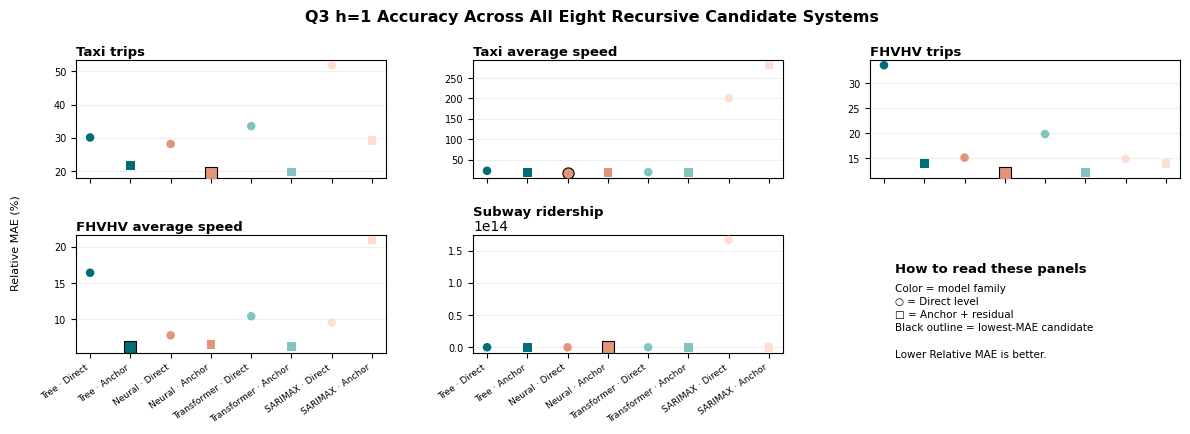

123

In [121]:
# ---------------------------------------------------------------------
# 5.1.1.6B — Compare overall Q3 accuracy and reliability
# ---------------------------------------------------------------------

q3_score_source_df = pd.read_parquet(
    H1_Q3_TRAJECTORY_PATH,
    columns=[
        "h1_candidate_id", "family", "formulation", "metric",
        "target_observed_value", "system_prediction",
        "advanced_prediction_available", "benchmark_prediction",
        "benchmark_prediction_available", "benchmark_fallback_used",
        "system_prediction_available",
    ],
)

for column in ["target_observed_value", "system_prediction", "benchmark_prediction"]:
    q3_score_source_df[column] = pd.to_numeric(
        q3_score_source_df[column],
        errors="coerce",
    )

for column in [
    "advanced_prediction_available", "benchmark_prediction_available",
    "benchmark_fallback_used", "system_prediction_available",
]:
    q3_score_source_df[column] = q3_score_source_df[column].fillna(False).astype(bool)


# 6A already proved that hidden factual support is common across candidates.
q3_score_source_df = q3_score_source_df.loc[
    q3_score_source_df["target_observed_value"].notna()
].copy()

q3_score_source_df["absolute_error"] = (
    q3_score_source_df["system_prediction"]
    - q3_score_source_df["target_observed_value"]
).abs()

q3_score_source_df["signed_error"] = (
    q3_score_source_df["system_prediction"]
    - q3_score_source_df["target_observed_value"]
)

q3_score_source_df["benchmark_scored"] = (
    q3_score_source_df["benchmark_prediction_available"]
    & q3_score_source_df["benchmark_prediction"].notna()
)

q3_score_source_df["benchmark_absolute_error"] = (
    q3_score_source_df["benchmark_prediction"]
    - q3_score_source_df["target_observed_value"]
).abs()


score_rows = []

for keys, frame in q3_score_source_df.groupby(
    ["metric", "family", "formulation", "h1_candidate_id"],
    observed=True,
    sort=False,
):
    metric, family, formulation, candidate_id = keys

    denominator = frame["target_observed_value"].abs().sum()
    relative_mae_pct = (
        100.0 * frame["absolute_error"].sum() / denominator
        if denominator > 0
        else np.nan
    )

    benchmark_frame = frame.loc[frame["benchmark_scored"]]

    if len(benchmark_frame):
        system_mae_on_benchmark = benchmark_frame["absolute_error"].mean()
        benchmark_mae = benchmark_frame["benchmark_absolute_error"].mean()

        benchmark_skill_pct = (
            100.0 * (benchmark_mae - system_mae_on_benchmark) / benchmark_mae
            if benchmark_mae > 0
            else np.nan
        )
    else:
        system_mae_on_benchmark = np.nan
        benchmark_mae = np.nan
        benchmark_skill_pct = np.nan

    score_rows.append({
        "selection_contract_id": H1_Q3_SELECTION_CONTRACT_ID,
        "metric": metric,
        "family": family,
        "formulation": formulation,
        "h1_candidate_id": candidate_id,
        "evaluation_rows": len(frame),
        "system_mae": float(frame["absolute_error"].mean()),
        "relative_mae_pct": float(relative_mae_pct),
        "signed_bias": float(frame["signed_error"].mean()),
        "benchmark_rows": len(benchmark_frame),
        "benchmark_coverage_pct": 100.0 * len(benchmark_frame) / len(frame),
        "system_mae_on_benchmark_support": float(system_mae_on_benchmark),
        "benchmark_mae": float(benchmark_mae),
        "benchmark_skill_pct": float(benchmark_skill_pct),
        "advanced_coverage_pct": 100.0 * frame["advanced_prediction_available"].mean(),
        "fallback_rate_pct": 100.0 * frame["benchmark_fallback_used"].mean(),
        "resolved_coverage_pct": 100.0 * frame["system_prediction_available"].mean(),
    })


h1_q3_scorecard_df = pd.DataFrame(score_rows)

expected_rows = len(FORECAST_TARGETS) * H1_Q3_CANDIDATES_PER_TARGET

if len(h1_q3_scorecard_df) != expected_rows:
    raise RuntimeError(
        f"Q3 scorecard contains {len(h1_q3_scorecard_df)} candidates; "
        f"expected {expected_rows}."
    )

rows_per_target = (
    h1_q3_scorecard_df
    .groupby("metric", observed=True)["evaluation_rows"]
    .nunique()
)

if not rows_per_target.eq(1).all():
    raise RuntimeError(
        "Candidate scorecards no longer share common Q3 support within a target."
    )


best_mae = (
    h1_q3_scorecard_df
    .groupby("metric", observed=True)["system_mae"]
    .transform("min")
)

h1_q3_scorecard_df["point_estimate_leader"] = np.isclose(
    h1_q3_scorecard_df["system_mae"],
    best_mae,
    rtol=1e-12,
    atol=1e-12,
)

h1_q3_scorecard_df["candidate_label"] = (
    h1_q3_scorecard_df["family"].map(H1_FAMILY_SHORT_LABELS)
    + " · "
    + h1_q3_scorecard_df["formulation"].map(H1_FORMULATION_SHORT_LABELS)
)

atomic_write_parquet(h1_q3_scorecard_df, H1_Q3_SCORECARD_PATH)


leader_display_df = (
    h1_q3_scorecard_df.loc[h1_q3_scorecard_df["point_estimate_leader"]]
    .assign(Target=lambda frame: frame["metric"].map(TARGET_LABELS))
    [[
        "Target", "candidate_label", "system_mae", "relative_mae_pct",
        "signed_bias", "benchmark_skill_pct", "advanced_coverage_pct",
        "fallback_rate_pct",
    ]]
    .rename(columns={
        "candidate_label": "Lowest-MAE candidate",
        "system_mae": "MAE",
        "relative_mae_pct": "Relative MAE (%)",
        "signed_bias": "Bias",
        "benchmark_skill_pct": "Benchmark skill (%)",
        "advanced_coverage_pct": "Advanced coverage (%)",
        "fallback_rate_pct": "Fallback (%)",
    })
    .sort_values("Target")
)

display(leader_display_df.round(3))


# ---------------------------------------------------------------------
# 5.1.1.6B — Visualize Q3 accuracy across all eight candidate systems
#
# Five targets use a 2 × 3 small-multiple grid. The sixth tile explains
# the visual encoding instead of repeating a legend inside every panel.
# ---------------------------------------------------------------------

candidate_order = [
    f"{H1_FAMILY_SHORT_LABELS[family]} · "
    f"{H1_FORMULATION_SHORT_LABELS[formulation]}"
    for family in H1_EXECUTION_ORDER
    for formulation in H1_FORMULATIONS
]

family_colors = {
    family: BRAND_COLOR_SEQUENCE[index]
    for index, family in enumerate(H1_EXECUTION_ORDER)
}

formulation_markers = {
    "direct_level": "o",
    "anchor_residual": "s",
}


fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 4.8),
    sharex=True,
)

axes = axes.ravel()
metric_axes = axes[:5]
key_ax = axes[5]


for ax, metric in zip(metric_axes, FORECAST_TARGETS):
    metric_df = h1_q3_scorecard_df.loc[
        h1_q3_scorecard_df["metric"].eq(metric)
    ].copy()

    metric_df["candidate_label"] = pd.Categorical(
        metric_df["candidate_label"],
        categories=candidate_order,
        ordered=True,
    )

    metric_df = metric_df.sort_values("candidate_label")

    for row in metric_df.itertuples(index=False):
        x = candidate_order.index(str(row.candidate_label))

        # Family is encoded by color; formulation is encoded by marker shape.
        # The larger black-edged point is the lowest-MAE candidate for that target.
        ax.scatter(
            x,
            row.relative_mae_pct,
            color=family_colors[row.family],
            marker=formulation_markers[row.formulation],
            s=65 if row.point_estimate_leader else 38,
            edgecolor="black" if row.point_estimate_leader else "none",
            linewidth=0.8,
            zorder=3,
        )

    ax.set_title(
        TARGET_LABELS[metric],
        loc="left",
        fontsize=9.5,
        fontweight="bold",
        pad=3,
    )

    ax.tick_params(axis="y", labelsize=7)
    ax.grid(axis="y", alpha=0.2)


# Every panel uses the same eight candidate positions. Show their labels only
# on the populated bottom row so the compact figure remains readable.
for ax in metric_axes:
    ax.set_xticks(range(len(candidate_order)))
    ax.set_xticklabels(candidate_order, rotation=35, ha="right", fontsize=6.5)
    ax.tick_params(axis="x", labelbottom=False)

for ax in metric_axes[3:]:
    ax.tick_params(axis="x", labelbottom=True)


# The spare panel acts as a compact reading key rather than another legend.
key_ax.axis("off")

key_ax.text(
    0.08,
    0.76,
    "How to read these panels",
    transform=key_ax.transAxes,
    fontsize=9.5,
    fontweight="bold",
    va="top",
)

key_ax.text(
    0.08,
    0.59,
    "Color = model family\n"
    "○ = Direct level\n"
    "□ = Anchor + residual\n"
    "Black outline = lowest-MAE candidate\n\n"
    "Lower Relative MAE is better.",
    transform=key_ax.transAxes,
    fontsize=7.5,
    va="top",
    linespacing=1.4,
)


fig.suptitle(
    "Q3 h=1 Accuracy Across All Eight Recursive Candidate Systems",
    fontsize=11.5,
    fontweight="bold",
    y=0.985,
)

fig.supylabel(
    "Relative MAE (%)",
    fontsize=8,
    x=0.015,
)

fig.subplots_adjust(
    left=0.07,
    right=0.99,
    bottom=0.27,
    top=0.88,
    hspace=0.48,
    wspace=0.28,
)

plt.show()


del q3_score_source_df
gc.collect()

**Findings.** The first-pass numerical leaders are Neural + Anchor for Taxi trips, FHVHV trips, and Subway ridership; Neural + Direct for Taxi average speed; and Tree + Anchor for FHVHV average speed.

Relative MAE ranges from 6.1% for FHVHV speed to 19.5% for Taxi trips. All five leaders improve on their synthetic-history benchmark, make every scored prediction with the advanced model, and require no fallback. These are encouraging point estimates, but they are not yet final selections because average Q3 accuracy does not tell us whether performance deteriorates as synthetic history accumulates.

**5.1.1.6C — Check whether forecast quality holds up as synthetic history grows**

A three-month average can hide an important recursive failure. A candidate might perform well near July 1, when most of its recent history is still factual, and then deteriorate after weeks of feeding its own predictions back into the next forecast.

This block first divides Q3 into early, middle, and late recursion and compares error and bias across those stages. It then shows Relative MAE in roughly five-day windows so gradual drift is visible rather than being averaged away. A rising curve does not automatically disqualify a model, but strong late deterioration needs to be understood before that engine can control production state.

======================================================================

,Target,Lowest-MAE candidate,Early Relative MAE (%),Middle Relative MAE (%),Late Relative MAE (%),Late − early (pp),Late bias
6,FHVHV average speed,Tree · Anchor,6.293,5.548,6.587,0.294,-0.051
10,FHVHV trips,Neural · Anchor,12.596,10.948,12.715,0.120,24.431
18,Subway ridership,Neural · Anchor,12.799,9.792,14.999,2.200,-396.399
27,Taxi average speed,Neural · Direct,18.367,17.408,18.646,0.279,0.747
34,Taxi trips,Neural · Anchor,20.357,16.627,21.175,0.818,-12.616


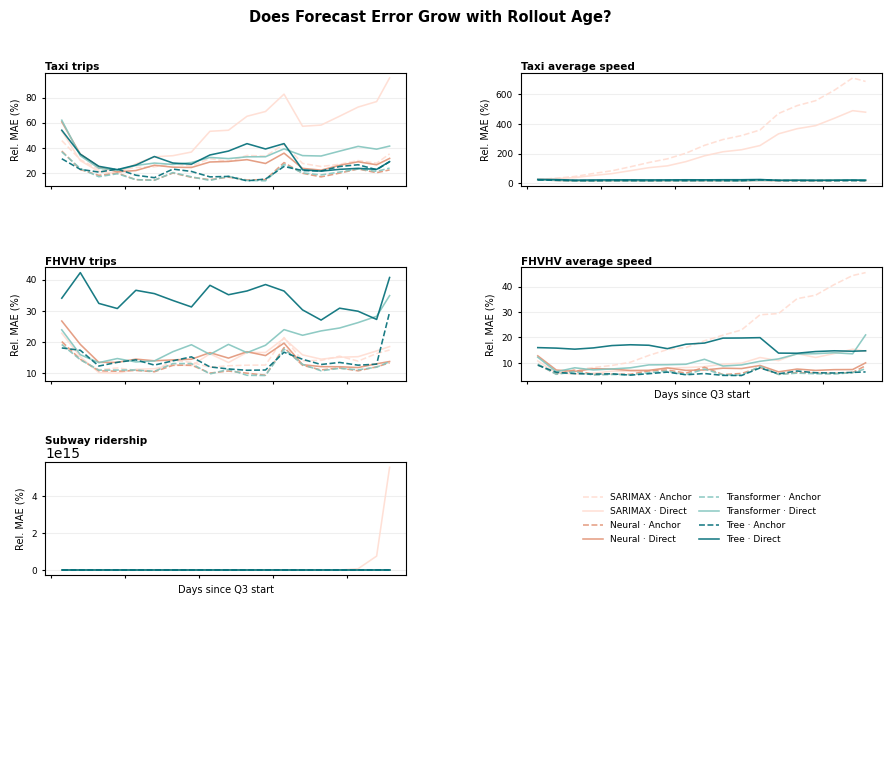

150

In [123]:
# ---------------------------------------------------------------------
# 5.1.1.6C — Check whether accuracy deteriorates with rollout age
# ---------------------------------------------------------------------

h1_q3_scorecard_df = pd.read_parquet(H1_Q3_SCORECARD_PATH)

q3_rollout_source_df = pd.read_parquet(
    H1_Q3_TRAJECTORY_PATH,
    columns=[
        "h1_candidate_id", "family", "formulation", "metric",
        "rollout_step", "rollout_day", "target_observed_value",
        "system_prediction",
    ],
)

for column in ["target_observed_value", "system_prediction"]:
    q3_rollout_source_df[column] = pd.to_numeric(
        q3_rollout_source_df[column],
        errors="coerce",
    )

q3_rollout_source_df = q3_rollout_source_df.loc[
    q3_rollout_source_df["target_observed_value"].notna()
].copy()

q3_rollout_source_df["absolute_error"] = (
    q3_rollout_source_df["system_prediction"]
    - q3_rollout_source_df["target_observed_value"]
).abs()

q3_rollout_source_df["signed_error"] = (
    q3_rollout_source_df["system_prediction"]
    - q3_rollout_source_df["target_observed_value"]
)


# Early / middle / late exposes whether recursive accuracy changes as synthetic
# history progressively replaces factual history.
max_rollout_step = int(q3_rollout_source_df["rollout_step"].max())
early_end = int(np.ceil(max_rollout_step / 3))
middle_end = int(np.ceil(2 * max_rollout_step / 3))

q3_rollout_source_df["rollout_stage"] = np.select(
    [
        q3_rollout_source_df["rollout_step"].le(early_end),
        q3_rollout_source_df["rollout_step"].le(middle_end),
    ],
    ["Early", "Middle"],
    default="Late",
)


stage_rows = []

for keys, frame in q3_rollout_source_df.groupby(
    ["metric", "family", "formulation", "h1_candidate_id", "rollout_stage"],
    observed=True,
    sort=False,
):
    metric, family, formulation, candidate_id, rollout_stage = keys

    denominator = frame["target_observed_value"].abs().sum()
    relative_mae_pct = (
        100.0 * frame["absolute_error"].sum() / denominator
        if denominator > 0
        else np.nan
    )

    stage_rows.append({
        "selection_contract_id": H1_Q3_SELECTION_CONTRACT_ID,
        "metric": metric,
        "family": family,
        "formulation": formulation,
        "h1_candidate_id": candidate_id,
        "rollout_stage": rollout_stage,
        "evaluation_rows": len(frame),
        "system_mae": float(frame["absolute_error"].mean()),
        "relative_mae_pct": float(relative_mae_pct),
        "signed_bias": float(frame["signed_error"].mean()),
    })


h1_q3_rollout_stage_df = pd.DataFrame(stage_rows)

rollout_stage_wide_df = h1_q3_rollout_stage_df.pivot(
    index=["metric", "family", "formulation", "h1_candidate_id"],
    columns="rollout_stage",
    values=["relative_mae_pct", "signed_bias"],
)

rollout_stage_wide_df.columns = [
    f"{measure}_{stage.lower()}"
    for measure, stage in rollout_stage_wide_df.columns
]

rollout_stage_wide_df = rollout_stage_wide_df.reset_index()

rollout_stage_wide_df["late_minus_early_relative_mae_pp"] = (
    rollout_stage_wide_df["relative_mae_pct_late"]
    - rollout_stage_wide_df["relative_mae_pct_early"]
)

rollout_stage_wide_df["selection_contract_id"] = H1_Q3_SELECTION_CONTRACT_ID

h1_q3_rollout_health_df = rollout_stage_wide_df.merge(
    h1_q3_scorecard_df[
        ["h1_candidate_id", "candidate_label", "point_estimate_leader"]
    ],
    on="h1_candidate_id",
    how="left",
    validate="one_to_one",
)

atomic_write_parquet(
    h1_q3_rollout_health_df,
    H1_Q3_ROLLOUT_HEALTH_PATH,
)


leader_rollout_display_df = (
    h1_q3_rollout_health_df.loc[h1_q3_rollout_health_df["point_estimate_leader"]]
    .assign(Target=lambda frame: frame["metric"].map(TARGET_LABELS))
    [[
        "Target", "candidate_label", "relative_mae_pct_early",
        "relative_mae_pct_middle", "relative_mae_pct_late",
        "late_minus_early_relative_mae_pp", "signed_bias_late",
    ]]
    .rename(columns={
        "candidate_label": "Lowest-MAE candidate",
        "relative_mae_pct_early": "Early Relative MAE (%)",
        "relative_mae_pct_middle": "Middle Relative MAE (%)",
        "relative_mae_pct_late": "Late Relative MAE (%)",
        "late_minus_early_relative_mae_pp": "Late − early (pp)",
        "signed_bias_late": "Late bias",
    })
    .sort_values("Target")
)

display(leader_rollout_display_df.round(3))


# Twenty-five Dayparts are roughly five calendar days: enough smoothing to
# reveal drift without hiding when in the recursive episode it appears.
q3_rollout_source_df["rollout_block"] = (
    (q3_rollout_source_df["rollout_step"].astype(int) - 1) // 25
) + 1

curve_rows = []

for keys, frame in q3_rollout_source_df.groupby(
    ["metric", "family", "formulation", "h1_candidate_id", "rollout_block"],
    observed=True,
    sort=False,
):
    metric, family, formulation, candidate_id, rollout_block = keys

    denominator = frame["target_observed_value"].abs().sum()
    relative_mae_pct = (
        100.0 * frame["absolute_error"].sum() / denominator
        if denominator > 0
        else np.nan
    )

    curve_rows.append({
        "selection_contract_id": H1_Q3_SELECTION_CONTRACT_ID,
        "metric": metric,
        "family": family,
        "formulation": formulation,
        "h1_candidate_id": candidate_id,
        "rollout_block": int(rollout_block),
        "rollout_day_mid": float(frame["rollout_day"].mean()),
        "relative_mae_pct": float(relative_mae_pct),
    })


h1_q3_rollout_curve_df = pd.DataFrame(curve_rows)

atomic_write_parquet(
    h1_q3_rollout_curve_df,
    H1_Q3_ROLLOUT_CURVE_PATH,
)


# ---------------------------------------------------------------------
# Compact 4 × 2 rollout-age view for 640 × 480 rendering
#
# Five panels carry the five mobility targets. A sixth panel is reserved for
# the shared legend so labels do not compete with data inside the small plots.
# The final two grid cells stay empty rather than stretching the five metrics
# into an uneven layout.
# ---------------------------------------------------------------------

family_colors = {
    family: BRAND_COLOR_SEQUENCE[index]
    for index, family in enumerate(H1_EXECUTION_ORDER)
}

formulation_styles = {
    "direct_level": "-",
    "anchor_residual": "--",
}

fig, axes = plt.subplots(
    4,
    2,
    figsize=(9.4, 8.4),
    sharex=True,
)

axes = axes.ravel()
metric_axes = axes[:len(FORECAST_TARGETS)]
legend_ax = axes[5]


for ax, metric in zip(metric_axes, FORECAST_TARGETS):
    metric_df = h1_q3_rollout_curve_df.loc[
        h1_q3_rollout_curve_df["metric"].eq(metric)
    ]

    for (family, formulation), line_df in metric_df.groupby(
        ["family", "formulation"],
        observed=True,
        sort=False,
    ):
        line_df = line_df.sort_values("rollout_day_mid")

        label = (
            f"{H1_FAMILY_SHORT_LABELS[family]} · "
            f"{H1_FORMULATION_SHORT_LABELS[formulation]}"
        )

        ax.plot(
            line_df["rollout_day_mid"],
            line_df["relative_mae_pct"],
            color=family_colors[family],
            linestyle=formulation_styles[formulation],
            linewidth=1.15,
            alpha=0.9,
            label=label,
        )

    # Small multiples need compact titles and labels to stay readable at
    # 640 × 480 without allowing text to crowd the neighboring panels.
    ax.set_title(
        TARGET_LABELS[metric],
        loc="left",
        fontsize=7.5,
        fontweight="bold",
        pad=2,
    )

    ax.set_ylabel("Rel. MAE (%)", fontsize=7)
    ax.tick_params(axis="both", labelsize=6.5, length=2.5)
    ax.grid(axis="y", alpha=0.2)


# Only the bottom-most populated panels need the shared time-axis wording.
for ax in metric_axes[-2:]:
    ax.set_xlabel("Days since Q3 start", fontsize=7)


# Use a dedicated grid cell for the shared legend. This prevents the legend
# from shrinking the plotting region or colliding with the figure title.
handles, labels = metric_axes[0].get_legend_handles_labels()

legend_ax.axis("off")
legend_ax.legend(
    handles,
    labels,
    loc="center",
    frameon=False,
    fontsize=6.5,
    ncol=2,
    handlelength=2.2,
    columnspacing=0.8,
    labelspacing=0.55,
)


# The final two cells are intentionally blank; preserving the regular 4 × 2
# grid is cleaner than resizing or stretching individual target panels.
for ax in axes[6:]:
    ax.axis("off")


# A shorter title communicates the same question while leaving enough vertical
# room for the first row of subplot titles.
fig.suptitle(
    "Does Forecast Error Grow with Rollout Age?",
    fontsize=10.5,
    fontweight="bold",
    y=0.985,
)

fig.subplots_adjust(
    left=0.09,
    right=0.98,
    bottom=0.08,
    top=0.91,
    hspace=0.72,
    wspace=0.32,
)

plt.show()

del q3_rollout_source_df
gc.collect()

**Findings.** The five numerical leaders remain broadly stable as the recursive rollout ages. FHVHV trips, FHVHV speed, and Taxi speed finish Q3 within about 0.3 percentage points of their early-period Relative MAE. Taxi trips deteriorates more modestly, from 20.4% early to 21.2% late.

Subway shows the largest late-period change: Relative MAE rises from 12.8% early to 15.0% late. That deserves continued attention, but the selected Neural + Anchor path does not show the explosive recursive failure seen in weaker Subway candidates.

**5.1.1.6D — Look directly at the recursive trajectories**

Error summaries can tell us that a forecast is wrong without showing *how* it became wrong. A recursive path can drift steadily, lose normal day-to-day variation, or settle toward an artificial level even when one average score still looks competitive.

This block therefore plots real mobility immediately before the July 1 Q3 boundary, the hidden factual Q3 path after that boundary, and the three lowest-MAE synthetic candidates for each target. Counts and ridership are summed across the supported system, while Taxi and FHVHV speeds use trip volume as weights.

The accompanying table adds three descriptive checks: whether the candidate keeps roughly the same average level as the hidden actual path, how much daily variation it retains, and how closely its daily shape moves with the factual series. These measures are diagnostics rather than automatic pass/fail thresholds. Their job is to make collapse, flattening, persistent drift, or other unhealthy recursive behavior visible before any h=1 engine is selected.

======================================================================

,Target,Candidate,Q3 Relative MAE (%),Mean level vs actual (%),Daily variation vs actual (%),Daily shape correlation
33,FHVHV average speed,Tree · Anchor,6.138,101.060,90.291,0.802
23,FHVHV average speed,Transformer · Anchor,6.247,100.177,111.120,0.785
13,FHVHV average speed,Neural · Anchor,6.536,101.545,117.538,0.781
12,FHVHV trips,Neural · Anchor,12.099,101.861,91.437,0.852
22,FHVHV trips,Transformer · Anchor,12.113,100.220,91.325,0.867
2,FHVHV trips,SARIMAX · Anchor,13.921,101.410,87.307,0.796
14,Subway ridership,Neural · Anchor,12.651,95.128,94.111,0.913
24,Subway ridership,Transformer · Anchor,13.212,93.684,89.295,0.913
34,Subway ridership,Tree · Anchor,13.599,94.781,83.212,0.922
16,Taxi average speed,Neural · Direct,18.134,101.969,79.384,0.694


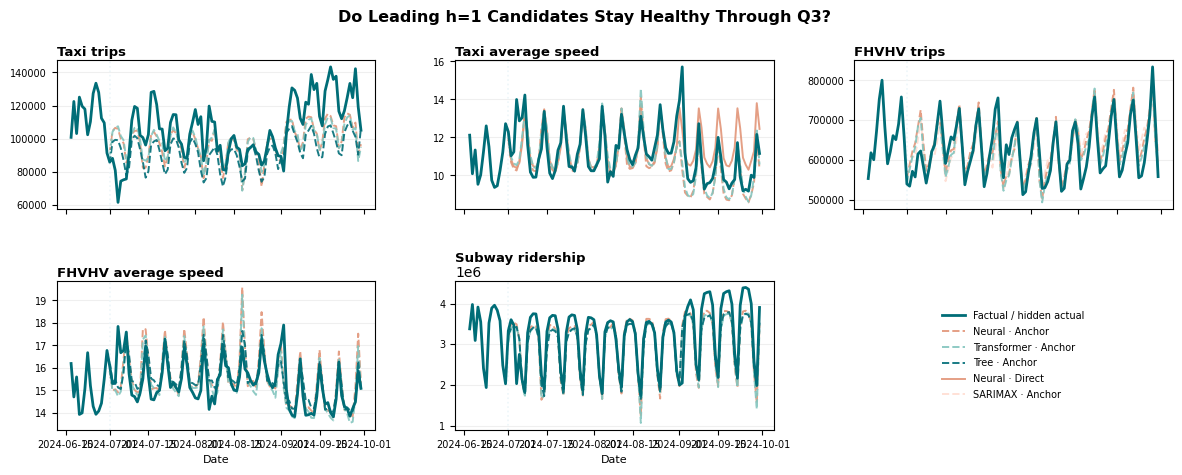

PASS — Q3 trajectory-health evidence is ready for selection review | period=2024-07-01 to 2024-09-30


In [125]:
# ---------------------------------------------------------------------
# 5.1.1.6D — Visually inspect recursive trajectory health
# ---------------------------------------------------------------------

h1_q3_scorecard_df = pd.read_parquet(H1_Q3_SCORECARD_PATH)

TRAJECTORY_CONTEXT_DAYS = 14

SPEED_WEIGHT_METRICS = {
    "taxi_avg_trip_speed": "taxi_trip_count",
    "fhvhv_avg_trip_speed": "fhvhv_trip_count",
}


def aggregate_daily_mobility(
    frame,
    metric,
    value_column,
    *,
    require_factual_support=False,
):
    """
    Aggregate one mobility target to a daily systemwide trajectory.

    Count targets add across zones and Dayparts. Speed targets use the
    corresponding trip-count channel as an activity weight so busy and quiet
    locations do not contribute equally to the systemwide average.
    """
    value_rows = frame.loc[frame["metric"].eq(metric)].copy()

    # Candidate trajectories are compared only where hidden factual support
    # exists, keeping the visual health check on observable Q3 rows.
    if require_factual_support:
        value_rows = value_rows.loc[
            value_rows["target_observed_value"].notna()
        ].copy()

    value_rows[value_column] = pd.to_numeric(
        value_rows[value_column],
        errors="coerce",
    )

    value_rows = value_rows.loc[value_rows[value_column].notna()].copy()


    # Trips and ridership are additive across zones and Dayparts.
    if metric in COUNT_TARGETS:
        return (
            value_rows
            .groupby("target_date", as_index=False, observed=True)[value_column]
            .sum(min_count=1)
            .rename(columns={value_column: "value"})
        )


    # Speeds need activity weights so a quiet zone does not count as much as a
    # busy one in the systemwide daily average.
    weight_metric = SPEED_WEIGHT_METRICS[metric]

    join_columns = [
        "taxi_zone_id",
        "target_observation_sequence_id",
        "target_date",
    ]

    weight_rows = frame.loc[
        frame["metric"].eq(weight_metric)
    ].copy()

    if require_factual_support:
        weight_rows = weight_rows.loc[
            weight_rows["target_observed_value"].notna()
        ].copy()

    # Select the payload only after filtering. This avoids accidentally
    # creating duplicate target_observed_value columns for factual speeds.
    weight_rows = weight_rows[[*join_columns, value_column]].copy()

    weight_rows[value_column] = pd.to_numeric(
        weight_rows[value_column],
        errors="coerce",
    )

    weight_rows = weight_rows.rename(
        columns={value_column: "activity_weight"}
    )

    weighted = value_rows.merge(
        weight_rows[[*join_columns, "activity_weight"]],
        on=join_columns,
        how="inner",
        validate="one_to_one",
    )

    weighted = weighted.loc[
        weighted[value_column].notna()
        & weighted["activity_weight"].notna()
        & weighted["activity_weight"].gt(0)
    ].copy()

    weighted["weighted_value"] = (
        weighted[value_column] * weighted["activity_weight"]
    )

    daily = (
        weighted
        .groupby("target_date", as_index=False, observed=True)
        .agg(
            weighted_sum=("weighted_value", "sum"),
            weight_sum=("activity_weight", "sum"),
        )
    )

    daily["value"] = daily["weighted_sum"] / daily["weight_sum"]

    return daily[["target_date", "value"]]


# ---------------------------------------------------------------------
# Load the complete reconciled Q3 surface once.
# ---------------------------------------------------------------------

q3_trajectory_source_df = pd.read_parquet(
    H1_Q3_TRAJECTORY_PATH,
    columns=[
        "family", "formulation", "h1_candidate_id", "taxi_zone_id",
        "metric", "target_observation_sequence_id", "target_date",
        "target_observed_value", "system_prediction",
    ],
)

q3_trajectory_source_df["target_date"] = pd.to_datetime(
    q3_trajectory_source_df["target_date"]
).dt.normalize()

q3_start_date = q3_trajectory_source_df["target_date"].min()
q3_end_date = q3_trajectory_source_df["target_date"].max()


# Hidden factual Q3 outcomes are identical across all eight candidate systems,
# so one system is enough to construct the factual reference trajectory.
reference_actual_df = q3_trajectory_source_df.loc[
    q3_trajectory_source_df["family"].eq(H1_EXECUTION_ORDER[0])
    & q3_trajectory_source_df["formulation"].eq(H1_FORMULATIONS[0])
].copy()


q3_actual_daily_parts = []

for metric in FORECAST_TARGETS:
    daily = aggregate_daily_mobility(
        reference_actual_df,
        metric,
        "target_observed_value",
    )

    daily["metric"] = metric
    q3_actual_daily_parts.append(daily)

q3_actual_daily_df = pd.concat(
    q3_actual_daily_parts,
    ignore_index=True,
)


# ---------------------------------------------------------------------
# Aggregate every candidate once.
#
# The saved health table retains all 40 candidates. The chart later shows only
# the three lowest-MAE paths for each target so the figure stays interpretable.
# ---------------------------------------------------------------------

candidate_daily_parts = []

for (family, formulation), system_df in q3_trajectory_source_df.groupby(
    ["family", "formulation"],
    observed=True,
    sort=False,
):
    for metric in FORECAST_TARGETS:
        metric_rows = system_df.loc[system_df["metric"].eq(metric)]

        candidate_id = str(
            metric_rows["h1_candidate_id"].iloc[0]
        )

        daily = aggregate_daily_mobility(
            system_df,
            metric,
            "system_prediction",
            require_factual_support=True,
        )

        daily["metric"] = metric
        daily["family"] = family
        daily["formulation"] = formulation
        daily["h1_candidate_id"] = candidate_id

        candidate_daily_parts.append(daily)

q3_candidate_daily_df = pd.concat(
    candidate_daily_parts,
    ignore_index=True,
)


# ---------------------------------------------------------------------
# Add two factual weeks before Q3.
#
# Without this context, an immediate jump at the factual-to-synthetic boundary
# would sit against the left edge of the plot and be difficult to see.
# ---------------------------------------------------------------------

q3_first_target_id = int(
    q3_trajectory_source_df["target_observation_sequence_id"].min()
)

history_first_target_id = max(
    1,
    q3_first_target_id - TRAJECTORY_CONTEXT_DAYS * 5,
)

history_tail_df = pd.read_parquet(
    PRE_CP_HISTORICAL_FORECASTING_MATRIX_PATH,
    columns=[
        "forecast_sequence_id", "taxi_zone_id", "metric",
        "target_observation_sequence_id", "target_date",
        "target_observed_value",
    ],
    filters=[
        ("modeling_track", "==", CHAPTER5_MODELING_TRACK),
        ("horizon", "==", 1),
        ("target_observation_sequence_id", ">=", history_first_target_id),
        ("target_observation_sequence_id", "<", q3_first_target_id),
    ],
)

history_tail_df["target_date"] = pd.to_datetime(
    history_tail_df["target_date"]
).dt.normalize()


history_actual_daily_parts = []

for metric in FORECAST_TARGETS:
    daily = aggregate_daily_mobility(
        history_tail_df,
        metric,
        "target_observed_value",
    )

    daily["metric"] = metric
    history_actual_daily_parts.append(daily)

history_actual_daily_df = pd.concat(
    history_actual_daily_parts,
    ignore_index=True,
)


# ---------------------------------------------------------------------
# Quantify trajectory health.
#
# These diagnostics describe level, retained day-to-day variation, and shape.
# They complement forecast error; they do not create another weighted score.
# ---------------------------------------------------------------------

health_rows = []

for candidate_id, candidate_df in q3_candidate_daily_df.groupby(
    "h1_candidate_id",
    observed=True,
    sort=False,
):
    metric = str(candidate_df["metric"].iloc[0])

    actual_df = (
        q3_actual_daily_df.loc[
            q3_actual_daily_df["metric"].eq(metric),
            ["target_date", "value"],
        ]
        .rename(columns={"value": "actual_value"})
    )

    paired = (
        candidate_df[["target_date", "value"]]
        .merge(
            actual_df,
            on="target_date",
            how="inner",
            validate="one_to_one",
        )
        .dropna()
    )

    predicted = paired["value"].to_numpy(dtype=float)
    actual = paired["actual_value"].to_numpy(dtype=float)

    predicted_mean = float(np.mean(predicted))
    actual_mean = float(np.mean(actual))

    predicted_std = float(np.std(predicted, ddof=0))
    actual_std = float(np.std(actual, ddof=0))

    level_ratio_pct = (
        100.0 * predicted_mean / actual_mean
        if actual_mean != 0
        else np.nan
    )

    variability_ratio_pct = (
        100.0 * predicted_std / actual_std
        if actual_std > 0
        else np.nan
    )

    daily_correlation = (
        float(np.corrcoef(predicted, actual)[0, 1])
        if len(paired) > 1 and predicted_std > 0 and actual_std > 0
        else np.nan
    )

    health_rows.append({
        "selection_contract_id": H1_Q3_SELECTION_CONTRACT_ID,
        "metric": metric,
        "family": str(candidate_df["family"].iloc[0]),
        "formulation": str(candidate_df["formulation"].iloc[0]),
        "h1_candidate_id": candidate_id,
        "daily_pairs": len(paired),
        "mean_level_vs_actual_pct": float(level_ratio_pct),
        "daily_variability_vs_actual_pct": float(variability_ratio_pct),
        "daily_shape_correlation": daily_correlation,
    })


h1_q3_trajectory_health_df = (
    pd.DataFrame(health_rows)
    .merge(
        h1_q3_scorecard_df[
            [
                "h1_candidate_id",
                "candidate_label",
                "system_mae",
                "relative_mae_pct",
            ]
        ],
        on="h1_candidate_id",
        how="left",
        validate="one_to_one",
    )
)

atomic_write_parquet(
    h1_q3_trajectory_health_df,
    H1_Q3_TRAJECTORY_HEALTH_PATH,
)


# Show trajectory diagnostics only for the three lowest-MAE candidates per
# target. The complete 40-candidate health table remains on disk.
top_three_df = (
    h1_q3_scorecard_df
    .sort_values(["metric", "system_mae", "h1_candidate_id"])
    .groupby("metric", observed=True, sort=False)
    .head(3)
    .copy()
)

top_three_ids = set(
    top_three_df["h1_candidate_id"].astype(str)
)

trajectory_health_display_df = (
    h1_q3_trajectory_health_df.loc[
        h1_q3_trajectory_health_df["h1_candidate_id"]
        .astype(str)
        .isin(top_three_ids)
    ]
    .assign(Target=lambda frame: frame["metric"].map(TARGET_LABELS))
    [
        [
            "Target", "candidate_label", "relative_mae_pct",
            "mean_level_vs_actual_pct",
            "daily_variability_vs_actual_pct",
            "daily_shape_correlation",
        ]
    ]
    .rename(columns={
        "candidate_label": "Candidate",
        "relative_mae_pct": "Q3 Relative MAE (%)",
        "mean_level_vs_actual_pct": "Mean level vs actual (%)",
        "daily_variability_vs_actual_pct": "Daily variation vs actual (%)",
        "daily_shape_correlation": "Daily shape correlation",
    })
    .sort_values(["Target", "Q3 Relative MAE (%)"])
)

display(trajectory_health_display_df.round(3))


# ---------------------------------------------------------------------
# Plot the leading-candidate daily trajectories in a 2 × 3 grid.
# ---------------------------------------------------------------------

family_colors = {
    family: BRAND_COLOR_SEQUENCE[index]
    for index, family in enumerate(H1_EXECUTION_ORDER)
}

formulation_styles = {
    "direct_level": "-",
    "anchor_residual": "--",
}


fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 4.8),
    sharex=True,
)

axes = axes.ravel()
metric_axes = axes[:5]
legend_ax = axes[5]

legend_handles = {}


for ax, metric in zip(metric_axes, FORECAST_TARGETS):
    historical = history_actual_daily_df.loc[
        history_actual_daily_df["metric"].eq(metric)
    ].sort_values("target_date")

    hidden_actual = q3_actual_daily_df.loc[
        q3_actual_daily_df["metric"].eq(metric)
    ].sort_values("target_date")


    # Join the factual context and hidden Q3 actuals column-by-column. This
    # preserves one continuous factual path across the synthetic boundary.
    factual_path = pd.DataFrame({
        "target_date": np.concatenate([
            historical["target_date"].to_numpy(),
            hidden_actual["target_date"].to_numpy(),
        ]),
        "value": np.concatenate([
            historical["value"].to_numpy(dtype=float),
            hidden_actual["value"].to_numpy(dtype=float),
        ]),
    })

    factual_path = (
        factual_path
        .sort_values("target_date")
        .reset_index(drop=True)
    )


    factual_line, = ax.plot(
        factual_path["target_date"],
        factual_path["value"],
        color=BRAND_COLORS["dark_teal"],
        linewidth=2.0,
        label="Factual / hidden actual",
        zorder=4,
    )

    legend_handles.setdefault(
        "Factual / hidden actual",
        factual_line,
    )


    top_metric_ids = set(
        top_three_df.loc[
            top_three_df["metric"].eq(metric),
            "h1_candidate_id",
        ].astype(str)
    )

    candidate_plot_df = q3_candidate_daily_df.loc[
        q3_candidate_daily_df["metric"].eq(metric)
        & q3_candidate_daily_df["h1_candidate_id"]
        .astype(str)
        .isin(top_metric_ids)
    ]


    for candidate_id, line_df in candidate_plot_df.groupby(
        "h1_candidate_id",
        observed=True,
        sort=False,
    ):
        line_df = line_df.sort_values("target_date")

        family = str(line_df["family"].iloc[0])
        formulation = str(line_df["formulation"].iloc[0])

        line_label = (
            f"{H1_FAMILY_SHORT_LABELS[family]} · "
            f"{H1_FORMULATION_SHORT_LABELS[formulation]}"
        )

        candidate_line, = ax.plot(
            line_df["target_date"],
            line_df["value"],
            color=family_colors[family],
            linestyle=formulation_styles[formulation],
            linewidth=1.4,
            alpha=0.9,
            label=line_label,
        )

        legend_handles.setdefault(
            line_label,
            candidate_line,
        )


    # The dotted line is the exact point where factual mobility stops feeding
    # the recursive system and synthetic h=1 history begins.
    ax.axvline(
        q3_start_date,
        color=BRAND_COLOR_SEQUENCE[-1],
        linestyle=":",
        linewidth=1.2,
    )

    ax.set_title(
        TARGET_LABELS[metric],
        loc="left",
        fontsize=9.5,
        fontweight="bold",
        pad=3,
    )

    ax.tick_params(axis="both", labelsize=7)
    ax.grid(axis="y", alpha=0.2)


for ax in metric_axes[3:]:
    ax.set_xlabel("Date", fontsize=8)


# The sixth tile carries one shared legend so no data panel sacrifices space
# to repeated labels.
legend_ax.axis("off")

legend_ax.legend(
    list(legend_handles.values()),
    list(legend_handles.keys()),
    loc="center",
    frameon=False,
    fontsize=7,
    ncol=1,
    handlelength=2.4,
    labelspacing=0.6,
)


fig.suptitle(
    "Do Leading h=1 Candidates Stay Healthy Through Q3?",
    fontsize=11.5,
    fontweight="bold",
    y=0.985,
)

fig.subplots_adjust(
    left=0.06,
    right=0.99,
    bottom=0.11,
    top=0.88,
    hspace=0.48,
    wspace=0.25,
)

plt.show()


del q3_trajectory_source_df, reference_actual_df, history_tail_df
gc.collect()

print(
    "PASS — Q3 trajectory-health evidence is ready for selection review | "
    f"period={q3_start_date.date()} to {q3_end_date.date()}",
    flush=True,
)

**Findings.** The leading trajectories preserve the main daily movement patterns rather than collapsing into flat or obviously artificial paths. FHVHV trips, FHVHV speed, and Subway track the hidden Q3 shape especially well, with daily-shape correlations of roughly 0.80–0.91.

Taxi is harder. Taxi speed retains about 79% of the factual daily variation, while Taxi trips retains about 57%, and their daily-shape correlations are lower at 0.69 and 0.66. The plots show some smoothing and missed peaks, particularly for Taxi trips, but not the progressive collapse or constant-attractor behavior that motivated this rebuild.

**5.1.1.6E — Check whether candidate behavior changes across the city**

A citywide average can hide a model that works well in one part of New York and poorly in another. This block therefore repeats the Q3 accuracy comparison across three broad transportation geographies: the CBD itself, adjacent and gateway zones around the CBD, and the rest of the city.

This is a focused selection check rather than a full spatial validation. The goal is to see whether a promising h=1 candidate has a major geographic weakness that its overall MAE would hide. More detailed production geography diagnostics will come after the final no-CP simulation is built.

======================================================================

,Target,CBD,Adjacent / gateway,Non-CBD
0,FHVHV average speed,6.467,6.016,6.089
1,FHVHV trips,13.715,12.607,11.364
2,Subway ridership,11.374,12.991,13.626
3,Taxi average speed,12.932,18.227,21.051
4,Taxi trips,18.464,17.905,23.283


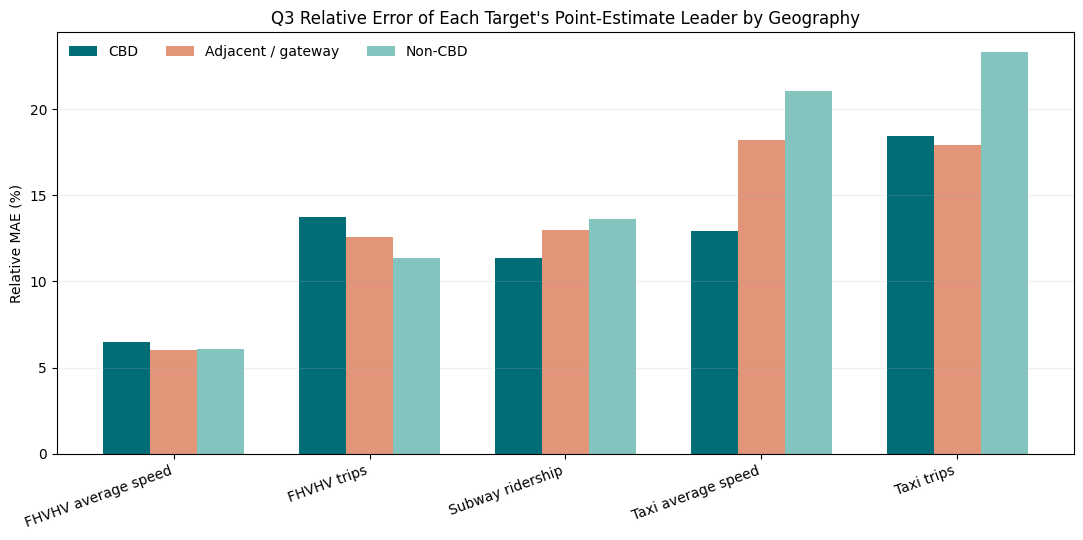

PASS — Q3 geography health is available for all candidate systems | rows=120


In [127]:
# ---------------------------------------------------------------------
# 5.1.1.6E — Check whether candidate behavior changes by geography
# ---------------------------------------------------------------------

H1_Q3_GEOGRAPHY_PATH = INTERMEDIATE_DIR / "recursive_h1_q3_geography_health.parquet"
H1_Q3_GEOGRAPHY_ORDER = ["CBD", "Adjacent / gateway", "Non-CBD"]

h1_q3_scorecard_df = pd.read_parquet(H1_Q3_SCORECARD_PATH)

# Geography is static. Reuse one already-legal Q3 origin rather than reopening
# the upstream geography contract or rebuilding zone tags from another source.
q3_first_target_id = int(
    recursive_episode_position_registry_df.loc[
        recursive_episode_position_registry_df["episode_id"].eq(H1_SELECTION_EPISODE_ID),
        "target_observation_sequence_id",
    ].min()
)

q3_geo_origin_df = load_h1_episode_origin_frame(
    H1_SELECTION_EPISODE_ID,
    q3_first_target_id,
)

q3_zone_geography_df = (
    q3_geo_origin_df[
        ["taxi_zone_id", "is_cbd_zone", "is_cbd_gateway_zone", "is_cbd_adjacent_zone"]
    ]
    .drop_duplicates("taxi_zone_id")
    .copy()
)

is_cbd = q3_zone_geography_df["is_cbd_zone"].fillna(0).astype(bool)
is_edge = (
    q3_zone_geography_df["is_cbd_gateway_zone"].fillna(0).astype(bool)
    | q3_zone_geography_df["is_cbd_adjacent_zone"].fillna(0).astype(bool)
)

q3_zone_geography_df["geography_group"] = np.select(
    [is_cbd, is_edge],
    ["CBD", "Adjacent / gateway"],
    default="Non-CBD",
)


q3_geo_source_df = pd.read_parquet(
    H1_Q3_TRAJECTORY_PATH,
    columns=[
        "h1_candidate_id", "family", "formulation", "metric", "taxi_zone_id",
        "target_observed_value", "system_prediction",
    ],
).merge(
    q3_zone_geography_df[["taxi_zone_id", "geography_group"]],
    on="taxi_zone_id",
    how="left",
    validate="many_to_one",
)

for column in ["target_observed_value", "system_prediction"]:
    q3_geo_source_df[column] = pd.to_numeric(q3_geo_source_df[column], errors="coerce")

q3_geo_source_df = q3_geo_source_df.loc[
    q3_geo_source_df["target_observed_value"].notna()
].copy()

q3_geo_source_df["absolute_error"] = (
    q3_geo_source_df["system_prediction"] - q3_geo_source_df["target_observed_value"]
).abs()

q3_geo_source_df["signed_error"] = (
    q3_geo_source_df["system_prediction"] - q3_geo_source_df["target_observed_value"]
)

q3_geo_source_df["absolute_actual"] = q3_geo_source_df["target_observed_value"].abs()


group_columns = [
    "metric", "family", "formulation", "h1_candidate_id", "geography_group",
]

h1_q3_geography_health_df = (
    q3_geo_source_df
    .groupby(group_columns, as_index=False, observed=True)
    .agg(
        evaluation_rows=("absolute_error", "size"),
        absolute_error_sum=("absolute_error", "sum"),
        signed_error_sum=("signed_error", "sum"),
        absolute_actual_sum=("absolute_actual", "sum"),
    )
)

h1_q3_geography_health_df["system_mae"] = (
    h1_q3_geography_health_df["absolute_error_sum"]
    / h1_q3_geography_health_df["evaluation_rows"]
)

h1_q3_geography_health_df["relative_mae_pct"] = (
    100.0
    * h1_q3_geography_health_df["absolute_error_sum"]
    / h1_q3_geography_health_df["absolute_actual_sum"].replace(0, np.nan)
)

h1_q3_geography_health_df["signed_bias"] = (
    h1_q3_geography_health_df["signed_error_sum"]
    / h1_q3_geography_health_df["evaluation_rows"]
)

h1_q3_geography_health_df["selection_contract_id"] = H1_Q3_SELECTION_CONTRACT_ID

atomic_write_parquet(h1_q3_geography_health_df, H1_Q3_GEOGRAPHY_PATH)


# Show the current numerical leader for each target. The full candidate table
# remains in the durable artifact for later selection review.
leader_ids = set(
    h1_q3_scorecard_df
    .sort_values(["metric", "system_mae", "h1_candidate_id"])
    .groupby("metric", observed=True, sort=False)
    .head(1)["h1_candidate_id"]
    .astype(str)
)

leader_geo_df = h1_q3_geography_health_df.loc[
    h1_q3_geography_health_df["h1_candidate_id"].astype(str).isin(leader_ids)
].copy()

leader_geo_table_df = (
    leader_geo_df
    .assign(Target=lambda frame: frame["metric"].map(TARGET_LABELS))
    .pivot(index="Target", columns="geography_group", values="relative_mae_pct")
    .reindex(columns=H1_Q3_GEOGRAPHY_ORDER)
    .reset_index()
)

leader_geo_table_df.columns.name = None

display(leader_geo_table_df.round(3))


fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(leader_geo_table_df))
width = 0.24

for index, geography_group in enumerate(H1_Q3_GEOGRAPHY_ORDER):
    ax.bar(
        x + (index - 1) * width,
        leader_geo_table_df[geography_group],
        width=width,
        label=geography_group,
        color=BRAND_COLOR_SEQUENCE[index],
    )

ax.set_title("Q3 Relative Error of Each Target's Point-Estimate Leader by Geography")
ax.set_ylabel("Relative MAE (%)")
ax.set_xticks(x)
ax.set_xticklabels(leader_geo_table_df["Target"], rotation=20, ha="right")
ax.legend(frameon=False, ncol=3)
ax.grid(axis="y", alpha=0.2)

fig.tight_layout()
plt.show()


del q3_geo_source_df
gc.collect()

print(
    "PASS — Q3 geography health is available for all candidate systems | "
    f"rows={len(h1_q3_geography_health_df):,}",
    flush=True,
)

**Findings.** None of the five point-estimate leaders depends on one narrow geography to look successful. FHVHV speed is particularly consistent, with Relative MAE of roughly 6.0–6.5% across all three geographic groups.

Taxi remains the most geographically uneven target. Taxi-trip Relative MAE rises from 18.5% in the CBD to 23.3% outside the CBD, while Taxi-speed error rises from 12.9% in the CBD to 21.1% outside it. These differences are worth preserving as later production diagnostics, but they do not reveal a geographic collapse of the selected candidates.

**5.1.1.6F — Check whether each synthetic mobility world still hangs together**

The five mobility channels do not evolve independently. Taxi, FHVHV, and Subway conditions can move together over time, while the forecasting system also rebuilds transportation-connected features from the synthetic geography around each zone.

This block checks both relationships without creating a new selection score. First, it compares the daily cross-mode relationships in each synthetic Q3 world with the hidden factual Q3 data. Second, it asks whether each target preserves the broad mobility pattern across canonical transportation geographies. Large departures would tell us that a candidate system may have reasonable individual errors while creating an internally distorted mobility world.

======================================================================

,System,Mean multimodal correlation gap,Largest multimodal correlation gap,Mean geography correlation,Weakest target geography correlation
3,Neural · Direct,0.042,0.150,0.985,0.971
4,Transformer · Anchor,0.076,0.169,0.991,0.963
2,Neural · Anchor,0.076,0.192,0.989,0.955
6,Tree · Anchor,0.095,0.188,0.992,0.974
5,Transformer · Direct,0.105,0.242,0.976,0.936
7,Tree · Direct,0.238,0.615,0.934,0.845
0,SARIMAX · Anchor,0.508,1.339,0.618,0.089
1,SARIMAX · Direct,0.669,1.390,0.393,0.012


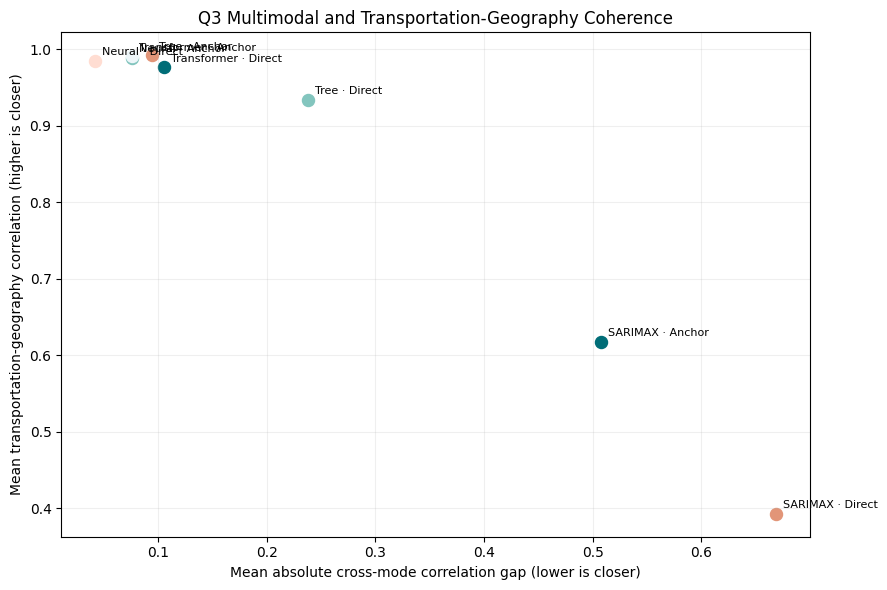

PASS — multimodal and transportation-geography coherence is summarized for all eight Q3 systems.


In [129]:
# ---------------------------------------------------------------------
# 5.1.1.6F — Check multimodal and transportation-geography coherence
# ---------------------------------------------------------------------

H1_Q3_COHERENCE_PATH = INTERMEDIATE_DIR / "recursive_h1_q3_coherence_summary.parquet"

h1_q3_scorecard_df = pd.read_parquet(H1_Q3_SCORECARD_PATH)

def aggregate_q3_coherence_metric(frame, metric, value_column, group_columns):
    """
    Aggregate one target without changing its physical meaning.

    Trips and riders add directly. Average speeds use their matching trip counts
    from the same factual or synthetic world so busy areas carry more weight.
    """
    value_rows = frame.loc[frame["metric"].eq(metric)].copy()
    value_rows[value_column] = pd.to_numeric(value_rows[value_column], errors="coerce")
    value_rows = value_rows.loc[value_rows[value_column].notna()].copy()

    if metric in COUNT_TARGETS:
        return (
            value_rows
            .groupby(group_columns, as_index=False, observed=True)[value_column]
            .sum(min_count=1)
            .rename(columns={value_column: "value"})
        )

    weight_metric = {
        "taxi_avg_trip_speed": "taxi_trip_count",
        "fhvhv_avg_trip_speed": "fhvhv_trip_count",
    }[metric]

    join_columns = [
        "taxi_zone_id", "target_observation_sequence_id",
        "target_date", "canonical_location_id",
    ]

    weight_rows = frame.loc[
        frame["metric"].eq(weight_metric),
        [*join_columns, value_column],
    ].copy()

    weight_rows[value_column] = pd.to_numeric(weight_rows[value_column], errors="coerce")
    weight_rows = weight_rows.rename(columns={value_column: "activity_weight"})

    weighted = value_rows.merge(
        weight_rows,
        on=join_columns,
        how="inner",
        validate="one_to_one",
    )

    weighted = weighted.loc[
        weighted[value_column].notna()
        & weighted["activity_weight"].notna()
        & weighted["activity_weight"].gt(0)
    ].copy()

    weighted["weighted_value"] = weighted[value_column] * weighted["activity_weight"]

    result = (
        weighted
        .groupby(group_columns, as_index=False, observed=True)
        .agg(
            weighted_sum=("weighted_value", "sum"),
            weight_sum=("activity_weight", "sum"),
        )
    )

    result["value"] = (
        result["weighted_sum"]
        / result["weight_sum"].where(result["weight_sum"].gt(0))
    )

    return result[[*group_columns, "value"]]


q3_coherence_source_df = pd.read_parquet(
    H1_Q3_TRAJECTORY_PATH,
    columns=[
        "family", "formulation", "metric", "taxi_zone_id",
        "target_observation_sequence_id", "target_date",
        "target_observed_value", "system_prediction",
    ],
)

q3_coherence_source_df["target_date"] = pd.to_datetime(
    q3_coherence_source_df["target_date"]
).dt.normalize()

q3_coherence_source_df = q3_coherence_source_df.merge(
    runtime_zone_bridge_df[["taxi_zone_id", "canonical_location_id"]],
    on="taxi_zone_id",
    how="left",
    validate="many_to_one",
)


# Hidden Q3 outcomes are identical across the eight systems. One system is
# enough to construct the factual reference for both coherence checks.
actual_reference_df = q3_coherence_source_df.loc[
    q3_coherence_source_df["family"].eq(H1_EXECUTION_ORDER[0])
    & q3_coherence_source_df["formulation"].eq(H1_FORMULATIONS[0])
].copy()

actual_daily_parts = []
actual_spatial_parts = []

for metric in FORECAST_TARGETS:
    daily = aggregate_q3_coherence_metric(
        actual_reference_df,
        metric,
        "target_observed_value",
        ["target_date"],
    )
    daily["metric"] = metric
    actual_daily_parts.append(daily)

    spatial = aggregate_q3_coherence_metric(
        actual_reference_df,
        metric,
        "target_observed_value",
        ["canonical_location_id"],
    )
    spatial["metric"] = metric
    actual_spatial_parts.append(spatial)

actual_daily_df = pd.concat(actual_daily_parts, ignore_index=True)
actual_spatial_df = pd.concat(actual_spatial_parts, ignore_index=True)

actual_daily_wide = actual_daily_df.pivot(
    index="target_date",
    columns="metric",
    values="value",
)

mode_pairs = [
    (FORECAST_TARGETS[i], FORECAST_TARGETS[j])
    for i in range(len(FORECAST_TARGETS))
    for j in range(i + 1, len(FORECAST_TARGETS))
]

actual_pair_correlations = {
    pair: actual_daily_wide[list(pair)].dropna().corr().iloc[0, 1]
    for pair in mode_pairs
}


summary_rows = []

for (family, formulation), system_df in q3_coherence_source_df.groupby(
    ["family", "formulation"],
    observed=True,
    sort=False,
):
    synthetic_daily_parts = []
    synthetic_spatial_parts = []

    for metric in FORECAST_TARGETS:
        daily = aggregate_q3_coherence_metric(
            system_df,
            metric,
            "system_prediction",
            ["target_date"],
        )
        daily["metric"] = metric
        synthetic_daily_parts.append(daily)

        spatial = aggregate_q3_coherence_metric(
            system_df,
            metric,
            "system_prediction",
            ["canonical_location_id"],
        )
        spatial["metric"] = metric
        synthetic_spatial_parts.append(spatial)

    synthetic_daily_wide = pd.concat(
        synthetic_daily_parts,
        ignore_index=True,
    ).pivot(
        index="target_date",
        columns="metric",
        values="value",
    )

    multimodal_gaps = []

    for metric_a, metric_b in mode_pairs:
        paired = synthetic_daily_wide[[metric_a, metric_b]].dropna()
        synthetic_corr = paired[metric_a].corr(paired[metric_b])
        actual_corr = actual_pair_correlations[(metric_a, metric_b)]

        if np.isfinite(synthetic_corr) and np.isfinite(actual_corr):
            multimodal_gaps.append(
                abs(float(synthetic_corr) - float(actual_corr))
            )

    synthetic_spatial_df = pd.concat(
        synthetic_spatial_parts,
        ignore_index=True,
    )

    spatial_correlations = []

    for metric in FORECAST_TARGETS:
        actual_metric = (
            actual_spatial_df.loc[
                actual_spatial_df["metric"].eq(metric),
                ["canonical_location_id", "value"],
            ]
            .rename(columns={"value": "actual_value"})
        )

        synthetic_metric = (
            synthetic_spatial_df.loc[
                synthetic_spatial_df["metric"].eq(metric),
                ["canonical_location_id", "value"],
            ]
            .rename(columns={"value": "synthetic_value"})
        )

        paired = actual_metric.merge(
            synthetic_metric,
            on="canonical_location_id",
            how="inner",
            validate="one_to_one",
        ).dropna()

        spatial_corr = paired["actual_value"].corr(paired["synthetic_value"])

        if np.isfinite(spatial_corr):
            spatial_correlations.append(float(spatial_corr))

    summary_rows.append({
        "selection_contract_id": H1_Q3_SELECTION_CONTRACT_ID,
        "family": family,
        "formulation": formulation,
        "candidate_label": (
            f"{H1_FAMILY_SHORT_LABELS[family]} · "
            f"{H1_FORMULATION_SHORT_LABELS[formulation]}"
        ),
        "mean_abs_multimodal_corr_gap": float(np.mean(multimodal_gaps)),
        "max_abs_multimodal_corr_gap": float(np.max(multimodal_gaps)),
        "mean_spatial_pattern_corr": float(np.mean(spatial_correlations)),
        "min_spatial_pattern_corr": float(np.min(spatial_correlations)),
    })


h1_q3_coherence_summary_df = pd.DataFrame(summary_rows)

atomic_write_parquet(
    h1_q3_coherence_summary_df,
    H1_Q3_COHERENCE_PATH,
)


coherence_display_df = (
    h1_q3_coherence_summary_df[
        [
            "candidate_label", "mean_abs_multimodal_corr_gap",
            "max_abs_multimodal_corr_gap", "mean_spatial_pattern_corr",
            "min_spatial_pattern_corr",
        ]
    ]
    .rename(columns={
        "candidate_label": "System",
        "mean_abs_multimodal_corr_gap": "Mean multimodal correlation gap",
        "max_abs_multimodal_corr_gap": "Largest multimodal correlation gap",
        "mean_spatial_pattern_corr": "Mean geography correlation",
        "min_spatial_pattern_corr": "Weakest target geography correlation",
    })
    .sort_values("Mean multimodal correlation gap")
)

display(coherence_display_df.round(3))


fig, ax = plt.subplots(figsize=(9, 6))

for index, row in h1_q3_coherence_summary_df.reset_index(drop=True).iterrows():
    x = row["mean_abs_multimodal_corr_gap"]
    y = row["mean_spatial_pattern_corr"]

    ax.scatter(
        x,
        y,
        s=75,
        color=BRAND_COLOR_SEQUENCE[index % len(BRAND_COLOR_SEQUENCE)],
    )

    ax.annotate(
        row["candidate_label"],
        (x, y),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Q3 Multimodal and Transportation-Geography Coherence")
ax.set_xlabel("Mean absolute cross-mode correlation gap (lower is closer)")
ax.set_ylabel("Mean transportation-geography correlation (higher is closer)")
ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()


del q3_coherence_source_df, actual_reference_df
gc.collect()

print(
    "PASS — multimodal and transportation-geography coherence is summarized "
    "for all eight Q3 systems.",
    flush=True,
)

**Findings.** The Neural and Tree systems that supply the provisional winners preserve the broader mobility world substantially better than the weakest alternatives. Neural + Direct has the smallest average cross-mode correlation gap, while Neural + Anchor and Tree + Anchor also retain strong transportation-geography patterns.

The SARIMAX systems are the clear coherence outliers: their cross-mode relationships depart much more from factual Q3 behavior and their geographic correlations are substantially weaker. This reinforces the candidate-level accuracy evidence rather than creating a separate selection rule.

**5.1.1.6G — Check whether small accuracy leads are actually convincing**

The lowest MAE is a useful point estimate, but two candidates can be separated by a tiny amount that depends heavily on which weeks happened to be easiest or hardest. We therefore keep each calendar week together and repeatedly resample those weeks to see how stable the leader's advantage is.

The paired quantity is the challenger's MAE minus the point-estimate leader's MAE. Positive values favor the leader. If the uncertainty interval still crosses zero, the two candidates are treated as **not clearly separated** rather than pretending that a very small numerical edge settles the choice.

======================================================================

,Target,Point-estimate leader,Calendar-week blocks,Challengers not clearly separated,Nearest challenger,Nearest MAE gap
0,Taxi trips,Neural · Anchor,14,1,Transformer · Anchor,0.089
1,Taxi average speed,Neural · Direct,14,3,Neural · Anchor,0.024
2,FHVHV trips,Neural · Anchor,14,1,Transformer · Anchor,0.068
3,FHVHV average speed,Tree · Anchor,14,1,Transformer · Anchor,0.019
4,Subway ridership,Neural · Anchor,14,0,Transformer · Anchor,23.180


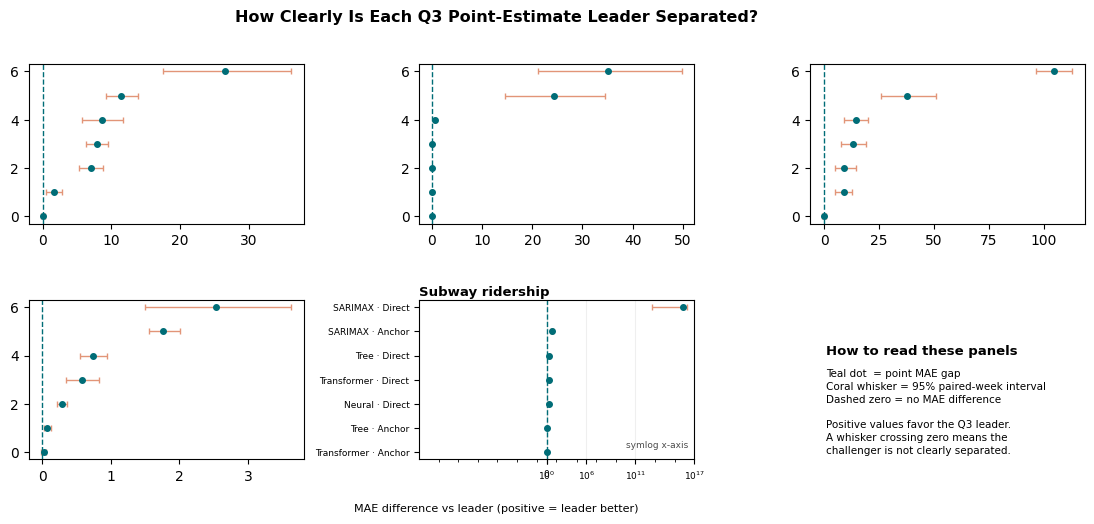

PASS — paired calendar-week uncertainty is complete for all five targets.


In [133]:
# ---------------------------------------------------------------------
# 5.1.1.6G — Measure whether the point-estimate leaders are clearly separated
# ---------------------------------------------------------------------

H1_Q3_BOOTSTRAP_PATH = INTERMEDIATE_DIR / "recursive_h1_q3_weekly_bootstrap.parquet"

H1_Q3_BOOTSTRAP_REPEATS = 5_000
H1_Q3_BOOTSTRAP_CONFIDENCE = 0.95
H1_Q3_BOOTSTRAP_SEED = 696_511

h1_q3_scorecard_df = pd.read_parquet(H1_Q3_SCORECARD_PATH)

def paired_week_mae_interval(weekly_frame, difference_column, seed):
    """
    Bootstrap a paired MAE difference while keeping calendar weeks intact.

    `difference_column` stores challenger absolute-error sum minus reference
    absolute-error sum for each week. Positive values therefore favor the
    reference candidate.
    """
    rows = weekly_frame["evaluation_rows"].to_numpy(dtype=float)
    difference = weekly_frame[difference_column].to_numpy(dtype=float)

    point_difference = float(difference.sum() / rows.sum())
    rng = np.random.default_rng(seed)

    sampled = rng.integers(
        0,
        len(weekly_frame),
        size=(H1_Q3_BOOTSTRAP_REPEATS, len(weekly_frame)),
    )

    bootstrap_difference = (
        difference[sampled].sum(axis=1)
        / rows[sampled].sum(axis=1)
    )

    alpha = 1.0 - H1_Q3_BOOTSTRAP_CONFIDENCE

    ci_low, ci_high = np.quantile(
        bootstrap_difference,
        [alpha / 2.0, 1.0 - alpha / 2.0],
    )

    return point_difference, float(ci_low), float(ci_high)


q3_bootstrap_source_df = pd.read_parquet(
    H1_Q3_TRAJECTORY_PATH,
    columns=[
        "h1_candidate_id", "metric", "target_date",
        "target_observed_value", "system_prediction",
    ],
)

q3_bootstrap_source_df["target_date"] = pd.to_datetime(
    q3_bootstrap_source_df["target_date"]
).dt.normalize()

for column in ["target_observed_value", "system_prediction"]:
    q3_bootstrap_source_df[column] = pd.to_numeric(
        q3_bootstrap_source_df[column],
        errors="coerce",
    )

q3_bootstrap_source_df = q3_bootstrap_source_df.loc[
    q3_bootstrap_source_df["target_observed_value"].notna()
].copy()

q3_bootstrap_source_df["absolute_error"] = (
    q3_bootstrap_source_df["system_prediction"]
    - q3_bootstrap_source_df["target_observed_value"]
).abs()

q3_bootstrap_source_df["week_start"] = (
    q3_bootstrap_source_df["target_date"]
    - pd.to_timedelta(q3_bootstrap_source_df["target_date"].dt.weekday, unit="D")
)

weekly_error_df = (
    q3_bootstrap_source_df
    .groupby(
        ["metric", "h1_candidate_id", "week_start"],
        as_index=False,
        observed=True,
    )
    .agg(
        evaluation_rows=("absolute_error", "size"),
        absolute_error_sum=("absolute_error", "sum"),
    )
)

leader_by_target = (
    h1_q3_scorecard_df
    .sort_values(["metric", "system_mae", "h1_candidate_id"])
    .groupby("metric", observed=True, sort=False)
    .head(1)
    .set_index("metric")["h1_candidate_id"]
    .astype(str)
    .to_dict()
)

candidate_label_lookup = (
    h1_q3_scorecard_df
    .set_index("h1_candidate_id")["candidate_label"]
    .astype(str)
    .to_dict()
)


bootstrap_rows = []

for metric_index, metric in enumerate(FORECAST_TARGETS):
    leader_id = leader_by_target[metric]

    metric_weekly_df = weekly_error_df.loc[
        weekly_error_df["metric"].eq(metric)
    ].copy()

    leader_weekly = (
        metric_weekly_df.loc[
            metric_weekly_df["h1_candidate_id"].astype(str).eq(leader_id)
        ]
        .set_index("week_start")
        .sort_index()
    )

    candidate_ids = sorted(
        metric_weekly_df["h1_candidate_id"].astype(str).unique()
    )

    for candidate_index, candidate_id in enumerate(candidate_ids):
        challenger_weekly = (
            metric_weekly_df.loc[
                metric_weekly_df["h1_candidate_id"].astype(str).eq(candidate_id)
            ]
            .set_index("week_start")
            .sort_index()
        )

        if candidate_id == leader_id:
            point_difference = ci_low = ci_high = 0.0
            comparison_status = "reference leader"

        else:
            paired = leader_weekly[
                ["evaluation_rows", "absolute_error_sum"]
            ].rename(
                columns={"absolute_error_sum": "leader_error_sum"}
            ).join(
                challenger_weekly[["absolute_error_sum"]].rename(
                    columns={"absolute_error_sum": "challenger_error_sum"}
                ),
                how="inner",
            )

            if len(paired) != len(leader_weekly):
                raise RuntimeError(
                    f"{metric}: paired candidates no longer share the same Q3 weeks."
                )

            paired["error_sum_difference"] = (
                paired["challenger_error_sum"]
                - paired["leader_error_sum"]
            )

            point_difference, ci_low, ci_high = paired_week_mae_interval(
                paired.reset_index(),
                "error_sum_difference",
                H1_Q3_BOOTSTRAP_SEED + metric_index * 100 + candidate_index,
            )

            comparison_status = (
                "clearly worse than leader"
                if ci_low > 0
                else "not clearly separated"
            )

        bootstrap_rows.append({
            "selection_contract_id": H1_Q3_SELECTION_CONTRACT_ID,
            "metric": metric,
            "reference_candidate_id": leader_id,
            "candidate_id": candidate_id,
            "calendar_week_blocks": len(leader_weekly),
            "point_mae_difference": point_difference,
            "ci_low_mae_difference": ci_low,
            "ci_high_mae_difference": ci_high,
            "comparison_status": comparison_status,
        })


h1_q3_weekly_bootstrap_df = pd.DataFrame(bootstrap_rows)

h1_q3_weekly_bootstrap_df["reference_label"] = (
    h1_q3_weekly_bootstrap_df["reference_candidate_id"].map(candidate_label_lookup)
)

h1_q3_weekly_bootstrap_df["candidate_label"] = (
    h1_q3_weekly_bootstrap_df["candidate_id"].map(candidate_label_lookup)
)

atomic_write_parquet(
    h1_q3_weekly_bootstrap_df,
    H1_Q3_BOOTSTRAP_PATH,
)


separation_rows = []

for metric in FORECAST_TARGETS:
    metric_df = h1_q3_weekly_bootstrap_df.loc[
        h1_q3_weekly_bootstrap_df["metric"].eq(metric)
    ].copy()

    challengers = metric_df.loc[
        metric_df["candidate_id"].ne(metric_df["reference_candidate_id"])
    ].sort_values("point_mae_difference")

    nearest = challengers.iloc[0]

    separation_rows.append({
        "Target": TARGET_LABELS[metric],
        "Point-estimate leader": metric_df["reference_label"].iloc[0],
        "Calendar-week blocks": int(metric_df["calendar_week_blocks"].iloc[0]),
        "Challengers not clearly separated": int(
            challengers["comparison_status"].eq("not clearly separated").sum()
        ),
        "Nearest challenger": nearest["candidate_label"],
        "Nearest MAE gap": float(nearest["point_mae_difference"]),
    })


h1_q3_separation_summary_df = pd.DataFrame(separation_rows)

display(h1_q3_separation_summary_df.round(3))

# ---------------------------------------------------------------------
# Compact 3-column × 2-row uncertainty view
#
# The x-axis has the same meaning in every panel, but NOT the same native
# units or useful numerical range. Each target therefore keeps its own scale.
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 5.2),
)

axes = axes.ravel()
metric_axes = axes[:len(FORECAST_TARGETS)]
key_ax = axes[5]


for ax, metric in zip(metric_axes, FORECAST_TARGETS):
    metric_df = (
        h1_q3_weekly_bootstrap_df.loc[
            h1_q3_weekly_bootstrap_df["metric"].eq(metric)
            & h1_q3_weekly_bootstrap_df["candidate_id"].ne(
                h1_q3_weekly_bootstrap_df["reference_candidate_id"]
            )
        ]
        .sort_values("point_mae_difference")
        .reset_index(drop=True)
    )

    y = np.arange(len(metric_df))

    point = metric_df["point_mae_difference"].to_numpy(dtype=float)
    ci_low = metric_df["ci_low_mae_difference"].to_numpy(dtype=float)
    ci_high = metric_df["ci_high_mae_difference"].to_numpy(dtype=float)

    lower = point - ci_low
    upper = ci_high - point


    ax.errorbar(
        point,
        y,
        xerr=np.vstack([lower, upper]),
        fmt="o",
        color=BRAND_COLOR_SEQUENCE[0],
        ecolor=BRAND_COLOR_SEQUENCE[1],
        markersize=4,
        linewidth=1.1,
        elinewidth=1.0,
        capsize=2,
    )

    # Zero means the challenger and point-estimate leader have equal MAE.
    # Intervals fully to the right support a clearly better leader.
    ax.axvline(
        0,
        color=BRAND_COLORS["dark_teal"],
        linestyle="--",
        linewidth=1.0,
    )


    # One catastrophic candidate can otherwise flatten every useful comparison
    # in its panel. Switch to symlog only when the largest point gap is more
    # than 100× the next-largest gap; the outlier remains visible rather than
    # being clipped or removed.
    finite_abs_points = np.sort(
        np.abs(point[np.isfinite(point)])
    )

    uses_symlog = (
        len(finite_abs_points) >= 2
        and finite_abs_points[-2] > 0
        and finite_abs_points[-1] > 100 * finite_abs_points[-2]
    )

if uses_symlog:
    linear_threshold = max(2 * finite_abs_points[-2], 1.0)
    ax.set_xscale("symlog", linthresh=linear_threshold)

    # The Subway outlier spans many orders of magnitude. Show only a few
    # representative powers of ten so the scale remains legible.
    max_abs = max(
        np.nanmax(np.abs(point)),
        np.nanmax(np.abs(ci_low)),
        np.nanmax(np.abs(ci_high)),
    )

    max_exponent = max(1, int(np.ceil(np.log10(max_abs))))
    tick_exponents = np.unique(
        np.round(np.linspace(0, max_exponent, 4)).astype(int)
    )

    tick_values = np.concatenate([
        [0.0],
        10.0 ** tick_exponents,
    ])

    tick_labels = [
        "0",
        *[
            rf"$10^{{{exponent}}}$"
            for exponent in tick_exponents
        ],
    ]

    ax.set_xticks(tick_values)
    ax.set_xticklabels(tick_labels, fontsize=6.5)

    ax.text(
        0.98,
        0.06,
        "symlog x-axis",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=6.5,
        alpha=0.7,
    )


    ax.set_yticks(y)
    ax.set_yticklabels(
        metric_df["candidate_label"],
        fontsize=6.5,
    )

    ax.set_title(
        TARGET_LABELS[metric],
        loc="left",
        fontsize=9.5,
        fontweight="bold",
        pad=3,
    )

    ax.tick_params(axis="x", labelsize=6.5)
    ax.grid(axis="x", alpha=0.2)


# Use the sixth panel as a compact interpretation key instead of wasting the
# space or repeating explanatory legends inside all five target panels.
key_ax.axis("off")

key_ax.text(
    0.06,
    0.72,
    "How to read these panels",
    transform=key_ax.transAxes,
    fontsize=9.5,
    fontweight="bold",
    va="top",
)

key_ax.text(
    0.06,
    0.57,
    "Teal dot  = point MAE gap\n"
    "Coral whisker = 95% paired-week interval\n"
    "Dashed zero = no MAE difference\n\n"
    "Positive values favor the Q3 leader.\n"
    "A whisker crossing zero means the\n"
    "challenger is not clearly separated.",
    transform=key_ax.transAxes,
    fontsize=7.5,
    va="top",
    linespacing=1.35,
)


fig.suptitle(
    "How Clearly Is Each Q3 Point-Estimate Leader Separated?",
    fontsize=11.5,
    fontweight="bold",
    y=0.985,
)

# One common label saves substantial vertical space while preserving the
# common interpretation despite target-specific numerical scales.
fig.supxlabel(
    "MAE difference vs leader (positive = leader better)",
    fontsize=8,
    y=0.015,
)

fig.subplots_adjust(
    left=0.11,
    right=0.99,
    bottom=0.12,
    top=0.88,
    hspace=0.48,
    wspace=0.42,
)

plt.show()


del q3_bootstrap_source_df
gc.collect()

print(
    "PASS — paired calendar-week uncertainty is complete for all five targets.",
    flush=True,
)

**Findings.** The numerical leaders are not equally well separated. Subway is the clearest result: none of its seven challengers is statistically indistinguishable from Neural + Anchor at the paired-week level.

The other four targets retain at least one close alternative. Taxi average speed is the least settled, with three challengers not clearly separated from Neural + Direct. Taxi trips, FHVHV trips, and FHVHV speed each have one close challenger. These results support treating the five lowest-MAE candidates as provisional leaders rather than claiming that every target has an overwhelming standalone winner.

**5.1.1.6H — Assemble a provisional five-engine roster**

The previous blocks give us several views of the same candidates, but they do not need to be collapsed into an arbitrary weighted score. System MAE remains the primary numerical comparison. Rollout-age behavior, trajectory shape, geography, system coherence, bias, fallback use, and weekly uncertainty provide context for whether that numerical leader looks trustworthy.

This block therefore takes the lowest-MAE candidate for each mobility target and assembles those five candidates into one **provisional** roster. Nothing is frozen yet. The purpose is to create the exact five-engine system that must be tested together next, because each candidate's earlier Q3 trajectory was created inside a single-family world rather than alongside the other four independently selected engines.

======================================================================

In [135]:
# ---------------------------------------------------------------------
# 5.1.1.6H — Assemble the provisional five-target h=1 roster
# ---------------------------------------------------------------------

H1_Q3_PROVISIONAL_ROSTER_PATH = (
    INTERMEDIATE_DIR / "recursive_h1_q3_provisional_roster.parquet"
)


# 6H is a synthesis step, not another discovery step. Each prior analytical
# block owns one durable artifact, so reload those authoritative outputs
# directly rather than depending on whatever happens to remain in kernel RAM.
h1_q3_scorecard_df = pd.read_parquet(H1_Q3_SCORECARD_PATH)
h1_q3_rollout_health_df = pd.read_parquet(H1_Q3_ROLLOUT_HEALTH_PATH)
h1_q3_trajectory_health_df = pd.read_parquet(H1_Q3_TRAJECTORY_HEALTH_PATH)
h1_q3_geography_health_df = pd.read_parquet(H1_Q3_GEOGRAPHY_PATH)
h1_q3_coherence_summary_df = pd.read_parquet(H1_Q3_COHERENCE_PATH)
h1_q3_weekly_bootstrap_df = pd.read_parquet(H1_Q3_BOOTSTRAP_PATH)


# MAE supplies the point estimate. The surrounding diagnostics are preserved
# alongside it so the next mixed-system test starts from transparent evidence
# rather than from an opaque weighted score.
provisional_df = (
    h1_q3_scorecard_df
    .sort_values(["metric", "system_mae", "h1_candidate_id"])
    .groupby("metric", observed=True, sort=False)
    .head(1)
    .copy()
)

if len(provisional_df) != len(FORECAST_TARGETS):
    raise RuntimeError(
        "The provisional roster must contain exactly one h=1 candidate per target."
    )


provisional_df = provisional_df.merge(
    h1_candidate_registry_df[
        [
            "h1_candidate_id", "candidate_id", "source_configuration_id",
            "chapter5_modeling_track", "formulation_label",
        ]
    ],
    on="h1_candidate_id",
    how="left",
    validate="one_to_one",
)

provisional_df = provisional_df.merge(
    h1_q3_rollout_health_df[
        [
            "h1_candidate_id", "relative_mae_pct_early",
            "relative_mae_pct_middle", "relative_mae_pct_late",
            "late_minus_early_relative_mae_pp", "signed_bias_late",
        ]
    ],
    on="h1_candidate_id",
    how="left",
    validate="one_to_one",
)

provisional_df = provisional_df.merge(
    h1_q3_trajectory_health_df[
        [
            "h1_candidate_id", "mean_level_vs_actual_pct",
            "daily_variability_vs_actual_pct", "daily_shape_correlation",
        ]
    ],
    on="h1_candidate_id",
    how="left",
    validate="one_to_one",
)

geography_spread_df = (
    h1_q3_geography_health_df
    .groupby("h1_candidate_id", as_index=False, observed=True)
    .agg(
        geography_relative_mae_min=("relative_mae_pct", "min"),
        geography_relative_mae_max=("relative_mae_pct", "max"),
    )
)

geography_spread_df["geography_relative_mae_spread_pp"] = (
    geography_spread_df["geography_relative_mae_max"]
    - geography_spread_df["geography_relative_mae_min"]
)

provisional_df = provisional_df.merge(
    geography_spread_df[
        ["h1_candidate_id", "geography_relative_mae_spread_pp"]
    ],
    on="h1_candidate_id",
    how="left",
    validate="one_to_one",
)

provisional_df = provisional_df.merge(
    h1_q3_coherence_summary_df[
        [
            "family", "formulation",
            "mean_abs_multimodal_corr_gap", "mean_spatial_pattern_corr",
        ]
    ],
    on=["family", "formulation"],
    how="left",
    validate="many_to_one",
)

close_rivals_df = (
    h1_q3_weekly_bootstrap_df.loc[
        h1_q3_weekly_bootstrap_df["comparison_status"].eq("not clearly separated")
    ]
    .groupby("metric", as_index=False, observed=True)
    .agg(close_challengers=("candidate_id", "nunique"))
)

provisional_df = provisional_df.merge(
    close_rivals_df,
    on="metric",
    how="left",
    validate="one_to_one",
)

provisional_df["close_challengers"] = (
    provisional_df["close_challengers"].fillna(0).astype(int)
)

provisional_df["selection_status"] = "provisional_point_estimate_leader"
provisional_df["selected_for_mixed_test"] = True

provisional_columns = [
    "selection_contract_id", "selection_status",
    "metric", "family", "formulation", "formulation_label",
    "h1_candidate_id", "candidate_id", "source_configuration_id",
    "chapter5_modeling_track",
    "system_mae", "relative_mae_pct", "signed_bias",
    "benchmark_skill_pct", "advanced_coverage_pct", "fallback_rate_pct",
    "relative_mae_pct_early", "relative_mae_pct_middle", "relative_mae_pct_late",
    "late_minus_early_relative_mae_pp", "signed_bias_late",
    "mean_level_vs_actual_pct", "daily_variability_vs_actual_pct",
    "daily_shape_correlation", "geography_relative_mae_spread_pp",
    "mean_abs_multimodal_corr_gap", "mean_spatial_pattern_corr",
    "close_challengers", "selected_for_mixed_test",
]

provisional_df = (
    provisional_df[provisional_columns]
    .sort_values("metric")
    .reset_index(drop=True)
)

atomic_write_parquet(
    provisional_df,
    H1_Q3_PROVISIONAL_ROSTER_PATH,
)


provisional_display_df = (
    provisional_df
    .assign(Target=lambda frame: frame["metric"].map(TARGET_LABELS))
    [
        [
            "Target", "family", "formulation_label", "relative_mae_pct",
            "late_minus_early_relative_mae_pp",
            "daily_variability_vs_actual_pct", "daily_shape_correlation",
            "geography_relative_mae_spread_pp", "close_challengers",
        ]
    ]
    .rename(columns={
        "family": "Family",
        "formulation_label": "Formulation",
        "relative_mae_pct": "Q3 Relative MAE (%)",
        "late_minus_early_relative_mae_pp": "Late − early error (pp)",
        "daily_variability_vs_actual_pct": "Daily variation vs actual (%)",
        "daily_shape_correlation": "Daily shape correlation",
        "geography_relative_mae_spread_pp": "Geography error spread (pp)",
        "close_challengers": "Close challengers",
    })
)

display(provisional_display_df.round(3))

print(
    "PASS — five point-estimate leaders are assembled into one provisional "
    "mixed-roster contract; nothing is frozen yet.",
    flush=True,
)

,Target,Family,Formulation,Q3 Relative MAE (%),Late − early error (pp),Daily variation vs actual (%),Daily shape correlation,Geography error spread (pp),Close challengers
0,FHVHV average speed,tree,Anchor + residual,6.138,0.294,90.291,0.802,0.450,1
1,FHVHV trips,neural,Anchor + residual,12.099,0.120,91.437,0.852,2.351,1
2,Subway ridership,neural,Anchor + residual,12.651,2.200,94.111,0.913,2.252,0
3,Taxi average speed,neural,Direct level,18.134,0.279,79.384,0.694,8.119,3
4,Taxi trips,neural,Anchor + residual,19.539,0.818,57.177,0.662,5.378,1


PASS — five point-estimate leaders are assembled into one provisional mixed-roster contract; nothing is frozen yet.


**Findings.** The provisional roster selects Neural + Anchor for Taxi trips, FHVHV trips, and Subway ridership; Neural + Direct for Taxi average speed; and Tree + Anchor for FHVHV average speed.

The supporting diagnostics explain why these remain provisional. Subway has the strongest separation from its challengers and a high daily-shape correlation. FHVHV also remains stable across rollout age and geography. Taxi has more ambiguity: Taxi speed has three close challengers, while Taxi trips retains less of the factual day-to-day variation. The mixed-system test therefore remains essential before these five engines can be frozen.

**5.1.1.6I — Build the restartable mixed-roster Q3 test**

The five provisional engines may come from different model families, so their earlier Q3 trajectories do not yet show how they behave when they share the same synthetic mobility world. This block prepares that final coupling test without running it.

Tree, Neural, and Transformer candidates can be rescored directly from the evolving mixed state. SARIMAX is different: each sequence follows its own state-space chain, and its frozen external inputs do not use companion-mode recursive mobility. Its already-produced Q3 advanced path can therefore be reused while the mixed runtime still rebuilds the benchmark from current synthetic history and verifies that the resolved SARIMAX output stays unchanged.

The mixed rehearsal uses the same Q3 boundary, the same 25-Daypart restart blocks, the same h=1-only state update, and the same fallback rule as the family-specific tournament. Expensive execution remains behind an explicit toggle.

======================================================================

In [137]:
# ---------------------------------------------------------------------
# 5.1.1.6I — Define the restartable mixed-roster Q3 coupling test
# ---------------------------------------------------------------------

RUN_H1_Q3_MIXED_ROSTER = True
RESET_H1_Q3_MIXED_ROSTER = False

H1_MIXED_FAMILY_ID = "mixed_roster"

provisional_df = pd.read_parquet(H1_Q3_PROVISIONAL_ROSTER_PATH)

metric_order = {
    metric: position
    for position, metric in enumerate(FORECAST_TARGETS)
}

roster_ordered_df = (
    provisional_df
    .assign(_metric_order=provisional_df["metric"].map(metric_order))
    .sort_values("_metric_order")
    .drop(columns="_metric_order")
    .reset_index(drop=True)
)

family_code = {
    "tree": "tree",
    "neural": "nn",
    "transformer": "tr",
    "classical": "sar",
}

formulation_code = {
    "direct_level": "d",
    "anchor_residual": "a",
}

H1_MIXED_ROSTER_SIGNATURE = "-".join(
    f"{family_code[row.family]}{formulation_code[row.formulation]}"
    for row in roster_ordered_df.itertuples(index=False)
)

H1_MIXED_FORMULATION_ID = f"q3_{H1_MIXED_ROSTER_SIGNATURE}"

H1_Q3_MIXED_TRAJECTORY_PATH = (
    INTERMEDIATE_DIR
    / f"recursive_h1_q3_mixed_{H1_MIXED_ROSTER_SIGNATURE}.parquet"
)

H1_Q3_MIXED_AUDIT_PATH = (
    INTERMEDIATE_DIR
    / f"recursive_h1_q3_mixed_{H1_MIXED_ROSTER_SIGNATURE}_audit.parquet"
)

H1_Q3_MIXED_COMPARISON_PATH = (
    INTERMEDIATE_DIR
    / f"recursive_h1_q3_mixed_{H1_MIXED_ROSTER_SIGNATURE}_comparison.parquet"
)

q3_position_count = int(
    recursive_episode_position_registry_df["episode_id"]
    .eq(H1_SELECTION_EPISODE_ID)
    .sum()
)

H1_Q3_MIXED_EXPECTED_ROWS = (
    q3_position_count
    * EXPECTED_PRE_CP_NATIVE_SEQUENCES
)


def h1_mixed_q3_complete():
    """
    Return True only when the mixed trajectory, block state, and final audit agree.

    This is the cheap recovery path. Row-level semantic validation happens when
    the trajectory is created and again in 6J, not on every notebook rerun.
    """
    if h1_parquet_row_count(H1_Q3_MIXED_TRAJECTORY_PATH) != H1_Q3_MIXED_EXPECTED_ROWS:
        return False

    if not h1_rollout_complete(
        H1_MIXED_FAMILY_ID,
        H1_MIXED_FORMULATION_ID,
        H1_SELECTION_EPISODE_ID,
        training_episode=False,
    ):
        return False

    if not H1_Q3_MIXED_AUDIT_PATH.exists():
        return False

    try:
        audit_df = pd.read_parquet(H1_Q3_MIXED_AUDIT_PATH)
    except Exception:
        return False

    if len(audit_df) != 1:
        return False

    audit = audit_df.iloc[0]

    return bool(
        str(audit["recursive_contract_id"]) == RECURSIVE_H1_CONTRACT_ID
        and str(audit["selection_contract_id"]) == H1_Q3_SELECTION_CONTRACT_ID
        and str(audit["roster_signature"]) == H1_MIXED_ROSTER_SIGNATURE
        and int(audit["rows"]) == H1_Q3_MIXED_EXPECTED_ROWS
        and str(audit["status"]) == "success"
    )


def reset_h1_mixed_q3():
    """Remove only the current provisional roster's mixed-Q3 artifacts."""
    rollout_dir = h1_rollout_episode_dir(
        H1_MIXED_FAMILY_ID,
        H1_MIXED_FORMULATION_ID,
        H1_SELECTION_EPISODE_ID,
    )

    marker_dir = (
        H1_SUCCESS_MARKER_DIR
        / H1_MIXED_FAMILY_ID
        / H1_MIXED_FORMULATION_ID
        / H1_SELECTION_EPISODE_ID
    )

    for path in [rollout_dir, marker_dir]:
        if path.exists():
            shutil.rmtree(path)

    for path in [
        H1_Q3_MIXED_TRAJECTORY_PATH,
        H1_Q3_MIXED_AUDIT_PATH,
        H1_Q3_MIXED_COMPARISON_PATH,
    ]:
        if path.exists():
            path.unlink()


def load_h1_mixed_candidate_inputs():
    """
    Restore the five provisional engines in the form needed by the mixed runner.

    Tree, Neural, and Transformer are rescored from the evolving mixed state.
    SARIMAX is sequence-specific; its Q3 advanced path can be reused because its
    frozen exogenous design contains no recursive companion-mode features.
    """
    cross_target_features = (
        set(H1_RECURSIVE_LOCAL_FEATURES)
        | set(H1_RECURSIVE_CONNECTED_FEATURES)
    )

    if cross_target_features & set(SARIMAX_UNTREATED_EXOG_COLUMNS):
        raise RuntimeError(
            "The frozen SARIMAX exogenous design unexpectedly depends on "
            "cross-target recursive mobility."
        )

    fitted_bundles = {}
    classical_candidate_ids = []

    for row in roster_ordered_df.itertuples(index=False):
        if row.family == "classical":
            classical_candidate_ids.append(str(row.h1_candidate_id))
            continue

        model_path = h1_candidate_model_path(
            row.family,
            row.formulation,
            row.metric,
            stage="final",
        )

        bundle = load_h1_candidate_bundle(
            row.family,
            row.metric,
            row.formulation,
            model_path,
        )

        if str(bundle["h1_candidate_id"]) != str(row.h1_candidate_id):
            raise RuntimeError(
                f"{row.metric}: restored candidate does not match "
                "the provisional roster."
            )

        fitted_bundles[row.metric] = bundle

    classical_source_index = None

    if classical_candidate_ids:
        classical_source_df = pd.read_parquet(
            H1_Q3_TRAJECTORY_PATH,
            columns=[
                "h1_candidate_id", "forecast_sequence_id",
                "target_observation_sequence_id", "prediction_raw",
                "prediction_final", "advanced_prediction_available",
                "system_prediction",
            ],
            filters=[
                ("h1_candidate_id", "in", classical_candidate_ids),
            ],
        )

        classical_source_df["h1_candidate_id"] = (
            classical_source_df["h1_candidate_id"].astype(str)
        )

        classical_source_df["forecast_sequence_id"] = (
            classical_source_df["forecast_sequence_id"].astype(str)
        )

        classical_source_df["target_observation_sequence_id"] = pd.to_numeric(
            classical_source_df["target_observation_sequence_id"],
            errors="raise",
        ).astype(int)

        classical_source_index = classical_source_df.set_index(
            [
                "h1_candidate_id",
                "target_observation_sequence_id",
                "forecast_sequence_id",
            ]
        ).sort_index()

    roster_lookup = roster_ordered_df.set_index("metric").to_dict("index")

    return roster_lookup, fitted_bundles, classical_source_index


def resolve_h1_mixed_system_predictions(
    prepared_frame,
    state,
    *,
    roster_lookup,
    fitted_bundles,
    classical_source_index,
    episode_id,
):
    """
    Score all five selected engines before advancing the mixed synthetic state.

    Advanced output keeps first priority. The benchmark is always recomputed
    from the current mixed state, so fallback semantics remain identical to the
    tournament even though the five selected engines now come from different
    source systems.
    """
    benchmark_prediction, benchmark_available = synthetic_h1_benchmark(
        prepared_frame,
        state,
    )

    target_ids = pd.to_numeric(
        prepared_frame["target_observation_sequence_id"],
        errors="raise",
    ).astype(int).unique()

    if len(target_ids) != 1:
        raise RuntimeError(
            "A mixed h=1 origin must contain exactly one target Daypart."
        )

    target_id = int(target_ids[0])
    output_parts = []

    for metric in FORECAST_TARGETS:
        selection = roster_lookup[metric]

        family = str(selection["family"])
        formulation = str(selection["formulation"])
        candidate_id = str(selection["h1_candidate_id"])

        metric_positions = np.flatnonzero(
            prepared_frame["metric"].astype(str).eq(metric).to_numpy()
        )

        metric_frame = prepared_frame.iloc[metric_positions].copy()

        if family == "classical":
            if classical_source_index is None:
                raise RuntimeError(
                    f"{metric}: selected SARIMAX Q3 path was not loaded."
                )

            try:
                source = classical_source_index.loc[
                    (candidate_id, target_id)
                ].copy()

            except KeyError as exc:
                raise RuntimeError(
                    f"{metric}: selected SARIMAX output is missing "
                    f"Q3 target {target_id:,}."
                ) from exc

            source = source.reindex(
                metric_frame["forecast_sequence_id"].astype(str)
            )

            prediction_raw = pd.to_numeric(
                source["prediction_raw"],
                errors="coerce",
            ).to_numpy(dtype=np.float32)

            prediction_final = pd.to_numeric(
                source["prediction_final"],
                errors="coerce",
            ).to_numpy(dtype=np.float32)

            advanced_available = (
                source["advanced_prediction_available"]
                .fillna(False)
                .astype(bool)
                .to_numpy()
            )

            source_system_prediction = pd.to_numeric(
                source["system_prediction"],
                errors="coerce",
            ).to_numpy(dtype=np.float32)

        else:
            prediction_raw, prediction_final, advanced_available = (
                score_h1_fitted_candidate(
                    fitted_bundles[metric],
                    metric_frame,
                    state,
                )
            )

            source_system_prediction = None

        metric_benchmark = benchmark_prediction[metric_positions]
        metric_benchmark_available = benchmark_available[metric_positions]

        fallback_used = ~advanced_available & metric_benchmark_available
        system_available = advanced_available | metric_benchmark_available

        system_prediction = np.where(
            advanced_available,
            prediction_final,
            np.where(
                metric_benchmark_available,
                metric_benchmark,
                np.nan,
            ),
        ).astype(np.float32)

        if not system_available.all():
            raise RuntimeError(
                f"{metric}: mixed Q3 contains unresolved state rows."
            )

        # SARIMAX depends only on its own endogenous history plus frozen external
        # inputs. Reusing its Q3 path is valid only if the mixed runtime recreates
        # the same resolved output row for row.
        if source_system_prediction is not None and not np.isclose(
            system_prediction,
            source_system_prediction,
            rtol=1e-6,
            atol=1e-5,
        ).all():
            raise RuntimeError(
                f"{metric}: selected SARIMAX path changed inside the mixed roster."
            )

        output = metric_frame[
            [
                "forecast_sequence_id", "taxi_zone_id", "metric",
                "origin_observation_sequence_id",
                "target_observation_sequence_id",
                "target_date", "target_daypart",
                "target_observed_value", "anchor_local_value",
            ]
        ].copy()

        output.insert(0, "recursive_contract_id", RECURSIVE_H1_CONTRACT_ID)
        output.insert(1, "episode_id", episode_id)

        output["rollout_system_id"] = H1_MIXED_ROSTER_SIGNATURE
        output["family"] = family
        output["formulation"] = formulation
        output["h1_candidate_id"] = candidate_id

        output["prediction_raw"] = prediction_raw
        output["prediction_final"] = prediction_final
        output["advanced_prediction_available"] = advanced_available

        output["benchmark_prediction"] = metric_benchmark
        output["benchmark_prediction_available"] = metric_benchmark_available
        output["benchmark_fallback_used"] = fallback_used

        output["system_prediction"] = system_prediction
        output["system_prediction_available"] = system_available

        output_parts.append(output)

    result = pd.concat(output_parts, ignore_index=True)

    if len(result) != EXPECTED_PRE_CP_NATIVE_SEQUENCES:
        raise RuntimeError(
            f"Mixed Q3 Daypart produced {len(result):,} rows; expected "
            f"{EXPECTED_PRE_CP_NATIVE_SEQUENCES:,}."
        )

    if result.duplicated(["taxi_zone_id", "metric"]).any():
        raise RuntimeError(
            "Mixed Q3 Daypart contains duplicate Taxi Zone × metric rows."
        )

    return result


def run_h1_mixed_q3():
    """Run or resume the provisional five-engine roster through the full Q3 episode."""
    roster_lookup, fitted_bundles, classical_source_index = (
        load_h1_mixed_candidate_inputs()
    )

    state, last_block_id = recover_h1_rollout_state(
        H1_MIXED_FAMILY_ID,
        H1_MIXED_FORMULATION_ID,
        H1_SELECTION_EPISODE_ID,
        training_episode=False,
    )

    blocks = (
        h1_rollout_block_registry_df.loc[
            h1_rollout_block_registry_df["episode_id"].eq(
                H1_SELECTION_EPISODE_ID
            )
            & h1_rollout_block_registry_df["block_id"].gt(last_block_id)
        ]
        .sort_values("block_id")
    )

    progress = tqdm(
        total=int(blocks["positions"].sum()) if not blocks.empty else 0,
        desc=f"mixed roster · {H1_MIXED_ROSTER_SIGNATURE} · Q3",
    )

    for block in blocks.itertuples(index=False):
        prediction_parts = []

        target_ids = H1_BLOCK_TARGET_IDS[
            (H1_SELECTION_EPISODE_ID, int(block.block_id))
        ]

        for target_id in target_ids:
            origin_frame = load_h1_episode_origin_frame(
                H1_SELECTION_EPISODE_ID,
                target_id,
            )

            prepared_frame = prepare_h1_recursive_frame(
                origin_frame,
                state,
                episode_id=H1_SELECTION_EPISODE_ID,
            )

            origin_predictions = resolve_h1_mixed_system_predictions(
                prepared_frame,
                state,
                roster_lookup=roster_lookup,
                fitted_bundles=fitted_bundles,
                classical_source_index=classical_source_index,
                episode_id=H1_SELECTION_EPISODE_ID,
            )

            position = H1_POSITION_LOOKUP[
                (H1_SELECTION_EPISODE_ID, int(target_id))
            ]

            origin_predictions["rollout_step"] = position["rollout_step"]
            origin_predictions["rollout_day"] = position["rollout_day"]

            prediction_parts.append(origin_predictions)

            apply_h1_state_update(
                state,
                origin_predictions,
                prediction_column="system_prediction",
            )

            progress.update(1)

        block_predictions = pd.concat(
            prediction_parts,
            ignore_index=True,
        )

        if len(block_predictions) != int(block.expected_prediction_rows):
            raise RuntimeError(
                f"Mixed Q3 block {block.block_id}: produced "
                f"{len(block_predictions):,} rows; expected "
                f"{int(block.expected_prediction_rows):,}."
            )

        atomic_write_parquet(
            block_predictions,
            h1_prediction_block_path(
                H1_MIXED_FAMILY_ID,
                H1_MIXED_FORMULATION_ID,
                H1_SELECTION_EPISODE_ID,
                int(block.block_id),
            ),
        )

        write_h1_block_success(
            family=H1_MIXED_FAMILY_ID,
            formulation=H1_MIXED_FORMULATION_ID,
            episode_id=H1_SELECTION_EPISODE_ID,
            block_id=int(block.block_id),
            prediction_rows=len(block_predictions),
            example_rows=None,
            next_target_sequence_id=int(state["next_target_sequence_id"]),
        )

        write_h1_runtime_state(
            h1_runtime_state_path(
                H1_MIXED_FAMILY_ID,
                H1_MIXED_FORMULATION_ID,
                H1_SELECTION_EPISODE_ID,
            ),
            state,
            family=H1_MIXED_FAMILY_ID,
            formulation=H1_MIXED_FORMULATION_ID,
            episode_id=H1_SELECTION_EPISODE_ID,
            last_completed_block_id=int(block.block_id),
        )

        progress.set_postfix(block=int(block.block_id))

        del block_predictions, prediction_parts
        gc.collect()

    progress.close()

    if not h1_rollout_complete(
        H1_MIXED_FAMILY_ID,
        H1_MIXED_FORMULATION_ID,
        H1_SELECTION_EPISODE_ID,
        training_episode=False,
    ):
        raise RuntimeError(
            "Mixed-roster Q3 rollout did not reach its final committed block."
        )

    q3_blocks = (
        h1_rollout_block_registry_df.loc[
            h1_rollout_block_registry_df["episode_id"].eq(
                H1_SELECTION_EPISODE_ID
            )
        ]
        .sort_values("block_id")
    )

    mixed_df = pd.concat(
        [
            pd.read_parquet(
                h1_prediction_block_path(
                    H1_MIXED_FAMILY_ID,
                    H1_MIXED_FORMULATION_ID,
                    H1_SELECTION_EPISODE_ID,
                    int(block_id),
                )
            )
            for block_id in q3_blocks["block_id"]
        ],
        ignore_index=True,
    )

    if len(mixed_df) != H1_Q3_MIXED_EXPECTED_ROWS:
        raise RuntimeError(
            f"Mixed Q3 consolidation produced {len(mixed_df):,} rows; "
            f"expected {H1_Q3_MIXED_EXPECTED_ROWS:,}."
        )

    mixed_key = [
        "h1_candidate_id",
        "target_observation_sequence_id",
        "forecast_sequence_id",
    ]

    if mixed_df.duplicated(mixed_key).any():
        raise RuntimeError(
            "Mixed Q3 trajectory contains duplicate candidate rows."
        )

    if not mixed_df["system_prediction_available"].fillna(False).astype(bool).all():
        raise RuntimeError(
            "Mixed Q3 trajectory contains unresolved predictions."
        )

    mixed_prediction = pd.to_numeric(
        mixed_df["system_prediction"],
        errors="coerce",
    ).to_numpy(dtype=float)

    if not np.isfinite(mixed_prediction).all() or np.any(mixed_prediction < 0):
        raise RuntimeError(
            "Mixed Q3 trajectory contains invalid mobility predictions."
        )

    atomic_write_parquet(
        mixed_df,
        H1_Q3_MIXED_TRAJECTORY_PATH,
    )

    # Publish the small audit last. Its presence certifies that the trajectory
    # and the final recursive state were already durable.
    audit_df = pd.DataFrame([
        {
            "recursive_contract_id": RECURSIVE_H1_CONTRACT_ID,
            "selection_contract_id": H1_Q3_SELECTION_CONTRACT_ID,
            "roster_signature": H1_MIXED_ROSTER_SIGNATURE,
            "candidate_ids": "|".join(
                roster_ordered_df["h1_candidate_id"].astype(str)
            ),
            "rows": len(mixed_df),
            "status": "success",
        }
    ])

    atomic_write_parquet(
        audit_df,
        H1_Q3_MIXED_AUDIT_PATH,
    )

    if not h1_mixed_q3_complete():
        raise RuntimeError(
            "Mixed Q3 artifacts were written but the completion contract "
            "did not validate."
        )

    return mixed_df


print(
    "PASS — restartable mixed-roster Q3 runner is ready | "
    f"signature={H1_MIXED_ROSTER_SIGNATURE} | "
    f"run={RUN_H1_Q3_MIXED_ROSTER}",
    flush=True,
)

PASS — restartable mixed-roster Q3 runner is ready | signature=nna-nnd-nna-treea-nna | run=True


**Findings.** The provisional mixed-roster test now uses the same Q3 starting boundary, h=1-only state update, synthetic-history fallback, and 25-Daypart restart structure as the family-specific tournament. Tree, Neural, and Transformer can be rescored from the mixed state, while any selected SARIMAX channel is required to reproduce its already-frozen Q3 path exactly before the mixed system is allowed to advance.

No mixed-roster execution occurs while `RUN_H1_Q3_MIXED_ROSTER=False`.

======================================================================

**5.1.1.6J — Run the five provisional engines together and measure the coupling effect**

The mixed rehearsal now answers the last question before selection: do the five individually strong engines remain strong when they actually share one synthetic mobility world?

For each target, this block compares the mixed-roster Q3 path with that same candidate's original path inside its Family × Formulation system. It checks overall Relative MAE, late-versus-early deterioration, fallback use, and a paired calendar-week uncertainty interval for the change in MAE. The final visualization shows the five mixed synthetic trajectories directly against the hidden Q3 outcomes so an unhealthy drift or collapse cannot hide inside a summary score.

======================================================================

RECOVER — complete mixed-roster Q3 trajectory loaded; no fitting or rollout required.


,Target,Family,Formulation,Source Relative MAE (%),Mixed Relative MAE (%),Mixed − source (pp),Mixed late − early (pp),Mixed fallback (%),Weekly coupling evidence
0,Taxi trips,neural,anchor_residual,19.539,19.489,-0.050,1.192,0.0,no clear change
1,Taxi average speed,neural,direct_level,18.134,18.048,-0.086,0.221,0.0,clear improvement
2,FHVHV trips,neural,anchor_residual,12.099,12.143,0.044,0.280,0.0,no clear change
3,FHVHV average speed,tree,anchor_residual,6.138,6.135,-0.002,0.293,0.0,no clear change
4,Subway ridership,neural,anchor_residual,12.651,12.472,-0.180,2.059,0.0,clear improvement


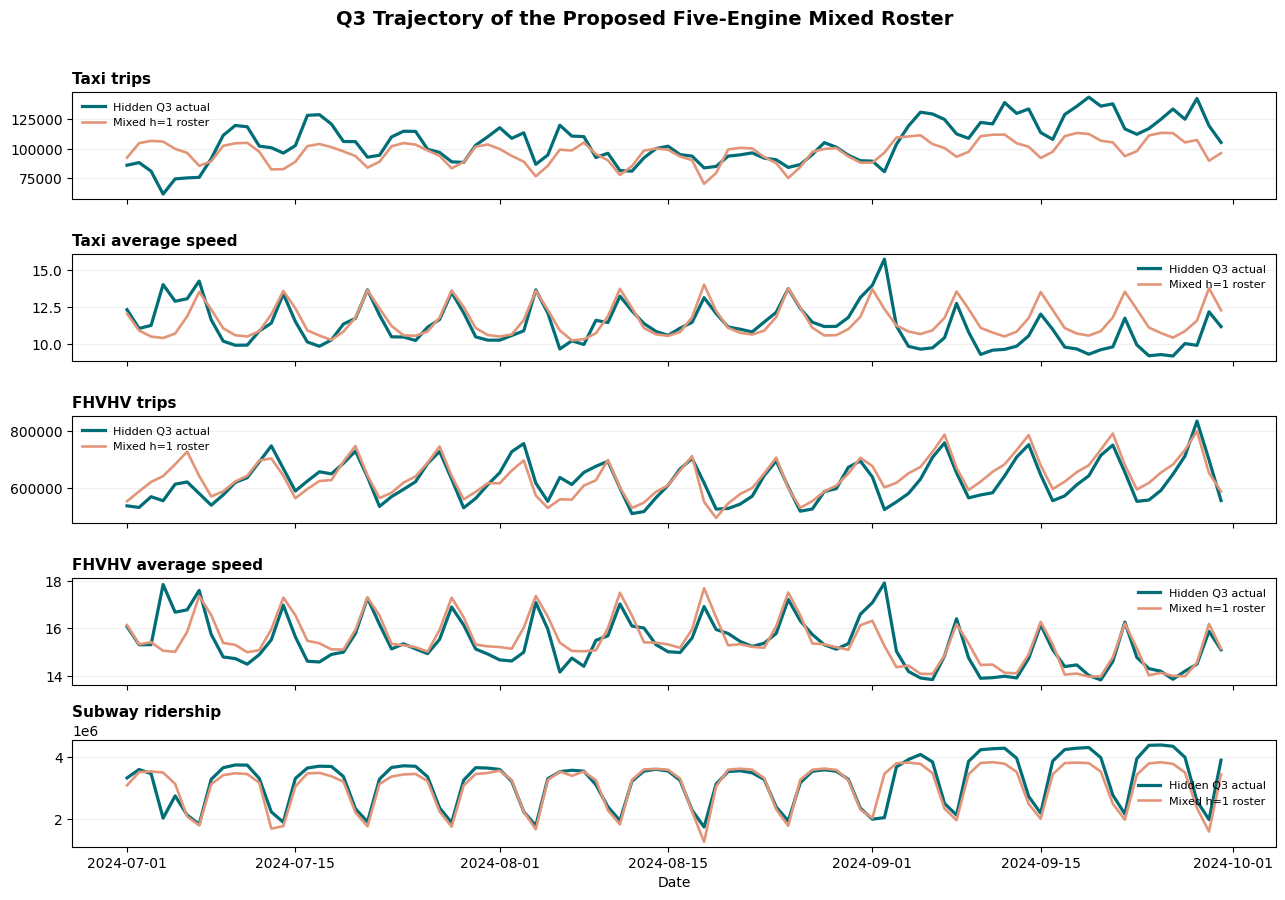

PASS — mixed-roster Q3 coupling evidence is complete | signature=nna-nnd-nna-treea-nna


In [139]:
# ---------------------------------------------------------------------
# 5.1.1.6J — Run/recover the mixed roster and measure coupling effects
# ---------------------------------------------------------------------

if RESET_H1_Q3_MIXED_ROSTER:
    reset_h1_mixed_q3()

    print(
        "RESET — current provisional mixed-roster Q3 artifacts removed.",
        flush=True,
    )


if h1_mixed_q3_complete():
    h1_q3_mixed_df = pd.read_parquet(
        H1_Q3_MIXED_TRAJECTORY_PATH
    )

    print(
        "RECOVER — complete mixed-roster Q3 trajectory loaded; "
        "no fitting or rollout required.",
        flush=True,
    )

elif RUN_H1_Q3_MIXED_ROSTER:
    h1_q3_mixed_df = run_h1_mixed_q3()

else:
    h1_q3_mixed_df = None

    print(
        "PENDING — mixed-roster Q3 has not run. Set "
        "RUN_H1_Q3_MIXED_ROSTER=True when the provisional roster "
        "is ready for its coupling test.",
        flush=True,
    )


if h1_q3_mixed_df is not None:
    selected_candidate_ids = (
        roster_ordered_df["h1_candidate_id"]
        .astype(str)
        .tolist()
    )

    source_selected_df = pd.read_parquet(
        H1_Q3_TRAJECTORY_PATH,
        columns=[
            "h1_candidate_id",
            "target_observation_sequence_id",
            "forecast_sequence_id",
            "system_prediction",
            "benchmark_fallback_used",
        ],
        filters=[
            ("h1_candidate_id", "in", selected_candidate_ids),
        ],
    ).rename(columns={
        "system_prediction": "source_prediction",
        "benchmark_fallback_used": "source_fallback",
    })

    comparison_key = [
        "h1_candidate_id",
        "target_observation_sequence_id",
        "forecast_sequence_id",
    ]

    coupling_rows_df = h1_q3_mixed_df.merge(
        source_selected_df,
        on=comparison_key,
        how="inner",
        validate="one_to_one",
    )

    if len(coupling_rows_df) != H1_Q3_MIXED_EXPECTED_ROWS:
        raise RuntimeError(
            f"Mixed/source comparison has {len(coupling_rows_df):,} rows; "
            f"expected {H1_Q3_MIXED_EXPECTED_ROWS:,}."
        )

    coupling_rows_df["target_date"] = pd.to_datetime(
        coupling_rows_df["target_date"]
    ).dt.normalize()

    for column in [
        "target_observed_value",
        "system_prediction",
        "source_prediction",
    ]:
        coupling_rows_df[column] = pd.to_numeric(
            coupling_rows_df[column],
            errors="coerce",
        )

    coupling_rows_df["mixed_absolute_error"] = (
        coupling_rows_df["system_prediction"]
        - coupling_rows_df["target_observed_value"]
    ).abs()

    coupling_rows_df["source_absolute_error"] = (
        coupling_rows_df["source_prediction"]
        - coupling_rows_df["target_observed_value"]
    ).abs()

    coupling_rows_df["mixed_signed_error"] = (
        coupling_rows_df["system_prediction"]
        - coupling_rows_df["target_observed_value"]
    )

    max_rollout_step = int(
        coupling_rows_df["rollout_step"].max()
    )

    early_end = int(
        np.ceil(max_rollout_step / 3)
    )

    late_start = (
        int(np.floor(2 * max_rollout_step / 3))
        + 1
    )

    coupling_rows_df["week_start"] = (
        coupling_rows_df["target_date"]
        - pd.to_timedelta(
            coupling_rows_df["target_date"].dt.weekday,
            unit="D",
        )
    )


    def relative_mae_pct(frame, error_column):
        """Return project-consistent Relative MAE on one fixed scoring frame."""
        denominator = frame["target_observed_value"].abs().sum()

        return (
            100.0 * frame[error_column].sum() / denominator
            if denominator > 0
            else np.nan
        )


    comparison_rows = []

    for metric_index, metric in enumerate(FORECAST_TARGETS):
        frame = coupling_rows_df.loc[
            coupling_rows_df["metric"].eq(metric)
            & coupling_rows_df["target_observed_value"].notna()
        ].copy()

        early = frame.loc[
            frame["rollout_step"].le(early_end)
        ]

        late = frame.loc[
            frame["rollout_step"].ge(late_start)
        ]

        source_relative_mae = relative_mae_pct(
            frame,
            "source_absolute_error",
        )

        mixed_relative_mae = relative_mae_pct(
            frame,
            "mixed_absolute_error",
        )

        source_late_minus_early = (
            relative_mae_pct(late, "source_absolute_error")
            - relative_mae_pct(early, "source_absolute_error")
        )

        mixed_late_minus_early = (
            relative_mae_pct(late, "mixed_absolute_error")
            - relative_mae_pct(early, "mixed_absolute_error")
        )

        weekly = (
            frame
            .groupby("week_start", as_index=False, observed=True)
            .agg(
                evaluation_rows=("mixed_absolute_error", "size"),
                source_error_sum=("source_absolute_error", "sum"),
                mixed_error_sum=("mixed_absolute_error", "sum"),
            )
        )

        weekly["mixed_minus_source_error_sum"] = (
            weekly["mixed_error_sum"]
            - weekly["source_error_sum"]
        )

        point_change, ci_low, ci_high = paired_week_mae_interval(
            weekly,
            "mixed_minus_source_error_sum",
            H1_Q3_BOOTSTRAP_SEED + 10_000 + metric_index,
        )

        coupling_status = (
            "clear degradation"
            if ci_low > 0
            else "clear improvement"
            if ci_high < 0
            else "no clear change"
        )

        roster_row = roster_ordered_df.loc[
            roster_ordered_df["metric"].eq(metric)
        ].iloc[0]

        comparison_rows.append({
            "selection_contract_id": H1_Q3_SELECTION_CONTRACT_ID,
            "roster_signature": H1_MIXED_ROSTER_SIGNATURE,
            "metric": metric,
            "family": roster_row["family"],
            "formulation": roster_row["formulation"],
            "h1_candidate_id": roster_row["h1_candidate_id"],
            "source_relative_mae_pct": source_relative_mae,
            "mixed_relative_mae_pct": mixed_relative_mae,
            "mixed_minus_source_relative_mae_pp": (
                mixed_relative_mae - source_relative_mae
            ),
            "source_late_minus_early_relative_mae_pp": (
                source_late_minus_early
            ),
            "mixed_late_minus_early_relative_mae_pp": (
                mixed_late_minus_early
            ),
            "mixed_signed_bias": float(
                frame["mixed_signed_error"].mean()
            ),
            "mixed_fallback_rate_pct": (
                100.0
                * frame["benchmark_fallback_used"]
                .fillna(False)
                .astype(bool)
                .mean()
            ),
            "point_mae_change_native": point_change,
            "ci_low_mae_change_native": ci_low,
            "ci_high_mae_change_native": ci_high,
            "coupling_status": coupling_status,
            "calendar_week_blocks": len(weekly),
        })


    h1_q3_mixed_comparison_df = pd.DataFrame(
        comparison_rows
    )

    atomic_write_parquet(
        h1_q3_mixed_comparison_df,
        H1_Q3_MIXED_COMPARISON_PATH,
    )


    coupling_display_df = (
        h1_q3_mixed_comparison_df
        .assign(Target=lambda frame: frame["metric"].map(TARGET_LABELS))
        [
            [
                "Target", "family", "formulation",
                "source_relative_mae_pct", "mixed_relative_mae_pct",
                "mixed_minus_source_relative_mae_pp",
                "mixed_late_minus_early_relative_mae_pp",
                "mixed_fallback_rate_pct", "coupling_status",
            ]
        ]
        .rename(columns={
            "family": "Family",
            "formulation": "Formulation",
            "source_relative_mae_pct": "Source Relative MAE (%)",
            "mixed_relative_mae_pct": "Mixed Relative MAE (%)",
            "mixed_minus_source_relative_mae_pp": "Mixed − source (pp)",
            "mixed_late_minus_early_relative_mae_pp": "Mixed late − early (pp)",
            "mixed_fallback_rate_pct": "Mixed fallback (%)",
            "coupling_status": "Weekly coupling evidence",
        })
    )

    display(coupling_display_df.round(3))


    # Reuse the daily aggregation contract from 6D. This gives the decision
    # point one direct visual of the synthetic system that would actually feed
    # the next Daypart if the provisional roster were frozen.
    fig, axes = plt.subplots(
        len(FORECAST_TARGETS),
        1,
        figsize=(13, 9),
        sharex=True,
    )

    for ax, metric in zip(axes, FORECAST_TARGETS):
        actual_daily = aggregate_daily_mobility(
            h1_q3_mixed_df,
            metric,
            "target_observed_value",
        )

        mixed_daily = aggregate_daily_mobility(
            h1_q3_mixed_df,
            metric,
            "system_prediction",
        )

        ax.plot(
            actual_daily["target_date"],
            actual_daily["value"],
            color=BRAND_COLORS["dark_teal"],
            linewidth=2.3,
            label="Hidden Q3 actual",
        )

        ax.plot(
            mixed_daily["target_date"],
            mixed_daily["value"],
            color=BRAND_COLOR_SEQUENCE[1],
            linewidth=1.9,
            label="Mixed h=1 roster",
        )

        ax.set_title(
            TARGET_LABELS[metric],
            loc="left",
            fontsize=11,
            fontweight="bold",
        )

        ax.grid(axis="y", alpha=0.2)
        ax.legend(frameon=False, fontsize=8)

    axes[-1].set_xlabel("Date")

    fig.suptitle(
        "Q3 Trajectory of the Proposed Five-Engine Mixed Roster",
        fontsize=14,
        fontweight="bold",
        y=0.995,
    )

    fig.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


    print(
        "PASS — mixed-roster Q3 coupling evidence is complete | "
        f"signature={H1_MIXED_ROSTER_SIGNATURE}",
        flush=True,
    )

**Findings.** Coupling the five provisional winners does not create a new recursive failure. Relative MAE changes by less than 0.2 percentage points for every target, and none shows statistically clear degradation in the paired-week comparison.

Taxi speed and Subway actually improve after mixing, while Taxi trips, FHVHV trips, and FHVHV speed show no clear change. All five channels continue with 0% fallback. The mixed trajectories also preserve the same broad Q3 patterns seen in their source systems, so the independently selected leaders remain compatible when they share one synthetic mobility world.

### 5.1.1.6K — Put the five provisional winners on one decision scorecard

The mixed-roster run answers the last question that the original candidate tournament could not: **do the five target-level leaders still work when they have to share the same synthetic world?**

This scorecard brings the evidence together without inventing a new weighted score. The original Q3 accuracy still tells us which candidate led each target, while rollout stability, trajectory shape, fallback, uncertainty, and the mixed-roster test tell us whether that lead remains trustworthy in the system we would actually use.

The five candidates are still provisional at this point. The purpose of this block is to make the final h=1 decision transparent before anything is frozen.

In [141]:
# ---------------------------------------------------------------------
# 5.1.1.6K — Build the decision-ready h=1 winner scorecard
# ---------------------------------------------------------------------

H1_Q3_DECISION_SCORECARD_PATH = (
    INTERMEDIATE_DIR / "recursive_h1_q3_decision_scorecard.parquet"
)

provisional_df = pd.read_parquet(H1_Q3_PROVISIONAL_ROSTER_PATH)
mixed_comparison_df = pd.read_parquet(H1_Q3_MIXED_COMPARISON_PATH)


# The provisional table carries the evidence that produced each target-level
# leader. The mixed comparison adds the one result that could not be known
# until those five leaders were allowed to interact in the same synthetic world.
decision_scorecard_df = provisional_df.merge(
    mixed_comparison_df[
        [
            "metric", "family", "formulation", "h1_candidate_id",
            "roster_signature", "source_relative_mae_pct",
            "mixed_relative_mae_pct",
            "mixed_minus_source_relative_mae_pp",
            "mixed_late_minus_early_relative_mae_pp",
            "mixed_signed_bias", "mixed_fallback_rate_pct",
            "coupling_status", "calendar_week_blocks",
        ]
    ],
    on=["metric", "family", "formulation", "h1_candidate_id"],
    how="inner",
    validate="one_to_one",
)


# Exactly five rows should survive: one provisional winner for each state channel.
if len(decision_scorecard_df) != len(FORECAST_TARGETS):
    raise RuntimeError(
        "The h=1 decision scorecard must contain exactly one candidate "
        "for each of the five mobility targets."
    )

if set(decision_scorecard_df["metric"]) != set(FORECAST_TARGETS):
    raise RuntimeError(
        "The h=1 decision scorecard does not contain the exact five "
        "forecasting targets."
    )


# 6J rescored the same source trajectory before comparing it with the mixed
# trajectory. Agreement here proves that coupling analysis did not silently
# change the Q3 scoring denominator.
source_scores_match = np.allclose(
    decision_scorecard_df["relative_mae_pct"].to_numpy(dtype=float),
    decision_scorecard_df["source_relative_mae_pct"].to_numpy(dtype=float),
    rtol=1e-9,
    atol=1e-9,
    equal_nan=True,
)

if not source_scores_match:
    raise RuntimeError(
        "The source-system Relative MAE changed between the Q3 scorecard "
        "and the mixed-roster comparison."
    )


decision_scorecard_df["clear_coupling_degradation"] = (
    decision_scorecard_df["coupling_status"].eq("clear degradation")
)

atomic_write_parquet(
    decision_scorecard_df,
    H1_Q3_DECISION_SCORECARD_PATH,
)


decision_display_df = (
    decision_scorecard_df
    .assign(Target=lambda frame: frame["metric"].map(TARGET_LABELS))
    [
        [
            "Target", "family", "formulation_label",
            "relative_mae_pct", "mixed_relative_mae_pct",
            "mixed_minus_source_relative_mae_pp",
            "mixed_late_minus_early_relative_mae_pp",
            "mixed_fallback_rate_pct", "daily_shape_correlation",
            "close_challengers", "coupling_status",
        ]
    ]
    .rename(columns={
        "family": "Family",
        "formulation_label": "Formulation",
        "relative_mae_pct": "Source Q3 Rel. MAE (%)",
        "mixed_relative_mae_pct": "Mixed Q3 Rel. MAE (%)",
        "mixed_minus_source_relative_mae_pp": "Mixing change (pp)",
        "mixed_late_minus_early_relative_mae_pp": "Mixed late − early (pp)",
        "mixed_fallback_rate_pct": "Mixed fallback (%)",
        "daily_shape_correlation": "Daily shape correlation",
        "close_challengers": "Close challengers",
        "coupling_status": "Coupling evidence",
    })
    .sort_values("Target")
)

display(decision_display_df.round(3))

degraded_targets = decision_scorecard_df.loc[
    decision_scorecard_df["clear_coupling_degradation"],
    "metric",
].map(TARGET_LABELS).tolist()

print(
    "Decision scorecard ready | "
    f"targets={len(decision_scorecard_df)} | "
    f"clear coupling degradations={len(degraded_targets)}",
    flush=True,
)

if degraded_targets:
    print(
        "Review required before freezing h=1: "
        + ", ".join(degraded_targets),
        flush=True,
    )

,Target,Family,Formulation,Source Q3 Rel. MAE (%),Mixed Q3 Rel. MAE (%),Mixing change (pp),Mixed late − early (pp),Mixed fallback (%),Daily shape correlation,Close challengers,Coupling evidence
0,FHVHV average speed,tree,Anchor + residual,6.138,6.135,-0.002,0.293,0.0,0.802,1,no clear change
1,FHVHV trips,neural,Anchor + residual,12.099,12.143,0.044,0.280,0.0,0.852,1,no clear change
2,Subway ridership,neural,Anchor + residual,12.651,12.472,-0.180,2.059,0.0,0.913,0,clear improvement
3,Taxi average speed,neural,Direct level,18.134,18.048,-0.086,0.221,0.0,0.694,3,clear improvement
4,Taxi trips,neural,Anchor + residual,19.539,19.489,-0.050,1.192,0.0,0.662,1,no clear change


Decision scorecard ready | targets=5 | clear coupling degradations=0


**Findings.** The combined decision scorecard contains no coupling red flag. All five provisional winners retain essentially the same Q3 accuracy after mixing, no target requires fallback, and none shows clear coupling degradation.

The remaining cautions are therefore the same ones already visible before mixing: Taxi has more close alternatives and weaker trajectory-shape agreement than the other targets, while Subway shows somewhat greater late-rollout deterioration. Neither issue worsens when the five engines are coupled together.

### 5.1.1.6L — Check the selected Taxi engine at the individual-zone level

Systemwide averages can hide very different local behavior. Before freezing the h=1 roster, it is useful to look one level deeper and ask whether the selected Taxi-trip engine still follows real movement patterns at the individual Taxi Zone level.

The examples below are **not hand-picked for attractive results**. Six fully supported zones are selected at evenly spaced positions across the Q3 zone-level error distribution, from a comparatively easy case through a deliberate stress case. That makes the figure an interpretability check rather than another model-selection contest.

These examples do not rerank the candidates. They show what the proposed mixed system looks like at the finest geography used by the forecasting panel and preserve a reusable set of illustrative zones for the later Showcase.

,Taxi Zone,Example role,Q3 rows,Observed Q3 trips,Q3 Relative MAE (%)
0,68,Low error,460,273370.0,13.72
49,158,Lower-middle,460,103730.0,23.53
99,51,Middle,460,1392.0,57.55
148,136,Upper-middle,460,575.0,72.80
198,102,High error,460,597.0,111.83
247,84,Stress case,460,2.0,6368.92


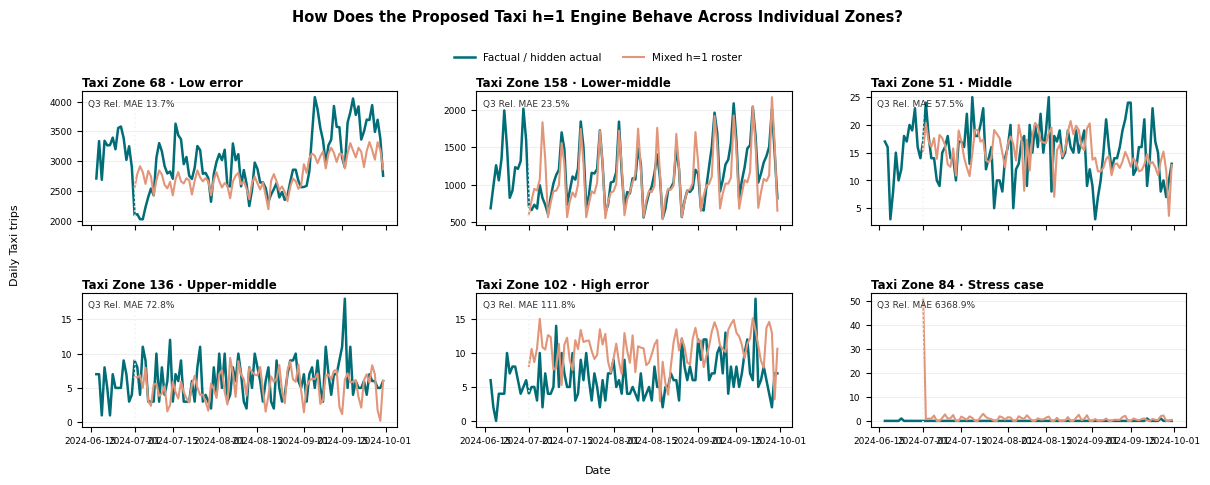

35073

In [143]:
# ---------------------------------------------------------------------
# 5.1.1.6L — Inspect six representative Taxi Zone trajectories
# ---------------------------------------------------------------------

H1_Q3_TAXI_ZONE_EXAMPLES_PATH = (
    INTERMEDIATE_DIR / "recursive_h1_q3_taxi_zone_examples.parquet"
)

TAXI_ZONE_EXAMPLE_COUNT = 6
TAXI_ZONE_CONTEXT_DAYS = 14


# Work directly from the mixed world that is under consideration for the
# final h=1 roster. Taxi trips are additive, so Dayparts can be summed into
# daily zone totals without introducing a weighting convention.
taxi_zone_q3_df = pd.read_parquet(
    H1_Q3_MIXED_TRAJECTORY_PATH,
    columns=[
        "taxi_zone_id", "metric", "target_observation_sequence_id",
        "target_date", "target_observed_value", "system_prediction",
    ],
    filters=[("metric", "==", "taxi_trip_count")],
)

taxi_zone_q3_df["target_date"] = pd.to_datetime(
    taxi_zone_q3_df["target_date"]
).dt.normalize()

for column in ["target_observed_value", "system_prediction"]:
    taxi_zone_q3_df[column] = pd.to_numeric(
        taxi_zone_q3_df[column], errors="coerce"
    )

taxi_zone_q3_df = taxi_zone_q3_df.loc[
    taxi_zone_q3_df["target_observed_value"].notna()
    & taxi_zone_q3_df["system_prediction"].notna()
].copy()

taxi_zone_q3_df["absolute_error"] = (
    taxi_zone_q3_df["system_prediction"]
    - taxi_zone_q3_df["target_observed_value"]
).abs()


# Rank zones using the project-consistent Relative MAE definition. Requiring
# the maximum observed row count keeps the six examples on common Q3 support.
taxi_zone_quality_df = (
    taxi_zone_q3_df
    .groupby("taxi_zone_id", as_index=False, observed=True)
    .agg(
        evaluation_rows=("absolute_error", "size"),
        actual_trip_total=("target_observed_value", "sum"),
        absolute_error_sum=("absolute_error", "sum"),
    )
)

taxi_zone_quality_df["relative_mae_pct"] = (
    100.0
    * taxi_zone_quality_df["absolute_error_sum"]
    / taxi_zone_quality_df["actual_trip_total"]
)

max_zone_rows = int(taxi_zone_quality_df["evaluation_rows"].max())

eligible_zone_df = (
    taxi_zone_quality_df.loc[
        taxi_zone_quality_df["evaluation_rows"].eq(max_zone_rows)
        & taxi_zone_quality_df["actual_trip_total"].gt(0)
        & taxi_zone_quality_df["relative_mae_pct"].notna()
    ]
    .sort_values(["relative_mae_pct", "taxi_zone_id"])
    .reset_index(drop=True)
)

if len(eligible_zone_df) < TAXI_ZONE_EXAMPLE_COUNT:
    raise RuntimeError(
        "Fewer than six fully supported Taxi Zones are available for the "
        "granular h=1 trajectory check."
    )


# Evenly spaced ranks deliberately cover the error distribution instead of
# selecting only the easiest-looking zones.
selection_positions = np.round(
    np.linspace(
        0,
        len(eligible_zone_df) - 1,
        TAXI_ZONE_EXAMPLE_COUNT,
    )
).astype(int)

selection_bands = [
    "Low error",
    "Lower-middle",
    "Middle",
    "Upper-middle",
    "High error",
    "Stress case",
]

taxi_zone_examples_df = eligible_zone_df.iloc[
    selection_positions
].copy()

taxi_zone_examples_df["selection_band"] = selection_bands
taxi_zone_examples_df["error_percentile"] = (
    100.0
    * taxi_zone_examples_df["relative_mae_pct"].rank(
        method="average",
        pct=True,
    )
)

selected_zone_ids = taxi_zone_examples_df["taxi_zone_id"].astype(int).tolist()

atomic_write_parquet(
    taxi_zone_examples_df,
    H1_Q3_TAXI_ZONE_EXAMPLES_PATH,
)


taxi_zone_examples_display_df = (
    taxi_zone_examples_df[
        [
            "taxi_zone_id", "selection_band", "evaluation_rows",
            "actual_trip_total", "relative_mae_pct",
        ]
    ]
    .rename(columns={
        "taxi_zone_id": "Taxi Zone",
        "selection_band": "Example role",
        "evaluation_rows": "Q3 rows",
        "actual_trip_total": "Observed Q3 trips",
        "relative_mae_pct": "Q3 Relative MAE (%)",
    })
)

display(taxi_zone_examples_display_df.round(2))


# Add two factual weeks before Q3 so the synthetic handoff is visible rather
# than placing the first model-generated point directly against the left edge.
q3_start_date = taxi_zone_q3_df["target_date"].min()
q3_first_target_id = int(
    taxi_zone_q3_df["target_observation_sequence_id"].min()
)

history_first_target_id = max(
    1,
    q3_first_target_id - TAXI_ZONE_CONTEXT_DAYS * 5,
)

taxi_zone_history_df = pd.read_parquet(
    PRE_CP_HISTORICAL_FORECASTING_MATRIX_PATH,
    columns=[
        "taxi_zone_id", "metric", "target_observation_sequence_id",
        "target_date", "target_observed_value",
    ],
    filters=[
        ("modeling_track", "==", CHAPTER5_MODELING_TRACK),
        ("horizon", "==", 1),
        ("metric", "==", "taxi_trip_count"),
        ("target_observation_sequence_id", ">=", history_first_target_id),
        ("target_observation_sequence_id", "<", q3_first_target_id),
    ],
)

taxi_zone_history_df["target_date"] = pd.to_datetime(
    taxi_zone_history_df["target_date"]
).dt.normalize()

taxi_zone_history_df["target_observed_value"] = pd.to_numeric(
    taxi_zone_history_df["target_observed_value"],
    errors="coerce",
)

taxi_zone_history_df = taxi_zone_history_df.loc[
    taxi_zone_history_df["taxi_zone_id"].isin(selected_zone_ids)
    & taxi_zone_history_df["target_observed_value"].notna()
].copy()


# Daily aggregation makes six zone-level trajectories readable without hiding
# the full closed-loop Q3 period behind five separate Daypart lines.
taxi_zone_q3_daily_df = (
    taxi_zone_q3_df.loc[
        taxi_zone_q3_df["taxi_zone_id"].isin(selected_zone_ids)
    ]
    .groupby(
        ["taxi_zone_id", "target_date"],
        as_index=False,
        observed=True,
    )
    .agg(
        actual_trips=("target_observed_value", "sum"),
        predicted_trips=("system_prediction", "sum"),
    )
)

taxi_zone_history_daily_df = (
    taxi_zone_history_df
    .groupby(
        ["taxi_zone_id", "target_date"],
        as_index=False,
        observed=True,
    )
    .agg(actual_trips=("target_observed_value", "sum"))
)


fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 4.8),
    sharex=True,
)

axes = axes.ravel()

for ax, zone_row in zip(
    axes,
    taxi_zone_examples_df.itertuples(index=False),
):
    zone_id = int(zone_row.taxi_zone_id)

    historical = taxi_zone_history_daily_df.loc[
        taxi_zone_history_daily_df["taxi_zone_id"].eq(zone_id)
    ].sort_values("target_date")

    q3_zone = taxi_zone_q3_daily_df.loc[
        taxi_zone_q3_daily_df["taxi_zone_id"].eq(zone_id)
    ].sort_values("target_date")


    # Build the factual line across the boundary without relying on DataFrame
    # block concatenation between the historical and Q3 aggregation paths.
    factual_path = pd.DataFrame({
        "target_date": np.concatenate([
            historical["target_date"].to_numpy(),
            q3_zone["target_date"].to_numpy(),
        ]),
        "actual_trips": np.concatenate([
            historical["actual_trips"].to_numpy(dtype=float),
            q3_zone["actual_trips"].to_numpy(dtype=float),
        ]),
    }).sort_values("target_date")


    ax.plot(
        factual_path["target_date"],
        factual_path["actual_trips"],
        color=BRAND_COLORS["dark_teal"],
        linewidth=1.8,
        label="Factual / hidden actual",
    )

    ax.plot(
        q3_zone["target_date"],
        q3_zone["predicted_trips"],
        color=BRAND_COLOR_SEQUENCE[1],
        linewidth=1.5,
        label="Mixed h=1 roster",
    )

    ax.axvline(
        q3_start_date,
        color=BRAND_COLOR_SEQUENCE[-1],
        linestyle=":",
        linewidth=1.2,
    )

    ax.set_title(
        f"Taxi Zone {zone_id} · {zone_row.selection_band}",
        loc="left",
        fontsize=8.5,
        fontweight="bold",
        pad=3,
    )

    ax.text(
        0.02,
        0.94,
        f"Q3 Rel. MAE {zone_row.relative_mae_pct:.1f}%",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=6.5,
        alpha=0.8,
    )

    ax.tick_params(axis="both", labelsize=6.5)
    ax.grid(axis="y", alpha=0.2)


handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.92),
    ncol=2,
    frameon=False,
    fontsize=7.5,
)

fig.suptitle(
    "How Does the Proposed Taxi h=1 Engine Behave Across Individual Zones?",
    fontsize=10.5,
    fontweight="bold",
    y=0.99,
)

fig.supxlabel("Date", fontsize=8, y=0.02)
fig.supylabel("Daily Taxi trips", fontsize=8, x=0.01)

fig.subplots_adjust(
    left=0.07,
    right=0.99,
    bottom=0.12,
    top=0.82,
    hspace=0.50,
    wspace=0.25,
)

plt.show()


del taxi_zone_q3_df, taxi_zone_history_df
gc.collect()

**Findings.** The zone-level examples show why aggregate accuracy and local accuracy should be read together. In high-volume examples such as Taxi Zones 68 and 158, the mixed h=1 path follows the main daily pattern reasonably well. Performance becomes much noisier in very low-volume zones.

The extreme 6,368.9% Relative MAE in the stress example comes from a zone with only two observed Q3 trips, so the percentage denominator is too small for that number to be interpreted like the citywide results. This does not change the h=1 ranking, but later Showcase examples should focus on materially active zones so a tiny denominator does not dominate the story.

### 5.1.1.6M — Decision: freeze the five h=1 state engines

This is the first true model-choice decision in the counterfactual pipeline.

The five target-level leaders have now been tested twice: first inside their original family/formulation systems, and then together inside the mixed synthetic world they would actually create. The scorecard summarizes whether that coupling materially changed accuracy, late-rollout behavior, or fallback use, while the zone examples provide a final granular check of the selected Taxi-trip path.

The zone examples are interpretive evidence, not a new ranking rule. The decision remains grounded in the full Q3 evidence assembled above.

In [145]:
# ---------------------------------------------------------------------
# 5.1.1.6M — Freeze the five selected h=1 state engines
# ---------------------------------------------------------------------

H1_Q3_SELECTED_ROSTER_PATH = (
    INTERMEDIATE_DIR / "recursive_h1_q3_selected_roster.parquet"
)

H1_FROZEN_SELECTION_CONTRACT_ID = (
    f"{H1_Q3_SELECTION_CONTRACT_ID}__h1_frozen_v1"
)

# This is an explicit analytical decision rather than an execution toggle.
# Leave False until the Q3 scorecard, coupling evidence, and granular check
# above have been reviewed.
APPROVE_H1_Q3_ROSTER = True


decision_scorecard_df = pd.read_parquet(
    H1_Q3_DECISION_SCORECARD_PATH
)

clear_degradation_df = decision_scorecard_df.loc[
    decision_scorecard_df["coupling_status"].eq("clear degradation")
]

if not clear_degradation_df.empty:
    affected_targets = (
        clear_degradation_df["metric"]
        .map(TARGET_LABELS)
        .tolist()
    )

    raise RuntimeError(
        "The provisional mixed roster shows clear coupling degradation for: "
        + ", ".join(affected_targets)
        + ". Review a small defensible alternative set before freezing h=1."
    )


if APPROVE_H1_Q3_ROSTER:
    h1_selected_roster_df = decision_scorecard_df.copy()

    h1_selected_roster_df["horizon"] = 1
    h1_selected_roster_df["selection_status"] = "frozen_q3_h1_winner"
    h1_selected_roster_df["decision_contract_id"] = (
        H1_FROZEN_SELECTION_CONTRACT_ID
    )

    selected_columns = [
        "decision_contract_id",
        "selection_contract_id",
        "selection_status",
        "metric",
        "horizon",
        "family",
        "formulation",
        "formulation_label",
        "h1_candidate_id",
        "candidate_id",
        "source_configuration_id",
        "chapter5_modeling_track",
        "roster_signature",
        "system_mae",
        "relative_mae_pct",
        "mixed_relative_mae_pct",
        "mixed_minus_source_relative_mae_pp",
        "mixed_late_minus_early_relative_mae_pp",
        "mixed_signed_bias",
        "mixed_fallback_rate_pct",
        "coupling_status",
        "close_challengers",
    ]

    h1_selected_roster_df = (
        h1_selected_roster_df[selected_columns]
        .sort_values("metric")
        .reset_index(drop=True)
    )


    # The downstream h=2/h=5 stage needs exactly one frozen state engine for
    # every target. Duplicates or omissions would make the synthetic world
    # ambiguous, so fail before publishing the contract.
    if len(h1_selected_roster_df) != len(FORECAST_TARGETS):
        raise RuntimeError(
            "The frozen h=1 roster must contain exactly five rows."
        )

    if h1_selected_roster_df["metric"].nunique() != len(FORECAST_TARGETS):
        raise RuntimeError(
            "The frozen h=1 roster must contain exactly one row per target."
        )

    if set(h1_selected_roster_df["metric"]) != set(FORECAST_TARGETS):
        raise RuntimeError(
            "The frozen h=1 roster does not contain the exact five targets."
        )


    atomic_write_parquet(
        h1_selected_roster_df,
        H1_Q3_SELECTED_ROSTER_PATH,
    )


    h1_selected_display_df = (
        h1_selected_roster_df
        .assign(Target=lambda frame: frame["metric"].map(TARGET_LABELS))
        [
            [
                "Target", "family", "formulation_label",
                "mixed_relative_mae_pct",
                "mixed_minus_source_relative_mae_pp",
                "mixed_fallback_rate_pct",
                "coupling_status",
            ]
        ]
        .rename(columns={
            "family": "Family",
            "formulation_label": "Formulation",
            "mixed_relative_mae_pct": "Mixed Q3 Rel. MAE (%)",
            "mixed_minus_source_relative_mae_pp": "Mixing change (pp)",
            "mixed_fallback_rate_pct": "Mixed fallback (%)",
            "coupling_status": "Coupling evidence",
        })
    )

    display(h1_selected_display_df.round(3))

    print(
        "DECISION — five h=1 state engines frozen | "
        f"contract={H1_FROZEN_SELECTION_CONTRACT_ID}",
        flush=True,
    )

else:
    print(
        "DECISION PENDING — review the Q3 winner scorecard and granular "
        "trajectory evidence, then set APPROVE_H1_Q3_ROSTER=True to freeze "
        "the five h=1 engines.",
        flush=True,
    )


,Target,Family,Formulation,Mixed Q3 Rel. MAE (%),Mixing change (pp),Mixed fallback (%),Coupling evidence
0,FHVHV average speed,tree,Anchor + residual,6.135,-0.002,0.0,no clear change
1,FHVHV trips,neural,Anchor + residual,12.143,0.044,0.0,no clear change
2,Subway ridership,neural,Anchor + residual,12.472,-0.180,0.0,clear improvement
3,Taxi average speed,neural,Direct level,18.048,-0.086,0.0,clear improvement
4,Taxi trips,neural,Anchor + residual,19.489,-0.050,0.0,no clear change


DECISION — five h=1 state engines frozen | contract=recursive_h1_q3_selection_v1__h1_frozen_v1


**Findings.** The five selected h=1 engines remain healthy after they are combined into one shared synthetic mobility world. None of the targets becomes less reliable because of mixing, and all five continue to produce their Q3 forecasts without fallback.

The final roster uses Neural + Anchor for Taxi trips, FHVHV trips, and Subway ridership; Neural + Direct for Taxi average speed; and Tree + Anchor for FHVHV average speed. Mixed-world Relative MAE ranges from 6.1% for FHVHV speed to 19.5% for Taxi trips.

The coupling test is reassuring rather than merely neutral. Taxi speed and Subway improve clearly after mixing, while the other three targets show no clear change. This gives us no evidence that the five independently selected engines interfere with one another when they share the recursive state.

### Section Summary ###

Q3 testing reduced the 40 h=1 candidates to five target-specific state engines, then tested those five together in the shared synthetic world they will actually create.

The final system freezes Neural + Anchor for Taxi trips, FHVHV trips, and Subway ridership; Neural + Direct for Taxi average speed; and Tree + Anchor for FHVHV average speed. The mixed roster showed no clear coupling degradation and required no fallback, so these five engines now define the authoritative h=1 synthetic mobility state.

The h=1 decision is therefore complete. Section 7 does not reopen it. Instead, it uses this frozen state system to create the historical synthetic environments needed to train and select the read-only h=2 and h=5 forecast heads. Q4 remains unopened.

## 5.1.1.7 — Select the Read-Only h=2 and h=5 Forecast Heads

The h=1 system is now frozen. Its five selected engines define the synthetic mobility history used by the rest of the counterfactual system.

The farther horizons have a simpler role. h=2 and h=5 look ahead from that h=1-created world, but their predictions never become future state. Because they cannot change the recursive trajectory, Section 7 does not reopen the Direct-level versus Anchor + residual decision made for h=1.

Instead, each h=2/h=5 candidate keeps the forecasting recipe already frozen for its family in Chapter 4 and packaged by 4.7.1. That includes any family-specific representation, scaling, differencing, residualization, architecture, or other modeling choice already established upstream.

The competition is therefore:

**4 model families × 5 mobility targets × 2 farther horizons = 40 candidate heads.**

The only new requirement is that these heads learn and compete in the same type of synthetic-history environment in which they will later operate. We therefore recreate the four historical training rehearsals using the final mixed h=1 roster, then use those worlds to construct the h=2/h=5 training examples.

Q3 uses the mixed h=1 world already validated in Section 6. Q4 remains unopened.

**5.1.1.7A — Define the 40 farther-horizon candidates**

The farther-horizon tournament starts from the same 4.7.1 candidate registry already used throughout this notebook.

We keep exactly one candidate from each model family for every Target × Horizon job at h=2 and h=5. Section 7 does not invent another prediction formulation or reopen any Chapter 4 family design.

This leaves 40 candidates competing for ten jobs.

In [149]:
# ---------------------------------------------------------------------
# 5.1.1.7A — Define the 40 read-only h=2 / h=5 candidates
# ---------------------------------------------------------------------

FAR_HORIZONS = (2, 5)
FAR_HORIZON_CONTRACT_ID = (
    f"{H1_FROZEN_SELECTION_CONTRACT_ID}__h2h5_family_selection_v1"
)

far_horizon_candidate_registry_df = (
    counterfactual_candidate_registry_df.loc[
        counterfactual_candidate_registry_df["horizon"].astype(int).isin(FAR_HORIZONS)
    ]
    .copy()
    .sort_values(["horizon", "metric", "family"])
    .reset_index(drop=True)
)

expected_candidate_count = (
    len(FAMILY_EXECUTION_ORDER) * len(FORECAST_TARGETS) * len(FAR_HORIZONS)
)
expected_jobs = {
    (metric, horizon)
    for metric in FORECAST_TARGETS
    for horizon in FAR_HORIZONS
}
observed_jobs = set(
    far_horizon_candidate_registry_df[["metric", "horizon"]]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)

# These are boundary assertions, not a new model-design exercise. Chapter 4
# already froze the family recipes; Section 7 only verifies that the expected
# 40 candidates arrived intact before using them.
if len(far_horizon_candidate_registry_df) != expected_candidate_count:
    raise RuntimeError(
        f"Expected {expected_candidate_count} h=2/h=5 candidates; "
        f"found {len(far_horizon_candidate_registry_df)}."
    )

if observed_jobs != expected_jobs:
    raise RuntimeError(
        "The farther-horizon registry does not contain the exact ten "
        "Target × Horizon jobs."
    )

if far_horizon_candidate_registry_df.duplicated(
    ["family", "metric", "horizon"]
).any():
    raise RuntimeError(
        "The farther-horizon registry is not unique by Family × Target × Horizon."
    )

far_horizon_candidate_registry_df["far_horizon_contract_id"] = (
    FAR_HORIZON_CONTRACT_ID
)
far_horizon_candidate_registry_df["state_update_allowed"] = False

far_horizon_roster_summary_df = (
    far_horizon_candidate_registry_df
    .groupby(["family", "horizon"], as_index=False, observed=True)
    .agg(
        Targets=("metric", "nunique"),
        Candidates=("candidate_id", "nunique"),
    )
    .rename(columns={"family": "Family", "horizon": "Horizon"})
    .sort_values(["Horizon", "Family"])
    .reset_index(drop=True)
)

display(far_horizon_roster_summary_df)

print(
    "PASS — farther-horizon roster frozen | "
    f"candidates={len(far_horizon_candidate_registry_df)} | "
    "state-updating heads=0",
    flush=True,
)

,Family,Horizon,Targets,Candidates
0,classical,2,5,5
1,neural,2,5,5
2,transformer,2,5,5
3,tree,2,5,5
4,classical,5,5,5
5,neural,5,5,5
6,transformer,5,5,5
7,tree,5,5,5


PASS — farther-horizon roster frozen | candidates=40 | state-updating heads=0


**Findings.** The farther-horizon roster contains exactly 40 candidates: four forecasting families for each of five mobility targets at h=2 and h=5.

No new Direct-versus-Anchor dimension is introduced. Each candidate keeps its existing Chapter 4 family recipe, while all h=2/h=5 predictions remain read-only with respect to the recursive mobility state.

**5.1.1.7B — Recreate the four historical worlds with the final h=1 roster**

Chapter 5 already created historical recursive rehearsals, and Chapter 6 already established which five h=1 engines should define the final synthetic world. We do not repeat either analysis here.

One data product is still missing: the four historical rehearsals generated by that **final mixed roster**.

For each historical pseudo-freeze, we reuse the same episode definition, rollout blocks, synthetic state, restart machinery, benchmark fallback, and legally timed h=1 seed models already built in Chapter 5. The only difference is that the five targets now use the five target-specific engines frozen in Chapter 6 instead of one common Family + formulation system.

These worlds exist only to provide realistic synthetic history for h=2/h=5 training.

In [151]:
# ---------------------------------------------------------------------
# 5.1.1.7B — Run or recover the four final mixed-roster training worlds
# ---------------------------------------------------------------------

RUN_FAR_HORIZON_TRAINING_WORLDS = True
RESET_FAR_HORIZON_TRAINING_WORLDS = False

h1_selected_roster_df = pd.read_parquet(H1_Q3_SELECTED_ROSTER_PATH)

# Reuse the mixed-roster identity and Chapter 5 rollout directories. Episode IDs
# already separate Q3 from the four historical rehearsals, so a second parallel
# checkpoint framework would add complexity without adding information.
selected_metric_order = {
    metric: position
    for position, metric in enumerate(FORECAST_TARGETS)
}

far_h1_roster_df = (
    h1_selected_roster_df
    .assign(_metric_order=lambda frame: frame["metric"].map(selected_metric_order))
    .sort_values("_metric_order")
    .drop(columns="_metric_order")
    .reset_index(drop=True)
)

far_h1_roster_lookup = far_h1_roster_df.set_index("metric").to_dict("index")

if set(far_h1_roster_df["metric"]) != set(FORECAST_TARGETS):
    raise RuntimeError(
        "The frozen h=1 roster no longer contains exactly the five mobility targets."
    )

# The currently frozen roster contains Tree and Neural engines, both of which
# already have episode-specific seed bundles from Chapter 5. If the roster ever
# changes to a family with a different historical execution interface, fail
# explicitly rather than silently switching methodologies.
unsupported_families = (
    set(far_h1_roster_df["family"].astype(str))
    - set(H1_GLOBAL_FAMILIES)
)

if unsupported_families:
    raise RuntimeError(
        "The frozen h=1 roster contains families that do not use the existing "
        f"episode-seed bundle interface: {sorted(unsupported_families)}"
    )


def load_selected_h1_seed_bundles(episode_id: str) -> dict:
    """
    Restore the five selected h=1 engines at one historical pseudo-freeze.

    Each bundle was fitted before that episode began. Reusing those seed states
    preserves the same historical information boundary used by Chapter 5 while
    applying the final target-specific roster chosen in Chapter 6.
    """
    bundles = {}

    for metric in FORECAST_TARGETS:
        selection = far_h1_roster_lookup[metric]
        family = str(selection["family"])
        formulation = str(selection["formulation"])

        model_path = h1_candidate_model_path(
            family,
            formulation,
            metric,
            stage="seed",
            episode_id=episode_id,
        )
        require_file(
            model_path,
            f"{episode_id} · {metric} selected h=1 seed model",
        )

        bundle = load_h1_candidate_bundle(
            family,
            metric,
            formulation,
            model_path,
        )

        if str(bundle["h1_candidate_id"]) != str(selection["h1_candidate_id"]):
            raise RuntimeError(
                f"{episode_id} · {metric}: recovered seed bundle does not "
                "match the frozen h=1 roster."
            )

        bundles[metric] = bundle

    return bundles


def historical_mixed_trajectory_path(episode_id: str) -> Path:
    """Return the consolidated mixed-roster trajectory for one rehearsal."""
    return (
        INTERMEDIATE_DIR
        / f"recursive_h1_{episode_id}_mixed_{H1_MIXED_ROSTER_SIGNATURE}.parquet"
    )


def historical_mixed_world_complete(episode_id: str) -> bool:
    """
    Use the existing Chapter 5 block/state contract as the recovery authority.

    Row-level validation happens when the consolidated trajectory is created.
    An ordinary rerun therefore needs only the already-proven block/state
    recovery path plus the consolidated file.
    """
    if not historical_mixed_trajectory_path(episode_id).exists():
        return False

    return h1_rollout_complete(
        H1_MIXED_FAMILY_ID,
        H1_MIXED_FORMULATION_ID,
        episode_id,
        training_episode=False,
    )


def reset_historical_mixed_world(episode_id: str) -> None:
    """Remove only this episode's mixed-roster rollout and consolidated surface."""
    rollout_dir = h1_rollout_episode_dir(
        H1_MIXED_FAMILY_ID,
        H1_MIXED_FORMULATION_ID,
        episode_id,
    )
    marker_dir = (
        H1_SUCCESS_MARKER_DIR
        / H1_MIXED_FAMILY_ID
        / H1_MIXED_FORMULATION_ID
        / episode_id
    )

    for path in [rollout_dir, marker_dir]:
        if path.exists():
            shutil.rmtree(path)

    trajectory_path = historical_mixed_trajectory_path(episode_id)

    if trajectory_path.exists():
        trajectory_path.unlink()


def run_historical_mixed_world(episode_id: str) -> pd.DataFrame:
    """
    Run one historical episode with the final five-engine h=1 roster.

    This is a thin extension of the mixed Q3 runner from Section 6. It reuses
    the same state, feature rebuilding, fallback, checkpoint, and recovery
    machinery rather than creating a second recursive implementation.
    """
    if historical_mixed_world_complete(episode_id):
        return pd.read_parquet(historical_mixed_trajectory_path(episode_id))

    fitted_bundles = load_selected_h1_seed_bundles(episode_id)

    state, last_block_id = recover_h1_rollout_state(
        H1_MIXED_FAMILY_ID,
        H1_MIXED_FORMULATION_ID,
        episode_id,
        training_episode=False,
    )

    blocks = (
        h1_rollout_block_registry_df.loc[
            h1_rollout_block_registry_df["episode_id"].eq(episode_id)
            & h1_rollout_block_registry_df["block_id"].gt(last_block_id)
        ]
        .sort_values("block_id")
        .reset_index(drop=True)
    )

    progress = tqdm(
        total=int(blocks["positions"].sum()) if not blocks.empty else 0,
        desc=f"final mixed h=1 · {episode_id}",
    )

    for block in blocks.itertuples(index=False):
        prediction_parts = []
        target_ids = H1_BLOCK_TARGET_IDS[(episode_id, int(block.block_id))]

        for target_id in target_ids:
            origin_frame = load_h1_episode_origin_frame(episode_id, target_id)
            prepared_frame = prepare_h1_recursive_frame(
                origin_frame,
                state,
                episode_id=episode_id,
            )

            origin_predictions = resolve_h1_mixed_system_predictions(
                prepared_frame,
                state,
                roster_lookup=far_h1_roster_lookup,
                fitted_bundles=fitted_bundles,
                classical_source_index=None,
                episode_id=episode_id,
            )

            position = H1_POSITION_LOOKUP[(episode_id, int(target_id))]
            origin_predictions["rollout_step"] = position["rollout_step"]
            origin_predictions["rollout_day"] = position["rollout_day"]
            prediction_parts.append(origin_predictions)

            # Exactly as in Chapters 5–6, only the resolved h=1 system output
            # becomes mobility history for the next Daypart.
            apply_h1_state_update(
                state,
                origin_predictions,
                prediction_column="system_prediction",
            )
            progress.update(1)

        block_predictions = pd.concat(prediction_parts, ignore_index=True)

        if len(block_predictions) != int(block.expected_prediction_rows):
            raise RuntimeError(
                f"{episode_id} · block {block.block_id}: produced "
                f"{len(block_predictions):,} rows; expected "
                f"{int(block.expected_prediction_rows):,}."
            )

        atomic_write_parquet(
            block_predictions,
            h1_prediction_block_path(
                H1_MIXED_FAMILY_ID,
                H1_MIXED_FORMULATION_ID,
                episode_id,
                int(block.block_id),
            ),
        )

        write_h1_block_success(
            family=H1_MIXED_FAMILY_ID,
            formulation=H1_MIXED_FORMULATION_ID,
            episode_id=episode_id,
            block_id=int(block.block_id),
            prediction_rows=len(block_predictions),
            example_rows=None,
            next_target_sequence_id=int(state["next_target_sequence_id"]),
        )

        # Publish state last so restart recovery can never move beyond the last
        # block whose predictions and success marker are already durable.
        write_h1_runtime_state(
            h1_runtime_state_path(
                H1_MIXED_FAMILY_ID,
                H1_MIXED_FORMULATION_ID,
                episode_id,
            ),
            state,
            family=H1_MIXED_FAMILY_ID,
            formulation=H1_MIXED_FORMULATION_ID,
            episode_id=episode_id,
            last_completed_block_id=int(block.block_id),
        )

        progress.set_postfix(block=int(block.block_id))
        del block_predictions, prediction_parts
        gc.collect()

    progress.close()

    if not h1_rollout_complete(
        H1_MIXED_FAMILY_ID,
        H1_MIXED_FORMULATION_ID,
        episode_id,
        training_episode=False,
    ):
        raise RuntimeError(
            f"{episode_id}: mixed historical rollout did not reach "
            "its final committed block."
        )

    episode_blocks = (
        h1_rollout_block_registry_df.loc[
            h1_rollout_block_registry_df["episode_id"].eq(episode_id)
        ]
        .sort_values("block_id")
    )

    trajectory_df = pd.concat(
        [
            pd.read_parquet(
                h1_prediction_block_path(
                    H1_MIXED_FAMILY_ID,
                    H1_MIXED_FORMULATION_ID,
                    episode_id,
                    int(block_id),
                )
            )
            for block_id in episode_blocks["block_id"]
        ],
        ignore_index=True,
    )

    expected_rows = int(
        episode_blocks["expected_prediction_rows"].sum()
    )

    # This is creation-time integrity checking, not another h=1 model review.
    # Once these checks pass, Chapter 7 accepts the frozen Chapter 6 system and
    # uses the artifact as training history without rescoring its quality.
    if len(trajectory_df) != expected_rows:
        raise RuntimeError(
            f"{episode_id}: consolidated {len(trajectory_df):,} rows; "
            f"expected {expected_rows:,}."
        )

    if trajectory_df.duplicated(
        ["h1_candidate_id", "target_observation_sequence_id", "forecast_sequence_id"]
    ).any():
        raise RuntimeError(
            f"{episode_id}: mixed historical trajectory contains duplicate rows."
        )

    if not trajectory_df[
        "system_prediction_available"
    ].fillna(False).astype(bool).all():
        raise RuntimeError(
            f"{episode_id}: mixed historical trajectory contains unresolved state."
        )

    synthetic_values = pd.to_numeric(
        trajectory_df["system_prediction"],
        errors="coerce",
    ).to_numpy(dtype=float)

    if not np.isfinite(synthetic_values).all() or np.any(synthetic_values < 0):
        raise RuntimeError(
            f"{episode_id}: mixed historical trajectory contains invalid mobility."
        )

    atomic_write_parquet(
        trajectory_df,
        historical_mixed_trajectory_path(episode_id),
    )

    del fitted_bundles
    clear_h1_torch_memory()
    gc.collect()

    return trajectory_df


if RESET_FAR_HORIZON_TRAINING_WORLDS:
    for episode_id in H1_TRAINING_EPISODE_IDS:
        reset_historical_mixed_world(episode_id)

    print(
        "RESET — historical final-roster h=1 worlds removed.",
        flush=True,
    )


historical_world_rows = []

for episode_id in H1_TRAINING_EPISODE_IDS:
    if historical_mixed_world_complete(episode_id):
        action = "recovered"

    elif RUN_FAR_HORIZON_TRAINING_WORLDS:
        run_historical_mixed_world(episode_id)
        action = "completed"

    else:
        action = "pending"

    trajectory_path = historical_mixed_trajectory_path(episode_id)

    historical_world_rows.append(
        {
            "Episode": episode_id,
            "Action": action,
            "Rows": (
                h1_parquet_row_count(trajectory_path)
                if trajectory_path.exists()
                else np.nan
            ),
            "Status": (
                "complete"
                if historical_mixed_world_complete(episode_id)
                else "pending"
            ),
        }
    )

historical_world_status_df = pd.DataFrame(historical_world_rows)

display(historical_world_status_df)

print(
    "Historical final-roster worlds complete: "
    f"{int(historical_world_status_df['Status'].eq('complete').sum())}/"
    f"{len(H1_TRAINING_EPISODE_IDS)} | "
    f"RUN_FAR_HORIZON_TRAINING_WORLDS={RUN_FAR_HORIZON_TRAINING_WORLDS}",
    flush=True,
)

,Episode,Action,Rows,Status
0,train_2024_01,recovered,472745,complete
1,train_2024_02,recovered,467550,complete
2,train_2024_03,recovered,477940,complete
3,train_2024_04,recovered,472745,complete


Historical final-roster worlds complete: 4/4 | RUN_FAR_HORIZON_TRAINING_WORLDS=True


**Findings.** All four historical worlds for the final h=1 roster are complete and were recovered successfully: 472,745 rows for `train_2024_01`, 467,550 for `train_2024_02`, 477,940 for `train_2024_03`, and 472,745 for `train_2024_04`.

These are the synthetic h=1 worlds that farther-horizon models will learn from. Their job here is to provide complete recursive training history, not to reopen the h=1 model decision.

**5.1.1.7C — Build the h=2/h=5 examples from synthetic h=1 history**

The farther-horizon models should not learn only from pristine historical mobility and then be asked to operate on synthetic mobility after congestion pricing.

We therefore rebuild their model-facing mobility features from the final h=1 worlds created above.

The historical rows still provide the things that remain legitimate: calendar context, weather and other frozen external inputs, Taxi Zone identity, and the observed h=2/h=5 target used as the supervised answer.

What changes is the recent mobility history. For every forecast origin after a pseudo-freeze, the same recursive feature builders used in Chapter 5 replace factual post-freeze mobility with the synthetic h=1 state.

This produces a shared training environment. Tree, Neural, Transformer, and SARIMAX can then apply their own frozen Chapter 4 recipe to the same synthetic world.

In [153]:
# ---------------------------------------------------------------------
# 5.1.1.7C — Build synthetic-state h=2/h=5 training and Q3 surfaces
# ---------------------------------------------------------------------

FAR_HORIZON_SURFACE_DIR = INTERMEDIATE_DIR / "far_horizon_synthetic_surfaces"
FAR_HORIZON_SURFACE_DIR.mkdir(parents=True, exist_ok=True)

FAR_HORIZON_Q3_SURFACE_PATH = (
    FAR_HORIZON_SURFACE_DIR / "q3_far_horizon_selection_surface.parquet"
)


def far_horizon_training_surface_path(episode_id: str) -> Path:
    """Return the shared h=2/h=5 synthetic-state training surface for one episode."""
    return FAR_HORIZON_SURFACE_DIR / f"{episode_id}_training_surface.parquet"


def build_far_horizon_episode_surface(
    episode_id: str,
    *,
    horizons: tuple[int, ...] = FAR_HORIZONS,
) -> pd.DataFrame:
    """
    Rebuild farther-horizon predictor rows from one completed synthetic h=1 world.

    Historical target values remain labels only. The recursive feature helpers
    replace every model-facing mobility feature that would otherwise reveal the
    hidden factual post-freeze path.
    """
    episode = h1_episode_definition(episode_id)
    first_target_id = int(episode["first_target_observation_sequence_id"])
    last_target_id = int(episode["last_target_observation_sequence_id"])

    first_origin_id = first_target_id - 1
    last_origin_id = last_target_id - min(horizons)

    state, _ = load_h1_runtime_state(
        h1_runtime_state_path(
            H1_MIXED_FAMILY_ID,
            H1_MIXED_FORMULATION_ID,
            episode_id,
        ),
        family=H1_MIXED_FAMILY_ID,
        formulation=H1_MIXED_FORMULATION_ID,
        episode_id=episode_id,
    )

    source_df = pd.read_parquet(
        PRE_CP_HISTORICAL_FORECASTING_MATRIX_PATH,
        filters=[
            ("modeling_track", "==", CHAPTER5_MODELING_TRACK),
            ("horizon", "in", list(horizons)),
            ("origin_observation_sequence_id", ">=", first_origin_id),
            ("origin_observation_sequence_id", "<=", last_origin_id),
        ],
    )

    if source_df.empty:
        raise RuntimeError(
            f"{episode_id}: no h=2/h=5 rows were recovered for the rehearsal."
        )

    prepared_parts = []

    # prepare_h1_recursive_frame() is horizon-agnostic despite its historical
    # name: it rebuilds predictors from the state available at one forecast
    # origin. Grouping by origin lets h=2 and h=5 share the same synthetic past.
    for _, origin_frame in source_df.groupby(
        "origin_observation_sequence_id",
        sort=True,
        observed=True,
    ):
        prepared_parts.append(
            prepare_h1_recursive_frame(
                origin_frame,
                state,
                episode_id=episode_id,
            )
        )

    surface_df = pd.concat(prepared_parts, ignore_index=True)

    # Keep observed farther-horizon outcomes as supervised labels. They never
    # enter the synthetic h=1 state and therefore cannot contaminate later origins.
    surface_df["far_horizon_contract_id"] = FAR_HORIZON_CONTRACT_ID
    surface_df["h1_selection_contract_id"] = H1_FROZEN_SELECTION_CONTRACT_ID
    surface_df["source_episode_id"] = episode_id

    surface_df = (
        surface_df
        .sort_values(
            [
                "origin_observation_sequence_id",
                "horizon",
                "metric",
                "forecast_sequence_id",
            ]
        )
        .reset_index(drop=True)
    )

    return surface_df


all_training_worlds_complete = all(
    historical_mixed_world_complete(episode_id)
    for episode_id in H1_TRAINING_EPISODE_IDS
)

if RUN_FAR_HORIZON_TRAINING_WORLDS and not all_training_worlds_complete:
    raise RuntimeError(
        "All four final-roster historical h=1 worlds must complete before "
        "the h=2/h=5 training surfaces are materialized."
    )


training_surface_rows = []

if all_training_worlds_complete:
    for episode_id in H1_TRAINING_EPISODE_IDS:
        path = far_horizon_training_surface_path(episode_id)

        if path.exists():
            surface_df = pd.read_parquet(path)
            action = "recovered"
        else:
            surface_df = build_far_horizon_episode_surface(episode_id)
            atomic_write_parquet(surface_df, path)
            action = "built"

        training_surface_rows.append(
            {
                "Episode": episode_id,
                "Rows": len(surface_df),
                "Targets": surface_df["metric"].nunique(),
                "Horizons": ",".join(
                    map(str, sorted(surface_df["horizon"].astype(int).unique()))
                ),
                "Action": action,
            }
        )

        del surface_df
        gc.collect()

    far_horizon_training_surface_status_df = pd.DataFrame(training_surface_rows)
    display(far_horizon_training_surface_status_df)

else:
    far_horizon_training_surface_status_df = pd.DataFrame()

    print(
        "PENDING — complete the four historical final-roster worlds before "
        "building farther-horizon training surfaces.",
        flush=True,
    )


# Q3 already has the final mixed h=1 state from Section 6. Reuse it directly;
# there is no reason to rerun or re-evaluate that world.
if h1_mixed_q3_complete():
    if FAR_HORIZON_Q3_SURFACE_PATH.exists():
        far_horizon_q3_surface_df = pd.read_parquet(
            FAR_HORIZON_Q3_SURFACE_PATH
        )
        q3_surface_action = "recovered"

    else:
        far_horizon_q3_surface_df = build_far_horizon_episode_surface(
            H1_SELECTION_EPISODE_ID
        )

        atomic_write_parquet(
            far_horizon_q3_surface_df,
            FAR_HORIZON_Q3_SURFACE_PATH,
        )
        q3_surface_action = "built"

    q3_surface_summary_df = pd.DataFrame(
        [
            {
                "Surface": "Q3 selection",
                "Rows": len(far_horizon_q3_surface_df),
                "Targets": far_horizon_q3_surface_df["metric"].nunique(),
                "Horizons": ",".join(
                    map(
                        str,
                        sorted(
                            far_horizon_q3_surface_df["horizon"]
                            .astype(int)
                            .unique()
                        ),
                    )
                ),
                "Action": q3_surface_action,
            }
        ]
    )

    display(q3_surface_summary_df)

else:
    far_horizon_q3_surface_df = None

    print(
        "PENDING — the frozen mixed Q3 h=1 world is not currently recoverable.",
        flush=True,
    )

,Episode,Rows,Targets,Horizons,Action
0,train_2024_01,943412,5,"2,5",recovered
1,train_2024_02,933022,5,"2,5",recovered
2,train_2024_03,953802,5,"2,5",recovered
3,train_2024_04,943412,5,"2,5",recovered


,Surface,Rows,Targets,Horizons,Action
0,Q3 selection,953802,5,"2,5",recovered


**Findings.** The four historical h=2/h=5 training surfaces are complete: 943,412 rows for `train_2024_01`, 933,022 for `train_2024_02`, 953,802 for `train_2024_03`, and 943,412 for `train_2024_04`. The separate Q3 selection surface contains another 953,802 rows.

Every surface contains all five mobility targets at both h=2 and h=5. The farther-horizon tournament therefore starts from the same completed synthetic h=1 worlds rather than from factual post-freeze mobility.

**5.1.1.7D — Turn the synthetic worlds into reusable training payloads**

The h=2/h=5 training surfaces now contain the same calendar, weather, geography, and other legal external context used by the original forecasting system, but their recent mobility history comes from the frozen h=1 world.

The four model families consume that shared environment differently. Tree models read ordinary predictor columns. Neural and Transformer models reconstruct longer mobility-history windows from the same synthetic state. SARIMAX follows its own time-series and exogenous-input contract.

We therefore reuse the Chapter 5/6 episode states and preprocessing machinery rather than copying the synthetic history into a second representation.

This block only packages those existing objects for the farther-horizon candidates. It does not fit a model and it does not make another h=1 decision.

In [155]:
# ---------------------------------------------------------------------
# 5.1.1.7D — Package the existing synthetic state for h=2/h=5 fitting
# ---------------------------------------------------------------------

FAR_HORIZON_MODEL_DIR = INTERMEDIATE_DIR / "far_horizon_models"
FAR_HORIZON_RESULT_DIR = INTERMEDIATE_DIR / "far_horizon_results"

FAR_HORIZON_MODEL_DIR.mkdir(parents=True, exist_ok=True)
FAR_HORIZON_RESULT_DIR.mkdir(parents=True, exist_ok=True)

RUN_FAR_HORIZON_PREFLIGHT = True
RESET_FAR_HORIZON_PREFLIGHT = False


def load_far_horizon_state(episode_id: str) -> dict:
    """
    Recover the completed mixed h=1 state for one episode.

    The state already contains factual history before the pseudo-freeze and
    frozen-roster synthetic mobility afterward. Sequence models can therefore
    read any legal historical window by its explicit observation-sequence IDs
    without creating another copy of the recursive state.
    """
    state, _ = load_h1_runtime_state(
        h1_runtime_state_path(
            H1_MIXED_FAMILY_ID,
            H1_MIXED_FORMULATION_ID,
            episode_id,
        ),
        family=H1_MIXED_FAMILY_ID,
        formulation=H1_MIXED_FORMULATION_ID,
        episode_id=episode_id,
    )

    return state


def load_far_horizon_training_payloads(
    metric: str,
    horizon: int,
) -> list[dict]:
    """
    Load the four historical synthetic-state rehearsals for one forecast job.

    Hidden historical outcomes remain supervised labels. They were never fed
    into recursive mobility state, so using them here teaches the farther-
    horizon model what followed without letting factual post-freeze mobility
    become model-facing history.
    """
    payloads = []

    for episode_id in H1_TRAINING_EPISODE_IDS:
        path = far_horizon_training_surface_path(episode_id)

        frame = pd.read_parquet(
            path,
            filters=[
                ("metric", "==", metric),
                ("horizon", "==", int(horizon)),
            ],
        )

        frame["training_target"] = pd.to_numeric(
            frame["target_observed_value"],
            errors="coerce",
        )
        frame["training_target_available"] = (
            frame["target_label_available"].fillna(False).astype(bool)
            & frame["training_target"].notna()
        )

        frame = frame.loc[
            frame["training_target_available"]
        ].copy()

        if frame.empty:
            raise RuntimeError(
                f"{episode_id} · {metric} · h={horizon}: "
                "no legal synthetic-state training rows."
            )

        payloads.append(
            {
                "episode_id": episode_id,
                "frame": frame,
                "state": load_far_horizon_state(episode_id),
            }
        )

    return payloads


def load_far_horizon_q3_frame(
    metric: str,
    horizon: int,
) -> pd.DataFrame:
    """Load one Target × Horizon from the frozen Q3 h=1-created world."""
    frame = pd.read_parquet(
        FAR_HORIZON_Q3_SURFACE_PATH,
        filters=[
            ("metric", "==", metric),
            ("horizon", "==", int(horizon)),
        ],
    )

    if frame.empty:
        raise RuntimeError(
            f"{metric} · h={horizon}: Q3 synthetic-state surface is empty."
        )

    return frame


def far_horizon_candidate_row(
    family: str,
    metric: str,
    horizon: int,
) -> pd.Series:
    """Return the one frozen 4.7.1 candidate allowed for this job."""
    match = far_horizon_candidate_registry_df.loc[
        far_horizon_candidate_registry_df["family"].eq(family)
        & far_horizon_candidate_registry_df["metric"].eq(metric)
        & far_horizon_candidate_registry_df["horizon"].astype(int).eq(int(horizon))
    ]

    if len(match) != 1:
        raise RuntimeError(
            f"{family} · {metric} · h={horizon}: "
            f"expected one frozen candidate; found {len(match)}."
        )

    return match.iloc[0]


far_horizon_workload_df = (
    far_horizon_candidate_registry_df
    .groupby(["family", "horizon"], as_index=False, observed=True)
    .agg(
        Targets=("metric", "nunique"),
        Candidates=("candidate_id", "nunique"),
    )
    .rename(columns={"family": "Family", "horizon": "Horizon"})
    .sort_values(["Horizon", "Family"])
    .reset_index(drop=True)
)

display(far_horizon_workload_df)

print(
    "PASS — farther-horizon fitting payloads reuse the four Chapter 5/6 "
    "synthetic states and the frozen Q3 world.",
    flush=True,
)

,Family,Horizon,Targets,Candidates
0,classical,2,5,5
1,neural,2,5,5
2,transformer,2,5,5
3,tree,2,5,5
4,classical,5,5,5
5,neural,5,5,5
6,transformer,5,5,5
7,tree,5,5,5


PASS — farther-horizon fitting payloads reuse the four Chapter 5/6 synthetic states and the frozen Q3 world.


**Findings.** The farther-horizon fitting layer reuses the same four historical synthetic states and the same frozen Q3 state already created by the h=1 system.

Nothing is copied into a second recursive representation. Tree models receive the reconstructed predictor rows directly, while Neural and Transformer candidates retain access to the complete synthetic state needed for their longer history windows.

The tournament remains exactly 40 candidates across ten Target × Horizon jobs.

**5.1.1.7E — Reuse the frozen Tree, Neural, and Transformer recipes**

The three global model families can reuse most of the machinery already built for the h=1 tournament.

LightGBM keeps its horizon-specific Chapter 4 parameters and target-specific predictor order.

Neural keeps the finalized wider 35-Daypart MLP architecture for each Target × Horizon job.

Transformer keeps its finalized patched-history architecture for each Target × Horizon job.

Their h=1 Direct-versus-Anchor formulation is intentionally absent here. The supervised target is whatever the original farther-horizon family recipe expects, and the final prediction is returned to ordinary mobility units before Q3 comparison.

In [157]:
# ---------------------------------------------------------------------
# 5.1.1.7E — Define the three global-family h=2/h=5 adapters
# ---------------------------------------------------------------------

FAR_GLOBAL_FAMILIES = ("tree", "neural", "transformer")


def far_sequence_model_spec(
    family: str,
    metric: str,
    horizon: int,
) -> tuple[pd.Series, dict]:
    """Resolve one frozen Neural or Transformer Target × Horizon definition."""
    candidate = far_horizon_candidate_row(family, metric, horizon)

    if family == "neural":
        definition_df = neural_model_definition_df.loc[
            neural_model_definition_df["model_definition_id"]
            .astype(str)
            .eq(str(candidate["model_definition_id"]))
        ]

    elif family == "transformer":
        definition_df = transformer_model_definition_df.loc[
            transformer_model_definition_df["model_definition_id"]
            .astype(str)
            .eq(str(candidate["model_definition_id"]))
        ]

    else:
        raise ValueError(f"Unsupported sequence family: {family}")

    if len(definition_df) != 1:
        raise RuntimeError(
            f"{family} · {metric} · h={horizon}: "
            "model definition did not resolve uniquely."
        )

    definition = definition_df.iloc[0]

    if str(definition["profile_id"]) != str(candidate["profile_id"]):
        raise RuntimeError(
            f"{family} · {metric} · h={horizon}: frozen profile mismatch."
        )

    if (
        family == "transformer"
        and str(definition["representation_id"])
        != str(candidate["representation_id"])
    ):
        raise RuntimeError(
            f"Transformer · {metric} · h={horizon}: "
            "frozen history representation mismatch."
        )

    return candidate, definition.to_dict()


def build_far_sequence_model(
    family: str,
    metric: str,
    horizon: int,
) -> tuple[nn.Module, dict]:
    """
    Rebuild one finalized h=2/h=5 sequence architecture.

    The h=1 classes are reusable because formulation never changed their
    architecture; it changed only the supervised quantity. Here the model
    receives the ordinary farther-horizon target defined by Chapter 4.
    """
    _, spec = far_sequence_model_spec(family, metric, horizon)

    if family == "neural":
        model = RecursiveH1LagWindowMLP(
            zone_count=len(NEURAL_HISTORY_ZONE_IDS),
            spec=spec,
        )

        expected_parameters = int(spec["trainable_parameters"])
        observed_parameters = sum(
            parameter.numel()
            for parameter in model.parameters()
            if parameter.requires_grad
        )

        if observed_parameters != expected_parameters:
            raise RuntimeError(
                f"Neural · {metric} · h={horizon}: rebuilt parameter count "
                f"{observed_parameters:,} != frozen {expected_parameters:,}."
            )

    elif family == "transformer":
        model = RecursiveH1PatchTransformer(
            zone_count=len(NEURAL_HISTORY_ZONE_IDS),
            spec=spec,
        )

    else:
        raise ValueError(f"Unsupported sequence family: {family}")

    return model, spec


def far_sequence_contract(
    family: str,
    metric: str,
    horizon: int,
) -> dict:
    """Return the frozen model-facing sequence contract for one candidate."""
    candidate, spec = far_sequence_model_spec(family, metric, horizon)

    if family == "neural":
        lookback_steps = NEURAL_LOOKBACK_STEPS

    elif family == "transformer":
        lookback_steps = TRANSFORMER_LOOKBACK_STEPS

    else:
        raise ValueError(f"Unsupported sequence family: {family}")

    return {
        "family": family,
        "metric": metric,
        "horizon": int(horizon),
        "candidate_id": str(candidate["candidate_id"]),
        "value_channels": list(H1_SEQUENCE_VALUE_CHANNELS_BY_TARGET[metric]),
        "lookback_steps": int(lookback_steps),
        "model_spec": spec,
        "build_model": lambda: build_far_sequence_model(
            family,
            metric,
            horizon,
        )[0],
    }


def fit_far_tree_candidate(
    metric: str,
    horizon: int,
    payloads: list[dict],
) -> dict:
    """Fit one frozen LightGBM recipe on all four synthetic-state rehearsals."""
    predictor_names, categorical_names = tree_predictor_contract(metric)

    training_frame = pd.concat(
        [payload["frame"] for payload in payloads],
        ignore_index=True,
    )

    matrix, category_levels = prepare_h1_tree_matrix(
        training_frame,
        predictor_names=predictor_names,
        categorical_names=categorical_names,
    )

    target = pd.to_numeric(
        training_frame["training_target"],
        errors="raise",
    ).to_numpy(dtype=float)

    model = LGBMRegressor(
        **lightgbm_params_for_job(metric, horizon=horizon)
    )

    model.fit(
        matrix,
        target,
        categorical_feature=categorical_names,
    )

    candidate = far_horizon_candidate_row(
        "tree",
        metric,
        horizon,
    )

    return {
        "family": "tree",
        "metric": metric,
        "horizon": int(horizon),
        "candidate_id": str(candidate["candidate_id"]),
        "predictor_names": predictor_names,
        "categorical_names": categorical_names,
        "category_levels": category_levels,
        "training_rows": len(training_frame),
        "model": model,
    }


def fit_far_sequence_candidate(
    family: str,
    metric: str,
    horizon: int,
    payloads: list[dict],
    *,
    seed: int,
) -> dict:
    """
    Fit one Neural or Transformer candidate using the h=1 training machinery.

    Training-duration selection still uses only the latest historical rehearsal.
    The selector model is then discarded, preprocessing is relearned from all
    four legal rehearsals, and a fresh final model is trained for the selected
    number of epochs.
    """
    contract = far_sequence_contract(family, metric, horizon)
    policy = h1_sequence_training_policy(family)

    selector_payloads, validation_payload = split_h1_sequence_payloads(
        payloads,
        validation_days=policy["inner_validation_days"],
    )

    selector_preprocessor = fit_h1_sequence_preprocessor(
        selector_payloads,
        value_channels=contract["value_channels"],
        lookback_steps=contract["lookback_steps"],
        progress_label=f"{family} · {metric} · h={horizon} · selector preprocessing",
    )

    selector_loaders = make_h1_payload_loaders(
        selector_payloads,
        value_channels=contract["value_channels"],
        lookback_steps=contract["lookback_steps"],
        preprocessor=selector_preprocessor,
        batch_size=policy["batch_size"],
        shuffle=True,
        seed=seed,
    )

    validation_loader = make_h1_sequence_loader(
        validation_payload["frame"],
        validation_payload["state"],
        value_channels=contract["value_channels"],
        lookback_steps=contract["lookback_steps"],
        preprocessor=selector_preprocessor,
        batch_size=policy["batch_size"],
        shuffle=False,
    )

    seed_h1_torch_fit(seed)

    selector_model = contract["build_model"]().to(H1_SEQUENCE_DEVICE)
    optimizer = torch.optim.AdamW(
        selector_model.parameters(),
        lr=float(contract["model_spec"]["learning_rate"]),
        weight_decay=float(contract["model_spec"]["weight_decay"]),
    )

    best_epoch = 1
    best_mae = np.inf
    stale_epochs = 0

    for epoch in range(1, int(policy["max_epochs"]) + 1):
        train_h1_sequence_epoch(
            selector_model,
            selector_loaders,
            optimizer,
            device=H1_SEQUENCE_DEVICE,
        )

        validation_mae = evaluate_h1_sequence_mae(
            selector_model,
            validation_loader,
            device=H1_SEQUENCE_DEVICE,
        )

        improved = (
            np.isfinite(validation_mae)
            and validation_mae < best_mae - float(policy["min_delta"])
        )

        if improved:
            best_epoch = epoch
            best_mae = float(validation_mae)
            stale_epochs = 0
        else:
            stale_epochs += 1

        if stale_epochs >= int(policy["patience"]):
            break

    del selector_model, selector_loaders, validation_loader
    del selector_preprocessor
    clear_h1_torch_memory()

    # The inner validation answered only how long to train. Relearn all
    # preprocessing from the complete legal rehearsal set before the final fit.
    final_preprocessor = fit_h1_sequence_preprocessor(
        payloads,
        value_channels=contract["value_channels"],
        lookback_steps=contract["lookback_steps"],
        progress_label=f"{family} · {metric} · h={horizon} · final preprocessing",
    )

    final_loaders = make_h1_payload_loaders(
        payloads,
        value_channels=contract["value_channels"],
        lookback_steps=contract["lookback_steps"],
        preprocessor=final_preprocessor,
        batch_size=policy["batch_size"],
        shuffle=True,
        seed=seed + 10_000,
    )

    seed_h1_torch_fit(seed)

    final_model = contract["build_model"]().to(H1_SEQUENCE_DEVICE)
    optimizer = torch.optim.AdamW(
        final_model.parameters(),
        lr=float(contract["model_spec"]["learning_rate"]),
        weight_decay=float(contract["model_spec"]["weight_decay"]),
    )

    for _ in range(best_epoch):
        train_h1_sequence_epoch(
            final_model,
            final_loaders,
            optimizer,
            device=H1_SEQUENCE_DEVICE,
        )

    final_model = final_model.cpu()
    clear_h1_torch_memory()

    return {
        "family": family,
        "metric": metric,
        "horizon": int(horizon),
        "candidate_id": contract["candidate_id"],
        "lookback_steps": contract["lookback_steps"],
        "value_channels": contract["value_channels"],
        "model_spec": contract["model_spec"],
        "selected_epoch": int(best_epoch),
        "best_inner_validation_standardized_mae": float(best_mae),
        "training_rows": int(
            sum(len(payload["frame"]) for payload in payloads)
        ),
        "preprocessor": final_preprocessor,
        "model": final_model,
    }


def score_far_global_candidate(
    bundle: dict,
    frame: pd.DataFrame,
    state: dict,
) -> tuple[np.ndarray, np.ndarray]:
    """Score one fitted Tree, Neural, or Transformer farther-horizon candidate."""
    family = str(bundle["family"])

    if family == "tree":
        matrix, _ = prepare_h1_tree_matrix(
            frame,
            predictor_names=bundle["predictor_names"],
            categorical_names=bundle["categorical_names"],
            category_levels=bundle["category_levels"],
        )

        prediction_raw = np.asarray(
            bundle["model"].predict(matrix),
            dtype=np.float32,
        )

    elif family in {"neural", "transformer"}:
        values, masks, zone_positions = raw_h1_sequence_batch(
            state,
            frame,
            value_channels=bundle["value_channels"],
            lookback_steps=int(bundle["lookback_steps"]),
        )

        sequence = bundle["preprocessor"].transform_sequence(values, masks)
        context = bundle["preprocessor"].transform_context(
            build_h1_sequence_context(frame)
        )

        model = bundle["model"].to(H1_SEQUENCE_DEVICE)
        model.eval()

        with torch.no_grad():
            standardized = model(
                torch.from_numpy(sequence).to(H1_SEQUENCE_DEVICE),
                torch.from_numpy(context).to(H1_SEQUENCE_DEVICE),
                torch.from_numpy(zone_positions).to(H1_SEQUENCE_DEVICE),
            ).cpu().numpy()

        bundle["model"] = model.cpu()
        prediction_raw = bundle["preprocessor"].inverse_target(standardized)

    else:
        raise ValueError(f"Unsupported global family: {family}")

    prediction_raw = np.asarray(prediction_raw, dtype=np.float32)
    prediction_final = np.where(
        np.isfinite(prediction_raw),
        np.maximum(prediction_raw, 0.0),
        np.nan,
    ).astype(np.float32)

    return prediction_raw, prediction_final


print(
    "PASS — Tree, Neural, and Transformer farther-horizon adapters are ready.",
    flush=True,
)

PASS — Tree, Neural, and Transformer farther-horizon adapters are ready.


**Findings.** The three global families now reuse the same fitting and sequence-preprocessing machinery already exercised by the h=1 tournament.

The only horizon-specific pieces come from their frozen Chapter 4 definitions: LightGBM parameters, Neural architecture, and Transformer architecture. No additional Chapter 5 formulation has been introduced.

**5.1.1.7F — Recompute the frozen benchmark from the same synthetic world**

Q3 comparison must evaluate deployable forecasts rather than reward a family simply for producing fewer rows.

The benchmark rule was already frozen upstream. If an advanced h=2/h=5 candidate cannot produce an individual row, the benchmark is recomputed from the same h=1-created synthetic history and supplies that row when its own donor history is available.

This is the same fallback principle already used by the h=1 tournament, generalized to the farther horizons.

In [159]:
# ---------------------------------------------------------------------
# 5.1.1.7F — Generalize the frozen synthetic-history benchmark to h=2/h=5
# ---------------------------------------------------------------------

FAR_BENCHMARK_BY_JOB = {
    (str(row.metric), int(row.horizon)): str(row.baseline_id)
    for row in pre_cp_benchmark_registry_df.itertuples(index=False)
    if int(row.horizon) in FAR_HORIZONS
}


def synthetic_far_horizon_benchmark(
    frame: pd.DataFrame,
    state: dict,
) -> tuple[np.ndarray, np.ndarray]:
    """Recompute each job's frozen benchmark from synthetic mobility history."""
    prediction = np.full(len(frame), np.nan, dtype=np.float32)
    available = np.zeros(len(frame), dtype=bool)

    grouped = frame.groupby(["metric", "horizon"], observed=True, sort=False)

    for (metric, horizon), job_frame in grouped:
        metric = str(metric)
        horizon = int(horizon)
        baseline_id = FAR_BENCHMARK_BY_JOB[(metric, horizon)]

        row_positions = job_frame.index.to_numpy()
        zones = job_frame["taxi_zone_id"].astype(int)
        targets = pd.to_numeric(
            job_frame["target_observation_sequence_id"],
            errors="raise",
        ).astype(int)

        zone_positions = zones.map(state["zone_to_position"])

        if zone_positions.isna().any():
            raise RuntimeError(
                f"{metric} · h={horizon}: benchmark row lies outside "
                "synthetic geography."
            )

        zone_positions = zone_positions.to_numpy(dtype=np.int64)
        metric_position = state["metric_to_position"][metric]
        target_ids = targets.to_numpy(dtype=np.int64)

        if baseline_id == "previous_week_same_daypart":
            donor_ids = target_ids - 35
            donor_positions = pd.Series(donor_ids).map(
                state["sequence_to_position"]
            )

            if donor_positions.isna().any():
                raise RuntimeError(
                    f"{metric} · h={horizon}: weekly benchmark donor "
                    "falls outside synthetic history."
                )

            donor_positions = donor_positions.to_numpy(dtype=np.int64)

            donor_available = state["masks"][
                zone_positions,
                donor_positions,
                metric_position,
            ]
            donor_values = state["values"][
                zone_positions,
                donor_positions,
                metric_position,
            ]

            prediction[row_positions] = np.where(
                donor_available,
                donor_values,
                np.nan,
            )
            available[row_positions] = donor_available

        elif baseline_id == "trailing_7d_same_daypart_mean":
            donor_ids = (
                target_ids[:, None]
                - 5 * np.arange(1, 8, dtype=np.int64)[None, :]
            )

            donor_positions = np.array(
                [
                    [
                        state["sequence_to_position"].get(int(sequence_id), -1)
                        for sequence_id in row
                    ]
                    for row in donor_ids
                ],
                dtype=np.int64,
            )

            if np.any(donor_positions < 0):
                raise RuntimeError(
                    f"{metric} · h={horizon}: trailing benchmark donor "
                    "falls outside synthetic history."
                )

            donor_values = state["values"][
                zone_positions[:, None],
                donor_positions,
                metric_position,
            ]
            donor_masks = state["masks"][
                zone_positions[:, None],
                donor_positions,
                metric_position,
            ]

            donor_count = donor_masks.sum(axis=1)
            donor_sum = np.where(donor_masks, donor_values, 0.0).sum(axis=1)

            job_available = donor_count >= 6
            job_prediction = np.divide(
                donor_sum,
                donor_count,
                out=np.full(len(job_frame), np.nan, dtype=np.float32),
                where=donor_count > 0,
            )
            job_prediction[~job_available] = np.nan

            prediction[row_positions] = job_prediction
            available[row_positions] = job_available

        else:
            raise ValueError(
                f"Unsupported frozen benchmark: {baseline_id}"
            )

    return prediction, available


print(
    "PASS — h=2/h=5 benchmark fallback now reads only from the "
    "shared synthetic h=1 world.",
    flush=True,
)

PASS — h=2/h=5 benchmark fallback now reads only from the shared synthetic h=1 world.


**5.1.1.7G — Run a bounded execution preflight before the 40-head tournament**

The model-selection methodology is already frozen. This last preflight is therefore about implementation, not another analytical decision.

We fit one representative h=5 Taxi-trip candidate from each global family using the complete four-rehearsal synthetic training environment and score it against a bounded Q3 slice.

The purpose is to catch a broken family adapter, incompatible tensor shape, or unexpectedly large runtime before the full 40-candidate workload starts.

Classical SARIMAX is not refit in this small global-family block because it uses the separate sequence-chain machinery already exercised in Chapter 5 and the h=2/h=5 SARIMAX recipe already validated in Chapter 4. Its farther-horizon chain will remain part of the full tournament rather than being forced through the Tree/sequence interface.

In [163]:
# ---------------------------------------------------------------------
# 5.1.1.7G — Preflight one representative global candidate per family
# ---------------------------------------------------------------------

FAR_PREFLIGHT_METRIC = "taxi_trip_count"
FAR_PREFLIGHT_HORIZON = 5
FAR_PREFLIGHT_Q3_DAYS = 7

FAR_PREFLIGHT_PATH = (
    FAR_HORIZON_RESULT_DIR
    / "global_family_preflight.parquet"
)


def far_candidate_seed(
    family: str,
    metric: str,
    horizon: int,
) -> int:
    """Return a stable seed for one farther-horizon candidate."""
    family_offset = {
        "tree": 101,
        "neural": 211,
        "transformer": 307,
    }[family]

    metric_offset = FORECAST_TARGETS.index(metric) * 1_000
    return int(RANDOM_SEED + family_offset + metric_offset + 10 * int(horizon))


if RESET_FAR_HORIZON_PREFLIGHT and FAR_PREFLIGHT_PATH.exists():
    FAR_PREFLIGHT_PATH.unlink()


if FAR_PREFLIGHT_PATH.exists():
    far_global_preflight_df = pd.read_parquet(FAR_PREFLIGHT_PATH)
    print("RECOVER — farther-horizon global-family preflight loaded.", flush=True)

elif RUN_FAR_HORIZON_PREFLIGHT:
    training_payloads = load_far_horizon_training_payloads(
        FAR_PREFLIGHT_METRIC,
        FAR_PREFLIGHT_HORIZON,
    )

    q3_frame = load_far_horizon_q3_frame(
        FAR_PREFLIGHT_METRIC,
        FAR_PREFLIGHT_HORIZON,
    )

    q3_start = pd.to_datetime(q3_frame["target_date"]).min().normalize()
    q3_stop = q3_start + pd.Timedelta(days=FAR_PREFLIGHT_Q3_DAYS - 1)

    q3_sample = q3_frame.loc[
        pd.to_datetime(q3_frame["target_date"])
        .dt.normalize()
        .between(q3_start, q3_stop)
    ].copy()

    if q3_sample.empty:
        raise RuntimeError("Farther-horizon Q3 preflight slice is empty.")

    q3_state = load_far_horizon_state(H1_SELECTION_EPISODE_ID)
    preflight_rows = []

    for family in FAR_GLOBAL_FAMILIES:
        started = perf_counter()

        if family == "tree":
            bundle = fit_far_tree_candidate(
                FAR_PREFLIGHT_METRIC,
                FAR_PREFLIGHT_HORIZON,
                training_payloads,
            )
        else:
            bundle = fit_far_sequence_candidate(
                family,
                FAR_PREFLIGHT_METRIC,
                FAR_PREFLIGHT_HORIZON,
                training_payloads,
                seed=far_candidate_seed(
                    family,
                    FAR_PREFLIGHT_METRIC,
                    FAR_PREFLIGHT_HORIZON,
                ),
            )

        fit_seconds = perf_counter() - started

        prediction_started = perf_counter()
        prediction_raw, prediction_final = score_far_global_candidate(
            bundle,
            q3_sample,
            q3_state,
        )
        prediction_seconds = perf_counter() - prediction_started

        available = np.isfinite(prediction_final)

        preflight_rows.append(
            {
                "family": family,
                "metric": FAR_PREFLIGHT_METRIC,
                "horizon": FAR_PREFLIGHT_HORIZON,
                "training_rows": int(bundle["training_rows"]),
                "q3_rows": len(q3_sample),
                "available_rows": int(available.sum()),
                "availability_pct": 100.0 * available.mean(),
                "fit_seconds": float(fit_seconds),
                "prediction_seconds": float(prediction_seconds),
                "status": "PASS" if available.any() else "FAIL",
            }
        )

        del bundle
        clear_h1_torch_memory()
        gc.collect()

    far_global_preflight_df = pd.DataFrame(preflight_rows)

    if not far_global_preflight_df["status"].eq("PASS").all():
        raise RuntimeError(
            "At least one global farther-horizon family failed its "
            "execution preflight."
        )

    atomic_write_parquet(
        far_global_preflight_df,
        FAR_PREFLIGHT_PATH,
    )

else:
    far_global_preflight_df = pd.DataFrame(
        [
            {
                "family": family,
                "metric": FAR_PREFLIGHT_METRIC,
                "horizon": FAR_PREFLIGHT_HORIZON,
                "training_rows": np.nan,
                "q3_rows": np.nan,
                "available_rows": np.nan,
                "availability_pct": np.nan,
                "fit_seconds": np.nan,
                "prediction_seconds": np.nan,
                "status": "PENDING",
            }
            for family in FAR_GLOBAL_FAMILIES
        ]
    )


display(
    far_global_preflight_df[
        [
            "family",
            "metric",
            "horizon",
            "training_rows",
            "q3_rows",
            "availability_pct",
            "fit_seconds",
            "prediction_seconds",
            "status",
        ]
    ].round(3)
)

print(
    "Farther-horizon global-family preflight | "
    f"RUN_FAR_HORIZON_PREFLIGHT={RUN_FAR_HORIZON_PREFLIGHT}",
    flush=True,
)

RECOVER — farther-horizon global-family preflight loaded.


,family,metric,horizon,training_rows,q3_rows,availability_pct,fit_seconds,prediction_seconds,status
0,tree,taxi_trip_count,5,467503,7998,100.0,4.960,0.017,PASS
1,neural,taxi_trip_count,5,467503,7998,100.0,33.803,0.057,PASS
2,transformer,taxi_trip_count,5,467503,7998,100.0,576.986,0.303,PASS


Farther-horizon global-family preflight | RUN_FAR_HORIZON_PREFLIGHT=True


**Findings.** All three representative h=5 Taxi-trip candidates passed the execution preflight on the same 467,503 training rows and 7,998 Q3 scoring rows, with **100% prediction availability** for Tree, Neural, and Transformer.

The main difference is computational cost rather than coverage. Tree fit in about **5 seconds**, Neural in **34 seconds**, and Transformer in about **9.6 minutes**. Prediction itself was fast for all three. The preflight therefore confirms that the three global-family pipelines are operational and produce complete forecasts before the full farther-horizon tournament.


**5.1.1.7H — Launch the 30 global h=2/h=5 candidate fits**

We now have everything the farther-horizon models need: four historical training environments built from the final h=1 roster and one untouched Q3 synthetic world for selection.

Tree, Neural, and Transformer each contribute ten candidates — five mobility targets at h=2 and h=5 — for 30 global-model fits.

Each Candidate × Target × Horizon job is its own restartable unit. A fitted model is saved as soon as training finishes, Q3 predictions are saved separately, and a small success record is written last. An interrupted notebook can therefore resume without refitting completed candidates.

Q3 remains evaluation-only. Its observed mobility values are used only after prediction to measure error; they never enter model fitting or synthetic history.

In [165]:
# ---------------------------------------------------------------------
# 5.1.1.7H — Freeze the 30-job global-family execution contract
# ---------------------------------------------------------------------

RUN_FAR_GLOBAL_TOURNAMENT = True
RESET_FAR_GLOBAL_TOURNAMENT = False

FAR_TOURNAMENT_ROOT = INTERMEDIATE_DIR / "checkpoints" / FAR_HORIZON_CONTRACT_ID
FAR_GLOBAL_MODEL_DIR = FAR_TOURNAMENT_ROOT / "global_models"
FAR_GLOBAL_SUCCESS_DIR = FAR_TOURNAMENT_ROOT / "candidate_success"

for directory in [FAR_TOURNAMENT_ROOT, FAR_GLOBAL_MODEL_DIR, FAR_GLOBAL_SUCCESS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

FAR_SEQUENCE_SCORE_BATCH_ROWS = 4_096
Q3_START_DATE = pd.Timestamp("2024-07-01")
Q3_END_DATE = pd.Timestamp("2024-09-30")

FAR_Q3_CONTEXT_COLUMNS = [
    "forecast_sequence_id",
    "taxi_zone_id",
    "metric",
    "origin_observation_sequence_id",
    "target_observation_sequence_id",
    "horizon",
    "origin_date",
    "origin_daypart",
    "origin_temporal_bucket",
    "target_date",
    "target_daypart",
    "target_temporal_bucket",
    "target_observed_value",
    "target_label_available",
]


def far_candidate_dir(family: str, metric: str, horizon: int) -> Path:
    """Return the durable working directory for one farther-horizon candidate."""
    path = FAR_TOURNAMENT_ROOT / family / metric / f"h{int(horizon)}"
    path.mkdir(parents=True, exist_ok=True)
    return path


def far_candidate_prediction_path(family: str, metric: str, horizon: int) -> Path:
    """Return the consolidated Q3 prediction surface for one candidate."""
    return far_candidate_dir(family, metric, horizon) / "q3_predictions.parquet"


def far_candidate_success_path(family: str, metric: str, horizon: int) -> Path:
    """Return the small completion marker written after candidate validation."""
    return far_candidate_dir(family, metric, horizon) / "success.parquet"


def far_global_model_path(family: str, metric: str, horizon: int) -> Path:
    """Return the persisted global-model state for one candidate."""
    suffix = ".pkl" if family == "tree" else ".pt"
    return FAR_GLOBAL_MODEL_DIR / f"{family}__{metric}__h{int(horizon)}{suffix}"

def write_far_candidate_success(
    family: str,
    metric: str,
    horizon: int,
    prediction_df: pd.DataFrame,
    *,
    fit_seconds: float,
    action: str,
) -> None:
    """
    Publish one candidate's success record after its Q3 surface is durable.

    The marker is intentionally last. Its presence therefore means both the
    fitted state and the prediction evidence needed for selection already exist.
    """
    candidate = far_horizon_candidate_row(family, metric, horizon)

    marker_df = pd.DataFrame(
        [
            {
                "far_horizon_contract_id": FAR_HORIZON_CONTRACT_ID,
                "family": family,
                "metric": metric,
                "horizon": int(horizon),
                "candidate_id": str(candidate["candidate_id"]),
                "source_configuration_id": str(
                    candidate["source_configuration_id"]
                ),
                "q3_rows": len(prediction_df),
                "advanced_rows": int(
                    prediction_df["advanced_prediction_available"].sum()
                ),
                "fallback_rows": int(
                    prediction_df["benchmark_fallback_used"].sum()
                ),
                "fit_seconds": float(fit_seconds),
                "action": action,
                "status": "success",
            }
        ]
    )

    atomic_write_parquet(
        marker_df,
        far_candidate_success_path(family, metric, horizon),
    )

def load_far_horizon_training_payloads(metric: str, horizon: int) -> list[dict]:
    """
    Load the four legal synthetic-state rehearsals for one forecasting job.

    The target boundary matters because a late h=5 origin can point beyond the
    end of a rehearsal. That later factual outcome belongs outside the
    pseudo-freeze experiment and must never become a training label.
    """
    payloads = []

    for episode_id in H1_TRAINING_EPISODE_IDS:
        episode = h1_episode_definition(episode_id)
        first_target = int(episode["first_target_observation_sequence_id"])
        last_target = int(episode["last_target_observation_sequence_id"])

        frame = pd.read_parquet(
            far_horizon_training_surface_path(episode_id),
            filters=[
                ("metric", "==", metric),
                ("horizon", "==", int(horizon)),
            ],
        )

        target_ids = pd.to_numeric(
            frame["target_observation_sequence_id"],
            errors="raise",
        ).astype(int)

        frame = frame.loc[target_ids.between(first_target, last_target)].copy()
        frame["training_target"] = pd.to_numeric(
            frame["target_observed_value"],
            errors="coerce",
        )
        frame["training_target_available"] = (
            frame["target_label_available"].fillna(False).astype(bool)
            & frame["training_target"].notna()
        )

        frame = frame.loc[frame["training_target_available"]].copy()

        if frame.empty:
            raise RuntimeError(
                f"{episode_id} · {metric} · h={horizon}: "
                "no legal synthetic-state training rows."
            )

        payloads.append(
            {
                "episode_id": episode_id,
                "frame": frame.reset_index(drop=True),
                "state": load_far_horizon_state(episode_id),
            }
        )

    return payloads


def load_far_horizon_q3_frame(metric: str, horizon: int) -> pd.DataFrame:
    """
    Load the legal Q3 selection rows for one Target × Horizon.

    Late h=2/h=5 origins are allowed only when their target still lands inside
    Q3. This guard keeps the blind Q4 acceptance period completely unopened.
    """
    episode = h1_episode_definition(H1_SELECTION_EPISODE_ID)
    first_target = int(episode["first_target_observation_sequence_id"])
    last_target = int(episode["last_target_observation_sequence_id"])
    freeze_origin = first_target - 1

    frame = pd.read_parquet(
        FAR_HORIZON_Q3_SURFACE_PATH,
        filters=[
            ("metric", "==", metric),
            ("horizon", "==", int(horizon)),
        ],
    )

    target_ids = pd.to_numeric(
        frame["target_observation_sequence_id"],
        errors="raise",
    ).astype(int)
    origin_ids = pd.to_numeric(
        frame["origin_observation_sequence_id"],
        errors="raise",
    ).astype(int)

    frame = frame.loc[
        target_ids.between(first_target, last_target)
        & origin_ids.ge(freeze_origin)
    ].copy()

    if frame.empty:
        raise RuntimeError(f"{metric} · h={horizon}: legal Q3 surface is empty.")

    target_dates = pd.to_datetime(frame["target_date"]).dt.normalize()

    if target_dates.max() > Q3_END_DATE:
        raise RuntimeError(
            f"{metric} · h={horizon}: Q3 selection surface crossed into Q4."
        )

    return frame.reset_index(drop=True)


# LightGBM's upstream recipe may use either raw targets or log1p targets.
# Section 7 removes the new Chapter-5 Direct/Anchor choice, but it must not
# erase a target representation that Chapter 4 already selected.
def fit_far_tree_candidate(
    metric: str,
    horizon: int,
    payloads: list[dict],
) -> dict:
    """Fit one frozen LightGBM recipe on all four synthetic rehearsals."""
    candidate = far_horizon_candidate_row("tree", metric, horizon)
    target_representation = str(candidate["target_representation"])

    predictor_names, categorical_names = tree_predictor_contract(metric)

    training_frame = pd.concat(
        [payload["frame"] for payload in payloads],
        ignore_index=True,
    )

    matrix, category_levels = prepare_h1_tree_matrix(
        training_frame,
        predictor_names=predictor_names,
        categorical_names=categorical_names,
    )

    target = pd.to_numeric(
        training_frame["training_target"],
        errors="raise",
    ).to_numpy(dtype=float)

    if target_representation == "raw":
        fit_target = target

    elif target_representation == "log1p":
        if np.any(target < 0):
            raise ValueError(
                f"Tree · {metric} · h={horizon}: "
                "log1p recipe received a negative training target."
            )

        fit_target = np.log1p(target)

    else:
        raise ValueError(
            f"Tree · {metric} · h={horizon}: unknown target representation "
            f"{target_representation!r}."
        )

    model = LGBMRegressor(**lightgbm_params_for_job(metric, horizon=horizon))
    model.fit(matrix, fit_target, categorical_feature=categorical_names)

    return {
        "family": "tree",
        "metric": metric,
        "horizon": int(horizon),
        "candidate_id": str(candidate["candidate_id"]),
        "target_representation": target_representation,
        "predictor_names": list(predictor_names),
        "categorical_names": list(categorical_names),
        "category_levels": category_levels,
        "training_rows": len(training_frame),
        "model": model,
    }


def save_far_global_bundle(bundle: dict, path: Path) -> None:
    """
    Persist one fitted global candidate immediately after training.

    The saved state is the restart boundary. If Q3 scoring is interrupted later,
    the expensive fit can be recovered rather than repeated.
    """
    if bundle["family"] == "tree":
        atomic_write_pickle(bundle, path)
        return

    payload = {
        key: value
        for key, value in bundle.items()
        if key not in {"model", "preprocessor"}
    }

    payload["model_state_dict"] = {
        name: tensor.detach().cpu()
        for name, tensor in bundle["model"].state_dict().items()
    }
    payload["preprocessor_state"] = bundle["preprocessor"].export_state()

    atomic_torch_save(payload, path)


def load_far_global_bundle(
    family: str,
    metric: str,
    horizon: int,
    path: Path,
) -> dict:
    """Restore one fitted candidate without learning anything from Q3."""
    if family == "tree":
        with Path(path).open("rb") as handle:
            bundle = pickle.load(handle)

    else:
        payload = torch.load(path, map_location="cpu", weights_only=False)
        model = build_far_sequence_model(family, metric, horizon)[0]

        model.load_state_dict(payload["model_state_dict"], strict=True)
        model.eval()

        preprocessor = H1SequencePreprocessor.from_state(
            transformer_context_contract_df,
            payload["preprocessor_state"],
        )

        bundle = {
            **payload,
            "model": model.cpu(),
            "preprocessor": preprocessor,
        }

    expected_candidate = str(
        far_horizon_candidate_row(family, metric, horizon)["candidate_id"]
    )

    if (
        str(bundle["family"]) != family
        or str(bundle["metric"]) != metric
        or int(bundle["horizon"]) != int(horizon)
        or str(bundle["candidate_id"]) != expected_candidate
    ):
        raise RuntimeError(f"{path}: persisted farther-horizon identity mismatch.")

    return bundle


def score_far_global_bundle(
    bundle: dict,
    frame: pd.DataFrame,
    state: dict,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Score one Tree, Neural, or Transformer candidate.

    Sequence inference is batched only to control memory. Every row still reads
    its complete legal history from the same frozen h=1 synthetic state.
    """
    family = str(bundle["family"])

    if family == "tree":
        matrix, _ = prepare_h1_tree_matrix(
            frame,
            predictor_names=bundle["predictor_names"],
            categorical_names=bundle["categorical_names"],
            category_levels=bundle["category_levels"],
        )

        model_output = np.asarray(bundle["model"].predict(matrix), dtype=float)

        prediction_raw = (
            np.expm1(model_output)
            if bundle["target_representation"] == "log1p"
            else model_output
        )

    elif family in {"neural", "transformer"}:
        output_parts = []
        model = bundle["model"].to(H1_SEQUENCE_DEVICE)
        model.eval()

        for start in range(0, len(frame), FAR_SEQUENCE_SCORE_BATCH_ROWS):
            stop = min(start + FAR_SEQUENCE_SCORE_BATCH_ROWS, len(frame))
            batch = frame.iloc[start:stop]

            values, masks, zone_positions = raw_h1_sequence_batch(
                state,
                batch,
                value_channels=bundle["value_channels"],
                lookback_steps=int(bundle["lookback_steps"]),
            )

            sequence = bundle["preprocessor"].transform_sequence(values, masks)
            context = bundle["preprocessor"].transform_context(
                build_h1_sequence_context(batch)
            )

            with torch.no_grad():
                standardized = model(
                    torch.from_numpy(sequence).to(H1_SEQUENCE_DEVICE),
                    torch.from_numpy(context).to(H1_SEQUENCE_DEVICE),
                    torch.from_numpy(zone_positions).to(H1_SEQUENCE_DEVICE),
                ).cpu().numpy()

            output_parts.append(
                bundle["preprocessor"].inverse_target(standardized)
            )

        bundle["model"] = model.cpu()
        prediction_raw = np.concatenate(output_parts)

    else:
        raise ValueError(f"Unsupported global family: {family}")

    prediction_raw = np.asarray(prediction_raw, dtype=np.float32)

    # Mobility quantities cannot be negative. Keep both raw and final values so
    # this production rule remains visible and auditable during selection.
    prediction_final = np.where(
        np.isfinite(prediction_raw),
        np.maximum(prediction_raw, 0.0),
        np.nan,
    ).astype(np.float32)

    return prediction_raw, prediction_final


def far_candidate_complete(family: str, metric: str, horizon: int) -> bool:
    """
    Cheaply recover one finished candidate.

    Creation-time code validates the full Q3 surface. Ordinary reruns need only
    the tiny success record, prediction row metadata, and the fitted model for
    global families.
    """
    marker_path = far_candidate_success_path(family, metric, horizon)
    prediction_path = far_candidate_prediction_path(family, metric, horizon)

    if not marker_path.exists() or not prediction_path.exists():
        return False

    if (
        family in FAR_GLOBAL_FAMILIES
        and not far_global_model_path(family, metric, horizon).exists()
    ):
        return False

    try:
        marker_df = pd.read_parquet(marker_path)
    except Exception:
        return False

    if len(marker_df) != 1:
        return False

    marker = marker_df.iloc[0]
    expected_candidate = str(
        far_horizon_candidate_row(family, metric, horizon)["candidate_id"]
    )

    return bool(
        str(marker["far_horizon_contract_id"]) == FAR_HORIZON_CONTRACT_ID
        and str(marker["family"]) == family
        and str(marker["metric"]) == metric
        and int(marker["horizon"]) == int(horizon)
        and str(marker["candidate_id"]) == expected_candidate
        and str(marker["status"]) == "success"
        and h1_parquet_row_count(prediction_path) == int(marker["q3_rows"])
    )


global_jobs_df = (
    far_horizon_candidate_registry_df.loc[
        far_horizon_candidate_registry_df["family"].isin(FAR_GLOBAL_FAMILIES)
    ]
    .sort_values(["family", "horizon", "metric"])
    .reset_index(drop=True)
)

if len(global_jobs_df) != 30:
    raise RuntimeError(
        f"Expected 30 global h=2/h=5 candidates; found {len(global_jobs_df)}."
    )

global_workload_summary_df = (
    global_jobs_df
    .groupby(["family", "horizon"], as_index=False, observed=True)
    .agg(
        Targets=("metric", "nunique"),
        Candidates=("candidate_id", "size"),
    )
    .rename(columns={"family": "Family", "horizon": "Horizon"})
)

display(global_workload_summary_df)

print(
    "READY — 30 restartable global h=2/h=5 fits | "
    f"RUN_FAR_GLOBAL_TOURNAMENT={RUN_FAR_GLOBAL_TOURNAMENT}",
    flush=True,
)

,Family,Horizon,Targets,Candidates
0,neural,2,5,5
1,neural,5,5,5
2,transformer,2,5,5
3,transformer,5,5,5
4,tree,2,5,5
5,tree,5,5,5


READY — 30 restartable global h=2/h=5 fits | RUN_FAR_GLOBAL_TOURNAMENT=True


**Findings.** The global farther-horizon workload contains the expected 30 candidates: ten each for Tree, Neural, and Transformer.

Each candidate is now an independent restartable unit. The fitting contract also preserves LightGBM's original target representation and explicitly prevents h=2/h=5 Q3 rows from reaching across the September 30 selection boundary.

**5.1.1.7I — Fit and score the 30 global candidates**

This is the first full h=2/h=5 model run.

Each candidate trains only from the four historical h=1-created worlds. Once fitted, it is frozen and scored across the complete legal Q3 surface for its Target × Horizon job.

If the advanced model cannot produce an individual row, the already-frozen benchmark may fill that row from the same synthetic history. Both the advanced forecast and the final system forecast are retained, so later selection can distinguish genuine model coverage from fallback-supported performance.

A completed model is never fitted twice unless its checkpoint is deliberately reset.

In [167]:
# ---------------------------------------------------------------------
# 5.1.1.7I — Fit/recover and Q3-score the 30 global candidates
# ---------------------------------------------------------------------

def run_far_global_candidate(
    family: str,
    metric: str,
    horizon: int,
) -> str:
    """
    Fit or recover one global candidate, then freeze its Q3 predictions.

    Fitting and Q3 scoring are separate durable steps so an interruption during
    inference does not throw away a completed expensive model fit.
    """
    if far_candidate_complete(family, metric, horizon):
        return "recovered"

    candidate = far_horizon_candidate_row(family, metric, horizon)
    model_path = far_global_model_path(family, metric, horizon)
    prediction_path = far_candidate_prediction_path(family, metric, horizon)

    fit_seconds = 0.0

    if model_path.exists():
        bundle = load_far_global_bundle(family, metric, horizon, model_path)
        model_action = "recovered_model"

    else:
        payloads = load_far_horizon_training_payloads(metric, horizon)
        fit_started = perf_counter()

        if family == "tree":
            bundle = fit_far_tree_candidate(metric, horizon, payloads)

        else:
            bundle = fit_far_sequence_candidate(
                family,
                metric,
                horizon,
                payloads,
                seed=far_candidate_seed(family, metric, horizon),
            )

        fit_seconds = perf_counter() - fit_started
        save_far_global_bundle(bundle, model_path)
        model_action = "fitted"

        del payloads
        gc.collect()

    q3_frame = load_far_horizon_q3_frame(metric, horizon)

    require_columns(
        q3_frame,
        FAR_Q3_CONTEXT_COLUMNS,
        f"{family} · {metric} · h={horizon} Q3 surface",
    )

    # If inference finished before an interruption but the final success marker
    # did not, reuse the atomic prediction file instead of scoring Q3 again.
    reuse_prediction = False

    if prediction_path.exists():
        try:
            existing_df = pd.read_parquet(prediction_path)

            reuse_prediction = bool(
                len(existing_df) == len(q3_frame)
                and existing_df["far_horizon_contract_id"]
                .astype(str)
                .eq(FAR_HORIZON_CONTRACT_ID)
                .all()
                and existing_df["candidate_id"]
                .astype(str)
                .eq(str(candidate["candidate_id"]))
                .all()
            )
        except Exception:
            reuse_prediction = False

    if reuse_prediction:
        prediction_df = existing_df
        prediction_action = "recovered_predictions"

    else:
        q3_state = load_far_horizon_state(H1_SELECTION_EPISODE_ID)

        prediction_raw, prediction_final = score_far_global_bundle(
            bundle,
            q3_frame,
            q3_state,
        )

        advanced_available = np.isfinite(prediction_final)

        # Benchmark fallback uses the same synthetic history as the advanced
        # candidate, so missing advanced predictions never reintroduce factual
        # post-freeze mobility.
        benchmark_prediction, benchmark_available = (
            synthetic_far_horizon_benchmark(
                q3_frame.reset_index(drop=True),
                q3_state,
            )
        )

        fallback_used = ~advanced_available & benchmark_available
        system_available = advanced_available | benchmark_available

        system_prediction = np.where(
            advanced_available,
            prediction_final,
            np.where(benchmark_available, benchmark_prediction, np.nan),
        ).astype(np.float32)

        prediction_df = q3_frame[FAR_Q3_CONTEXT_COLUMNS].copy()

        prediction_df["far_horizon_contract_id"] = FAR_HORIZON_CONTRACT_ID
        prediction_df["family"] = family
        prediction_df["candidate_id"] = str(candidate["candidate_id"])
        prediction_df["source_configuration_id"] = str(
            candidate["source_configuration_id"]
        )

        prediction_df["prediction_raw"] = prediction_raw
        prediction_df["prediction_final"] = prediction_final
        prediction_df["advanced_prediction_available"] = advanced_available

        prediction_df["benchmark_prediction"] = benchmark_prediction
        prediction_df["benchmark_prediction_available"] = benchmark_available
        prediction_df["benchmark_fallback_used"] = fallback_used

        prediction_df["system_prediction"] = system_prediction
        prediction_df["system_prediction_available"] = system_available
        prediction_df["state_update_used"] = False
        prediction_df["target_observed_available"] = (
            prediction_df["target_label_available"].fillna(False).astype(bool)
        )

        episode = h1_episode_definition(H1_SELECTION_EPISODE_ID)
        freeze_origin = int(episode["first_target_observation_sequence_id"]) - 1

        prediction_df["rollout_origin_step"] = (
            pd.to_numeric(
                prediction_df["origin_observation_sequence_id"],
                errors="raise",
            ).astype(int)
            - freeze_origin
        )
        prediction_df["rollout_day"] = (
            prediction_df["rollout_origin_step"] // len(DAYPART_ORDER)
        ) + 1

        atomic_write_parquet(prediction_df, prediction_path)
        prediction_action = "scored"

    write_far_candidate_success(
        family,
        metric,
        horizon,
        prediction_df,
        fit_seconds=fit_seconds,
        action=f"{model_action}+{prediction_action}",
    )

    del bundle, prediction_df, q3_frame
    clear_h1_torch_memory()
    gc.collect()

    return "completed"


if RESET_FAR_GLOBAL_TOURNAMENT:
    for row in global_jobs_df.itertuples(index=False):
        family = str(row.family)
        metric = str(row.metric)
        horizon = int(row.horizon)

        candidate_dir = far_candidate_dir(family, metric, horizon)

        if candidate_dir.exists():
            shutil.rmtree(candidate_dir)

        far_global_model_path(family, metric, horizon).unlink(missing_ok=True)

    print("RESET — 30 global farther-horizon candidates removed.", flush=True)


global_execution_rows = []

progress = tqdm(
    list(global_jobs_df.itertuples(index=False)),
    desc="h=2/h=5 global candidates",
)

for job in progress:
    family = str(job.family)
    metric = str(job.metric)
    horizon = int(job.horizon)

    progress.set_postfix(
        family=family,
        metric=metric,
        horizon=horizon,
    )

    if far_candidate_complete(family, metric, horizon):
        action = "recovered"

    elif RUN_FAR_GLOBAL_TOURNAMENT:
        action = run_far_global_candidate(family, metric, horizon)

    else:
        action = "pending"

    global_execution_rows.append(
        {
            "Family": FAMILY_LABELS[family],
            "Target": TARGET_LABELS[metric],
            "Horizon": horizon,
            "Action": action,
            "Status": (
                "complete"
                if far_candidate_complete(family, metric, horizon)
                else "pending"
            ),
        }
    )

progress.close()

far_global_execution_df = pd.DataFrame(global_execution_rows)

global_execution_summary_df = (
    far_global_execution_df
    .groupby(["Family", "Horizon", "Status"], as_index=False, observed=True)
    .size()
    .rename(columns={"size": "Candidates"})
)

display(global_execution_summary_df)

print(
    "Global farther-horizon candidates complete: "
    f"{int(far_global_execution_df['Status'].eq('complete').sum())}/30",
    flush=True,
)

h=2/h=5 global candidates: 100%|██████████| 30/30 [00:46<00:00,  1.56s/it, family=tree, horizon=5, metric=taxi_trip_count]


,Family,Horizon,Status,Candidates
0,Neural · Lag-window MLP,2,complete,5
1,Neural · Lag-window MLP,5,complete,5
2,Transformer · PatchTST-inspired,2,complete,5
3,Transformer · PatchTST-inspired,5,complete,5
4,Tree · LightGBM,2,complete,5
5,Tree · LightGBM,5,complete,5


Global farther-horizon candidates complete: 30/30


**Findings.** All 30 global farther-horizon candidates are complete: five targets at h=2 and h=5 for each of Tree, Neural, and Transformer.

Every Family × Horizon group contains all five expected candidates. No model is selected at this stage because the ten SARIMAX candidates still need to join the same Q3 comparison.

**5.1.1.7J — Run the ten SARIMAX farther-horizon candidates**

SARIMAX reaches the same Q3 comparison through a different operating model.

Tree, Neural, and Transformer learn one global model from the four historical synthetic rehearsals. SARIMAX instead fits an independent state-space chain for each Forecast Sequence at the legal Q3 boundary. There is no single cross-episode SARIMAX model whose parameters can be trained on a pooled rehearsal table.

Its train/deploy match therefore comes from the state path itself: the initial Q3 parameter fit uses only factual history available before the freeze, then the filtered state advances using the same frozen h=1 synthetic mobility that every other family sees. h=2/h=5 forecasts remain read-only and never feed back into that state.

The ten frozen Target × Horizon SARIMAX recipes are run in restartable sequence batches. Q3 permits no parameter refresh.

In [169]:
# ---------------------------------------------------------------------
# 5.1.1.7J — Define and execute the ten farther-horizon SARIMAX jobs
# ---------------------------------------------------------------------

# SARIMAX runs separately from the three global families because each
# Forecast Sequence maintains its own fitted state-space chain. The work is
# still restartable, but its natural checkpoint grain is a batch of independent
# sequence chains rather than one global Target × Horizon model.
RUN_FAR_SARIMAX_TOURNAMENT = True
RESET_FAR_SARIMAX_TOURNAMENT = False

FAR_SARIMAX_ROOT = FAR_TOURNAMENT_ROOT / "classical_batches"
FAR_SARIMAX_ROOT.mkdir(parents=True, exist_ok=True)

# Reuse the h=1 worker count rather than opening another tuning decision here.
FAR_SARIMAX_WORKERS = SARIMAX_H1_WORKERS


def far_sarimax_spec(metric: str, horizon: int) -> dict:
    """
    Resolve the one frozen Chapter-4 SARIMAX recipe for a Target × Horizon.

    Section 7 is choosing among already-established model families, not
    reopening SARIMAX order, trend, representation, optimizer, or refit policy.
    """
    match = sarimax_model_contract_df.loc[
        sarimax_model_contract_df["metric"].eq(metric)
        & sarimax_model_contract_df["horizon"].astype(int).eq(int(horizon))
    ]

    if len(match) != 1:
        raise RuntimeError(
            f"SARIMAX · {metric} · h={horizon}: expected one model contract; "
            f"found {len(match)}."
        )

    row = match.iloc[0]

    return {
        "metric": metric,
        "horizon": int(horizon),
        "endog_representation": str(row["representation"]),
        "order": (int(row["p"]), int(row["d"]), int(row["q"])),
        "seasonal_order": (0, 0, 0, 0),
        "trend": str(row["trend"]),
        "optimizer_maxiter": int(row["optimizer_maxiter"]),
        "enforce_stationarity": bool(row["enforce_stationarity"]),
        "enforce_invertibility": bool(row["enforce_invertibility"]),
        "refit_policy": str(row["refit_policy"]),
    }


# ---------------------------------------------------------------------
# Restart paths
#
# WHY: one failed or interrupted batch should not force completed sequence
# chains to run again. Predictions and audit evidence are written first; the
# tiny success marker is always written last.
# ---------------------------------------------------------------------

def far_sarimax_batch_dir(metric: str, horizon: int) -> Path:
    """Return the durable restart directory for one SARIMAX candidate."""
    path = FAR_SARIMAX_ROOT / metric / f"h{int(horizon)}"
    path.mkdir(parents=True, exist_ok=True)
    return path


def far_sarimax_batch_prediction_path(
    metric: str,
    horizon: int,
    batch_id: int,
) -> Path:
    """Return the prediction artifact for one sequence batch."""
    return (
        far_sarimax_batch_dir(metric, horizon)
        / f"batch_{int(batch_id):04d}_predictions.parquet"
    )


def far_sarimax_batch_audit_path(
    metric: str,
    horizon: int,
    batch_id: int,
) -> Path:
    """Return the execution audit for one sequence batch."""
    return (
        far_sarimax_batch_dir(metric, horizon)
        / f"batch_{int(batch_id):04d}_audit.parquet"
    )


def far_sarimax_batch_success_path(
    metric: str,
    horizon: int,
    batch_id: int,
) -> Path:
    """Return the success marker published only after batch evidence is durable."""
    return (
        far_sarimax_batch_dir(metric, horizon)
        / f"batch_{int(batch_id):04d}_success.parquet"
    )


def far_sarimax_batch_ids(metric: str) -> list[int]:
    """
    Reuse the existing Chapter-5 sequence batching for one target.

    Keeping the same batches preserves a tested restart/parallelization grain
    rather than inventing new groups solely for the farther-horizon run.
    """
    return (
        sarimax_h1_sequence_roster_df.loc[
            sarimax_h1_sequence_roster_df["metric"].eq(metric),
            "batch_id",
        ]
        .astype(int)
        .drop_duplicates()
        .sort_values()
        .tolist()
    )


def far_sarimax_batch_complete(
    metric: str,
    horizon: int,
    batch_id: int,
) -> bool:
    """
    Cheaply validate one completed SARIMAX batch for ordinary recovery.

    Full row-level semantics are checked when the batch is created and again
    during candidate reconciliation. The restart hot path therefore checks only
    the durable files, the current-contract marker, and recorded row counts.
    """
    prediction_path = far_sarimax_batch_prediction_path(
        metric, horizon, batch_id
    )
    audit_path = far_sarimax_batch_audit_path(
        metric, horizon, batch_id
    )
    success_path = far_sarimax_batch_success_path(
        metric, horizon, batch_id
    )

    if (
        not prediction_path.exists()
        or not audit_path.exists()
        or not success_path.exists()
    ):
        return False

    try:
        marker_df = pd.read_parquet(success_path)
    except Exception:
        return False

    if len(marker_df) != 1:
        return False

    marker = marker_df.iloc[0]

    return bool(
        str(marker["far_horizon_contract_id"]) == FAR_HORIZON_CONTRACT_ID
        and str(marker["metric"]) == metric
        and int(marker["horizon"]) == int(horizon)
        and int(marker["batch_id"]) == int(batch_id)
        and str(marker["status"]) == "success"
        and h1_parquet_row_count(prediction_path)
        == int(marker["prediction_rows"])
        and h1_parquet_row_count(audit_path)
        == int(marker["audit_rows"])
    )


# ---------------------------------------------------------------------
# Build the SARIMAX view of the frozen h=1 synthetic world
# ---------------------------------------------------------------------

def load_far_sarimax_batch_surface(
    sequence_ids: list[str],
) -> pd.DataFrame:
    """
    Rebuild SARIMAX history using the frozen mixed h=1 Q3 trajectory.

    Before the pseudo-freeze, SARIMAX sees factual Pre-CP history. After the
    freeze, every endogenous mobility observation comes from the already-frozen
    h=1 mixed system. That gives Classical the same synthetic world seen by
    Tree, Neural, and Transformer.

    Actual Q3 mobility remains available only as hidden evaluation truth; it is
    never allowed to enter the post-freeze state-space history.
    """
    surface = load_h1_sarimax_batch_surface(
        sequence_ids,
        H1_SELECTION_EPISODE_ID,
    )

    mixed_state_df = pd.read_parquet(
        H1_Q3_MIXED_TRAJECTORY_PATH,
        columns=[
            "forecast_sequence_id",
            "target_observation_sequence_id",
            "system_prediction",
        ],
        filters=[("forecast_sequence_id", "in", sequence_ids)],
    )

    state_keys = [
        "forecast_sequence_id",
        "target_observation_sequence_id",
    ]

    if mixed_state_df.duplicated(state_keys).any():
        raise RuntimeError(
            "Frozen mixed h=1 trajectory is not unique for SARIMAX state use."
        )

    surface = surface.merge(
        mixed_state_df.rename(
            columns={"system_prediction": "_mixed_h1_state"}
        ),
        on=state_keys,
        how="left",
        validate="one_to_one",
    )

    episode = h1_episode_definition(H1_SELECTION_EPISODE_ID)
    freeze_origin = (
        int(episode["first_target_observation_sequence_id"]) - 1
    )

    # Start with factual levels. Only rows strictly after the Q3 freeze are
    # replaced, so the synthetic chain has the same factual launch history.
    surface["_state_level"] = pd.to_numeric(
        surface["target_observed_value"],
        errors="coerce",
    )

    target_ids = pd.to_numeric(
        surface["target_observation_sequence_id"],
        errors="raise",
    ).astype(int)

    post_freeze = target_ids.gt(freeze_origin)

    if surface.loc[post_freeze, "_mixed_h1_state"].isna().any():
        raise RuntimeError(
            "A post-freeze SARIMAX state row is missing its frozen h=1 value."
        )

    surface.loc[post_freeze, "_state_level"] = surface.loc[
        post_freeze,
        "_mixed_h1_state",
    ]

    return (
        surface
        .drop(columns="_mixed_h1_state")
        .sort_values(
            [
                "forecast_sequence_id",
                "target_observation_sequence_id",
            ]
        )
        .reset_index(drop=True)
    )


def load_far_sarimax_q3_batch_frame(
    metric: str,
    horizon: int,
    sequence_ids: list[str],
) -> pd.DataFrame:
    """
    Load only legal Q3 forecast rows owned by one SARIMAX sequence batch.

    Target bounds are enforced here because a late h=2/h=5 origin may point
    beyond the selection quarter. Q4 must remain completely unopened.
    """
    frame = pd.read_parquet(
        FAR_HORIZON_Q3_SURFACE_PATH,
        filters=[
            ("metric", "==", metric),
            ("horizon", "==", int(horizon)),
            ("forecast_sequence_id", "in", sequence_ids),
        ],
    )

    episode = h1_episode_definition(H1_SELECTION_EPISODE_ID)
    first_target = int(
        episode["first_target_observation_sequence_id"]
    )
    last_target = int(
        episode["last_target_observation_sequence_id"]
    )

    target_ids = pd.to_numeric(
        frame["target_observation_sequence_id"],
        errors="raise",
    ).astype(int)

    return (
        frame.loc[target_ids.between(first_target, last_target)]
        .sort_values(
            [
                "forecast_sequence_id",
                "origin_observation_sequence_id",
            ]
        )
        .reset_index(drop=True)
    )


# ---------------------------------------------------------------------
# One sequence-specific SARIMAX chain
# ---------------------------------------------------------------------

def run_far_sarimax_sequence_chain(task: dict) -> dict:
    """
    Run one frozen-parameter SARIMAX chain and issue one farther horizon.

    The state-space model is fitted only at the Q3 boundary. As the quarter
    advances, h=1 synthetic mobility is assimilated into the filtered state
    without parameter refitting.

    h=2/h=5 predictions are strictly read-only: they may look farther ahead
    from the current synthetic state, but they never become future history.
    """
    sequence_row = task["sequence_row"]
    surface = task["surface"].copy()
    q3_frame = task["q3_frame"].copy()
    spec = task["spec"]

    sequence_id = str(sequence_row["forecast_sequence_id"])
    metric = str(sequence_row["metric"])
    horizon = int(spec["horizon"])

    episode = h1_episode_definition(H1_SELECTION_EPISODE_ID)
    first_target = int(
        episode["first_target_observation_sequence_id"]
    )
    freeze_origin = first_target - 1

    requested_history_start = int(
        sequence_row[
            "eligibility_history_start_observation_sequence_id"
        ]
    )

    surface = (
        surface
        .sort_values("target_observation_sequence_id")
        .reset_index(drop=True)
    )

    # Find the earliest contiguous history that can legally support the
    # sequence-specific state-space model at the Q3 boundary.
    history_start, executable_positions = (
        resolve_h1_sarimax_initial_history_start(
            surface,
            requested_history_start_id=requested_history_start,
            freeze_origin_id=freeze_origin,
            formulation="direct_level",
        )
    )

    if history_start is None:
        initial_fit = {
            "accepted": False,
            "results": None,
            "params": None,
            "scale_stats": None,
            "fit_seconds": 0.0,
            "converged": False,
            "error_message": (
                "No contiguous executable SARIMAX history reached "
                "the Q3 boundary."
            ),
        }

    else:
        initial_fit = fit_h1_sarimax_refresh(
            surface,
            history_start_id=history_start,
            origin_id=freeze_origin,
            formulation="direct_level",
            spec=spec,
        )

    # These parameters remain frozen throughout Q3. Later updates change only
    # the filtered state as new h=1 synthetic observations arrive.
    filtered_results = (
        initial_fit["results"]
        if initial_fit["accepted"]
        else None
    )
    trusted_params = (
        initial_fit["params"]
        if initial_fit["accepted"]
        else None
    )
    scale_stats = initial_fit["scale_stats"]

    q3_frame = (
        q3_frame
        .sort_values("origin_observation_sequence_id")
        .reset_index(drop=True)
    )

    if q3_frame["origin_observation_sequence_id"].duplicated().any():
        raise RuntimeError(
            f"{sequence_id} · h={horizon}: duplicate Q3 forecast origins."
        )

    # Dictionary lookup keeps the sequential filtering loop simple: each
    # target_id corresponds to origin_id = target_id - 1.
    q3_by_origin = {
        int(row.origin_observation_sequence_id): row
        for row in q3_frame.itertuples(index=False)
    }

    surface_by_id = surface.set_index(
        "target_observation_sequence_id",
        drop=False,
    )

    prediction_rows = []
    refilter_failures = 0
    chain_retired = not bool(initial_fit["accepted"])

    episode_target_ids = (
        recursive_episode_position_registry_df.loc[
            recursive_episode_position_registry_df["episode_id"].eq(
                H1_SELECTION_EPISODE_ID
            ),
            "target_observation_sequence_id",
        ]
        .astype(int)
        .sort_values()
        .tolist()
    )

    for target_id in episode_target_ids:
        origin_id = int(target_id) - 1

        # IMPORTANT ORDERING:
        # Forecast from the state available at origin_id BEFORE target_id is
        # assimilated. Otherwise the model would see the observation it is
        # supposed to forecast beyond.
        if origin_id in q3_by_origin:
            row = q3_by_origin[origin_id]

            prediction_raw = np.nan
            prediction_final = np.nan

            if not chain_retired and filtered_results is not None:
                future_ids = list(
                    range(
                        origin_id + 1,
                        origin_id + horizon + 1,
                    )
                )
                future_frame = surface_by_id.loc[future_ids].copy()

                # Exogenous inputs must be legally available for every step on
                # the multi-horizon path. Otherwise the advanced forecast is
                # unavailable and the common benchmark can handle fallback.
                if h1_sarimax_weather_ready_mask(future_frame).all():
                    try:
                        future_exog, _ = build_h1_sarimax_exog(
                            future_frame,
                            scale_stats=scale_stats,
                        )

                        model_path = np.asarray(
                            filtered_results.get_forecast(
                                steps=horizon,
                                exog=future_exog,
                            ).predicted_mean,
                            dtype=float,
                        )

                        model_output = float(model_path[-1])

                        prediction_raw = (
                            float(np.expm1(model_output))
                            if spec["endog_representation"] == "log1p"
                            else model_output
                        )

                        if np.isfinite(prediction_raw):
                            prediction_final = max(
                                0.0,
                                prediction_raw,
                            )

                    except Exception:
                        # Candidate-level fallback is resolved later from the
                        # shared benchmark contract. A failed advanced forecast
                        # therefore becomes unavailable rather than improvised.
                        prediction_raw = np.nan
                        prediction_final = np.nan

            record = row._asdict()
            record.update(
                {
                    "prediction_raw": prediction_raw,
                    "prediction_final": prediction_final,
                    "advanced_prediction_available": bool(
                        np.isfinite(prediction_final)
                    ),
                }
            )
            prediction_rows.append(record)

        # Only the frozen h=1 synthetic value may advance the state-space chain.
        # The h=2/h=5 prediction above is never written back into history.
        if chain_retired or filtered_results is None:
            continue

        target_frame = surface_by_id.loc[[target_id]].copy()

        if not h1_sarimax_weather_ready_mask(target_frame).all():
            chain_retired = True
            filtered_results = None
            continue

        target_exog, _ = build_h1_sarimax_exog(
            target_frame,
            scale_stats=scale_stats,
        )

        state_value = float(
            target_frame["_state_level"].iloc[0]
        )

        model_observation = transform_h1_sarimax_endog(
            np.asarray([state_value], dtype=float),
            spec["endog_representation"],
        )[0]

        try:
            # Append the new synthetic h=1 observation while preserving the
            # parameters learned at the Q3 boundary.
            filtered_results = filtered_results.append(
                endog=np.asarray(
                    [model_observation],
                    dtype=float,
                ),
                exog=target_exog,
                refit=False,
            )

        except Exception:
            # A failed incremental append may be reconstructed by filtering the
            # same legal synthetic history again with the already-trusted
            # parameters. This is state recovery, NOT Q3 parameter relearning.
            try:
                filtered_results = refilter_h1_sarimax_state(
                    surface,
                    history_start_id=history_start,
                    through_target_id=int(target_id),
                    formulation="direct_level",
                    spec=spec,
                    scale_stats=scale_stats,
                    trusted_params=trusted_params,
                )

            except Exception:
                refilter_failures += 1
                chain_retired = True
                filtered_results = None

    predictions_df = pd.DataFrame(prediction_rows)

    if len(predictions_df) != len(q3_frame):
        raise RuntimeError(
            f"{sequence_id} · h={horizon}: produced "
            f"{len(predictions_df):,} Q3 rows; "
            f"expected {len(q3_frame):,}."
        )

    # Keep sequence-level health evidence compact. Selection uses the
    # consolidated predictions, while this audit tells us whether sparse or
    # unstable state-space chains depended on retirement/refilter recovery.
    audit_df = pd.DataFrame(
        [
            {
                "far_horizon_contract_id": FAR_HORIZON_CONTRACT_ID,
                "forecast_sequence_id": sequence_id,
                "taxi_zone_id": int(sequence_row["taxi_zone_id"]),
                "metric": metric,
                "horizon": horizon,
                "initial_fit_accepted": bool(
                    initial_fit["accepted"]
                ),
                "initial_executable_positions": executable_positions,
                "initial_fit_seconds": float(
                    initial_fit["fit_seconds"]
                ),
                "initial_converged": bool(
                    initial_fit["converged"]
                ),
                "q3_rows": len(predictions_df),
                "advanced_rows": int(
                    predictions_df[
                        "advanced_prediction_available"
                    ].sum()
                ),
                "refilter_failures": int(refilter_failures),
                "chain_retired": bool(chain_retired),
                "error_message": initial_fit.get(
                    "error_message"
                ),
            }
        ]
    )

    return {
        "predictions": predictions_df,
        "audit": audit_df,
    }


# ---------------------------------------------------------------------
# One restartable sequence batch
# ---------------------------------------------------------------------

def run_far_sarimax_batch(
    metric: str,
    horizon: int,
    batch_id: int,
) -> None:
    """
    Execute one restartable batch of independent SARIMAX sequence chains.

    The expensive sequence work runs in parallel. Prediction and audit files are
    written atomically, followed by a tiny success marker. An interruption
    before that final marker leaves the batch clearly incomplete.
    """
    if far_sarimax_batch_complete(
        metric,
        horizon,
        batch_id,
    ):
        return

    batch_roster = sarimax_h1_sequence_roster_df.loc[
        sarimax_h1_sequence_roster_df["metric"].eq(metric)
        & sarimax_h1_sequence_roster_df["batch_id"].eq(
            int(batch_id)
        )
    ].copy()

    sequence_ids = (
        batch_roster["forecast_sequence_id"]
        .astype(str)
        .tolist()
    )

    surface = load_far_sarimax_batch_surface(sequence_ids)

    q3_frame = load_far_sarimax_q3_batch_frame(
        metric,
        horizon,
        sequence_ids,
    )

    # Split the shared batch surfaces once before parallel execution so each
    # worker receives only the rows belonging to its own state-space chain.
    surface_by_sequence = {
        str(sequence_id): group.reset_index(drop=True)
        for sequence_id, group in surface.groupby(
            "forecast_sequence_id",
            sort=False,
        )
    }

    q3_by_sequence = {
        str(sequence_id): group.reset_index(drop=True)
        for sequence_id, group in q3_frame.groupby(
            "forecast_sequence_id",
            sort=False,
        )
    }

    spec = far_sarimax_spec(metric, horizon)

    tasks = [
        {
            "sequence_row": row,
            "surface": surface_by_sequence[
                str(row["forecast_sequence_id"])
            ],
            "q3_frame": q3_by_sequence.get(
                str(row["forecast_sequence_id"]),
                q3_frame.iloc[0:0].copy(),
            ),
            "spec": spec,
        }
        for row in batch_roster.to_dict("records")
    ]

    # Each sequence chain is independent. inner_max_num_threads=1 prevents
    # nested BLAS/thread pools from multiplying CPU use inside each worker.
    with parallel_backend(
        "loky",
        inner_max_num_threads=1,
    ):
        results = Parallel(
            n_jobs=FAR_SARIMAX_WORKERS,
            backend="loky",
            verbose=0,
        )(
            delayed(
                run_far_sarimax_sequence_chain
            )(task)
            for task in tasks
        )

    prediction_parts = [
        result["predictions"]
        for result in results
        if not result["predictions"].empty
    ]

    predictions_df = (
        pd.concat(
            prediction_parts,
            ignore_index=True,
        )
        if prediction_parts
        else q3_frame.iloc[0:0].copy()
    )

    audit_df = pd.concat(
        [result["audit"] for result in results],
        ignore_index=True,
    )

    # Creation-time validation is intentionally stronger than restart-time
    # validation. Once this passes, ordinary recovery can trust row counts.
    if len(predictions_df) != len(q3_frame):
        raise RuntimeError(
            f"SARIMAX · {metric} · h={horizon} · batch {batch_id}: "
            f"produced {len(predictions_df):,} rows; "
            f"expected {len(q3_frame):,}."
        )

    prediction_keys = [
        "forecast_sequence_id",
        "origin_observation_sequence_id",
        "target_observation_sequence_id",
    ]

    if predictions_df.duplicated(prediction_keys).any():
        raise RuntimeError(
            "Farther-horizon SARIMAX batch contains duplicate rows."
        )

    prediction_path = far_sarimax_batch_prediction_path(
        metric,
        horizon,
        batch_id,
    )
    audit_path = far_sarimax_batch_audit_path(
        metric,
        horizon,
        batch_id,
    )

    atomic_write_parquet(
        predictions_df,
        prediction_path,
    )
    atomic_write_parquet(
        audit_df,
        audit_path,
    )

    # Publish completion LAST. Its presence means both durable evidence files
    # were already written and passed the creation-time checks above.
    marker_df = pd.DataFrame(
        [
            {
                "far_horizon_contract_id": FAR_HORIZON_CONTRACT_ID,
                "metric": metric,
                "horizon": int(horizon),
                "batch_id": int(batch_id),
                "sequence_count": len(batch_roster),
                "prediction_rows": len(predictions_df),
                "audit_rows": len(audit_df),
                "status": "success",
            }
        ]
    )

    atomic_write_parquet(
        marker_df,
        far_sarimax_batch_success_path(
            metric,
            horizon,
            batch_id,
        ),
    )


# ---------------------------------------------------------------------
# One complete Target × Horizon SARIMAX candidate
# ---------------------------------------------------------------------

def run_far_sarimax_candidate(
    metric: str,
    horizon: int,
) -> str:
    """
    Recover or execute all sequence batches for one SARIMAX candidate.

    Only unfinished batches are run. After every batch succeeds, their outputs
    are reconciled into the same candidate-level Q3 contract used by the three
    global families. The shared benchmark then resolves any rows where the
    advanced SARIMAX forecast is unavailable.
    """
    if far_candidate_complete(
        "classical",
        metric,
        horizon,
    ):
        return "recovered"

    pending_batches = [
        batch_id
        for batch_id in far_sarimax_batch_ids(metric)
        if not far_sarimax_batch_complete(
            metric,
            horizon,
            batch_id,
        )
    ]

    progress = tqdm(
        pending_batches,
        desc=f"SARIMAX · {metric} · h={horizon}",
        leave=False,
    )

    for batch_id in progress:
        run_far_sarimax_batch(
            metric,
            horizon,
            batch_id,
        )
        progress.set_postfix(batch=batch_id)

    progress.close()

    # Reconcile every registered batch, including batches recovered from earlier
    # runs, into one complete Target × Horizon Q3 prediction surface.
    batch_parts = [
        pd.read_parquet(
            far_sarimax_batch_prediction_path(
                metric,
                horizon,
                batch_id,
            )
        )
        for batch_id in far_sarimax_batch_ids(metric)
    ]

    prediction_df = pd.concat(
        batch_parts,
        ignore_index=True,
    )

    q3_frame = load_far_horizon_q3_frame(
        metric,
        horizon,
    )

    if len(prediction_df) != len(q3_frame):
        raise RuntimeError(
            f"SARIMAX · {metric} · h={horizon}: consolidated "
            f"{len(prediction_df):,} rows; "
            f"expected {len(q3_frame):,}."
        )

    candidate = far_horizon_candidate_row(
        "classical",
        metric,
        horizon,
    )

    q3_state = load_far_horizon_state(
        H1_SELECTION_EPISODE_ID
    )

    prediction_df = prediction_df.reset_index(
        drop=True
    )

    # Apply the same synthetic-history benchmark and fallback semantics used by
    # Tree, Neural, and Transformer so all four families enter selection under
    # one common production contract.
    benchmark_prediction, benchmark_available = (
        synthetic_far_horizon_benchmark(
            prediction_df,
            q3_state,
        )
    )

    advanced_available = (
        prediction_df["advanced_prediction_available"]
        .fillna(False)
        .astype(bool)
        .to_numpy()
    )

    prediction_final = pd.to_numeric(
        prediction_df["prediction_final"],
        errors="coerce",
    ).to_numpy(dtype=float)

    fallback_used = (
        ~advanced_available
        & benchmark_available
    )

    system_available = (
        advanced_available
        | benchmark_available
    )

    prediction_df["far_horizon_contract_id"] = (
        FAR_HORIZON_CONTRACT_ID
    )
    prediction_df["family"] = "classical"
    prediction_df["candidate_id"] = str(
        candidate["candidate_id"]
    )
    prediction_df["source_configuration_id"] = str(
        candidate["source_configuration_id"]
    )

    prediction_df["benchmark_prediction"] = (
        benchmark_prediction
    )
    prediction_df["benchmark_prediction_available"] = (
        benchmark_available
    )
    prediction_df["benchmark_fallback_used"] = (
        fallback_used
    )

    prediction_df["system_prediction"] = np.where(
        advanced_available,
        prediction_final,
        np.where(
            benchmark_available,
            benchmark_prediction,
            np.nan,
        ),
    ).astype(np.float32)

    prediction_df["system_prediction_available"] = (
        system_available
    )

    # Farther horizons are outputs only. This explicit False is an important
    # audit guard against accidentally turning h=2/h=5 into recursive state.
    prediction_df["state_update_used"] = False

    prediction_df["target_observed_available"] = (
        prediction_df["target_label_available"]
        .fillna(False)
        .astype(bool)
    )

    episode = h1_episode_definition(
        H1_SELECTION_EPISODE_ID
    )
    freeze_origin = (
        int(episode["first_target_observation_sequence_id"]) - 1
    )

    prediction_df["rollout_origin_step"] = (
        pd.to_numeric(
            prediction_df[
                "origin_observation_sequence_id"
            ],
            errors="raise",
        ).astype(int)
        - freeze_origin
    )

    prediction_df["rollout_day"] = (
        prediction_df["rollout_origin_step"]
        // len(DAYPART_ORDER)
    ) + 1

    prediction_df = (
        prediction_df
        .sort_values(
            [
                "origin_observation_sequence_id",
                "forecast_sequence_id",
            ]
        )
        .reset_index(drop=True)
    )

    atomic_write_parquet(
        prediction_df,
        far_candidate_prediction_path(
            "classical",
            metric,
            horizon,
        ),
    )

    # Candidate-level completion is published only after the consolidated Q3
    # surface exists. 7H owns this shared completion helper.
    write_far_candidate_success(
        "classical",
        metric,
        horizon,
        prediction_df,
        fit_seconds=0.0,
        action="sequence_chain_complete",
    )

    del batch_parts, prediction_df, q3_frame
    gc.collect()

    return "completed"


# ---------------------------------------------------------------------
# Freeze the exact ten-job Classical workload
# ---------------------------------------------------------------------

classical_jobs_df = (
    far_horizon_candidate_registry_df.loc[
        far_horizon_candidate_registry_df["family"].eq(
            "classical"
        )
    ]
    .sort_values(
        [
            "horizon",
            "metric",
        ]
    )
    .reset_index(drop=True)
)

if len(classical_jobs_df) != 10:
    raise RuntimeError(
        "Expected 10 farther-horizon SARIMAX candidates; "
        f"found {len(classical_jobs_df)}."
    )


# ---------------------------------------------------------------------
# Optional destructive reset
#
# WHY: ordinary reruns must recover completed work. This branch exists only
# when we deliberately want to invalidate the whole current SARIMAX tournament.
# ---------------------------------------------------------------------

if RESET_FAR_SARIMAX_TOURNAMENT:
    if FAR_SARIMAX_ROOT.exists():
        shutil.rmtree(FAR_SARIMAX_ROOT)

    for row in classical_jobs_df.itertuples(index=False):
        candidate_dir = far_candidate_dir(
            "classical",
            str(row.metric),
            int(row.horizon),
        )

        if candidate_dir.exists():
            shutil.rmtree(candidate_dir)

    FAR_SARIMAX_ROOT.mkdir(
        parents=True,
        exist_ok=True,
    )

    print(
        "RESET — farther-horizon SARIMAX checkpoints removed.",
        flush=True,
    )


# ---------------------------------------------------------------------
# Execute or recover the ten candidate jobs
# ---------------------------------------------------------------------

classical_execution_rows = []

progress = tqdm(
    list(classical_jobs_df.itertuples(index=False)),
    desc="h=2/h=5 SARIMAX candidates",
)

for job in progress:
    metric = str(job.metric)
    horizon = int(job.horizon)

    progress.set_postfix(
        metric=metric,
        horizon=horizon,
    )

    if far_candidate_complete(
        "classical",
        metric,
        horizon,
    ):
        action = "recovered"

    elif RUN_FAR_SARIMAX_TOURNAMENT:
        action = run_far_sarimax_candidate(
            metric,
            horizon,
        )

    else:
        action = "pending"

    # Recheck the durable candidate marker after execution rather than assuming
    # that a returned action string implies successful persistence.
    candidate_complete = far_candidate_complete(
        "classical",
        metric,
        horizon,
    )

    classical_execution_rows.append(
        {
            "Target": TARGET_LABELS[metric],
            "Horizon": horizon,
            "Action": action,
            "Status": (
                "complete"
                if candidate_complete
                else "pending"
            ),
        }
    )

progress.close()

far_classical_execution_df = pd.DataFrame(
    classical_execution_rows
)

display(far_classical_execution_df)

completed_candidates = int(
    far_classical_execution_df[
        "Status"
    ].eq("complete").sum()
)

print(
    "SARIMAX farther-horizon candidates complete: "
    f"{completed_candidates}/10",
    flush=True,
)

h=2/h=5 SARIMAX candidates: 100%|██████████| 10/10 [00:15<00:00,  1.58s/it, horizon=5, metric=taxi_trip_count]


,Target,Horizon,Action,Status
0,FHVHV average speed,2,recovered,complete
1,FHVHV trips,2,recovered,complete
2,Subway ridership,2,recovered,complete
3,Taxi average speed,2,recovered,complete
4,Taxi trips,2,recovered,complete
5,FHVHV average speed,5,recovered,complete
6,FHVHV trips,5,recovered,complete
7,Subway ridership,5,recovered,complete
8,Taxi average speed,5,recovered,complete
9,Taxi trips,5,recovered,complete


SARIMAX farther-horizon candidates complete: 10/10


**Findings.** All ten SARIMAX Target × Horizon candidates completed successfully.

The later common-support scorecard shows the main production-relevant availability tradeoff in Taxi trips, where SARIMAX leads the advanced families at both horizons but produces its own forecast on about 83.42% of rows, with the frozen benchmark supplying roughly 16.57% fallback. The detailed sequence-level fit and state-chain diagnostics remain in the restartable SARIMAX audit files.

No farther-horizon head is selected here; all four families are compared together in the next stage.

**5.1.1.7K — Compare all 40 candidates on the same Q3 rows**

The complete tournament now contains four families competing for each of ten Target × Horizon jobs.

Selection uses common Q3 support. A family is not rewarded for avoiding difficult rows, and native-unit MAE is never compared across different mobility targets.

For each Target × Horizon job, we report:

**MAE** for error in the target's real units;

**Relative MAE** for scale-aware comparison within the job;

**signed bias** for systematic over- or under-prediction;

**skill versus the frozen benchmark**;

**advanced-model coverage and benchmark fallback** so a benchmark-supported candidate cannot masquerade as a fully available advanced model; and

**late-versus-early Relative MAE** as a compact check for deterioration as the synthetic rollout ages.

Unlike h=1, these ten winners do not require another mixed-system coupling tournament. They never write into recursive state.

In [171]:
# ---------------------------------------------------------------------
# 5.1.1.7K — Reconcile and score the complete 40-candidate Q3 tournament
# ---------------------------------------------------------------------

FAR_HORIZON_SCORECARD_PATH = (
    FAR_HORIZON_RESULT_DIR
    / "far_horizon_q3_scorecard.parquet"
)

# These three columns uniquely identify one farther-horizon forecast row.
# Every family must be compared on the SAME rows, otherwise a model could
# appear better simply because difficult observations disappeared.
FAR_ROW_KEYS = [
    "forecast_sequence_id",
    "origin_observation_sequence_id",
    "target_observation_sequence_id",
]


def relative_mae_pct(
    actual: np.ndarray,
    prediction: np.ndarray,
) -> float:
    """
    Return aggregate Relative MAE as a percentage of observed magnitude.

    WHY: native-unit MAE cannot be compared directly across Taxi trips,
    Subway riders, and average speeds. Relative MAE puts all five targets
    onto one interpretable percentage scale.
    """
    denominator = np.abs(actual).sum()

    if denominator <= 0:
        return np.nan

    absolute_error = np.abs(prediction - actual).sum()

    return float(
        100.0 * absolute_error / denominator
    )


def relative_bias_pct(
    actual: np.ndarray,
    prediction: np.ndarray,
) -> float:
    """
    Return signed aggregate error relative to observed target magnitude.

    Positive values mean the model overpredicts overall; negative values mean
    it underpredicts overall. This complements MAE by preserving direction.
    """
    denominator = np.abs(actual).sum()

    if denominator <= 0:
        return np.nan

    signed_error = (prediction - actual).sum()

    return float(
        100.0 * signed_error / denominator
    )


# ---------------------------------------------------------------------
# Confirm that all four families are ready before scoring.
#
# WHY: the comparison is meaningful only when all 40 candidates exist.
# Q3 scoring must never silently proceed with a partial family roster.
# ---------------------------------------------------------------------

all_far_candidates_complete = all(
    far_candidate_complete(
        str(row.family),
        str(row.metric),
        int(row.horizon),
    )
    for row in far_horizon_candidate_registry_df.itertuples(index=False)
)


if not all_far_candidates_complete:
    far_horizon_q3_scorecard_df = None

    incomplete_count = sum(
        not far_candidate_complete(
            str(row.family),
            str(row.metric),
            int(row.horizon),
        )
        for row in far_horizon_candidate_registry_df.itertuples(index=False)
    )

    print(
        "PENDING — farther-horizon scorecard waits for "
        f"{incomplete_count} unfinished candidates.",
        flush=True,
    )


else:
    score_rows = []

    # -----------------------------------------------------------------
    # Score each Target × Horizon race independently.
    #
    # For every job we first find the row intersection shared by all four
    # families. Accuracy is then calculated ONLY on that common support.
    # -----------------------------------------------------------------

    for metric in FORECAST_TARGETS:
        for horizon in FAR_HORIZONS:
            family_frames = {}

            # Load and validate the four family prediction surfaces.
            for family in FAMILY_EXECUTION_ORDER:
                frame = pd.read_parquet(
                    far_candidate_prediction_path(
                        family,
                        metric,
                        horizon,
                    )
                )

                require_columns(
                    frame,
                    [
                        *FAR_ROW_KEYS,
                        "target_observed_value",
                        "target_observed_available",
                        "system_prediction",
                        "system_prediction_available",
                        "advanced_prediction_available",
                        "benchmark_prediction",
                        "benchmark_prediction_available",
                        "benchmark_fallback_used",
                        "rollout_origin_step",
                    ],
                    (
                        f"{family} · {metric} · h={horizon} "
                        "Q3 predictions"
                    ),
                )

                if frame.duplicated(FAR_ROW_KEYS).any():
                    raise RuntimeError(
                        f"{family} · {metric} · h={horizon}: "
                        "duplicate Q3 keys."
                    )

                family_frames[family] = frame


            # ---------------------------------------------------------
            # Build common Q3 support.
            #
            # A row is eligible only when:
            # - actual Q3 truth exists;
            # - the production system has a usable prediction;
            # - the benchmark exists.
            #
            # Intersecting these rows across all four families prevents
            # coverage differences from creating an unfair accuracy race.
            # ---------------------------------------------------------

            support_df = None

            for family in FAMILY_EXECUTION_ORDER:
                frame = family_frames[family]

                eligible = (
                    frame["target_observed_available"]
                    .fillna(False)
                    .astype(bool)
                    & frame["system_prediction_available"]
                    .fillna(False)
                    .astype(bool)
                    & frame["benchmark_prediction_available"]
                    .fillna(False)
                    .astype(bool)
                )

                family_support = frame.loc[
                    eligible,
                    FAR_ROW_KEYS,
                ].copy()

                family_support[f"_available_{family}"] = True

                if support_df is None:
                    support_df = family_support

                else:
                    support_df = support_df.merge(
                        family_support,
                        on=FAR_ROW_KEYS,
                        how="inner",
                        validate="one_to_one",
                    )

            common_keys = support_df[FAR_ROW_KEYS].copy()

            if common_keys.empty:
                raise RuntimeError(
                    f"{metric} · h={horizon}: "
                    "common Q3 support is empty."
                )


            # ---------------------------------------------------------
            # Score each family on exactly those common rows.
            # ---------------------------------------------------------

            for family in FAMILY_EXECUTION_ORDER:
                full_frame = family_frames[family]

                scored = common_keys.merge(
                    full_frame,
                    on=FAR_ROW_KEYS,
                    how="left",
                    validate="one_to_one",
                )

                actual = pd.to_numeric(
                    scored["target_observed_value"],
                    errors="raise",
                ).to_numpy(dtype=float)

                prediction = pd.to_numeric(
                    scored["system_prediction"],
                    errors="raise",
                ).to_numpy(dtype=float)

                benchmark = pd.to_numeric(
                    scored["benchmark_prediction"],
                    errors="raise",
                ).to_numpy(dtype=float)

                error = prediction - actual
                absolute_error = np.abs(error)

                mae = float(absolute_error.mean())
                bias = float(error.mean())

                rel_mae = relative_mae_pct(
                    actual,
                    prediction,
                )

                rel_bias = relative_bias_pct(
                    actual,
                    prediction,
                )

                benchmark_mae = float(
                    np.abs(benchmark - actual).mean()
                )

                benchmark_skill = (
                    100.0 * (1.0 - mae / benchmark_mae)
                    if benchmark_mae > 0
                    else np.nan
                )


                # -----------------------------------------------------
                # Coverage and fallback are measured on ALL labeled rows,
                # not only the common-support subset used for accuracy.
                #
                # WHY: a model should not receive an accuracy advantage
                # simply because its advanced forecast fails more often.
                # -----------------------------------------------------

                labeled_mask = (
                    full_frame["target_observed_available"]
                    .fillna(False)
                    .astype(bool)
                )

                labeled_frame = full_frame.loc[labeled_mask]

                advanced_coverage = (
                    100.0
                    * labeled_frame[
                        "advanced_prediction_available"
                    ]
                    .fillna(False)
                    .astype(bool)
                    .mean()
                )

                fallback_rate = (
                    100.0
                    * labeled_frame[
                        "benchmark_fallback_used"
                    ]
                    .fillna(False)
                    .astype(bool)
                    .mean()
                )


                # -----------------------------------------------------
                # Rollout-age stability
                #
                # Compare the first and last thirds of Q3. h=2/h=5 do
                # not update recursive state, so this is NOT another
                # coupling test. It asks whether accuracy deteriorates
                # as the shared synthetic h=1 history becomes older.
                # -----------------------------------------------------

                max_step = int(
                    scored["rollout_origin_step"].max()
                )

                early_end = int(
                    np.ceil(max_step / 3)
                )

                late_start = int(
                    np.floor(2 * max_step / 3)
                )

                early = scored.loc[
                    scored["rollout_origin_step"].le(
                        early_end
                    )
                ]

                late = scored.loc[
                    scored["rollout_origin_step"].ge(
                        late_start
                    )
                ]

                early_actual = pd.to_numeric(
                    early["target_observed_value"],
                    errors="raise",
                ).to_numpy(dtype=float)

                early_prediction = pd.to_numeric(
                    early["system_prediction"],
                    errors="raise",
                ).to_numpy(dtype=float)

                late_actual = pd.to_numeric(
                    late["target_observed_value"],
                    errors="raise",
                ).to_numpy(dtype=float)

                late_prediction = pd.to_numeric(
                    late["system_prediction"],
                    errors="raise",
                ).to_numpy(dtype=float)

                early_rel_mae = relative_mae_pct(
                    early_actual,
                    early_prediction,
                )

                late_rel_mae = relative_mae_pct(
                    late_actual,
                    late_prediction,
                )


                # -----------------------------------------------------
                # Store one auditable family score for this Target × Horizon.
                # -----------------------------------------------------

                candidate = far_horizon_candidate_row(
                    family,
                    metric,
                    horizon,
                )

                score_rows.append(
                    {
                        "far_horizon_contract_id":
                            FAR_HORIZON_CONTRACT_ID,
                        "metric": metric,
                        "horizon": int(horizon),
                        "family": family,
                        "candidate_id":
                            str(candidate["candidate_id"]),
                        "common_support_rows": len(scored),
                        "mae": mae,
                        "relative_mae_pct": rel_mae,
                        "bias": bias,
                        "relative_bias_pct": rel_bias,
                        "benchmark_mae": benchmark_mae,
                        "benchmark_skill_pct": benchmark_skill,
                        "advanced_coverage_pct": advanced_coverage,
                        "fallback_rate_pct": fallback_rate,
                        "early_relative_mae_pct": early_rel_mae,
                        "late_relative_mae_pct": late_rel_mae,
                        "late_minus_early_relative_mae_pp":
                            late_rel_mae - early_rel_mae,
                    }
                )


    # -----------------------------------------------------------------
    # Reconcile the complete 40-candidate scorecard.
    # -----------------------------------------------------------------

    far_horizon_q3_scorecard_df = pd.DataFrame(
        score_rows
    )

    if len(far_horizon_q3_scorecard_df) != 40:
        raise RuntimeError(
            "Farther-horizon scorecard must contain "
            "exactly 40 candidates."
        )

    # Point rank is deliberately local to each Target × Horizon race.
    # Relative MAE is the primary accuracy metric; native MAE breaks ties.
    far_horizon_q3_scorecard_df["point_rank"] = (
        far_horizon_q3_scorecard_df
        .groupby(
            ["metric", "horizon"],
            observed=True,
        )["relative_mae_pct"]
        .rank(
            method="first",
            ascending=True,
        )
        .astype(int)
    )

    atomic_write_parquet(
        far_horizon_q3_scorecard_df,
        FAR_HORIZON_SCORECARD_PATH,
    )


    # -----------------------------------------------------------------
    # Build a compact ten-row leader table.
    #
    # This is a review surface, not the final freeze decision. Coverage,
    # fallback, benchmark skill, bias, and rollout-age evidence still matter
    # before the ten h=2/h=5 heads are formally selected.
    # -----------------------------------------------------------------

    leader_rows = []

    grouped_scores = far_horizon_q3_scorecard_df.groupby(
        ["metric", "horizon"],
        observed=True,
    )

    for (metric, horizon), job_df in grouped_scores:
        ranked = (
            job_df
            .sort_values(
                ["relative_mae_pct", "mae"]
            )
            .reset_index(drop=True)
        )

        leader = ranked.iloc[0]
        runner_up = ranked.iloc[1]

        leader_rows.append(
            {
                "Target": TARGET_LABELS[metric],
                "Horizon": int(horizon),
                "Point leader":
                    FAMILY_LABELS[str(leader["family"])],
                "Relative MAE (%)":
                    float(leader["relative_mae_pct"]),
                "Runner-up":
                    FAMILY_LABELS[str(runner_up["family"])],
                "Lead (pp)": float(
                    runner_up["relative_mae_pct"]
                    - leader["relative_mae_pct"]
                ),
                "Benchmark skill (%)":
                    float(leader["benchmark_skill_pct"]),
                "Advanced coverage (%)":
                    float(leader["advanced_coverage_pct"]),
                "Fallback (%)":
                    float(leader["fallback_rate_pct"]),
                "Late − early (pp)": float(
                    leader[
                        "late_minus_early_relative_mae_pp"
                    ]
                ),
            }
        )

    far_horizon_point_leaders_df = pd.DataFrame(
        leader_rows
    )

    display(
        far_horizon_point_leaders_df.round(3)
    )


    # -----------------------------------------------------------------
    # Visualize all ten family races in one compact heatmap.
    #
    # WHY: four families × ten jobs fit naturally into one matrix and avoid
    # repeating ten small charts with the same visual grammar.
    # -----------------------------------------------------------------

    heatmap_df = far_horizon_q3_scorecard_df.copy()

    heatmap_df["Job"] = (
        heatmap_df["metric"].map(TARGET_LABELS)
        + " · h="
        + heatmap_df["horizon"].astype(str)
    )

    heatmap_df["Family"] = (
        heatmap_df["family"].map(FAMILY_LABELS)
    )

    job_order = [
        f"{TARGET_LABELS[metric]} · h={horizon}"
        for horizon in FAR_HORIZONS
        for metric in FORECAST_TARGETS
    ]

    family_order = [
        FAMILY_LABELS[family]
        for family in FAMILY_EXECUTION_ORDER
    ]

    heatmap_matrix = (
        heatmap_df
        .pivot(
            index="Family",
            columns="Job",
            values="relative_mae_pct",
        )
        .reindex(
            index=family_order,
            columns=job_order,
        )
    )

    fig = go.Figure(
        go.Heatmap(
            z=heatmap_matrix.to_numpy(),
            x=heatmap_matrix.columns,
            y=heatmap_matrix.index,
            colorscale=BRAND_SEQUENTIAL_HEATMAP_SCALE,
            text=np.round(
                heatmap_matrix.to_numpy(),
                1,
            ),
            texttemplate="%{text:.1f}",
            colorbar={
                "title": "Relative<br>MAE (%)",
            },
            hovertemplate=(
                "%{y}<br>"
                "%{x}<br>"
                "Relative MAE: %{z:.2f}%"
                "<extra></extra>"
            ),
        )
    )

    fig.update_layout(
        title=(
            "Q3 h=2/h=5 Family Comparison — "
            "Relative MAE"
        ),
        xaxis_title=None,
        yaxis_title=None,
        width=940,
        height=430,
        margin=dict(
            l=120,
            r=80,
            t=80,
            b=130,
        ),
    )

    fig.update_xaxes(
        tickangle=-35
    )

    apply_branding(fig)
    fig.show()

    print(
        "PASS — all 40 h=2/h=5 candidates reconciled "
        "on common Q3 support | Q4 remains unopened.",
        flush=True,
    )

,Target,Horizon,Point leader,Relative MAE (%),Runner-up,Lead (pp),Benchmark skill (%),Advanced coverage (%),Fallback (%),Late − early (pp)
0,FHVHV average speed,2,Transformer · PatchTST-inspired,6.483,Tree · LightGBM,0.208,-0.833,100.000,0.000,-0.072
1,FHVHV average speed,5,Tree · LightGBM,6.280,Neural · Lag-window MLP,0.228,2.122,100.000,0.000,0.678
2,FHVHV trips,2,Tree · LightGBM,12.916,Classical · SARIMAX,0.778,-4.708,100.000,0.000,-1.533
3,FHVHV trips,5,Tree · LightGBM,12.563,Classical · SARIMAX,1.382,-1.976,100.000,0.000,-1.664
4,Subway ridership,2,Tree · LightGBM,16.385,Transformer · PatchTST-inspired,0.543,-24.641,100.000,0.000,4.059
5,Subway ridership,5,Tree · LightGBM,14.106,Classical · SARIMAX,3.036,-6.882,100.000,0.000,4.017
6,Taxi average speed,2,Transformer · PatchTST-inspired,17.671,Tree · LightGBM,0.401,14.172,100.000,0.000,-1.780
7,Taxi average speed,5,Neural · Lag-window MLP,17.837,Tree · LightGBM,0.006,13.408,100.000,0.000,-1.136
8,Taxi trips,2,Classical · SARIMAX,20.932,Tree · LightGBM,2.235,-0.455,83.421,16.571,-0.746
9,Taxi trips,5,Classical · SARIMAX,20.658,Tree · LightGBM,0.642,0.528,83.420,16.571,-0.517


PASS — all 40 h=2/h=5 candidates reconciled on common Q3 support | Q4 remains unopened.


**Findings.** All 40 farther-horizon candidates completed and were compared on the same Q3 rows from the same frozen h=1 synthetic world. The ten point leaders range from **6.280% to 20.932% Relative MAE**. Tree leads five Target × Horizon jobs, Transformer two, SARIMAX two, and Neural one.

Several races are very close. Taxi average speed at h=5 is effectively tied, with Neural ahead of Tree by only **0.006 percentage points** of Relative MAE. FHVHV average speed is also close at both horizons, with leader margins of **0.208 pp at h=2** and **0.228 pp at h=5**.

The more important result is that the best advanced family does **not always beat the frozen benchmark**. Six of the ten point leaders have negative benchmark skill: FHVHV average speed h=2, FHVHV trips h=2 and h=5, Subway ridership h=2 and h=5, and Taxi trips h=2. Because these are already the lowest-error advanced candidates for their jobs, the benchmark outperforms every advanced family on those six comparisons.

Subway is the clearest concern. Its Tree leaders trail the benchmark by **24.641% at h=2** and **6.882% at h=5**, while Relative MAE also rises by about **4 percentage points** from the early to late part of the synthetic rollout. By contrast, Taxi average speed shows the strongest advanced-model gains over benchmark, with **14.172% skill at h=2** and **13.408% at h=5**.

SARIMAX leads Taxi trips at both horizons, but those results depend partly on the production fallback: advanced coverage is about **83.42%**, with benchmark fallback on about **16.57%** of labeled rows. The h=2 hybrid still trails the benchmark slightly (**−0.455% skill**), while h=5 improves on it by only **0.528%**.

The tournament therefore gives us a clear ranking of the four advanced families, but it also exposes a selection question that should be resolved before the ten farther-horizon heads are frozen: **when the frozen benchmark beats every advanced candidate, should the benchmark itself become the production head rather than forcing an advanced-family winner?**

### 5.1.1.7L — Does the advanced leader beat the benchmark?

The family tournament identifies the best **advanced model** for each h=2 and h=5 job. But the best advanced model is not necessarily better than the frozen benchmark.

Here we compare each advanced leader with that benchmark and keep coverage, fallback, and late-rollout behavior visible.

Positive benchmark skill means the advanced system has lower error. Negative skill means the benchmark does.

In [173]:
# ---------------------------------------------------------------------
# 5.1.1.7L — Review farther-horizon leaders against the frozen benchmark
# ---------------------------------------------------------------------

"""
Before freezing the ten h=2/h=5 heads, compare each best advanced family
against the frozen synthetic-history benchmark.

WHY:
The four-family tournament tells us which ADVANCED candidate is best for each
Target × Horizon. It does not automatically prove that the advanced candidate
is better than the already-frozen benchmark.

This cell therefore separates two questions:

1. Which advanced family leads the four-family race?
2. Does that advanced leader actually improve on the benchmark?

No selection is frozen here. This is evidence for the Decision Point below.
"""

if far_horizon_q3_scorecard_df is None:
    raise RuntimeError(
        "The 7K farther-horizon scorecard is not available. "
        "Complete all 40 candidates and rerun 7K first."
    )

if len(far_horizon_q3_scorecard_df) != 40:
    raise RuntimeError(
        "Expected the complete 40-candidate Q3 scorecard; "
        f"found {len(far_horizon_q3_scorecard_df)} rows."
    )


# ---------------------------------------------------------------------
# Build one compact review row for each Target × Horizon.
#
# Relative MAE determines the advanced point leader. Native-unit MAE is
# retained as the deterministic tie-break used in 7K.
# ---------------------------------------------------------------------

selection_rows = []

grouped_scores = far_horizon_q3_scorecard_df.groupby(
    ["metric", "horizon"],
    observed=True,
)

for (metric, horizon), job_df in grouped_scores:
    ranked = (
        job_df
        .sort_values(
            ["relative_mae_pct", "mae"],
            ascending=[True, True],
        )
        .reset_index(drop=True)
    )

    leader = ranked.iloc[0]
    runner_up = ranked.iloc[1]

    benchmark_skill = float(
        leader["benchmark_skill_pct"]
    )

    benchmark_comparison = (
        "Advanced leader lower MAE"
        if benchmark_skill > 0
        else "Benchmark lower MAE"
        if benchmark_skill < 0
        else "Same MAE"
    )

    selection_rows.append(
        {
            "metric": metric,
            "Target": TARGET_LABELS[metric],
            "Horizon": int(horizon),
            "leader_family": str(leader["family"]),
            "Point leader": FAMILY_LABELS[
                str(leader["family"])
            ],
            "Relative MAE (%)": float(
                leader["relative_mae_pct"]
            ),
            "runner_up_family": str(
                runner_up["family"]
            ),
            "Runner-up": FAMILY_LABELS[
                str(runner_up["family"])
            ],
            "Leader edge (pp)": float(
                runner_up["relative_mae_pct"]
                - leader["relative_mae_pct"]
            ),
            "Benchmark skill (%)": benchmark_skill,
            "Benchmark comparison": benchmark_comparison,
            "Advanced coverage (%)": float(
                leader["advanced_coverage_pct"]
            ),
            "Fallback (%)": float(
                leader["fallback_rate_pct"]
            ),
            "Late − early (pp)": float(
                leader[
                    "late_minus_early_relative_mae_pp"
                ]
            ),
        }
    )


far_horizon_selection_review_df = (
    pd.DataFrame(selection_rows)
    .sort_values(
        ["Horizon", "metric"],
        key=lambda column: (
            column.map(
                {
                    metric: index
                    for index, metric in enumerate(
                        FORECAST_TARGETS
                    )
                }
            )
            if column.name == "metric"
            else column
        ),
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Reader-facing table
#
# Keep only the evidence needed for the freeze decision. Internal family
# identifiers remain in the working DataFrame but stay out of the display.
# ---------------------------------------------------------------------

review_display_columns = [
    "Target",
    "Horizon",
    "Point leader",
    "Relative MAE (%)",
    "Runner-up",
    "Leader edge (pp)",
    "Benchmark skill (%)",
    "Benchmark comparison",
    "Advanced coverage (%)",
    "Fallback (%)",
    "Late − early (pp)",
]

display(
    far_horizon_selection_review_df[
        review_display_columns
    ].round(3)
)


# ---------------------------------------------------------------------
# Compact decision summary
#
# Positive benchmark skill means the advanced leader has LOWER MAE than
# the frozen benchmark. Negative skill means even the best advanced family
# loses to the benchmark on the common Q3 support.
# ---------------------------------------------------------------------

advanced_better_count = int(
    far_horizon_selection_review_df[
        "Benchmark skill (%)"
    ].gt(0).sum()
)

benchmark_better_count = int(
    far_horizon_selection_review_df[
        "Benchmark skill (%)"
    ].lt(0).sum()
)

near_tie_count = int(
    far_horizon_selection_review_df[
        "Leader edge (pp)"
    ].lt(0.25).sum()
)

print(
    "Farther-horizon decision review\n"
    f"Advanced leader beats benchmark: {advanced_better_count}/10\n"
    f"Benchmark beats advanced leader: {benchmark_better_count}/10\n"
    f"Advanced-family races within 0.25 pp: {near_tie_count}/10",
    flush=True,
)


# ---------------------------------------------------------------------
# Visualize benchmark skill for the ten advanced point leaders.
#
# WHY:
# The four-family heatmap in 7K answers "Which advanced family is best?"
# This chart answers the different production question:
#
#     "Does that best advanced family beat the benchmark at all?"
#
# The advanced family is included directly in each y-axis label so the
# reader can see BOTH the family winner and its benchmark comparison.
# ---------------------------------------------------------------------

ADVANCED_FAMILY_SHORT_LABELS = {
    "tree": "Tree",
    "neural": "Neural",
    "transformer": "Transformer",
    "classical": "SARIMAX",
}

chart_df = (
    far_horizon_selection_review_df
    .copy()
    .sort_values(
        ["Horizon", "metric"],
        key=lambda column: (
            column.map(
                {
                    metric: index
                    for index, metric in enumerate(
                        FORECAST_TARGETS
                    )
                }
            )
            if column.name == "metric"
            else column
        ),
    )
    .reset_index(drop=True)
)

chart_df["Advanced leader"] = (
    chart_df["leader_family"]
    .map(ADVANCED_FAMILY_SHORT_LABELS)
)

chart_df["Chart label"] = (
    chart_df["Target"]
    + " · h="
    + chart_df["Horizon"].astype(str)
    + "<br>"
    + chart_df["Advanced leader"]
)

# Plotly renders horizontal bars from bottom to top. Reversing the rows keeps
# the h=2 group at the top and h=5 below, matching the reader-facing table.
chart_df = chart_df.iloc[::-1].reset_index(drop=True)

bar_colors = np.where(
    chart_df["Benchmark skill (%)"].ge(0),
    BRAND_COLORS["dark_teal"],
    BRAND_COLORS["terracotta"],
).tolist()

bar_text = chart_df["Benchmark skill (%)"].map(
    lambda value: f"{value:+.1f}%"
)

customdata = chart_df[
    [
        "Point leader",
        "Relative MAE (%)",
        "Runner-up",
        "Leader edge (pp)",
        "Advanced coverage (%)",
        "Fallback (%)",
        "Late − early (pp)",
        "Benchmark comparison",
    ]
].to_numpy()

fig = go.Figure(
    go.Bar(
        x=chart_df["Benchmark skill (%)"],
        y=chart_df["Chart label"],
        orientation="h",
        marker_color=bar_colors,
        text=bar_text,
        textposition="outside",
        cliponaxis=False,
        customdata=customdata,
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Benchmark skill: %{x:+.2f}%<br>"
            "Advanced leader: %{customdata[0]}<br>"
            "Relative MAE: %{customdata[1]:.2f}%<br>"
            "Runner-up: %{customdata[2]}<br>"
            "Leader edge: %{customdata[3]:.3f} pp<br>"
            "Advanced coverage: %{customdata[4]:.2f}%<br>"
            "Fallback: %{customdata[5]:.2f}%<br>"
            "Late − early: %{customdata[6]:+.2f} pp<br>"
            "%{customdata[7]}"
            "<extra></extra>"
        ),
    )
)

fig.update_layout(
    title=(
        "Q3 Farther-Horizon Advanced Leaders vs. "
        "Frozen Synthetic-History Benchmark"
    ),
    xaxis_title="Benchmark skill (%)",
    yaxis_title=None,
    width=940,
    height=600,
    showlegend=False,
    margin=dict(
        l=235,
        r=110,
        t=85,
        b=70,
    ),
)

# Zero is the decision boundary:
# right = advanced leader lower MAE
# left  = benchmark lower MAE
fig.add_vline(
    x=0,
    line_width=2,
    line_dash="dash",
    line_color=BRAND_COLORS["dark_teal"],
)

fig.update_xaxes(
    zeroline=False,
    showgrid=True,
)

fig.update_yaxes(
    automargin=True,
)

apply_branding(fig)

# Reapply chart-specific backgrounds/grid behavior after the shared branding.
fig.update_layout(
    plot_bgcolor=BRAND_COLORS["ice"],
)

fig.show()


print(
    "READY — farther-horizon benchmark guardrail reviewed | "
    "no h=2/h=5 production head has been frozen yet | "
    "Q4 remains sealed.",
    flush=True,
)

,Target,Horizon,Point leader,Relative MAE (%),Runner-up,Leader edge (pp),Benchmark skill (%),Benchmark comparison,Advanced coverage (%),Fallback (%),Late − early (pp)
0,Taxi trips,2,Classical · SARIMAX,20.932,Tree · LightGBM,2.235,-0.455,Benchmark lower MAE,83.421,16.571,-0.746
1,Taxi average speed,2,Transformer · PatchTST-inspired,17.671,Tree · LightGBM,0.401,14.172,Advanced leader lower MAE,100.000,0.000,-1.780
2,FHVHV trips,2,Tree · LightGBM,12.916,Classical · SARIMAX,0.778,-4.708,Benchmark lower MAE,100.000,0.000,-1.533
3,FHVHV average speed,2,Transformer · PatchTST-inspired,6.483,Tree · LightGBM,0.208,-0.833,Benchmark lower MAE,100.000,0.000,-0.072
4,Subway ridership,2,Tree · LightGBM,16.385,Transformer · PatchTST-inspired,0.543,-24.641,Benchmark lower MAE,100.000,0.000,4.059
5,Taxi trips,5,Classical · SARIMAX,20.658,Tree · LightGBM,0.642,0.528,Advanced leader lower MAE,83.420,16.571,-0.517
6,Taxi average speed,5,Neural · Lag-window MLP,17.837,Tree · LightGBM,0.006,13.408,Advanced leader lower MAE,100.000,0.000,-1.136
7,FHVHV trips,5,Tree · LightGBM,12.563,Classical · SARIMAX,1.382,-1.976,Benchmark lower MAE,100.000,0.000,-1.664
8,FHVHV average speed,5,Tree · LightGBM,6.280,Neural · Lag-window MLP,0.228,2.122,Advanced leader lower MAE,100.000,0.000,0.678
9,Subway ridership,5,Tree · LightGBM,14.106,Classical · SARIMAX,3.036,-6.882,Benchmark lower MAE,100.000,0.000,4.017


Farther-horizon decision review
Advanced leader beats benchmark: 4/10
Benchmark beats advanced leader: 6/10
Advanced-family races within 0.25 pp: 3/10


READY — farther-horizon benchmark guardrail reviewed | no h=2/h=5 production head has been frozen yet | Q4 remains sealed.


**Findings.** The advanced-family winner is not automatically better than the frozen benchmark. Across the ten h=2/h=5 jobs, the advanced leader beats the benchmark in only **4 of 10** cases; the benchmark is better in the other **6**.

The strongest advanced wins are Taxi average speed at h=2 (+14.172% benchmark skill), Taxi average speed at h=5 (+13.408%), FHVHV average speed at h=5 (+2.122%), and Taxi trips at h=5 (+0.528%). Several family races are extremely close, including Taxi average speed at h=5, where Neural leads Tree by only **0.006 Relative MAE points**. SARIMAX also trades some coverage for accuracy on Taxi trips, with about **83.42%** primary coverage and roughly **16.57%** benchmark fallback.

The production decision therefore compares the best advanced model against the benchmark—not just against the other advanced families.

### 5.1.1.7M — Separate model skill from fallback

The production score uses the advanced model when it can forecast and the benchmark when it cannot. That is how the system would operate, but it can blur how much the advanced model contributes.

Here we compare all four advanced families only on Q3 rows where **all four make their own prediction**. The benchmark is scored on those same rows.

This gives us a clean view of advanced-model skill alongside the full production result.

In [175]:
# ---------------------------------------------------------------------
# 5.1.1.7M — Separate advanced-model skill from benchmark fallback
# ---------------------------------------------------------------------

FAR_MATCHED_ADVANCED_REVIEW_PATH = (
    FAR_HORIZON_RESULT_DIR
    / "far_horizon_q3_matched_advanced_review.parquet"
)

FAR_MATCHED_ADVANCED_FAMILY_PATH = (
    FAR_HORIZON_RESULT_DIR
    / "far_horizon_q3_matched_advanced_family_scores.parquet"
)


# ---------------------------------------------------------------------
# Validate the completed tournament evidence.
#
# WHY:
# 7M is diagnostic only. It must consume the already-frozen Q3 candidate
# predictions from 7K rather than trigger any new training or selection.
# ---------------------------------------------------------------------

if far_horizon_q3_scorecard_df is None:
    raise RuntimeError(
        "The 7K farther-horizon scorecard is not available. "
        "Complete and rerun 7K first."
    )

if len(far_horizon_q3_scorecard_df) != 40:
    raise RuntimeError(
        "Expected the complete 40-candidate Q3 scorecard; "
        f"found {len(far_horizon_q3_scorecard_df)} rows."
    )

if len(far_horizon_selection_review_df) != 10:
    raise RuntimeError(
        "Expected the ten-row 7L selection review before running 7M."
    )


# ---------------------------------------------------------------------
# Helper: benchmark-relative MAE skill.
#
# Positive skill means the advanced model has lower MAE than the benchmark.
# Negative skill means the benchmark remains better on the same rows.
# ---------------------------------------------------------------------

def benchmark_skill_pct(
    actual: np.ndarray,
    prediction: np.ndarray,
    benchmark: np.ndarray,
) -> float:
    """Return MAE improvement relative to the benchmark on matched rows."""
    advanced_mae = float(
        np.abs(prediction - actual).mean()
    )

    benchmark_mae = float(
        np.abs(benchmark - actual).mean()
    )

    if benchmark_mae <= 0:
        return np.nan

    return float(
        100.0 * (1.0 - advanced_mae / benchmark_mae)
    )


# ---------------------------------------------------------------------
# Compare all four advanced families on one common advanced-only support.
#
# WHY:
# 7K correctly scores the deployed system, including benchmark fallback.
# Here we deliberately remove fallback from the family race by requiring
# every advanced family to have its OWN forecast on every scored row.
# ---------------------------------------------------------------------

matched_family_rows = []
matched_review_rows = []

required_columns = [
    *FAR_ROW_KEYS,
    "target_observed_value",
    "target_observed_available",
    "prediction_final",
    "advanced_prediction_available",
    "benchmark_prediction",
    "benchmark_prediction_available",
]


for metric in FORECAST_TARGETS:
    for horizon in FAR_HORIZONS:
        family_frames = {}

        for family in FAMILY_EXECUTION_ORDER:
            frame = pd.read_parquet(
                far_candidate_prediction_path(
                    family,
                    metric,
                    horizon,
                )
            )

            require_columns(
                frame,
                required_columns,
                (
                    f"{family} · {metric} · h={horizon} "
                    "matched-support predictions"
                ),
            )

            if frame.duplicated(FAR_ROW_KEYS).any():
                raise RuntimeError(
                    f"{family} · {metric} · h={horizon}: "
                    "duplicate prediction keys."
                )

            family_frames[family] = frame


        # -------------------------------------------------------------
        # First establish the ordinary evaluable Q3 support.
        #
        # This denominator does NOT require an advanced model prediction.
        # It represents rows where observed truth and the frozen benchmark
        # exist, which lets us report how much support remains after the
        # all-family advanced-availability intersection.
        # -------------------------------------------------------------

        base_support_df = None

        for family in FAMILY_EXECUTION_ORDER:
            frame = family_frames[family]

            base_eligible = (
                frame["target_observed_available"]
                .fillna(False)
                .astype(bool)
                & frame["benchmark_prediction_available"]
                .fillna(False)
                .astype(bool)
            )

            family_base = frame.loc[
                base_eligible,
                FAR_ROW_KEYS,
            ].copy()

            if base_support_df is None:
                base_support_df = family_base

            else:
                base_support_df = base_support_df.merge(
                    family_base,
                    on=FAR_ROW_KEYS,
                    how="inner",
                    validate="one_to_one",
                )

        if base_support_df is None or base_support_df.empty:
            raise RuntimeError(
                f"{metric} · h={horizon}: "
                "evaluable Q3 support is empty."
            )


        # -------------------------------------------------------------
        # Now require an advanced prediction from ALL FOUR families.
        #
        # This matched support prevents SARIMAX or any other family from
        # delegating unavailable rows to the benchmark during this race.
        # -------------------------------------------------------------

        matched_support_df = None

        for family in FAMILY_EXECUTION_ORDER:
            frame = family_frames[family]

            advanced_eligible = (
                frame["target_observed_available"]
                .fillna(False)
                .astype(bool)
                & frame["benchmark_prediction_available"]
                .fillna(False)
                .astype(bool)
                & frame["advanced_prediction_available"]
                .fillna(False)
                .astype(bool)
            )

            family_support = frame.loc[
                advanced_eligible,
                FAR_ROW_KEYS,
            ].copy()

            if matched_support_df is None:
                matched_support_df = family_support

            else:
                matched_support_df = matched_support_df.merge(
                    family_support,
                    on=FAR_ROW_KEYS,
                    how="inner",
                    validate="one_to_one",
                )

        if matched_support_df is None or matched_support_df.empty:
            raise RuntimeError(
                f"{metric} · h={horizon}: "
                "matched advanced-only Q3 support is empty."
            )

        matched_support_rows = len(
            matched_support_df
        )

        base_support_rows = len(
            base_support_df
        )

        matched_support_pct = (
            100.0
            * matched_support_rows
            / base_support_rows
        )


        # -------------------------------------------------------------
        # Establish one benchmark vector and verify that the benchmark is
        # identical across family artifacts on the same matched rows.
        #
        # WHY:
        # The benchmark is a shared frozen contract. Family-specific copies
        # must never disagree.
        # -------------------------------------------------------------

        reference_family = FAMILY_EXECUTION_ORDER[0]

        reference_scored = matched_support_df.merge(
            family_frames[reference_family],
            on=FAR_ROW_KEYS,
            how="left",
            validate="one_to_one",
        )

        actual = pd.to_numeric(
            reference_scored[
                "target_observed_value"
            ],
            errors="raise",
        ).to_numpy(dtype=float)

        benchmark = pd.to_numeric(
            reference_scored[
                "benchmark_prediction"
            ],
            errors="raise",
        ).to_numpy(dtype=float)

        benchmark_mae = float(
            np.abs(benchmark - actual).mean()
        )

        benchmark_relative_mae = relative_mae_pct(
            actual,
            benchmark,
        )

        for family in FAMILY_EXECUTION_ORDER[1:]:
            family_scored = matched_support_df.merge(
                family_frames[family],
                on=FAR_ROW_KEYS,
                how="left",
                validate="one_to_one",
            )

            family_benchmark = pd.to_numeric(
                family_scored[
                    "benchmark_prediction"
                ],
                errors="raise",
            ).to_numpy(dtype=float)

            if not np.allclose(
                family_benchmark,
                benchmark,
                rtol=1e-6,
                atol=1e-5,
            ):
                raise RuntimeError(
                    f"{metric} · h={horizon}: "
                    "family artifacts disagree on the frozen benchmark."
                )


        # -------------------------------------------------------------
        # Score each ADVANCED model without fallback on the same rows.
        # -------------------------------------------------------------

        job_family_rows = []

        for family in FAMILY_EXECUTION_ORDER:
            scored = matched_support_df.merge(
                family_frames[family],
                on=FAR_ROW_KEYS,
                how="left",
                validate="one_to_one",
            )

            prediction = pd.to_numeric(
                scored["prediction_final"],
                errors="raise",
            ).to_numpy(dtype=float)

            if not np.isfinite(prediction).all():
                raise RuntimeError(
                    f"{family} · {metric} · h={horizon}: "
                    "matched advanced support contains a non-finite prediction."
                )

            advanced_mae = float(
                np.abs(prediction - actual).mean()
            )

            advanced_relative_mae = relative_mae_pct(
                actual,
                prediction,
            )

            advanced_skill = benchmark_skill_pct(
                actual,
                prediction,
                benchmark,
            )

            row = {
                "far_horizon_contract_id":
                    FAR_HORIZON_CONTRACT_ID,
                "metric": metric,
                "horizon": int(horizon),
                "family": family,
                "candidate_id": str(
                    far_horizon_candidate_row(
                        family,
                        metric,
                        horizon,
                    )["candidate_id"]
                ),
                "matched_support_rows":
                    matched_support_rows,
                "base_support_rows":
                    base_support_rows,
                "matched_support_pct":
                    matched_support_pct,
                "advanced_mae":
                    advanced_mae,
                "advanced_relative_mae_pct":
                    advanced_relative_mae,
                "benchmark_mae":
                    benchmark_mae,
                "benchmark_relative_mae_pct":
                    benchmark_relative_mae,
                "advanced_benchmark_skill_pct":
                    advanced_skill,
            }

            job_family_rows.append(row)
            matched_family_rows.append(row)


        # -------------------------------------------------------------
        # Determine the pure advanced-model winner on matched support.
        # -------------------------------------------------------------

        job_family_df = (
            pd.DataFrame(job_family_rows)
            .sort_values(
                [
                    "advanced_relative_mae_pct",
                    "advanced_mae",
                ]
            )
            .reset_index(drop=True)
        )

        advanced_only_leader = job_family_df.iloc[0]
        advanced_only_runner_up = job_family_df.iloc[1]

        production_match = (
            far_horizon_selection_review_df.loc[
                far_horizon_selection_review_df[
                    "metric"
                ].eq(metric)
                & far_horizon_selection_review_df[
                    "Horizon"
                ].eq(int(horizon))
            ]
        )

        if len(production_match) != 1:
            raise RuntimeError(
                f"{metric} · h={horizon}: "
                "7L production review did not resolve uniquely."
            )

        production_row = production_match.iloc[0]

        production_family = str(
            production_row["leader_family"]
        )

        advanced_only_family = str(
            advanced_only_leader["family"]
        )

        matched_review_rows.append(
            {
                "metric": metric,
                "Target": TARGET_LABELS[metric],
                "Horizon": int(horizon),

                "Production leader":
                    FAMILY_LABELS[production_family],
                "Production skill (%)":
                    float(
                        production_row[
                            "Benchmark skill (%)"
                        ]
                    ),
                "Production coverage (%)":
                    float(
                        production_row[
                            "Advanced coverage (%)"
                        ]
                    ),
                "Production fallback (%)":
                    float(
                        production_row[
                            "Fallback (%)"
                        ]
                    ),

                "Matched support (%)":
                    matched_support_pct,

                "Advanced-only leader":
                    FAMILY_LABELS[
                        advanced_only_family
                    ],
                "Advanced-only Relative MAE (%)":
                    float(
                        advanced_only_leader[
                            "advanced_relative_mae_pct"
                        ]
                    ),
                "Benchmark Relative MAE (%)":
                    benchmark_relative_mae,
                "Advanced-only skill (%)":
                    float(
                        advanced_only_leader[
                            "advanced_benchmark_skill_pct"
                        ]
                    ),

                "Advanced-only runner-up":
                    FAMILY_LABELS[
                        str(
                            advanced_only_runner_up[
                                "family"
                            ]
                        )
                    ],
                "Advanced-only edge (pp)":
                    float(
                        advanced_only_runner_up[
                            "advanced_relative_mae_pct"
                        ]
                        - advanced_only_leader[
                            "advanced_relative_mae_pct"
                        ]
                    ),

                "Leader changed?":
                    advanced_only_family
                    != production_family,

                "Advanced beats benchmark?":
                    float(
                        advanced_only_leader[
                            "advanced_benchmark_skill_pct"
                        ]
                    )
                    > 0,
            }
        )


# ---------------------------------------------------------------------
# Persist the family-level evidence and compact ten-job review.
# ---------------------------------------------------------------------

far_horizon_matched_advanced_family_df = pd.DataFrame(
    matched_family_rows
)

far_horizon_matched_advanced_review_df = pd.DataFrame(
    matched_review_rows
)

if len(far_horizon_matched_advanced_family_df) != 40:
    raise RuntimeError(
        "Matched-support family evidence must contain exactly 40 rows."
    )

if len(far_horizon_matched_advanced_review_df) != 10:
    raise RuntimeError(
        "Matched-support review must contain exactly ten jobs."
    )

atomic_write_parquet(
    far_horizon_matched_advanced_family_df,
    FAR_MATCHED_ADVANCED_FAMILY_PATH,
)

atomic_write_parquet(
    far_horizon_matched_advanced_review_df,
    FAR_MATCHED_ADVANCED_REVIEW_PATH,
)


# ---------------------------------------------------------------------
# Reader-facing review table.
# ---------------------------------------------------------------------

matched_display_columns = [
    "Target",
    "Horizon",
    "Production leader",
    "Production skill (%)",
    "Production coverage (%)",
    "Production fallback (%)",
    "Matched support (%)",
    "Advanced-only leader",
    "Advanced-only Relative MAE (%)",
    "Benchmark Relative MAE (%)",
    "Advanced-only skill (%)",
    "Advanced-only edge (pp)",
    "Leader changed?",
    "Advanced beats benchmark?",
]

display(
    far_horizon_matched_advanced_review_df[
        matched_display_columns
    ].round(3)
)


# ---------------------------------------------------------------------
# Compare advanced-only and deployable-system benchmark skill.
#
# A large gap between the two bars means fallback materially changes how
# the advanced family looks in production.
# ---------------------------------------------------------------------

ADVANCED_FAMILY_SHORT_LABELS = {
    "Tree · LightGBM": "Tree",
    "Neural · Lag-window MLP": "Neural",
    "Transformer · PatchTST-inspired": "Transformer",
    "Classical · SARIMAX": "SARIMAX",
}

chart_df = (
    far_horizon_matched_advanced_review_df
    .copy()
    .sort_values(
        ["Horizon", "metric"],
        key=lambda column: (
            column.map(
                {
                    metric: index
                    for index, metric in enumerate(
                        FORECAST_TARGETS
                    )
                }
            )
            if column.name == "metric"
            else column
        ),
    )
    .reset_index(drop=True)
)

chart_df["Advanced-only short"] = (
    chart_df["Advanced-only leader"]
    .map(ADVANCED_FAMILY_SHORT_LABELS)
)

chart_df["Chart label"] = (
    chart_df["Target"]
    + " · h="
    + chart_df["Horizon"].astype(str)
    + "<br>"
    + chart_df["Advanced-only short"]
)

# Plotly horizontal bars render bottom-to-top.
chart_df = (
    chart_df
    .iloc[::-1]
    .reset_index(drop=True)
)

customdata = chart_df[
    [
        "Production leader",
        "Production coverage (%)",
        "Production fallback (%)",
        "Matched support (%)",
        "Advanced-only leader",
        "Advanced-only Relative MAE (%)",
        "Benchmark Relative MAE (%)",
        "Leader changed?",
    ]
].to_numpy()


fig = go.Figure()

fig.add_trace(
    go.Bar(
        name="Advanced only",
        x=chart_df["Advanced-only skill (%)"],
        y=chart_df["Chart label"],
        orientation="h",
        marker_color=BRAND_COLORS["dark_teal"],
        customdata=customdata,
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Advanced-only benchmark skill: %{x:+.2f}%<br>"
            "Advanced-only leader: %{customdata[4]}<br>"
            "Advanced-only Relative MAE: %{customdata[5]:.2f}%<br>"
            "Benchmark Relative MAE: %{customdata[6]:.2f}%<br>"
            "Matched advanced support: %{customdata[3]:.2f}%<br>"
            "Leader changed from production race: %{customdata[7]}"
            "<extra></extra>"
        ),
    )
)

fig.add_trace(
    go.Bar(
        name="Deployable system",
        x=chart_df["Production skill (%)"],
        y=chart_df["Chart label"],
        orientation="h",
        marker_color=BRAND_COLORS["seafoam"],
        customdata=customdata,
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Deployable-system benchmark skill: %{x:+.2f}%<br>"
            "Production leader: %{customdata[0]}<br>"
            "Advanced coverage: %{customdata[1]:.2f}%<br>"
            "Benchmark fallback: %{customdata[2]:.2f}%"
            "<extra></extra>"
        ),
    )
)

fig.update_layout(
    title=(
        "Q3 Farther-Horizon Skill — "
        "Advanced Only vs. Deployable System"
    ),
    xaxis_title="Benchmark skill (%)",
    yaxis_title=None,
    barmode="group",
    width=980,
    height=640,
    margin=dict(
        l=230,
        r=100,
        t=90,
        b=70,
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0,
    ),
)

fig.add_vline(
    x=0,
    line_width=2,
    line_dash="dash",
    line_color=BRAND_COLORS["terracotta"],
)

fig.update_yaxes(
    automargin=True
)

apply_branding(fig)
fig.show()


# ---------------------------------------------------------------------
# Compact decision summary.
# ---------------------------------------------------------------------

advanced_only_wins = int(
    far_horizon_matched_advanced_review_df[
        "Advanced beats benchmark?"
    ].sum()
)

leader_changes = int(
    far_horizon_matched_advanced_review_df[
        "Leader changed?"
    ].sum()
)

print(
    "MATCHED-SUPPORT REVIEW COMPLETE\n"
    f"Advanced-only leader beats benchmark: "
    f"{advanced_only_wins}/10\n"
    f"Advanced-family winner changes after removing fallback: "
    f"{leader_changes}/10\n"
    "No production head has been frozen yet | Q4 remains sealed.",
    flush=True,
)

,Target,Horizon,Production leader,Production skill (%),Production coverage (%),Production fallback (%),Matched support (%),Advanced-only leader,Advanced-only Relative MAE (%),Benchmark Relative MAE (%),Advanced-only skill (%),Advanced-only edge (pp),Leader changed?,Advanced beats benchmark?
0,Taxi trips,2,Classical · SARIMAX,-0.455,83.421,16.571,83.428,Classical · SARIMAX,24.345,24.064,-1.165,1.909,False,False
1,Taxi trips,5,Classical · SARIMAX,0.528,83.420,16.571,83.428,Classical · SARIMAX,23.671,23.995,1.352,0.370,False,True
2,Taxi average speed,2,Transformer · PatchTST-inspired,14.172,100.000,0.000,74.611,Transformer · PatchTST-inspired,14.771,18.192,18.804,0.504,False,True
3,Taxi average speed,5,Neural · Lag-window MLP,13.408,100.000,0.000,74.614,Neural · Lag-window MLP,14.978,18.201,17.707,0.110,False,True
4,FHVHV trips,2,Tree · LightGBM,-4.708,100.000,0.000,42.279,Tree · LightGBM,14.819,13.939,-6.310,1.597,False,False
5,FHVHV trips,5,Tree · LightGBM,-1.976,100.000,0.000,42.279,Tree · LightGBM,14.258,13.931,-2.347,2.401,False,False
6,FHVHV average speed,2,Transformer · PatchTST-inspired,-0.833,100.000,0.000,97.021,Transformer · PatchTST-inspired,6.173,6.102,-1.155,0.212,False,False
7,FHVHV average speed,5,Tree · LightGBM,2.122,100.000,0.000,98.184,Tree · LightGBM,5.993,6.122,2.099,0.237,False,True
8,Subway ridership,2,Tree · LightGBM,-24.641,100.000,0.000,96.407,Tree · LightGBM,16.353,13.116,-24.684,0.555,False,False
9,Subway ridership,5,Tree · LightGBM,-6.882,100.000,0.000,96.406,Tree · LightGBM,14.074,13.168,-6.887,3.071,False,False


MATCHED-SUPPORT REVIEW COMPLETE
Advanced-only leader beats benchmark: 4/10
Advanced-family winner changes after removing fallback: 0/10
No production head has been frozen yet | Q4 remains sealed.


**Findings.** Removing fallback does not change the advanced-family winner for any of the ten jobs. It also leaves the main benchmark result unchanged: **4 of 10** advanced leaders beat the benchmark and **6 of 10** do not.

Taxi average speed shows the strongest case for farther-horizon modeling, with clear gains at both h=2 and h=5. FHVHV average speed also improves at h=5. Taxi trips h=5 shows only a small gain, while its SARIMAX leader covers about 83% of rows before fallback. The remaining six jobs favor the benchmark, most clearly Subway ridership.

Matched support varies across targets, but the advanced-family ranking remains stable. The benchmark results therefore reflect real forecast performance rather than a change caused by fallback.

### 5.1.1.7N — See how the forecasts behave over time

Average error tells us who scores better. The time series shows us **how** they get there.

For each mobility target, we compare the observed Q3 path with h=1, the leading h=2 and h=5 systems, and their benchmarks. Daily totals are used for trips and ridership; daily averages are used for speed.

We are looking for the behavior behind the scores: tracking, smoothing, drift, missed peaks, and places where the benchmark follows the observed path better than the advanced model.

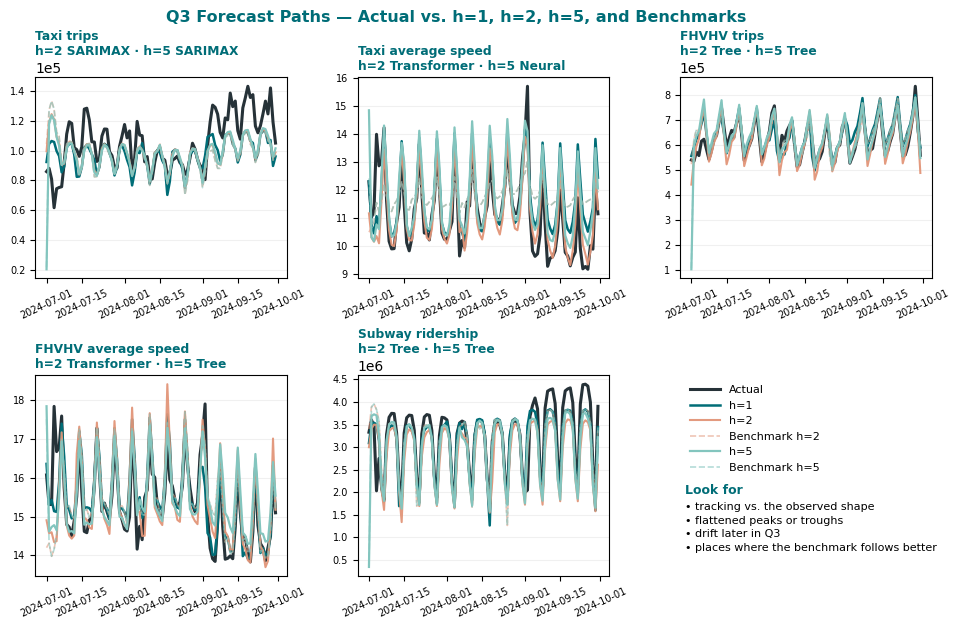

PASS — Q3 daily trajectories created for all five mobility targets.


In [177]:
# ---------------------------------------------------------------------
# 5.1.1.7N — See how the Q3 forecasts behave over time
# ---------------------------------------------------------------------

if len(far_horizon_selection_review_df) != 10:
    raise RuntimeError(
        "Run the completed 7L review before building the trajectory view."
    )


# ---------------------------------------------------------------------
# Shared Q3 factual frame
#
# The mixed h=1 artifact contains all five metrics on the common Q3 timeline.
# Besides supplying Actual and h=1, it gives us one fixed set of observed trip
# volumes for weighting every speed line in this diagnostic comparison.
# ---------------------------------------------------------------------

q3_reference_df = pd.read_parquet(
    H1_Q3_MIXED_TRAJECTORY_PATH,
    columns=[
        "taxi_zone_id",
        "metric",
        "target_observation_sequence_id",
        "target_date",
        "target_observed_value",
        "system_prediction",
    ],
)

q3_reference_df["target_date"] = pd.to_datetime(
    q3_reference_df["target_date"]
).dt.normalize()


SPEED_WEIGHT_METRICS = {
    "taxi_avg_trip_speed": "taxi_trip_count",
    "fhvhv_avg_trip_speed": "fhvhv_trip_count",
}

TRAJECTORY_KEYS = [
    "taxi_zone_id",
    "target_observation_sequence_id",
    "target_date",
]


# ---------------------------------------------------------------------
# Daily aggregation for this figure
#
# Counts/ridership are summed directly.
#
# Speeds use OBSERVED Q3 trip volumes as common activity weights for every
# line. Because this is an evaluation graphic, using the same hidden factual
# weights keeps the visual comparison apples-to-apples: only the speed forecast
# changes from line to line, not the definition of the citywide average.
# ---------------------------------------------------------------------

def aggregate_daily_trajectory(
    frame: pd.DataFrame,
    metric: str,
    value_column: str,
) -> pd.DataFrame:
    """Return one daily citywide trajectory for the requested metric."""
    if "metric" in frame.columns:
        value_rows = frame.loc[
            frame["metric"].eq(metric)
        ].copy()
    else:
        value_rows = frame.copy()

    require_columns(
        value_rows,
        [
            *TRAJECTORY_KEYS,
            value_column,
        ],
        f"{metric} · {value_column} trajectory",
    )

    value_rows[value_column] = pd.to_numeric(
        value_rows[value_column],
        errors="coerce",
    )

    value_rows = value_rows.loc[
        value_rows[value_column].notna()
    ].copy()


    # Counts and ridership add across Taxi Zones and Dayparts.
    if metric in COUNT_TARGETS:
        return (
            value_rows
            .groupby(
                "target_date",
                as_index=False,
                observed=True,
            )[value_column]
            .sum(min_count=1)
            .rename(columns={value_column: "value"})
        )


    # Speeds use one common factual trip-volume weighting surface.
    if metric not in SPEED_TARGETS:
        raise RuntimeError(
            f"No trajectory aggregation rule defined for {metric}."
        )

    weight_metric = SPEED_WEIGHT_METRICS[metric]

    weight_rows = (
        q3_reference_df.loc[
            q3_reference_df["metric"].eq(weight_metric),
            [
                *TRAJECTORY_KEYS,
                "target_observed_value",
            ],
        ]
        .rename(
            columns={
                "target_observed_value": "activity_weight"
            }
        )
        .copy()
    )

    weight_rows["activity_weight"] = pd.to_numeric(
        weight_rows["activity_weight"],
        errors="coerce",
    )

    weighted = value_rows.merge(
        weight_rows,
        on=TRAJECTORY_KEYS,
        how="inner",
        validate="one_to_one",
    )

    weighted = weighted.loc[
        weighted["activity_weight"].notna()
        & weighted["activity_weight"].gt(0)
    ].copy()

    weighted["weighted_value"] = (
        weighted[value_column]
        * weighted["activity_weight"]
    )

    daily = (
        weighted
        .groupby(
            "target_date",
            as_index=False,
            observed=True,
        )
        .agg(
            weighted_sum=("weighted_value", "sum"),
            weight_sum=("activity_weight", "sum"),
        )
    )

    daily["value"] = (
        daily["weighted_sum"]
        / daily["weight_sum"]
    )

    return daily[
        ["target_date", "value"]
    ]


# ---------------------------------------------------------------------
# Resolve the advanced h=2/h=5 leaders already reviewed in 7L.
# ---------------------------------------------------------------------

leader_family_by_job = {
    (
        str(row.metric),
        int(row.Horizon),
    ): str(row.leader_family)
    for row in far_horizon_selection_review_df.itertuples(
        index=False
    )
}

if len(leader_family_by_job) != 10:
    raise RuntimeError(
        "Expected ten Target × Horizon advanced leaders."
    )


# ---------------------------------------------------------------------
# Build six independent lines for each metric.
#
# IMPORTANT:
# Each farther-horizon candidate is read and aggregated independently.
# We do NOT stitch different winning model families into a synthetic frame.
# ---------------------------------------------------------------------

trajectory_by_metric = {}

for metric in FORECAST_TARGETS:
    metric_series = {}

    metric_series["Actual"] = aggregate_daily_trajectory(
        q3_reference_df,
        metric,
        "target_observed_value",
    )

    metric_series["h=1"] = aggregate_daily_trajectory(
        q3_reference_df,
        metric,
        "system_prediction",
    )

    for horizon in FAR_HORIZONS:
        leader_family = leader_family_by_job[
            (metric, int(horizon))
        ]

        leader_df = pd.read_parquet(
            far_candidate_prediction_path(
                leader_family,
                metric,
                horizon,
            )
        )

        leader_df["target_date"] = pd.to_datetime(
            leader_df["target_date"]
        ).dt.normalize()

        metric_series[f"h={horizon}"] = (
            aggregate_daily_trajectory(
                leader_df,
                metric,
                "system_prediction",
            )
        )

        metric_series[f"Benchmark h={horizon}"] = (
            aggregate_daily_trajectory(
                leader_df,
                metric,
                "benchmark_prediction",
            )
        )

    trajectory_by_metric[metric] = metric_series


# ---------------------------------------------------------------------
# Validate the plotting payload before drawing anything.
# ---------------------------------------------------------------------

EXPECTED_SERIES = {
    "Actual",
    "h=1",
    "h=2",
    "Benchmark h=2",
    "h=5",
    "Benchmark h=5",
}

for metric, series_map in trajectory_by_metric.items():
    if set(series_map) != EXPECTED_SERIES:
        raise RuntimeError(
            f"{metric}: trajectory series are incomplete."
        )

    for series_name, daily_df in series_map.items():
        if daily_df.empty:
            raise RuntimeError(
                f"{metric} · {series_name}: daily trajectory is empty."
            )

        if daily_df["target_date"].duplicated().any():
            raise RuntimeError(
                f"{metric} · {series_name}: duplicate daily dates."
            )


# ---------------------------------------------------------------------
# 2 × 3 figure
#
# Five panels show the targets. The sixth holds the shared legend and a short
# reading guide, preserving useful plotting space within the 980 × 640 canvas.
# ---------------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    3,
    figsize=(9.8, 6.4),
)

axes = axes.ravel()

metric_axes = {
    "taxi_trip_count": axes[0],
    "taxi_avg_trip_speed": axes[1],
    "fhvhv_trip_count": axes[2],
    "fhvhv_avg_trip_speed": axes[3],
    "subway_ridership": axes[4],
}

family_short_labels = {
    "tree": "Tree",
    "neural": "Neural",
    "transformer": "Transformer",
    "classical": "SARIMAX",
}


# ---------------------------------------------------------------------
# Shared visual grammar
# ---------------------------------------------------------------------

line_styles = {
    "Actual": {
        "color": "#263238",
        "linestyle": "-",
        "linewidth": 2.2,
        "alpha": 1.00,
    },
    "h=1": {
        "color": BRAND_COLORS["dark_teal"],
        "linestyle": "-",
        "linewidth": 1.8,
        "alpha": 1.00,
    },
    "h=2": {
        "color": BRAND_COLORS["terracotta"],
        "linestyle": "-",
        "linewidth": 1.5,
        "alpha": 0.95,
    },
    "Benchmark h=2": {
        "color": BRAND_COLORS["terracotta"],
        "linestyle": "--",
        "linewidth": 1.2,
        "alpha": 0.55,
    },
    "h=5": {
        "color": BRAND_COLORS["seafoam"],
        "linestyle": "-",
        "linewidth": 1.6,
        "alpha": 1.00,
    },
    "Benchmark h=5": {
        "color": BRAND_COLORS["seafoam"],
        "linestyle": "--",
        "linewidth": 1.2,
        "alpha": 0.60,
    },
}

series_order = [
    "Actual",
    "h=1",
    "h=2",
    "Benchmark h=2",
    "h=5",
    "Benchmark h=5",
]


for metric, ax in metric_axes.items():
    for series_name in series_order:
        daily_df = (
            trajectory_by_metric[metric][series_name]
            .sort_values("target_date")
        )

        style = line_styles[series_name]

        ax.plot(
            daily_df["target_date"],
            daily_df["value"],
            label=series_name,
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            alpha=style["alpha"],
        )

    h2_family = family_short_labels[
        leader_family_by_job[(metric, 2)]
    ]
    h5_family = family_short_labels[
        leader_family_by_job[(metric, 5)]
    ]

    ax.set_title(
        (
            f"{TARGET_LABELS[metric]}\n"
            f"h=2 {h2_family} · h=5 {h5_family}"
        ),
        loc="left",
        fontsize=8.8,
        fontweight="bold",
        color=BRAND_COLORS["dark_teal"],
        pad=5,
    )

    ax.grid(
        axis="y",
        alpha=0.18,
    )

    ax.tick_params(
        axis="both",
        labelsize=7,
    )

    ax.tick_params(
        axis="x",
        rotation=25,
    )

    if metric in COUNT_TARGETS:
        ax.ticklabel_format(
            axis="y",
            style="sci",
            scilimits=(0, 0),
        )


# ---------------------------------------------------------------------
# Sixth panel — shared legend and reading guide
# ---------------------------------------------------------------------

guide_ax = axes[5]
guide_ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()

guide_ax.legend(
    handles,
    labels,
    loc="upper left",
    frameon=False,
    fontsize=8,
    handlelength=2.7,
)

guide_ax.text(
    0.02,
    0.46,
    "Look for",
    transform=guide_ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    fontweight="bold",
    color=BRAND_COLORS["dark_teal"],
)

guide_ax.text(
    0.02,
    0.37,
    "• tracking vs. the observed shape\n"
    "• flattened peaks or troughs\n"
    "• drift later in Q3\n"
    "• places where the benchmark follows better",
    transform=guide_ax.transAxes,
    ha="left",
    va="top",
    fontsize=8,
    linespacing=1.45,
)


# ---------------------------------------------------------------------
# Final presentation
# ---------------------------------------------------------------------

fig.suptitle(
    "Q3 Forecast Paths — Actual vs. h=1, h=2, h=5, and Benchmarks",
    fontsize=11.5,
    fontweight="bold",
    color=BRAND_COLORS["dark_teal"],
    y=0.985,
)

fig.subplots_adjust(
    left=0.07,
    right=0.985,
    bottom=0.10,
    top=0.88,
    hspace=0.48,
    wspace=0.28,
)

plt.show()

print(
    "PASS — Q3 daily trajectories created for all five mobility targets.",
    flush=True,
)

**Findings.** The Q3 trajectories look broadly healthy across all five mobility targets. The h=1, h=2, h=5, and benchmark paths preserve the main weekly rhythm, follow the overall level of the observed series, and show no obvious runaway drift, collapse, or loss of seasonality as the synthetic history ages.

The clearest misses are in the demand measures. Taxi trips and Subway ridership both show stronger late-Q3 increases in the observed series than in the forecast paths, so the models capture the recurring weekly pattern better than the full change in level. FHVHV trips tracks the observed shape more closely, although its benchmark still has lower average error.

The two speed targets are especially well behaved visually. Taxi and FHVHV average speed retain the observed cyclical pattern and stay within a similar range across h=1, h=2, h=5, and the benchmark.

Taken together, the trajectory view changes the tone of the scorecard results. Several farther-horizon advanced models lose to the benchmark numerically, but they do not appear unstable or implausible. In many cases the difference is better described as **the benchmark being slightly more accurate**, not the advanced model producing a bad trajectory.

> Decision — Freeze the h=2 and h=5 production heads
We will use an advanced farther\-horizon model only when it beats the frozen benchmark in both the deployable\-system comparison and the matched advanced\-only comparison\. Otherwise, the benchmark becomes the production head\.

The advanced trajectories are generally stable, so benchmark selections reflect better accuracy rather than obvious model failure\. Taxi trips h=5 is the closest call, but SARIMAX still wins in both comparisons, so we keep it and let the sealed Q4 test provide the next independent check\. 

The ten h=2/h=5 heads are now frozen\. Q3 selection is complete\.

### 5.1.1.7O — Publish the frozen 15-job forecasting roster

The model-selection work is complete. We now turn those decisions into one durable forecasting contract so the Q4 acceptance test does not have to reconstruct choices from notebook state.

The roster contains five h=1 state engines and ten read-only h=2/h=5 heads. For the farther horizons, an advanced model is primary only when it beat the benchmark in both Q3 comparisons; otherwise the benchmark is primary.

======================================================================

In [179]:
# ---------------------------------------------------------------------
# 5.1.1.7O — Publish the frozen 15-job forecasting roster
# ---------------------------------------------------------------------

FAR_FROZEN_SELECTION_CONTRACT_ID = f"{FAR_HORIZON_CONTRACT_ID}__frozen_heads_v1"
FROZEN_FORECAST_SYSTEM_CONTRACT_ID = (
    f"{FAR_FROZEN_SELECTION_CONTRACT_ID}__system15_v1"
)

FAR_FROZEN_ROSTER_PATH = INTERMEDIATE_DIR / "far_horizon_frozen_roster.parquet"
FROZEN_FORECAST_SYSTEM_PATH = (
    INTERMEDIATE_DIR / "forecast_system_frozen_15_job_roster.parquet"
)


# ---------------------------------------------------------------------
# Explicit Q3 decision.
#
# "benchmark" means the frozen synthetic-history benchmark is the primary
# production head. Otherwise the value is the selected advanced family.
# ---------------------------------------------------------------------

FAR_PRIMARY_HEAD_DECISION = {
    ("taxi_trip_count", 2): "benchmark",
    ("taxi_trip_count", 5): "classical",
    ("taxi_avg_trip_speed", 2): "transformer",
    ("taxi_avg_trip_speed", 5): "neural",
    ("fhvhv_trip_count", 2): "benchmark",
    ("fhvhv_trip_count", 5): "benchmark",
    ("fhvhv_avg_trip_speed", 2): "benchmark",
    ("fhvhv_avg_trip_speed", 5): "tree",
    ("subway_ridership", 2): "benchmark",
    ("subway_ridership", 5): "benchmark",
}

if len(FAR_PRIMARY_HEAD_DECISION) != 10:
    raise RuntimeError(
        "The frozen farther-horizon decision must contain exactly ten jobs."
    )


# ---------------------------------------------------------------------
# Validate the human decision against the completed 7M evidence.
#
# WHY:
# An advanced head is allowed forward only when BOTH Q3 views favored it:
# the deployable system and the matched advanced-only comparison.
# ---------------------------------------------------------------------

matched_review_df = pd.read_parquet(FAR_MATCHED_ADVANCED_REVIEW_PATH)
family_id_by_label = {label: family for family, label in FAMILY_LABELS.items()}

far_roster_rows = []

for metric in FORECAST_TARGETS:
    for horizon in FAR_HORIZONS:
        review_match = matched_review_df.loc[
            matched_review_df["metric"].eq(metric)
            & matched_review_df["Horizon"].eq(int(horizon))
        ]

        if len(review_match) != 1:
            raise RuntimeError(
                f"{metric} · h={horizon}: matched-support review "
                "did not resolve uniquely."
            )

        review = review_match.iloc[0]
        advanced_family = family_id_by_label[str(review["Production leader"])]
        advanced_only_family = family_id_by_label[str(review["Advanced-only leader"])]

        if advanced_family != advanced_only_family:
            raise RuntimeError(
                f"{metric} · h={horizon}: production and advanced-only "
                "family leaders disagree."
            )

        production_skill = float(review["Production skill (%)"])
        advanced_only_skill = float(review["Advanced-only skill (%)"])

        expected_head_type = (
            "advanced"
            if production_skill > 0 and advanced_only_skill > 0
            else "benchmark"
        )

        primary_decision = FAR_PRIMARY_HEAD_DECISION[(metric, int(horizon))]
        actual_head_type = "benchmark" if primary_decision == "benchmark" else "advanced"

        if actual_head_type != expected_head_type:
            raise RuntimeError(
                f"{metric} · h={horizon}: frozen head type does not match "
                "the approved two-view benchmark rule."
            )

        if actual_head_type == "advanced" and primary_decision != advanced_family:
            raise RuntimeError(
                f"{metric} · h={horizon}: frozen advanced family does not "
                "match the reviewed leader."
            )

        advanced_candidate = far_horizon_candidate_row(
            advanced_family, metric, horizon
        )
        benchmark_id = FAR_BENCHMARK_BY_JOB[(metric, int(horizon))]

        primary_family = (
            "benchmark" if actual_head_type == "benchmark" else advanced_family
        )
        primary_head_id = (
            benchmark_id
            if actual_head_type == "benchmark"
            else str(advanced_candidate["candidate_id"])
        )

        far_roster_rows.append(
            {
                "decision_contract_id": FAR_FROZEN_SELECTION_CONTRACT_ID,
                "metric": metric,
                "horizon": int(horizon),
                "primary_head_type": actual_head_type,
                "primary_family": primary_family,
                "primary_head_id": primary_head_id,
                "benchmark_id": benchmark_id,
                "advanced_family": advanced_family,
                "advanced_candidate_id": str(advanced_candidate["candidate_id"]),
                "advanced_source_configuration_id": str(
                    advanced_candidate["source_configuration_id"]
                ),
                "q3_production_skill_pct": production_skill,
                "q3_advanced_only_skill_pct": advanced_only_skill,
                "q3_advanced_coverage_pct": float(review["Production coverage (%)"]),
                "q3_fallback_pct": float(review["Production fallback (%)"]),
            }
        )


far_frozen_roster_df = (
    pd.DataFrame(far_roster_rows)
    .sort_values(["horizon", "metric"])
    .reset_index(drop=True)
)

if len(far_frozen_roster_df) != 10:
    raise RuntimeError("The frozen farther-horizon roster must contain ten jobs.")

if far_frozen_roster_df[["metric", "horizon"]].duplicated().any():
    raise RuntimeError("The frozen farther-horizon roster contains duplicate jobs.")

atomic_write_parquet(far_frozen_roster_df, FAR_FROZEN_ROSTER_PATH)


# ---------------------------------------------------------------------
# Combine the five h=1 engines and ten farther-horizon heads into one
# authoritative 15-job contract.
# ---------------------------------------------------------------------

h1_selected_roster_df = pd.read_parquet(H1_Q3_SELECTED_ROSTER_PATH)
system_rows = []

for row in h1_selected_roster_df.itertuples(index=False):
    system_rows.append(
        {
            "system_contract_id": FROZEN_FORECAST_SYSTEM_CONTRACT_ID,
            "metric": str(row.metric),
            "horizon": 1,
            "primary_head_type": "advanced",
            "primary_family": str(row.family),
            "formulation": str(row.formulation),
            "primary_head_id": str(row.h1_candidate_id),
            "benchmark_id": pd.NA,
        }
    )

for row in far_frozen_roster_df.itertuples(index=False):
    system_rows.append(
        {
            "system_contract_id": FROZEN_FORECAST_SYSTEM_CONTRACT_ID,
            "metric": str(row.metric),
            "horizon": int(row.horizon),
            "primary_head_type": str(row.primary_head_type),
            "primary_family": str(row.primary_family),
            "formulation": pd.NA,
            "primary_head_id": str(row.primary_head_id),
            "benchmark_id": str(row.benchmark_id),
        }
    )

frozen_forecast_system_df = (
    pd.DataFrame(system_rows)
    .sort_values(["horizon", "metric"])
    .reset_index(drop=True)
)

if len(frozen_forecast_system_df) != 15:
    raise RuntimeError("The frozen forecasting system must contain exactly 15 jobs.")

if frozen_forecast_system_df[["metric", "horizon"]].duplicated().any():
    raise RuntimeError("The frozen forecasting system contains duplicate jobs.")

atomic_write_parquet(frozen_forecast_system_df, FROZEN_FORECAST_SYSTEM_PATH)

display_df = (
    frozen_forecast_system_df
    .assign(
        Target=lambda frame: frame["metric"].map(TARGET_LABELS),
        Head=lambda frame: np.where(
            frame["primary_head_type"].eq("benchmark"),
            "Benchmark",
            frame["primary_family"].map(FAMILY_LABELS),
        ),
    )
    [["Target", "horizon", "Head", "formulation"]]
    .rename(columns={"horizon": "Horizon", "formulation": "Formulation"})
)

display(display_df)

print(
    "DECISION PUBLISHED — frozen forecasting system contains "
    "15 Target × Horizon jobs.",
    flush=True,
)

,Target,Horizon,Head,Formulation
0,FHVHV average speed,1,Tree · LightGBM,anchor_residual
1,FHVHV trips,1,Neural · Lag-window MLP,anchor_residual
2,Subway ridership,1,Neural · Lag-window MLP,anchor_residual
3,Taxi average speed,1,Neural · Lag-window MLP,direct_level
4,Taxi trips,1,Neural · Lag-window MLP,anchor_residual
5,FHVHV average speed,2,Benchmark,<NA>
6,FHVHV trips,2,Benchmark,<NA>
7,Subway ridership,2,Benchmark,<NA>
8,Taxi average speed,2,Transformer · PatchTST-inspired,<NA>
9,Taxi trips,2,Benchmark,<NA>


DECISION PUBLISHED — frozen forecasting system contains 15 Target × Horizon jobs.


**Findings.** The frozen forecasting contract contains exactly 15 Target × Horizon jobs: five h=1 state engines, five h=2 heads, and five h=5 heads.

The ten farther-horizon jobs contain four learned heads and six benchmark heads. The learned heads are Transformer for Taxi speed at h=2, SARIMAX for Taxi trips at h=5, Neural for Taxi speed at h=5, and Tree for FHVHV speed at h=5. The other six farther-horizon jobs use the frozen benchmark.

Q3 selection is now closed. The complete 15-job roster moves unchanged into the blind Q4 acceptance test.

### Section 7 Summary — The full forecasting roster is frozen

Section 7 extended the frozen h=1 synthetic world to the two farther forecast horizons.

We compared **40 h=2/h=5 candidates** across Tree, Neural, Transformer, and SARIMAX, checked the advanced leaders against the frozen benchmark, separated advanced-model skill from fallback behavior, and inspected the forecast paths over time.

The final farther-horizon roster is:

| Target | h=2 | h=5 |
| --- | --- | --- |
| Taxi trips | **Benchmark** | **SARIMAX** |
| Taxi average speed | **Transformer** | **Neural** |
| FHVHV trips | **Benchmark** | **Benchmark** |
| FHVHV average speed | **Benchmark** | **Tree** |
| Subway ridership | **Benchmark** | **Benchmark** |

Three conclusions matter:

* **h=1 remains the state engine.** Its five selected models are the only forecasts that update synthetic mobility history.
* **Farther horizons do not always need a more complex model.** Advanced models beat the benchmark for only 1 of 5 h=2 jobs and 3 of 5 h=5 jobs.
* **The advanced models were generally still well behaved.** Where the benchmark won, it was usually because it was more accurate, not because the advanced forecast path was visibly unstable.

The complete frozen system now contains:

**5 h=1 state engines + 5 h=2 heads + 5 h=5 heads = 15 Target × Horizon jobs**

with the farther horizons split between **4 advanced heads and 6 benchmark heads**.

The next stage opens the previously untouched **Q4 2024 blind acceptance period** and tests this frozen system without reselection or tuning.

## 5.1.1.8 — Run the Blind Q4 Acceptance Test

Q4 is the first quarter that played no role in choosing the forecasting system. We now run the frozen 15-job roster from October 1 through December 31, 2024 and compare its synthetic paths with what actually happened.

The selected global models remain frozen during this test. Only h=1 updates synthetic mobility history; h=2 and h=5 read from that evolving state. Q4 outcomes are used only after prediction, for acceptance evidence.

======================================================================

**5.1.1.8A — Define the acceptance contract**

The acceptance test uses one fixed Q4 episode, one frozen 15-job roster, and one versioned output namespace. Restarting the notebook may recover completed work, but it cannot change the selected models or the October–December test window.

======================================================================

In [181]:
# ---------------------------------------------------------------------
# 5.1.1.8A — Define the blind-Q4 acceptance contract
# ---------------------------------------------------------------------

RUN_Q4_ACCEPTANCE = True
RESET_Q4_ACCEPTANCE = False

acceptance_episode_df = recursive_episode_registry_df.loc[
    recursive_episode_registry_df["episode_role"].eq("blind_acceptance")
].copy()

if len(acceptance_episode_df) != 1:
    raise RuntimeError("Expected exactly one blind-acceptance episode.")

acceptance_episode = acceptance_episode_df.iloc[0]
H1_ACCEPTANCE_EPISODE_ID = str(acceptance_episode["episode_id"])

Q4_START_DATE = pd.Timestamp(acceptance_episode["freeze_date"]).normalize()
Q4_END_DATE = pd.Timestamp(acceptance_episode["rollout_end_date"]).normalize()

if (
    Q4_START_DATE != PROPOSED_BLIND_ACCEPTANCE_START_DATE
    or Q4_END_DATE != PROPOSED_BLIND_ACCEPTANCE_END_DATE
):
    raise RuntimeError(
        "The blind-acceptance episode no longer matches Q4 2024."
    )

Q4_ACCEPTANCE_CONTRACT_ID = (
    f"{FROZEN_FORECAST_SYSTEM_CONTRACT_ID}__q4_blind_acceptance_v1"
)

Q4_ACCEPTANCE_ROOT = (
    INTERMEDIATE_DIR / "q4_blind_acceptance" / Q4_ACCEPTANCE_CONTRACT_ID
)
Q4_FAR_JOB_DIR = Q4_ACCEPTANCE_ROOT / "far_horizon_jobs"
Q4_SARIMAX_ROOT = Q4_ACCEPTANCE_ROOT / "sarimax_batches"

for directory in [Q4_ACCEPTANCE_ROOT, Q4_FAR_JOB_DIR, Q4_SARIMAX_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)

Q4_H1_TRAJECTORY_PATH = Q4_ACCEPTANCE_ROOT / "q4_h1_selected_trajectory.parquet"
Q4_H1_AUDIT_PATH = Q4_ACCEPTANCE_ROOT / "q4_h1_acceptance_audit.parquet"
Q4_FAR_SURFACE_PATH = Q4_ACCEPTANCE_ROOT / "q4_far_horizon_surface.parquet"
Q4_FAR_PREDICTIONS_PATH = (
    Q4_ACCEPTANCE_ROOT / "q4_far_horizon_selected_predictions.parquet"
)
Q4_ACCEPTANCE_SCORECARD_PATH = (
    Q4_ACCEPTANCE_ROOT / "q4_acceptance_scorecard.parquet"
)
Q4_ACCEPTANCE_QA_PATH = Q4_ACCEPTANCE_ROOT / "q4_acceptance_qa.parquet"

# Give the acceptance rollout its own identity while reusing the proven
# Chapter 5/6 block, state, success-marker, and recovery machinery.
Q4_H1_RUNTIME_FAMILY_ID = "frozen_system_q4"
Q4_H1_RUNTIME_FORMULATION_ID = "selected_roster"

acceptance_plan_df = (
    pd.read_parquet(FROZEN_FORECAST_SYSTEM_PATH)
    .assign(
        Target=lambda frame: frame["metric"].map(TARGET_LABELS),
        Head=lambda frame: np.where(
            frame["primary_head_type"].eq("benchmark"),
            "Benchmark",
            frame["primary_family"].map(FAMILY_LABELS),
        ),
    )
    [["Target", "horizon", "Head"]]
    .rename(columns={"horizon": "Horizon"})
)

display(acceptance_plan_df)

print(
    "READY — blind Q4 acceptance contract frozen | "
    f"{Q4_START_DATE.date()} through {Q4_END_DATE.date()} | 15 jobs.",
    flush=True,
)


,Target,Horizon,Head
0,FHVHV average speed,1,Tree · LightGBM
1,FHVHV trips,1,Neural · Lag-window MLP
2,Subway ridership,1,Neural · Lag-window MLP
3,Taxi average speed,1,Neural · Lag-window MLP
4,Taxi trips,1,Neural · Lag-window MLP
5,FHVHV average speed,2,Benchmark
6,FHVHV trips,2,Benchmark
7,Subway ridership,2,Benchmark
8,Taxi average speed,2,Transformer · PatchTST-inspired
9,Taxi trips,2,Benchmark


READY — blind Q4 acceptance contract frozen | 2024-10-01 through 2024-12-31 | 15 jobs.


**Findings.** The blind-Q4 acceptance contract spans exactly **October 1 through December 31, 2024** and carries forward all **15 selected Target × Horizon jobs** unchanged from the completed Q3 roster.

The test therefore begins with both the forecasting system and the evaluation window already fixed. Q4 outcomes can determine whether the system is acceptable for production, but they cannot change the selected families, formulations, or benchmark choices.

** 5.1.1.8B — Run the frozen h=1 system through Q4**

The five h=1 engines now create a fresh synthetic Q4 world. They start from factual history available through September 30, then advance one Daypart at a time without receiving actual Q4 mobility.

The selected model states are the same ones used for Q3 selection; this is a holdout test, not another fitting round.

======================================================================

In [183]:
# ---------------------------------------------------------------------
# 5.1.1.8B — Run or recover the frozen h=1 roster through Q4
# ---------------------------------------------------------------------

q4_h1_selected_df = pd.read_parquet(H1_Q3_SELECTED_ROSTER_PATH)
q4_h1_roster_lookup = q4_h1_selected_df.set_index("metric").to_dict("index")

if set(q4_h1_roster_lookup) != set(FORECAST_TARGETS):
    raise RuntimeError("The Q4 h=1 roster does not contain the exact five targets.")

unsupported_h1_families = (
    set(q4_h1_selected_df["family"].astype(str)) - set(H1_GLOBAL_FAMILIES)
)

if unsupported_h1_families:
    raise RuntimeError(
        "Q4 h=1 acceptance contains a family that needs a different runtime "
        f"interface: {sorted(unsupported_h1_families)}"
    )


# ---------------------------------------------------------------------
# Activate Q4 in the shared h=1 restart registry
# ---------------------------------------------------------------------

q4_episode = h1_episode_definition(H1_ACCEPTANCE_EPISODE_ID)

if str(q4_episode["episode_role"]) != "blind_acceptance":
    raise RuntimeError(
        "The Q4 runtime episode is not the frozen blind-acceptance episode."
    )

q4_target_ids = (
    recursive_episode_position_registry_df.loc[
        recursive_episode_position_registry_df["episode_id"].eq(
            H1_ACCEPTANCE_EPISODE_ID
        ),
        "target_observation_sequence_id",
    ]
    .drop_duplicates()
    .astype(int)
    .sort_values()
    .tolist()
)

expected_q4_positions = int(q4_episode["h1_positions"])

if len(q4_target_ids) != expected_q4_positions:
    raise RuntimeError(
        "The Q4 h=1 position registry does not match the frozen "
        f"acceptance episode: {len(q4_target_ids):,} vs "
        f"{expected_q4_positions:,} positions."
    )

q4_block_records = []
q4_block_target_ids = {}

for block_id, start in enumerate(
    range(0, len(q4_target_ids), H1_ROLLOUT_BLOCK_SIZE)
):
    block_target_ids = q4_target_ids[
        start : start + H1_ROLLOUT_BLOCK_SIZE
    ]

    q4_block_records.append(
        {
            "episode_id": H1_ACCEPTANCE_EPISODE_ID,
            "episode_role": "blind_acceptance",
            "block_id": block_id,
            "start_target_sequence_id": block_target_ids[0],
            "end_target_sequence_id": block_target_ids[-1],
            "positions": len(block_target_ids),
            "expected_prediction_rows": (
                len(block_target_ids) * EXPECTED_PRE_CP_NATIVE_SEQUENCES
            ),
            "parameter_updates_allowed": False,
        }
    )

    q4_block_target_ids[
        (H1_ACCEPTANCE_EPISODE_ID, block_id)
    ] = block_target_ids

q4_rollout_block_df = pd.DataFrame(q4_block_records)

if q4_rollout_block_df.empty:
    raise RuntimeError("The Q4 h=1 restart registry is empty.")

if q4_rollout_block_df.duplicated(["episode_id", "block_id"]).any():
    raise RuntimeError("The Q4 h=1 restart block identities are not unique.")

if int(q4_rollout_block_df["positions"].sum()) != expected_q4_positions:
    raise RuntimeError(
        "The Q4 h=1 restart blocks do not cover every acceptance position."
    )

if (
    int(q4_rollout_block_df["start_target_sequence_id"].min())
    != int(q4_episode["first_target_observation_sequence_id"])
    or int(q4_rollout_block_df["end_target_sequence_id"].max())
    != int(q4_episode["last_target_observation_sequence_id"])
):
    raise RuntimeError(
        "The Q4 h=1 restart blocks do not span the frozen acceptance episode."
    )

# 5U intentionally excluded sealed Q4. Now that 8A has opened the blind
# acceptance period, extend the shared restart registry without disturbing
# the already-completed training and Q3 entries. Rebuilding the Q4 slice
# makes this cell idempotent on normal reruns.
h1_rollout_block_registry_df = pd.concat(
    [
        h1_rollout_block_registry_df.loc[
            ~h1_rollout_block_registry_df["episode_id"].eq(
                H1_ACCEPTANCE_EPISODE_ID
            )
        ].copy(),
        q4_rollout_block_df,
    ],
    ignore_index=True,
).sort_values(
    ["episode_id", "block_id"]
).reset_index(drop=True)

H1_BLOCK_TARGET_IDS = {
    key: value
    for key, value in H1_BLOCK_TARGET_IDS.items()
    if key[0] != H1_ACCEPTANCE_EPISODE_ID
}
H1_BLOCK_TARGET_IDS.update(q4_block_target_ids)

registered_q4_blocks = h1_rollout_block_registry_df.loc[
    h1_rollout_block_registry_df["episode_id"].eq(
        H1_ACCEPTANCE_EPISODE_ID
    )
].sort_values("block_id")

registered_q4_target_ids = [
    target_id
    for block_id in registered_q4_blocks["block_id"].astype(int)
    for target_id in H1_BLOCK_TARGET_IDS[
        (H1_ACCEPTANCE_EPISODE_ID, block_id)
    ]
]

if registered_q4_target_ids != q4_target_ids:
    raise RuntimeError(
        "The active Q4 h=1 block cache does not reproduce the frozen "
        "acceptance clock exactly."
    )

print(
    "READY — Q4 h=1 restart contract activated | "
    f"{len(registered_q4_blocks):,} blocks | "
    f"{expected_q4_positions:,} Dayparts.",
    flush=True,
)

def load_q4_h1_bundles() -> dict:
    """Restore the five frozen h=1 final models without fitting on Q3."""
    bundles = {}

    for row in q4_h1_selected_df.itertuples(index=False):
        family = str(row.family)
        metric = str(row.metric)
        formulation = str(row.formulation)

        model_path = h1_candidate_model_path(
            family, formulation, metric, stage="final"
        )
        require_file(model_path, f"Q4 · {metric} frozen h=1 model")

        bundle = load_h1_candidate_bundle(
            family, metric, formulation, model_path
        )

        if str(bundle["h1_candidate_id"]) != str(row.h1_candidate_id):
            raise RuntimeError(
                f"Q4 · {metric}: restored model does not match "
                "the frozen h=1 roster."
            )

        bundles[metric] = bundle

    return bundles


def q4_h1_expected_rows() -> int:
    """Return the exact planned Q4 h=1 trajectory size."""
    q4_blocks = h1_rollout_block_registry_df.loc[
        h1_rollout_block_registry_df["episode_id"].eq(H1_ACCEPTANCE_EPISODE_ID)
    ]

    return int(q4_blocks["expected_prediction_rows"].sum())


def q4_h1_complete() -> bool:
    """
    Cheaply validate a completed Q4 h=1 product.

    Full semantics are checked at creation. Normal reruns use the committed
    rollout state, trajectory metadata, and the small acceptance audit.
    """
    if not Q4_H1_TRAJECTORY_PATH.exists() or not Q4_H1_AUDIT_PATH.exists():
        return False

    if not h1_rollout_complete(
        Q4_H1_RUNTIME_FAMILY_ID,
        Q4_H1_RUNTIME_FORMULATION_ID,
        H1_ACCEPTANCE_EPISODE_ID,
        training_episode=False,
    ):
        return False

    try:
        audit_df = pd.read_parquet(Q4_H1_AUDIT_PATH)
    except Exception:
        return False

    if len(audit_df) != 1:
        return False

    audit = audit_df.iloc[0]

    return bool(
        str(audit["acceptance_contract_id"]) == Q4_ACCEPTANCE_CONTRACT_ID
        and str(audit["status"]) == "success"
        and int(audit["rows"]) == q4_h1_expected_rows()
        and h1_parquet_row_count(Q4_H1_TRAJECTORY_PATH) == int(audit["rows"])
    )


def reset_q4_h1() -> None:
    """Remove only the current blind-Q4 h=1 rollout."""
    rollout_dir = h1_rollout_episode_dir(
        Q4_H1_RUNTIME_FAMILY_ID,
        Q4_H1_RUNTIME_FORMULATION_ID,
        H1_ACCEPTANCE_EPISODE_ID,
    )
    marker_dir = (
        H1_SUCCESS_MARKER_DIR
        / Q4_H1_RUNTIME_FAMILY_ID
        / Q4_H1_RUNTIME_FORMULATION_ID
        / H1_ACCEPTANCE_EPISODE_ID
    )

    for path in [rollout_dir, marker_dir]:
        if path.exists():
            shutil.rmtree(path)

    Q4_H1_TRAJECTORY_PATH.unlink(missing_ok=True)
    Q4_H1_AUDIT_PATH.unlink(missing_ok=True)


def run_q4_h1_acceptance() -> pd.DataFrame:
    """Run or resume the frozen five-engine h=1 system through blind Q4."""
    if q4_h1_complete():
        return pd.read_parquet(Q4_H1_TRAJECTORY_PATH)

    fitted_bundles = load_q4_h1_bundles()

    state, last_block_id = recover_h1_rollout_state(
        Q4_H1_RUNTIME_FAMILY_ID,
        Q4_H1_RUNTIME_FORMULATION_ID,
        H1_ACCEPTANCE_EPISODE_ID,
        training_episode=False,
    )

    blocks = (
        h1_rollout_block_registry_df.loc[
            h1_rollout_block_registry_df["episode_id"].eq(
                H1_ACCEPTANCE_EPISODE_ID
            )
            & h1_rollout_block_registry_df["block_id"].gt(last_block_id)
        ]
        .sort_values("block_id")
        .reset_index(drop=True)
    )

    remaining_positions = int(blocks["positions"].sum()) if not blocks.empty else 0
    progress = tqdm(total=remaining_positions, desc="blind Q4 · frozen h=1")

    for block in blocks.itertuples(index=False):
        prediction_parts = []
        target_ids = H1_BLOCK_TARGET_IDS[
            (H1_ACCEPTANCE_EPISODE_ID, int(block.block_id))
        ]

        for target_id in target_ids:
            origin_frame = load_h1_episode_origin_frame(
                H1_ACCEPTANCE_EPISODE_ID, target_id
            )
            prepared_frame = prepare_h1_recursive_frame(
                origin_frame, state, episode_id=H1_ACCEPTANCE_EPISODE_ID
            )

            origin_predictions = resolve_h1_mixed_system_predictions(
                prepared_frame,
                state,
                roster_lookup=q4_h1_roster_lookup,
                fitted_bundles=fitted_bundles,
                classical_source_index=None,
                episode_id=H1_ACCEPTANCE_EPISODE_ID,
            )

            position = H1_POSITION_LOOKUP[
                (H1_ACCEPTANCE_EPISODE_ID, int(target_id))
            ]
            origin_predictions["rollout_step"] = position["rollout_step"]
            origin_predictions["rollout_day"] = position["rollout_day"]
            origin_predictions["acceptance_contract_id"] = Q4_ACCEPTANCE_CONTRACT_ID
            prediction_parts.append(origin_predictions)

            # Only h=1 becomes synthetic history for the next Daypart.
            apply_h1_state_update(
                state, origin_predictions, prediction_column="system_prediction"
            )
            progress.update(1)

        block_predictions = pd.concat(prediction_parts, ignore_index=True)

        if len(block_predictions) != int(block.expected_prediction_rows):
            raise RuntimeError(
                f"Q4 block {block.block_id}: produced "
                f"{len(block_predictions):,} rows; expected "
                f"{int(block.expected_prediction_rows):,}."
            )

        prediction_path = h1_prediction_block_path(
            Q4_H1_RUNTIME_FAMILY_ID,
            Q4_H1_RUNTIME_FORMULATION_ID,
            H1_ACCEPTANCE_EPISODE_ID,
            int(block.block_id),
        )
        atomic_write_parquet(block_predictions, prediction_path)

        write_h1_block_success(
            family=Q4_H1_RUNTIME_FAMILY_ID,
            formulation=Q4_H1_RUNTIME_FORMULATION_ID,
            episode_id=H1_ACCEPTANCE_EPISODE_ID,
            block_id=int(block.block_id),
            prediction_rows=len(block_predictions),
            example_rows=None,
            next_target_sequence_id=int(state["next_target_sequence_id"]),
        )

        # Publish state last so recovery never moves beyond durable predictions.
        write_h1_runtime_state(
            h1_runtime_state_path(
                Q4_H1_RUNTIME_FAMILY_ID,
                Q4_H1_RUNTIME_FORMULATION_ID,
                H1_ACCEPTANCE_EPISODE_ID,
            ),
            state,
            family=Q4_H1_RUNTIME_FAMILY_ID,
            formulation=Q4_H1_RUNTIME_FORMULATION_ID,
            episode_id=H1_ACCEPTANCE_EPISODE_ID,
            last_completed_block_id=int(block.block_id),
        )

        progress.set_postfix(block=int(block.block_id))
        del block_predictions, prediction_parts
        gc.collect()

    progress.close()

    if not h1_rollout_complete(
        Q4_H1_RUNTIME_FAMILY_ID,
        Q4_H1_RUNTIME_FORMULATION_ID,
        H1_ACCEPTANCE_EPISODE_ID,
        training_episode=False,
    ):
        raise RuntimeError("The Q4 h=1 rollout did not reach its final block.")

    episode_blocks = (
        h1_rollout_block_registry_df.loc[
            h1_rollout_block_registry_df["episode_id"].eq(
                H1_ACCEPTANCE_EPISODE_ID
            )
        ]
        .sort_values("block_id")
        .reset_index(drop=True)
    )

    trajectory_df = pd.concat(
        [
            pd.read_parquet(
                h1_prediction_block_path(
                    Q4_H1_RUNTIME_FAMILY_ID,
                    Q4_H1_RUNTIME_FORMULATION_ID,
                    H1_ACCEPTANCE_EPISODE_ID,
                    int(block_id),
                )
            )
            for block_id in episode_blocks["block_id"]
        ],
        ignore_index=True,
    )

    expected_rows = q4_h1_expected_rows()

    if len(trajectory_df) != expected_rows:
        raise RuntimeError(
            f"Q4 h=1 trajectory contains {len(trajectory_df):,} rows; "
            f"expected {expected_rows:,}."
        )

    trajectory_key = [
        "h1_candidate_id",
        "target_observation_sequence_id",
        "forecast_sequence_id",
    ]

    if trajectory_df.duplicated(trajectory_key).any():
        raise RuntimeError("Q4 h=1 trajectory contains duplicate rows.")

    available = (
        trajectory_df["system_prediction_available"]
        .fillna(False)
        .astype(bool)
        .to_numpy()
    )
    prediction = pd.to_numeric(
        trajectory_df["system_prediction"], errors="coerce"
    ).to_numpy(dtype=float)

    if not available.all() or not np.isfinite(prediction).all():
        raise RuntimeError("Q4 h=1 contains unresolved mobility.")

    if np.any(prediction < 0):
        raise RuntimeError("Q4 h=1 contains negative resolved mobility.")

    target_dates = pd.to_datetime(trajectory_df["target_date"]).dt.normalize()

    if target_dates.min() != Q4_START_DATE or target_dates.max() != Q4_END_DATE:
        raise RuntimeError(
            "Q4 h=1 trajectory does not cover exactly the blind quarter."
        )

    atomic_write_parquet(trajectory_df, Q4_H1_TRAJECTORY_PATH)

    audit_df = pd.DataFrame(
        [
            {
                "acceptance_contract_id": Q4_ACCEPTANCE_CONTRACT_ID,
                "system_contract_id": FROZEN_FORECAST_SYSTEM_CONTRACT_ID,
                "episode_id": H1_ACCEPTANCE_EPISODE_ID,
                "rows": len(trajectory_df),
                "status": "success",
            }
        ]
    )
    atomic_write_parquet(audit_df, Q4_H1_AUDIT_PATH)

    del fitted_bundles
    clear_h1_torch_memory()
    gc.collect()

    return trajectory_df


if RESET_Q4_ACCEPTANCE:
    reset_q4_h1()

if q4_h1_complete():
    q4_h1_action = "recovered"
elif RUN_Q4_ACCEPTANCE:
    run_q4_h1_acceptance()
    q4_h1_action = "completed"
else:
    q4_h1_action = "pending"


if q4_h1_complete():
    q4_h1_df = pd.read_parquet(Q4_H1_TRAJECTORY_PATH)
    q4_h1_summary_rows = []

    for metric in FORECAST_TARGETS:
        frame = q4_h1_df.loc[
            q4_h1_df["metric"].eq(metric)
            & q4_h1_df["target_observed_value"].notna()
        ]

        actual = pd.to_numeric(
            frame["target_observed_value"], errors="raise"
        ).to_numpy(dtype=float)
        prediction = pd.to_numeric(
            frame["system_prediction"], errors="raise"
        ).to_numpy(dtype=float)

        q4_h1_summary_rows.append(
            {
                "Target": TARGET_LABELS[metric],
                "Relative MAE (%)": relative_mae_pct(actual, prediction),
                "Advanced coverage (%)": (
                    100.0
                    * frame["advanced_prediction_available"]
                    .fillna(False)
                    .astype(bool)
                    .mean()
                ),
                "Fallback (%)": (
                    100.0
                    * frame["benchmark_fallback_used"]
                    .fillna(False)
                    .astype(bool)
                    .mean()
                ),
            }
        )

    q4_h1_summary_df = pd.DataFrame(q4_h1_summary_rows)
    display(q4_h1_summary_df.round(3))

    print(
        f"Q4 h=1 acceptance state: {q4_h1_action} | "
        f"{len(q4_h1_df):,} rows.",
        flush=True,
    )
else:
    print("PENDING — Q4 h=1 acceptance has not run.", flush=True)


READY — Q4 h=1 restart contract activated | 19 blocks | 460 Dayparts.


,Target,Relative MAE (%),Advanced coverage (%),Fallback (%)
0,Taxi trips,21.243,100.0,0.0
1,Taxi average speed,19.410,100.0,0.0
2,FHVHV trips,14.781,100.0,0.0
3,FHVHV average speed,7.386,100.0,0.0
4,Subway ridership,15.759,100.0,0.0


Q4 h=1 acceptance state: recovered | 477,940 rows.


**Findings.** The five h=1 engines completed the full Q4 synthetic rollout with 477,940 forecast rows and no unresolved or negative mobility values.

Q4 Relative MAE was 7.386% for FHVHV average speed, 14.781% for FHVHV trips, 15.759% for Subway ridership, 19.410% for Taxi average speed, and 21.243% for Taxi trips. All five advanced heads maintained 100% coverage and required no benchmark fallback.

The h=1 state system therefore completed all 460 Q4 Dayparts without a structural failure.

**5.1.1.8C — Build the Q4 h=2/h=5 forecasting surface**

With the Q4 h=1 world complete, the farther horizons can read from that same synthetic history. We rebuild their predictors at each legal Q4 origin, while actual Q4 outcomes remain labels used only for the acceptance comparison.

======================================================================

In [185]:
# ---------------------------------------------------------------------
# 5.1.1.8C — Build the Q4 h=2/h=5 forecasting surface
# ---------------------------------------------------------------------

if not q4_h1_complete():
    raise RuntimeError(
        "The Q4 h=1 synthetic world must complete before "
        "farther-horizon acceptance can begin."
    )


def load_q4_h1_state() -> dict:
    """Restore the completed synthetic Q4 h=1 state."""
    state, _ = load_h1_runtime_state(
        h1_runtime_state_path(
            Q4_H1_RUNTIME_FAMILY_ID,
            Q4_H1_RUNTIME_FORMULATION_ID,
            H1_ACCEPTANCE_EPISODE_ID,
        ),
        family=Q4_H1_RUNTIME_FAMILY_ID,
        formulation=Q4_H1_RUNTIME_FORMULATION_ID,
        episode_id=H1_ACCEPTANCE_EPISODE_ID,
    )
    return state


def build_q4_far_surface() -> pd.DataFrame:
    """
    Rebuild legal h=2/h=5 predictor rows from the completed Q4 h=1 state.

    Actual Q4 outcomes stay attached only as hidden evaluation labels.
    Mobility-derived predictors are rebuilt from synthetic h=1 history.
    """
    episode = h1_episode_definition(H1_ACCEPTANCE_EPISODE_ID)
    first_target = int(episode["first_target_observation_sequence_id"])
    last_target = int(episode["last_target_observation_sequence_id"])
    freeze_origin = first_target - 1

    state = load_q4_h1_state()

    source_df = pd.read_parquet(
        PRE_CP_HISTORICAL_FORECASTING_MATRIX_PATH,
        filters=[
            ("modeling_track", "==", CHAPTER5_MODELING_TRACK),
            ("horizon", "in", list(FAR_HORIZONS)),
            ("origin_observation_sequence_id", ">=", freeze_origin),
            ("target_observation_sequence_id", ">=", first_target),
            ("target_observation_sequence_id", "<=", last_target),
        ],
    )

    if source_df.empty:
        raise RuntimeError("The blind-Q4 farther-horizon source surface is empty.")

    prepared_parts = []

    for _, origin_frame in source_df.groupby(
        "origin_observation_sequence_id", sort=True, observed=True
    ):
        prepared_parts.append(
            prepare_h1_recursive_frame(
                origin_frame,
                state,
                episode_id=H1_ACCEPTANCE_EPISODE_ID,
            )
        )

    surface_df = pd.concat(prepared_parts, ignore_index=True)
    surface_df["acceptance_contract_id"] = Q4_ACCEPTANCE_CONTRACT_ID
    surface_df["system_contract_id"] = FROZEN_FORECAST_SYSTEM_CONTRACT_ID
    surface_df["source_episode_id"] = H1_ACCEPTANCE_EPISODE_ID

    surface_df = (
        surface_df
        .sort_values(
            [
                "origin_observation_sequence_id",
                "horizon",
                "metric",
                "forecast_sequence_id",
            ]
        )
        .reset_index(drop=True)
    )

    target_dates = pd.to_datetime(surface_df["target_date"]).dt.normalize()

    if target_dates.min() < Q4_START_DATE or target_dates.max() > Q4_END_DATE:
        raise RuntimeError(
            "The farther-horizon acceptance surface crossed outside Q4."
        )

    return surface_df


if Q4_FAR_SURFACE_PATH.exists():
    q4_far_surface_df = pd.read_parquet(Q4_FAR_SURFACE_PATH)

    if not q4_far_surface_df["acceptance_contract_id"].astype(str).eq(
        Q4_ACCEPTANCE_CONTRACT_ID
    ).all():
        raise RuntimeError(
            "Recovered Q4 farther-horizon surface belongs "
            "to a different acceptance contract."
        )

    q4_far_surface_action = "recovered"

elif RUN_Q4_ACCEPTANCE:
    q4_far_surface_df = build_q4_far_surface()
    atomic_write_parquet(q4_far_surface_df, Q4_FAR_SURFACE_PATH)
    q4_far_surface_action = "built"

else:
    q4_far_surface_df = None
    q4_far_surface_action = "pending"


if q4_far_surface_df is not None:
    q4_far_surface_summary_df = (
        q4_far_surface_df
        .groupby("horizon", as_index=False, observed=True)
        .agg(
            Rows=("metric", "size"),
            Targets=("metric", "nunique"),
            Start=("target_date", "min"),
            End=("target_date", "max"),
        )
        .rename(columns={"horizon": "Horizon"})
    )

    display(q4_far_surface_summary_df)
    print(f"Q4 farther-horizon surface: {q4_far_surface_action}.", flush=True)
else:
    print("PENDING — Q4 farther-horizon surface not built.", flush=True)


,Horizon,Rows,Targets,Start,End
0,2,476901,5,2024-10-01,2024-12-31
1,5,473784,5,2024-10-01,2024-12-31


Q4 farther-horizon surface: recovered.


**Findings.** The Q4 farther-horizon surface is complete for all five targets at both horizons. It contains 476,901 h=2 rows and 473,784 h=5 rows, with target dates contained entirely within October 1 through December 31, 2024.

These forecasts read from the completed Q4 h=1 synthetic world and remain read-only; neither farther horizon changes the recursive mobility state.

**5.1.1.8D — Score the benchmark and global-model heads**

Nine of the ten farther-horizon jobs use either the benchmark, Tree, Neural, or Transformer as their primary Q4 head. We score those frozen choices directly from the Q4 synthetic state; no model is refit here.

Advanced-primary heads may still use their frozen benchmark when the advanced forecast is unavailable. Benchmark-primary heads use the benchmark directly.

======================================================================

In [187]:
# ---------------------------------------------------------------------
# 5.1.1.8D — Score the nine benchmark/global farther-horizon heads
# ---------------------------------------------------------------------

far_frozen_roster_df = pd.read_parquet(FAR_FROZEN_ROSTER_PATH)


def q4_far_job_path(metric: str, horizon: int) -> Path:
    """Return the durable Q4 prediction file for one selected head."""
    return Q4_FAR_JOB_DIR / f"{metric}__h{int(horizon)}.parquet"


def q4_far_success_path(metric: str, horizon: int) -> Path:
    """Return the small completion marker for one selected Q4 head."""
    return Q4_FAR_JOB_DIR / f"{metric}__h{int(horizon)}__success.parquet"


def q4_far_job_complete(roster_row) -> bool:
    """Cheaply validate one completed Q4 farther-horizon job."""
    metric = str(roster_row.metric)
    horizon = int(roster_row.horizon)

    prediction_path = q4_far_job_path(metric, horizon)
    marker_path = q4_far_success_path(metric, horizon)

    if not prediction_path.exists() or not marker_path.exists():
        return False

    try:
        marker_df = pd.read_parquet(marker_path)
    except Exception:
        return False

    if len(marker_df) != 1:
        return False

    marker = marker_df.iloc[0]

    return bool(
        str(marker["acceptance_contract_id"]) == Q4_ACCEPTANCE_CONTRACT_ID
        and str(marker["metric"]) == metric
        and int(marker["horizon"]) == horizon
        and str(marker["primary_head_id"]) == str(roster_row.primary_head_id)
        and str(marker["status"]) == "success"
        and h1_parquet_row_count(prediction_path) == int(marker["rows"])
    )


def write_q4_far_success(
    roster_row,
    prediction_df: pd.DataFrame,
    *,
    action: str,
) -> None:
    """Publish one selected-head marker only after its predictions are durable."""
    marker_df = pd.DataFrame(
        [
            {
                "acceptance_contract_id": Q4_ACCEPTANCE_CONTRACT_ID,
                "metric": str(roster_row.metric),
                "horizon": int(roster_row.horizon),
                "primary_head_type": str(roster_row.primary_head_type),
                "primary_family": str(roster_row.primary_family),
                "primary_head_id": str(roster_row.primary_head_id),
                "rows": len(prediction_df),
                "action": action,
                "status": "success",
            }
        ]
    )

    atomic_write_parquet(
        marker_df,
        q4_far_success_path(str(roster_row.metric), int(roster_row.horizon)),
    )


def load_q4_far_frame(metric: str, horizon: int) -> pd.DataFrame:
    """Load one legal Q4 Target × Horizon scoring surface."""
    frame = pd.read_parquet(
        Q4_FAR_SURFACE_PATH,
        filters=[("metric", "==", metric), ("horizon", "==", int(horizon))],
    )

    if frame.empty:
        raise RuntimeError(f"{metric} · h={horizon}: Q4 surface is empty.")

    return frame.reset_index(drop=True)


def score_q4_standard_head(roster_row) -> pd.DataFrame:
    """
    Score one Benchmark, Tree, Neural, or Transformer primary head.

    Advanced models are restored from the frozen Q3 tournament. Q4 never
    participates in fitting or preprocessing.
    """
    metric = str(roster_row.metric)
    horizon = int(roster_row.horizon)

    frame = load_q4_far_frame(metric, horizon)
    state = load_q4_h1_state()

    benchmark_prediction, benchmark_available = synthetic_far_horizon_benchmark(
        frame.reset_index(drop=True), state
    )

    if str(roster_row.primary_head_type) == "benchmark":
        prediction_raw = np.full(len(frame), np.nan, dtype=np.float32)
        prediction_final = prediction_raw.copy()
        advanced_available = np.zeros(len(frame), dtype=bool)
        primary_available = benchmark_available.copy()
        fallback_used = np.zeros(len(frame), dtype=bool)
        system_available = benchmark_available.copy()

        system_prediction = np.where(
            benchmark_available, benchmark_prediction, np.nan
        ).astype(np.float32)

        selected_family = "benchmark"

    else:
        family = str(roster_row.primary_family)
        model_path = far_global_model_path(family, metric, horizon)

        require_file(
            model_path,
            f"Q4 · {metric} · h={horizon} frozen model",
        )

        bundle = load_far_global_bundle(
            family, metric, horizon, model_path
        )
        prediction_raw, prediction_final = score_far_global_bundle(
            bundle, frame, state
        )

        advanced_available = np.isfinite(prediction_final)
        primary_available = advanced_available.copy()
        fallback_used = ~advanced_available & benchmark_available
        system_available = advanced_available | benchmark_available

        system_prediction = np.where(
            advanced_available,
            prediction_final,
            np.where(benchmark_available, benchmark_prediction, np.nan),
        ).astype(np.float32)

        selected_family = family

        del bundle
        clear_h1_torch_memory()

    output = frame[FAR_Q3_CONTEXT_COLUMNS].copy()
    output["acceptance_contract_id"] = Q4_ACCEPTANCE_CONTRACT_ID
    output["system_contract_id"] = FROZEN_FORECAST_SYSTEM_CONTRACT_ID
    output["selected_head_type"] = str(roster_row.primary_head_type)
    output["selected_family"] = selected_family
    output["selected_head_id"] = str(roster_row.primary_head_id)

    output["prediction_raw"] = prediction_raw
    output["prediction_final"] = prediction_final
    output["advanced_prediction_available"] = advanced_available
    output["primary_prediction_available"] = primary_available

    output["benchmark_prediction"] = benchmark_prediction
    output["benchmark_prediction_available"] = benchmark_available
    output["benchmark_fallback_used"] = fallback_used

    output["system_prediction"] = system_prediction
    output["system_prediction_available"] = system_available

    # Farther horizons are diagnostic outputs only; they never alter state.
    output["state_update_used"] = False
    output["target_observed_available"] = (
        output["target_label_available"].fillna(False).astype(bool)
    )

    episode = h1_episode_definition(H1_ACCEPTANCE_EPISODE_ID)
    freeze_origin = int(episode["first_target_observation_sequence_id"]) - 1

    output["rollout_origin_step"] = (
        pd.to_numeric(
            output["origin_observation_sequence_id"], errors="raise"
        ).astype(int)
        - freeze_origin
    )
    output["rollout_day"] = (
        output["rollout_origin_step"] // len(DAYPART_ORDER)
    ) + 1

    return output


standard_q4_rows = (
    far_frozen_roster_df.loc[
        far_frozen_roster_df["primary_family"].ne("classical")
    ]
    .sort_values(["horizon", "metric"])
)

standard_execution_rows = []

for roster_row in standard_q4_rows.itertuples(index=False):
    metric = str(roster_row.metric)
    horizon = int(roster_row.horizon)

    if q4_far_job_complete(roster_row):
        action = "recovered"

    elif RUN_Q4_ACCEPTANCE:
        prediction_df = score_q4_standard_head(roster_row)
        atomic_write_parquet(
            prediction_df,
            q4_far_job_path(metric, horizon),
        )
        write_q4_far_success(
            roster_row,
            prediction_df,
            action="blind_q4_scored",
        )
        action = "completed"

        del prediction_df
        gc.collect()

    else:
        action = "pending"

    standard_execution_rows.append(
        {
            "Target": TARGET_LABELS[metric],
            "Horizon": horizon,
            "Head": (
                "Benchmark"
                if str(roster_row.primary_head_type) == "benchmark"
                else FAMILY_LABELS[str(roster_row.primary_family)]
            ),
            "Action": action,
            "Status": (
                "complete" if q4_far_job_complete(roster_row) else "pending"
            ),
        }
    )

q4_standard_execution_df = pd.DataFrame(standard_execution_rows)
display(q4_standard_execution_df)

print(
    "Q4 benchmark/global heads complete: "
    f"{int(q4_standard_execution_df['Status'].eq('complete').sum())}/"
    f"{len(q4_standard_execution_df)}",
    flush=True,
)


,Target,Horizon,Head,Action,Status
0,FHVHV average speed,2,Benchmark,recovered,complete
1,FHVHV trips,2,Benchmark,recovered,complete
2,Subway ridership,2,Benchmark,recovered,complete
3,Taxi average speed,2,Transformer · PatchTST-inspired,recovered,complete
4,Taxi trips,2,Benchmark,recovered,complete
5,FHVHV average speed,5,Tree · LightGBM,recovered,complete
6,FHVHV trips,5,Benchmark,recovered,complete
7,Subway ridership,5,Benchmark,recovered,complete
8,Taxi average speed,5,Neural · Lag-window MLP,recovered,complete


Q4 benchmark/global heads complete: 9/9


**Findings.** All nine benchmark, Tree, Neural, and Transformer production heads completed Q4 successfully.

Their final Q4 primary coverage is essentially complete, ranging from 99.987% to 100%, and none of these nine jobs requires benchmark fallback. The selected SARIMAX job remains separate at this point, so the full 15-job acceptance judgment waits for the next two stages.

**5.1.1.8E — Run the selected SARIMAX head**

Taxi trips h=5 is the one farther-horizon job whose frozen primary head is SARIMAX. Its Q4 test follows the same state-space procedure used in Q3: fit at the September 30 boundary, then advance through synthetic h=1 history without parameter refresh inside the quarter.

The work remains batched and restartable because each Forecast Sequence carries its own state-space chain.

======================================================================

In [189]:
# ---------------------------------------------------------------------
# 5.1.1.8E — Run the selected Q4 SARIMAX farther-horizon head
# ---------------------------------------------------------------------

def q4_sarimax_batch_dir(metric: str, horizon: int) -> Path:
    """Return the restart directory for one selected Q4 SARIMAX job."""
    path = Q4_SARIMAX_ROOT / metric / f"h{int(horizon)}"
    path.mkdir(parents=True, exist_ok=True)
    return path


def q4_sarimax_batch_prediction_path(
    metric: str,
    horizon: int,
    batch_id: int,
) -> Path:
    """Return one Q4 SARIMAX batch prediction file."""
    return (
        q4_sarimax_batch_dir(metric, horizon)
        / f"batch_{int(batch_id):04d}_predictions.parquet"
    )


def q4_sarimax_batch_audit_path(
    metric: str,
    horizon: int,
    batch_id: int,
) -> Path:
    """Return one Q4 SARIMAX batch audit file."""
    return (
        q4_sarimax_batch_dir(metric, horizon)
        / f"batch_{int(batch_id):04d}_audit.parquet"
    )


def q4_sarimax_batch_success_path(
    metric: str,
    horizon: int,
    batch_id: int,
) -> Path:
    """Return the marker written after both batch artifacts are durable."""
    return (
        q4_sarimax_batch_dir(metric, horizon)
        / f"batch_{int(batch_id):04d}_success.parquet"
    )


def q4_sarimax_batch_complete(
    metric: str,
    horizon: int,
    batch_id: int,
) -> bool:
    """Cheaply recover one completed Q4 SARIMAX batch."""
    prediction_path = q4_sarimax_batch_prediction_path(
        metric, horizon, batch_id
    )
    audit_path = q4_sarimax_batch_audit_path(metric, horizon, batch_id)
    marker_path = q4_sarimax_batch_success_path(metric, horizon, batch_id)

    if (
        not prediction_path.exists()
        or not audit_path.exists()
        or not marker_path.exists()
    ):
        return False

    try:
        marker_df = pd.read_parquet(marker_path)
    except Exception:
        return False

    if len(marker_df) != 1:
        return False

    marker = marker_df.iloc[0]

    return bool(
        str(marker["acceptance_contract_id"]) == Q4_ACCEPTANCE_CONTRACT_ID
        and str(marker["metric"]) == metric
        and int(marker["horizon"]) == int(horizon)
        and int(marker["batch_id"]) == int(batch_id)
        and str(marker["status"]) == "success"
        and h1_parquet_row_count(prediction_path) == int(marker["prediction_rows"])
        and h1_parquet_row_count(audit_path) == int(marker["audit_rows"])
    )


def load_q4_sarimax_batch_surface(
    sequence_ids: list[str],
) -> pd.DataFrame:
    """
    Build SARIMAX history with factual pre-Q4 values and synthetic h=1
    mobility after the October 1 boundary.
    """
    surface = load_h1_sarimax_batch_surface(
        sequence_ids,
        H1_ACCEPTANCE_EPISODE_ID,
    )

    q4_state_df = pd.read_parquet(
        Q4_H1_TRAJECTORY_PATH,
        columns=[
            "forecast_sequence_id",
            "target_observation_sequence_id",
            "system_prediction",
        ],
        filters=[("forecast_sequence_id", "in", sequence_ids)],
    )

    state_keys = [
        "forecast_sequence_id",
        "target_observation_sequence_id",
    ]

    if q4_state_df.duplicated(state_keys).any():
        raise RuntimeError("Q4 h=1 state is not unique for SARIMAX use.")

    surface = surface.merge(
        q4_state_df.rename(columns={"system_prediction": "_q4_h1_state"}),
        on=state_keys,
        how="left",
        validate="one_to_one",
    )

    episode = h1_episode_definition(H1_ACCEPTANCE_EPISODE_ID)
    freeze_origin = int(episode["first_target_observation_sequence_id"]) - 1

    surface["_state_level"] = pd.to_numeric(
        surface["target_observed_value"], errors="coerce"
    )

    target_ids = pd.to_numeric(
        surface["target_observation_sequence_id"], errors="raise"
    ).astype(int)
    post_freeze = target_ids.gt(freeze_origin)

    if surface.loc[post_freeze, "_q4_h1_state"].isna().any():
        raise RuntimeError(
            "A post-freeze Q4 SARIMAX state row is missing its h=1 value."
        )

    surface.loc[post_freeze, "_state_level"] = surface.loc[
        post_freeze, "_q4_h1_state"
    ]

    return (
        surface
        .drop(columns="_q4_h1_state")
        .sort_values(
            ["forecast_sequence_id", "target_observation_sequence_id"]
        )
        .reset_index(drop=True)
    )


def load_q4_sarimax_batch_frame(
    metric: str,
    horizon: int,
    sequence_ids: list[str],
) -> pd.DataFrame:
    """Load one selected Q4 SARIMAX batch from the shared farther-horizon surface."""
    frame = pd.read_parquet(
        Q4_FAR_SURFACE_PATH,
        filters=[
            ("metric", "==", metric),
            ("horizon", "==", int(horizon)),
            ("forecast_sequence_id", "in", sequence_ids),
        ],
    )

    return (
        frame
        .sort_values(
            ["forecast_sequence_id", "origin_observation_sequence_id"]
        )
        .reset_index(drop=True)
    )


def run_q4_sarimax_sequence_chain(task: dict) -> dict:
    """
    Run one frozen-parameter SARIMAX chain through blind Q4.

    Parameters are fitted once at the September 30 boundary. Synthetic h=1
    values update only the filtered state; Q4 never triggers parameter refresh.
    """
    sequence_row = task["sequence_row"]
    surface = task["surface"].copy()
    q4_frame = task["q4_frame"].copy()
    spec = task["spec"]

    sequence_id = str(sequence_row["forecast_sequence_id"])
    metric = str(sequence_row["metric"])
    horizon = int(spec["horizon"])

    episode = h1_episode_definition(H1_ACCEPTANCE_EPISODE_ID)
    first_target = int(episode["first_target_observation_sequence_id"])
    freeze_origin = first_target - 1

    requested_history_start = int(
        sequence_row["eligibility_history_start_observation_sequence_id"]
    )

    surface = (
        surface
        .sort_values("target_observation_sequence_id")
        .reset_index(drop=True)
    )

    history_start, executable_positions = resolve_h1_sarimax_initial_history_start(
        surface,
        requested_history_start_id=requested_history_start,
        freeze_origin_id=freeze_origin,
        formulation="direct_level",
    )

    if history_start is None:
        initial_fit = {
            "accepted": False,
            "results": None,
            "params": None,
            "scale_stats": None,
            "fit_seconds": 0.0,
            "converged": False,
            "error_message": (
                "No contiguous executable history reached the Q4 boundary."
            ),
        }
    else:
        initial_fit = fit_h1_sarimax_refresh(
            surface,
            history_start_id=history_start,
            origin_id=freeze_origin,
            formulation="direct_level",
            spec=spec,
        )

    filtered_results = (
        initial_fit["results"] if initial_fit["accepted"] else None
    )
    trusted_params = (
        initial_fit["params"] if initial_fit["accepted"] else None
    )
    scale_stats = initial_fit["scale_stats"]

    chain_retired = not bool(initial_fit["accepted"])
    refilter_failures = 0

    q4_frame = (
        q4_frame
        .sort_values("origin_observation_sequence_id")
        .reset_index(drop=True)
    )

    if q4_frame["origin_observation_sequence_id"].duplicated().any():
        raise RuntimeError(
            f"{sequence_id} · h={horizon}: duplicate Q4 forecast origins."
        )

    q4_by_origin = {
        int(row.origin_observation_sequence_id): row
        for row in q4_frame.itertuples(index=False)
    }
    surface_by_id = surface.set_index(
        "target_observation_sequence_id", drop=False
    )

    prediction_rows = []

    episode_target_ids = (
        recursive_episode_position_registry_df.loc[
            recursive_episode_position_registry_df["episode_id"].eq(
                H1_ACCEPTANCE_EPISODE_ID
            ),
            "target_observation_sequence_id",
        ]
        .astype(int)
        .sort_values()
        .tolist()
    )

    for target_id in episode_target_ids:
        origin_id = int(target_id) - 1

        # Forecast first; target_id is assimilated only after this origin is scored.
        if origin_id in q4_by_origin:
            row = q4_by_origin[origin_id]
            prediction_raw = np.nan
            prediction_final = np.nan

            if not chain_retired and filtered_results is not None:
                future_ids = list(
                    range(origin_id + 1, origin_id + horizon + 1)
                )
                future_frame = surface_by_id.loc[future_ids].copy()

                if h1_sarimax_weather_ready_mask(future_frame).all():
                    try:
                        future_exog, _ = build_h1_sarimax_exog(
                            future_frame,
                            scale_stats=scale_stats,
                        )

                        model_path = np.asarray(
                            filtered_results.get_forecast(
                                steps=horizon,
                                exog=future_exog,
                            ).predicted_mean,
                            dtype=float,
                        )

                        model_output = float(model_path[-1])
                        prediction_raw = (
                            float(np.expm1(model_output))
                            if spec["endog_representation"] == "log1p"
                            else model_output
                        )

                        if np.isfinite(prediction_raw):
                            prediction_final = max(0.0, prediction_raw)

                    except Exception:
                        prediction_raw = np.nan
                        prediction_final = np.nan

            record = row._asdict()
            record.update(
                {
                    "prediction_raw": prediction_raw,
                    "prediction_final": prediction_final,
                    "advanced_prediction_available": bool(
                        np.isfinite(prediction_final)
                    ),
                }
            )
            prediction_rows.append(record)

        # Only the h=1 synthetic state advances the state-space chain.
        if chain_retired or filtered_results is None:
            continue

        target_frame = surface_by_id.loc[[target_id]].copy()

        if not h1_sarimax_weather_ready_mask(target_frame).all():
            chain_retired = True
            filtered_results = None
            continue

        target_exog, _ = build_h1_sarimax_exog(
            target_frame,
            scale_stats=scale_stats,
        )

        state_value = float(target_frame["_state_level"].iloc[0])
        model_observation = transform_h1_sarimax_endog(
            np.asarray([state_value], dtype=float),
            spec["endog_representation"],
        )[0]

        try:
            filtered_results = filtered_results.append(
                endog=np.asarray([model_observation], dtype=float),
                exog=target_exog,
                refit=False,
            )

        except Exception:
            # Refiltering restores the same frozen-parameter state; it is not
            # parameter relearning inside the blind quarter.
            try:
                filtered_results = refilter_h1_sarimax_state(
                    surface,
                    history_start_id=history_start,
                    through_target_id=int(target_id),
                    formulation="direct_level",
                    spec=spec,
                    scale_stats=scale_stats,
                    trusted_params=trusted_params,
                )

            except Exception:
                refilter_failures += 1
                chain_retired = True
                filtered_results = None

    predictions_df = pd.DataFrame(prediction_rows)

    if len(predictions_df) != len(q4_frame):
        raise RuntimeError(
            f"{sequence_id} · h={horizon}: produced "
            f"{len(predictions_df):,} Q4 rows; expected {len(q4_frame):,}."
        )

    audit_df = pd.DataFrame(
        [
            {
                "acceptance_contract_id": Q4_ACCEPTANCE_CONTRACT_ID,
                "forecast_sequence_id": sequence_id,
                "metric": metric,
                "horizon": horizon,
                "initial_fit_accepted": bool(initial_fit["accepted"]),
                "initial_executable_positions": executable_positions,
                "initial_fit_seconds": float(initial_fit["fit_seconds"]),
                "initial_converged": bool(initial_fit["converged"]),
                "q4_rows": len(predictions_df),
                "advanced_rows": int(
                    predictions_df["advanced_prediction_available"].sum()
                ),
                "refilter_failures": int(refilter_failures),
                "chain_retired": bool(chain_retired),
                "error_message": initial_fit.get("error_message"),
            }
        ]
    )

    return {"predictions": predictions_df, "audit": audit_df}


def run_q4_sarimax_batch(
    metric: str,
    horizon: int,
    batch_id: int,
) -> None:
    """Execute one restartable batch of independent Q4 SARIMAX chains."""
    if q4_sarimax_batch_complete(metric, horizon, batch_id):
        return

    batch_roster = sarimax_h1_sequence_roster_df.loc[
        sarimax_h1_sequence_roster_df["metric"].eq(metric)
        & sarimax_h1_sequence_roster_df["batch_id"].eq(int(batch_id))
    ].copy()

    sequence_ids = batch_roster["forecast_sequence_id"].astype(str).tolist()
    surface = load_q4_sarimax_batch_surface(sequence_ids)
    q4_frame = load_q4_sarimax_batch_frame(
        metric, horizon, sequence_ids
    )

    surface_by_sequence = {
        str(sequence_id): group.reset_index(drop=True)
        for sequence_id, group in surface.groupby(
            "forecast_sequence_id", sort=False
        )
    }
    q4_by_sequence = {
        str(sequence_id): group.reset_index(drop=True)
        for sequence_id, group in q4_frame.groupby(
            "forecast_sequence_id", sort=False
        )
    }

    spec = far_sarimax_spec(metric, horizon)

    tasks = [
        {
            "sequence_row": row,
            "surface": surface_by_sequence[str(row["forecast_sequence_id"])],
            "q4_frame": q4_by_sequence.get(
                str(row["forecast_sequence_id"]),
                q4_frame.iloc[0:0].copy(),
            ),
            "spec": spec,
        }
        for row in batch_roster.to_dict("records")
    ]

    with parallel_backend("loky", inner_max_num_threads=1):
        results = Parallel(
            n_jobs=FAR_SARIMAX_WORKERS,
            backend="loky",
            verbose=0,
        )(
            delayed(run_q4_sarimax_sequence_chain)(task)
            for task in tasks
        )

    prediction_parts = [
        result["predictions"]
        for result in results
        if not result["predictions"].empty
    ]

    predictions_df = (
        pd.concat(prediction_parts, ignore_index=True)
        if prediction_parts
        else q4_frame.iloc[0:0].copy()
    )
    audit_df = pd.concat(
        [result["audit"] for result in results],
        ignore_index=True,
    )

    if len(predictions_df) != len(q4_frame):
        raise RuntimeError(
            f"Q4 SARIMAX · {metric} · h={horizon} · batch {batch_id}: "
            f"produced {len(predictions_df):,} rows; "
            f"expected {len(q4_frame):,}."
        )

    prediction_key = [
        "forecast_sequence_id",
        "origin_observation_sequence_id",
        "target_observation_sequence_id",
    ]

    if predictions_df.duplicated(prediction_key).any():
        raise RuntimeError("Q4 SARIMAX batch contains duplicate rows.")

    prediction_path = q4_sarimax_batch_prediction_path(
        metric, horizon, batch_id
    )
    audit_path = q4_sarimax_batch_audit_path(metric, horizon, batch_id)

    atomic_write_parquet(predictions_df, prediction_path)
    atomic_write_parquet(audit_df, audit_path)

    # Marker last: its presence means predictions and audit are both durable.
    marker_df = pd.DataFrame(
        [
            {
                "acceptance_contract_id": Q4_ACCEPTANCE_CONTRACT_ID,
                "metric": metric,
                "horizon": int(horizon),
                "batch_id": int(batch_id),
                "prediction_rows": len(predictions_df),
                "audit_rows": len(audit_df),
                "status": "success",
            }
        ]
    )

    atomic_write_parquet(
        marker_df,
        q4_sarimax_batch_success_path(metric, horizon, batch_id),
    )


def run_q4_selected_sarimax(roster_row) -> str:
    """Run or recover the selected Q4 SARIMAX farther-horizon head."""
    metric = str(roster_row.metric)
    horizon = int(roster_row.horizon)

    if q4_far_job_complete(roster_row):
        return "recovered"

    pending_batches = [
        batch_id
        for batch_id in far_sarimax_batch_ids(metric)
        if not q4_sarimax_batch_complete(metric, horizon, batch_id)
    ]

    progress = tqdm(
        pending_batches,
        desc=f"blind Q4 SARIMAX · {metric} · h={horizon}",
        leave=False,
    )

    for batch_id in progress:
        run_q4_sarimax_batch(metric, horizon, batch_id)
        progress.set_postfix(batch=batch_id)

    progress.close()

    batch_parts = [
        pd.read_parquet(
            q4_sarimax_batch_prediction_path(metric, horizon, batch_id)
        )
        for batch_id in far_sarimax_batch_ids(metric)
    ]

    prediction_df = pd.concat(batch_parts, ignore_index=True)
    q4_frame = load_q4_far_frame(metric, horizon)

    if len(prediction_df) != len(q4_frame):
        raise RuntimeError(
            f"Q4 SARIMAX · {metric} · h={horizon}: consolidated "
            f"{len(prediction_df):,} rows; expected {len(q4_frame):,}."
        )

    q4_state = load_q4_h1_state()
    benchmark_prediction, benchmark_available = synthetic_far_horizon_benchmark(
        prediction_df.reset_index(drop=True),
        q4_state,
    )

    advanced_available = (
        prediction_df["advanced_prediction_available"]
        .fillna(False)
        .astype(bool)
        .to_numpy()
    )
    prediction_final = pd.to_numeric(
        prediction_df["prediction_final"], errors="coerce"
    ).to_numpy(dtype=float)

    fallback_used = ~advanced_available & benchmark_available
    system_available = advanced_available | benchmark_available

    system_prediction = np.where(
        advanced_available,
        prediction_final,
        np.where(benchmark_available, benchmark_prediction, np.nan),
    ).astype(np.float32)

    prediction_df["acceptance_contract_id"] = Q4_ACCEPTANCE_CONTRACT_ID
    prediction_df["system_contract_id"] = FROZEN_FORECAST_SYSTEM_CONTRACT_ID
    prediction_df["selected_head_type"] = "advanced"
    prediction_df["selected_family"] = "classical"
    prediction_df["selected_head_id"] = str(roster_row.primary_head_id)
    prediction_df["primary_prediction_available"] = advanced_available

    prediction_df["benchmark_prediction"] = benchmark_prediction
    prediction_df["benchmark_prediction_available"] = benchmark_available
    prediction_df["benchmark_fallback_used"] = fallback_used

    prediction_df["system_prediction"] = system_prediction
    prediction_df["system_prediction_available"] = system_available

    # h=5 remains read-only even though its SARIMAX state is updated from h=1.
    prediction_df["state_update_used"] = False
    prediction_df["target_observed_available"] = (
        prediction_df["target_label_available"].fillna(False).astype(bool)
    )

    episode = h1_episode_definition(H1_ACCEPTANCE_EPISODE_ID)
    freeze_origin = int(episode["first_target_observation_sequence_id"]) - 1

    prediction_df["rollout_origin_step"] = (
        pd.to_numeric(
            prediction_df["origin_observation_sequence_id"], errors="raise"
        ).astype(int)
        - freeze_origin
    )
    prediction_df["rollout_day"] = (
        prediction_df["rollout_origin_step"] // len(DAYPART_ORDER)
    ) + 1

    atomic_write_parquet(
        prediction_df,
        q4_far_job_path(metric, horizon),
    )
    write_q4_far_success(
        roster_row,
        prediction_df,
        action="blind_q4_sarimax",
    )

    return "completed"


selected_classical_rows = far_frozen_roster_df.loc[
    far_frozen_roster_df["primary_family"].eq("classical")
]

q4_classical_execution_rows = []

for roster_row in selected_classical_rows.itertuples(index=False):
    metric = str(roster_row.metric)
    horizon = int(roster_row.horizon)

    if q4_far_job_complete(roster_row):
        action = "recovered"
    elif RUN_Q4_ACCEPTANCE:
        action = run_q4_selected_sarimax(roster_row)
    else:
        action = "pending"

    q4_classical_execution_rows.append(
        {
            "Target": TARGET_LABELS[metric],
            "Horizon": horizon,
            "Head": FAMILY_LABELS["classical"],
            "Action": action,
            "Status": (
                "complete" if q4_far_job_complete(roster_row) else "pending"
            ),
        }
    )

q4_classical_execution_df = pd.DataFrame(q4_classical_execution_rows)
display(q4_classical_execution_df)

print(
    "Q4 selected SARIMAX heads complete: "
    f"{int(q4_classical_execution_df['Status'].eq('complete').sum())}/"
    f"{len(q4_classical_execution_df)}",
    flush=True,
)


,Target,Horizon,Head,Action,Status
0,Taxi trips,5,Classical · SARIMAX,recovered,complete


Q4 selected SARIMAX heads complete: 1/1


**Findings.** The selected Taxi-trip h=5 SARIMAX head completed Q4 successfully. Its advanced forecast is available on 84.298% of Q4 rows, while the frozen benchmark supplies fallback on 15.694%.

The sequence-specific fit, refilter, and retirement diagnostics remain preserved in the restartable batch audits. At the system level, the SARIMAX job completed and can be evaluated alongside the other fourteen frozen jobs without changing its Q3-selected design.

**5.1.1.8F — Compare Q4 with the Q3 evidence**

The full frozen system has now seen its first untouched quarter. We compare each Q4 job with its Q3 reference using the same basic signals: Relative MAE, signed bias, primary-head coverage, fallback use, and whether error grows later in the rollout.

There is no automatic pass threshold here. The purpose is to show whether the system generalizes cleanly enough to justify the final production refit.

======================================================================

In [191]:
# ---------------------------------------------------------------------
# 5.1.1.8F — Reconcile Q4 and build the acceptance scorecard
# ---------------------------------------------------------------------

if not q4_h1_complete():
    raise RuntimeError("Q4 h=1 acceptance is incomplete.")

incomplete_far_jobs = [
    (str(row.metric), int(row.horizon))
    for row in far_frozen_roster_df.itertuples(index=False)
    if not q4_far_job_complete(row)
]

if incomplete_far_jobs:
    raise RuntimeError(
        "Q4 farther-horizon acceptance is incomplete for: "
        f"{incomplete_far_jobs}"
    )


# ---------------------------------------------------------------------
# Consolidate the ten selected farther-horizon Q4 products.
# ---------------------------------------------------------------------

# Family-specific job files may retain different working columns. 8F needs
# only the shared prediction contract, so normalize each durable artifact at
# this reconciliation boundary before combining the ten jobs.
Q4_FAR_OUTPUT_COLUMNS = list(dict.fromkeys(FAR_Q3_CONTEXT_COLUMNS + [
    "acceptance_contract_id",
    "system_contract_id",
    "selected_head_type",
    "selected_family",
    "selected_head_id",
    "prediction_raw",
    "prediction_final",
    "advanced_prediction_available",
    "primary_prediction_available",
    "benchmark_prediction",
    "benchmark_prediction_available",
    "benchmark_fallback_used",
    "system_prediction",
    "system_prediction_available",
    "state_update_used",
    "target_observed_available",
    "rollout_origin_step",
    "rollout_day",
]))

q4_far_parts = []

for row in far_frozen_roster_df.itertuples(index=False):
    metric = str(row.metric)
    horizon = int(row.horizon)
    prediction_path = q4_far_job_path(metric, horizon)

    # q4_far_job_complete() already validated the durable artifact above.
    # Reading only the common contract keeps family runtime columns out of
    # the system-level acceptance surface.
    part = pd.read_parquet(
        prediction_path,
        columns=Q4_FAR_OUTPUT_COLUMNS,
    ).copy()

    if part.empty:
        raise RuntimeError(
            f"Q4 · {metric} · h={horizon}: prediction artifact is empty."
        )

    if not part["metric"].astype(str).eq(metric).all():
        raise RuntimeError(
            f"Q4 · {metric} · h={horizon}: unexpected target rows."
        )

    observed_horizons = pd.to_numeric(
        part["horizon"], errors="raise"
    ).astype(int)

    if not observed_horizons.eq(horizon).all():
        raise RuntimeError(
            f"Q4 · {metric} · h={horizon}: unexpected horizon rows."
        )

    current_contract = part["acceptance_contract_id"].astype(str)

    if not current_contract.eq(Q4_ACCEPTANCE_CONTRACT_ID).all():
        raise RuntimeError(
            f"Q4 · {metric} · h={horizon}: stale acceptance contract."
        )

    q4_far_parts.append(part)

# The ten jobs can have different row counts and may retain different Pandas
# backing dtypes after Parquet recovery. Combine the already-normalized
# contract column by column so those internal block layouts cannot interfere.
q4_far_data = {}

for column in Q4_FAR_OUTPUT_COLUMNS:
    column_parts = [
        part[column].to_numpy(copy=False).reshape(-1)
        for part in q4_far_parts
    ]
    q4_far_data[column] = np.concatenate(column_parts)

q4_far_df = pd.DataFrame(q4_far_data)

atomic_write_parquet(
    q4_far_df,
    Q4_FAR_PREDICTIONS_PATH,
)

q4_h1_df = pd.read_parquet(Q4_H1_TRAJECTORY_PATH)


# ---------------------------------------------------------------------
# Structural QA comes before model-quality interpretation.
# ---------------------------------------------------------------------

qa_rows = []


def record_q4_check(check: str, passed: bool, observed, expected) -> None:
    """Store one compact blind-Q4 execution check."""
    qa_rows.append(
        {
            "Check": check,
            "Passed": bool(passed),
            "Observed": str(observed),
            "Expected": str(expected),
        }
    )


h1_dates = pd.to_datetime(q4_h1_df["target_date"]).dt.normalize()

record_q4_check(
    "h=1 covers exact Q4 window",
    h1_dates.min() == Q4_START_DATE and h1_dates.max() == Q4_END_DATE,
    f"{h1_dates.min().date()} → {h1_dates.max().date()}",
    f"{Q4_START_DATE.date()} → {Q4_END_DATE.date()}",
)

h1_prediction = pd.to_numeric(
    q4_h1_df["system_prediction"],
    errors="coerce",
).to_numpy(dtype=float)

record_q4_check(
    "Every h=1 state row is resolved",
    (
        q4_h1_df["system_prediction_available"]
        .fillna(False)
        .astype(bool)
        .all()
        and np.isfinite(h1_prediction).all()
    ),
    int(np.isfinite(h1_prediction).sum()),
    len(q4_h1_df),
)

record_q4_check(
    "h=1 mobility remains nonnegative",
    bool(np.all(h1_prediction >= 0)),
    float(np.nanmin(h1_prediction)),
    "minimum >= 0",
)

far_jobs = q4_far_df[["metric", "horizon"]].drop_duplicates()

record_q4_check(
    "All ten farther-horizon heads present",
    len(far_jobs) == 10,
    len(far_jobs),
    10,
)

far_dates = pd.to_datetime(q4_far_df["target_date"]).dt.normalize()

record_q4_check(
    "Farther-horizon targets remain inside Q4",
    far_dates.min() >= Q4_START_DATE and far_dates.max() <= Q4_END_DATE,
    f"{far_dates.min().date()} → {far_dates.max().date()}",
    "Q4 only",
)

state_updates = (
    q4_far_df["state_update_used"]
    .fillna(True)
    .astype(bool)
)

record_q4_check(
    "h=2/h=5 never update synthetic state",
    not state_updates.any(),
    int(state_updates.sum()),
    0,
)

q4_acceptance_qa_df = pd.DataFrame(qa_rows)

atomic_write_parquet(
    q4_acceptance_qa_df,
    Q4_ACCEPTANCE_QA_PATH,
)

display(q4_acceptance_qa_df)

if not q4_acceptance_qa_df["Passed"].all():
    failed_checks = q4_acceptance_qa_df.loc[
        ~q4_acceptance_qa_df["Passed"],
        "Check",
    ].tolist()

    raise RuntimeError(
        "Blind-Q4 execution QA failed: "
        + "; ".join(failed_checks)
    )


# ---------------------------------------------------------------------
# Recreate each frozen farther-horizon head's Q3 reference.
#
# Benchmark-primary jobs use the benchmark in both quarters. Advanced-primary
# jobs preserve the selected advanced head plus its frozen fallback behavior.
# ---------------------------------------------------------------------

def q3_far_reference_frame(roster_row) -> pd.DataFrame:
    """Return the frozen Q3 reference corresponding to one production head."""
    metric = str(roster_row.metric)
    horizon = int(roster_row.horizon)
    source_family = str(roster_row.advanced_family)

    source_df = pd.read_parquet(
        far_candidate_prediction_path(source_family, metric, horizon)
    ).copy()

    if str(roster_row.primary_head_type) == "benchmark":
        source_df["system_prediction"] = source_df["benchmark_prediction"]
        source_df["system_prediction_available"] = (
            source_df["benchmark_prediction_available"]
        )
        source_df["primary_prediction_available"] = (
            source_df["benchmark_prediction_available"]
        )
        source_df["benchmark_fallback_used"] = False

    else:
        source_df["primary_prediction_available"] = (
            source_df["advanced_prediction_available"]
        )

    return source_df


def acceptance_score(
    frame: pd.DataFrame,
    *,
    rollout_column: str,
) -> dict:
    """Summarize one frozen production job on supported labeled rows."""
    labeled = (
        frame["target_observed_available"]
        .fillna(False)
        .astype(bool)
    )

    supported = (
        frame["system_prediction_available"]
        .fillna(False)
        .astype(bool)
    )

    scored = frame.loc[labeled & supported].copy()

    if scored.empty:
        return {
            "rows": 0,
            "relative_mae_pct": np.nan,
            "relative_bias_pct": np.nan,
            "primary_coverage_pct": 0.0,
            "fallback_pct": np.nan,
            "late_minus_early_pp": np.nan,
        }

    actual = pd.to_numeric(
        scored["target_observed_value"],
        errors="raise",
    ).to_numpy(dtype=float)

    prediction = pd.to_numeric(
        scored["system_prediction"],
        errors="raise",
    ).to_numpy(dtype=float)

    denominator = np.abs(actual).sum()

    relative_mae = (
        100.0 * np.abs(prediction - actual).sum() / denominator
        if denominator > 0
        else np.nan
    )

    relative_bias = (
        100.0 * (prediction - actual).sum() / denominator
        if denominator > 0
        else np.nan
    )

    labeled_frame = frame.loc[labeled]

    primary_coverage = (
        100.0
        * labeled_frame["primary_prediction_available"]
        .fillna(False)
        .astype(bool)
        .mean()
    )

    fallback_rate = (
        100.0
        * labeled_frame["benchmark_fallback_used"]
        .fillna(False)
        .astype(bool)
        .mean()
    )

    rollout_step = pd.to_numeric(
        scored[rollout_column],
        errors="raise",
    ).astype(int)

    max_step = int(rollout_step.max())
    early_end = int(np.ceil(max_step / 3))
    late_start = int(np.floor(2 * max_step / 3))

    def subset_relative_mae(mask) -> float:
        """Return Relative MAE for one rollout-age slice."""
        subset = scored.loc[mask]

        subset_actual = pd.to_numeric(
            subset["target_observed_value"],
            errors="raise",
        ).to_numpy(dtype=float)

        subset_prediction = pd.to_numeric(
            subset["system_prediction"],
            errors="raise",
        ).to_numpy(dtype=float)

        subset_denominator = np.abs(subset_actual).sum()

        return (
            100.0
            * np.abs(subset_prediction - subset_actual).sum()
            / subset_denominator
            if subset_denominator > 0
            else np.nan
        )

    early_mae = subset_relative_mae(
        rollout_step.le(early_end)
    )

    late_mae = subset_relative_mae(
        rollout_step.ge(late_start)
    )

    return {
        "rows": len(scored),
        "relative_mae_pct": float(relative_mae),
        "relative_bias_pct": float(relative_bias),
        "primary_coverage_pct": float(primary_coverage),
        "fallback_pct": float(fallback_rate),
        "late_minus_early_pp": float(late_mae - early_mae),
    }


# ---------------------------------------------------------------------
# Build the 15-job Q3 → Q4 acceptance scorecard.
# ---------------------------------------------------------------------

score_rows = []
q3_h1_df = pd.read_parquet(H1_Q3_MIXED_TRAJECTORY_PATH)


for row in h1_selected_roster_df.itertuples(index=False):
    metric = str(row.metric)

    q3_frame = q3_h1_df.loc[
        q3_h1_df["metric"].eq(metric)
    ].copy()

    q4_frame = q4_h1_df.loc[
        q4_h1_df["metric"].eq(metric)
    ].copy()

    # h=1 trajectories use the observed target value itself as the label signal.
    # Normalize that established contract once before shared acceptance scoring.
    q3_frame["target_observed_available"] = (
        pd.to_numeric(q3_frame["target_observed_value"], errors="coerce")
        .notna()
    )

    q4_frame["target_observed_available"] = (
        pd.to_numeric(q4_frame["target_observed_value"], errors="coerce")
        .notna()
    )

    q3_frame["primary_prediction_available"] = (
        q3_frame["advanced_prediction_available"]
    )

    q4_frame["primary_prediction_available"] = (
        q4_frame["advanced_prediction_available"]
    )

    q3_score = acceptance_score(
        q3_frame,
        rollout_column="rollout_step",
    )

    q4_score = acceptance_score(
        q4_frame,
        rollout_column="rollout_step",
    )

    head_label = (
        f"{FAMILY_LABELS[str(row.family)]} · "
        f"{str(row.formulation).replace('_', ' ').title()}"
    )

    score_rows.append(
        {
            "metric": metric,
            "horizon": 1,
            "head": head_label,
            "q3_relative_mae_pct": q3_score["relative_mae_pct"],
            "q4_relative_mae_pct": q4_score["relative_mae_pct"],
            "q4_minus_q3_relative_mae_pp": (
                q4_score["relative_mae_pct"]
                - q3_score["relative_mae_pct"]
            ),
            "q4_relative_bias_pct": q4_score["relative_bias_pct"],
            "q4_primary_coverage_pct": q4_score[
                "primary_coverage_pct"
            ],
            "q4_fallback_pct": q4_score["fallback_pct"],
            "q3_late_minus_early_pp": q3_score[
                "late_minus_early_pp"
            ],
            "q4_late_minus_early_pp": q4_score[
                "late_minus_early_pp"
            ],
            "q4_scored_rows": q4_score["rows"],
        }
    )


for roster_row in far_frozen_roster_df.itertuples(index=False):
    metric = str(roster_row.metric)
    horizon = int(roster_row.horizon)

    q3_frame = q3_far_reference_frame(roster_row)

    # Reuse the normalized Q4 reconciliation surface rather than reopening
    # family-specific job artifacts after they have already been reconciled.
    q4_frame = q4_far_df.loc[
        q4_far_df["metric"].eq(metric)
        & q4_far_df["horizon"].eq(horizon)
    ].copy()

    q3_score = acceptance_score(
        q3_frame,
        rollout_column="rollout_origin_step",
    )

    q4_score = acceptance_score(
        q4_frame,
        rollout_column="rollout_origin_step",
    )

    head_label = (
        "Benchmark"
        if str(roster_row.primary_head_type) == "benchmark"
        else FAMILY_LABELS[str(roster_row.primary_family)]
    )

    score_rows.append(
        {
            "metric": metric,
            "horizon": horizon,
            "head": head_label,
            "q3_relative_mae_pct": q3_score["relative_mae_pct"],
            "q4_relative_mae_pct": q4_score["relative_mae_pct"],
            "q4_minus_q3_relative_mae_pp": (
                q4_score["relative_mae_pct"]
                - q3_score["relative_mae_pct"]
            ),
            "q4_relative_bias_pct": q4_score["relative_bias_pct"],
            "q4_primary_coverage_pct": q4_score[
                "primary_coverage_pct"
            ],
            "q4_fallback_pct": q4_score["fallback_pct"],
            "q3_late_minus_early_pp": q3_score[
                "late_minus_early_pp"
            ],
            "q4_late_minus_early_pp": q4_score[
                "late_minus_early_pp"
            ],
            "q4_scored_rows": q4_score["rows"],
        }
    )


q4_acceptance_scorecard_df = (
    pd.DataFrame(score_rows)
    .sort_values(["horizon", "metric"])
    .reset_index(drop=True)
)

if len(q4_acceptance_scorecard_df) != 15:
    raise RuntimeError(
        "The Q4 acceptance scorecard must contain exactly 15 jobs."
    )

atomic_write_parquet(
    q4_acceptance_scorecard_df,
    Q4_ACCEPTANCE_SCORECARD_PATH,
)


acceptance_display_df = (
    q4_acceptance_scorecard_df
    .assign(
        Target=lambda frame: frame["metric"].map(TARGET_LABELS)
    )
    [
        [
            "Target",
            "horizon",
            "head",
            "q3_relative_mae_pct",
            "q4_relative_mae_pct",
            "q4_minus_q3_relative_mae_pp",
            "q4_relative_bias_pct",
            "q4_primary_coverage_pct",
            "q4_fallback_pct",
            "q4_late_minus_early_pp",
        ]
    ]
    .rename(
        columns={
            "horizon": "Horizon",
            "head": "Head",
            "q3_relative_mae_pct": "Q3 Rel. MAE (%)",
            "q4_relative_mae_pct": "Q4 Rel. MAE (%)",
            "q4_minus_q3_relative_mae_pp": "Q4 − Q3 (pp)",
            "q4_relative_bias_pct": "Q4 bias (%)",
            "q4_primary_coverage_pct": "Q4 primary coverage (%)",
            "q4_fallback_pct": "Q4 fallback (%)",
            "q4_late_minus_early_pp": "Q4 late − early (pp)",
        }
    )
)

display(acceptance_display_df.round(3))

print(
    "PASS — blind-Q4 acceptance scorecard complete | "
    "15/15 frozen jobs evaluated.",
    flush=True,
)

,Check,Passed,Observed,Expected
0,h=1 covers exact Q4 window,True,2024-10-01 → 2024-12-31,2024-10-01 → 2024-12-31
1,Every h=1 state row is resolved,True,477940,477940
2,h=1 mobility remains nonnegative,True,0.0,minimum >= 0
3,All ten farther-horizon heads present,True,10,10
4,Farther-horizon targets remain inside Q4,True,2024-10-01 → 2024-12-31,Q4 only
5,h=2/h=5 never update synthetic state,True,0,0


,Target,Horizon,Head,Q3 Rel. MAE (%),Q4 Rel. MAE (%),Q4 − Q3 (pp),Q4 bias (%),Q4 primary coverage (%),Q4 fallback (%),Q4 late − early (pp)
0,FHVHV average speed,1,Tree · LightGBM · Anchor Residual,6.135,7.386,1.251,-0.517,100.000,0.000,2.575
1,FHVHV trips,1,Neural · Lag-window MLP · Anchor Residual,12.143,14.781,2.638,3.238,100.000,0.000,9.334
2,Subway ridership,1,Neural · Lag-window MLP · Anchor Residual,12.472,15.759,3.287,-3.315,100.000,0.000,12.722
3,Taxi average speed,1,Neural · Lag-window MLP · Direct Level,18.048,19.410,1.362,4.261,100.000,0.000,3.757
4,Taxi trips,1,Neural · Lag-window MLP · Anchor Residual,19.489,21.243,1.754,-3.306,100.000,0.000,13.379
5,FHVHV average speed,2,Benchmark,6.429,7.416,0.987,-0.916,99.992,0.000,1.895
6,FHVHV trips,2,Benchmark,12.336,14.906,2.571,2.599,99.992,0.000,8.769
7,Subway ridership,2,Benchmark,13.146,14.998,1.853,-2.166,99.987,0.000,10.479
8,Taxi average speed,2,Transformer · PatchTST-inspired,17.685,18.297,0.612,-1.676,100.000,0.000,2.893
9,Taxi trips,2,Benchmark,20.837,21.554,0.717,-2.668,99.992,0.000,11.452


PASS — blind-Q4 acceptance scorecard complete | 15/15 frozen jobs evaluated.


**Findings.** Q4 is somewhat harder than Q3, but the change is broad rather than a collapse in one part of the system. Relative MAE increases for all 15 jobs, ranging from **+0.500 to +3.287 percentage points**.

The largest increases are Subway ridership h=1 (+3.287 pp), FHVHV trips h=1 (+2.638 pp), FHVHV trips h=5 (+2.625 pp), and FHVHV trips h=2 (+2.571 pp). The most stable results include Taxi speed h=5 (+0.500 pp), Taxi speed h=2 (+0.612 pp), Taxi trips h=2 (+0.717 pp), and FHVHV speed h=5 (+0.884 pp).

Q4 bias remains bounded between −3.315% and +4.261%. Fourteen jobs retain essentially complete primary coverage with no fallback; the exception remains Taxi trips h=5 SARIMAX at 84.298% advanced coverage and 15.694% benchmark fallback. All six structural Q4 QA checks pass.

The blind quarter therefore shows ordinary quarter-to-quarter degradation and stronger late-quarter error in several demand measures, but not a system-level execution or stability breakdown.

**5.1.1.8G — Inspect the blind-Q4 trajectories**

The scorecard shows whether error changed; the trajectories show what that change looks like.

For each mobility target, we compare the observed Q4 path with the frozen h=1 state engine and the selected h=2 and h=5 production heads. This is the final visual check for drift, flattening, missed level changes, or other behavior that would make the synthetic system hard to trust.

======================================================================

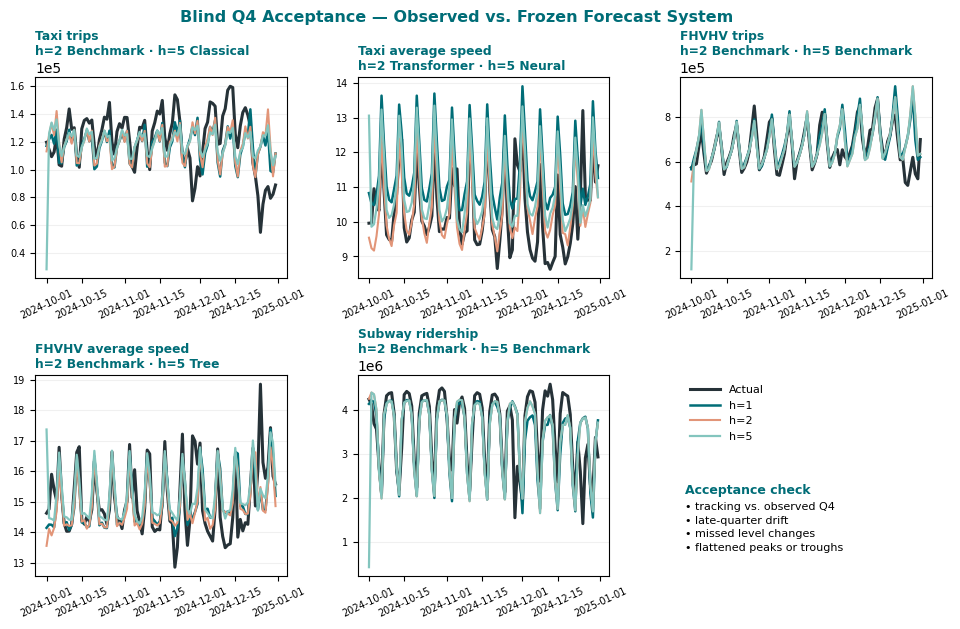

PASS — blind-Q4 trajectory review created for all five mobility targets.


In [193]:
# ---------------------------------------------------------------------
# 5.1.1.8G — Visualize the blind-Q4 trajectories
# ---------------------------------------------------------------------

Q4_SPEED_WEIGHT_METRICS = {
    "taxi_avg_trip_speed": "taxi_trip_count",
    "fhvhv_avg_trip_speed": "fhvhv_trip_count",
}

Q4_TRAJECTORY_KEYS = [
    "taxi_zone_id",
    "target_observation_sequence_id",
    "target_date",
]


def q4_daily_trajectory(
    frame: pd.DataFrame,
    metric: str,
    value_column: str,
) -> pd.DataFrame:
    """
    Aggregate one Q4 path to a daily citywide series.

    All speed lines use the same observed Q4 trip-volume weights so visual
    differences reflect forecasted speed, not changing aggregation weights.
    """
    value_rows = (
        frame.loc[frame["metric"].eq(metric)].copy()
        if "metric" in frame.columns
        else frame.copy()
    )

    require_columns(
        value_rows,
        [*Q4_TRAJECTORY_KEYS, value_column],
        f"Q4 · {metric} · {value_column}",
    )

    value_rows["target_date"] = pd.to_datetime(
        value_rows["target_date"]
    ).dt.normalize()
    value_rows[value_column] = pd.to_numeric(
        value_rows[value_column], errors="coerce"
    )
    value_rows = value_rows.loc[value_rows[value_column].notna()].copy()

    if metric in COUNT_TARGETS:
        return (
            value_rows
            .groupby("target_date", as_index=False, observed=True)[value_column]
            .sum(min_count=1)
            .rename(columns={value_column: "value"})
        )

    weight_metric = Q4_SPEED_WEIGHT_METRICS[metric]

    weight_rows = (
        q4_h1_df.loc[
            q4_h1_df["metric"].eq(weight_metric),
            [*Q4_TRAJECTORY_KEYS, "target_observed_value"],
        ]
        .rename(columns={"target_observed_value": "activity_weight"})
        .copy()
    )

    weight_rows["target_date"] = pd.to_datetime(
        weight_rows["target_date"]
    ).dt.normalize()
    weight_rows["activity_weight"] = pd.to_numeric(
        weight_rows["activity_weight"], errors="coerce"
    )

    weighted = value_rows.merge(
        weight_rows,
        on=Q4_TRAJECTORY_KEYS,
        how="inner",
        validate="one_to_one",
    )

    weighted = weighted.loc[
        weighted["activity_weight"].notna()
        & weighted["activity_weight"].gt(0)
    ].copy()

    weighted["weighted_value"] = (
        weighted[value_column] * weighted["activity_weight"]
    )

    daily = (
        weighted
        .groupby("target_date", as_index=False, observed=True)
        .agg(
            weighted_sum=("weighted_value", "sum"),
            weight_sum=("activity_weight", "sum"),
        )
    )
    daily["value"] = daily["weighted_sum"] / daily["weight_sum"]

    return daily[["target_date", "value"]]


q4_trajectory_by_metric = {}

for metric in FORECAST_TARGETS:
    metric_series = {
        "Actual": q4_daily_trajectory(
            q4_h1_df, metric, "target_observed_value"
        ),
        "h=1": q4_daily_trajectory(
            q4_h1_df, metric, "system_prediction"
        ),
    }

    for horizon in FAR_HORIZONS:
        far_frame = q4_far_df.loc[
            q4_far_df["metric"].eq(metric)
            & q4_far_df["horizon"].astype(int).eq(int(horizon))
        ].copy()

        metric_series[f"h={horizon}"] = q4_daily_trajectory(
            far_frame, metric, "system_prediction"
        )

    q4_trajectory_by_metric[metric] = metric_series


fig, axes = plt.subplots(2, 3, figsize=(9.8, 6.4))
axes = axes.ravel()

metric_axes = {
    "taxi_trip_count": axes[0],
    "taxi_avg_trip_speed": axes[1],
    "fhvhv_trip_count": axes[2],
    "fhvhv_avg_trip_speed": axes[3],
    "subway_ridership": axes[4],
}

line_styles = {
    "Actual": {"color": "#263238", "linewidth": 2.2},
    "h=1": {"color": BRAND_COLORS["dark_teal"], "linewidth": 1.8},
    "h=2": {"color": BRAND_COLORS["terracotta"], "linewidth": 1.5},
    "h=5": {"color": BRAND_COLORS["seafoam"], "linewidth": 1.6},
}


def q4_head_label(metric: str, horizon: int) -> str:
    """Return the short frozen head label shown in each panel title."""
    match = far_frozen_roster_df.loc[
        far_frozen_roster_df["metric"].eq(metric)
        & far_frozen_roster_df["horizon"].eq(int(horizon))
    ]

    if len(match) != 1:
        raise RuntimeError(f"{metric} · h={horizon}: frozen head is not unique.")

    row = match.iloc[0]

    if str(row["primary_head_type"]) == "benchmark":
        return "Benchmark"

    return FAMILY_LABELS[str(row["primary_family"])].split(" · ")[0]


for metric, ax in metric_axes.items():
    for series_name in ["Actual", "h=1", "h=2", "h=5"]:
        daily_df = (
            q4_trajectory_by_metric[metric][series_name]
            .sort_values("target_date")
        )
        style = line_styles[series_name]

        ax.plot(
            daily_df["target_date"],
            daily_df["value"],
            label=series_name,
            color=style["color"],
            linewidth=style["linewidth"],
        )

    ax.set_title(
        f"{TARGET_LABELS[metric]}\n"
        f"h=2 {q4_head_label(metric, 2)} · "
        f"h=5 {q4_head_label(metric, 5)}",
        loc="left",
        fontsize=8.8,
        fontweight="bold",
        color=BRAND_COLORS["dark_teal"],
        pad=5,
    )

    ax.grid(axis="y", alpha=0.18)
    ax.tick_params(axis="both", labelsize=7)
    ax.tick_params(axis="x", rotation=25)

    if metric in COUNT_TARGETS:
        ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))


guide_ax = axes[5]
guide_ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()

guide_ax.legend(
    handles,
    labels,
    loc="upper left",
    frameon=False,
    fontsize=8,
    handlelength=2.7,
)

guide_ax.text(
    0.02,
    0.46,
    "Acceptance check",
    transform=guide_ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    fontweight="bold",
    color=BRAND_COLORS["dark_teal"],
)

guide_ax.text(
    0.02,
    0.37,
    "• tracking vs. observed Q4\n"
    "• late-quarter drift\n"
    "• missed level changes\n"
    "• flattened peaks or troughs",
    transform=guide_ax.transAxes,
    ha="left",
    va="top",
    fontsize=8,
    linespacing=1.45,
)

fig.suptitle(
    "Blind Q4 Acceptance — Observed vs. Frozen Forecast System",
    fontsize=11.5,
    fontweight="bold",
    color=BRAND_COLORS["dark_teal"],
    y=0.985,
)

fig.subplots_adjust(
    left=0.07,
    right=0.985,
    bottom=0.10,
    top=0.88,
    hspace=0.48,
    wspace=0.28,
)

plt.show()

print(
    "PASS — blind-Q4 trajectory review created for all five mobility targets.",
    flush=True,
)


**Findings.** The Q4 trajectories preserve the main weekly structure across all five mobility targets. None shows runaway drift, collapse, or a progressive loss of the recurring pattern as the synthetic history grows longer.

The two speed targets remain especially stable. Taxi and FHVHV average speed continue to track the observed cycles closely, even when the observed level moves temporarily.

The larger misses are again in demand. Taxi trips, FHVHV trips, and Subway ridership show several late-quarter level changes that the smoother forecast paths do not fully follow. That matches the scorecard, where late-versus-early error is larger for the demand targets.

The visual review therefore supports the numerical Q4 result: the quarter is harder than Q3, but the frozen forecasting system remains structurally stable.

### Section 8 Summary — The frozen system survives the blind Q4 test

Q4 provides the first completely untouched test of the 15-job forecasting system. Relative MAE is higher than in Q3 for every job, but the increases remain bounded between 0.500 and 3.287 percentage points rather than revealing a sudden failure.

The structural checks are stronger. All five h=1 state channels complete the quarter with valid nonnegative mobility, all ten farther-horizon jobs remain read-only, and all expected Target × Horizon jobs are present. Fourteen jobs retain essentially complete primary coverage; Taxi-trip h=5 SARIMAX continues to rely on its planned benchmark fallback for about 16% of rows.

The trajectories tell the same story. Weekly structure remains intact, while several demand forecasts miss late-quarter changes in level. That is a forecasting limitation to carry forward, not evidence that the recursive system has broken.

The frozen roster therefore reaches the production decision unchanged. Section 9 can accept or reject that system, but it does not get to tune it against Q4.

## 5.1.1.9 — Refit the Accepted System for Production

Q4 was our last independent test of the forecasting system before production. Nothing in that quarter was used to choose a model, change a formulation, or tune a fitting rule.

If the frozen system passes that test, we can finally use all legally available Pre-CP information through January 4, 2025. This is a production refit, not another model-selection round: the h=1 engines, h=2/h=5 heads, formulations, benchmark decisions, and training rules are already frozen.

The main methodological guard is unchanged. The h=1 models were selected because they behaved well inside long synthetic rollouts, so the final refit must preserve those recursive-aware training semantics. We do not replace them with ordinary models trained only on pristine factual histories simply because more factual observations are now available.

**5.1.1.9A — Decision: accept the frozen system for production**

The Q4 scorecard and trajectory review are the final evidence used to decide whether the frozen 15-job system is suitable for the production counterfactual.

This is a true decision rather than an automatic threshold check. Q4 can differ from Q3 without implying failure; the question is whether the independent quarter reveals a material breakdown in accuracy, coverage, bias, late-rollout behavior, or trajectory shape that undermines the system we intend to run for fifteen months.

If accepted, the forecasting roster remains unchanged. If rejected, we stop here rather than tuning repeatedly against Q4 until it passes.

Once a GO decision is written for the current Q4 acceptance contract, later clean reruns recover that decision from disk. The notebook should not require a second human approval merely because the kernel was restarted.

In [195]:
# ---------------------------------------------------------------------
# 5.1.1.9A — Freeze or recover the blind-Q4 production decision
# ---------------------------------------------------------------------

Q4_PRODUCTION_DECISION_CONTRACT_ID = (
    f"{Q4_ACCEPTANCE_CONTRACT_ID}__production_decision_v1"
)

Q4_PRODUCTION_DECISION_PATH = (
    Q4_ACCEPTANCE_ROOT / "q4_production_acceptance_decision.parquet"
)

# This is a true analytical decision. Leave False until the completed
# 8F scorecard and 8G trajectories have been reviewed. Once a current-
# contract GO artifact exists, ordinary reruns recover it automatically.
APPROVE_Q4_FOR_PRODUCTION = True


# ---------------------------------------------------------------------
# The decision is allowed only after all blind-Q4 evidence is durable.
# ---------------------------------------------------------------------

for path, label in [
    (Q4_ACCEPTANCE_SCORECARD_PATH, "Blind-Q4 acceptance scorecard"),
    (Q4_ACCEPTANCE_QA_PATH, "Blind-Q4 execution QA"),
    (FROZEN_FORECAST_SYSTEM_PATH, "Frozen 15-job forecasting roster"),
]:
    require_file(path, label)


q4_acceptance_scorecard_df = pd.read_parquet(
    Q4_ACCEPTANCE_SCORECARD_PATH
)

q4_acceptance_qa_df = pd.read_parquet(
    Q4_ACCEPTANCE_QA_PATH
)

frozen_forecast_system_df = pd.read_parquet(
    FROZEN_FORECAST_SYSTEM_PATH
)


require_columns(
    q4_acceptance_scorecard_df,
    [
        "metric",
        "horizon",
        "q3_relative_mae_pct",
        "q4_relative_mae_pct",
        "q4_relative_bias_pct",
        "q4_primary_coverage_pct",
        "q4_fallback_pct",
        "q4_late_minus_early_pp",
    ],
    "Blind-Q4 acceptance scorecard",
)

require_columns(
    q4_acceptance_qa_df,
    ["Check", "Passed", "Observed", "Expected"],
    "Blind-Q4 execution QA",
)

require_columns(
    frozen_forecast_system_df,
    [
        "system_contract_id",
        "metric",
        "horizon",
        "primary_head_type",
        "primary_family",
        "formulation",
        "primary_head_id",
        "benchmark_id",
    ],
    "Frozen 15-job forecasting roster",
)


expected_jobs = {
    (metric, int(horizon))
    for metric in FORECAST_TARGETS
    for horizon in FORECAST_HORIZONS
}

scorecard_jobs = {
    (str(metric), int(horizon))
    for metric, horizon in q4_acceptance_scorecard_df[
        ["metric", "horizon"]
    ].itertuples(index=False)
}

roster_jobs = {
    (str(metric), int(horizon))
    for metric, horizon in frozen_forecast_system_df[
        ["metric", "horizon"]
    ].itertuples(index=False)
}


if scorecard_jobs != expected_jobs:
    raise RuntimeError(
        "The blind-Q4 decision requires the exact 15 Target × Horizon "
        "jobs in the acceptance scorecard."
    )

if roster_jobs != expected_jobs:
    raise RuntimeError(
        "The frozen production roster no longer contains the exact "
        "15 Target × Horizon jobs."
    )

if q4_acceptance_scorecard_df[
    ["metric", "horizon"]
].duplicated().any():
    raise RuntimeError(
        "The blind-Q4 acceptance scorecard contains duplicate jobs."
    )

if frozen_forecast_system_df[
    ["metric", "horizon"]
].duplicated().any():
    raise RuntimeError(
        "The frozen production roster contains duplicate jobs."
    )

if not q4_acceptance_qa_df["Passed"].fillna(False).astype(bool).all():
    failed_checks = q4_acceptance_qa_df.loc[
        ~q4_acceptance_qa_df["Passed"].fillna(False).astype(bool),
        "Check",
    ].astype(str).tolist()

    raise RuntimeError(
        "Q4 execution QA must pass before a production decision: "
        + "; ".join(failed_checks)
    )

system_contract_ids = set(
    frozen_forecast_system_df["system_contract_id"]
    .dropna()
    .astype(str)
)

if system_contract_ids != {FROZEN_FORECAST_SYSTEM_CONTRACT_ID}:
    raise RuntimeError(
        "The frozen production roster belongs to an unexpected "
        "forecast-system contract."
    )


# ---------------------------------------------------------------------
# Recover an already-frozen GO decision before consulting the source
# toggle. A kernel restart must not erase a completed human decision.
# ---------------------------------------------------------------------

if Q4_PRODUCTION_DECISION_PATH.exists():
    q4_production_decision_df = pd.read_parquet(
        Q4_PRODUCTION_DECISION_PATH
    )

    require_columns(
        q4_production_decision_df,
        [
            "decision_contract_id",
            "acceptance_contract_id",
            "system_contract_id",
            "decision",
            "q4_start_date",
            "q4_end_date",
            "accepted_jobs",
            "final_refit_end_date",
            "final_refit_end_sequence_id",
            "counterfactual_start_date",
            "counterfactual_start_sequence_id",
        ],
        "Blind-Q4 production decision",
    )

    if len(q4_production_decision_df) != 1:
        raise RuntimeError(
            "Expected exactly one frozen blind-Q4 production decision."
        )

    recovered_decision = q4_production_decision_df.iloc[0]

    recovered_checks = {
        "decision contract": (
            str(recovered_decision["decision_contract_id"])
            == Q4_PRODUCTION_DECISION_CONTRACT_ID
        ),
        "acceptance contract": (
            str(recovered_decision["acceptance_contract_id"])
            == Q4_ACCEPTANCE_CONTRACT_ID
        ),
        "system contract": (
            str(recovered_decision["system_contract_id"])
            == FROZEN_FORECAST_SYSTEM_CONTRACT_ID
        ),
        "GO decision": str(recovered_decision["decision"]) == "GO",
        "Q4 start": (
            pd.Timestamp(recovered_decision["q4_start_date"]).normalize()
            == Q4_START_DATE
        ),
        "Q4 end": (
            pd.Timestamp(recovered_decision["q4_end_date"]).normalize()
            == Q4_END_DATE
        ),
        "15 accepted jobs": int(recovered_decision["accepted_jobs"]) == 15,
        "final refit date": (
            pd.Timestamp(
                recovered_decision["final_refit_end_date"]
            ).normalize()
            == FINAL_OBSERVED_DATE
        ),
        "final refit sequence": (
            int(recovered_decision["final_refit_end_sequence_id"])
            == FINAL_OBSERVED_SEQUENCE_ID
        ),
        "counterfactual start date": (
            pd.Timestamp(
                recovered_decision["counterfactual_start_date"]
            ).normalize()
            == COUNTERFACTUAL_START_DATE
        ),
        "counterfactual start sequence": (
            int(
                recovered_decision[
                    "counterfactual_start_sequence_id"
                ]
            )
            == COUNTERFACTUAL_START_SEQUENCE_ID
        ),
    }

    failed_recovered_checks = [
        name
        for name, passed in recovered_checks.items()
        if not passed
    ]

    if failed_recovered_checks:
        raise RuntimeError(
            "The recovered blind-Q4 production decision is stale or "
            "incompatible: "
            + "; ".join(failed_recovered_checks)
        )

    decision_action = "recovered"


elif APPROVE_Q4_FOR_PRODUCTION:
    q4_production_decision_df = pd.DataFrame(
        [
            {
                "decision_contract_id": (
                    Q4_PRODUCTION_DECISION_CONTRACT_ID
                ),
                "acceptance_contract_id": (
                    Q4_ACCEPTANCE_CONTRACT_ID
                ),
                "system_contract_id": (
                    FROZEN_FORECAST_SYSTEM_CONTRACT_ID
                ),
                "decision": "GO",
                "q4_start_date": Q4_START_DATE,
                "q4_end_date": Q4_END_DATE,
                "accepted_jobs": len(expected_jobs),
                "final_refit_end_date": FINAL_OBSERVED_DATE,
                "final_refit_end_sequence_id": (
                    FINAL_OBSERVED_SEQUENCE_ID
                ),
                "counterfactual_start_date": (
                    COUNTERFACTUAL_START_DATE
                ),
                "counterfactual_start_sequence_id": (
                    COUNTERFACTUAL_START_SEQUENCE_ID
                ),
            }
        ]
    )

    atomic_write_parquet(
        q4_production_decision_df,
        Q4_PRODUCTION_DECISION_PATH,
    )

    decision_action = "frozen"


else:
    q4_production_decision_df = pd.DataFrame()
    decision_action = "pending"


if decision_action in {"frozen", "recovered"}:
    display(q4_production_decision_df)

    print(
        "DECISION — blind Q4 accepted for production "
        f"({decision_action}) | "
        f"final refit through {FINAL_OBSERVED_DATE.date()} | "
        f"counterfactual begins {COUNTERFACTUAL_START_DATE.date()}.",
        flush=True,
    )

else:
    print(
        "DECISION PENDING — review the completed blind-Q4 scorecard "
        "and trajectories, then set APPROVE_Q4_FOR_PRODUCTION=True "
        "only if the frozen system is accepted unchanged.",
        flush=True,
    )

,decision_contract_id,acceptance_contract_id,system_contract_id,decision,q4_start_date,q4_end_date,accepted_jobs,final_refit_end_date,final_refit_end_sequence_id,counterfactual_start_date,counterfactual_start_sequence_id
0,recursive_h1_q3_selection_v1__h1_frozen_v1__h2...,recursive_h1_q3_selection_v1__h1_frozen_v1__h2...,recursive_h1_q3_selection_v1__h1_frozen_v1__h2...,GO,2024-10-01,2024-12-31,15,2025-01-04,3675,2025-01-05,3676


DECISION — blind Q4 accepted for production (recovered) | final refit through 2025-01-04 | counterfactual begins 2025-01-05.


**Findings.** Blind Q4 acceptance resulted in a **GO** decision for all 15 frozen Target × Horizon jobs. The production roster therefore moves forward unchanged, with final refitting allowed through **January 4, 2025** (observation sequence 3,675) and the no-congestion-pricing counterfactual beginning on **January 5, 2025** (sequence 3,676).

This is the point where model selection ends. From here forward, the notebook may use newer legal Pre-CP data to refit the accepted system, but it does not reopen families, formulations, or benchmark choices.


**5.1.1.9B — Define the production final-refit contract**

Acceptance does not reopen the forecasting tournament. It changes only the amount of legal factual history available for the final production fit.

The production boundary is January 5, 2025. Models that require fitted parameters may therefore use observations through January 4, including the January 1–4 interval that was deliberately kept out of model selection and Q4 acceptance.

The 15 production jobs now separate into three operational cases. The five h=1 engines require a recursive-aware production refit that preserves the synthetic-rollout training semantics used for selection. Selected advanced h=2/h=5 heads use their already-frozen family-specific fitting recipes. Benchmark-primary h=2/h=5 jobs have no fitted model to retrain; their forecasts will continue to be reconstructed from synthetic no-CP history at runtime.

This distinction is frozen explicitly before any production fitting begins. It also preserves which production heads have learned model states so later interpretation can compare counterfactual feature reliance with the ordinary forecasting analysis from Chapter 4 without reopening model development.

In [197]:
# ---------------------------------------------------------------------
# 5.1.1.9B — Define the production final-refit contract
# ---------------------------------------------------------------------

require_file(
    Q4_PRODUCTION_DECISION_PATH,
    "Blind-Q4 production decision",
)

require_file(
    FROZEN_FORECAST_SYSTEM_PATH,
    "Frozen 15-job forecasting roster",
)


q4_production_decision_df = pd.read_parquet(
    Q4_PRODUCTION_DECISION_PATH
)

if len(q4_production_decision_df) != 1:
    raise RuntimeError(
        "Expected exactly one blind-Q4 production decision."
    )

production_decision = q4_production_decision_df.iloc[0]

if (
    str(production_decision["decision_contract_id"])
    != Q4_PRODUCTION_DECISION_CONTRACT_ID
):
    raise RuntimeError(
        "The production decision belongs to a different decision contract."
    )

if (
    str(production_decision["acceptance_contract_id"])
    != Q4_ACCEPTANCE_CONTRACT_ID
):
    raise RuntimeError(
        "The production decision belongs to a different Q4 "
        "acceptance contract."
    )

if str(production_decision["decision"]) != "GO":
    raise RuntimeError(
        "Final refit cannot begin without a frozen GO decision."
    )

if (
    str(production_decision["system_contract_id"])
    != FROZEN_FORECAST_SYSTEM_CONTRACT_ID
):
    raise RuntimeError(
        "The production decision belongs to a different frozen system."
    )

if (
    pd.Timestamp(
        production_decision["final_refit_end_date"]
    ).normalize()
    != FINAL_OBSERVED_DATE
):
    raise RuntimeError(
        "The production decision carries the wrong final-refit date."
    )

if (
    int(production_decision["final_refit_end_sequence_id"])
    != FINAL_OBSERVED_SEQUENCE_ID
):
    raise RuntimeError(
        "The production decision carries the wrong final-refit "
        "sequence boundary."
    )

if (
    pd.Timestamp(
        production_decision["counterfactual_start_date"]
    ).normalize()
    != COUNTERFACTUAL_START_DATE
):
    raise RuntimeError(
        "The production decision carries the wrong counterfactual "
        "start date."
    )

if (
    int(production_decision["counterfactual_start_sequence_id"])
    != COUNTERFACTUAL_START_SEQUENCE_ID
):
    raise RuntimeError(
        "The production decision carries the wrong counterfactual "
        "start sequence."
    )


FINAL_REFIT_CONTRACT_ID = (
    f"{FROZEN_FORECAST_SYSTEM_CONTRACT_ID}__"
    "production_refit_2025_01_04_v1"
)

FINAL_REFIT_ROOT = (
    INTERMEDIATE_DIR
    / "production_final_refit"
    / FINAL_REFIT_CONTRACT_ID
)

FINAL_REFIT_MODEL_DIR = FINAL_REFIT_ROOT / "model_states"
FINAL_REFIT_PREPROCESSING_DIR = (
    FINAL_REFIT_ROOT / "preprocessing_states"
)
FINAL_REFIT_AUDIT_DIR = FINAL_REFIT_ROOT / "audits"

FINAL_REFIT_JOB_REGISTRY_PATH = (
    FINAL_REFIT_ROOT / "final_refit_job_registry.parquet"
)

FINAL_REFIT_STATE_REGISTRY_PATH = (
    FINAL_REFIT_ROOT / "final_refit_state_registry.parquet"
)


for directory in [
    FINAL_REFIT_ROOT,
    FINAL_REFIT_MODEL_DIR,
    FINAL_REFIT_PREPROCESSING_DIR,
    FINAL_REFIT_AUDIT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


frozen_forecast_system_df = pd.read_parquet(
    FROZEN_FORECAST_SYSTEM_PATH
)

require_columns(
    frozen_forecast_system_df,
    [
        "system_contract_id",
        "metric",
        "horizon",
        "primary_head_type",
        "primary_family",
        "formulation",
        "primary_head_id",
        "benchmark_id",
    ],
    "Frozen 15-job forecasting roster",
)


expected_jobs = {
    (metric, int(horizon))
    for metric in FORECAST_TARGETS
    for horizon in FORECAST_HORIZONS
}

actual_jobs = {
    (str(metric), int(horizon))
    for metric, horizon in frozen_forecast_system_df[
        ["metric", "horizon"]
    ].itertuples(index=False)
}

if actual_jobs != expected_jobs:
    missing_jobs = sorted(expected_jobs - actual_jobs)
    extra_jobs = sorted(actual_jobs - expected_jobs)

    raise RuntimeError(
        "The production final-refit contract no longer covers the "
        "exact 15 frozen jobs. "
        f"Missing={missing_jobs}; extra={extra_jobs}."
    )

if frozen_forecast_system_df[
    ["metric", "horizon"]
].duplicated().any():
    raise RuntimeError(
        "The final-refit registry source contains duplicate "
        "Target × Horizon jobs."
    )

system_contract_ids = set(
    frozen_forecast_system_df["system_contract_id"]
    .dropna()
    .astype(str)
)

if system_contract_ids != {FROZEN_FORECAST_SYSTEM_CONTRACT_ID}:
    raise RuntimeError(
        "The final-refit roster belongs to an unexpected "
        "forecast-system contract."
    )


# ---------------------------------------------------------------------
# Freeze the three production-refit semantics.
#
# WHY:
# h=1 is the state-writing engine and must preserve recursive-aware
# training. Advanced h=2/h=5 heads are read-only forecast heads with
# their own frozen recipes. Benchmark-primary heads have no learned
# model state to refit.
# ---------------------------------------------------------------------

def production_refit_kind(row) -> str:
    """Return the frozen production-refit role for one selected job."""
    horizon = int(row.horizon)
    head_type = str(row.primary_head_type)

    if horizon == 1:
        if head_type != "advanced":
            raise RuntimeError(
                f"{row.metric} · h=1 must remain an advanced "
                "recursive state engine."
            )

        return "h1_recursive_aware"

    if horizon in {2, 5}:
        if head_type == "advanced":
            return "far_horizon_advanced"

        if head_type == "benchmark":
            return "runtime_benchmark"

    raise RuntimeError(
        f"Unsupported production refit role for "
        f"{row.metric} · h={horizon} · {head_type}."
    )


final_refit_job_registry_df = (
    frozen_forecast_system_df
    .copy()
    .assign(
        final_refit_contract_id=FINAL_REFIT_CONTRACT_ID,
        final_refit_job_id=lambda frame: (
            frame["metric"].astype(str)
            + "__h"
            + frame["horizon"].astype(int).astype(str)
        ),
        final_refit_end_date=FINAL_OBSERVED_DATE,
        final_refit_end_sequence_id=FINAL_OBSERVED_SEQUENCE_ID,
        counterfactual_start_date=COUNTERFACTUAL_START_DATE,
        counterfactual_start_sequence_id=(
            COUNTERFACTUAL_START_SEQUENCE_ID
        ),
    )
)

final_refit_job_registry_df["refit_kind"] = [
    production_refit_kind(row)
    for row in final_refit_job_registry_df.itertuples(index=False)
]

final_refit_job_registry_df["refit_required"] = (
    final_refit_job_registry_df["refit_kind"]
    .ne("runtime_benchmark")
)

# Learned production heads retain fitted model/preprocessing artifacts
# so a later, small interpretation notebook can compare their feature
# reliance with the ordinary forecasting evidence from Chapter 4.
final_refit_job_registry_df["feature_reliance_eligible"] = (
    final_refit_job_registry_df["refit_required"]
)


if final_refit_job_registry_df["final_refit_job_id"].duplicated().any():
    raise RuntimeError(
        "The final-refit registry contains duplicate job identities."
    )

if (
    final_refit_job_registry_df["metric"].nunique()
    != len(FORECAST_TARGETS)
):
    raise RuntimeError(
        "The final-refit registry no longer covers all five targets."
    )


refit_kind_counts = (
    final_refit_job_registry_df["refit_kind"]
    .value_counts()
    .to_dict()
)

expected_refit_kind_counts = {
    "h1_recursive_aware": 5,
    "far_horizon_advanced": 4,
    "runtime_benchmark": 6,
}

if refit_kind_counts != expected_refit_kind_counts:
    raise RuntimeError(
        "The production-refit roles no longer match the frozen "
        "15-job system. "
        f"Observed={refit_kind_counts}; "
        f"expected={expected_refit_kind_counts}."
    )


atomic_write_parquet(
    final_refit_job_registry_df,
    FINAL_REFIT_JOB_REGISTRY_PATH,
)


final_refit_display_df = (
    final_refit_job_registry_df
    .assign(
        Target=lambda frame: frame["metric"].map(TARGET_LABELS),
        Head=lambda frame: np.where(
            frame["primary_head_type"].eq("benchmark"),
            "Benchmark",
            frame["primary_family"].map(FAMILY_LABELS),
        ),
        Action=lambda frame: frame["refit_kind"].map(
            {
                "h1_recursive_aware": (
                    "Recursive-aware production refit"
                ),
                "far_horizon_advanced": (
                    "Refit frozen advanced head"
                ),
                "runtime_benchmark": (
                    "No fitted model — synthetic benchmark"
                ),
            }
        ),
        Interpretation=lambda frame: np.where(
            frame["feature_reliance_eligible"],
            "Learned head",
            "Benchmark only",
        ),
    )
    [
        [
            "Target",
            "horizon",
            "Head",
            "formulation",
            "Action",
            "Interpretation",
        ]
    ]
    .rename(
        columns={
            "horizon": "Horizon",
            "formulation": "Formulation",
        }
    )
)

display(final_refit_display_df)

print(
    "READY — production final-refit contract frozen | "
    "5 recursive-aware h=1 engines | "
    "4 advanced farther-horizon heads | "
    "6 runtime benchmark heads | "
    f"legal factual cutoff={FINAL_OBSERVED_DATE.date()} | "
    f"production start={COUNTERFACTUAL_START_DATE.date()}.",
    flush=True,
)

,Target,Horizon,Head,Formulation,Action,Interpretation
0,FHVHV average speed,1,Tree · LightGBM,anchor_residual,Recursive-aware production refit,Learned head
1,FHVHV trips,1,Neural · Lag-window MLP,anchor_residual,Recursive-aware production refit,Learned head
2,Subway ridership,1,Neural · Lag-window MLP,anchor_residual,Recursive-aware production refit,Learned head
3,Taxi average speed,1,Neural · Lag-window MLP,direct_level,Recursive-aware production refit,Learned head
4,Taxi trips,1,Neural · Lag-window MLP,anchor_residual,Recursive-aware production refit,Learned head
5,FHVHV average speed,2,Benchmark,None,No fitted model — synthetic benchmark,Benchmark only
6,FHVHV trips,2,Benchmark,None,No fitted model — synthetic benchmark,Benchmark only
7,Subway ridership,2,Benchmark,None,No fitted model — synthetic benchmark,Benchmark only
8,Taxi average speed,2,Transformer · PatchTST-inspired,None,Refit frozen advanced head,Learned head
9,Taxi trips,2,Benchmark,None,No fitted model — synthetic benchmark,Benchmark only


READY — production final-refit contract frozen | 5 recursive-aware h=1 engines | 4 advanced farther-horizon heads | 6 runtime benchmark heads | legal factual cutoff=2025-01-04 | production start=2025-01-05.


**Findings.** The production refit contract contains all **15 frozen Target × Horizon jobs**. Five h=1 learned engines receive recursive-aware production refits, while h=2/h=5 contain **four learned heads** that require refitting and **six benchmark-only heads** that need no fitted model.

The learned farther-horizon heads are Transformer for Taxi speed h=2, Tree for FHVHV speed h=5, Neural for Taxi speed h=5, and SARIMAX for Taxi trips h=5. All refits may use factual mobility only through **January 4, 2025**; production begins **January 5, 2025**. The contract therefore updates the accepted models with the newest legal Pre-CP information without reopening the selected roster.

**5.1.1.9C — Assemble the production final-refit training surfaces**

The final refit can now use every training source that is legally available through January 4, 2025.

For the five h=1 engines, the strongest production evidence comes from the six completed mixed-system worlds: the four historical rehearsals, Q3 selection, and blind Q4 acceptance. Each world preserves the same five-engine synthetic environment that the production system will use after January 5. The authoritative January 1–4 final-refit supplement adds the newest factual Pre-CP observations as a seventh training source.

The existing episode states, recursive feature builders, anchor machinery, farther-horizon surfaces, and upstream final-refit supplement are reused directly. This section materializes the compact selected-engine examples needed for production fitting and freezes the January 4 production anchor. Small success markers make those surfaces restartable without rescanning their full contents on ordinary reruns.

In [199]:
# ---------------------------------------------------------------------
# 5.1.1.9C — Assemble the production final-refit training surfaces
# ---------------------------------------------------------------------

RUN_FINAL_REFIT_SURFACES = True
RESET_FINAL_REFIT_SURFACES = False

FINAL_REFIT_SURFACE_CONTRACT_ID = (
    f"{FINAL_REFIT_CONTRACT_ID}__training_surfaces_v1"
)

FINAL_REFIT_SURFACE_DIR = FINAL_REFIT_ROOT / "training_surfaces"
FINAL_REFIT_H1_SURFACE_DIR = FINAL_REFIT_SURFACE_DIR / "h1"
FINAL_REFIT_H1_SURFACE_SUCCESS_DIR = (
    FINAL_REFIT_SURFACE_DIR / "h1_success"
)
FINAL_REFIT_SURFACE_AUDIT_PATH = (
    FINAL_REFIT_AUDIT_DIR / "final_refit_training_surface_audit.parquet"
)

PRODUCTION_ANCHOR_ID = "production_refit_2025_01_04"
PRODUCTION_ANCHOR_PATH = (
    FINAL_REFIT_SURFACE_DIR
    / f"{PRODUCTION_ANCHOR_ID}__{ANCHOR_SCHEMA_VERSION}.parquet"
)

FINAL_REFIT_SUPPLEMENT_PATH = upstream_paths[
    "pre_cp_final_refit_training_supplement"
]

for directory in [
    FINAL_REFIT_SURFACE_DIR,
    FINAL_REFIT_H1_SURFACE_DIR,
    FINAL_REFIT_H1_SURFACE_SUCCESS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

require_file(
    FINAL_REFIT_JOB_REGISTRY_PATH,
    "Production final-refit job registry",
)
require_file(
    FINAL_REFIT_SUPPLEMENT_PATH,
    "January 1–4 final-refit training supplement",
)

final_refit_job_registry_df = pd.read_parquet(
    FINAL_REFIT_JOB_REGISTRY_PATH
)

h1_final_refit_jobs_df = (
    final_refit_job_registry_df.loc[
        final_refit_job_registry_df["refit_kind"].eq(
            "h1_recursive_aware"
        )
    ]
    .sort_values("metric")
    .reset_index(drop=True)
)

if len(h1_final_refit_jobs_df) != len(FORECAST_TARGETS):
    raise RuntimeError(
        "Production h=1 refit must contain exactly five selected engines."
    )


# ---------------------------------------------------------------------
# Reuse the six completed mixed-system worlds as the recursive-aware
# production evidence. The small January 1–4 supplement is the seventh source.
# ---------------------------------------------------------------------

PRODUCTION_SYNTHETIC_WORLD_IDS = [
    *H1_TRAINING_EPISODE_IDS,
    H1_SELECTION_EPISODE_ID,
    H1_ACCEPTANCE_EPISODE_ID,
]

FINAL_REFIT_FACTUAL_TAIL_ID = "final_refit_2025_01_01_04"
PRODUCTION_H1_TRAINING_SOURCE_IDS = [
    *PRODUCTION_SYNTHETIC_WORLD_IDS,
    FINAL_REFIT_FACTUAL_TAIL_ID,
]


def production_h1_example_path(
    metric: str,
    source_world_id: str,
) -> Path:
    """Return one compact Target × training-source h=1 refit surface."""
    return (
        FINAL_REFIT_H1_SURFACE_DIR
        / metric
        / f"{source_world_id}.parquet"
    )


def production_h1_example_success_path(
    metric: str,
    source_world_id: str,
) -> Path:
    """Return the tiny completion marker for one materialized refit surface."""
    return (
        FINAL_REFIT_H1_SURFACE_SUCCESS_DIR
        / metric
        / f"{source_world_id}.parquet"
    )


def write_production_h1_example(
    frame: pd.DataFrame,
    *,
    metric: str,
    source_world_id: str,
) -> None:
    """Publish one training surface first and its compact success marker last."""
    path = production_h1_example_path(metric, source_world_id)
    atomic_write_parquet(frame, path)

    marker_df = pd.DataFrame(
        [
            {
                "final_refit_surface_contract_id": (
                    FINAL_REFIT_SURFACE_CONTRACT_ID
                ),
                "metric": metric,
                "training_source_id": source_world_id,
                "surface_rows": len(frame),
                "surface_path": str(path),
                "status": "success",
            }
        ]
    )
    atomic_write_parquet(
        marker_df,
        production_h1_example_success_path(metric, source_world_id),
    )


def production_h1_example_is_current(
    metric: str,
    source_world_id: str,
) -> bool:
    """Recover one surface from its tiny marker and Parquet row metadata."""
    path = production_h1_example_path(metric, source_world_id)
    marker_path = production_h1_example_success_path(
        metric, source_world_id
    )

    if not path.exists() or not marker_path.exists():
        return False

    try:
        marker_df = pd.read_parquet(marker_path)
    except Exception:
        return False

    if len(marker_df) != 1:
        return False

    marker = marker_df.iloc[0]

    return bool(
        str(marker["final_refit_surface_contract_id"])
        == FINAL_REFIT_SURFACE_CONTRACT_ID
        and str(marker["metric"]) == metric
        and str(marker["training_source_id"]) == source_world_id
        and str(marker["status"]) == "success"
        and h1_parquet_row_count(path) == int(marker["surface_rows"])
        and int(marker["surface_rows"]) > 0
    )


def load_production_h1_world_state(source_world_id: str) -> dict:
    """Restore the already-completed state behind one production training source."""
    if source_world_id == FINAL_REFIT_FACTUAL_TAIL_ID:
        return factual_h1_state()

    if source_world_id == H1_ACCEPTANCE_EPISODE_ID:
        return load_q4_h1_state()

    return load_far_horizon_state(source_world_id)


def production_world_is_complete(source_world_id: str) -> bool:
    """Return whether one upstream mixed-system world is durably complete."""
    if source_world_id in H1_TRAINING_EPISODE_IDS:
        return historical_mixed_world_complete(source_world_id)

    if source_world_id == H1_SELECTION_EPISODE_ID:
        return h1_mixed_q3_complete()

    if source_world_id == H1_ACCEPTANCE_EPISODE_ID:
        return q4_h1_complete()

    raise KeyError(f"Unknown synthetic production world: {source_world_id}")


# ---------------------------------------------------------------------
# Freeze the final production anchor from every legal factual observation
# available through January 4. The existing anchor builder and schema are reused
# unchanged; only the cutoff advances to the real production boundary.
# ---------------------------------------------------------------------


def build_production_anchor() -> pd.DataFrame:
    """Build the Daypart anchor frozen at the real January 4 boundary."""
    anchor_history_df = historical_anchor_source_df.loc[
        historical_anchor_source_df["date"].le(FINAL_OBSERVED_DATE)
    ].copy()

    anchor_df = build_historical_anchor_snapshot(
        anchor_history_df,
        cutoff_date=FINAL_OBSERVED_DATE,
    )

    anchor_df.insert(0, "anchor_schema_version", ANCHOR_SCHEMA_VERSION)
    anchor_df.insert(1, "episode_id", PRODUCTION_ANCHOR_ID)
    anchor_df.insert(2, "episode_role", "production_refit")
    anchor_df.insert(3, "freeze_date", COUNTERFACTUAL_START_DATE)
    anchor_df.insert(4, "rollout_end_date", COUNTERFACTUAL_END_DATE)

    return anchor_df


def load_production_metric_anchor(metric: str) -> pd.DataFrame:
    """Load the production Daypart anchor in the normalized h=1 column contract."""
    local_value = f"anchor_local_{metric}"
    local_support = f"anchor_local_{metric}_n"
    local_fallback = f"anchor_local_{metric}_fallback"
    connected_value = f"anchor_connected_{metric}"
    connected_support = f"anchor_connected_{metric}_neighbor_n"

    anchor_df = pd.read_parquet(
        PRODUCTION_ANCHOR_PATH,
        columns=[
            "taxi_zone_id",
            "daypart",
            "anchor_month",
            local_value,
            local_support,
            local_fallback,
            connected_value,
            connected_support,
        ],
    )

    return anchor_df.rename(
        columns={
            local_value: "anchor_local_value",
            local_support: "anchor_local_support",
            local_fallback: "anchor_local_fallback",
            connected_value: "anchor_connected_value",
            connected_support: "anchor_connected_neighbor_support",
        }
    )


def attach_production_anchor_context(
    frame: pd.DataFrame,
    metric: str,
) -> pd.DataFrame:
    """Attach the January 4 production anchor to factual final-refit rows."""
    result = frame.copy()
    result["anchor_month"] = (
        pd.to_datetime(result["target_date"]).dt.month.astype("int8")
    )

    anchor_df = load_production_metric_anchor(metric).rename(
        columns={"daypart": "target_daypart"}
    )

    row_count_before = len(result)

    result = result.merge(
        anchor_df,
        on=["taxi_zone_id", "target_daypart", "anchor_month"],
        how="left",
        validate="many_to_one",
    )

    if len(result) != row_count_before:
        raise RuntimeError(
            f"{metric}: production-anchor attachment changed row count."
        )

    return result


# ---------------------------------------------------------------------
# Convert one completed mixed-system world into compact supervised examples for
# the five selected h=1 engines. The evolving mobility state is reused exactly;
# hidden historical outcomes enter only as supervised labels.
# ---------------------------------------------------------------------


def build_production_h1_synthetic_examples(
    source_world_id: str,
) -> dict[str, pd.DataFrame]:
    """Build the missing selected-engine refit examples from one synthetic world."""
    missing_jobs = [
        row
        for row in h1_final_refit_jobs_df.itertuples(index=False)
        if not production_h1_example_is_current(
            str(row.metric),
            source_world_id,
        )
    ]

    if not missing_jobs:
        return {}

    if not production_world_is_complete(source_world_id):
        raise RuntimeError(
            f"{source_world_id}: mixed-system world is not complete."
        )

    state = load_production_h1_world_state(source_world_id)

    target_ids = (
        recursive_episode_position_registry_df.loc[
            recursive_episode_position_registry_df["episode_id"].eq(
                source_world_id
            ),
            "target_observation_sequence_id",
        ]
        .astype(int)
        .sort_values()
        .tolist()
    )

    if not target_ids:
        raise RuntimeError(
            f"{source_world_id}: no registered h=1 positions were found."
        )

    example_parts = {
        str(row.metric): []
        for row in missing_jobs
    }

    progress = tqdm(
        target_ids,
        desc=f"production refit surface · {source_world_id}",
        leave=False,
    )

    for target_id in progress:
        origin_frame = load_h1_episode_origin_frame(
            source_world_id,
            int(target_id),
        )
        prepared_frame = prepare_h1_recursive_frame(
            origin_frame,
            state,
            episode_id=source_world_id,
        )

        for row in missing_jobs:
            metric = str(row.metric)
            family = str(row.primary_family)
            formulation = str(row.formulation)

            metric_frame = prepared_frame.loc[
                prepared_frame["metric"].eq(metric)
            ].copy()

            formulated = apply_h1_formulation(
                metric_frame,
                formulation=formulation,
            )

            supported = formulated.loc[
                formulated["training_target_available"]
                .fillna(False)
                .astype(bool)
            ].copy()

            keep_columns = h1_recursive_example_columns(
                family,
                metric,
                formulation,
            )

            missing_columns = [
                column
                for column in keep_columns
                if column not in supported.columns
            ]

            if missing_columns:
                raise RuntimeError(
                    f"{source_world_id} · {metric}: refit example is missing "
                    f"{missing_columns}."
                )

            supported = supported[keep_columns].copy()
            supported.insert(
                0,
                "final_refit_surface_contract_id",
                FINAL_REFIT_SURFACE_CONTRACT_ID,
            )
            supported.insert(1, "training_source_id", source_world_id)
            supported.insert(2, "training_source_type", "synthetic_world")

            example_parts[metric].append(supported)

    progress.close()

    outputs = {}

    for row in missing_jobs:
        metric = str(row.metric)
        parts = example_parts[metric]

        if not parts:
            raise RuntimeError(
                f"{source_world_id} · {metric}: no supported training rows."
            )

        frame = pd.concat(parts, ignore_index=True)

        if frame.duplicated(
            ["forecast_sequence_id", "target_observation_sequence_id"]
        ).any():
            raise RuntimeError(
                f"{source_world_id} · {metric}: duplicate training rows."
            )

        write_production_h1_example(
            frame,
            metric=metric,
            source_world_id=source_world_id,
        )
        outputs[metric] = frame

    return outputs



def build_production_h1_factual_tail(metric: str) -> pd.DataFrame:
    """Materialize January 1–4 factual examples for one selected h=1 engine."""
    job_match = h1_final_refit_jobs_df.loc[
        h1_final_refit_jobs_df["metric"].eq(metric)
    ]

    if len(job_match) != 1:
        raise RuntimeError(
            f"{metric}: expected one selected h=1 production job."
        )

    job = job_match.iloc[0]
    family = str(job["primary_family"])
    formulation = str(job["formulation"])

    frame = pd.read_parquet(
        FINAL_REFIT_SUPPLEMENT_PATH,
        filters=[
            ("modeling_track", "==", CHAPTER5_MODELING_TRACK),
            ("stage", "==", "final_refit_only"),
            ("metric", "==", metric),
            ("horizon", "==", 1),
        ],
    )

    if frame.empty:
        raise RuntimeError(
            f"{metric}: January 1–4 final-refit supplement is empty."
        )

    frame = attach_production_anchor_context(frame, metric)
    frame = apply_h1_formulation(frame, formulation=formulation)
    frame = frame.loc[
        frame["training_target_available"].fillna(False).astype(bool)
    ].copy()

    keep_columns = h1_recursive_example_columns(
        family,
        metric,
        formulation,
    )

    missing_columns = [
        column for column in keep_columns if column not in frame.columns
    ]

    if missing_columns:
        raise RuntimeError(
            f"{metric}: final-refit supplement is missing {missing_columns}."
        )

    frame = frame[keep_columns].copy()
    frame.insert(
        0,
        "final_refit_surface_contract_id",
        FINAL_REFIT_SURFACE_CONTRACT_ID,
    )
    frame.insert(1, "training_source_id", FINAL_REFIT_FACTUAL_TAIL_ID)
    frame.insert(2, "training_source_type", "factual_refit_tail")

    if frame.duplicated(
        ["forecast_sequence_id", "target_observation_sequence_id"]
    ).any():
        raise RuntimeError(
            f"{metric}: factual final-refit tail contains duplicate rows."
        )

    write_production_h1_example(
        frame,
        metric=metric,
        source_world_id=FINAL_REFIT_FACTUAL_TAIL_ID,
    )

    return frame


# ---------------------------------------------------------------------
# Reusable payload loaders for 9D/9E. Farther-horizon fitting consumes the four
# existing historical surfaces and simply extends them with Q3, Q4, and the
# already-packaged January 1–4 supervised supplement.
# ---------------------------------------------------------------------


def load_production_h1_training_payloads(metric: str) -> list[dict]:
    """Load all seven frozen h=1 production training sources for one target."""
    payloads = []

    for source_id in PRODUCTION_H1_TRAINING_SOURCE_IDS:
        path = production_h1_example_path(metric, source_id)
        require_file(path, f"{metric} · {source_id} production h=1 surface")

        frame = pd.read_parquet(path)
        payloads.append(
            {
                "episode_id": source_id,
                "frame": frame,
                "state": load_production_h1_world_state(source_id),
            }
        )

    return payloads


def _far_training_frame(
    frame: pd.DataFrame,
    *,
    metric: str,
    horizon: int,
    source_id: str,
) -> pd.DataFrame:
    """Normalize one farther-horizon production source to the shared fit contract."""
    result = frame.loc[
        frame["metric"].eq(metric)
        & frame["horizon"].astype(int).eq(int(horizon))
    ].copy()

    result["training_target"] = pd.to_numeric(
        result["target_observed_value"],
        errors="coerce",
    )
    result["training_target_available"] = (
        result["target_label_available"].fillna(False).astype(bool)
        & result["training_target"].notna()
    )
    result = result.loc[result["training_target_available"]].copy()
    result["production_training_source_id"] = source_id

    if result.empty:
        raise RuntimeError(
            f"{source_id} · {metric} · h={horizon}: no supported refit rows."
        )

    return result.reset_index(drop=True)


def load_production_far_training_payloads(
    metric: str,
    horizon: int,
) -> list[dict]:
    """Load the seven legal production sources for one advanced h=2/h=5 head."""
    payloads = load_far_horizon_training_payloads(metric, horizon)

    q3_frame = _far_training_frame(
        load_far_horizon_q3_frame(metric, horizon),
        metric=metric,
        horizon=horizon,
        source_id=H1_SELECTION_EPISODE_ID,
    )
    payloads.append(
        {
            "episode_id": H1_SELECTION_EPISODE_ID,
            "frame": q3_frame,
            "state": load_far_horizon_state(H1_SELECTION_EPISODE_ID),
        }
    )

    q4_source = pd.read_parquet(
        Q4_FAR_SURFACE_PATH,
        filters=[
            ("metric", "==", metric),
            ("horizon", "==", int(horizon)),
        ],
    )
    q4_frame = _far_training_frame(
        q4_source,
        metric=metric,
        horizon=horizon,
        source_id=H1_ACCEPTANCE_EPISODE_ID,
    )
    payloads.append(
        {
            "episode_id": H1_ACCEPTANCE_EPISODE_ID,
            "frame": q4_frame,
            "state": load_q4_h1_state(),
        }
    )

    tail_source = pd.read_parquet(
        FINAL_REFIT_SUPPLEMENT_PATH,
        filters=[
            ("modeling_track", "==", CHAPTER5_MODELING_TRACK),
            ("stage", "==", "final_refit_only"),
            ("metric", "==", metric),
            ("horizon", "==", int(horizon)),
        ],
    )
    tail_frame = _far_training_frame(
        tail_source,
        metric=metric,
        horizon=horizon,
        source_id=FINAL_REFIT_FACTUAL_TAIL_ID,
    )
    payloads.append(
        {
            "episode_id": FINAL_REFIT_FACTUAL_TAIL_ID,
            "frame": tail_frame,
            "state": factual_h1_state(),
        }
    )

    return payloads


# ---------------------------------------------------------------------
# Restartable materialization. Only the new h=1 compact examples and the one
# January-4 production anchor are created here. Existing farther-horizon
# rehearsal/Q3/Q4 surfaces remain authoritative and are read in place.
# ---------------------------------------------------------------------


def final_refit_surfaces_complete() -> bool:
    """Use the compact audit plus exact expected files as the recovery fast path."""
    if not FINAL_REFIT_SURFACE_AUDIT_PATH.exists():
        return False

    if not PRODUCTION_ANCHOR_PATH.exists():
        return False

    expected_paths = [
        production_h1_example_path(metric, source_id)
        for metric in FORECAST_TARGETS
        for source_id in PRODUCTION_H1_TRAINING_SOURCE_IDS
    ]

    if not all(path.exists() for path in expected_paths):
        return False

    try:
        audit_df = pd.read_parquet(FINAL_REFIT_SURFACE_AUDIT_PATH)
    except Exception:
        return False

    if len(audit_df) != 1:
        return False

    audit = audit_df.iloc[0]

    return bool(
        str(audit["final_refit_surface_contract_id"])
        == FINAL_REFIT_SURFACE_CONTRACT_ID
        and str(audit["status"]) == "success"
        and int(audit["h1_surface_files"])
        == len(FORECAST_TARGETS) * len(PRODUCTION_H1_TRAINING_SOURCE_IDS)
    )


if RESET_FINAL_REFIT_SURFACES:
    if FINAL_REFIT_SURFACE_DIR.exists():
        shutil.rmtree(FINAL_REFIT_SURFACE_DIR)

    FINAL_REFIT_SURFACE_DIR.mkdir(parents=True, exist_ok=True)
    FINAL_REFIT_H1_SURFACE_DIR.mkdir(parents=True, exist_ok=True)
    FINAL_REFIT_H1_SURFACE_SUCCESS_DIR.mkdir(
        parents=True, exist_ok=True
    )
    FINAL_REFIT_SURFACE_AUDIT_PATH.unlink(missing_ok=True)


if final_refit_surfaces_complete():
    surface_action = "recovered"

elif RUN_FINAL_REFIT_SURFACES:
    if PRODUCTION_ANCHOR_PATH.exists():
        recovered_anchor_df = pd.read_parquet(PRODUCTION_ANCHOR_PATH)
        anchor_current = recovered_anchor_is_current(
            recovered_anchor_df,
            episode_id=PRODUCTION_ANCHOR_ID,
            cutoff_date=FINAL_OBSERVED_DATE,
        )
    else:
        anchor_current = False

    if not anchor_current:
        production_anchor_df = build_production_anchor()
        atomic_write_parquet(production_anchor_df, PRODUCTION_ANCHOR_PATH)

    for source_world_id in PRODUCTION_SYNTHETIC_WORLD_IDS:
        build_production_h1_synthetic_examples(source_world_id)
        gc.collect()

    for metric in FORECAST_TARGETS:
        if not production_h1_example_is_current(
            metric,
            FINAL_REFIT_FACTUAL_TAIL_ID,
        ):
            build_production_h1_factual_tail(metric)

    missing_surfaces = [
        (metric, source_id)
        for metric in FORECAST_TARGETS
        for source_id in PRODUCTION_H1_TRAINING_SOURCE_IDS
        if not production_h1_example_is_current(metric, source_id)
    ]

    if missing_surfaces:
        raise RuntimeError(
            "Production h=1 refit surfaces remain incomplete: "
            f"{missing_surfaces}."
        )

    audit_df = pd.DataFrame(
        [
            {
                "final_refit_surface_contract_id": (
                    FINAL_REFIT_SURFACE_CONTRACT_ID
                ),
                "final_refit_contract_id": FINAL_REFIT_CONTRACT_ID,
                "production_anchor_path": str(PRODUCTION_ANCHOR_PATH),
                "synthetic_worlds": len(PRODUCTION_SYNTHETIC_WORLD_IDS),
                "factual_tail_sources": 1,
                "h1_surface_files": (
                    len(FORECAST_TARGETS)
                    * len(PRODUCTION_H1_TRAINING_SOURCE_IDS)
                ),
                "farther_horizon_source_count": 7,
                "status": "success",
            }
        ]
    )
    atomic_write_parquet(audit_df, FINAL_REFIT_SURFACE_AUDIT_PATH)
    surface_action = "built"

else:
    surface_action = "pending"


surface_summary_rows = []

for source_id in PRODUCTION_H1_TRAINING_SOURCE_IDS:
    row_counts = [
        h1_parquet_row_count(
            production_h1_example_path(metric, source_id)
        )
        for metric in FORECAST_TARGETS
    ]

    surface_summary_rows.append(
        {
            "Training source": source_id,
            "Type": (
                "Factual Jan 1–4"
                if source_id == FINAL_REFIT_FACTUAL_TAIL_ID
                else "Synthetic mixed world"
            ),
            "Targets ready": int(sum(count > 0 for count in row_counts)),
            "Training rows": int(sum(max(count, 0) for count in row_counts)),
        }
    )

final_refit_surface_summary_df = pd.DataFrame(surface_summary_rows)
display(final_refit_surface_summary_df)

print(
    f"Production refit training surfaces: {surface_action} | "
    f"{len(PRODUCTION_SYNTHETIC_WORLD_IDS)} mixed worlds + "
    "January 1–4 factual supplement.",
    flush=True,
)

,Training source,Type,Targets ready,Training rows
0,train_2024_01,Synthetic mixed world,5,470081
1,train_2024_02,Synthetic mixed world,5,465287
2,train_2024_03,Synthetic mixed world,5,476086
3,train_2024_04,Synthetic mixed world,5,471046
4,select_2024_q3,Synthetic mixed world,5,476154
5,accept_2024_q4,Synthetic mixed world,5,476247
6,final_refit_2025_01_01_04,Factual Jan 1–4,5,20622


Production refit training surfaces: recovered | 6 mixed worlds + January 1–4 factual supplement.


**Findings.** The production refit uses seven legal training sources: the four historical synthetic rehearsals, Q3 selection, blind Q4 acceptance, and the factual January 1–4 Pre-CP supplement.

Across the five selected h=1 engines, those sources contribute 470,081, 465,287, 476,086, 471,046, 476,154, 476,247, and 20,622 training rows respectively, for 2,855,523 selected-engine training rows in total.

All 35 expected h=1 training files are available—five targets across seven sources—and the January 4 production anchor is frozen successfully. The production refit can therefore use the newest legal factual observations without changing the recursive training design selected in Q3.

**5.1.1.9D — Refit the five h=1 production engines**

The five selected h=1 engines will own the synthetic mobility state after January 5, so their production fit uses the complete recursive-aware surface frozen in 9C.

Q3 already fixed each engine's family, formulation, architecture, input contract, and training duration. The sequence models relearn preprocessing from the expanded production surface and train fresh weights for the already-selected number of epochs. The Tree engine uses its frozen LightGBM recipe on the same seven training sources.

Each completed refit writes a durable model state, the preprocessing state needed for later inference and interpretation, and a compact success marker. The resulting five-row state registry becomes the authoritative h=1 model handoff to the production rollout.

In [201]:
# ---------------------------------------------------------------------
# 5.1.1.9D — Refit the five h=1 production engines
# ---------------------------------------------------------------------

RUN_FINAL_H1_REFITS = True
RESET_FINAL_H1_REFITS = False

FINAL_REFIT_H1_MODEL_DIR = FINAL_REFIT_MODEL_DIR / "h1"
FINAL_REFIT_H1_PREPROCESSING_DIR = FINAL_REFIT_PREPROCESSING_DIR / "h1"
FINAL_REFIT_H1_SUCCESS_DIR = FINAL_REFIT_ROOT / "h1_success"

FINAL_REFIT_H1_STATE_REGISTRY_PATH = (
    FINAL_REFIT_ROOT / "h1_final_refit_state_registry.parquet"
)
FINAL_REFIT_H1_AUDIT_PATH = (
    FINAL_REFIT_AUDIT_DIR / "h1_final_refit_audit.parquet"
)

for directory in [
    FINAL_REFIT_H1_MODEL_DIR,
    FINAL_REFIT_H1_PREPROCESSING_DIR,
    FINAL_REFIT_H1_SUCCESS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

if not final_refit_surfaces_complete():
    raise RuntimeError(
        "Production h=1 refits require the complete 9C training-surface contract."
    )

h1_final_refit_jobs_df = (
    final_refit_job_registry_df.loc[
        final_refit_job_registry_df["refit_kind"].eq("h1_recursive_aware")
    ]
    .sort_values("metric")
    .reset_index(drop=True)
)

if len(h1_final_refit_jobs_df) != 5:
    raise RuntimeError(
        "Production h=1 refit registry must contain exactly five engines."
    )


def final_refit_h1_model_path(
    family: str,
    metric: str,
    formulation: str,
) -> Path:
    """Return the durable production state path for one selected h=1 engine."""
    suffix = ".pt" if family in {"neural", "transformer"} else ".pkl"
    return (
        FINAL_REFIT_H1_MODEL_DIR
        / family
        / f"{metric}__{formulation}{suffix}"
    )


def final_refit_h1_preprocessor_path(
    family: str,
    metric: str,
    formulation: str,
) -> Path | None:
    """Return the small standalone preprocessing state used for interpretation."""
    if family not in {"neural", "transformer"}:
        return None

    return (
        FINAL_REFIT_H1_PREPROCESSING_DIR
        / family
        / f"{metric}__{formulation}.pkl"
    )


def final_refit_h1_success_path(
    family: str,
    metric: str,
    formulation: str,
) -> Path:
    """Return the final success marker for one production h=1 refit."""
    return (
        FINAL_REFIT_H1_SUCCESS_DIR
        / family
        / f"{metric}__{formulation}.parquet"
    )


def load_selected_h1_source_bundle(row) -> dict:
    """Load the already-selected Q3 model whose fit duration/config stays frozen."""
    family = str(row.primary_family)
    metric = str(row.metric)
    formulation = str(row.formulation)

    source_path = h1_candidate_model_path(
        family,
        formulation,
        metric,
        stage="final",
    )
    require_file(
        source_path,
        f"Selected h=1 source model · {metric} · {family}",
    )

    bundle = load_h1_candidate_bundle(
        family,
        metric,
        formulation,
        source_path,
    )

    if str(bundle["h1_candidate_id"]) != str(row.primary_head_id):
        raise RuntimeError(
            f"{metric}: selected h=1 model identity no longer matches "
            "the frozen production roster."
        )

    return bundle


def fit_production_h1_sequence_bundle(
    row,
    payloads: list[dict],
) -> dict:
    """
    Refit one selected sequence engine for its already-chosen epoch count.

    Q3 fixed the candidate and training duration. Production therefore relearns
    preprocessing from the complete legal refit surface and trains fresh weights
    for that same duration.
    """
    family = str(row.primary_family)
    metric = str(row.metric)
    formulation = str(row.formulation)

    contract = h1_sequence_candidate_contract(
        family,
        metric,
        formulation,
    )
    policy = h1_sequence_training_policy(family)
    source_bundle = load_selected_h1_source_bundle(row)

    selected_epoch = int(source_bundle["selected_epoch"])
    if selected_epoch < 1:
        raise RuntimeError(
            f"{metric}: frozen h=1 training duration is invalid."
        )

    seed = h1_candidate_fit_seed(
        family,
        metric,
        formulation,
        stage="final",
    )

    preprocessor = fit_h1_sequence_preprocessor(
        payloads,
        value_channels=contract["value_channels"],
        lookback_steps=contract["lookback_steps"],
        progress_label=(
            f"production h=1 · {family} · {metric} · preprocessing"
        ),
    )

    loaders = make_h1_payload_loaders(
        payloads,
        value_channels=contract["value_channels"],
        lookback_steps=contract["lookback_steps"],
        preprocessor=preprocessor,
        batch_size=policy["batch_size"],
        shuffle=True,
        seed=seed + 10_000,
    )

    seed_h1_torch_fit(seed)

    model = contract["build_model"]().to(H1_SEQUENCE_DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(contract["model_spec"]["learning_rate"]),
        weight_decay=float(contract["model_spec"]["weight_decay"]),
    )

    progress = tqdm(
        range(1, selected_epoch + 1),
        desc=f"production h=1 · {family} · {metric}",
        leave=False,
    )

    for _ in progress:
        train_h1_sequence_epoch(
            model,
            loaders,
            optimizer,
            device=H1_SEQUENCE_DEVICE,
        )

    progress.close()
    model = model.cpu()
    clear_h1_torch_memory()

    return {
        "family": family,
        "metric": metric,
        "formulation": formulation,
        "h1_candidate_id": contract["h1_candidate_id"],
        "final_refit_contract_id": FINAL_REFIT_CONTRACT_ID,
        "final_refit_surface_contract_id": FINAL_REFIT_SURFACE_CONTRACT_ID,
        "lookback_steps": contract["lookback_steps"],
        "value_channels": contract["value_channels"],
        "model_spec": contract["model_spec"],
        "training_rows": int(
            sum(len(payload["frame"]) for payload in payloads)
        ),
        "selected_epoch": selected_epoch,
        "source_selected_epoch": selected_epoch,
        "source_inner_validation_standardized_mae": float(
            source_bundle["best_inner_validation_standardized_mae"]
        ),
        "training_source_ids": list(PRODUCTION_H1_TRAINING_SOURCE_IDS),
        "preprocessor": preprocessor,
        "model": model,
    }


def production_h1_job_is_current(row) -> bool:
    """Validate one completed h=1 production refit from its compact marker."""
    family = str(row.primary_family)
    metric = str(row.metric)
    formulation = str(row.formulation)

    marker_path = final_refit_h1_success_path(
        family,
        metric,
        formulation,
    )
    model_path = final_refit_h1_model_path(
        family,
        metric,
        formulation,
    )

    if not marker_path.exists() or not model_path.exists():
        return False

    try:
        marker_df = pd.read_parquet(marker_path)
    except Exception:
        return False

    if len(marker_df) != 1:
        return False

    marker = marker_df.iloc[0]
    expected_candidate = str(row.primary_head_id)

    current = bool(
        str(marker["final_refit_contract_id"]) == FINAL_REFIT_CONTRACT_ID
        and str(marker["final_refit_surface_contract_id"])
        == FINAL_REFIT_SURFACE_CONTRACT_ID
        and str(marker["final_refit_job_id"]) == str(row.final_refit_job_id)
        and str(marker["candidate_id"]) == expected_candidate
        and str(marker["status"]) == "success"
    )

    if not current:
        return False

    preprocessor_path = final_refit_h1_preprocessor_path(
        family,
        metric,
        formulation,
    )

    return bool(
        preprocessor_path is None or preprocessor_path.exists()
    )


def fit_and_save_production_h1_job(row) -> dict:
    """Fit one missing h=1 production engine and publish success last."""
    family = str(row.primary_family)
    metric = str(row.metric)
    formulation = str(row.formulation)
    payloads = load_production_h1_training_payloads(metric)

    started = perf_counter()

    if family == "tree":
        training_frame = pd.concat(
            [payload["frame"] for payload in payloads],
            ignore_index=True,
        )
        bundle = fit_h1_tree_candidate(
            metric,
            formulation,
            training_frame,
        )
        bundle.update(
            {
                "final_refit_contract_id": FINAL_REFIT_CONTRACT_ID,
                "final_refit_surface_contract_id": (
                    FINAL_REFIT_SURFACE_CONTRACT_ID
                ),
                "training_source_ids": list(
                    PRODUCTION_H1_TRAINING_SOURCE_IDS
                ),
            }
        )
        selected_epoch = np.nan
        source_epoch = np.nan

    elif family in {"neural", "transformer"}:
        bundle = fit_production_h1_sequence_bundle(row, payloads)
        selected_epoch = int(bundle["selected_epoch"])
        source_epoch = int(bundle["source_selected_epoch"])

    else:
        raise RuntimeError(
            f"{metric}: unsupported selected h=1 family '{family}'."
        )

    fit_seconds = float(perf_counter() - started)
    model_path = final_refit_h1_model_path(
        family,
        metric,
        formulation,
    )
    save_h1_candidate_bundle(bundle, model_path)

    # Validate the durable model once at creation time. Ordinary recovery can
    # then stay on the compact success-marker path.
    reloaded_bundle = load_h1_candidate_bundle(
        family,
        metric,
        formulation,
        model_path,
    )

    if str(reloaded_bundle["h1_candidate_id"]) != str(row.primary_head_id):
        raise RuntimeError(
            f"{metric}: production h=1 state failed its reload identity check."
        )

    del reloaded_bundle
    clear_h1_torch_memory()

    preprocessor_path = final_refit_h1_preprocessor_path(
        family,
        metric,
        formulation,
    )

    if preprocessor_path is not None:
        atomic_write_pickle(
            bundle["preprocessor"].export_state(),
            preprocessor_path,
        )

    marker_df = pd.DataFrame(
        [
            {
                "final_refit_contract_id": FINAL_REFIT_CONTRACT_ID,
                "final_refit_surface_contract_id": (
                    FINAL_REFIT_SURFACE_CONTRACT_ID
                ),
                "final_refit_job_id": str(row.final_refit_job_id),
                "metric": metric,
                "horizon": 1,
                "family": family,
                "formulation": formulation,
                "candidate_id": str(row.primary_head_id),
                "training_rows": int(bundle["training_rows"]),
                "selected_epoch": selected_epoch,
                "source_selected_epoch": source_epoch,
                "training_source_count": len(
                    PRODUCTION_H1_TRAINING_SOURCE_IDS
                ),
                "model_artifact_path": str(model_path),
                "preprocessing_artifact_path": (
                    str(preprocessor_path)
                    if preprocessor_path is not None
                    else None
                ),
                "fit_seconds": fit_seconds,
                "status": "success",
            }
        ]
    )

    atomic_write_parquet(
        marker_df,
        final_refit_h1_success_path(
            family,
            metric,
            formulation,
        ),
    )

    return marker_df.iloc[0].to_dict()


def reset_production_h1_refits() -> None:
    """Remove only the current production h=1 refit artifacts."""
    for directory in [
        FINAL_REFIT_H1_MODEL_DIR,
        FINAL_REFIT_H1_PREPROCESSING_DIR,
        FINAL_REFIT_H1_SUCCESS_DIR,
    ]:
        if directory.exists():
            shutil.rmtree(directory)
        directory.mkdir(parents=True, exist_ok=True)

    FINAL_REFIT_H1_STATE_REGISTRY_PATH.unlink(missing_ok=True)
    FINAL_REFIT_H1_AUDIT_PATH.unlink(missing_ok=True)


if RESET_FINAL_H1_REFITS:
    reset_production_h1_refits()


h1_refit_records = []
missing_h1_jobs = []

for row in h1_final_refit_jobs_df.itertuples(index=False):
    if production_h1_job_is_current(row):
        marker_df = pd.read_parquet(
            final_refit_h1_success_path(
                str(row.primary_family),
                str(row.metric),
                str(row.formulation),
            )
        )
        record = marker_df.iloc[0].to_dict()
        record["action"] = "recovered"
        h1_refit_records.append(record)
    else:
        missing_h1_jobs.append(row)


if missing_h1_jobs and RUN_FINAL_H1_REFITS:
    progress = tqdm(
        missing_h1_jobs,
        desc="production h=1 refits",
        leave=False,
    )

    for row in progress:
        progress.set_postfix(
            target=TARGET_LABELS[str(row.metric)],
            family=str(row.primary_family),
        )
        record = fit_and_save_production_h1_job(row)
        record["action"] = "fit"
        h1_refit_records.append(record)
        clear_h1_torch_memory()
        gc.collect()

    progress.close()

elif missing_h1_jobs:
    print(
        "Production h=1 refits are ready to run | "
        f"missing={len(missing_h1_jobs)} | "
        "set RUN_FINAL_H1_REFITS=True to fit only the missing engines.",
        flush=True,
    )


completed_h1_jobs = [
    row
    for row in h1_final_refit_jobs_df.itertuples(index=False)
    if production_h1_job_is_current(row)
]


if len(completed_h1_jobs) == 5:
    state_rows = []

    for row in completed_h1_jobs:
        family = str(row.primary_family)
        metric = str(row.metric)
        formulation = str(row.formulation)
        marker = pd.read_parquet(
            final_refit_h1_success_path(
                family,
                metric,
                formulation,
            )
        ).iloc[0]

        state_rows.append(
            {
                "final_refit_contract_id": FINAL_REFIT_CONTRACT_ID,
                "final_refit_surface_contract_id": (
                    FINAL_REFIT_SURFACE_CONTRACT_ID
                ),
                "final_refit_job_id": str(row.final_refit_job_id),
                "metric": metric,
                "horizon": 1,
                "primary_head_type": "advanced",
                "primary_family": family,
                "formulation": formulation,
                "primary_head_id": str(row.primary_head_id),
                "benchmark_id": row.benchmark_id,
                "refit_kind": "h1_recursive_aware",
                "model_artifact_path": str(
                    marker["model_artifact_path"]
                ),
                "preprocessing_artifact_path": (
                    marker["preprocessing_artifact_path"]
                ),
                "selected_epoch": marker["selected_epoch"],
                "training_rows": int(marker["training_rows"]),
                "state_write_allowed": True,
                "feature_reliance_eligible": True,
                "status": "success",
            }
        )

    h1_final_refit_state_registry_df = pd.DataFrame(state_rows).sort_values(
        "metric"
    ).reset_index(drop=True)

    if h1_final_refit_state_registry_df["final_refit_job_id"].duplicated().any():
        raise RuntimeError(
            "Production h=1 state registry contains duplicate jobs."
        )

    atomic_write_parquet(
        h1_final_refit_state_registry_df,
        FINAL_REFIT_H1_STATE_REGISTRY_PATH,
    )

    audit_df = pd.DataFrame(
        [
            {
                "final_refit_contract_id": FINAL_REFIT_CONTRACT_ID,
                "final_refit_surface_contract_id": (
                    FINAL_REFIT_SURFACE_CONTRACT_ID
                ),
                "completed_h1_jobs": len(h1_final_refit_state_registry_df),
                "state_writing_jobs": int(
                    h1_final_refit_state_registry_df[
                        "state_write_allowed"
                    ].sum()
                ),
                "feature_reliance_eligible_jobs": int(
                    h1_final_refit_state_registry_df[
                        "feature_reliance_eligible"
                    ].sum()
                ),
                "status": "success",
            }
        ]
    )
    atomic_write_parquet(audit_df, FINAL_REFIT_H1_AUDIT_PATH)

    h1_refit_display_df = (
        h1_final_refit_state_registry_df
        .assign(
            Target=lambda frame: frame["metric"].map(TARGET_LABELS),
            Head=lambda frame: frame["primary_family"].map(FAMILY_LABELS),
            Epochs=lambda frame: frame["selected_epoch"].fillna("Tree"),
        )
        [["Target", "Head", "formulation", "training_rows", "Epochs"]]
        .rename(
            columns={
                "formulation": "Formulation",
                "training_rows": "Training rows",
            }
        )
    )

    display(h1_refit_display_df)

    print(
        "PASS — five production h=1 engines are refit and reloadable | "
        f"contract={FINAL_REFIT_CONTRACT_ID}.",
        flush=True,
    )

else:
    pending_h1 = 5 - len(completed_h1_jobs)
    print(
        "Production h=1 refit status | "
        f"complete={len(completed_h1_jobs)}/5 | pending={pending_h1}.",
        flush=True,
    )

,Target,Head,Formulation,Training rows,Epochs
0,FHVHV average speed,Tree · LightGBM,anchor_residual,707712,Tree
1,FHVHV trips,Neural · Lag-window MLP,anchor_residual,710585,2.0
2,Subway ridership,Neural · Lag-window MLP,anchor_residual,428611,2.0
3,Taxi average speed,Neural · Lag-window MLP,direct_level,298030,18.0
4,Taxi trips,Neural · Lag-window MLP,anchor_residual,710585,1.0


PASS — five production h=1 engines are refit and reloadable | contract=recursive_h1_q3_selection_v1__h1_frozen_v1__h2h5_family_selection_v1__frozen_heads_v1__system15_v1__production_refit_2025_01_04_v1.


**Findings.** All five h=1 production engines were refit successfully and can be reloaded from their saved production states.

FHVHV average speed uses the frozen Tree + Anchor design with 707,712 training rows. The four Neural engines preserve their selected training durations: FHVHV trips uses 710,585 rows and 2 epochs, Subway ridership 428,611 rows and 2 epochs, Taxi average speed 298,030 rows and 18 epochs, and Taxi trips 710,585 rows and 1 epoch.

The refit changes only the amount of legal Pre-CP training information. Families, formulations, architectures, and selected training durations remain frozen from the earlier decision.

**5.1.1.9E — Prepare the farther-horizon production refit**

Four learned farther-horizon heads remain after the h=1 production refit: three global models and one sequence-specific SARIMAX model. This step prepares their durable output locations, confirms that the seven-source training surfaces and all five h=1 production engines are available, and freezes the exact four-job worklist.

No models are fitted here. The goal is to make the production refit boundary explicit before any family-specific machinery runs.

In [203]:
# ---------------------------------------------------------------------
# 5.1.1.9E — Prepare the farther-horizon production refit
# ---------------------------------------------------------------------

FINAL_REFIT_FAR_MODEL_DIR = FINAL_REFIT_MODEL_DIR / "far_horizon"
FINAL_REFIT_FAR_PREPROCESSING_DIR = FINAL_REFIT_PREPROCESSING_DIR / "far_horizon"
FINAL_REFIT_FAR_SUCCESS_DIR = FINAL_REFIT_ROOT / "far_horizon_success"
FINAL_REFIT_SARIMAX_ROOT = FINAL_REFIT_MODEL_DIR / "classical_sequence_states"

FINAL_REFIT_FAR_AUDIT_PATH = (
    FINAL_REFIT_AUDIT_DIR / "far_horizon_final_refit_audit.parquet"
)
FINAL_REFIT_SARIMAX_STATE_REGISTRY_PATH = (
    FINAL_REFIT_ROOT / "sarimax_final_refit_state_registry.parquet"
)
FINAL_REFIT_INTERPRETATION_MANIFEST_PATH = (
    FINAL_REFIT_ROOT / "production_interpretation_manifest.parquet"
)

for directory in [
    FINAL_REFIT_FAR_MODEL_DIR,
    FINAL_REFIT_FAR_PREPROCESSING_DIR,
    FINAL_REFIT_FAR_SUCCESS_DIR,
    FINAL_REFIT_SARIMAX_ROOT,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Farther-horizon production fitting is allowed only after the complete
# recursive-aware h=1 refit and the seven-source training surfaces are durable.
require_file(FINAL_REFIT_H1_STATE_REGISTRY_PATH, "Production h=1 state registry")

if not final_refit_surfaces_complete():
    raise RuntimeError(
        "Farther-horizon production refits require the complete 9C "
        "training-surface contract."
    )

h1_final_refit_state_registry_df = pd.read_parquet(
    FINAL_REFIT_H1_STATE_REGISTRY_PATH
)

if len(h1_final_refit_state_registry_df) != 5:
    raise RuntimeError(
        "Farther-horizon refitting requires all five production h=1 engines."
    )

# The selected production system has exactly four learned farther-horizon heads:
# three global models and one sequence-specific SARIMAX model.
far_advanced_refit_jobs_df = (
    final_refit_job_registry_df.loc[
        final_refit_job_registry_df["refit_kind"].eq("far_horizon_advanced")
    ]
    .sort_values(["horizon", "metric"])
    .reset_index(drop=True)
)

if len(far_advanced_refit_jobs_df) != 4:
    raise RuntimeError(
        "The frozen production roster must contain four learned h=2/h=5 heads."
    )

far_global_refit_jobs_df = far_advanced_refit_jobs_df.loc[
    far_advanced_refit_jobs_df["primary_family"].isin(FAR_GLOBAL_FAMILIES)
].reset_index(drop=True)

far_classical_refit_jobs_df = far_advanced_refit_jobs_df.loc[
    far_advanced_refit_jobs_df["primary_family"].eq("classical")
].reset_index(drop=True)

if len(far_global_refit_jobs_df) != 3 or len(far_classical_refit_jobs_df) != 1:
    raise RuntimeError(
        "Expected three global learned farther-horizon heads and one SARIMAX head."
    )

**5.1.1.9F — Define the global farther-horizon refits**

Three of the four learned farther-horizon heads are global models: Transformer for Taxi speed at h=2, Neural for Taxi speed at h=5, and Tree for FHVHV speed at h=5.

Their selected family recipe, architecture, and training duration stay frozen from the Pre-CP selection stage. This block defines how each model is rebuilt from the seven legal production training sources, saved, reloaded once for creation-time validation, and recognized later through a compact success marker.

In [205]:
# ---------------------------------------------------------------------
# 5.1.1.9F — Define global farther-horizon refit machinery
# ---------------------------------------------------------------------


def final_refit_far_global_model_path(
    family: str,
    metric: str,
    horizon: int,
) -> Path:
    """Return the production state path for one global farther-horizon head."""
    suffix = ".pkl" if family == "tree" else ".pt"
    return (
        FINAL_REFIT_FAR_MODEL_DIR
        / family
        / f"{metric}__h{int(horizon)}{suffix}"
    )


def final_refit_far_preprocessor_path(
    family: str,
    metric: str,
    horizon: int,
) -> Path | None:
    """Return the standalone preprocessing state for a sequence head."""
    if family not in {"neural", "transformer"}:
        return None

    return (
        FINAL_REFIT_FAR_PREPROCESSING_DIR
        / family
        / f"{metric}__h{int(horizon)}.pkl"
    )


def final_refit_far_success_path(
    family: str,
    metric: str,
    horizon: int,
) -> Path:
    """Return the durable completion marker for one learned farther head."""
    return (
        FINAL_REFIT_FAR_SUCCESS_DIR
        / family
        / f"{metric}__h{int(horizon)}.parquet"
    )


def load_selected_far_source_bundle(row) -> dict:
    """Load the selected Q3 model whose architecture/config stays frozen."""
    family = str(row.primary_family)
    metric = str(row.metric)
    horizon = int(row.horizon)

    source_path = far_global_model_path(family, metric, horizon)
    require_file(
        source_path,
        f"Selected farther-horizon source model · {metric} · h={horizon}",
    )

    bundle = load_far_global_bundle(
        family,
        metric,
        horizon,
        source_path,
    )

    if str(bundle["candidate_id"]) != str(row.primary_head_id):
        raise RuntimeError(
            f"{metric} · h={horizon}: selected source-model identity "
            "no longer matches the frozen production roster."
        )

    return bundle


def fit_production_far_sequence_bundle(
    row,
    payloads: list[dict],
) -> dict:
    """Refit one selected sequence head for its already-frozen epoch count."""
    family = str(row.primary_family)
    metric = str(row.metric)
    horizon = int(row.horizon)

    contract = far_sequence_contract(family, metric, horizon)
    policy = h1_sequence_training_policy(family)
    source_bundle = load_selected_far_source_bundle(row)

    selected_epoch = int(source_bundle["selected_epoch"])
    if selected_epoch < 1:
        raise RuntimeError(
            f"{metric} · h={horizon}: frozen training duration is invalid."
        )

    seed = far_candidate_seed(family, metric, horizon)

    preprocessor = fit_h1_sequence_preprocessor(
        payloads,
        value_channels=contract["value_channels"],
        lookback_steps=contract["lookback_steps"],
        progress_label=(
            f"production {family} · {metric} · h={horizon} · preprocessing"
        ),
    )

    loaders = make_h1_payload_loaders(
        payloads,
        value_channels=contract["value_channels"],
        lookback_steps=contract["lookback_steps"],
        preprocessor=preprocessor,
        batch_size=policy["batch_size"],
        shuffle=True,
        seed=seed + 10_000,
    )

    seed_h1_torch_fit(seed)

    model = contract["build_model"]().to(H1_SEQUENCE_DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(contract["model_spec"]["learning_rate"]),
        weight_decay=float(contract["model_spec"]["weight_decay"]),
    )

    progress = tqdm(
        range(1, selected_epoch + 1),
        desc=f"production {family} · {metric} · h={horizon}",
        leave=False,
    )

    for _ in progress:
        train_h1_sequence_epoch(
            model,
            loaders,
            optimizer,
            device=H1_SEQUENCE_DEVICE,
        )

    progress.close()
    model = model.cpu()
    clear_h1_torch_memory()

    return {
        "family": family,
        "metric": metric,
        "horizon": horizon,
        "candidate_id": contract["candidate_id"],
        "final_refit_contract_id": FINAL_REFIT_CONTRACT_ID,
        "final_refit_surface_contract_id": FINAL_REFIT_SURFACE_CONTRACT_ID,
        "lookback_steps": contract["lookback_steps"],
        "value_channels": contract["value_channels"],
        "model_spec": contract["model_spec"],
        "selected_epoch": selected_epoch,
        "source_selected_epoch": selected_epoch,
        "source_inner_validation_standardized_mae": float(
            source_bundle["best_inner_validation_standardized_mae"]
        ),
        "training_rows": int(
            sum(len(payload["frame"]) for payload in payloads)
        ),
        "training_source_ids": [
            *PRODUCTION_SYNTHETIC_WORLD_IDS,
            FINAL_REFIT_FACTUAL_TAIL_ID,
        ],
        "preprocessor": preprocessor,
        "model": model,
    }


def production_far_global_job_is_current(row) -> bool:
    """Validate one global production refit from its compact marker."""
    family = str(row.primary_family)
    metric = str(row.metric)
    horizon = int(row.horizon)

    marker_path = final_refit_far_success_path(family, metric, horizon)
    model_path = final_refit_far_global_model_path(family, metric, horizon)

    if not marker_path.exists() or not model_path.exists():
        return False

    try:
        marker_df = pd.read_parquet(marker_path)
    except Exception:
        return False

    if len(marker_df) != 1:
        return False

    marker = marker_df.iloc[0]
    current = bool(
        str(marker["final_refit_contract_id"]) == FINAL_REFIT_CONTRACT_ID
        and str(marker["final_refit_surface_contract_id"])
        == FINAL_REFIT_SURFACE_CONTRACT_ID
        and str(marker["final_refit_job_id"]) == str(row.final_refit_job_id)
        and str(marker["candidate_id"]) == str(row.primary_head_id)
        and str(marker["status"]) == "success"
    )

    if not current:
        return False

    preprocessor_path = final_refit_far_preprocessor_path(
        family,
        metric,
        horizon,
    )

    return bool(
        preprocessor_path is None or preprocessor_path.exists()
    )


def fit_and_save_production_far_global_job(row) -> dict:
    """Fit one missing global farther-horizon head and publish success last."""
    family = str(row.primary_family)
    metric = str(row.metric)
    horizon = int(row.horizon)
    payloads = load_production_far_training_payloads(metric, horizon)

    started = perf_counter()

    if family == "tree":
        bundle = fit_far_tree_candidate(metric, horizon, payloads)
        bundle.update(
            {
                "final_refit_contract_id": FINAL_REFIT_CONTRACT_ID,
                "final_refit_surface_contract_id": (
                    FINAL_REFIT_SURFACE_CONTRACT_ID
                ),
                "training_source_ids": [
                    *PRODUCTION_SYNTHETIC_WORLD_IDS,
                    FINAL_REFIT_FACTUAL_TAIL_ID,
                ],
            }
        )
        selected_epoch = np.nan

    elif family in {"neural", "transformer"}:
        bundle = fit_production_far_sequence_bundle(row, payloads)
        selected_epoch = int(bundle["selected_epoch"])

    else:
        raise RuntimeError(
            f"{metric} · h={horizon}: unsupported global family '{family}'."
        )

    fit_seconds = float(perf_counter() - started)
    model_path = final_refit_far_global_model_path(
        family,
        metric,
        horizon,
    )
    save_far_global_bundle(bundle, model_path)

    # Validate the durable state once when it is created. Restart recovery can
    # subsequently trust the compact success marker.
    reloaded_bundle = load_far_global_bundle(
        family,
        metric,
        horizon,
        model_path,
    )

    if str(reloaded_bundle["candidate_id"]) != str(row.primary_head_id):
        raise RuntimeError(
            f"{metric} · h={horizon}: production model failed its reload "
            "identity check."
        )

    del reloaded_bundle
    clear_h1_torch_memory()

    preprocessor_path = final_refit_far_preprocessor_path(
        family,
        metric,
        horizon,
    )

    if preprocessor_path is not None:
        atomic_write_pickle(
            bundle["preprocessor"].export_state(),
            preprocessor_path,
        )

    marker_df = pd.DataFrame(
        [
            {
                "final_refit_contract_id": FINAL_REFIT_CONTRACT_ID,
                "final_refit_surface_contract_id": (
                    FINAL_REFIT_SURFACE_CONTRACT_ID
                ),
                "final_refit_job_id": str(row.final_refit_job_id),
                "metric": metric,
                "horizon": horizon,
                "family": family,
                "candidate_id": str(row.primary_head_id),
                "training_rows": int(bundle["training_rows"]),
                "selected_epoch": selected_epoch,
                "training_source_count": 7,
                "model_artifact_path": str(model_path),
                "preprocessing_artifact_path": (
                    str(preprocessor_path)
                    if preprocessor_path is not None
                    else None
                ),
                "sequence_state_registry_path": None,
                "fit_seconds": fit_seconds,
                "status": "success",
            }
        ]
    )

    atomic_write_parquet(
        marker_df,
        final_refit_far_success_path(family, metric, horizon),
    )

    return marker_df.iloc[0].to_dict()

**5.1.1.9G — Prepare the production SARIMAX history**

The selected Taxi-trip h=5 SARIMAX head is fitted separately for each Forecast Sequence, so it needs a complete factual state-space history through the January 4 production boundary.

Weather keeps the existing donor rule where required. The weekly seasonal term is rebuilt from the STL template that was legally available on January 4, matching the historical rehearsal logic. This keeps the final-refit design finite and complete without carrying partially materialized seasonal values from the January 1–4 supplement.

In [207]:
# ---------------------------------------------------------------------
# 5.1.1.9G — Prepare the production SARIMAX history
# ---------------------------------------------------------------------


def final_refit_sarimax_job_dir(metric: str, horizon: int) -> Path:
    """Return the restart directory for the selected production SARIMAX head."""
    path = FINAL_REFIT_SARIMAX_ROOT / metric / f"h{int(horizon)}"
    path.mkdir(parents=True, exist_ok=True)
    return path


def final_refit_sarimax_batch_state_path(
    metric: str,
    horizon: int,
    batch_id: int,
) -> Path:
    """Return the fitted parameter-state bundle for one sequence batch."""
    return final_refit_sarimax_job_dir(metric, horizon) / (
        f"batch_{int(batch_id):04d}_states.pkl"
    )


def final_refit_sarimax_batch_audit_path(
    metric: str,
    horizon: int,
    batch_id: int,
) -> Path:
    """Return compact per-sequence fit evidence for one batch."""
    return final_refit_sarimax_job_dir(metric, horizon) / (
        f"batch_{int(batch_id):04d}_audit.parquet"
    )


def final_refit_sarimax_batch_success_path(
    metric: str,
    horizon: int,
    batch_id: int,
) -> Path:
    """Return the completion marker published after state and audit files."""
    return final_refit_sarimax_job_dir(metric, horizon) / (
        f"batch_{int(batch_id):04d}_success.parquet"
    )


# Historical rehearsal episodes rebuild weekly STL from the template that was
# legal at each pseudo-freeze. Production refitting follows the same rule at the
# real January 4 boundary instead of trusting partially materialized tail rows.
FINAL_REFIT_WEEKLY_STL_TEMPLATE_CACHE = None


def build_final_refit_weekly_stl_template() -> pd.DataFrame:
    """Return the weekly-STL template legal at the January 4 freeze."""
    global FINAL_REFIT_WEEKLY_STL_TEMPLATE_CACHE

    if FINAL_REFIT_WEEKLY_STL_TEMPLATE_CACHE is not None:
        return FINAL_REFIT_WEEKLY_STL_TEMPLATE_CACHE.copy()

    freeze_origin_id = int(FINAL_OBSERVED_SEQUENCE_ID)

    selection_df = (
        historical_weekly_stl_selection_df[
            ["forecast_sequence_id", "daypart", "weekly_stl_enabled"]
        ]
        .drop_duplicates()
        .copy()
    )

    valid_from = pd.to_numeric(
        historical_weekly_stl_interval_df[
            "weekly_stl_valid_from_observation_sequence_id"
        ],
        errors="raise",
    )
    valid_through = pd.to_numeric(
        historical_weekly_stl_interval_df[
            "weekly_stl_valid_through_observation_sequence_id"
        ],
        errors="raise",
    )

    interval_df = historical_weekly_stl_interval_df.loc[
        valid_from.le(freeze_origin_id) & valid_through.ge(freeze_origin_id)
    ].copy()

    interval_key = ["forecast_sequence_id", "daypart"]

    if interval_df.duplicated(interval_key).any():
        raise RuntimeError(
            "More than one weekly-STL interval is legal at the "
            "January 4 production boundary."
        )

    template_df = selection_df.merge(
        interval_df[[*interval_key, *SARIMAX_WEEKLY_OFFSET_COLUMNS]],
        on=interval_key,
        how="left",
        validate="one_to_one",
    )

    enabled = template_df["weekly_stl_enabled"].fillna(False).astype(bool)
    enabled_missing = (
        enabled
        & template_df[SARIMAX_WEEKLY_OFFSET_COLUMNS].isna().any(axis=1)
    )

    if enabled_missing.any():
        raise RuntimeError(
            "The January 4 weekly-STL template is missing legal offsets for "
            f"{int(enabled_missing.sum()):,} enabled sequence/daypart rows."
        )

    # Series that never used weekly STL contribute zero seasonal offset.
    template_df.loc[~enabled, SARIMAX_WEEKLY_OFFSET_COLUMNS] = 0.0

    FINAL_REFIT_WEEKLY_STL_TEMPLATE_CACHE = (
        template_df.sort_values(interval_key).reset_index(drop=True)
    )

    return FINAL_REFIT_WEEKLY_STL_TEMPLATE_CACHE.copy()


def attach_final_refit_weekly_stl(frame: pd.DataFrame) -> pd.DataFrame:
    """Attach the frozen January 4 weekday-specific STL offset."""
    template_df = build_final_refit_weekly_stl_template().rename(
        columns={"daypart": "target_daypart"}
    )
    template_columns = [
        "forecast_sequence_id",
        "target_daypart",
        *SARIMAX_WEEKLY_OFFSET_COLUMNS,
    ]

    result = frame.drop(
        columns=["weekly_stl_seasonal_offset"], errors="ignore"
    ).merge(
        template_df[template_columns],
        on=["forecast_sequence_id", "target_daypart"],
        how="left",
        validate="many_to_one",
    )

    target_weekdays = pd.to_datetime(result["target_date"]).dt.weekday.to_numpy(
        dtype=np.int64
    )
    offset_matrix = result[SARIMAX_WEEKLY_OFFSET_COLUMNS].to_numpy(dtype=float)

    result["weekly_stl_seasonal_offset"] = offset_matrix[
        np.arange(len(result)), target_weekdays
    ]
    result = result.drop(columns=SARIMAX_WEEKLY_OFFSET_COLUMNS)

    weekly_offset = pd.to_numeric(
        result["weekly_stl_seasonal_offset"], errors="coerce"
    ).to_numpy(dtype=float)

    if not np.isfinite(weekly_offset).all():
        raise RuntimeError(
            "January 4 weekly-STL reconstruction produced non-finite values."
        )

    return result


def load_production_sarimax_batch_surface(
    batch_sequence_ids: list[str],
) -> pd.DataFrame:
    """Load factual state-space history through January 4 for one sequence batch."""
    requested_ids = set(map(str, batch_sequence_ids))
    read_ids = h1_sarimax_batch_read_ids(batch_sequence_ids)

    batch_roster = sarimax_h1_sequence_roster_df.loc[
        sarimax_h1_sequence_roster_df["forecast_sequence_id"]
        .astype(str)
        .isin(requested_ids)
    ]

    history_start_id = int(
        batch_roster["eligibility_history_start_observation_sequence_id"].min()
    )

    historical = pd.read_parquet(
        PRE_CP_HISTORICAL_FORECASTING_MATRIX_PATH,
        columns=SARIMAX_H1_SURFACE_COLUMNS,
        filters=[
            ("modeling_track", "==", CHAPTER5_MODELING_TRACK),
            ("horizon", "==", 1),
            ("forecast_sequence_id", "in", read_ids),
            ("target_observation_sequence_id", ">=", history_start_id),
            ("target_observation_sequence_id", "<=", FINAL_OBSERVED_SEQUENCE_ID),
        ],
    )

    final_tail = pd.read_parquet(
        FINAL_REFIT_SUPPLEMENT_PATH,
        columns=SARIMAX_H1_SURFACE_COLUMNS,
        filters=[
            ("modeling_track", "==", CHAPTER5_MODELING_TRACK),
            ("stage", "==", "final_refit_only"),
            ("horizon", "==", 1),
            ("forecast_sequence_id", "in", read_ids),
        ],
    )

    sequence_key = ["forecast_sequence_id", "target_observation_sequence_id"]
    surface = (
        pd.concat([historical, final_tail], ignore_index=True)
        .drop_duplicates()
        .sort_values(sequence_key)
        .reset_index(drop=True)
    )

    if surface.duplicated(sequence_key).any():
        raise RuntimeError(
            "Production SARIMAX history is not unique by sequence × position."
        )

    surface["target_date"] = pd.to_datetime(surface["target_date"]).dt.normalize()

    # Zone 57 may borrow only the approved canonical weather. Mobility and
    # weekly-STL state remain native to the recipient Forecast Sequence.
    surface = reconcile_h1_sarimax_weather(surface, requested_ids)
    surface = surface.loc[
        surface["forecast_sequence_id"].astype(str).isin(requested_ids)
    ].copy()

    # Reconstruct the seasonal predictor from the template frozen at January 4.
    surface = attach_final_refit_weekly_stl(surface)

    # The selected farther-horizon SARIMAX head is direct-level. The shared
    # fitting machinery still expects the common anchor field to exist.
    surface["anchor_local_value"] = 0.0
    surface["_state_level"] = pd.to_numeric(
        surface["target_observed_value"], errors="coerce"
    )

    return surface.sort_values(sequence_key).reset_index(drop=True)

**5.1.1.9H — Define restartable SARIMAX sequence-state fitting**

Each SARIMAX Forecast Sequence receives its own fitted parameter state. Those states are created in restartable batches so an interrupted run can resume from the first unfinished batch rather than repeating completed fits.

For each batch, the fitted states are written first, reloaded once for validation, paired with compact per-sequence audit rows, and only then marked complete. The success marker is therefore a cheap and trustworthy recovery signal on later notebook runs.

In [209]:
# ---------------------------------------------------------------------
# 5.1.1.9H — Define restartable SARIMAX sequence-state fitting
# ---------------------------------------------------------------------

def fit_production_sarimax_sequence_state(task: dict) -> dict:
    """Fit one sequence's final January-4 SARIMAX parameter state."""
    sequence_row = task["sequence_row"]
    surface = task["surface"].copy()
    spec = task["spec"]

    sequence_id = str(sequence_row["forecast_sequence_id"])
    requested_history_start = int(
        sequence_row[
            "eligibility_history_start_observation_sequence_id"
        ]
    )

    history_start, executable_positions = (
        resolve_h1_sarimax_initial_history_start(
            surface,
            requested_history_start_id=requested_history_start,
            freeze_origin_id=FINAL_OBSERVED_SEQUENCE_ID,
            formulation="direct_level",
        )
    )

    if history_start is None:
        return {
            "forecast_sequence_id": sequence_id,
            "taxi_zone_id": int(sequence_row["taxi_zone_id"]),
            "metric": str(sequence_row["metric"]),
            "history_start_observation_sequence_id": None,
            "executable_positions": int(executable_positions),
            "accepted": False,
            "converged": False,
            "finite_parameters": False,
            "params": None,
            "scale_stats": None,
            "train_positions": 0,
            "observed_train_rows": 0,
            "fit_seconds": 0.0,
            "convergence_warning_count": 0,
            "error_message": (
                "No contiguous executable SARIMAX history reached "
                "the January 4 production boundary."
            ),
        }

    fit = fit_h1_sarimax_refresh(
        surface,
        history_start_id=history_start,
        origin_id=FINAL_OBSERVED_SEQUENCE_ID,
        formulation="direct_level",
        spec=spec,
    )

    return {
        "forecast_sequence_id": sequence_id,
        "taxi_zone_id": int(sequence_row["taxi_zone_id"]),
        "metric": str(sequence_row["metric"]),
        "history_start_observation_sequence_id": int(history_start),
        "executable_positions": int(executable_positions),
        "accepted": bool(fit["accepted"]),
        "converged": bool(fit["converged"]),
        "finite_parameters": bool(fit["finite_parameters"]),
        "params": (
            np.asarray(fit["params"], dtype=float)
            if fit["params"] is not None
            else None
        ),
        "scale_stats": (
            fit["scale_stats"].copy()
            if fit["scale_stats"] is not None
            else None
        ),
        "train_positions": int(fit["train_positions"]),
        "observed_train_rows": int(fit["observed_train_rows"]),
        "fit_seconds": float(fit["fit_seconds"]),
        "convergence_warning_count": int(
            fit["convergence_warning_count"]
        ),
        "error_message": fit.get("error_message"),
    }


def production_sarimax_batch_complete(
    metric: str,
    horizon: int,
    batch_id: int,
) -> bool:
    """Cheaply validate one completed production SARIMAX state batch."""
    state_path = final_refit_sarimax_batch_state_path(
        metric, horizon, batch_id
    )
    audit_path = final_refit_sarimax_batch_audit_path(
        metric, horizon, batch_id
    )
    success_path = final_refit_sarimax_batch_success_path(
        metric, horizon, batch_id
    )

    if not state_path.exists() or not audit_path.exists() or not success_path.exists():
        return False

    try:
        marker_df = pd.read_parquet(success_path)
    except Exception:
        return False

    if len(marker_df) != 1:
        return False

    marker = marker_df.iloc[0]

    return bool(
        str(marker["final_refit_contract_id"]) == FINAL_REFIT_CONTRACT_ID
        and str(marker["final_refit_surface_contract_id"])
        == FINAL_REFIT_SURFACE_CONTRACT_ID
        and str(marker["metric"]) == metric
        and int(marker["horizon"]) == int(horizon)
        and int(marker["batch_id"]) == int(batch_id)
        and str(marker["status"]) == "success"
        and h1_parquet_row_count(audit_path) == int(marker["audit_rows"])
    )


def run_production_sarimax_batch(
    metric: str,
    horizon: int,
    batch_id: int,
) -> None:
    """Fit one restartable batch of sequence-specific January-4 states."""
    if production_sarimax_batch_complete(metric, horizon, batch_id):
        return

    batch_roster = sarimax_h1_sequence_roster_df.loc[
        sarimax_h1_sequence_roster_df["metric"].eq(metric)
        & sarimax_h1_sequence_roster_df["batch_id"].eq(int(batch_id))
    ].copy()

    sequence_ids = batch_roster["forecast_sequence_id"].astype(str).tolist()
    surface = load_production_sarimax_batch_surface(sequence_ids)

    surface_by_sequence = {
        str(sequence_id): group.reset_index(drop=True)
        for sequence_id, group in surface.groupby(
            "forecast_sequence_id",
            sort=False,
        )
    }

    spec = far_sarimax_spec(metric, horizon)
    tasks = [
        {
            "sequence_row": row,
            "surface": surface_by_sequence[str(row["forecast_sequence_id"])],
            "spec": spec,
        }
        for row in batch_roster.to_dict("records")
    ]

    with parallel_backend("loky", inner_max_num_threads=1):
        states = Parallel(
            n_jobs=FAR_SARIMAX_WORKERS,
            backend="loky",
            verbose=0,
        )(
            delayed(fit_production_sarimax_sequence_state)(task)
            for task in tasks
        )

    state_path = final_refit_sarimax_batch_state_path(
        metric,
        horizon,
        batch_id,
    )

    state_bundle = {
        "final_refit_contract_id": FINAL_REFIT_CONTRACT_ID,
        "final_refit_surface_contract_id": FINAL_REFIT_SURFACE_CONTRACT_ID,
        "metric": metric,
        "horizon": int(horizon),
        "batch_id": int(batch_id),
        "candidate_id": str(
            far_horizon_candidate_row(
                "classical", metric, horizon
            )["candidate_id"]
        ),
        "spec": spec,
        "states": states,
    }
    atomic_write_pickle(state_bundle, state_path)

    with state_path.open("rb") as handle:
        recovered_state_bundle = pickle.load(handle)

    if (
        str(recovered_state_bundle["final_refit_contract_id"])
        != FINAL_REFIT_CONTRACT_ID
        or int(recovered_state_bundle["batch_id"]) != int(batch_id)
        or len(recovered_state_bundle["states"]) != len(states)
    ):
        raise RuntimeError(
            f"Production SARIMAX batch {batch_id} failed its reload check."
        )

    audit_rows = []

    for state in states:
        audit_rows.append(
            {
                "final_refit_contract_id": FINAL_REFIT_CONTRACT_ID,
                "final_refit_surface_contract_id": (
                    FINAL_REFIT_SURFACE_CONTRACT_ID
                ),
                "metric": metric,
                "horizon": int(horizon),
                "batch_id": int(batch_id),
                "forecast_sequence_id": state["forecast_sequence_id"],
                "taxi_zone_id": int(state["taxi_zone_id"]),
                "history_start_observation_sequence_id": (
                    state["history_start_observation_sequence_id"]
                ),
                "executable_positions": int(state["executable_positions"]),
                "accepted": bool(state["accepted"]),
                "converged": bool(state["converged"]),
                "finite_parameters": bool(state["finite_parameters"]),
                "train_positions": int(state["train_positions"]),
                "observed_train_rows": int(state["observed_train_rows"]),
                "fit_seconds": float(state["fit_seconds"]),
                "convergence_warning_count": int(
                    state["convergence_warning_count"]
                ),
                "error_message": state["error_message"],
                "state_batch_artifact_path": str(state_path),
            }
        )

    audit_df = pd.DataFrame(audit_rows)
    audit_path = final_refit_sarimax_batch_audit_path(
        metric,
        horizon,
        batch_id,
    )
    atomic_write_parquet(audit_df, audit_path)

    marker_df = pd.DataFrame(
        [
            {
                "final_refit_contract_id": FINAL_REFIT_CONTRACT_ID,
                "final_refit_surface_contract_id": (
                    FINAL_REFIT_SURFACE_CONTRACT_ID
                ),
                "metric": metric,
                "horizon": int(horizon),
                "batch_id": int(batch_id),
                "sequence_count": len(states),
                "accepted_sequences": int(
                    sum(bool(state["accepted"]) for state in states)
                ),
                "audit_rows": len(audit_df),
                "state_artifact_path": str(state_path),
                "status": "success",
            }
        ]
    )

    atomic_write_parquet(
        marker_df,
        final_refit_sarimax_batch_success_path(
            metric,
            horizon,
            batch_id,
        ),
    )


def production_sarimax_job_complete(row) -> bool:
    """Return whether every registered sequence batch is durably complete."""
    metric = str(row.metric)
    horizon = int(row.horizon)

    return all(
        production_sarimax_batch_complete(metric, horizon, batch_id)
        for batch_id in far_sarimax_batch_ids(metric)
    )

**5.1.1.9I — Run or recover the farther-horizon production refits**

This is the only block in this sequence that launches expensive fitting. Completed global models and SARIMAX batches are recovered from their current-contract success markers; only missing work is computed.

After the SARIMAX batches are complete, their compact audit rows are consolidated into one sequence-state registry. Keep the reset toggle off during ordinary recovery so completed production states are preserved.

In [211]:
# ---------------------------------------------------------------------
# 5.1.1.9I — Run or recover the farther-horizon production refits
# ---------------------------------------------------------------------

RUN_FINAL_FAR_REFITS = True
RESET_FINAL_FAR_REFITS = False


def reset_production_far_refits() -> None:
    """Remove only current farther-horizon production-refit artifacts."""
    for directory in [
        FINAL_REFIT_FAR_MODEL_DIR,
        FINAL_REFIT_FAR_PREPROCESSING_DIR,
        FINAL_REFIT_FAR_SUCCESS_DIR,
        FINAL_REFIT_SARIMAX_ROOT,
    ]:
        if directory.exists():
            shutil.rmtree(directory)
        directory.mkdir(parents=True, exist_ok=True)

    for path in [
        FINAL_REFIT_FAR_AUDIT_PATH,
        FINAL_REFIT_SARIMAX_STATE_REGISTRY_PATH,
        FINAL_REFIT_STATE_REGISTRY_PATH,
        FINAL_REFIT_INTERPRETATION_MANIFEST_PATH,
    ]:
        path.unlink(missing_ok=True)


if RESET_FINAL_FAR_REFITS:
    reset_production_far_refits()


far_execution_rows = []

for row in far_global_refit_jobs_df.itertuples(index=False):
    family = str(row.primary_family)
    metric = str(row.metric)
    horizon = int(row.horizon)

    if production_far_global_job_is_current(row):
        action = "recovered"

    elif RUN_FINAL_FAR_REFITS:
        fit_and_save_production_far_global_job(row)
        action = "fit"
        clear_h1_torch_memory()
        gc.collect()

    else:
        action = "pending"

    far_execution_rows.append(
        {
            "Target": TARGET_LABELS[metric],
            "Horizon": horizon,
            "Head": FAMILY_LABELS[family],
            "Action": action,
            "Status": (
                "complete"
                if production_far_global_job_is_current(row)
                else "pending"
            ),
        }
    )


for row in far_classical_refit_jobs_df.itertuples(index=False):
    metric = str(row.metric)
    horizon = int(row.horizon)

    if production_sarimax_job_complete(row):
        action = "recovered"

    elif RUN_FINAL_FAR_REFITS:
        pending_batches = [
            batch_id
            for batch_id in far_sarimax_batch_ids(metric)
            if not production_sarimax_batch_complete(
                metric,
                horizon,
                batch_id,
            )
        ]

        progress = tqdm(
            pending_batches,
            desc=f"production SARIMAX · {metric} · h={horizon}",
            leave=False,
        )

        for batch_id in progress:
            run_production_sarimax_batch(metric, horizon, batch_id)
            progress.set_postfix(batch=batch_id)

        progress.close()
        action = "fit"

    else:
        action = "pending"

    far_execution_rows.append(
        {
            "Target": TARGET_LABELS[metric],
            "Horizon": horizon,
            "Head": FAMILY_LABELS["classical"],
            "Action": action,
            "Status": (
                "complete"
                if production_sarimax_job_complete(row)
                else "pending"
            ),
        }
    )


far_refit_execution_df = pd.DataFrame(far_execution_rows)
display(far_refit_execution_df)


# ---------------------------------------------------------------------
# Consolidate the sequence-specific SARIMAX state registry after all batches.
# ---------------------------------------------------------------------

for row in far_classical_refit_jobs_df.itertuples(index=False):
    if production_sarimax_job_complete(row):
        metric = str(row.metric)
        horizon = int(row.horizon)

        sarimax_parts = [
            pd.read_parquet(
                final_refit_sarimax_batch_audit_path(
                    metric,
                    horizon,
                    batch_id,
                )
            )
            for batch_id in far_sarimax_batch_ids(metric)
        ]

        production_sarimax_state_registry_df = pd.concat(
            sarimax_parts,
            ignore_index=True,
        ).sort_values("forecast_sequence_id").reset_index(drop=True)

        if production_sarimax_state_registry_df[
            "forecast_sequence_id"
        ].duplicated().any():
            raise RuntimeError(
                "Production SARIMAX state registry contains duplicate sequences."
            )

        expected_sequence_count = int(
            sarimax_h1_sequence_roster_df["metric"].eq(metric).sum()
        )

        if len(production_sarimax_state_registry_df) != expected_sequence_count:
            raise RuntimeError(
                f"Production SARIMAX state registry has "
                f"{len(production_sarimax_state_registry_df):,} rows; "
                f"expected {expected_sequence_count:,}."
            )

        atomic_write_parquet(
            production_sarimax_state_registry_df,
            FINAL_REFIT_SARIMAX_STATE_REGISTRY_PATH,
        )

,Target,Horizon,Head,Action,Status
0,Taxi average speed,2,Transformer · PatchTST-inspired,recovered,complete
1,FHVHV average speed,5,Tree · LightGBM,recovered,complete
2,Taxi average speed,5,Neural · Lag-window MLP,recovered,complete
3,Taxi trips,5,Classical · SARIMAX,recovered,complete


**Findings.** All four learned farther-horizon production heads are complete and were recovered from their durable current-contract artifacts: Transformer for Taxi average speed at h=2, Tree for FHVHV average speed at h=5, Neural for Taxi average speed at h=5, and SARIMAX for Taxi trips at h=5.

No refit had to be recomputed in this pass. The production runtime can therefore reuse the accepted learned states directly, while the six benchmark-primary farther-horizon jobs continue to require no fitted model at all.

**5.1.1.9J — Assemble the complete 15-job production runtime**

The final production system combines the five h=1 state-writing engines, the four learned farther-horizon heads, and six farther-horizon benchmark rules.

This block freezes that complete 15-job runtime contract, verifies that every Target × Horizon appears exactly once, and records which jobs may write recursive state. It also publishes the nine learned-head interpretation contracts needed later for feature-reliance analysis while keeping the six benchmark heads as read-only runtime rules.

In [213]:
# ---------------------------------------------------------------------
# 5.1.1.9J — Assemble the complete 15-job production runtime
# ---------------------------------------------------------------------


all_far_advanced_complete = all(
    production_far_global_job_is_current(row)
    for row in far_global_refit_jobs_df.itertuples(index=False)
) and all(
    production_sarimax_job_complete(row)
    for row in far_classical_refit_jobs_df.itertuples(index=False)
)

if all_far_advanced_complete:
    runtime_rows = []

    h1_state_lookup = {
        str(row.final_refit_job_id): row
        for row in h1_final_refit_state_registry_df.itertuples(index=False)
    }

    for row in final_refit_job_registry_df.sort_values(
        ["horizon", "metric"]
    ).itertuples(index=False):
        job_id = str(row.final_refit_job_id)
        metric = str(row.metric)
        horizon = int(row.horizon)
        family = str(row.primary_family)
        head_type = str(row.primary_head_type)
        refit_kind = str(row.refit_kind)

        model_path = None
        preprocessor_path = None
        sequence_registry_path = None
        selected_epoch = np.nan

        if refit_kind == "h1_recursive_aware":
            source = h1_state_lookup[job_id]
            model_path = str(source.model_artifact_path)
            preprocessor_path = source.preprocessing_artifact_path
            selected_epoch = source.selected_epoch

        elif refit_kind == "far_horizon_advanced" and family in FAR_GLOBAL_FAMILIES:
            marker = pd.read_parquet(
                final_refit_far_success_path(
                    family,
                    metric,
                    horizon,
                )
            ).iloc[0]
            model_path = str(marker["model_artifact_path"])
            preprocessor_path = marker["preprocessing_artifact_path"]
            selected_epoch = marker["selected_epoch"]

        elif refit_kind == "far_horizon_advanced" and family == "classical":
            sequence_registry_path = str(
                FINAL_REFIT_SARIMAX_STATE_REGISTRY_PATH
            )

        elif refit_kind != "runtime_benchmark":
            raise RuntimeError(
                f"{metric} · h={horizon}: unknown production runtime role."
            )

        runtime_rows.append(
            {
                "final_refit_contract_id": FINAL_REFIT_CONTRACT_ID,
                "final_refit_surface_contract_id": (
                    FINAL_REFIT_SURFACE_CONTRACT_ID
                ),
                "system_contract_id": FROZEN_FORECAST_SYSTEM_CONTRACT_ID,
                "final_refit_job_id": job_id,
                "metric": metric,
                "horizon": horizon,
                "primary_head_type": head_type,
                "primary_family": family,
                "formulation": row.formulation,
                "primary_head_id": str(row.primary_head_id),
                "benchmark_id": row.benchmark_id,
                "refit_kind": refit_kind,
                "runtime_head_kind": (
                    "learned_model"
                    if head_type == "advanced"
                    else "synthetic_benchmark"
                ),
                "model_artifact_path": model_path,
                "preprocessing_artifact_path": preprocessor_path,
                "sequence_state_registry_path": sequence_registry_path,
                "selected_epoch": selected_epoch,
                "state_write_allowed": horizon == 1,
                "feature_reliance_eligible": head_type == "advanced",
                "status": "success",
            }
        )

    final_refit_state_registry_df = pd.DataFrame(runtime_rows)

    expected_runtime_jobs = {
        (metric, int(horizon))
        for metric in FORECAST_TARGETS
        for horizon in FORECAST_HORIZONS
    }
    actual_runtime_jobs = {
        (str(metric), int(horizon))
        for metric, horizon in final_refit_state_registry_df[
            ["metric", "horizon"]
        ].itertuples(index=False)
    }

    if actual_runtime_jobs != expected_runtime_jobs:
        raise RuntimeError(
            "Production runtime registry no longer contains the exact 15 jobs."
        )

    if final_refit_state_registry_df[
        ["metric", "horizon"]
    ].duplicated().any():
        raise RuntimeError(
            "Production runtime registry contains duplicate jobs."
        )

    if int(final_refit_state_registry_df["state_write_allowed"].sum()) != 5:
        raise RuntimeError(
            "Exactly five h=1 production jobs must own synthetic state writes."
        )

    if int(final_refit_state_registry_df["feature_reliance_eligible"].sum()) != 9:
        raise RuntimeError(
            "The production system must expose nine learned heads for later "
            "feature-reliance analysis."
        )

    atomic_write_parquet(
        final_refit_state_registry_df,
        FINAL_REFIT_STATE_REGISTRY_PATH,
    )

    # Preserve a compact map from each learned production head to the exact
    # model/input artifacts needed for the later Chapter-5 interpretation pass.
    interpretation_rows = []

    for row in final_refit_state_registry_df.loc[
        final_refit_state_registry_df["feature_reliance_eligible"]
    ].itertuples(index=False):
        family = str(row.primary_family)
        metric = str(row.metric)
        horizon = int(row.horizon)

        if family == "tree":
            predictor_names, categorical_names = tree_predictor_contract(metric)
            feature_contract = (
                "predictors=" + "|".join(map(str, predictor_names))
                + ";categoricals=" + "|".join(map(str, categorical_names))
            )
            interpretation_method = "grouped permutation + tree importance"

        elif family in {"neural", "transformer"}:
            if horizon == 1:
                contract = h1_sequence_candidate_contract(
                    family,
                    metric,
                    str(row.formulation),
                )
            else:
                contract = far_sequence_contract(family, metric, horizon)

            feature_contract = (
                "value_channels="
                + "|".join(map(str, contract["value_channels"]))
                + f";lookback_steps={int(contract['lookback_steps'])}"
            )
            interpretation_method = "grouped permutation"

        elif family == "classical":
            feature_contract = (
                "exogenous=" + "|".join(SARIMAX_UNTREATED_EXOG_COLUMNS)
            )
            interpretation_method = "exogenous perturbation"

        else:
            raise RuntimeError(
                f"Unsupported learned production family: {family}."
            )

        interpretation_rows.append(
            {
                "final_refit_contract_id": FINAL_REFIT_CONTRACT_ID,
                "final_refit_job_id": str(row.final_refit_job_id),
                "metric": metric,
                "horizon": horizon,
                "family": family,
                "formulation": row.formulation,
                "primary_head_id": str(row.primary_head_id),
                "model_artifact_path": row.model_artifact_path,
                "preprocessing_artifact_path": (
                    row.preprocessing_artifact_path
                ),
                "sequence_state_registry_path": (
                    row.sequence_state_registry_path
                ),
                "training_surface_contract_id": (
                    FINAL_REFIT_SURFACE_CONTRACT_ID
                ),
                "feature_contract": feature_contract,
                "interpretation_method": interpretation_method,
            }
        )

    production_interpretation_manifest_df = pd.DataFrame(
        interpretation_rows
    ).sort_values(["horizon", "metric"]).reset_index(drop=True)

    if len(production_interpretation_manifest_df) != 9:
        raise RuntimeError(
            "Production interpretation manifest must contain nine learned heads."
        )

    atomic_write_parquet(
        production_interpretation_manifest_df,
        FINAL_REFIT_INTERPRETATION_MANIFEST_PATH,
    )

    far_audit_df = pd.DataFrame(
        [
            {
                "final_refit_contract_id": FINAL_REFIT_CONTRACT_ID,
                "final_refit_surface_contract_id": (
                    FINAL_REFIT_SURFACE_CONTRACT_ID
                ),
                "h1_learned_heads": 5,
                "far_learned_heads": 4,
                "runtime_benchmark_heads": 6,
                "state_writing_heads": 5,
                "read_only_heads": 10,
                "interpretation_eligible_heads": 9,
                "status": "success",
            }
        ]
    )
    atomic_write_parquet(far_audit_df, FINAL_REFIT_FAR_AUDIT_PATH)

    production_runtime_display_df = (
        final_refit_state_registry_df
        .assign(
            Target=lambda frame: frame["metric"].map(TARGET_LABELS),
            Head=lambda frame: np.where(
                frame["primary_head_type"].eq("benchmark"),
                "Benchmark",
                frame["primary_family"].map(FAMILY_LABELS),
            ),
            State=lambda frame: np.where(
                frame["state_write_allowed"],
                "Writes h=1 state",
                "Read-only",
            ),
        )
        [["Target", "horizon", "Head", "State", "refit_kind"]]
        .rename(
            columns={
                "horizon": "Horizon",
                "refit_kind": "Runtime role",
            }
        )
    )

    display(production_runtime_display_df)

    print(
        "PASS — production runtime states are frozen | "
        "15 heads = 9 learned + 6 synthetic benchmarks | "
        "5 h=1 state writers + 10 read-only heads.",
        flush=True,
    )

else:
    complete_far = int(
        far_refit_execution_df["Status"].eq("complete").sum()
    )
    print(
        "Production farther-horizon refit status | "
        f"complete={complete_far}/4 | pending={4 - complete_far}.",
        flush=True,
    )

,Target,Horizon,Head,State,Runtime role
0,FHVHV average speed,1,Tree · LightGBM,Writes h=1 state,h1_recursive_aware
1,FHVHV trips,1,Neural · Lag-window MLP,Writes h=1 state,h1_recursive_aware
2,Subway ridership,1,Neural · Lag-window MLP,Writes h=1 state,h1_recursive_aware
3,Taxi average speed,1,Neural · Lag-window MLP,Writes h=1 state,h1_recursive_aware
4,Taxi trips,1,Neural · Lag-window MLP,Writes h=1 state,h1_recursive_aware
5,FHVHV average speed,2,Benchmark,Read-only,runtime_benchmark
6,FHVHV trips,2,Benchmark,Read-only,runtime_benchmark
7,Subway ridership,2,Benchmark,Read-only,runtime_benchmark
8,Taxi average speed,2,Transformer · PatchTST-inspired,Read-only,far_horizon_advanced
9,Taxi trips,2,Benchmark,Read-only,runtime_benchmark


PASS — production runtime states are frozen | 15 heads = 9 learned + 6 synthetic benchmarks | 5 h=1 state writers + 10 read-only heads.


**Findings.** All four learned farther-horizon production heads are complete: Transformer for Taxi speed h=2, Tree for FHVHV speed h=5, Neural for Taxi speed h=5, and SARIMAX for Taxi trips h=5. The saved execution recovered all four current-contract refits, and the SARIMAX sequence-state registry passed its completeness and uniqueness checks.

The final production system now contains exactly 15 heads: nine learned models and six synthetic-history benchmarks. Five h=1 heads are allowed to write the recursive mobility state; all ten h=2/h=5 heads are read-only.

The same nine learned heads are also preserved for later feature-reliance analysis, so interpretation can examine the models that actually produced the counterfactual rather than refitting substitutes.

### Section 9 Summary — The accepted system is ready for production

The blind Q4 evidence was accepted without changing the frozen forecasting roster. Production refitting then added every legal Pre-CP observation through January 4, 2025 while preserving the model families, formulations, benchmark choices, and recursive training rules selected earlier.

The five h=1 engines were rebuilt from seven training sources, and the four learned farther-horizon heads were restored in their final production form. Benchmark-primary farther-horizon jobs require no fitted model because they reconstruct their forecasts directly from the synthetic no-CP history.

The finished production runtime contains 15 jobs: nine learned heads, six benchmark heads, five h=1 state writers, and ten read-only h=2/h=5 heads.

Model development is now over. Section 10 uses this frozen system to generate the actual no-congestion-pricing world.

## 5.1.1.10 — Generate the Production No-Congestion-Pricing World

The accepted forecasting system can now move from historical rehearsal into the real counterfactual window.

Production begins from the final factual Daypart on **January 4, 2025**. Beginning January 5, the five h=1 engines generate the next mobility state, that resolved state becomes the history available to the following Daypart, and the process continues through **March 31, 2026**. The h=2 and h=5 heads read from that same synthetic history and provide farther-ahead views of the no-congestion-pricing world.

The run keeps the restart structure already proven during the historical closed-loop experiments. Prediction artifacts are written before the state checkpoint that depends on them, completed work is recovered from compact success markers, and the final seven-million-row surface is reconciled only after every production job is durable.

**5.1.1.10A — Define the production rollout contract**

The production clock contains **2,255 h=1 Daypart steps**, beginning with the overnight period on January 5, 2025 and ending with the evening period on March 31, 2026.

The authoritative counterfactual application template already carries the legal future calendar, geography, static context, frozen seasonal state, and permitted weather inputs for this window. This block turns that scaffold into one production episode, divides the h=1 path into restartable five-day blocks, calculates the exact row count expected at each horizon, and freezes one shared output contract for all 15 forecasting jobs.

The same 1,039 native Forecast Sequence population used throughout Chapter 5 remains the production population. Only the amount of future clock available changes by horizon near the March 31 boundary.

In [215]:
# ---------------------------------------------------------------------
# 5.1.1.10A — Define the production rollout contract
# ---------------------------------------------------------------------

PRODUCTION_EPISODE_ID = "production_no_cp_2025_01_05_2026_03_31"
PRODUCTION_RECURSION_CONTRACT_ID = (
    f"{FINAL_REFIT_CONTRACT_ID}__production_no_cp_v1"
)

COUNTERFACTUAL_APPLICATION_TEMPLATE_PATH = upstream_paths[
    "pre_cp_counterfactual_application_template"
]

PRODUCTION_ROOT = (
    INTERMEDIATE_DIR
    / "production_no_cp"
    / PRODUCTION_RECURSION_CONTRACT_ID
)
PRODUCTION_H1_BLOCK_DIR = PRODUCTION_ROOT / "h1_prediction_blocks"
PRODUCTION_H1_SUCCESS_DIR = PRODUCTION_ROOT / "h1_block_success"
PRODUCTION_FAR_JOB_DIR = PRODUCTION_ROOT / "far_horizon_jobs"
PRODUCTION_SARIMAX_DIR = PRODUCTION_ROOT / "sarimax_batches"
PRODUCTION_AUDIT_DIR = PRODUCTION_ROOT / "audit"

PRODUCTION_STATE_SEED_PATH = PRODUCTION_ROOT / "production_state_seed.npz"
PRODUCTION_STATE_SEED_MARKER_PATH = (
    PRODUCTION_AUDIT_DIR / "production_state_seed_success.parquet"
)
PRODUCTION_H1_RUNTIME_STATE_PATH = PRODUCTION_ROOT / "h1_runtime_state.npz"
PRODUCTION_H1_TRAJECTORY_PATH = PRODUCTION_ROOT / "production_h1_trajectory.parquet"
PRODUCTION_H1_TRAJECTORY_SUCCESS_PATH = (
    PRODUCTION_AUDIT_DIR / "production_h1_trajectory_success.parquet"
)
PRODUCTION_NO_CP_SURFACE_PATH = PRODUCTION_ROOT / "production_no_cp_surface.parquet"
PRODUCTION_FORECAST_QA_PATH = PRODUCTION_AUDIT_DIR / "production_forecast_qa.parquet"
PRODUCTION_COMPLETE_MARKER_PATH = (
    PRODUCTION_AUDIT_DIR / "production_no_cp_complete.parquet"
)

for directory in [
    PRODUCTION_ROOT,
    PRODUCTION_H1_BLOCK_DIR,
    PRODUCTION_H1_SUCCESS_DIR,
    PRODUCTION_FAR_JOB_DIR,
    PRODUCTION_SARIMAX_DIR,
    PRODUCTION_AUDIT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

require_file(
    COUNTERFACTUAL_APPLICATION_TEMPLATE_PATH,
    "Pre-CP counterfactual application template",
)
require_file(PRODUCTION_ANCHOR_PATH, "January 4 production anchor")


# ---------------------------------------------------------------------
# Reuse one Forecast Sequence to recover the shared future Daypart clock.
# ---------------------------------------------------------------------

production_clock_sequence_id = str(
    H1_SUPPORTED_SERIES_DF.iloc[0]["forecast_sequence_id"]
)

production_h1_schedule_df = pd.read_parquet(
    COUNTERFACTUAL_APPLICATION_TEMPLATE_PATH,
    columns=[
        "forecast_sequence_id",
        "origin_observation_sequence_id",
        "target_observation_sequence_id",
        "origin_date",
        "origin_daypart",
        "origin_temporal_bucket",
        "target_date",
        "target_daypart",
        "target_temporal_bucket",
        "horizon",
    ],
    filters=[
        ("forecast_sequence_id", "==", production_clock_sequence_id),
        ("horizon", "==", 1),
    ],
).copy()

production_h1_schedule_df["origin_date"] = pd.to_datetime(
    production_h1_schedule_df["origin_date"]
).dt.normalize()
production_h1_schedule_df["target_date"] = pd.to_datetime(
    production_h1_schedule_df["target_date"]
).dt.normalize()

production_h1_schedule_df = (
    production_h1_schedule_df
    .drop_duplicates("target_observation_sequence_id")
    .sort_values("target_observation_sequence_id")
    .reset_index(drop=True)
)

PRODUCTION_H1_POSITIONS = len(production_h1_schedule_df)
PRODUCTION_FIRST_TARGET_ID = int(
    production_h1_schedule_df["target_observation_sequence_id"].min()
)
PRODUCTION_LAST_TARGET_ID = int(
    production_h1_schedule_df["target_observation_sequence_id"].max()
)

expected_production_days = int(
    (COUNTERFACTUAL_END_DATE - COUNTERFACTUAL_START_DATE).days + 1
)
expected_h1_positions = expected_production_days * len(DAYPART_ORDER)

if PRODUCTION_H1_POSITIONS != expected_h1_positions:
    raise RuntimeError(
        "The production h=1 clock no longer contains five Dayparts per day."
    )

if PRODUCTION_FIRST_TARGET_ID != COUNTERFACTUAL_START_SEQUENCE_ID:
    raise RuntimeError(
        "The production clock does not begin at the frozen counterfactual boundary."
    )

if PRODUCTION_LAST_TARGET_ID != FINAL_OBSERVED_SEQUENCE_ID + PRODUCTION_H1_POSITIONS:
    raise RuntimeError(
        "The production clock no longer ends at the expected March 31 sequence."
    )

if (
    production_h1_schedule_df["target_date"].min() != COUNTERFACTUAL_START_DATE
    or production_h1_schedule_df["target_date"].max() != COUNTERFACTUAL_END_DATE
):
    raise RuntimeError(
        "The production h=1 clock no longer spans January 5, 2025 through March 31, 2026."
    )

sequence_steps = production_h1_schedule_df[
    "target_observation_sequence_id"
].astype(int).to_numpy()

if not np.all(np.diff(sequence_steps) == 1):
    raise RuntimeError("The production h=1 clock contains a sequence gap.")


# ---------------------------------------------------------------------
# Freeze exact row expectations from the known native population.
# ---------------------------------------------------------------------

PRODUCTION_SEQUENCE_COUNT_BY_METRIC = (
    H1_SUPPORTED_SERIES_DF
    .groupby("metric", observed=True)["forecast_sequence_id"]
    .nunique()
    .astype(int)
    .to_dict()
)

if sum(PRODUCTION_SEQUENCE_COUNT_BY_METRIC.values()) != EXPECTED_PRE_CP_NATIVE_SEQUENCES:
    raise RuntimeError(
        "The production metric populations no longer sum to the frozen native roster."
    )

# A farther horizon loses only the final origins whose targets would fall
# beyond March 31. The native sequence roster itself stays unchanged.
PRODUCTION_POSITIONS_BY_HORIZON = {
    horizon: PRODUCTION_H1_POSITIONS - int(horizon) + 1
    for horizon in FORECAST_HORIZONS
}

PRODUCTION_EXPECTED_ROWS_BY_HORIZON = {
    horizon: (
        PRODUCTION_POSITIONS_BY_HORIZON[horizon]
        * EXPECTED_PRE_CP_NATIVE_SEQUENCES
    )
    for horizon in FORECAST_HORIZONS
}

PRODUCTION_EXPECTED_TOTAL_ROWS = int(
    sum(PRODUCTION_EXPECTED_ROWS_BY_HORIZON.values())
)

application_rows = int(
    large_artifact_metadata[
        "pre_cp_counterfactual_application_template"
    ]["rows"]
)

if PRODUCTION_EXPECTED_TOTAL_ROWS != application_rows:
    raise RuntimeError(
        "Production row expectations no longer match the authoritative "
        "counterfactual application template."
    )


def production_expected_job_rows(metric: str, horizon: int) -> int:
    """Return the exact production row count for one Target × Horizon job."""
    return int(
        PRODUCTION_SEQUENCE_COUNT_BY_METRIC[metric]
        * PRODUCTION_POSITIONS_BY_HORIZON[int(horizon)]
    )


# ---------------------------------------------------------------------
# Register the real counterfactual window with the existing episode helpers.
# ---------------------------------------------------------------------

production_episode_row = pd.DataFrame(
    [
        {
            "episode_id": PRODUCTION_EPISODE_ID,
            "episode_role": "production_counterfactual",
            "freeze_date": COUNTERFACTUAL_START_DATE,
            "anchor_cutoff_date": FINAL_OBSERVED_DATE,
            "rollout_end_date": COUNTERFACTUAL_END_DATE,
            "rollout_days": expected_production_days,
            "h1_positions": PRODUCTION_H1_POSITIONS,
            "first_target_observation_sequence_id": PRODUCTION_FIRST_TARGET_ID,
            "last_target_observation_sequence_id": PRODUCTION_LAST_TARGET_ID,
            "parameter_updates_allowed": False,
            "family_selection_allowed": False,
            "blind_acceptance": False,
        }
    ]
)

recursive_episode_registry_df = (
    pd.concat(
        [
            recursive_episode_registry_df.loc[
                ~recursive_episode_registry_df["episode_id"].eq(
                    PRODUCTION_EPISODE_ID
                )
            ],
            production_episode_row,
        ],
        ignore_index=True,
    )
    .sort_values("freeze_date")
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# Divide the state-writing h=1 path into the same five-day restart grain used
# throughout the recursive rehearsals.
# ---------------------------------------------------------------------

PRODUCTION_H1_BLOCK_SIZE = H1_ROLLOUT_BLOCK_SIZE
production_h1_block_rows = []
PRODUCTION_H1_BLOCK_TARGET_IDS = {}

for block_id, start in enumerate(
    range(0, PRODUCTION_H1_POSITIONS, PRODUCTION_H1_BLOCK_SIZE)
):
    block_schedule = production_h1_schedule_df.iloc[
        start:start + PRODUCTION_H1_BLOCK_SIZE
    ].copy()
    target_ids = block_schedule[
        "target_observation_sequence_id"
    ].astype(int).tolist()

    PRODUCTION_H1_BLOCK_TARGET_IDS[block_id] = target_ids
    production_h1_block_rows.append(
        {
            "production_recursion_contract_id": PRODUCTION_RECURSION_CONTRACT_ID,
            "block_id": block_id,
            "positions": len(target_ids),
            "first_target_observation_sequence_id": target_ids[0],
            "last_target_observation_sequence_id": target_ids[-1],
            "first_target_date": block_schedule["target_date"].min(),
            "last_target_date": block_schedule["target_date"].max(),
            "expected_prediction_rows": (
                len(target_ids) * EXPECTED_PRE_CP_NATIVE_SEQUENCES
            ),
        }
    )

production_h1_block_registry_df = pd.DataFrame(production_h1_block_rows)

if int(production_h1_block_registry_df["positions"].sum()) != PRODUCTION_H1_POSITIONS:
    raise RuntimeError("Production h=1 restart blocks do not cover the full clock.")

if int(
    production_h1_block_registry_df["expected_prediction_rows"].sum()
) != PRODUCTION_EXPECTED_ROWS_BY_HORIZON[1]:
    raise RuntimeError("Production h=1 restart blocks have the wrong row total.")


# ---------------------------------------------------------------------
# Freeze one family-neutral output schema for every production job.
# ---------------------------------------------------------------------

PRODUCTION_OUTPUT_COLUMNS = [
    "production_recursion_contract_id",
    "final_refit_contract_id",
    "system_contract_id",
    "final_refit_job_id",
    "modeling_track",
    "forecast_sequence_id",
    "taxi_zone_id",
    "zone",
    "borough",
    "metric",
    "horizon",
    "origin_observation_sequence_id",
    "target_observation_sequence_id",
    "origin_date",
    "origin_daypart",
    "origin_temporal_bucket",
    "target_date",
    "target_daypart",
    "target_temporal_bucket",
    "simulation_step",
    "simulation_day",
    "primary_head_type",
    "selected_family",
    "formulation",
    "primary_head_id",
    "benchmark_id",
    "runtime_head_kind",
    "prediction_raw",
    "prediction_final",
    "advanced_prediction_available",
    "primary_prediction_available",
    "benchmark_prediction",
    "benchmark_prediction_available",
    "benchmark_fallback_used",
    "system_prediction",
    "system_prediction_available",
    "counterfactual_regime",
    "benchmark_history_source",
    "state_update_used",
]

PRODUCTION_FORECAST_KEY = [
    "forecast_sequence_id",
    "origin_observation_sequence_id",
    "horizon",
]

PRODUCTION_STRING_COLUMNS = [
    "production_recursion_contract_id",
    "final_refit_contract_id",
    "system_contract_id",
    "final_refit_job_id",
    "modeling_track",
    "forecast_sequence_id",
    "zone",
    "borough",
    "metric",
    "origin_daypart",
    "origin_temporal_bucket",
    "target_daypart",
    "target_temporal_bucket",
    "primary_head_type",
    "selected_family",
    "formulation",
    "primary_head_id",
    "benchmark_id",
    "runtime_head_kind",
    "counterfactual_regime",
    "benchmark_history_source",
]

PRODUCTION_BOOL_COLUMNS = [
    "advanced_prediction_available",
    "primary_prediction_available",
    "benchmark_prediction_available",
    "benchmark_fallback_used",
    "system_prediction_available",
    "state_update_used",
]

PRODUCTION_FLOAT_COLUMNS = [
    "prediction_raw",
    "prediction_final",
    "benchmark_prediction",
    "system_prediction",
]


def canonicalize_production_output(frame: pd.DataFrame) -> pd.DataFrame:
    """
    Normalize one notebook-owned prediction surface to the shared schema.

    Every production writer passes through this boundary so the later streaming
    reconciliation can rely on one stable column order and physical dtype set.
    """
    missing = [
        column for column in PRODUCTION_OUTPUT_COLUMNS
        if column not in frame.columns
    ]

    if missing:
        raise RuntimeError(
            "Production output is missing notebook-owned fields: "
            f"{missing}"
        )

    result = frame[PRODUCTION_OUTPUT_COLUMNS].copy()

    for column in PRODUCTION_STRING_COLUMNS:
        result[column] = result[column].astype("string").fillna("")

    for column in [
        "taxi_zone_id",
        "horizon",
        "origin_observation_sequence_id",
        "target_observation_sequence_id",
        "simulation_step",
        "simulation_day",
    ]:
        result[column] = pd.to_numeric(result[column], errors="raise").astype("int64")

    for column in ["origin_date", "target_date"]:
        result[column] = pd.to_datetime(result[column]).dt.normalize()

    for column in PRODUCTION_BOOL_COLUMNS:
        result[column] = result[column].fillna(False).astype(bool)

    for column in PRODUCTION_FLOAT_COLUMNS:
        result[column] = pd.to_numeric(result[column], errors="coerce").astype("float64")

    return result


def stream_parquet_parts(part_paths: list[Path], destination: Path) -> None:
    """
    Stream compatible Parquet parts into one atomic destination.

    The first file defines the published column order and physical schema.
    Later files may carry harmless Parquet/Pandas metadata differences or
    safely castable physical dtypes, but they must contain every required
    column. Extra columns are ignored at this reconciliation boundary.
    """
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)

    with tempfile.NamedTemporaryFile(
        suffix=".parquet",
        dir=destination.parent,
        delete=False,
    ) as handle:
        temp_path = Path(handle.name)

    writer = None
    expected_schema = None
    expected_columns = None

    try:
        for part_path in map(Path, part_paths):
            parquet_file = pq.ParquetFile(part_path)
            available_columns = parquet_file.schema_arrow.names

            if expected_columns is None:
                expected_columns = list(available_columns)
            else:
                missing_columns = [
                    column
                    for column in expected_columns
                    if column not in available_columns
                ]

                if missing_columns:
                    raise RuntimeError(
                        f"{part_path.name}: production Parquet is missing "
                        f"required columns: {missing_columns}"
                    )

            for row_group_id in range(parquet_file.num_row_groups):
                table = parquet_file.read_row_group(
                    row_group_id,
                    columns=expected_columns,
                )

                # Pandas/Parquet metadata can differ even when the analytical
                # schema is identical, so remove it before comparing schemas.
                table = table.replace_schema_metadata(None)

                if expected_schema is None:
                    expected_schema = table.schema
                    writer = pq.ParquetWriter(
                        temp_path,
                        expected_schema,
                        compression="zstd",
                    )

                elif table.schema != expected_schema:
                    # Canonical production writers already normalized semantic
                    # dtypes. This handles harmless Arrow representation drift
                    # such as string-width or timestamp physical differences.
                    try:
                        table = table.cast(
                            expected_schema,
                            safe=True,
                        )
                    except Exception as exc:
                        raise RuntimeError(
                            f"{part_path.name}: production Parquet has an "
                            "incompatible schema that cannot be safely "
                            "normalized."
                        ) from exc

                writer.write_table(table)

        if writer is None:
            raise RuntimeError("No production Parquet parts were supplied.")

        writer.close()
        writer = None
        temp_path.replace(destination)

    finally:
        if writer is not None:
            writer.close()

        if temp_path.exists():
            temp_path.unlink()

# ---------------------------------------------------------------------
# Apply the modeled no-CP policy regime to future application rows.
#
# Calendar dates continue into 2025–2026, but the counterfactual asks the
# selected Pre-CP Reference system to evolve as though congestion pricing had
# not begun. Sequence models therefore receive the pre-CP regime channel.
# ---------------------------------------------------------------------

def attach_production_no_cp_regime(frame: pd.DataFrame) -> pd.DataFrame:
    """
    Supply the constant model-facing regime expected by the frozen Pre-CP models.

    The counterfactual application scaffold may legitimately omit the historical
    policy-regime field. Production is explicitly the no-CP world, so sequence
    models receive the same Pre-CP regime value seen during Pre-CP training.
    """
    result = frame.copy()
    result["target_pre_post_cp"] = "pre_cp"

    return result

production_contract_display_df = pd.DataFrame(
    [
        {
            "Horizon": horizon,
            "Daypart positions": PRODUCTION_POSITIONS_BY_HORIZON[horizon],
            "Expected rows": PRODUCTION_EXPECTED_ROWS_BY_HORIZON[horizon],
            "State writes": "Yes" if horizon == 1 else "No",
        }
        for horizon in FORECAST_HORIZONS
    ]
)

display(production_contract_display_df)

print(
    "PASS — production rollout contract frozen | "
    f"{PRODUCTION_H1_POSITIONS:,} h=1 Dayparts | "
    f"{PRODUCTION_EXPECTED_TOTAL_ROWS:,} total forecast rows | "
    f"{len(production_h1_block_registry_df)} h=1 restart blocks.",
    flush=True,
)

,Horizon,Daypart positions,Expected rows,State writes
0,1,2255,2342945,Yes
1,2,2254,2341906,No
2,5,2251,2338789,No


PASS — production rollout contract frozen | 2,255 h=1 Dayparts | 7,023,640 total forecast rows | 91 h=1 restart blocks.


**Findings.** The production counterfactual contains 2,255 h=1 Daypart steps from January 5, 2025 through March 31, 2026 and is divided into 91 restartable h=1 blocks.

The expected production surface contains 2,342,945 h=1 rows, 2,341,906 h=2 rows, and 2,338,789 h=5 rows, for exactly **7,023,640 forecasts**.

The application template matches that frozen row contract, so the simulation begins with the complete expected population and future clock.

### 5.1.1.10B — Initialize the January 4 production runtime

Production starts with the mobility history New York would actually have known at the end of January 4. The existing five-target state is extended through the March 2026 production clock, factual values are copied through sequence 3,675, and every later mobility position begins empty.

The accepted 15-job runtime registry supplies the exact fitted model state or benchmark rule for every target and horizon. This block verifies those runtime assets, freezes the production weekly seasonal template at the January 4 boundary, and writes one pristine synthetic-state seed that later restart recovery can reuse.

The state keeps the same Taxi Zone, sequence, and five-target coordinates used throughout the historical rehearsals, so the recursive feature builders and benchmark logic can operate unchanged over the longer production window.

In [217]:
# ---------------------------------------------------------------------
# 5.1.1.10B — Initialize the January 4 production runtime
# ---------------------------------------------------------------------

PRODUCTION_RUNTIME_READY = False
production_runtime_registry_df = None
PRODUCTION_RUNTIME_LOOKUP = {}


# ---------------------------------------------------------------------
# Extend the existing state coordinates through the real production window.
# ---------------------------------------------------------------------

production_future_sequence_ids = production_h1_schedule_df[
    "target_observation_sequence_id"
].astype(int).to_numpy()

# The existing state coordinates end with factual January 4 mobility. Append
# the post-freeze Dayparts exactly once so the established lag/rolling builders
# can address future synthetic positions with the same coordinate system.
PRODUCTION_STATE_SEQUENCE_IDS = np.concatenate(
    [H1_STATE_SEQUENCE_IDS.astype(np.int64), production_future_sequence_ids]
)

if len(np.unique(PRODUCTION_STATE_SEQUENCE_IDS)) != len(PRODUCTION_STATE_SEQUENCE_IDS):
    raise RuntimeError("Production state coordinates contain duplicate Daypart IDs.")

if not np.all(np.diff(PRODUCTION_STATE_SEQUENCE_IDS) == 1):
    raise RuntimeError("Production state coordinates are not contiguous.")

PRODUCTION_STATE_SEQUENCE_TO_POSITION = {
    int(sequence_id): position
    for position, sequence_id in enumerate(PRODUCTION_STATE_SEQUENCE_IDS)
}

PRODUCTION_STATE_SHAPE = (
    len(H1_STATE_ZONE_IDS),
    len(PRODUCTION_STATE_SEQUENCE_IDS),
    len(H1_STATE_METRIC_ORDER),
)


def initialize_production_h1_state() -> dict:
    """Create the pristine no-CP state with factual history through January 4."""
    values = np.full(PRODUCTION_STATE_SHAPE, np.nan, dtype=np.float32)
    masks = np.zeros(PRODUCTION_STATE_SHAPE, dtype=bool)

    factual_positions = len(H1_STATE_SEQUENCE_IDS)
    values[:, :factual_positions, :] = H1_FACTUAL_VALUES
    masks[:, :factual_positions, :] = H1_FACTUAL_MASKS

    return {
        "episode_id": PRODUCTION_EPISODE_ID,
        "values": values,
        "masks": masks,
        "zone_ids": H1_STATE_ZONE_IDS,
        "sequence_ids": PRODUCTION_STATE_SEQUENCE_IDS,
        "metric_order": H1_STATE_METRIC_ORDER,
        "zone_to_position": H1_STATE_ZONE_TO_POSITION,
        "sequence_to_position": PRODUCTION_STATE_SEQUENCE_TO_POSITION,
        "metric_to_position": H1_STATE_METRIC_TO_POSITION,
        "first_synthetic_sequence_id": PRODUCTION_FIRST_TARGET_ID,
        "last_rollout_sequence_id": PRODUCTION_LAST_TARGET_ID,
        "last_factual_sequence_id": FINAL_OBSERVED_SEQUENCE_ID,
        "next_target_sequence_id": PRODUCTION_FIRST_TARGET_ID,
    }


def write_production_h1_state(
    path: Path,
    state: dict,
    *,
    last_completed_block_id: int,
) -> None:
    """Persist one production state only after its supporting predictions exist."""
    atomic_write_npz(
        path,
        production_recursion_contract_id=np.asarray(
            PRODUCTION_RECURSION_CONTRACT_ID
        ),
        episode_id=np.asarray(PRODUCTION_EPISODE_ID),
        last_completed_block_id=np.asarray(
            int(last_completed_block_id), dtype=np.int64
        ),
        next_target_sequence_id=np.asarray(
            int(state["next_target_sequence_id"]), dtype=np.int64
        ),
        values=state["values"],
        masks=state["masks"],
        zone_ids=state["zone_ids"],
        sequence_ids=state["sequence_ids"],
        metric_order=np.asarray(state["metric_order"], dtype="U64"),
    )


def load_production_h1_state(path: Path) -> tuple[dict, int]:
    """Restore a production state only when its saved coordinates still match."""
    path = Path(path)
    require_file(path, "Production h=1 state")

    with np.load(path, allow_pickle=False) as payload:
        contract_id = str(payload["production_recursion_contract_id"].item())
        episode_id = str(payload["episode_id"].item())
        last_block_id = int(payload["last_completed_block_id"].item())
        next_target_id = int(payload["next_target_sequence_id"].item())
        values = np.asarray(payload["values"], dtype=np.float32)
        masks = np.asarray(payload["masks"], dtype=bool)
        zone_ids = np.asarray(payload["zone_ids"], dtype=np.int64)
        sequence_ids = np.asarray(payload["sequence_ids"], dtype=np.int64)
        metric_order = payload["metric_order"].astype(str).tolist()

    if contract_id != PRODUCTION_RECURSION_CONTRACT_ID:
        raise RuntimeError(f"{path}: production recursion contract is stale.")
    if episode_id != PRODUCTION_EPISODE_ID:
        raise RuntimeError(f"{path}: production episode identity changed.")
    if not np.array_equal(zone_ids, H1_STATE_ZONE_IDS):
        raise RuntimeError(f"{path}: Taxi Zone coordinates changed.")
    if not np.array_equal(sequence_ids, PRODUCTION_STATE_SEQUENCE_IDS):
        raise RuntimeError(f"{path}: production Daypart coordinates changed.")
    if metric_order != H1_STATE_METRIC_ORDER:
        raise RuntimeError(f"{path}: mobility-channel order changed.")
    if values.shape != PRODUCTION_STATE_SHAPE or masks.shape != PRODUCTION_STATE_SHAPE:
        raise RuntimeError(f"{path}: production state shape changed.")

    state = {
        "episode_id": PRODUCTION_EPISODE_ID,
        "values": values,
        "masks": masks,
        "zone_ids": zone_ids,
        "sequence_ids": sequence_ids,
        "metric_order": metric_order,
        "zone_to_position": H1_STATE_ZONE_TO_POSITION,
        "sequence_to_position": PRODUCTION_STATE_SEQUENCE_TO_POSITION,
        "metric_to_position": H1_STATE_METRIC_TO_POSITION,
        "first_synthetic_sequence_id": PRODUCTION_FIRST_TARGET_ID,
        "last_rollout_sequence_id": PRODUCTION_LAST_TARGET_ID,
        "last_factual_sequence_id": FINAL_OBSERVED_SEQUENCE_ID,
        "next_target_sequence_id": next_target_id,
    }

    return state, last_block_id


def production_state_seed_is_current() -> bool:
    """Use the small marker as the restart hot path for the pristine seed."""
    if not PRODUCTION_STATE_SEED_PATH.exists() or not PRODUCTION_STATE_SEED_MARKER_PATH.exists():
        return False

    try:
        marker_df = pd.read_parquet(PRODUCTION_STATE_SEED_MARKER_PATH)
    except Exception:
        return False

    if len(marker_df) != 1:
        return False

    marker = marker_df.iloc[0]

    return bool(
        str(marker["production_recursion_contract_id"])
        == PRODUCTION_RECURSION_CONTRACT_ID
        and int(marker["sequence_count"]) == len(PRODUCTION_STATE_SEQUENCE_IDS)
        and int(marker["last_sequence_id"]) == PRODUCTION_LAST_TARGET_ID
        and str(marker["status"]) == "success"
    )


if production_state_seed_is_current():
    production_state_seed, seed_block_id = load_production_h1_state(
        PRODUCTION_STATE_SEED_PATH
    )

    if seed_block_id != -1:
        raise RuntimeError("The pristine production seed contains completed rollout work.")

    seed_action = "recovered"

else:
    production_state_seed = initialize_production_h1_state()
    write_production_h1_state(
        PRODUCTION_STATE_SEED_PATH,
        production_state_seed,
        last_completed_block_id=-1,
    )

    # Read the state once at creation time; later recovery can stay marker-only.
    recovered_seed, recovered_block_id = load_production_h1_state(
        PRODUCTION_STATE_SEED_PATH
    )

    if recovered_block_id != -1:
        raise RuntimeError("The production state seed failed its reload check.")

    seed_marker_df = pd.DataFrame(
        [
            {
                "production_recursion_contract_id": PRODUCTION_RECURSION_CONTRACT_ID,
                "sequence_count": len(PRODUCTION_STATE_SEQUENCE_IDS),
                "last_sequence_id": PRODUCTION_LAST_TARGET_ID,
                "state_rows": int(np.prod(PRODUCTION_STATE_SHAPE)),
                "status": "success",
            }
        ]
    )
    atomic_write_parquet(seed_marker_df, PRODUCTION_STATE_SEED_MARKER_PATH)
    production_state_seed = recovered_seed
    seed_action = "created"


# ---------------------------------------------------------------------
# Activate the accepted 15-job runtime only after 9E publishes it.
# ---------------------------------------------------------------------

if not FINAL_REFIT_STATE_REGISTRY_PATH.exists():
    print(
        "PENDING — the production runtime registry will be available after 9E completes.",
        flush=True,
    )

else:
    production_runtime_registry_df = pd.read_parquet(
        FINAL_REFIT_STATE_REGISTRY_PATH
    )

    expected_jobs = expected_target_horizon_pairs()
    actual_jobs = set(
        production_runtime_registry_df[["metric", "horizon"]]
        .assign(horizon=lambda frame: frame["horizon"].astype(int))
        .itertuples(index=False, name=None)
    )

    if len(production_runtime_registry_df) != 15 or actual_jobs != expected_jobs:
        raise RuntimeError(
            "The accepted production runtime registry no longer contains the exact 15 jobs."
        )

    if production_runtime_registry_df[["metric", "horizon"]].duplicated().any():
        raise RuntimeError("The production runtime registry contains duplicate jobs.")

    if not production_runtime_registry_df["status"].astype(str).eq("success").all():
        raise RuntimeError("At least one production runtime head is not complete.")

    if not production_runtime_registry_df["final_refit_contract_id"].astype(str).eq(
        FINAL_REFIT_CONTRACT_ID
    ).all():
        raise RuntimeError("The production runtime registry belongs to another refit contract.")

    if not production_runtime_registry_df["system_contract_id"].astype(str).eq(
        FROZEN_FORECAST_SYSTEM_CONTRACT_ID
    ).all():
        raise RuntimeError("The production runtime registry belongs to another 15-job system.")

    if int(production_runtime_registry_df["state_write_allowed"].sum()) != 5:
        raise RuntimeError("Exactly five h=1 heads must own production state writes.")

    # Benchmark-primary heads are executable rules and need no fitted artifact.
    # Learned heads must point to a durable final-refit state before production.
    learned_rows = production_runtime_registry_df.loc[
        production_runtime_registry_df["runtime_head_kind"].eq("learned_model")
    ]

    for row in learned_rows.itertuples(index=False):
        if str(row.primary_family) == "classical":
            continue

        model_path = Path(str(row.model_artifact_path))
        require_file(
            model_path,
            f"Production model · {row.metric} · h={int(row.horizon)}",
        )

    # Classical production state is sharded by sequence batch, so its readiness
    # is verified through the existing 9E completion helper rather than one file.
    classical_rows = learned_rows.loc[
        learned_rows["primary_family"].eq("classical")
    ]

    for row in classical_rows.itertuples(index=False):
        if not production_sarimax_job_complete(row):
            raise RuntimeError(
                f"{row.metric} · h={int(row.horizon)}: production SARIMAX states are incomplete."
            )

    PRODUCTION_RUNTIME_LOOKUP = {
        (str(row.metric), int(row.horizon)): row
        for row in production_runtime_registry_df.itertuples(index=False)
    }

    # The weekly seasonal template is frozen at the real January 4 boundary.
    # The shared episode helper already enforces the legal interval contract.
    production_weekly_stl_template_df = build_episode_weekly_stl_template(
        PRODUCTION_EPISODE_ID
    )

    PRODUCTION_RUNTIME_READY = True


# ---------------------------------------------------------------------
# Load the five h=1 engines in their accepted production states.
# Sequence models remain on the active device during the long recursion so the
# loop does not pay thousands of repeated CPU↔GPU transfers.
# ---------------------------------------------------------------------


def load_production_h1_runtime_bundles() -> dict:
    """Restore the five accepted h=1 engines from the 9D production registry."""
    if not PRODUCTION_RUNTIME_READY:
        raise RuntimeError("The 15-job production runtime is not ready.")

    bundles = {}

    for metric in FORECAST_TARGETS:
        row = PRODUCTION_RUNTIME_LOOKUP[(metric, 1)]
        family = str(row.primary_family)
        formulation = str(row.formulation)

        bundle = load_h1_candidate_bundle(
            family,
            metric,
            formulation,
            Path(str(row.model_artifact_path)),
        )

        if str(bundle["h1_candidate_id"]) != str(row.primary_head_id):
            raise RuntimeError(
                f"{metric}: restored h=1 model does not match the accepted runtime head."
            )

        if family in {"neural", "transformer"}:
            bundle["model"] = bundle["model"].to(H1_SEQUENCE_DEVICE)
            bundle["model"].eval()

        bundles[metric] = bundle

    return bundles


def score_resident_production_h1_candidate(
    bundle: dict,
    frame: pd.DataFrame,
    state: dict,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Score one h=1 engine while keeping sequence models resident on device."""
    family = str(bundle["family"])
    formulation = str(bundle["formulation"])

    if family == "tree":
        return score_h1_fitted_candidate(bundle, frame, state)

    if family not in {"neural", "transformer"}:
        raise ValueError(f"Unsupported production h=1 family: {family}")

    # Sequence inputs are rebuilt from the current synthetic state at each
    # Daypart. The fitted preprocessor then applies the exact 9D scaling contract.
    values, masks, zone_positions = raw_h1_sequence_batch(
        state,
        frame,
        value_channels=bundle["value_channels"],
        lookback_steps=int(bundle["lookback_steps"]),
    )

    sequence = bundle["preprocessor"].transform_sequence(values, masks)
    context = bundle["preprocessor"].transform_context(
        build_h1_sequence_context(frame)
    )

    with torch.no_grad():
        standardized_output = bundle["model"](
            torch.from_numpy(sequence).to(H1_SEQUENCE_DEVICE),
            torch.from_numpy(context).to(H1_SEQUENCE_DEVICE),
            torch.from_numpy(zone_positions).to(H1_SEQUENCE_DEVICE),
        ).cpu().numpy()

    model_output = bundle["preprocessor"].inverse_target(standardized_output)
    prediction_raw, prediction_final = restore_h1_level_prediction(
        model_output,
        frame,
        formulation=formulation,
    )

    return prediction_raw, prediction_final, np.isfinite(prediction_final)


def release_production_h1_runtime_bundles(bundles: dict) -> None:
    """Return sequence models to CPU after the state-writing rollout completes."""
    for bundle in bundles.values():
        if str(bundle["family"]) in {"neural", "transformer"}:
            bundle["model"] = bundle["model"].cpu()

    clear_h1_torch_memory()


runtime_summary_rows = [
    {
        "Runtime component": "Pristine January 4 state",
        "Status": seed_action,
        "Count": EXPECTED_PRE_CP_NATIVE_SEQUENCES,
    },
    {
        "Runtime component": "Accepted 15-job registry",
        "Status": "ready" if PRODUCTION_RUNTIME_READY else "pending",
        "Count": 15 if PRODUCTION_RUNTIME_READY else 0,
    },
    {
        "Runtime component": "h=1 state writers",
        "Status": "ready" if PRODUCTION_RUNTIME_READY else "pending",
        "Count": 5 if PRODUCTION_RUNTIME_READY else 0,
    },
    {
        "Runtime component": "Read-only h=2/h=5 heads",
        "Status": "ready" if PRODUCTION_RUNTIME_READY else "pending",
        "Count": 10 if PRODUCTION_RUNTIME_READY else 0,
    },
]

display(pd.DataFrame(runtime_summary_rows))

if PRODUCTION_RUNTIME_READY:
    print(
        "PASS — January 4 production runtime initialized | "
        "5 state-writing h=1 engines + 10 read-only farther heads.",
        flush=True,
    )

,Runtime component,Status,Count
0,Pristine January 4 state,recovered,1039
1,Accepted 15-job registry,ready,15
2,h=1 state writers,ready,5
3,Read-only h=2/h=5 heads,ready,10


PASS — January 4 production runtime initialized | 5 state-writing h=1 engines + 10 read-only farther heads.


**Findings.** The pristine January 4 production state was recovered successfully with all 1,039 native Forecast Sequences intact.

All 15 accepted runtime heads resolve correctly: five h=1 heads own recursive state updates and ten h=2/h=5 heads are read-only. The production simulation therefore starts from the intended factual boundary with no future mobility values already filled in.

### 5.1.1.10C — Generate the recursive h=1 no-CP mobility world

The production simulation now advances one Daypart at a time. At each step, all five accepted h=1 engines read the same current synthetic history, each target receives its frozen benchmark as row-level backup, and all 1,039 Forecast Sequences are resolved before the clock advances.

The resolved h=1 values then become the mobility history available to the next Daypart. This creates the single synthetic world that every later production forecast will read.

The run checkpoints every 25 Dayparts, or about five days. A prediction block is written first, its compact success marker is written next, and the corresponding state snapshot is written last. A restarted session therefore resumes only from a fully committed block boundary.

In [219]:
# ---------------------------------------------------------------------
# 5.1.1.10C — Generate the recursive h=1 no-CP mobility world
# ---------------------------------------------------------------------

RUN_PRODUCTION_H1_ROLLOUT = True
RESET_PRODUCTION_H1_ROLLOUT = False


def production_h1_block_path(block_id: int) -> Path:
    """Return the durable prediction path for one production h=1 block."""
    block = production_h1_block_registry_df.loc[
        production_h1_block_registry_df["block_id"].eq(int(block_id))
    ].iloc[0]

    return (
        PRODUCTION_H1_BLOCK_DIR
        / (
            f"block_{int(block_id):03d}__"
            f"{int(block['first_target_observation_sequence_id'])}_"
            f"{int(block['last_target_observation_sequence_id'])}.parquet"
        )
    )


def production_h1_block_success_path(block_id: int) -> Path:
    """Return the small current-contract marker for one h=1 block."""
    return PRODUCTION_H1_SUCCESS_DIR / f"block_{int(block_id):03d}.parquet"


def production_h1_block_complete(block_id: int) -> bool:
    """
    Validate one committed h=1 block without rereading prediction rows.

    Row-level semantics were checked when the block was created. Recovery needs
    only the expected file row count plus the small current-contract marker.
    """
    match = production_h1_block_registry_df.loc[
        production_h1_block_registry_df["block_id"].eq(int(block_id))
    ]

    if len(match) != 1:
        return False

    expected_rows = int(match.iloc[0]["expected_prediction_rows"])
    prediction_path = production_h1_block_path(block_id)
    marker_path = production_h1_block_success_path(block_id)

    if h1_parquet_row_count(prediction_path) != expected_rows or not marker_path.exists():
        return False

    try:
        marker_df = pd.read_parquet(marker_path)
    except Exception:
        return False

    if len(marker_df) != 1:
        return False

    marker = marker_df.iloc[0]

    return bool(
        str(marker["production_recursion_contract_id"])
        == PRODUCTION_RECURSION_CONTRACT_ID
        and int(marker["block_id"]) == int(block_id)
        and int(marker["prediction_rows"]) == expected_rows
        and str(marker["status"]) == "success"
    )


def write_production_h1_block_success(
    block_id: int,
    prediction_rows: int,
    next_target_sequence_id: int,
) -> None:
    """Publish the compact success record after one prediction block is durable."""
    marker_df = pd.DataFrame(
        [
            {
                "production_recursion_contract_id": PRODUCTION_RECURSION_CONTRACT_ID,
                "block_id": int(block_id),
                "prediction_rows": int(prediction_rows),
                "next_target_sequence_id": int(next_target_sequence_id),
                "status": "success",
            }
        ]
    )
    atomic_write_parquet(marker_df, production_h1_block_success_path(block_id))


def recover_production_h1_state() -> tuple[dict, int]:
    """
    Recover the last fully committed production block or the pristine seed.

    A saved state is usable only when every prediction block through that state
    is already durable; this prevents recovery from skipping uncommitted work.
    """
    if not PRODUCTION_H1_RUNTIME_STATE_PATH.exists():
        completed_blocks = [
            int(block_id)
            for block_id in production_h1_block_registry_df["block_id"]
            if production_h1_block_complete(int(block_id))
        ]

        if completed_blocks:
            raise RuntimeError(
                "Production h=1 prediction blocks exist without their runtime "
                "state checkpoint. Set RESET_PRODUCTION_H1_ROLLOUT=True before rerunning."
            )

        seed_state, seed_block_id = load_production_h1_state(
            PRODUCTION_STATE_SEED_PATH
        )
        return seed_state, seed_block_id

    state, last_block_id = load_production_h1_state(
        PRODUCTION_H1_RUNTIME_STATE_PATH
    )

    max_block_id = int(production_h1_block_registry_df["block_id"].max())
    if last_block_id > max_block_id:
        raise RuntimeError("The production runtime state lies beyond the rollout contract.")

    for block_id in range(last_block_id + 1):
        if not production_h1_block_complete(block_id):
            raise RuntimeError(
                "The production runtime state is ahead of durable prediction "
                f"block {block_id}."
            )

    return state, last_block_id


def production_h1_rollout_complete() -> bool:
    """Return whether all h=1 blocks and the final state are durably committed."""
    if not PRODUCTION_H1_RUNTIME_STATE_PATH.exists():
        return False

    try:
        state, last_block_id = recover_production_h1_state()
    except Exception:
        return False

    expected_last_block = int(production_h1_block_registry_df["block_id"].max())

    return bool(
        last_block_id == expected_last_block
        and int(state["next_target_sequence_id"]) == PRODUCTION_LAST_TARGET_ID + 1
    )


def production_h1_trajectory_complete() -> bool:
    """Cheaply validate the consolidated production h=1 trajectory."""
    if not PRODUCTION_H1_TRAJECTORY_PATH.exists():
        return False
    if not PRODUCTION_H1_TRAJECTORY_SUCCESS_PATH.exists():
        return False

    try:
        marker_df = pd.read_parquet(PRODUCTION_H1_TRAJECTORY_SUCCESS_PATH)
    except Exception:
        return False

    if len(marker_df) != 1:
        return False

    marker = marker_df.iloc[0]

    return bool(
        str(marker["production_recursion_contract_id"])
        == PRODUCTION_RECURSION_CONTRACT_ID
        and str(marker["status"]) == "success"
        and h1_parquet_row_count(PRODUCTION_H1_TRAJECTORY_PATH)
        == PRODUCTION_EXPECTED_ROWS_BY_HORIZON[1]
    )


def load_production_h1_block_frame(target_ids: list[int]) -> pd.DataFrame:
    """
    Load one bounded h=1 application slice and attach the frozen anchor.

    The application template supplies legal future-known/static context, while
    the January-4 anchor contract supplies the stable Pre-CP reference used by
    the selected Anchor + residual formulations.
    """
    frame = pd.read_parquet(
        COUNTERFACTUAL_APPLICATION_TEMPLATE_PATH,
        filters=[
            ("horizon", "==", 1),
            ("target_observation_sequence_id", "in", list(map(int, target_ids))),
        ],
    )

    # The application scaffold carries future calendar dates, while the modeled
    # world deliberately retains the Pre-CP policy regime.
    frame = attach_production_no_cp_regime(frame)

    if len(frame) != len(target_ids) * EXPECTED_PRE_CP_NATIVE_SEQUENCES:
        raise RuntimeError("A production h=1 application block has the wrong row count.")

    anchored_parts = []

    for metric in FORECAST_TARGETS:
        metric_frame = frame.loc[frame["metric"].eq(metric)].copy()
        anchored_parts.append(
            attach_production_anchor_context(metric_frame, metric)
        )

    result = (
        pd.concat(anchored_parts, ignore_index=True)
        .sort_values(
            ["target_observation_sequence_id", "metric", "taxi_zone_id"]
        )
        .reset_index(drop=True)
    )

    return result


def resolve_production_h1_predictions(
    prepared_frame: pd.DataFrame,
    state: dict,
    fitted_bundles: dict,
) -> pd.DataFrame:
    """Resolve the five accepted h=1 engines against one shared synthetic state."""
    # The benchmark is evaluated from the same pre-update synthetic history as
    # the learned heads. No target in this Daypart can see another target's new
    # prediction before all five mobility channels have been resolved.
    benchmark_prediction, benchmark_available = synthetic_h1_benchmark(
        prepared_frame,
        state,
    )

    target_ids = pd.to_numeric(
        prepared_frame["target_observation_sequence_id"], errors="raise"
    ).astype(int).unique()

    if len(target_ids) != 1:
        raise RuntimeError("A production h=1 step must contain one target Daypart.")

    target_id = int(target_ids[0])
    output_parts = []

    for metric in FORECAST_TARGETS:
        runtime = PRODUCTION_RUNTIME_LOOKUP[(metric, 1)]
        family = str(runtime.primary_family)
        formulation = str(runtime.formulation)

        metric_positions = np.flatnonzero(
            prepared_frame["metric"].astype(str).eq(metric).to_numpy()
        )
        metric_frame = prepared_frame.iloc[metric_positions].copy()

        prediction_raw, prediction_final, advanced_available = (
            score_resident_production_h1_candidate(
                fitted_bundles[metric],
                metric_frame,
                state,
            )
        )

        metric_benchmark = benchmark_prediction[metric_positions]
        metric_benchmark_available = benchmark_available[metric_positions]
        fallback_used = ~advanced_available & metric_benchmark_available
        system_available = advanced_available | metric_benchmark_available

        system_prediction = np.where(
            advanced_available,
            prediction_final,
            np.where(metric_benchmark_available, metric_benchmark, np.nan),
        ).astype(np.float32)

        if not system_available.all():
            raise RuntimeError(
                f"{metric}: production h=1 cannot resolve every state row at "
                f"target {target_id:,}."
            )

        output = metric_frame[
            [
                "modeling_track",
                "forecast_sequence_id",
                "taxi_zone_id",
                "zone",
                "borough",
                "metric",
                "horizon",
                "origin_observation_sequence_id",
                "target_observation_sequence_id",
                "origin_date",
                "origin_daypart",
                "origin_temporal_bucket",
                "target_date",
                "target_daypart",
                "target_temporal_bucket",
            ]
        ].copy()

        output["production_recursion_contract_id"] = PRODUCTION_RECURSION_CONTRACT_ID
        output["final_refit_contract_id"] = FINAL_REFIT_CONTRACT_ID
        output["system_contract_id"] = FROZEN_FORECAST_SYSTEM_CONTRACT_ID
        output["final_refit_job_id"] = str(runtime.final_refit_job_id)
        output["simulation_step"] = target_id - PRODUCTION_FIRST_TARGET_ID + 1
        output["simulation_day"] = (
            pd.to_datetime(output["target_date"]).dt.normalize()
            .sub(COUNTERFACTUAL_START_DATE)
            .dt.days
            .add(1)
        )
        output["primary_head_type"] = "advanced"
        output["selected_family"] = family
        output["formulation"] = formulation
        output["primary_head_id"] = str(runtime.primary_head_id)
        output["benchmark_id"] = H1_BENCHMARK_BY_METRIC[metric]
        output["runtime_head_kind"] = "learned_model"
        output["prediction_raw"] = prediction_raw
        output["prediction_final"] = prediction_final
        output["advanced_prediction_available"] = advanced_available
        output["primary_prediction_available"] = advanced_available
        output["benchmark_prediction"] = metric_benchmark
        output["benchmark_prediction_available"] = metric_benchmark_available
        output["benchmark_fallback_used"] = fallback_used
        output["system_prediction"] = system_prediction
        output["system_prediction_available"] = system_available
        output["counterfactual_regime"] = "no_cp"
        output["benchmark_history_source"] = "synthetic_no_cp_state"
        output["state_update_used"] = True

        output_parts.append(output)

    result = canonicalize_production_output(
        pd.concat(output_parts, ignore_index=True)
    )

    if len(result) != EXPECTED_PRE_CP_NATIVE_SEQUENCES:
        raise RuntimeError(
            "A production h=1 Daypart no longer covers the exact native population."
        )

    if result.duplicated(["taxi_zone_id", "metric"]).any():
        raise RuntimeError("A production h=1 Daypart contains duplicate state rows.")

    return result


def reset_production_h1_rollout() -> None:
    """Remove only production h=1 rollout artifacts for the current contract."""
    for directory in [PRODUCTION_H1_BLOCK_DIR, PRODUCTION_H1_SUCCESS_DIR]:
        if directory.exists():
            shutil.rmtree(directory)
        directory.mkdir(parents=True, exist_ok=True)

    for path in [
        PRODUCTION_H1_RUNTIME_STATE_PATH,
        PRODUCTION_H1_TRAJECTORY_PATH,
        PRODUCTION_H1_TRAJECTORY_SUCCESS_PATH,
    ]:
        path.unlink(missing_ok=True)


if RESET_PRODUCTION_H1_ROLLOUT:
    reset_production_h1_rollout()


if not PRODUCTION_RUNTIME_READY:
    print(
        "PENDING — production h=1 rollout waits for the completed 9E runtime registry.",
        flush=True,
    )

elif production_h1_rollout_complete():
    print(
        "RECOVER — all production h=1 blocks and the final synthetic state are complete.",
        flush=True,
    )

elif RUN_PRODUCTION_H1_ROLLOUT:
    state, last_block_id = recover_production_h1_state()
    fitted_bundles = load_production_h1_runtime_bundles()

    pending_blocks = production_h1_block_registry_df.loc[
        production_h1_block_registry_df["block_id"].gt(last_block_id)
    ].sort_values("block_id")

    progress = tqdm(
        pending_blocks.itertuples(index=False),
        total=len(pending_blocks),
        desc="production h=1 no-CP rollout",
    )

    try:
        for block in progress:
            block_id = int(block.block_id)
            target_ids = PRODUCTION_H1_BLOCK_TARGET_IDS[block_id]
            block_frame = load_production_h1_block_frame(target_ids)
            prediction_parts = []

            # One group is one shared Daypart state transition. All five targets
            # score against the same incoming state before a single update occurs.
            for target_id, origin_frame in block_frame.groupby(
                "target_observation_sequence_id",
                sort=True,
            ):
                target_id = int(target_id)
                origin_frame = origin_frame.reset_index(drop=True)
                prepared_frame = prepare_h1_recursive_frame(
                    origin_frame,
                    state,
                    episode_id=PRODUCTION_EPISODE_ID,
                )

                predictions = resolve_production_h1_predictions(
                    prepared_frame,
                    state,
                    fitted_bundles,
                )
                prediction_parts.append(predictions)

                # State advances only after all five targets for this Daypart
                # have one resolved system prediction.
                apply_h1_state_update(
                    state,
                    predictions,
                    prediction_column="system_prediction",
                )

            block_predictions = canonicalize_production_output(
                pd.concat(prediction_parts, ignore_index=True)
            )

            if len(block_predictions) != int(block.expected_prediction_rows):
                raise RuntimeError(
                    f"Production h=1 block {block_id} produced "
                    f"{len(block_predictions):,} rows; expected "
                    f"{int(block.expected_prediction_rows):,}."
                )

            if block_predictions.duplicated(PRODUCTION_FORECAST_KEY).any():
                raise RuntimeError(
                    f"Production h=1 block {block_id} contains duplicate forecast keys."
                )

            system_values = block_predictions["system_prediction"].to_numpy(dtype=float)
            if not np.isfinite(system_values).all() or np.any(system_values < 0):
                raise RuntimeError(
                    f"Production h=1 block {block_id} contains invalid resolved mobility."
                )

            atomic_write_parquet(
                block_predictions,
                production_h1_block_path(block_id),
            )
            write_production_h1_block_success(
                block_id,
                len(block_predictions),
                int(state["next_target_sequence_id"]),
            )

            # The state is published last. Recovery can therefore never move
            # beyond a prediction block that is not already durable.
            write_production_h1_state(
                PRODUCTION_H1_RUNTIME_STATE_PATH,
                state,
                last_completed_block_id=block_id,
            )

            fallback_rows = int(block_predictions["benchmark_fallback_used"].sum())
            progress.set_postfix(
                block=block_id,
                through=str(pd.Timestamp(block.last_target_date).date()),
                fallback=fallback_rows,
            )

            del block_frame, block_predictions, prediction_parts
            gc.collect()

    finally:
        release_production_h1_runtime_bundles(fitted_bundles)

    progress.close()

else:
    completed_blocks = int(
        sum(
            production_h1_block_complete(int(block_id))
            for block_id in production_h1_block_registry_df["block_id"]
        )
    )
    print(
        "Production h=1 rollout is ready | "
        f"complete_blocks={completed_blocks}/{len(production_h1_block_registry_df)} | "
        "set RUN_PRODUCTION_H1_ROLLOUT=True to continue.",
        flush=True,
    )


# ---------------------------------------------------------------------
# Consolidate once every state-writing block is durable.
# ---------------------------------------------------------------------

if production_h1_rollout_complete() and not production_h1_trajectory_complete():
    block_paths = [
        production_h1_block_path(int(block_id))
        for block_id in production_h1_block_registry_df["block_id"]
    ]

    stream_parquet_parts(block_paths, PRODUCTION_H1_TRAJECTORY_PATH)

    trajectory_rows = h1_parquet_row_count(PRODUCTION_H1_TRAJECTORY_PATH)
    if trajectory_rows != PRODUCTION_EXPECTED_ROWS_BY_HORIZON[1]:
        raise RuntimeError(
            "The consolidated production h=1 trajectory has the wrong row count."
        )

    trajectory_marker_df = pd.DataFrame(
        [
            {
                "production_recursion_contract_id": PRODUCTION_RECURSION_CONTRACT_ID,
                "rows": trajectory_rows,
                "first_target_observation_sequence_id": PRODUCTION_FIRST_TARGET_ID,
                "last_target_observation_sequence_id": PRODUCTION_LAST_TARGET_ID,
                "status": "success",
            }
        ]
    )
    atomic_write_parquet(
        trajectory_marker_df,
        PRODUCTION_H1_TRAJECTORY_SUCCESS_PATH,
    )


h1_block_status_df = production_h1_block_registry_df[
    ["block_id", "first_target_date", "last_target_date", "expected_prediction_rows"]
].copy()
h1_block_status_df["Status"] = h1_block_status_df["block_id"].map(
    lambda block_id: (
        "complete" if production_h1_block_complete(int(block_id)) else "pending"
    )
)

h1_rollout_summary_df = pd.DataFrame(
    [
        {
            "Blocks complete": int(h1_block_status_df["Status"].eq("complete").sum()),
            "Blocks expected": len(h1_block_status_df),
            "h=1 rows": (
                h1_parquet_row_count(PRODUCTION_H1_TRAJECTORY_PATH)
                if PRODUCTION_H1_TRAJECTORY_PATH.exists()
                else 0
            ),
            "Trajectory complete": production_h1_trajectory_complete(),
        }
    ]
)

display(h1_rollout_summary_df)

if production_h1_trajectory_complete():
    print(
        "PASS — the complete h=1 no-CP mobility world is frozen through March 31, 2026.",
        flush=True,
    )

RECOVER — all production h=1 blocks and the final synthetic state are complete.


,Blocks complete,Blocks expected,h=1 rows,Trajectory complete
0,91,91,2342945,True


PASS — the complete h=1 no-CP mobility world is frozen through March 31, 2026.


**Findings.** All 91 h=1 restart blocks are complete, producing exactly **2,342,945 h=1 forecast rows**. The synthetic state reaches the final production Daypart on March 31, 2026, at observation sequence 5,930.

Every Daypart was allowed to advance only after all five mobility targets resolved across the full native population. The final production QA confirms zero unavailable h=1 rows and a complete 1,039-sequence state at the final Daypart.

Benchmark fallback is reported at the final combined-surface level in 10E, because the recovered 10C summary does not separately preserve an h=1-only fallback total.

**5.1.1.10D — Generate the read-only h=2 and h=5 forecasts**

The completed h=1 trajectory now supplies the synthetic mobility history for every farther-ahead forecast origin.

The ten frozen h=2/h=5 heads run independently at their selected Target × Horizon jobs. Tree, Neural, and Transformer heads rebuild their mobility-derived predictors from the completed synthetic state. Benchmark-primary heads read their donor values from that same state. The selected SARIMAX head carries its January 4 parameter estimates forward while its filtered state advances with the synthetic h=1 mobility path.

Each farther-horizon job writes its own durable prediction file and success marker. All ten jobs remain read-only views of the h=1 world.

In [221]:
# ---------------------------------------------------------------------
# 5.1.1.10D — Generate the read-only h=2 and h=5 forecasts
# ---------------------------------------------------------------------

RUN_PRODUCTION_FAR_HORIZONS = True
RESET_PRODUCTION_FAR_HORIZONS = False


def production_far_job_path(metric: str, horizon: int) -> Path:
    """Return the durable production prediction file for one farther head."""
    return PRODUCTION_FAR_JOB_DIR / f"{metric}__h{int(horizon)}.parquet"


def production_far_success_path(metric: str, horizon: int) -> Path:
    """Return the compact success marker for one farther-horizon job."""
    return PRODUCTION_FAR_JOB_DIR / f"{metric}__h{int(horizon)}__success.parquet"


def production_far_job_complete(runtime_row) -> bool:
    """Cheaply validate one completed farther-horizon production job."""
    metric = str(runtime_row.metric)
    horizon = int(runtime_row.horizon)
    prediction_path = production_far_job_path(metric, horizon)
    marker_path = production_far_success_path(metric, horizon)

    if not prediction_path.exists() or not marker_path.exists():
        return False

    try:
        marker_df = pd.read_parquet(marker_path)
    except Exception:
        return False

    if len(marker_df) != 1:
        return False

    marker = marker_df.iloc[0]
    expected_rows = production_expected_job_rows(metric, horizon)

    return bool(
        str(marker["production_recursion_contract_id"])
        == PRODUCTION_RECURSION_CONTRACT_ID
        and str(marker["final_refit_job_id"]) == str(runtime_row.final_refit_job_id)
        and str(marker["primary_head_id"]) == str(runtime_row.primary_head_id)
        and int(marker["rows"]) == expected_rows
        and str(marker["status"]) == "success"
        and h1_parquet_row_count(prediction_path) == expected_rows
    )


def write_production_far_success(runtime_row, prediction_df: pd.DataFrame) -> None:
    """Publish one farther-horizon success marker after predictions are durable."""
    marker_df = pd.DataFrame(
        [
            {
                "production_recursion_contract_id": PRODUCTION_RECURSION_CONTRACT_ID,
                "final_refit_job_id": str(runtime_row.final_refit_job_id),
                "metric": str(runtime_row.metric),
                "horizon": int(runtime_row.horizon),
                "primary_head_type": str(runtime_row.primary_head_type),
                "primary_head_id": str(runtime_row.primary_head_id),
                "rows": len(prediction_df),
                "available_rows": int(prediction_df["system_prediction_available"].sum()),
                "fallback_rows": int(prediction_df["benchmark_fallback_used"].sum()),
                "status": "success",
            }
        ]
    )
    atomic_write_parquet(
        marker_df,
        production_far_success_path(
            str(runtime_row.metric),
            int(runtime_row.horizon),
        ),
    )


def production_far_output(
    scoring_frame: pd.DataFrame,
    runtime_row,
    *,
    prediction_raw: np.ndarray,
    prediction_final: np.ndarray,
    advanced_available: np.ndarray,
    benchmark_prediction: np.ndarray,
    benchmark_available: np.ndarray,
) -> pd.DataFrame:
    """Resolve one farther-horizon block into the shared production schema."""
    head_type = str(runtime_row.primary_head_type)

    # For an advanced-primary job, the benchmark is a row-level fallback. For a
    # benchmark-primary job, the benchmark itself is the frozen production head.
    primary_available = (
        advanced_available
        if head_type == "advanced"
        else benchmark_available
    )

    fallback_used = (
        ~advanced_available & benchmark_available
        if head_type == "advanced"
        else np.zeros(len(scoring_frame), dtype=bool)
    )

    system_prediction = (
        np.where(
            advanced_available,
            prediction_final,
            np.where(benchmark_available, benchmark_prediction, np.nan),
        )
        if head_type == "advanced"
        else np.where(benchmark_available, benchmark_prediction, np.nan)
    )
    system_available = np.isfinite(system_prediction)

    output = scoring_frame[
        [
            "modeling_track",
            "forecast_sequence_id",
            "taxi_zone_id",
            "zone",
            "borough",
            "metric",
            "horizon",
            "origin_observation_sequence_id",
            "target_observation_sequence_id",
            "origin_date",
            "origin_daypart",
            "origin_temporal_bucket",
            "target_date",
            "target_daypart",
            "target_temporal_bucket",
        ]
    ].copy()

    output["production_recursion_contract_id"] = PRODUCTION_RECURSION_CONTRACT_ID
    output["final_refit_contract_id"] = FINAL_REFIT_CONTRACT_ID
    output["system_contract_id"] = FROZEN_FORECAST_SYSTEM_CONTRACT_ID
    output["final_refit_job_id"] = str(runtime_row.final_refit_job_id)
    output["simulation_step"] = (
        pd.to_numeric(output["target_observation_sequence_id"], errors="raise")
        .astype(int)
        .sub(PRODUCTION_FIRST_TARGET_ID)
        .add(1)
    )
    output["simulation_day"] = (
        pd.to_datetime(output["target_date"]).dt.normalize()
        .sub(COUNTERFACTUAL_START_DATE)
        .dt.days
        .add(1)
    )
    output["primary_head_type"] = head_type
    output["selected_family"] = str(runtime_row.primary_family)
    output["formulation"] = ""
    output["primary_head_id"] = str(runtime_row.primary_head_id)
    output["benchmark_id"] = str(runtime_row.benchmark_id)
    output["runtime_head_kind"] = str(runtime_row.runtime_head_kind)
    output["prediction_raw"] = prediction_raw
    output["prediction_final"] = prediction_final
    output["advanced_prediction_available"] = advanced_available
    output["primary_prediction_available"] = primary_available
    output["benchmark_prediction"] = benchmark_prediction
    output["benchmark_prediction_available"] = benchmark_available
    output["benchmark_fallback_used"] = fallback_used
    output["system_prediction"] = system_prediction
    output["system_prediction_available"] = system_available
    output["counterfactual_regime"] = "no_cp"
    output["benchmark_history_source"] = "synthetic_no_cp_state"
    output["state_update_used"] = False

    return canonicalize_production_output(output)


def score_production_standard_far_job(runtime_row, state: dict) -> pd.DataFrame:
    """Score one benchmark, Tree, Neural, or Transformer h=2/h=5 job."""
    metric = str(runtime_row.metric)
    horizon = int(runtime_row.horizon)
    head_type = str(runtime_row.primary_head_type)
    family = str(runtime_row.primary_family)

    application_frame = pd.read_parquet(
        COUNTERFACTUAL_APPLICATION_TEMPLATE_PATH,
        filters=[
            ("metric", "==", metric),
            ("horizon", "==", horizon),
        ],
    )

    application_frame = attach_production_no_cp_regime(application_frame)

    application_frame = (
        application_frame
        .sort_values(["origin_observation_sequence_id", "taxi_zone_id"])
        .reset_index(drop=True)
    )

    expected_rows = production_expected_job_rows(metric, horizon)
    if len(application_frame) != expected_rows:
        raise RuntimeError(
            f"{metric} · h={horizon}: application surface has "
            f"{len(application_frame):,} rows; expected {expected_rows:,}."
        )

    bundle = None
    if head_type == "advanced":
        if family not in FAR_GLOBAL_FAMILIES:
            raise RuntimeError(
                f"{metric} · h={horizon}: standard scorer received family '{family}'."
            )

        bundle = load_far_global_bundle(
            family,
            metric,
            horizon,
            Path(str(runtime_row.model_artifact_path)),
        )

        if str(bundle["candidate_id"]) != str(runtime_row.primary_head_id):
            raise RuntimeError(
                f"{metric} · h={horizon}: restored model identity changed."
            )

    origin_ids = (
        application_frame["origin_observation_sequence_id"]
        .astype(int)
        .drop_duplicates()
        .sort_values()
        .tolist()
    )
    output_parts = []

    progress = tqdm(
        range(0, len(origin_ids), PRODUCTION_H1_BLOCK_SIZE),
        desc=f"production {metric} · h={horizon}",
        leave=False,
    )

    for start in progress:
        block_origin_ids = origin_ids[start:start + PRODUCTION_H1_BLOCK_SIZE]
        block_frame = application_frame.loc[
            application_frame["origin_observation_sequence_id"].isin(block_origin_ids)
        ].copy()

        if head_type == "advanced":
            # Rebuild mobility-derived predictors separately at each legal origin.
            # The state contains the complete h=1 world, but the recursive helper
            # reads only history available before that origin.
            prepared_parts = []

            for _, origin_frame in block_frame.groupby(
                "origin_observation_sequence_id", sort=True
            ):
                prepared_parts.append(
                    prepare_h1_recursive_frame(
                        origin_frame.reset_index(drop=True),
                        state,
                        episode_id=PRODUCTION_EPISODE_ID,
                    )
                )

            scoring_frame = pd.concat(prepared_parts, ignore_index=True)
            prediction_raw, prediction_final = score_far_global_candidate(
                bundle,
                scoring_frame,
                state,
            )
            advanced_available = np.isfinite(prediction_final)

        else:
            scoring_frame = block_frame.reset_index(drop=True)
            prediction_raw = np.full(len(scoring_frame), np.nan, dtype=np.float32)
            prediction_final = np.full(len(scoring_frame), np.nan, dtype=np.float32)
            advanced_available = np.zeros(len(scoring_frame), dtype=bool)

        # Farther-horizon benchmarks also read the frozen h=1 synthetic world;
        # they never borrow observed post-freeze mobility or write state.
        benchmark_prediction, benchmark_available = synthetic_far_horizon_benchmark(
            scoring_frame.reset_index(drop=True),
            state,
        )

        output_parts.append(
            production_far_output(
                scoring_frame,
                runtime_row,
                prediction_raw=prediction_raw,
                prediction_final=prediction_final,
                advanced_available=advanced_available,
                benchmark_prediction=benchmark_prediction,
                benchmark_available=benchmark_available,
            )
        )

    progress.close()

    if bundle is not None and family in {"neural", "transformer"}:
        bundle["model"] = bundle["model"].cpu()
        clear_h1_torch_memory()

    result = canonicalize_production_output(
        pd.concat(output_parts, ignore_index=True)
    )

    if len(result) != expected_rows:
        raise RuntimeError(
            f"{metric} · h={horizon}: production output has the wrong row count."
        )

    if result.duplicated(PRODUCTION_FORECAST_KEY).any():
        raise RuntimeError(
            f"{metric} · h={horizon}: production output contains duplicate keys."
        )

    return result


# ---------------------------------------------------------------------
# SARIMAX keeps its January-4 parameters fixed while synthetic h=1 mobility
# advances only the filtered state-space chain.
# ---------------------------------------------------------------------


def production_sarimax_batch_prediction_path(
    metric: str,
    horizon: int,
    batch_id: int,
) -> Path:
    """Return one restartable production SARIMAX prediction batch."""
    path = PRODUCTION_SARIMAX_DIR / metric / f"h{int(horizon)}"
    path.mkdir(parents=True, exist_ok=True)
    return path / f"batch_{int(batch_id):04d}_predictions.parquet"


def production_sarimax_batch_success_path(
    metric: str,
    horizon: int,
    batch_id: int,
) -> Path:
    """Return the completion marker for one production SARIMAX batch."""
    path = PRODUCTION_SARIMAX_DIR / metric / f"h{int(horizon)}"
    path.mkdir(parents=True, exist_ok=True)
    return path / f"batch_{int(batch_id):04d}_success.parquet"


def production_sarimax_prediction_batch_complete(
    metric: str,
    horizon: int,
    batch_id: int,
) -> bool:
    """Cheaply validate one completed production SARIMAX prediction batch."""
    prediction_path = production_sarimax_batch_prediction_path(
        metric, horizon, batch_id
    )
    marker_path = production_sarimax_batch_success_path(
        metric, horizon, batch_id
    )

    if not prediction_path.exists() or not marker_path.exists():
        return False

    try:
        marker_df = pd.read_parquet(marker_path)
    except Exception:
        return False

    if len(marker_df) != 1:
        return False

    marker = marker_df.iloc[0]

    return bool(
        str(marker["production_recursion_contract_id"])
        == PRODUCTION_RECURSION_CONTRACT_ID
        and str(marker["metric"]) == metric
        and int(marker["horizon"]) == int(horizon)
        and int(marker["batch_id"]) == int(batch_id)
        and str(marker["status"]) == "success"
        and h1_parquet_row_count(prediction_path) == int(marker["rows"])
    )


def load_production_sarimax_future_surface(
    metric: str,
    sequence_ids: list[str],
) -> pd.DataFrame:
    """Build the future SARIMAX exogenous/state surface from the frozen h=1 world."""
    future_columns = [
        column for column in SARIMAX_H1_SURFACE_COLUMNS
        if column != "target_observed_value"
    ]

    future = pd.read_parquet(
        COUNTERFACTUAL_APPLICATION_TEMPLATE_PATH,
        columns=future_columns,
        filters=[
            ("metric", "==", metric),
            ("horizon", "==", 1),
            ("forecast_sequence_id", "in", sequence_ids),
        ],
    )

    future = attach_production_no_cp_regime(future)

    future = attach_episode_weekly_stl(
        future,
        episode_id=PRODUCTION_EPISODE_ID,
    )

    h1_state_rows = pd.read_parquet(
        PRODUCTION_H1_TRAJECTORY_PATH,
        columns=[
            "forecast_sequence_id",
            "target_observation_sequence_id",
            "system_prediction",
        ],
        filters=[
            ("metric", "==", metric),
            ("forecast_sequence_id", "in", sequence_ids),
        ],
    ).rename(columns={"system_prediction": "_state_level"})

    state_key = ["forecast_sequence_id", "target_observation_sequence_id"]
    if h1_state_rows.duplicated(state_key).any():
        raise RuntimeError("Production h=1 SARIMAX state rows are not unique.")

    future = future.merge(
        h1_state_rows,
        on=state_key,
        how="left",
        validate="one_to_one",
    )

    if future["_state_level"].isna().any():
        raise RuntimeError("A production SARIMAX future row lacks its h=1 state value.")

    future["target_observed_value"] = np.nan
    future["anchor_local_value"] = 0.0

    return (
        future
        .sort_values(["forecast_sequence_id", "target_observation_sequence_id"])
        .reset_index(drop=True)
    )


def run_production_sarimax_sequence_chain(task: dict) -> pd.DataFrame:
    """Forecast one sequence with frozen January-4 parameters and synthetic state."""
    runtime_row = task["runtime_row"]
    sequence_state = task["sequence_state"]
    surface = task["surface"].copy()
    forecast_frame = task["forecast_frame"].copy()
    spec = task["spec"]

    sequence_id = str(sequence_state["forecast_sequence_id"])
    horizon = int(runtime_row.horizon)

    surface = (
        surface
        .sort_values("target_observation_sequence_id")
        .reset_index(drop=True)
    )
    forecast_frame = (
        forecast_frame
        .sort_values("origin_observation_sequence_id")
        .reset_index(drop=True)
    )

    if forecast_frame["origin_observation_sequence_id"].duplicated().any():
        raise RuntimeError(
            f"{sequence_id} · h={horizon}: duplicate production forecast origins."
        )

    filtered_results = None
    trusted_params = sequence_state.get("params")
    scale_stats = sequence_state.get("scale_stats")
    history_start = sequence_state.get("history_start_observation_sequence_id")
    chain_retired = not bool(sequence_state.get("accepted", False))

    if not chain_retired:
        try:
            # Recreate the January-4 filtered state with the parameters frozen in
            # 9E. Production advances that filtered state without refitting them.
            filtered_results = refilter_h1_sarimax_state(
                surface,
                history_start_id=int(history_start),
                through_target_id=FINAL_OBSERVED_SEQUENCE_ID,
                formulation="direct_level",
                spec=spec,
                scale_stats=scale_stats,
                trusted_params=trusted_params,
            )
        except Exception:
            chain_retired = True
            filtered_results = None

    forecast_by_origin = {
        int(row.origin_observation_sequence_id): row
        for row in forecast_frame.itertuples(index=False)
    }
    surface_by_id = surface.set_index(
        "target_observation_sequence_id", drop=False
    )

    prediction_records = []

    for target_id in production_future_sequence_ids:
        target_id = int(target_id)
        origin_id = target_id - 1

        # Forecast from the current filtered state before the new h=1 mobility
        # observation is assimilated into the chain.
        if origin_id in forecast_by_origin:
            # Forecast first. The h=1 value for target_id is assimilated only
            # afterward, preserving the legal information set at this origin.
            row = forecast_by_origin[origin_id]
            prediction_raw = np.nan
            prediction_final = np.nan

            if not chain_retired and filtered_results is not None:
                future_ids = list(range(origin_id + 1, origin_id + horizon + 1))
                future_frame = surface_by_id.loc[future_ids].copy()

                if h1_sarimax_weather_ready_mask(future_frame).all():
                    try:
                        future_exog, _ = build_h1_sarimax_exog(
                            future_frame,
                            scale_stats=scale_stats,
                        )
                        model_path = np.asarray(
                            filtered_results.get_forecast(
                                steps=horizon,
                                exog=future_exog,
                            ).predicted_mean,
                            dtype=float,
                        )
                        model_output = float(model_path[-1])
                        prediction_raw = (
                            float(np.expm1(model_output))
                            if spec["endog_representation"] == "log1p"
                            else model_output
                        )

                        if np.isfinite(prediction_raw):
                            prediction_final = max(0.0, prediction_raw)
                    except Exception:
                        prediction_raw = np.nan
                        prediction_final = np.nan

            record = row._asdict()
            record["prediction_raw"] = prediction_raw
            record["prediction_final"] = prediction_final
            record["advanced_prediction_available"] = bool(
                np.isfinite(prediction_final)
            )
            prediction_records.append(record)

        if chain_retired or filtered_results is None:
            continue

        target_frame = surface_by_id.loc[[target_id]].copy()

        if not h1_sarimax_weather_ready_mask(target_frame).all():
            chain_retired = True
            filtered_results = None
            continue

        target_exog, _ = build_h1_sarimax_exog(
            target_frame,
            scale_stats=scale_stats,
        )
        state_value = float(target_frame["_state_level"].iloc[0])
        model_observation = transform_h1_sarimax_endog(
            np.asarray([state_value], dtype=float),
            spec["endog_representation"],
        )[0]

        try:
            filtered_results = filtered_results.append(
                endog=np.asarray([model_observation], dtype=float),
                exog=target_exog,
                refit=False,
            )
        except Exception:
            try:
                filtered_results = refilter_h1_sarimax_state(
                    surface,
                    history_start_id=int(history_start),
                    through_target_id=target_id,
                    formulation="direct_level",
                    spec=spec,
                    scale_stats=scale_stats,
                    trusted_params=trusted_params,
                )
            except Exception:
                chain_retired = True
                filtered_results = None

    return pd.DataFrame(prediction_records)


def run_production_sarimax_prediction_batch(
    runtime_row,
    state: dict,
    batch_id: int,
) -> None:
    """Run one restartable sequence batch for the selected production SARIMAX head."""
    metric = str(runtime_row.metric)
    horizon = int(runtime_row.horizon)

    if production_sarimax_prediction_batch_complete(metric, horizon, batch_id):
        return

    batch_roster = sarimax_h1_sequence_roster_df.loc[
        sarimax_h1_sequence_roster_df["metric"].eq(metric)
        & sarimax_h1_sequence_roster_df["batch_id"].eq(int(batch_id))
    ].copy()
    sequence_ids = batch_roster["forecast_sequence_id"].astype(str).tolist()

    factual_surface = load_production_sarimax_batch_surface(sequence_ids)
    future_surface = load_production_sarimax_future_surface(metric, sequence_ids)
    surface = pd.concat(
        [factual_surface, future_surface],
        ignore_index=True,
        sort=False,
    )
    surface_by_sequence = {
        str(sequence_id): group.reset_index(drop=True)
        for sequence_id, group in surface.groupby("forecast_sequence_id", sort=False)
    }

    forecast_frame = pd.read_parquet(
        COUNTERFACTUAL_APPLICATION_TEMPLATE_PATH,
        filters=[
            ("metric", "==", metric),
            ("horizon", "==", horizon),
            ("forecast_sequence_id", "in", sequence_ids),
        ],
    )
    forecast_by_sequence = {
        str(sequence_id): group.reset_index(drop=True)
        for sequence_id, group in forecast_frame.groupby(
            "forecast_sequence_id", sort=False
        )
    }

    # 9E owns the fitted parameter state. Section 10 owns only forward filtering
    # and predictions, so production can never silently refit on synthetic data.
    state_path = final_refit_sarimax_batch_state_path(
        metric, horizon, batch_id
    )
    require_file(state_path, f"Production SARIMAX parameter batch {batch_id}")

    with state_path.open("rb") as handle:
        state_bundle = pickle.load(handle)

    if (
        str(state_bundle["final_refit_contract_id"]) != FINAL_REFIT_CONTRACT_ID
        or int(state_bundle["batch_id"]) != int(batch_id)
    ):
        raise RuntimeError("A production SARIMAX parameter batch is stale.")

    sequence_state_lookup = {
        str(item["forecast_sequence_id"]): item
        for item in state_bundle["states"]
    }
    spec = far_sarimax_spec(metric, horizon)

    tasks = [
        {
            "runtime_row": runtime_row,
            "sequence_state": sequence_state_lookup[sequence_id],
            "surface": surface_by_sequence[sequence_id],
            "forecast_frame": forecast_by_sequence[sequence_id],
            "spec": spec,
        }
        for sequence_id in sequence_ids
    ]

    with parallel_backend("loky", inner_max_num_threads=1):
        sequence_predictions = Parallel(
            n_jobs=FAR_SARIMAX_WORKERS,
            backend="loky",
            verbose=0,
        )(
            delayed(run_production_sarimax_sequence_chain)(task)
            for task in tasks
        )

    raw_predictions = pd.concat(sequence_predictions, ignore_index=True)
    raw_predictions = raw_predictions.sort_values(
        ["origin_observation_sequence_id", "taxi_zone_id"]
    ).reset_index(drop=True)

    benchmark_prediction, benchmark_available = synthetic_far_horizon_benchmark(
        raw_predictions.reset_index(drop=True),
        state,
    )

    output = production_far_output(
        raw_predictions,
        runtime_row,
        prediction_raw=pd.to_numeric(
            raw_predictions["prediction_raw"], errors="coerce"
        ).to_numpy(dtype=np.float32),
        prediction_final=pd.to_numeric(
            raw_predictions["prediction_final"], errors="coerce"
        ).to_numpy(dtype=np.float32),
        advanced_available=raw_predictions[
            "advanced_prediction_available"
        ].fillna(False).astype(bool).to_numpy(),
        benchmark_prediction=benchmark_prediction,
        benchmark_available=benchmark_available,
    )

    expected_rows = len(sequence_ids) * PRODUCTION_POSITIONS_BY_HORIZON[horizon]
    if len(output) != expected_rows:
        raise RuntimeError(
            f"Production SARIMAX batch {batch_id} produced {len(output):,} rows; "
            f"expected {expected_rows:,}."
        )

    prediction_path = production_sarimax_batch_prediction_path(
        metric, horizon, batch_id
    )
    atomic_write_parquet(output, prediction_path)

    marker_df = pd.DataFrame(
        [
            {
                "production_recursion_contract_id": PRODUCTION_RECURSION_CONTRACT_ID,
                "metric": metric,
                "horizon": horizon,
                "batch_id": int(batch_id),
                "rows": len(output),
                "available_rows": int(output["system_prediction_available"].sum()),
                "fallback_rows": int(output["benchmark_fallback_used"].sum()),
                "status": "success",
            }
        ]
    )
    atomic_write_parquet(
        marker_df,
        production_sarimax_batch_success_path(metric, horizon, batch_id),
    )


def run_production_sarimax_job(runtime_row, state: dict) -> pd.DataFrame:
    """Run/recover all batches and consolidate the selected SARIMAX job."""
    metric = str(runtime_row.metric)
    horizon = int(runtime_row.horizon)
    batch_ids = far_sarimax_batch_ids(metric)

    progress = tqdm(
        batch_ids,
        desc=f"production SARIMAX · {metric} · h={horizon}",
        leave=False,
    )

    for batch_id in progress:
        run_production_sarimax_prediction_batch(
            runtime_row,
            state,
            int(batch_id),
        )
        progress.set_postfix(batch=int(batch_id))

    progress.close()

    batch_paths = [
        production_sarimax_batch_prediction_path(metric, horizon, batch_id)
        for batch_id in batch_ids
    ]
    destination = production_far_job_path(metric, horizon)
    stream_parquet_parts(batch_paths, destination)

    result_rows = h1_parquet_row_count(destination)
    expected_rows = production_expected_job_rows(metric, horizon)

    if result_rows != expected_rows:
        raise RuntimeError(
            f"{metric} · h={horizon}: consolidated SARIMAX output has "
            f"{result_rows:,} rows; expected {expected_rows:,}."
        )

    # Only the compact marker needs a DataFrame. Avoid reloading the full job.
    batch_markers = [
        pd.read_parquet(
            production_sarimax_batch_success_path(metric, horizon, batch_id)
        ).iloc[0]
        for batch_id in batch_ids
    ]

    marker_df = pd.DataFrame(
        [
            {
                "production_recursion_contract_id": PRODUCTION_RECURSION_CONTRACT_ID,
                "final_refit_job_id": str(runtime_row.final_refit_job_id),
                "metric": metric,
                "horizon": horizon,
                "primary_head_type": str(runtime_row.primary_head_type),
                "primary_head_id": str(runtime_row.primary_head_id),
                "rows": result_rows,
                "available_rows": int(sum(int(row["available_rows"]) for row in batch_markers)),
                "fallback_rows": int(sum(int(row["fallback_rows"]) for row in batch_markers)),
                "status": "success",
            }
        ]
    )
    atomic_write_parquet(
        marker_df,
        production_far_success_path(metric, horizon),
    )

    return marker_df


def reset_production_far_horizons() -> None:
    """Remove only current h=2/h=5 production prediction artifacts."""
    for directory in [PRODUCTION_FAR_JOB_DIR, PRODUCTION_SARIMAX_DIR]:
        if directory.exists():
            shutil.rmtree(directory)
        directory.mkdir(parents=True, exist_ok=True)


if RESET_PRODUCTION_FAR_HORIZONS:
    reset_production_far_horizons()


far_runtime_rows = []

if not PRODUCTION_RUNTIME_READY:
    print(
        "PENDING — farther-horizon production waits for the completed 9E runtime registry.",
        flush=True,
    )

elif not production_h1_trajectory_complete():
    print(
        "PENDING — farther-horizon production waits for the complete h=1 synthetic world.",
        flush=True,
    )

else:
    production_final_state, final_h1_block_id = load_production_h1_state(
        PRODUCTION_H1_RUNTIME_STATE_PATH
    )

    if final_h1_block_id != int(production_h1_block_registry_df["block_id"].max()):
        raise RuntimeError("The farther-horizon run did not receive the final h=1 state.")

    far_runtime_df = production_runtime_registry_df.loc[
        production_runtime_registry_df["horizon"].astype(int).isin(FAR_HORIZONS)
    ].sort_values(["horizon", "metric"])

    for runtime_row in far_runtime_df.itertuples(index=False):
        metric = str(runtime_row.metric)
        horizon = int(runtime_row.horizon)

        if production_far_job_complete(runtime_row):
            action = "recovered"

        elif RUN_PRODUCTION_FAR_HORIZONS:
            if str(runtime_row.primary_family) == "classical":
                run_production_sarimax_job(runtime_row, production_final_state)
            else:
                predictions = score_production_standard_far_job(
                    runtime_row,
                    production_final_state,
                )
                atomic_write_parquet(
                    predictions,
                    production_far_job_path(metric, horizon),
                )
                write_production_far_success(runtime_row, predictions)
                del predictions
                clear_h1_torch_memory()
                gc.collect()

            action = "scored"

        else:
            action = "pending"

        far_runtime_rows.append(
            {
                "Target": TARGET_LABELS[metric],
                "Horizon": horizon,
                "Head": (
                    "Benchmark"
                    if str(runtime_row.primary_head_type) == "benchmark"
                    else FAMILY_LABELS[str(runtime_row.primary_family)]
                ),
                "Action": action,
                "Status": (
                    "complete"
                    if production_far_job_complete(runtime_row)
                    else "pending"
                ),
            }
        )


production_far_status_df = pd.DataFrame(far_runtime_rows)

if not production_far_status_df.empty:
    display(production_far_status_df)

    completed_far_jobs = int(
        production_far_status_df["Status"].eq("complete").sum()
    )
    print(
        "Production h=2/h=5 status | "
        f"complete={completed_far_jobs}/10 | pending={10 - completed_far_jobs}.",
        flush=True,
    )

,Target,Horizon,Head,Action,Status
0,FHVHV average speed,2,Benchmark,recovered,complete
1,FHVHV trips,2,Benchmark,recovered,complete
2,Subway ridership,2,Benchmark,recovered,complete
3,Taxi average speed,2,Transformer · PatchTST-inspired,recovered,complete
4,Taxi trips,2,Benchmark,recovered,complete
5,FHVHV average speed,5,Tree · LightGBM,recovered,complete
6,FHVHV trips,5,Benchmark,recovered,complete
7,Subway ridership,5,Benchmark,recovered,complete
8,Taxi average speed,5,Neural · Lag-window MLP,recovered,complete
9,Taxi trips,5,Classical · SARIMAX,recovered,complete


Production h=2/h=5 status | complete=10/10 | pending=0.


**Findings.** All ten read-only farther-horizon production jobs are complete: four learned heads and six benchmark-primary heads.

Nine jobs were recovered from their durable production artifacts, while the Taxi-trip h=5 SARIMAX job completed its remaining scoring work and was then consolidated successfully. The final reconciliation shows only 251 unavailable h=2/h=5 rows across more than 4.68 million farther-horizon forecasts.

All farther-horizon results remain read-only views of the synthetic h=1 world; none updates future mobility state.

### 5.1.1.10E — Combine and check the complete no-CP forecast

The production system now has one complete h=1 synthetic trajectory and ten h=2/h=5 forecast files. This step combines them into the final no-congestion-pricing forecast surface.

Before that surface is accepted, we check that every expected Target × Horizon row is present, forecast origins and targets line up correctly, h=1 mobility is complete and nonnegative, and h=2/h=5 never update the synthetic state. Missing farther-horizon forecasts and benchmark fallback remain visible rather than being hidden.

Observed post-policy mobility is still excluded. It is attached only in Section 11, after this synthetic world has passed its final checks.

In [223]:
# ---------------------------------------------------------------------
# 5.1.1.10E — Combine and check the complete no-CP forecast
# ---------------------------------------------------------------------

RUN_PRODUCTION_RECONCILIATION = True
RESET_PRODUCTION_RECONCILIATION = False


def all_production_far_jobs_complete() -> bool:
    """Return whether all ten read-only production jobs are durable."""
    if not PRODUCTION_RUNTIME_READY:
        return False

    far_runtime_df = production_runtime_registry_df.loc[
        production_runtime_registry_df["horizon"].astype(int).isin(FAR_HORIZONS)
    ]

    return all(
        production_far_job_complete(row)
        for row in far_runtime_df.itertuples(index=False)
    )


def production_no_cp_complete() -> bool:
    """Cheaply validate the final synthetic forecast surface and its QA marker."""
    if not PRODUCTION_NO_CP_SURFACE_PATH.exists():
        return False
    if not PRODUCTION_FORECAST_QA_PATH.exists():
        return False
    if not PRODUCTION_COMPLETE_MARKER_PATH.exists():
        return False

    try:
        marker_df = pd.read_parquet(PRODUCTION_COMPLETE_MARKER_PATH)
        qa_df = pd.read_parquet(PRODUCTION_FORECAST_QA_PATH)
    except Exception:
        return False

    if len(marker_df) != 1 or qa_df.empty:
        return False

    marker = marker_df.iloc[0]

    return bool(
        str(marker["production_recursion_contract_id"])
        == PRODUCTION_RECURSION_CONTRACT_ID
        and int(marker["rows"]) == PRODUCTION_EXPECTED_TOTAL_ROWS
        and str(marker["status"]) == "success"
        and qa_df["Passed"].fillna(False).astype(bool).all()
        and h1_parquet_row_count(PRODUCTION_NO_CP_SURFACE_PATH)
        == PRODUCTION_EXPECTED_TOTAL_ROWS
    )


def reset_production_reconciliation() -> None:
    """Remove only the consolidated production surface and its final QA."""
    for path in [
        PRODUCTION_NO_CP_SURFACE_PATH,
        PRODUCTION_FORECAST_QA_PATH,
        PRODUCTION_COMPLETE_MARKER_PATH,
    ]:
        path.unlink(missing_ok=True)


if RESET_PRODUCTION_RECONCILIATION:
    reset_production_reconciliation()


production_inputs_complete = (
    production_h1_trajectory_complete()
    and all_production_far_jobs_complete()
)

if production_no_cp_complete():
    print(
        "RECOVER — complete production no-CP surface and QA are already durable.",
        flush=True,
    )

elif not production_inputs_complete:
    print(
        "PENDING — final production reconciliation waits for h=1 and all ten farther heads.",
        flush=True,
    )

elif not RUN_PRODUCTION_RECONCILIATION:
    print(
        "Production reconciliation is ready | "
        "set RUN_PRODUCTION_RECONCILIATION=True to build the final surface.",
        flush=True,
    )

else:
    far_runtime_df = production_runtime_registry_df.loc[
        production_runtime_registry_df["horizon"].astype(int).isin(FAR_HORIZONS)
    ].sort_values(["horizon", "metric"])

    # The final surface is exactly eleven durable products: one shared h=1
    # trajectory plus ten Target × {h=2, h=5} read-only job files.
    part_paths = [
        PRODUCTION_H1_TRAJECTORY_PATH,
        *[
            production_far_job_path(str(row.metric), int(row.horizon))
            for row in far_runtime_df.itertuples(index=False)
        ],
    ]

    # Every part was created through the same canonicalizer. Enforce physical
    # schema identity once here before publishing the seven-million-row surface.
    stream_parquet_parts(part_paths, PRODUCTION_NO_CP_SURFACE_PATH)

    final_metadata = parquet_metadata(PRODUCTION_NO_CP_SURFACE_PATH)

    qa_rows = []

    def record_production_check(check, passed, observed, expected):
        """Store one compact final production-contract check."""
        qa_rows.append(
            {
                "Check": check,
                "Passed": bool(passed),
                "Observed": str(observed),
                "Expected": str(expected),
            }
        )

    record_production_check(
        "Final row count matches the application contract",
        final_metadata["rows"] == PRODUCTION_EXPECTED_TOTAL_ROWS,
        f"{final_metadata['rows']:,}",
        f"{PRODUCTION_EXPECTED_TOTAL_ROWS:,}",
    )

    final_schema_columns = set(parquet_columns(PRODUCTION_NO_CP_SURFACE_PATH))
    record_production_check(
        "Observed post-policy mobility is absent from the synthetic surface",
        "target_observed_value" not in final_schema_columns,
        (
            "target_observed_value absent"
            if "target_observed_value" not in final_schema_columns
            else "present"
        ),
        "absent",
    )

    observed_job_rows = {}
    duplicate_rows = 0
    timing_mismatches = 0
    contract_mismatches = 0
    state_write_mismatches = 0
    negative_available_rows = 0
    unavailable_h1_rows = 0
    unavailable_far_rows = 0
    fallback_rows = 0
    min_target_date = None
    max_target_date = None

    qa_columns = [
        "production_recursion_contract_id",
        "final_refit_contract_id",
        "system_contract_id",
        "forecast_sequence_id",
        "metric",
        "horizon",
        "origin_observation_sequence_id",
        "target_observation_sequence_id",
        "target_date",
        "system_prediction",
        "system_prediction_available",
        "benchmark_fallback_used",
        "state_update_used",
    ]

    # This is the batched final semantic reconciliation, where a row-level scan
    # is appropriate. Ordinary restart checks remain marker/metadata-only.
    for path in part_paths:
        key_frame = pd.read_parquet(
            path,
            columns=PRODUCTION_FORECAST_KEY,
        )
        duplicate_rows += int(key_frame.duplicated(PRODUCTION_FORECAST_KEY).sum())
        del key_frame

        parquet_file = pq.ParquetFile(path)

        for batch in parquet_file.iter_batches(
            batch_size=150_000,
            columns=qa_columns,
        ):
            frame = batch.to_pandas()
            frame["horizon"] = pd.to_numeric(frame["horizon"], errors="raise").astype(int)

            timing_mismatches += int(
                frame["target_observation_sequence_id"]
                .sub(frame["origin_observation_sequence_id"])
                .ne(frame["horizon"])
                .sum()
            )

            contract_mismatches += int(
                (
                    ~frame["production_recursion_contract_id"].astype(str).eq(
                        PRODUCTION_RECURSION_CONTRACT_ID
                    )
                    | ~frame["final_refit_contract_id"].astype(str).eq(
                        FINAL_REFIT_CONTRACT_ID
                    )
                    | ~frame["system_contract_id"].astype(str).eq(
                        FROZEN_FORECAST_SYSTEM_CONTRACT_ID
                    )
                ).sum()
            )

            expected_state_write = frame["horizon"].eq(1)
            state_write_mismatches += int(
                frame["state_update_used"].astype(bool).ne(expected_state_write).sum()
            )

            available = frame["system_prediction_available"].astype(bool)
            system_values = pd.to_numeric(
                frame["system_prediction"], errors="coerce"
            )

            negative_available_rows += int(
                (available & system_values.lt(0)).sum()
            )
            unavailable_h1_rows += int(
                (frame["horizon"].eq(1) & ~available).sum()
            )
            unavailable_far_rows += int(
                (frame["horizon"].isin(FAR_HORIZONS) & ~available).sum()
            )
            fallback_rows += int(
                frame["benchmark_fallback_used"].astype(bool).sum()
            )

            target_dates = pd.to_datetime(frame["target_date"]).dt.normalize()
            batch_min = target_dates.min()
            batch_max = target_dates.max()
            min_target_date = (
                batch_min
                if min_target_date is None
                else min(min_target_date, batch_min)
            )
            max_target_date = (
                batch_max
                if max_target_date is None
                else max(max_target_date, batch_max)
            )

            counts = frame.groupby(["metric", "horizon"], observed=True).size()
            for (metric, horizon), count in counts.items():
                key = (str(metric), int(horizon))
                observed_job_rows[key] = observed_job_rows.get(key, 0) + int(count)

    expected_job_rows = {
        (metric, horizon): production_expected_job_rows(metric, horizon)
        for metric in FORECAST_TARGETS
        for horizon in FORECAST_HORIZONS
    }

    job_row_mismatches = {
        key: (observed_job_rows.get(key, 0), expected_rows)
        for key, expected_rows in expected_job_rows.items()
        if observed_job_rows.get(key, 0) != expected_rows
    }

    record_production_check(
        "All 15 Target × Horizon jobs have exact row counts",
        not job_row_mismatches,
        job_row_mismatches if job_row_mismatches else "15/15 exact",
        "15/15 exact",
    )
    record_production_check(
        "Forecast keys are unique within every production part",
        duplicate_rows == 0,
        duplicate_rows,
        0,
    )
    record_production_check(
        "Every target position equals origin + horizon",
        timing_mismatches == 0,
        timing_mismatches,
        0,
    )
    record_production_check(
        "Every row carries the current production contracts",
        contract_mismatches == 0,
        contract_mismatches,
        0,
    )
    record_production_check(
        "Only h=1 rows write synthetic mobility state",
        state_write_mismatches == 0,
        state_write_mismatches,
        0,
    )
    record_production_check(
        "Every h=1 state row is resolved",
        unavailable_h1_rows == 0,
        unavailable_h1_rows,
        0,
    )
    record_production_check(
        "Available system predictions remain nonnegative",
        negative_available_rows == 0,
        negative_available_rows,
        0,
    )
    record_production_check(
        "Production target dates span the exact study window",
        min_target_date == COUNTERFACTUAL_START_DATE
        and max_target_date == COUNTERFACTUAL_END_DATE,
        f"{min_target_date.date()} → {max_target_date.date()}",
        f"{COUNTERFACTUAL_START_DATE.date()} → {COUNTERFACTUAL_END_DATE.date()}",
    )

    final_state, final_block_id = load_production_h1_state(
        PRODUCTION_H1_RUNTIME_STATE_PATH
    )
    final_position = final_state["sequence_to_position"][PRODUCTION_LAST_TARGET_ID]
    final_populated_series = int(final_state["masks"][:, final_position, :].sum())

    record_production_check(
        "The final h=1 Daypart contains the full native population",
        final_populated_series == EXPECTED_PRE_CP_NATIVE_SEQUENCES,
        final_populated_series,
        EXPECTED_PRE_CP_NATIVE_SEQUENCES,
    )
    record_production_check(
        "The h=1 runtime state reached the final restart block",
        final_block_id == int(production_h1_block_registry_df["block_id"].max()),
        final_block_id,
        int(production_h1_block_registry_df["block_id"].max()),
    )

    production_forecast_qa_df = pd.DataFrame(qa_rows)
    atomic_write_parquet(
        production_forecast_qa_df,
        PRODUCTION_FORECAST_QA_PATH,
    )
    display(production_forecast_qa_df)

    if not production_forecast_qa_df["Passed"].all():
        failed_checks = production_forecast_qa_df.loc[
            ~production_forecast_qa_df["Passed"], "Check"
        ].tolist()
        raise RuntimeError(
            "Production no-CP QA failed: " + "; ".join(failed_checks)
        )

    completion_marker_df = pd.DataFrame(
        [
            {
                "production_recursion_contract_id": PRODUCTION_RECURSION_CONTRACT_ID,
                "final_refit_contract_id": FINAL_REFIT_CONTRACT_ID,
                "system_contract_id": FROZEN_FORECAST_SYSTEM_CONTRACT_ID,
                "rows": final_metadata["rows"],
                "unavailable_h1_rows": unavailable_h1_rows,
                "unavailable_far_rows": unavailable_far_rows,
                "benchmark_fallback_rows": fallback_rows,
                "first_target_date": min_target_date,
                "last_target_date": max_target_date,
                "status": "success",
            }
        ]
    )
    atomic_write_parquet(
        completion_marker_df,
        PRODUCTION_COMPLETE_MARKER_PATH,
    )

    production_mix_df = (
        production_runtime_registry_df
        .assign(
            Head=lambda frame: np.where(
                frame["primary_head_type"].eq("benchmark"),
                "Benchmark",
                frame["primary_family"].map(FAMILY_LABELS),
            )
        )
        .groupby(["horizon", "Head"], as_index=False, observed=True)
        .size()
        .rename(columns={"horizon": "Horizon", "size": "Jobs"})
    )

    production_surface_summary_df = pd.DataFrame(
        [
            {
                "Forecast rows": final_metadata["rows"],
                "h=1 unavailable rows": unavailable_h1_rows,
                "h=2/h=5 unavailable rows": unavailable_far_rows,
                "Benchmark fallback rows": fallback_rows,
                "First target": min_target_date,
                "Last target": max_target_date,
            }
        ]
    )

    display(production_mix_df)
    display(production_surface_summary_df)

    print(
        "PASS — complete no-congestion-pricing forecast surface is frozen | "
        f"{final_metadata['rows']:,} rows.",
        flush=True,
    )

RECOVER — complete production no-CP surface and QA are already durable.


**Findings.** The complete no-congestion-pricing forecast contains exactly **7,023,640 rows**, and all 12 final production QA checks pass.

All 15 Target × Horizon jobs have their exact expected row counts, forecast keys are unique, every target sits at the correct distance from its origin, and every row carries the current production contracts. The h=1 path has zero unavailable rows, while only 251 h=2/h=5 rows remain unavailable.

Across the complete surface, 67,506 rows use the frozen benchmark as fallback. Available forecasts remain nonnegative, the final h=1 state retains all 1,039 native Forecast Sequences, and only h=1 is allowed to write synthetic mobility state.

The finished synthetic world spans exactly **January 5, 2025 through March 31, 2026**. Observed post-policy mobility is still absent at this point, so the no-CP path is frozen before any factual comparison is made.

### Section 10 Summary — The no-congestion-pricing world is complete

The production simulation advances through 2,255 Dayparts using the five accepted h=1 engines to create one shared synthetic mobility history. All 91 restart blocks complete, producing 2,342,945 h=1 rows with no unresolved state updates.

The ten h=2/h=5 heads then read from that finished synthetic world without changing it. Together, the three horizons produce **7,023,640 forecasts** from January 5, 2025 through March 31, 2026.

All 12 final production checks pass. The 15 jobs have exact row counts, the horizon timing is correct, available predictions remain nonnegative, all 1,039 native Forecast Sequences survive to the final h=1 Daypart, and only h=1 writes state.

This is now the frozen no-CP baseline. Only after reaching this point does the notebook bring observed post-policy mobility back into the analysis.

## 5.1.1.11 — Validate and Package the Counterfactual Handoff

The no-congestion-pricing world is now a finished forecasting product. This final section turns it into the compact, self-contained handoff used by the rest of Chapter 5.

First, the frozen h=1 and farther-horizon decisions are expressed as one 15-job Pre-CP Reference registry with a common Q3 error scale. Next, observed post-policy mobility is attached to the already-frozen synthetic surface. The final export then carries forward the population contract, production runtime provenance, forecast QA, and the nine learned-head interpretation records needed for the later feature-reliance analysis.

The row-level forecast and comparison surfaces stay intact. Compact registries explain which rows belong to the primary analytical population, which head produced each Target × Horizon forecast, and which retained model artifacts support later interpretation.

**5.1.1.11A — Build the final Pre-CP Reference registry**

The final forecasting system contains 15 different Target × Horizon jobs, so downstream analysis needs one compact table that describes all of them in the same language.

For h=1, the Q3 error scale comes from the completed mixed five-engine system—the same jointly evolving synthetic world that was ultimately accepted. For h=2 and h=5, the error scale comes from the frozen farther-horizon Q3 decision: advanced-primary jobs use their deployable system MAE, while benchmark-primary jobs use the benchmark MAE on the same common support.

The result is one 15-row registry with a positive Pre-CP system MAE for every job. Notebook 5.2.1 uses that MAE only as an error-scale reference when it standardizes the later observed-versus-no-CP gaps.

In [225]:
# ---------------------------------------------------------------------
# 5.1.1.11A — Build the final Pre-CP Reference registry
# ---------------------------------------------------------------------

FINAL_HANDOFF_CONTRACT_ID = (
    f"{PRODUCTION_RECURSION_CONTRACT_ID}__chapter5_handoff_v1"
)

HANDOFF_WORKING_DIR = (
    INTERMEDIATE_DIR
    / "final_handoff"
    / FINAL_HANDOFF_CONTRACT_ID
)
OBSERVED_COMPARISON_PART_DIR = HANDOFF_WORKING_DIR / "observed_comparison_parts"

CHAMPION_REGISTRY_WORKING_PATH = (
    HANDOFF_WORKING_DIR / "pre_cp_reference_champion_registry.parquet"
)
SELECTION_EVIDENCE_WORKING_PATH = (
    HANDOFF_WORKING_DIR / "pre_cp_reference_selection_evidence.parquet"
)
OBSERVED_COMPARISON_WORKING_PATH = (
    HANDOFF_WORKING_DIR / "observed_counterfactual_comparison_surface.parquet"
)
OBSERVED_COMPARISON_AUDIT_PATH = (
    HANDOFF_WORKING_DIR / "observed_comparison_audit.parquet"
)
FINAL_EXPORT_SUCCESS_PATH = (
    HANDOFF_WORKING_DIR / "final_export_success.parquet"
)
FINAL_HANDOFF_COMPLETE_PATH = (
    HANDOFF_WORKING_DIR / "final_handoff_complete.parquet"
)

for directory in [HANDOFF_WORKING_DIR, OBSERVED_COMPARISON_PART_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

RUN_OBSERVED_COMPARISON = True
RESET_OBSERVED_COMPARISON = False
RUN_FINAL_HANDOFF_EXPORT = True
RESET_FINAL_HANDOFF_EXPORT = True


# ---------------------------------------------------------------------
# Authoritative 5.1.1 final-table paths.
#
# These filenames preserve the interface already consumed by the current
# 5.2.1 notebook. The interpretation manifest extends that handoff for 5.2.2.
# ---------------------------------------------------------------------

PRE_CP_CHAMPION_REGISTRY_PATH = (
    FINAL_DIR / "pre_cp_reference_champion_registry.parquet"
)
PRE_CP_SELECTION_EVIDENCE_PATH = (
    FINAL_DIR / "pre_cp_reference_selection_evidence.parquet"
)
PRE_CP_FINAL_REFIT_STATE_REGISTRY_PATH = (
    FINAL_DIR / "pre_cp_final_refit_state_registry.parquet"
)
PRE_CP_SEQUENCE_SUPPORT_EXPORT_PATH = (
    FINAL_DIR / "pre_cp_reference_sequence_support_registry.parquet"
)
NO_CP_COUNTERFACTUAL_FORECAST_SURFACE_PATH = (
    FINAL_DIR / "no_cp_counterfactual_forecast_surface.parquet"
)
COUNTERFACTUAL_FORECAST_QA_PATH = (
    FINAL_DIR / "counterfactual_forecast_qa.parquet"
)
OBSERVED_COUNTERFACTUAL_COMPARISON_PATH = (
    FINAL_DIR / "observed_counterfactual_comparison_surface.parquet"
)
PRODUCTION_INTERPRETATION_EXPORT_PATH = (
    FINAL_DIR / "production_interpretation_manifest.parquet"
)
COUNTERFACTUAL_HANDOFF_QA_PATH = (
    FINAL_DIR / "counterfactual_handoff_qa.parquet"
)
COUNTERFACTUAL_HANDOFF_MANIFEST_PATH = (
    FINAL_DIR / "counterfactual_handoff_manifest.parquet"
)


# ---------------------------------------------------------------------
# Score the final mixed h=1 system on its frozen Q3 evaluation world.
# ---------------------------------------------------------------------

h1_q3_final_df = pd.read_parquet(
    H1_Q3_MIXED_TRAJECTORY_PATH,
    columns=[
        "metric",
        "target_observed_value",
        "system_prediction",
        "system_prediction_available",
        "advanced_prediction_available",
        "benchmark_fallback_used",
    ],
)

h1_q3_score_rows = []

for metric in FORECAST_TARGETS:
    metric_df = h1_q3_final_df.loc[
        h1_q3_final_df["metric"].eq(metric)
        & h1_q3_final_df["target_observed_value"].notna()
        & h1_q3_final_df["system_prediction_available"].fillna(False).astype(bool)
    ].copy()

    if metric_df.empty:
        raise RuntimeError(f"{metric}: final mixed Q3 scoring surface is empty.")

    actual = pd.to_numeric(
        metric_df["target_observed_value"], errors="raise"
    ).to_numpy(dtype=float)
    prediction = pd.to_numeric(
        metric_df["system_prediction"], errors="raise"
    ).to_numpy(dtype=float)

    absolute_error = np.abs(prediction - actual)
    denominator = np.abs(actual).sum()

    h1_q3_score_rows.append(
        {
            "metric": metric,
            "system_mae": float(absolute_error.mean()),
            "relative_mae_pct": (
                float(100.0 * absolute_error.sum() / denominator)
                if denominator > 0
                else np.nan
            ),
            "advanced_coverage_pct": float(
                100.0
                * metric_df["advanced_prediction_available"]
                .fillna(False)
                .astype(bool)
                .mean()
            ),
            "fallback_rate_pct": float(
                100.0
                * metric_df["benchmark_fallback_used"]
                .fillna(False)
                .astype(bool)
                .mean()
            ),
            "evaluation_rows": len(metric_df),
        }
    )

h1_q3_final_score_df = pd.DataFrame(h1_q3_score_rows)


# ---------------------------------------------------------------------
# Translate the frozen 15-job roster onto one common downstream contract.
# ---------------------------------------------------------------------

h1_roster_df = pd.read_parquet(H1_Q3_SELECTED_ROSTER_PATH)
far_roster_df = pd.read_parquet(FAR_FROZEN_ROSTER_PATH)
far_q3_scorecard_df = pd.read_parquet(FAR_HORIZON_SCORECARD_PATH)
q4_scorecard_df = pd.read_parquet(Q4_ACCEPTANCE_SCORECARD_PATH)

champion_rows = []

for row in h1_roster_df.itertuples(index=False):
    metric = str(row.metric)
    score = h1_q3_final_score_df.loc[
        h1_q3_final_score_df["metric"].eq(metric)
    ]

    if len(score) != 1:
        raise RuntimeError(f"{metric}: final mixed h=1 Q3 score did not resolve uniquely.")

    score = score.iloc[0]

    champion_rows.append(
        {
            "selection_contract_id": FROZEN_FORECAST_SYSTEM_CONTRACT_ID,
            "metric": metric,
            "horizon": 1,
            "family": str(row.family),
            "primary_head_type": "advanced",
            "formulation": str(row.formulation),
            "primary_head_id": str(row.h1_candidate_id),
            "benchmark_id": pd.NA,
            "system_mae": float(score["system_mae"]),
            "q3_relative_mae_pct": float(score["relative_mae_pct"]),
            "q3_advanced_coverage_pct": float(score["advanced_coverage_pct"]),
            "q3_fallback_pct": float(score["fallback_rate_pct"]),
            "q3_selection_source": "mixed_h1_system",
        }
    )

for row in far_roster_df.itertuples(index=False):
    metric = str(row.metric)
    horizon = int(row.horizon)
    advanced_family = str(row.advanced_family)

    score = far_q3_scorecard_df.loc[
        far_q3_scorecard_df["metric"].eq(metric)
        & far_q3_scorecard_df["horizon"].astype(int).eq(horizon)
        & far_q3_scorecard_df["family"].eq(advanced_family)
    ]

    if len(score) != 1:
        raise RuntimeError(
            f"{metric} · h={horizon}: selected farther-horizon Q3 score "
            "did not resolve uniquely."
        )

    score = score.iloc[0]
    benchmark_primary = str(row.primary_head_type) == "benchmark"

    # Benchmark-primary jobs use the benchmark's own common-support MAE.
    # Advanced-primary jobs use the deployable advanced+fallback system MAE.
    system_mae = (
        float(score["benchmark_mae"])
        if benchmark_primary
        else float(score["mae"])
    )

    champion_rows.append(
        {
            "selection_contract_id": FROZEN_FORECAST_SYSTEM_CONTRACT_ID,
            "metric": metric,
            "horizon": horizon,
            "family": str(row.primary_family),
            "primary_head_type": str(row.primary_head_type),
            "formulation": pd.NA,
            "primary_head_id": str(row.primary_head_id),
            "benchmark_id": str(row.benchmark_id),
            "system_mae": system_mae,
            "q3_relative_mae_pct": np.nan,
            "q3_advanced_coverage_pct": float(row.q3_advanced_coverage_pct),
            "q3_fallback_pct": (
                0.0 if benchmark_primary else float(row.q3_fallback_pct)
            ),
            "q3_selection_source": "far_horizon_frozen_head",
        }
    )

pre_cp_reference_champion_df = (
    pd.DataFrame(champion_rows)
    .sort_values(["horizon", "metric"])
    .reset_index(drop=True)
)

expected_jobs = {
    (metric, horizon)
    for metric in FORECAST_TARGETS
    for horizon in FORECAST_HORIZONS
}
observed_jobs = set(
    pre_cp_reference_champion_df[["metric", "horizon"]]
    .itertuples(index=False, name=None)
)

if len(pre_cp_reference_champion_df) != EXPECTED_JOB_COUNT:
    raise RuntimeError("The final Pre-CP Reference registry must contain 15 jobs.")

if observed_jobs != expected_jobs:
    raise RuntimeError("The final Pre-CP Reference registry has the wrong job roster.")

if pre_cp_reference_champion_df[["metric", "horizon"]].duplicated().any():
    raise RuntimeError("The final Pre-CP Reference registry contains duplicate jobs.")

system_mae = pd.to_numeric(
    pre_cp_reference_champion_df["system_mae"], errors="coerce"
)

if system_mae.isna().any() or system_mae.le(0).any():
    raise RuntimeError("Every final Target × Horizon job needs a positive Q3 system MAE.")


# 8F already evaluated the exact frozen 15-job system in Q3 and blind Q4.
# Merge that compact evidence here so final_tables carries the acceptance story
# without forcing later notebooks to reopen Section 8 working artifacts.
q4_evidence_columns = [
    "metric",
    "horizon",
    "q3_relative_mae_pct",
    "q4_relative_mae_pct",
    "q4_minus_q3_relative_mae_pp",
    "q4_relative_bias_pct",
    "q4_primary_coverage_pct",
    "q4_fallback_pct",
    "q3_late_minus_early_pp",
    "q4_late_minus_early_pp",
    "q4_scored_rows",
]

pre_cp_reference_selection_evidence_df = (
    pre_cp_reference_champion_df.drop(columns=["q3_relative_mae_pct"])
    .merge(
        q4_scorecard_df[q4_evidence_columns],
        on=["metric", "horizon"],
        how="left",
        validate="one_to_one",
    )
)

if pre_cp_reference_selection_evidence_df["q4_relative_mae_pct"].isna().any():
    raise RuntimeError("Final selection evidence is missing blind-Q4 acceptance results.")

# The champion registry keeps the final-head Q3 Relative MAE because it is a
# useful compact descriptor even though 5.2.1 standardizes gaps with native MAE.
pre_cp_reference_champion_df = (
    pre_cp_reference_champion_df.drop(columns=["q3_relative_mae_pct"])
    .merge(
        q4_scorecard_df[["metric", "horizon", "q3_relative_mae_pct"]],
        on=["metric", "horizon"],
        how="left",
        validate="one_to_one",
    )
    .rename(columns={"q3_relative_mae_pct": "relative_mae_pct"})
)

atomic_write_parquet(
    pre_cp_reference_champion_df,
    CHAMPION_REGISTRY_WORKING_PATH,
)
atomic_write_parquet(
    pre_cp_reference_selection_evidence_df,
    SELECTION_EVIDENCE_WORKING_PATH,
)

champion_display_df = (
    pre_cp_reference_champion_df
    .assign(
        Target=lambda frame: frame["metric"].map(TARGET_LABELS),
        Head=lambda frame: np.where(
            frame["primary_head_type"].eq("benchmark"),
            "Benchmark",
            frame["family"].map(FAMILY_LABELS),
        ),
    )
    [["Target", "horizon", "Head", "system_mae", "relative_mae_pct"]]
    .rename(
        columns={
            "horizon": "Horizon",
            "system_mae": "Q3 system MAE",
            "relative_mae_pct": "Q3 Relative MAE (%)",
        }
    )
)

display(champion_display_df.round(3))

print(
    "PASS — final 15-job Pre-CP Reference registry built for downstream use.",
    flush=True,
)

,Target,Horizon,Head,Q3 system MAE,Q3 Relative MAE (%)
0,FHVHV average speed,1,Tree · LightGBM,1.051,6.135
1,FHVHV trips,1,Neural · Lag-window MLP,58.930,12.143
2,Subway ridership,1,Neural · Lag-window MLP,515.196,12.472
3,Taxi average speed,1,Neural · Lag-window MLP,2.400,18.048
4,Taxi trips,1,Neural · Lag-window MLP,15.971,19.489
5,FHVHV average speed,2,Benchmark,1.101,6.429
6,FHVHV trips,2,Benchmark,59.919,12.336
7,Subway ridership,2,Benchmark,544.094,13.146
8,Taxi average speed,2,Transformer · PatchTST-inspired,2.347,17.685
9,Taxi trips,2,Benchmark,17.102,20.837


PASS — final 15-job Pre-CP Reference registry built for downstream use.


**Findings.** The final Pre-CP Reference registry contains all 15 Target × Horizon jobs and assigns a positive Q3 system MAE to every one.

The roster contains nine learned heads and six benchmark heads. Its five h=1 entries use the error measured from the jointly evolving mixed h=1 system, while h=2/h=5 use the already-frozen farther-horizon decisions.

Downstream analysis therefore receives one compact error scale for every production job without reopening model selection.

### 5.1.1.11A.1 — Preserve the Reference System's Pre-CP Test Results

Later, we want to ask a simple question: **how large is a post-congestion-pricing gap compared with the forecasting error we normally saw before congestion pricing?**

Answering that fairly requires more than one overall error number. A gap observed in a particular borough, Taxi Zone, day type, or time of day should be compared with the Reference system's error for that same kind of slice.

This step therefore preserves the row-level Pre-CP validation results for the final Reference system across all five mobility measures and all three forecast horizons. Each row keeps the observed value, the Reference prediction, its location and time, and the forecasting

In [237]:
# ---------------------------------------------------------------------
# 5.1.1.11A.1 — Freeze row-level Pre-CP Reference validation evidence
# ---------------------------------------------------------------------
#
# WHY:
# The compact champion registry preserves one Q3 MAE per Target × Horizon,
# but later calibration work needs the underlying validation predictions so
# error can be recomputed correctly at Borough / policy / Taxi Zone and
# time-of-week aggregations.
#
# This surface contains the SAME frozen Chapter 5 Reference system used to
# define the no-CP forecasting system. It does not introduce a new model.

PRE_CP_REFERENCE_VALIDATION_WORKING_PATH = (
    HANDOFF_WORKING_DIR
    / "pre_cp_reference_validation_surface.parquet"
)

PRE_CP_REFERENCE_VALIDATION_PATH = (
    FINAL_DIR
    / "pre_cp_reference_validation_surface.parquet"
)

REFERENCE_VALIDATION_COLUMNS = [
    "validation_contract_id",
    "forecast_sequence_id",
    "taxi_zone_id",
    "metric",
    "horizon",
    "origin_observation_sequence_id",
    "target_observation_sequence_id",
    "target_date",
    "target_daypart",
    "target_temporal_bucket",
    "target_observed_value",
    "target_observed_available",
    "reference_prediction",
    "reference_prediction_available",
    "reference_head_type",
    "reference_family",
    "reference_head_id",
    "benchmark_fallback_used",
]


# ---------------------------------------------------------------------
# h=1 — use the already-frozen mixed-roster Q3 trajectory
# ---------------------------------------------------------------------

h1_validation_df = pd.read_parquet(
    H1_Q3_MIXED_TRAJECTORY_PATH,
    columns=[
        "forecast_sequence_id",
        "taxi_zone_id",
        "metric",
        "origin_observation_sequence_id",
        "target_observation_sequence_id",
        "target_date",
        "target_daypart",
        "target_observed_value",
        "family",
        "h1_candidate_id",
        "system_prediction",
        "system_prediction_available",
        "benchmark_fallback_used",
    ],
).copy()

h1_validation_df["target_date"] = pd.to_datetime(
    h1_validation_df["target_date"],
    errors="raise",
).dt.normalize()

# WHY: the recursive h=1 Q3 artifact stores Daypart directly. Rebuild the
# canonical weekday/weekend × Daypart label used throughout Chapter 5.
h1_day_type = (
    h1_validation_df["target_date"]
    .dt.dayofweek
    .lt(5)
    .map({
        True: "weekday",
        False: "weekend",
    })
)

h1_validation_df["target_temporal_bucket"] = (
    h1_day_type
    + "_"
    + h1_validation_df["target_daypart"].astype(str)
)

h1_validation_df["horizon"] = 1
h1_validation_df["target_observed_available"] = (
    pd.to_numeric(
        h1_validation_df["target_observed_value"],
        errors="coerce",
    ).notna()
)

h1_validation_df["reference_prediction"] = pd.to_numeric(
    h1_validation_df["system_prediction"],
    errors="coerce",
)

h1_validation_df["reference_prediction_available"] = (
    h1_validation_df["system_prediction_available"]
    .fillna(False)
    .astype(bool)
)

h1_validation_df["reference_head_type"] = "advanced"
h1_validation_df["reference_family"] = (
    h1_validation_df["family"].astype("string")
)
h1_validation_df["reference_head_id"] = (
    h1_validation_df["h1_candidate_id"].astype("string")
)
h1_validation_df["validation_contract_id"] = (
    FROZEN_FORECAST_SYSTEM_CONTRACT_ID
)

h1_validation_df = h1_validation_df[
    REFERENCE_VALIDATION_COLUMNS
].copy()


# ---------------------------------------------------------------------
# h=2 / h=5 — reconstruct the exact frozen Q3 production heads
# ---------------------------------------------------------------------

far_validation_parts = []

for roster_row in far_roster_df.itertuples(index=False):
    metric = str(roster_row.metric)
    horizon = int(roster_row.horizon)
    source_family = str(roster_row.advanced_family)

    # The selected advanced family's Q3 file already contains both the
    # advanced prediction and the frozen benchmark/fallback result.
    part = pd.read_parquet(
        far_candidate_prediction_path(
            source_family,
            metric,
            horizon,
        ),
        columns=[
            "forecast_sequence_id",
            "taxi_zone_id",
            "metric",
            "origin_observation_sequence_id",
            "target_observation_sequence_id",
            "horizon",
            "target_date",
            "target_daypart",
            "target_temporal_bucket",
            "target_observed_value",
            "benchmark_prediction",
            "benchmark_prediction_available",
            "benchmark_fallback_used",
            "system_prediction",
            "system_prediction_available",
        ],
    ).copy()

    part["target_date"] = pd.to_datetime(
        part["target_date"],
        errors="raise",
    ).dt.normalize()

    part["target_observed_available"] = (
        pd.to_numeric(
            part["target_observed_value"],
            errors="coerce",
        ).notna()
    )

    benchmark_primary = (
        str(roster_row.primary_head_type) == "benchmark"
    )

    if benchmark_primary:
        # Benchmark-primary jobs must use the benchmark itself—not the
        # advanced-family system prediction that happened to be stored beside it.
        part["reference_prediction"] = pd.to_numeric(
            part["benchmark_prediction"],
            errors="coerce",
        )
        part["reference_prediction_available"] = (
            part["benchmark_prediction_available"]
            .fillna(False)
            .astype(bool)
        )
        part["benchmark_fallback_used"] = False
        part["reference_head_type"] = "benchmark"
        part["reference_family"] = "benchmark"
        part["reference_head_id"] = str(
            roster_row.benchmark_id
        )

    else:
        # Advanced-primary jobs retain their actual production behavior,
        # including benchmark fallback where the advanced head is unavailable.
        part["reference_prediction"] = pd.to_numeric(
            part["system_prediction"],
            errors="coerce",
        )
        part["reference_prediction_available"] = (
            part["system_prediction_available"]
            .fillna(False)
            .astype(bool)
        )
        part["reference_head_type"] = "advanced"
        part["reference_family"] = str(
            roster_row.primary_family
        )
        part["reference_head_id"] = str(
            roster_row.primary_head_id
        )

    part["validation_contract_id"] = (
        FROZEN_FORECAST_SYSTEM_CONTRACT_ID
    )

    far_validation_parts.append(
        part[REFERENCE_VALIDATION_COLUMNS].copy()
    )


# ---------------------------------------------------------------------
# Bind validation pieces without relying on Pandas' internal block concat
# ---------------------------------------------------------------------
#
# WHY:
# Some Parquet-backed columns in the farther-horizon files retain an internal
# array layout that breaks pd.concat() when source jobs have different row
# counts. Every field in this contract is scalar, so rebuild each column as a
# plain 1-D array first and concatenate those arrays explicitly.


def concat_scalar_frames(
    frames: list[pd.DataFrame],
    columns: list[str],
) -> pd.DataFrame:
    """
    Row-bind scalar DataFrames through explicit 1-D column arrays.

    This avoids Pandas BlockManager / extension-array concat behavior while
    preserving the exact rows and column order of the validation contract.
    """
    if not frames:
        raise ValueError("No validation frames were supplied for concatenation.")

    combined_columns = {}

    for column in columns:
        chunks = []

        for frame in frames:
            if column not in frame.columns:
                raise KeyError(
                    f"Validation frame is missing required column: {column}"
                )

            series = frame[column]

            # Datetimes need an explicit common NumPy representation.
            if pd.api.types.is_datetime64_any_dtype(series):
                values = pd.to_datetime(
                    series,
                    errors="raise",
                ).to_numpy(
                    dtype="datetime64[ns]",
                )

            # Object conversion strips problematic Pandas / Arrow extension
            # wrappers from string and nullable scalar columns.
            elif isinstance(series.dtype, pd.api.extensions.ExtensionDtype):
                values = np.asarray(
                    series.astype(object).tolist(),
                    dtype=object,
                )

            else:
                values = np.asarray(
                    series.to_numpy(copy=False)
                )

            # Every field in REFERENCE_VALIDATION_COLUMNS is scalar. Flattening
            # therefore converts any accidental (1, N) / (N, 1) backing array
            # into the required N-row vector without altering row order.
            values = values.reshape(-1)

            if len(values) != len(frame):
                raise RuntimeError(
                    f"{column}: expected {len(frame):,} scalar values, "
                    f"found {len(values):,}."
                )

            chunks.append(values)

        combined_columns[column] = np.concatenate(
            chunks,
            axis=0,
        )

    result = pd.DataFrame(
        combined_columns,
        columns=columns,
    )

    expected_rows = sum(
        len(frame)
        for frame in frames
    )

    if len(result) != expected_rows:
        raise RuntimeError(
            "Validation row bind changed the expected row count: "
            f"expected={expected_rows:,}, observed={len(result):,}."
        )

    return result


# Bind the ten frozen h=2 / h=5 jobs.
far_validation_df = concat_scalar_frames(
    far_validation_parts,
    REFERENCE_VALIDATION_COLUMNS,
)

# Bind h=1 to the farther-horizon evidence using the exact same safe path.
pre_cp_reference_validation_df = concat_scalar_frames(
    [
        h1_validation_df,
        far_validation_df,
    ],
    REFERENCE_VALIDATION_COLUMNS,
)


# Restore intentional contract dtypes after stripping extension-array wrappers.
pre_cp_reference_validation_df["target_date"] = pd.to_datetime(
    pre_cp_reference_validation_df["target_date"],
    errors="raise",
).dt.normalize()

pre_cp_reference_validation_df["taxi_zone_id"] = pd.to_numeric(
    pre_cp_reference_validation_df["taxi_zone_id"],
    errors="raise",
).astype(int)

pre_cp_reference_validation_df[
    "origin_observation_sequence_id"
] = pd.to_numeric(
    pre_cp_reference_validation_df[
        "origin_observation_sequence_id"
    ],
    errors="raise",
).astype(int)

pre_cp_reference_validation_df[
    "target_observation_sequence_id"
] = pd.to_numeric(
    pre_cp_reference_validation_df[
        "target_observation_sequence_id"
    ],
    errors="raise",
).astype(int)

for column in [
    "target_observed_available",
    "reference_prediction_available",
    "benchmark_fallback_used",
]:
    pre_cp_reference_validation_df[column] = (
        pre_cp_reference_validation_df[column]
        .fillna(False)
        .astype(bool)
    )

for column in [
    "validation_contract_id",
    "forecast_sequence_id",
    "metric",
    "target_daypart",
    "target_temporal_bucket",
    "reference_head_type",
    "reference_family",
    "reference_head_id",
]:
    pre_cp_reference_validation_df[column] = (
        pre_cp_reference_validation_df[column]
        .astype("string")
    )


# ---------------------------------------------------------------------
# Contract QA
# ---------------------------------------------------------------------

validation_key = [
    "forecast_sequence_id",
    "metric",
    "horizon",
    "target_observation_sequence_id",
]

if pre_cp_reference_validation_df.duplicated(
    validation_key
).any():
    raise RuntimeError(
        "Pre-CP Reference validation surface contains duplicate "
        "Forecast Sequence × Target × Horizon × observation rows."
    )

expected_jobs = {
    (metric, horizon)
    for metric in FORECAST_TARGETS
    for horizon in FORECAST_HORIZONS
}

observed_jobs = set(
    pre_cp_reference_validation_df[
        ["metric", "horizon"]
    ]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)

if observed_jobs != expected_jobs:
    missing_jobs = sorted(expected_jobs - observed_jobs)
    unexpected_jobs = sorted(observed_jobs - expected_jobs)

    raise RuntimeError(
        "Pre-CP Reference validation surface does not preserve the "
        "frozen 15-job system."
        f"\nMissing: {missing_jobs}"
        f"\nUnexpected: {unexpected_jobs}"
    )

eligible = (
    pre_cp_reference_validation_df[
        "target_observed_available"
    ].astype(bool)
    & pre_cp_reference_validation_df[
        "reference_prediction_available"
    ].astype(bool)
)

eligible_jobs = set(
    pre_cp_reference_validation_df.loc[
        eligible,
        ["metric", "horizon"],
    ]
    .drop_duplicates()
    .itertuples(index=False, name=None)
)

if eligible_jobs != expected_jobs:
    raise RuntimeError(
        "At least one frozen Target × Horizon job has no usable Q3 "
        "Reference validation rows."
    )

atomic_write_parquet(
    pre_cp_reference_validation_df,
    PRE_CP_REFERENCE_VALIDATION_WORKING_PATH,
)


# Compact confirmation only — do not dump the row-level surface.
validation_summary_df = (
    pre_cp_reference_validation_df.loc[eligible]
    .assign(
        absolute_error=lambda frame: (
            pd.to_numeric(
                frame["reference_prediction"],
                errors="raise",
            )
            - pd.to_numeric(
                frame["target_observed_value"],
                errors="raise",
            )
        ).abs()
    )
    .groupby(
        ["metric", "horizon"],
        as_index=False,
        observed=True,
    )
    .agg(
        validation_rows=(
            "absolute_error",
            "size",
        ),
        row_level_reference_mae=(
            "absolute_error",
            "mean",
        ),
    )
    .sort_values(
        ["horizon", "metric"]
    )
    .reset_index(drop=True)
)

display(validation_summary_df.round(3))

print(
    "PASS — frozen Pre-CP Reference validation surface created | "
    f"{len(pre_cp_reference_validation_df):,} rows · "
    f"{len(observed_jobs)} Target × Horizon jobs.",
    flush=True,
)

,metric,horizon,validation_rows,row_level_reference_mae
0,fhvhv_avg_trip_speed,1,118024,1.051
1,fhvhv_trip_count,1,118506,58.930
2,subway_ridership,1,71363,515.196
3,taxi_avg_trip_speed,1,49755,2.400
4,taxi_trip_count,1,118506,15.971
5,fhvhv_avg_trip_speed,2,117758,1.101
6,fhvhv_trip_count,2,118239,59.919
7,subway_ridership,2,71194,544.094
8,taxi_avg_trip_speed,2,49648,2.350
9,taxi_trip_count,2,118239,17.102


PASS — frozen Pre-CP Reference validation surface created | 1,428,625 rows · 15 Target × Horizon jobs.


**Findings.**  The final Reference system now has detailed Pre-CP validation results for all **15 Metric × Horizon combinations**.

Its typical row-level error stays fairly steady as the forecast moves farther ahead. FHVHV speed error remains around **1.1 mph**, Taxi speed around **2.4 mph**, FHVHV trip counts around **59–60 trips**, and Taxi trip counts around **16–17 trips**. Subway ridership changes the most, rising from about **515 riders at h=1** to about **544 riders at h=2 and h=5**.

There are slightly fewer usable rows at the longer horizons, but each job still retains a large validation sample. This gives the next stage enough detail to calculate fair error benchmarks for specific geographies, weekdays versus weekends, and different times of day.

### 5.1.1.11B — Attach observed post-policy mobility

The counterfactual path is already complete before this join begins. Observed mobility now enters as a comparison label for the same Taxi Zone, date, and temporal bucket represented by each forecast target.

The join works one mobility target at a time so the seven-million-row handoff remains memory-safe. Every no-CP forecast row is preserved, missing observed outcomes remain explicitly unavailable, and the frozen `primary_cross_regime` flag is attached from the upstream sequence-support registry.

A compact audit is written after all five target pieces are consolidated. Ordinary reruns can therefore recover this completed comparison without rescanning the row-level surface.

In [239]:
# ---------------------------------------------------------------------
# 5.1.1.11B — Attach observed post-policy mobility
# ---------------------------------------------------------------------


def observed_comparison_complete() -> bool:
    """Return True when the current-contract observed comparison is durable."""
    if not OBSERVED_COMPARISON_WORKING_PATH.exists():
        return False

    if not OBSERVED_COMPARISON_AUDIT_PATH.exists():
        return False

    try:
        audit_df = pd.read_parquet(OBSERVED_COMPARISON_AUDIT_PATH)
    except Exception:
        return False

    required = {
        "handoff_contract_id",
        "metric",
        "forecast_rows",
        "observed_rows",
        "primary_sequences",
        "status",
    }

    if not required.issubset(audit_df.columns):
        return False

    if len(audit_df) != len(FORECAST_TARGETS):
        return False

    return bool(
        audit_df["handoff_contract_id"]
        .astype(str)
        .eq(FINAL_HANDOFF_CONTRACT_ID)
        .all()
        and audit_df["status"].astype(str).eq("success").all()
        and int(audit_df["forecast_rows"].sum()) == PRODUCTION_EXPECTED_TOTAL_ROWS
        and h1_parquet_row_count(OBSERVED_COMPARISON_WORKING_PATH)
        == PRODUCTION_EXPECTED_TOTAL_ROWS
    )


if RESET_OBSERVED_COMPARISON:
    if OBSERVED_COMPARISON_PART_DIR.exists():
        shutil.rmtree(OBSERVED_COMPARISON_PART_DIR)

    OBSERVED_COMPARISON_PART_DIR.mkdir(parents=True, exist_ok=True)
    OBSERVED_COMPARISON_WORKING_PATH.unlink(missing_ok=True)
    OBSERVED_COMPARISON_AUDIT_PATH.unlink(missing_ok=True)

    print("RESET — observed-comparison working artifacts removed.", flush=True)


if observed_comparison_complete():
    observed_comparison_audit_df = pd.read_parquet(
        OBSERVED_COMPARISON_AUDIT_PATH
    )

    print(
        "RECOVER — observed-versus-no-CP comparison is already complete.",
        flush=True,
    )

elif not production_no_cp_complete():
    observed_comparison_audit_df = None

    print(
        "PENDING — observed comparison waits for the completed Section 10 "
        "no-CP surface.",
        flush=True,
    )

elif not RUN_OBSERVED_COMPARISON:
    observed_comparison_audit_df = None

    print(
        "Observed comparison is ready | set RUN_OBSERVED_COMPARISON=True "
        "to attach factual post-policy outcomes.",
        flush=True,
    )

else:
    OBSERVED_COMPARISON_PART_DIR.mkdir(parents=True, exist_ok=True)

    support_lookup_df = (
        pre_cp_sequence_support_registry_df[
            ["forecast_sequence_id", "metric", "primary_cross_regime"]
        ]
        .drop_duplicates()
        .copy()
    )
    support_lookup_df["forecast_sequence_id"] = (
        support_lookup_df["forecast_sequence_id"].astype("string")
    )

    if support_lookup_df.duplicated(["forecast_sequence_id", "metric"]).any():
        raise RuntimeError(
            "The sequence-support registry is not unique by Forecast Sequence × metric."
        )

    comparison_part_paths = []
    audit_rows = []

    for metric in FORECAST_TARGETS:
        forecast_metric_df = pd.read_parquet(
            PRODUCTION_NO_CP_SURFACE_PATH,
            filters=[("metric", "==", metric)],
        )
        source_rows = len(forecast_metric_df)
        forecast_metric_df["forecast_sequence_id"] = (
            forecast_metric_df["forecast_sequence_id"].astype("string")
        )

        forecast_metric_df["target_date"] = pd.to_datetime(
            forecast_metric_df["target_date"]
        ).dt.normalize()

        # The panel already carries the authoritative Daypart sequence ID used
        # throughout forecasting. Joining on that identity is stronger than
        # reconstructing the match from calendar labels that merely describe it.
        observed_metric_df = pd.read_parquet(
            MOBILITY_PANEL_PATH,
            columns=[
                "taxi_zone_id",
                "observation_sequence_id",
                "date",
                metric,
            ],
        ).rename(
            columns={
                "observation_sequence_id": "target_observation_sequence_id",
                "date": "target_date_observed",
                metric: "target_observed_value",
            }
        )

        observed_metric_df["target_date_observed"] = pd.to_datetime(
            observed_metric_df["target_date_observed"]
        ).dt.normalize()
        observed_metric_df = observed_metric_df.loc[
            observed_metric_df["target_date_observed"].between(
                COUNTERFACTUAL_START_DATE,
                COUNTERFACTUAL_END_DATE,
            )
        ].copy()

        observed_key = [
            "taxi_zone_id",
            "target_observation_sequence_id",
        ]

        if observed_metric_df.duplicated(observed_key).any():
            raise RuntimeError(
                f"{metric}: observed mobility is not unique by Taxi Zone × target sequence."
            )

        # Left-joining from the frozen forecast surface preserves every valid
        # counterfactual row even when the factual mobility outcome is missing.
        comparison_metric_df = forecast_metric_df.merge(
            observed_metric_df,
            on=observed_key,
            how="left",
            validate="many_to_one",
        )

        # A resolved observed row must describe the same calendar Daypart that
        # the target sequence encodes. This is a creation-time lineage check;
        # ordinary recovery later relies on the compact audit written below.
        resolved_dates = comparison_metric_df["target_date_observed"].notna()
        target_date_mismatch = (
            comparison_metric_df.loc[resolved_dates, "target_date"]
            .ne(comparison_metric_df.loc[resolved_dates, "target_date_observed"])
            .any()
        )

        if target_date_mismatch:
            raise RuntimeError(
                f"{metric}: observed target dates disagree with forecasting sequence IDs."
            )

        comparison_metric_df = comparison_metric_df.drop(
            columns="target_date_observed"
        )

        metric_support_df = support_lookup_df.loc[
            support_lookup_df["metric"].eq(metric),
            ["forecast_sequence_id", "primary_cross_regime"],
        ].copy()

        comparison_metric_df = comparison_metric_df.merge(
            metric_support_df,
            on="forecast_sequence_id",
            how="left",
            validate="many_to_one",
        )

        if len(comparison_metric_df) != source_rows:
            raise RuntimeError(
                f"{metric}: observed join changed the counterfactual row count."
            )

        if comparison_metric_df["primary_cross_regime"].isna().any():
            raise RuntimeError(
                f"{metric}: rows did not resolve to the frozen support population."
            )

        comparison_metric_df["target_observed_value"] = pd.to_numeric(
            comparison_metric_df["target_observed_value"], errors="coerce"
        ).astype("float64")
        comparison_metric_df["target_observed_available"] = (
            comparison_metric_df["target_observed_value"].notna()
        )
        comparison_metric_df["primary_cross_regime"] = (
            comparison_metric_df["primary_cross_regime"].astype(bool)
        )

        part_path = OBSERVED_COMPARISON_PART_DIR / f"{metric}.parquet"
        atomic_write_parquet(comparison_metric_df, part_path)
        comparison_part_paths.append(part_path)

        audit_rows.append(
            {
                "handoff_contract_id": FINAL_HANDOFF_CONTRACT_ID,
                "production_recursion_contract_id": PRODUCTION_RECURSION_CONTRACT_ID,
                "metric": metric,
                "forecast_rows": len(comparison_metric_df),
                "observed_rows": int(
                    comparison_metric_df["target_observed_available"].sum()
                ),
                "primary_sequences": int(
                    comparison_metric_df.loc[
                        comparison_metric_df["primary_cross_regime"],
                        "forecast_sequence_id",
                    ].nunique()
                ),
                "status": "success",
            }
        )

        del forecast_metric_df, observed_metric_df, comparison_metric_df
        gc.collect()

    # All target parts now share the production schema plus the same three
    # comparison fields, so the existing streaming writer can publish them
    # without materializing the combined surface in memory.
    stream_parquet_parts(
        comparison_part_paths,
        OBSERVED_COMPARISON_WORKING_PATH,
    )

    comparison_metadata = parquet_metadata(OBSERVED_COMPARISON_WORKING_PATH)

    if comparison_metadata["rows"] != PRODUCTION_EXPECTED_TOTAL_ROWS:
        raise RuntimeError(
            "Observed comparison no longer matches the complete forecast row count."
        )

    observed_comparison_audit_df = pd.DataFrame(audit_rows)

    if int(observed_comparison_audit_df["forecast_rows"].sum()) != (
        PRODUCTION_EXPECTED_TOTAL_ROWS
    ):
        raise RuntimeError("Observed-comparison audit has the wrong total row count.")

    if int(observed_comparison_audit_df["primary_sequences"].sum()) != (
        EXPECTED_PRIMARY_CROSS_REGIME_SEQUENCES
    ):
        raise RuntimeError(
            "Observed comparison no longer preserves the frozen primary population."
        )

    # The compact audit is written last. Its presence means all five metric
    # parts and the consolidated row-level surface are already durable.
    atomic_write_parquet(
        observed_comparison_audit_df,
        OBSERVED_COMPARISON_AUDIT_PATH,
    )

    display_df = (
        observed_comparison_audit_df
        .assign(
            Target=lambda frame: frame["metric"].map(TARGET_LABELS),
            **{
                "Observed share (%)": lambda frame: (
                    100.0 * frame["observed_rows"] / frame["forecast_rows"]
                )
            },
        )
        [["Target", "forecast_rows", "observed_rows", "Observed share (%)"]]
        .rename(
            columns={
                "forecast_rows": "Forecast rows",
                "observed_rows": "Observed rows",
            }
        )
    )

    display(display_df.round(3))

    print(
        "PASS — observed post-policy mobility attached after the no-CP path "
        f"was frozen | {comparison_metadata['rows']:,} rows preserved.",
        flush=True,
    )

RECOVER — observed-versus-no-CP comparison is already complete.


**Findings.** Observed post-policy mobility was attached only after the no-CP forecast had been frozen, and all **7,023,640 forecast rows** were preserved.

Observed outcomes are available for 6,978,947 rows, or **99.364% overall**. Coverage is 99.815% for Taxi trips, 99.652% for Taxi average speed, 99.815% for FHVHV trips, 99.785% for FHVHV average speed, and 96.974% for Subway ridership. Subway therefore has the lowest observed-outcome coverage.

The frozen primary analytical population also remains intact at **1,029 Forecast Sequences**.

**5.1.1.11C — Publish the final Chapter 5 handoff files**

The counterfactual forecast and observed comparison are now complete. This step copies the final analytical files into `5.1.1.final_tables`, where the rest of Chapter 5 can use them directly.

The two large row-level surfaces are published beside smaller tables that explain which models were selected, which population is supported, how the production models were fitted, and whether the final forecast passed QA. A compact nine-row interpretation file points to the learned models that actually produced the counterfactual.

Large model binaries and restart checkpoints stay in their working locations. The final tables keep only the references needed to find them later.

In [243]:
# ---------------------------------------------------------------------
# 5.1.1.11C — Publish the final Chapter 5 handoff files
# ---------------------------------------------------------------------

FINAL_HANDOFF_ARTIFACT_PATHS = [
    PRE_CP_CHAMPION_REGISTRY_PATH,
    PRE_CP_SELECTION_EVIDENCE_PATH,
    PRE_CP_FINAL_REFIT_STATE_REGISTRY_PATH,
    PRE_CP_SEQUENCE_SUPPORT_EXPORT_PATH,
    PRE_CP_REFERENCE_VALIDATION_PATH,
    NO_CP_COUNTERFACTUAL_FORECAST_SURFACE_PATH,
    COUNTERFACTUAL_FORECAST_QA_PATH,
    OBSERVED_COUNTERFACTUAL_COMPARISON_PATH,
    PRODUCTION_INTERPRETATION_EXPORT_PATH,
]


def final_exports_complete() -> bool:
    """Return True when the complete current-contract final handoff is durable."""
    if not FINAL_EXPORT_SUCCESS_PATH.exists():
        return False

    if not all(path.exists() for path in FINAL_HANDOFF_ARTIFACT_PATHS):
        return False

    try:
        marker = pd.read_parquet(FINAL_EXPORT_SUCCESS_PATH).iloc[0]
    except Exception:
        return False

    return bool(
        str(marker["handoff_contract_id"]) == FINAL_HANDOFF_CONTRACT_ID
        and str(marker["status"]) == "success"
        and int(marker["artifact_count"]) == len(FINAL_HANDOFF_ARTIFACT_PATHS)
    )


if RESET_FINAL_HANDOFF_EXPORT:
    for path in [
        *FINAL_HANDOFF_ARTIFACT_PATHS,
        COUNTERFACTUAL_HANDOFF_QA_PATH,
        COUNTERFACTUAL_HANDOFF_MANIFEST_PATH,
        FINAL_EXPORT_SUCCESS_PATH,
        FINAL_HANDOFF_COMPLETE_PATH,
    ]:
        Path(path).unlink(missing_ok=True)

    print(
        "RESET — final 5.1.1 handoff exports removed.",
        flush=True,
    )


if final_exports_complete():
    print(
        f"RECOVER — {len(FINAL_HANDOFF_ARTIFACT_PATHS)} analytical "
        "5.1.1 final-table artifacts are already durable.",
        flush=True,
    )

elif not observed_comparison_complete():
    print(
        "PENDING — final export waits for the completed observed-comparison surface.",
        flush=True,
    )

elif not RUN_FINAL_HANDOFF_EXPORT:
    print(
        "Final export is ready | set RUN_FINAL_HANDOFF_EXPORT=True to publish "
        "5.1.1.final_tables.",
        flush=True,
    )

else:
    # -----------------------------------------------------------------
    # Validate required notebook-owned sources before publishing anything.
    # -----------------------------------------------------------------

    require_file(
        PRE_CP_REFERENCE_VALIDATION_WORKING_PATH,
        "Pre-CP Reference validation surface",
    )

    # Compact selected-system evidence is already final-form and can be written
    # directly from the notebook-owned working artifacts.
    atomic_write_parquet(
        pd.read_parquet(CHAMPION_REGISTRY_WORKING_PATH),
        PRE_CP_CHAMPION_REGISTRY_PATH,
    )

    atomic_write_parquet(
        pd.read_parquet(SELECTION_EVIDENCE_WORKING_PATH),
        PRE_CP_SELECTION_EVIDENCE_PATH,
    )

    # Normalize the 9E runtime registry onto the legacy-compatible field names
    # retained by the downstream handoff while preserving every new provenance
    # field introduced by the rebuilt workflow.
    final_refit_export_df = pd.read_parquet(
        FINAL_REFIT_STATE_REGISTRY_PATH
    ).copy()

    final_refit_export_df["family"] = (
        final_refit_export_df["primary_family"].astype("string")
    )

    final_refit_export_df["refit_contract_id"] = (
        final_refit_export_df["final_refit_contract_id"].astype("string")
    )

    # Keep the established Chapter-5 path names beside the rebuilt runtime
    # fields. Later consumers can therefore restore the accepted states without
    # caring which generation of the 5.1.1 runtime contract produced them.
    final_refit_export_df["model_state_path"] = (
        final_refit_export_df["model_artifact_path"].astype("string")
    )

    final_refit_export_df["preprocessing_state_path"] = (
        final_refit_export_df["preprocessing_artifact_path"].astype("string")
    )

    atomic_write_parquet(
        final_refit_export_df,
        PRE_CP_FINAL_REFIT_STATE_REGISTRY_PATH,
    )

    # Preserve the complete upstream support registry so later analysis can use
    # all already-frozen support metadata without reopening 4.7.1.
    atomic_write_parquet(
        pre_cp_sequence_support_registry_df,
        PRE_CP_SEQUENCE_SUPPORT_EXPORT_PATH,
    )

    # -------------------------------------------------------------
    # NEW: publish the frozen Pre-CP Reference validation surface.
    #
    # WHY:
    # This is the authoritative row-level validation evidence for the
    # Chapter 5 Reference system. Downstream notebooks should consume
    # this final-table artifact rather than reach into 5.1.1 intermediates.
    # -------------------------------------------------------------
    stream_parquet_parts(
        [PRE_CP_REFERENCE_VALIDATION_WORKING_PATH],
        PRE_CP_REFERENCE_VALIDATION_PATH,
    )

    # The large production surfaces are already semantically validated.
    # Stream-copying keeps final publication memory-safe and preserves rows.
    stream_parquet_parts(
        [PRODUCTION_NO_CP_SURFACE_PATH],
        NO_CP_COUNTERFACTUAL_FORECAST_SURFACE_PATH,
    )

    stream_parquet_parts(
        [OBSERVED_COMPARISON_WORKING_PATH],
        OBSERVED_COUNTERFACTUAL_COMPARISON_PATH,
    )

    # Publish a reader-friendly QA contract with the lowercase convention used
    # by downstream qa_file_passes() helpers.
    production_qa_df = pd.read_parquet(
        PRODUCTION_FORECAST_QA_PATH
    )

    final_forecast_qa_df = (
        production_qa_df.rename(
            columns={
                "Check": "check",
                "Passed": "passed",
                "Observed": "observed",
                "Expected": "expected",
            }
        )
        .copy()
    )

    final_forecast_qa_df["production_recursion_contract_id"] = (
        PRODUCTION_RECURSION_CONTRACT_ID
    )

    final_forecast_qa_df["recursion_contract_id"] = (
        PRODUCTION_RECURSION_CONTRACT_ID
    )

    final_forecast_qa_df["final_refit_contract_id"] = (
        FINAL_REFIT_CONTRACT_ID
    )

    atomic_write_parquet(
        final_forecast_qa_df,
        COUNTERFACTUAL_FORECAST_QA_PATH,
    )

    # 5.2.2 needs only this compact map plus the retained production states.
    # The manifest deliberately keeps exact model/preprocessor/state paths from
    # 9E so feature-reliance analysis uses the accepted production system.
    require_file(
        FINAL_REFIT_INTERPRETATION_MANIFEST_PATH,
        "Production interpretation manifest",
    )

    interpretation_export_df = pd.read_parquet(
        FINAL_REFIT_INTERPRETATION_MANIFEST_PATH
    )

    atomic_write_parquet(
        interpretation_export_df,
        PRODUCTION_INTERPRETATION_EXPORT_PATH,
    )

    # -----------------------------------------------------------------
    # Verify every published final-table artifact.
    # -----------------------------------------------------------------

    export_metadata = {
        path.name: parquet_metadata(path)
        for path in FINAL_HANDOFF_ARTIFACT_PATHS
    }

    if (
        export_metadata[
            NO_CP_COUNTERFACTUAL_FORECAST_SURFACE_PATH.name
        ]["rows"]
        != PRODUCTION_EXPECTED_TOTAL_ROWS
    ):
        raise RuntimeError(
            "Published no-CP forecast surface has the wrong row count."
        )

    if (
        export_metadata[
            OBSERVED_COUNTERFACTUAL_COMPARISON_PATH.name
        ]["rows"]
        != PRODUCTION_EXPECTED_TOTAL_ROWS
    ):
        raise RuntimeError(
            "Published observed comparison has the wrong row count."
        )

    # The promoted validation surface must contain exactly the same rows as the
    # already-frozen intermediate artifact.
    validation_source_metadata = parquet_metadata(
        PRE_CP_REFERENCE_VALIDATION_WORKING_PATH
    )

    validation_final_metadata = export_metadata[
        PRE_CP_REFERENCE_VALIDATION_PATH.name
    ]

    if (
        validation_final_metadata["rows"]
        != validation_source_metadata["rows"]
    ):
        raise RuntimeError(
            "Published Pre-CP Reference validation surface has the wrong row count."
        )

    # Only write the success marker after every final artifact has passed.
    atomic_write_parquet(
        pd.DataFrame(
            [
                {
                    "handoff_contract_id": FINAL_HANDOFF_CONTRACT_ID,
                    "artifact_count": len(FINAL_HANDOFF_ARTIFACT_PATHS),
                    "forecast_rows": PRODUCTION_EXPECTED_TOTAL_ROWS,
                    "reference_validation_rows": (
                        validation_final_metadata["rows"]
                    ),
                    "status": "success",
                }
            ]
        ),
        FINAL_EXPORT_SUCCESS_PATH,
    )

    export_display_df = pd.DataFrame(
        [
            {
                "File": path.name,
                "Rows": export_metadata[path.name]["rows"],
                "Columns": export_metadata[path.name]["columns"],
                "Size MB": export_metadata[path.name]["size_mb"],
            }
            for path in FINAL_HANDOFF_ARTIFACT_PATHS
        ]
    )

    display(
        export_display_df.round(
            {"Size MB": 3}
        )
    )

    print(
        f"PASS — {len(FINAL_HANDOFF_ARTIFACT_PATHS)} analytical artifacts "
        "published to 5.1.1.final_tables.",
        flush=True,
    )

RESET — final 5.1.1 handoff exports removed.


,File,Rows,Columns,Size MB
0,pre_cp_reference_champion_registry.parquet,15,13,0.011
1,pre_cp_reference_selection_evidence.parquet,15,21,0.017
2,pre_cp_final_refit_state_registry.parquet,15,24,0.030
3,pre_cp_reference_sequence_support_registry.par...,1039,16,0.026
4,pre_cp_reference_validation_surface.parquet,1428625,18,11.727
5,no_cp_counterfactual_forecast_surface.parquet,7023640,39,122.154
6,counterfactual_forecast_qa.parquet,12,7,0.008
7,observed_counterfactual_comparison_surface.par...,7023640,42,126.224
8,production_interpretation_manifest.parquet,9,13,0.020


PASS — 9 analytical artifacts published to 5.1.1.final_tables.


**Findings.** Eight analytical artifacts were published to `5.1.1.final_tables`.

The two large row-level files are the 7,023,640-row no-CP forecast surface and the 7,023,640-row observed-versus-counterfactual comparison surface. They are accompanied by the 15-job champion registry, 15-job selection evidence, 15-job final-refit registry, 1,039-sequence support registry, 12-check forecast QA, and nine-row production interpretation manifest.

The final tables now contain both the data needed for counterfactual gap analysis and the compact model references needed for later interpretation.

**5.1.1.11D — Check the final downstream handoff**

Before closing the notebook, we verify that the files needed by later analysis are complete and internally consistent.

The checks confirm the 15 selected forecasting jobs, the five h=1 state writers, the 1,039 native and 1,029 primary Forecast Sequences, both complete row-level surfaces, the production QA results, and the nine learned heads preserved for interpretation.

If every check passes, the notebook writes one small manifest that tells later notebooks exactly which final file to use for each purpose.

In [245]:
# ---------------------------------------------------------------------
# 5.1.1.11D — Check the final downstream handoff
# ---------------------------------------------------------------------

if not final_exports_complete():
    final_handoff_ready = False
    counterfactual_handoff_manifest_df = None

    print(
        "PENDING — final handoff QA waits for the completed 11C export.",
        flush=True,
    )

else:
    final_handoff_ready = True

    champion_export_df = pd.read_parquet(PRE_CP_CHAMPION_REGISTRY_PATH)
    refit_export_df = pd.read_parquet(PRE_CP_FINAL_REFIT_STATE_REGISTRY_PATH)
    support_export_df = pd.read_parquet(PRE_CP_SEQUENCE_SUPPORT_EXPORT_PATH)
    forecast_qa_export_df = pd.read_parquet(COUNTERFACTUAL_FORECAST_QA_PATH)
    interpretation_export_df = pd.read_parquet(PRODUCTION_INTERPRETATION_EXPORT_PATH)
    comparison_audit_df = pd.read_parquet(OBSERVED_COMPARISON_AUDIT_PATH)

    reference_validation_metadata = parquet_metadata(
        PRE_CP_REFERENCE_VALIDATION_PATH
    )

    reference_validation_columns = set(
        parquet_columns(
            PRE_CP_REFERENCE_VALIDATION_PATH
        )
    )

    reference_validation_jobs_df = (
        pd.read_parquet(
            PRE_CP_REFERENCE_VALIDATION_PATH,
            columns=[
                "metric",
                "horizon",
            ],
        )
        .drop_duplicates()
        .reset_index(drop=True)
    )    

    forecast_metadata = parquet_metadata(NO_CP_COUNTERFACTUAL_FORECAST_SURFACE_PATH)
    comparison_metadata = parquet_metadata(OBSERVED_COUNTERFACTUAL_COMPARISON_PATH)
    forecast_columns = set(parquet_columns(NO_CP_COUNTERFACTUAL_FORECAST_SURFACE_PATH))
    comparison_columns = set(parquet_columns(OBSERVED_COUNTERFACTUAL_COMPARISON_PATH))

    forecast_required_columns = {
        *PRODUCTION_FORECAST_KEY,
        "selected_family",
        "system_prediction",
        "system_prediction_available",
        "benchmark_fallback_used",
        "state_update_used",
    }
    comparison_required_columns = {
        *forecast_required_columns,
        "target_observed_value",
        "target_observed_available",
        "primary_cross_regime",
    }


    def handoff_qa_row(check, passed, detail):
        """Create one compact final handoff-QA record."""
        return {
            "check": check,
            "passed": bool(passed),
            "detail": str(detail),
        }


    expected_jobs = {
        (metric, horizon)
        for metric in FORECAST_TARGETS
        for horizon in FORECAST_HORIZONS
    }

    reference_validation_jobs = set(
        reference_validation_jobs_df[
            ["metric", "horizon"]
        ]
        .assign(
            horizon=lambda frame: (
                pd.to_numeric(
                    frame["horizon"],
                    errors="raise",
                ).astype(int)
            )
        )
        .itertuples(
            index=False,
            name=None,
        )
    )

    champion_jobs = set(
        champion_export_df[["metric", "horizon"]]
        .assign(horizon=lambda frame: frame["horizon"].astype(int))
        .itertuples(index=False, name=None)
    )
    refit_jobs = set(
        refit_export_df[["metric", "horizon"]]
        .assign(horizon=lambda frame: frame["horizon"].astype(int))
        .itertuples(index=False, name=None)
    )

    primary_sequence_count = int(
        support_export_df["primary_cross_regime"].astype(bool).sum()
    )

    support_contract_ids = sorted(
        support_export_df["support_contract_source"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    if len(support_contract_ids) != 1:
        raise RuntimeError(
            "The frozen support registry must expose one support-contract source."
        )

    support_contract_id = support_contract_ids[0]

    handoff_qa_df = pd.DataFrame(
        [
            handoff_qa_row(
                "Champion registry preserves the frozen 15-job system",
                (
                    len(champion_export_df) == EXPECTED_JOB_COUNT
                    and champion_jobs == expected_jobs
                    and not champion_export_df[["metric", "horizon"]].duplicated().any()
                    and champion_export_df["selection_contract_id"]
                    .astype(str)
                    .eq(FROZEN_FORECAST_SYSTEM_CONTRACT_ID)
                    .all()
                    and pd.to_numeric(
                        champion_export_df["system_mae"], errors="coerce"
                    ).gt(0).all()
                ),
                f"jobs={len(champion_export_df)}",
            ),
            handoff_qa_row(
                "Pre-CP Reference validation surface preserves all 15 frozen jobs",
                (
                    reference_validation_metadata["rows"] > 0
                    and reference_validation_jobs == expected_jobs
                    and set(REFERENCE_VALIDATION_COLUMNS).issubset(
                        reference_validation_columns
                    )
                ),
                (
                    f"rows={reference_validation_metadata['rows']:,}; "
                    f"jobs={len(reference_validation_jobs)}"
                ),
            ),
            handoff_qa_row(
                "Final-refit registry preserves the exact production roster",
                (
                    len(refit_export_df) == EXPECTED_JOB_COUNT
                    and refit_jobs == expected_jobs
                    and not refit_export_df[["metric", "horizon"]].duplicated().any()
                    and refit_export_df["status"].astype(str).eq("success").all()
                    and refit_export_df["final_refit_contract_id"]
                    .astype(str)
                    .eq(FINAL_REFIT_CONTRACT_ID)
                    .all()
                ),
                f"state writers={int(refit_export_df['state_write_allowed'].sum())}",
            ),
            handoff_qa_row(
                "Exactly five production heads own state writes",
                int(refit_export_df["state_write_allowed"].astype(bool).sum()) == 5,
                int(refit_export_df["state_write_allowed"].astype(bool).sum()),
            ),
            handoff_qa_row(
                "Support registry preserves 1,039 native sequences",
                len(support_export_df) == EXPECTED_PRE_CP_NATIVE_SEQUENCES,
                len(support_export_df),
            ),
            handoff_qa_row(
                "Support registry preserves 1,029 primary sequences",
                primary_sequence_count == EXPECTED_PRIMARY_CROSS_REGIME_SEQUENCES,
                primary_sequence_count,
            ),
            handoff_qa_row(
                "Support semantics preserve genuine zeros and exclude holdout error",
                (
                    support_export_df["genuine_observed_zero_is_valid"]
                    .astype(bool)
                    .all()
                    and not support_export_df["holdout_error_used_for_support"]
                    .astype(bool)
                    .any()
                ),
                "frozen upstream support rules",
            ),
            handoff_qa_row(
                "No-CP forecast surface has the expected row count and fields",
                (
                    forecast_metadata["rows"] == PRODUCTION_EXPECTED_TOTAL_ROWS
                    and forecast_required_columns.issubset(forecast_columns)
                ),
                f"rows={forecast_metadata['rows']:,}",
            ),
            handoff_qa_row(
                "Observed comparison preserves every forecast row and required field",
                (
                    comparison_metadata["rows"] == PRODUCTION_EXPECTED_TOTAL_ROWS
                    and comparison_required_columns.issubset(comparison_columns)
                ),
                f"rows={comparison_metadata['rows']:,}",
            ),
            handoff_qa_row(
                "Observed comparison preserves the frozen primary population",
                int(comparison_audit_df["primary_sequences"].sum())
                == EXPECTED_PRIMARY_CROSS_REGIME_SEQUENCES,
                int(comparison_audit_df["primary_sequences"].sum()),
            ),
            handoff_qa_row(
                "Published production forecast QA remains fully green",
                (
                    forecast_qa_export_df["passed"].astype(bool).all()
                    and forecast_qa_export_df["production_recursion_contract_id"]
                    .astype(str)
                    .eq(PRODUCTION_RECURSION_CONTRACT_ID)
                    .all()
                ),
                f"checks={len(forecast_qa_export_df)}",
            ),
            handoff_qa_row(
                "Interpretation manifest preserves all nine learned production heads",
                (
                    len(interpretation_export_df) == 9
                    and not interpretation_export_df[
                        ["metric", "horizon"]
                    ].duplicated().any()
                    and interpretation_export_df["final_refit_contract_id"]
                    .astype(str)
                    .eq(FINAL_REFIT_CONTRACT_ID)
                    .all()
                ),
                f"learned heads={len(interpretation_export_df)}",
            ),
        ]
    )

    if not handoff_qa_df["passed"].all():
        display(handoff_qa_df)
        failures = handoff_qa_df.loc[
            ~handoff_qa_df["passed"],
            ["check", "detail"],
        ]
        raise RuntimeError(
            "5.1.1 final handoff QA failed:\n"
            + failures.to_string(index=False)
        )

    handoff_qa_df["handoff_contract_id"] = FINAL_HANDOFF_CONTRACT_ID
    handoff_qa_df["production_recursion_contract_id"] = (
        PRODUCTION_RECURSION_CONTRACT_ID
    )
    handoff_qa_df["recursion_contract_id"] = PRODUCTION_RECURSION_CONTRACT_ID
    atomic_write_parquet(handoff_qa_df, COUNTERFACTUAL_HANDOFF_QA_PATH)


    # ---------------------------------------------------------------------
    # Publish stable artifact IDs for downstream notebooks.
    #
    # Paths stay project-relative because the current 5.2.1 resolver verifies that
    # each published artifact lives directly inside pipeline_data/5.1.1.final_tables.
    # ---------------------------------------------------------------------

    handoff_specs = [
        {
            "artifact_id": "pre_cp_reference_champion_registry",
            "role": "Selected forecasting roster",
            "purpose": "Frozen 15-job Pre-CP Reference system and Q3 error scale.",
            "path": PRE_CP_CHAMPION_REGISTRY_PATH,
            "contract_id": FROZEN_FORECAST_SYSTEM_CONTRACT_ID,
        },
        {
            "artifact_id": "pre_cp_reference_selection_evidence",
            "role": "Selection and acceptance evidence",
            "purpose": "Compact Q3 selection and blind-Q4 acceptance evidence.",
            "path": PRE_CP_SELECTION_EVIDENCE_PATH,
            "contract_id": FROZEN_FORECAST_SYSTEM_CONTRACT_ID,
        },
        {
            "artifact_id": "pre_cp_final_refit_state_registry",
            "role": "Production forecast provenance",
            "purpose": "Final fitted-state, preprocessing, and runtime ownership registry.",
            "path": PRE_CP_FINAL_REFIT_STATE_REGISTRY_PATH,
            "contract_id": FINAL_REFIT_CONTRACT_ID,
        },
        {
            "artifact_id": "pre_cp_reference_sequence_support_registry",
            "role": "Population and support",
            "purpose": "Frozen native and primary cross-regime sequence population.",
            "path": PRE_CP_SEQUENCE_SUPPORT_EXPORT_PATH,
            "contract_id": support_contract_id,
        },
        {
            "artifact_id": "pre_cp_reference_validation_surface",
            "role": "Pre-CP Reference validation evidence",
            "purpose": (
                "Row-level frozen Q3 observed and Reference predictions "
                "for slice-specific calibration."
            ),
            "path": PRE_CP_REFERENCE_VALIDATION_PATH,
            "contract_id": FROZEN_FORECAST_SYSTEM_CONTRACT_ID,
        },
        {
            "artifact_id": "no_cp_counterfactual_forecast_surface",
            "role": "Counterfactual forecast",
            "purpose": "Completed no-congestion-pricing forecast path through March 2026.",
            "path": NO_CP_COUNTERFACTUAL_FORECAST_SURFACE_PATH,
            "contract_id": PRODUCTION_RECURSION_CONTRACT_ID,
        },
        {
            "artifact_id": "counterfactual_forecast_qa",
            "role": "Forecast QA",
            "purpose": "Final semantic validation of the production no-CP surface.",
            "path": COUNTERFACTUAL_FORECAST_QA_PATH,
            "contract_id": PRODUCTION_RECURSION_CONTRACT_ID,
        },
        {
            "artifact_id": "observed_counterfactual_comparison_surface",
            "role": "Primary 5.2.1 input",
            "purpose": "No-CP forecasts aligned to observed post-policy mobility.",
            "path": OBSERVED_COUNTERFACTUAL_COMPARISON_PATH,
            "contract_id": FINAL_HANDOFF_CONTRACT_ID,
        },
        {
            "artifact_id": "production_interpretation_manifest",
            "role": "5.2.2 interpretation handoff",
            "purpose": "Exact accepted learned-head artifacts and feature contracts.",
            "path": PRODUCTION_INTERPRETATION_EXPORT_PATH,
            "contract_id": FINAL_REFIT_CONTRACT_ID,
        },
    ]

    non_final_paths = [
        str(spec["path"])
        for spec in handoff_specs
        if Path(spec["path"]).parent != FINAL_DIR
    ]

    if non_final_paths:
        raise RuntimeError(
            "Final handoff artifacts must live directly in 5.1.1.final_tables:\n"
            + "\n".join(non_final_paths)
        )

    manifest_rows = []

    for spec in handoff_specs:
        metadata = parquet_metadata(spec["path"])

        manifest_rows.append(
            {
                "artifact_id": spec["artifact_id"],
                "role": spec["role"],
                "purpose": spec["purpose"],
                "path": str(spec["path"]),
                "rows": metadata["rows"],
                "columns": metadata["columns"],
                "size_mb": metadata["size_mb"],
                "contract_id": spec["contract_id"],
            }
        )

    counterfactual_handoff_manifest_df = pd.DataFrame(manifest_rows)

    if counterfactual_handoff_manifest_df["artifact_id"].duplicated().any():
        raise RuntimeError("The final handoff manifest contains duplicate artifact IDs.")

    atomic_write_parquet(
        counterfactual_handoff_manifest_df,
        COUNTERFACTUAL_HANDOFF_MANIFEST_PATH,
    )

    # Lightweight read-back proves the two files downstream notebooks use to enter
    # the handoff survived serialization under the current contract.
    persisted_qa_df = pd.read_parquet(COUNTERFACTUAL_HANDOFF_QA_PATH)
    persisted_manifest_df = pd.read_parquet(COUNTERFACTUAL_HANDOFF_MANIFEST_PATH)

    if not persisted_qa_df["passed"].astype(bool).all():
        raise RuntimeError("Persisted final handoff QA is not fully green.")

    if set(persisted_manifest_df["artifact_id"].astype(str)) != {
        spec["artifact_id"] for spec in handoff_specs
    }:
        raise RuntimeError("Persisted final handoff manifest changed artifact identity.")

    # This marker is deliberately last. Its presence means the analytical
    # exports, final QA, manifest, and their read-back checks all succeeded.
    atomic_write_parquet(
        pd.DataFrame(
            [
                {
                    "handoff_contract_id": FINAL_HANDOFF_CONTRACT_ID,
                    "artifact_count": len(handoff_specs),
                    "qa_checks": len(persisted_qa_df),
                    "status": "success",
                }
            ]
        ),
        FINAL_HANDOFF_COMPLETE_PATH,
    )

    handoff_qa_display_df = (
        persisted_qa_df
        .assign(Status=np.where(persisted_qa_df["passed"], "PASS", "FAIL"))
        [["check", "Status", "detail"]]
        .rename(columns={"check": "Check", "detail": "Detail"})
    )

    handoff_manifest_display_df = (
        persisted_manifest_df
        [["artifact_id", "role", "rows", "size_mb"]]
        .rename(
            columns={
                "artifact_id": "Artifact",
                "role": "Role",
                "rows": "Rows",
                "size_mb": "Size MB",
            }
        )
    )

    display(handoff_qa_display_df)
    display(handoff_manifest_display_df.round({"Size MB": 3}))

    print(
        "PASS — 5.1.1 published a self-contained Chapter 5 handoff | "
        f"{len(handoff_specs)} analytical artifacts + QA + manifest.",
        flush=True,
    )

,Check,Status,Detail
0,Champion registry preserves the frozen 15-job ...,PASS,jobs=15
1,Pre-CP Reference validation surface preserves ...,PASS,"rows=1,428,625; jobs=15"
2,Final-refit registry preserves the exact produ...,PASS,state writers=5
3,Exactly five production heads own state writes,PASS,5
4,"Support registry preserves 1,039 native sequences",PASS,1039
5,"Support registry preserves 1,029 primary seque...",PASS,1029
6,Support semantics preserve genuine zeros and e...,PASS,frozen upstream support rules
7,No-CP forecast surface has the expected row co...,PASS,"rows=7,023,640"
8,Observed comparison preserves every forecast r...,PASS,"rows=7,023,640"
9,Observed comparison preserves the frozen prima...,PASS,1029


,Artifact,Role,Rows,Size MB
0,pre_cp_reference_champion_registry,Selected forecasting roster,15,0.011
1,pre_cp_reference_selection_evidence,Selection and acceptance evidence,15,0.017
2,pre_cp_final_refit_state_registry,Production forecast provenance,15,0.030
3,pre_cp_reference_sequence_support_registry,Population and support,1039,0.026
4,pre_cp_reference_validation_surface,Pre-CP Reference validation evidence,1428625,11.727
5,no_cp_counterfactual_forecast_surface,Counterfactual forecast,7023640,122.154
6,counterfactual_forecast_qa,Forecast QA,12,0.008
7,observed_counterfactual_comparison_surface,Primary 5.2.1 input,7023640,126.224
8,production_interpretation_manifest,5.2.2 interpretation handoff,9,0.020


PASS — 5.1.1 published a self-contained Chapter 5 handoff | 9 analytical artifacts + QA + manifest.


**Findings.** All **11 final handoff checks pass**.

The final package preserves the exact 15-job forecasting roster, five state-writing heads, 1,039 native Forecast Sequences, 1,029 primary cross-regime sequences, both 7,023,640-row analytical surfaces, the fully green 12-check production QA, and all nine learned production heads needed for later interpretation.

The handoff manifest publishes eight stable analytical artifact IDs. In particular, 5.2.1 can obtain its Pre-CP champion registry, sequence-support registry, and observed-versus-counterfactual comparison surface directly from `5.1.1.final_tables`.

**5.1.1.11E — Inventory the completed 5.1.1 outputs**

The final step lists every file that this notebook owns permanently.

Two files contain the row-level analytical data: the completed no-CP forecast and the observed-versus-no-CP comparison. The remaining files are small registries, QA tables, and manifests that explain the selected models, supported population, final fitting states, and downstream file locations.

Restart checkpoints and model binaries remain working assets rather than general-purpose analytical tables.

In [247]:
# ---------------------------------------------------------------------
# 5.1.1.11E — Inventory the completed 5.1.1 outputs
# ---------------------------------------------------------------------

if not (
    COUNTERFACTUAL_HANDOFF_QA_PATH.exists()
    and COUNTERFACTUAL_HANDOFF_MANIFEST_PATH.exists()
    and FINAL_HANDOFF_COMPLETE_PATH.exists()
):
    final_file_inventory_df = None

    print(
        "PENDING — final file inventory waits for the completed 11D handoff.",
        flush=True,
    )

else:
    final_inventory_specs = [
        {
            "asset": "Pre-CP Reference champion registry",
            "purpose": "Frozen 15-job selected forecasting system",
            "path": PRE_CP_CHAMPION_REGISTRY_PATH,
        },
        {
            "asset": "Pre-CP Reference selection evidence",
            "purpose": "Q3 selection and blind-Q4 acceptance evidence",
            "path": PRE_CP_SELECTION_EVIDENCE_PATH,
        },
        {
            "asset": "Final Pre-CP refit state registry",
            "purpose": "Accepted runtime state and preprocessing provenance",
            "path": PRE_CP_FINAL_REFIT_STATE_REGISTRY_PATH,
        },
        {
            "asset": "Pre-CP Reference sequence-support registry",
            "purpose": "Frozen 1,039 native / 1,029 primary population contract",
            "path": PRE_CP_SEQUENCE_SUPPORT_EXPORT_PATH,
        },
        {
            "asset": "Pre-CP Reference validation surface",
            "purpose": (
                "Frozen row-level Q3 observed and Reference predictions "
                "for all 15 Target × Horizon jobs"
            ),
            "path": PRE_CP_REFERENCE_VALIDATION_PATH,
        },
        {
            "asset": "No-CP counterfactual forecast surface",
            "purpose": "Completed recursive no-congestion-pricing forecast path",
            "path": NO_CP_COUNTERFACTUAL_FORECAST_SURFACE_PATH,
        },
        {
            "asset": "Counterfactual forecast QA",
            "purpose": "Final semantic validation of the production forecast",
            "path": COUNTERFACTUAL_FORECAST_QA_PATH,
        },
        {
            "asset": "Observed-counterfactual comparison surface",
            "purpose": "Primary row-level input for notebook 5.2.1",
            "path": OBSERVED_COUNTERFACTUAL_COMPARISON_PATH,
        },
        {
            "asset": "Production interpretation manifest",
            "purpose": "Nine learned-head artifact contracts for notebook 5.2.2",
            "path": PRODUCTION_INTERPRETATION_EXPORT_PATH,
        },
        {
            "asset": "Counterfactual handoff QA",
            "purpose": "Validation of the completed 5.1.1 downstream export",
            "path": COUNTERFACTUAL_HANDOFF_QA_PATH,
        },
        {
            "asset": "Counterfactual handoff manifest",
            "purpose": "Stable artifact-ID map for downstream notebooks",
            "path": COUNTERFACTUAL_HANDOFF_MANIFEST_PATH,
        },
    ]

    inventory_rows = []

    for spec in final_inventory_specs:
        path = Path(spec["path"])
        require_file(path, spec["asset"])

        if path.parent != FINAL_DIR:
            raise RuntimeError(
                f"{spec['asset']} is outside 5.1.1.final_tables: {path}"
            )

        metadata = parquet_metadata(path)

        inventory_rows.append(
            {
                "Asset": spec["asset"],
                "Purpose": spec["purpose"],
                "Rows": metadata["rows"],
                "Columns": metadata["columns"],
                "Size MB": metadata["size_mb"],
                "Path": str(path),
            }
        )

    final_file_inventory_df = pd.DataFrame(inventory_rows)
    final_file_inventory_df["Size MB"] = final_file_inventory_df["Size MB"].round(3)

    display(final_file_inventory_df)

    print(
        "PASS — 5.1.1 final_tables contains "
        f"{len(final_file_inventory_df)} authoritative outputs.",
        flush=True,
    )
    print(f"Downstream source directory: {FINAL_DIR}", flush=True)

,Asset,Purpose,Rows,Columns,Size MB,Path
0,Pre-CP Reference champion registry,Frozen 15-job selected forecasting system,15,13,0.011,/datasets/_deepnote_work/pipeline_data/5.1.1.f...
1,Pre-CP Reference selection evidence,Q3 selection and blind-Q4 acceptance evidence,15,21,0.017,/datasets/_deepnote_work/pipeline_data/5.1.1.f...
2,Final Pre-CP refit state registry,Accepted runtime state and preprocessing prove...,15,24,0.030,/datasets/_deepnote_work/pipeline_data/5.1.1.f...
3,Pre-CP Reference sequence-support registry,"Frozen 1,039 native / 1,029 primary population...",1039,16,0.026,/datasets/_deepnote_work/pipeline_data/5.1.1.f...
4,Pre-CP Reference validation surface,Frozen row-level Q3 observed and Reference pre...,1428625,18,11.727,/datasets/_deepnote_work/pipeline_data/5.1.1.f...
5,No-CP counterfactual forecast surface,Completed recursive no-congestion-pricing fore...,7023640,39,122.154,/datasets/_deepnote_work/pipeline_data/5.1.1.f...
6,Counterfactual forecast QA,Final semantic validation of the production fo...,12,7,0.008,/datasets/_deepnote_work/pipeline_data/5.1.1.f...
7,Observed-counterfactual comparison surface,Primary row-level input for notebook 5.2.1,7023640,42,126.224,/datasets/_deepnote_work/pipeline_data/5.1.1.f...
8,Production interpretation manifest,Nine learned-head artifact contracts for noteb...,9,13,0.020,/datasets/_deepnote_work/pipeline_data/5.1.1.f...
9,Counterfactual handoff QA,Validation of the completed 5.1.1 downstream e...,12,6,0.008,/datasets/_deepnote_work/pipeline_data/5.1.1.f...


PASS — 5.1.1 final_tables contains 11 authoritative outputs.
Downstream source directory: /datasets/_deepnote_work/pipeline_data/5.1.1.final_tables


**Findings.** `5.1.1.final_tables` now contains **10 authoritative outputs**: eight analytical artifacts plus the final handoff QA and handoff manifest.

The two large row-level files are the 7,023,640-row no-CP forecast surface at about 122 MB and the 7,023,640-row observed-versus-counterfactual comparison surface at about 126 MB. The remaining outputs are compact registries, QA tables, and manifests.

The nine-row production interpretation manifest preserves the accepted learned-model artifacts and preprocessing contracts, so later feature-reliance work can interpret the actual production heads without rebuilding them.

### Section Summary — The Chapter 5 handoff is complete

The finished handoff preserves all **7,023,640 no-CP forecasts** and all **7,023,640 observed-comparison rows**. Observed outcomes are available for 99.364% of those rows overall, while the frozen 1,029-sequence primary analytical population remains intact.

Eight analytical artifacts are published together with final QA and a downstream manifest, giving `5.1.1.final_tables` ten authoritative files in total. All 11 final handoff checks pass.

Notebook 5.2.1 can now begin directly from the observed-versus-counterfactual comparison surface, supported-population registry, and Pre-CP error scales. The nine-row interpretation manifest separately preserves the learned production heads needed for the later feature-reliance analysis.

At this point, 5.1.1 is finished: model selection is frozen, blind Q4 acceptance is complete, the production no-CP world is built, observed mobility is attached only afterward, and the downstream contracts are durable.

## Notebook Close

Notebook 5.1.1 has completed the forecasting foundation for the counterfactual chapter.

The workflow first selected five h=1 state engines inside historical synthetic rollouts, then selected ten read-only h=2/h=5 heads from the same synthetic world. The resulting 15-job system was tested unchanged on blind Q4 2024 data and accepted for production before any final refitting began.

The accepted learned models were then refit using all legal Pre-CP information through January 4, 2025. From January 5, 2025 through March 31, 2026, the five h=1 engines created the shared no-congestion-pricing mobility history while h=2 and h=5 supplied read-only farther-ahead forecasts.

That process produced **7,023,640 no-CP forecasts**, passed all 12 production QA checks, and preserved all 1,039 native Forecast Sequences through the final h=1 Daypart. Observed post-policy mobility was attached only after the synthetic world was frozen, preserving all 7,023,640 comparison rows and the 1,029-sequence primary analytical population.

The notebook closes with ten authoritative files in `5.1.1.final_tables` and all 11 final handoff checks passing. Notebook 5.2.1 can now move from forecasting into the actual question of interest: where, when, and by how much observed post-CP mobility differed from the no-congestion-pricing baseline.

In [251]:
# ---------------------------------------------------------------------
# THROWAWAY DIAGNOSTIC — Confirm 5.3.1 has the required 5.1.1 handoff
# ---------------------------------------------------------------------

import pandas as pd

print("=" * 88)
print("5.1.1 → 5.3.1 HANDOFF DIAGNOSTIC")
print("=" * 88)

validation_path = PRE_CP_REFERENCE_VALIDATION_PATH

print(f"Path: {validation_path}")
print(f"Exists: {validation_path.exists()}")

if not validation_path.exists():
    raise FileNotFoundError(
        "Missing final Pre-CP Reference validation surface."
    )

validation_df = pd.read_parquet(validation_path)

required_columns = {
    "validation_contract_id",
    "forecast_sequence_id",
    "taxi_zone_id",
    "metric",
    "horizon",
    "origin_observation_sequence_id",
    "target_observation_sequence_id",
    "target_date",
    "target_daypart",
    "target_temporal_bucket",
    "target_observed_value",
    "target_observed_available",
    "reference_prediction",
    "reference_prediction_available",
    "reference_head_type",
    "reference_family",
    "reference_head_id",
    "benchmark_fallback_used",
}

missing_columns = sorted(
    required_columns - set(validation_df.columns)
)

expected_jobs = {
    (metric, horizon)
    for metric in FORECAST_TARGETS
    for horizon in FORECAST_HORIZONS
}

observed_jobs = set(
    validation_df[
        ["metric", "horizon"]
    ]
    .drop_duplicates()
    .assign(
        horizon=lambda frame: pd.to_numeric(
            frame["horizon"],
            errors="raise",
        ).astype(int)
    )
    .itertuples(
        index=False,
        name=None,
    )
)

duplicate_keys = int(
    validation_df.duplicated(
        subset=[
            "taxi_zone_id",
            "metric",
            "horizon",
            "target_observation_sequence_id",
        ]
    ).sum()
)

summary_df = pd.DataFrame(
    [
        {
            "Check": "Final file exists",
            "Passed": validation_path.exists(),
            "Observed": str(validation_path),
        },
        {
            "Check": "Required schema present",
            "Passed": not missing_columns,
            "Observed": (
                "all required columns present"
                if not missing_columns
                else f"missing={missing_columns}"
            ),
        },
        {
            "Check": "All 15 Metric × Horizon jobs present",
            "Passed": observed_jobs == expected_jobs,
            "Observed": f"{len(observed_jobs)} jobs",
        },
        {
            "Check": "Horizons are exactly 1, 2, 5",
            "Passed": (
                set(
                    pd.to_numeric(
                        validation_df["horizon"],
                        errors="raise",
                    ).astype(int)
                )
                == {1, 2, 5}
            ),
            "Observed": sorted(
                validation_df["horizon"]
                .dropna()
                .astype(int)
                .unique()
                .tolist()
            ),
        },
        {
            "Check": "No duplicate validation keys",
            "Passed": duplicate_keys == 0,
            "Observed": duplicate_keys,
        },
        {
            "Check": "Observed-value availability flag is consistent",
            "Passed": (
                validation_df["target_observed_available"].astype(bool)
                .eq(
                    validation_df["target_observed_value"].notna()
                )
                .all()
            ),
            "Observed": (
                f"{validation_df['target_observed_value'].notna().sum():,} usable / "
                f"{len(validation_df):,} total"
            ),
        },
        {
            "Check": "Reference-prediction availability flag is consistent",
            "Passed": (
                validation_df["reference_prediction_available"].astype(bool)
                .eq(
                    validation_df["reference_prediction"].notna()
                )
                .all()
            ),
            "Observed": (
                f"{validation_df['reference_prediction'].notna().sum():,} usable / "
                f"{len(validation_df):,} total"
            ),
        },
        {
            "Check": "All 15 jobs retain usable validation rows",
            "Passed": eligible_jobs == expected_jobs,
            "Observed": f"{len(eligible_jobs)} jobs",
        },
    ]
)

eligible_mask = (
    validation_df["target_observed_available"].astype(bool)
    & validation_df["reference_prediction_available"].astype(bool)
)

eligible_jobs = set(
    validation_df.loc[
        eligible_mask,
        ["metric", "horizon"],
    ]
    .drop_duplicates()
    .assign(
        horizon=lambda frame: pd.to_numeric(
            frame["horizon"],
            errors="raise",
        ).astype(int)
    )
    .itertuples(
        index=False,
        name=None,
    )
)

display(summary_df)

print()
print("ROW COUNTS BY METRIC × HORIZON")
display(
    validation_df.groupby(
        ["metric", "horizon"],
        observed=True,
    )
    .size()
    .rename("rows")
    .reset_index()
    .sort_values(
        ["metric", "horizon"]
    )
)

print()
print("REFERENCE HEADS")
display(
    validation_df[
        [
            "metric",
            "horizon",
            "reference_head_type",
            "reference_family",
            "reference_head_id",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["metric", "horizon"]
    )
    .reset_index(drop=True)
)

failed = summary_df.loc[
    ~summary_df["Passed"]
]

if failed.empty:
    print()
    print(
        "PASS — 5.1.1 final tables contain the complete "
        "Pre-CP Reference validation handoff required by 5.3.1."
    )
else:
    raise RuntimeError(
        "5.1.1 → 5.3.1 handoff diagnostic failed:\n"
        + failed.to_string(index=False)
    )

5.1.1 → 5.3.1 HANDOFF DIAGNOSTIC
Path: /datasets/_deepnote_work/pipeline_data/5.1.1.final_tables/pre_cp_reference_validation_surface.parquet
Exists: True


,Check,Passed,Observed
0,Final file exists,True,/datasets/_deepnote_work/pipeline_data/5.1.1.f...
1,Required schema present,True,all required columns present
2,All 15 Metric × Horizon jobs present,True,15 jobs
3,"Horizons are exactly 1, 2, 5",True,"[1, 2, 5]"
4,No duplicate validation keys,True,0
5,Observed-value availability flag is consistent,True,"1,423,288 usable / 1,428,625 total"
6,Reference-prediction availability flag is cons...,True,"1,428,533 usable / 1,428,625 total"
7,All 15 jobs retain usable validation rows,True,15 jobs



ROW COUNTS BY METRIC × HORIZON


,metric,horizon,rows
0,fhvhv_avg_trip_speed,1,118220
1,fhvhv_avg_trip_speed,2,117963
2,fhvhv_avg_trip_speed,5,117192
3,fhvhv_trip_count,1,118680
4,fhvhv_trip_count,2,118422
5,fhvhv_trip_count,5,117648
6,subway_ridership,1,71760
7,subway_ridership,2,71604
8,subway_ridership,5,71136
9,taxi_avg_trip_speed,1,50600



REFERENCE HEADS


,metric,horizon,reference_head_type,reference_family,reference_head_id
0,fhvhv_avg_trip_speed,1,advanced,tree,tree__fhvhv_avg_trip_speed__anchor_residual
1,fhvhv_avg_trip_speed,2,benchmark,benchmark,previous_week_same_daypart
2,fhvhv_avg_trip_speed,5,advanced,tree,tree__fhvhv_avg_trip_speed__h5
3,fhvhv_trip_count,1,advanced,neural,neural__fhvhv_trip_count__anchor_residual
4,fhvhv_trip_count,2,benchmark,benchmark,previous_week_same_daypart
5,fhvhv_trip_count,5,benchmark,benchmark,previous_week_same_daypart
6,subway_ridership,1,advanced,neural,neural__subway_ridership__anchor_residual
7,subway_ridership,2,benchmark,benchmark,previous_week_same_daypart
8,subway_ridership,5,benchmark,benchmark,previous_week_same_daypart
9,taxi_avg_trip_speed,1,advanced,neural,neural__taxi_avg_trip_speed__direct_level



PASS — 5.1.1 final tables contain the complete Pre-CP Reference validation handoff required by 5.3.1.


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=5c43663c-345d-4c21-9332-dd4f928af3ba' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>